In [2]:
import subprocess
subprocess.run(["pip", "install", "holidays", "--break-system-packages"], 
               capture_output=True)


CompletedProcess(args=['pip', 'install', 'holidays', '--break-system-packages'], returncode=0, stdout=b'Requirement already satisfied: holidays in c:\\users\\932224\\appdata\\local\\anaconda3\\lib\\site-packages (0.91)\r\nRequirement already satisfied: python-dateutil<3,>=2.9.0.post0 in c:\\users\\932224\\appdata\\local\\anaconda3\\lib\\site-packages (from holidays) (2.9.0.post0)\r\nRequirement already satisfied: six>=1.5 in c:\\users\\932224\\appdata\\local\\anaconda3\\lib\\site-packages (from python-dateutil<3,>=2.9.0.post0->holidays) (1.16.0)\r\n', stderr=b'')

In [2]:
!pip install pmdarima

   ---------------------------------------- 0.0/711.9 kB ? eta -:--:--
   -------------- ------------------------- 262.1/711.9 kB ? eta -:--:--
   ----------------------------- ---------- 524.3/711.9 kB 2.2 MB/s eta 0:00:01
   ---------------------------------------- 711.9/711.9 kB 2.0 MB/s  0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.8 MB ? eta -:--:--
   ------- -------------------------------- 0.5/2.8 MB 1.3 MB/s eta 0:00:02
   ----------- ---------------------------- 0.8/2.8 MB 1.4 MB/s eta 0:00:02
   ----------- ---------------------------- 0.8/2.8 MB 1.4 MB/s eta 0:00:02
   ------------------- -------------------- 1.3/2.8 MB 1.2 MB/s eta 0:00:02
   -------------------------- ------------- 1.8/2.8 MB 1.4 MB/s eta 0:00:01
   ---------------------------------- ----- 2.4/2.8 MB 1.6 MB/s eta 0:00:01
   ---------------------------------- ----- 2.4/2.8 MB 1.6 MB/s eta 0:00:01
   --------------------------

In [86]:
# NOT RUN NOT NOT NOT
# Check if weekends are already excluded when daily data arrives at Step 0C
if daily_data is not None:
    dow = daily_data.index.dayofweek  # 0=Mon ... 6=Sun
    has_saturday = (dow == 5).any()
    has_sunday   = (dow == 6).any()
    print(f"Saturday in index: {has_saturday}")
    print(f"Sunday in index:   {has_sunday}")
    print(f"Index freq inferred: {pd.infer_freq(daily_data.index)}")
    print(f"Sample dates: {daily_data.index[:10].tolist()}")

Saturday in index: False
Sunday in index:   False
Index freq inferred: B
Sample dates: [Timestamp('1996-04-11 00:00:00'), Timestamp('1996-04-12 00:00:00'), Timestamp('1996-04-15 00:00:00'), Timestamp('1996-04-16 00:00:00'), Timestamp('1996-04-17 00:00:00'), Timestamp('1996-04-18 00:00:00'), Timestamp('1996-04-19 00:00:00'), Timestamp('1996-04-22 00:00:00'), Timestamp('1996-04-23 00:00:00'), Timestamp('1996-04-24 00:00:00')]


In [3]:
# RUN RUN RUN - CELL 1: IMPORTS AND SETUP
"""
CELL 1: IMPORTS AND SETUP
"""

import warnings
from statsmodels.tools.sm_exceptions import ValueWarning as SMValueWarning
from statsmodels.tsa.statespace.structural import UnobservedComponents

# Standard library
import os
import re
import json
import warnings
from datetime import datetime
from typing import Optional, Dict, List, Tuple, Union, Any, Literal
from dataclasses import dataclass, field, replace
from itertools import product
from pathlib import Path
from __future__ import annotations
from dataclasses import replace

# Data manipulation
import pandas as pd
import numpy as np

# Visualization and reporting
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Statistical analysis
from scipy import stats
from scipy.stats import jarque_bera
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import IsolationForest  # ← ADDED for outlier detection

# Time series analysis
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from statsmodels.stats.stattools import jarque_bera

# PMDARIMA
from pmdarima import auto_arima

# Warnings configuration
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="Maximum Likelihood optimization failed to converge")
warnings.filterwarnings("ignore", message="force_all_finite' was renamed to 'ensure_all_finite'")
warnings.filterwarnings("ignore", message="Non-invertible starting MA parameters found")
warnings.filterwarnings('ignore')

# Display settings
plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.precision', 6)
pd.set_option('display.width', 120)

# Other
import logging
import sys
from enum import Enum

from pathlib import Path

# Analysis header
print("="*80)
print("QUARTERLY GDP NOWCASTING ANALYSIS - CENTRAL BANK GRADE")
print("Comprehensive pipeline with outlier management and benchmarking")
print(f"Analysis timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*80)
print()

print("✅ All imports successful")
print("✅ pmdarima loaded (auto_arima available)")
print()
print("="*80)
print("READY TO PROCEED")
print("="*80)

QUARTERLY GDP NOWCASTING ANALYSIS - CENTRAL BANK GRADE
Comprehensive pipeline with outlier management and benchmarking
Analysis timestamp: 2026-03-02 16:48:40

✅ All imports successful
✅ pmdarima loaded (auto_arima available)

READY TO PROCEED


In [5]:
# RUN RUN RUN
@dataclass(frozen=True)
class ProjectPaths:
    base: Path

    @classmethod
    def from_base(cls, base_path: str | Path) -> "ProjectPaths":
        b = Path(base_path).expanduser().resolve()
        return cls(base=b)

    def step_dir(self, step_name: str) -> Path:
        """
        Always: BASE / Cleaned / <step_name>
        Only the last folder changes.
        """
        d = self.base / "Cleaned" / step_name
        d.mkdir(parents=True, exist_ok=True)
        return d

    def file(self, step_name: str, filename: str) -> Path:
        return self.step_dir(step_name) / filename

PATHS = ProjectPaths.from_base(r"C:\Users\NGRAND\OneDrive - United Nations\Desktop\Data Science Projects\econ_nowcasting\data")
print("BASE:", PATHS.base)


BASE: C:\Users\NGRAND\OneDrive - United Nations\Desktop\Data Science Projects\econ_nowcasting\data


In [16]:
# RUN RUN RUN
def create_submission_template(path: Path) -> None:
    # Minimal metadata columns (required by Step 0)
    meta_cols = ["series_id", "transformation", "seasonal_adjustment", "aggregation", "unit"]

    # Minimal data columns (date + a couple example IDs)
    data_cols = ["date", "EXAMPLE_SERIES_1", "EXAMPLE_SERIES_2"]

    with pd.ExcelWriter(path, engine="openpyxl") as writer:
        for f in ["q", "m", "d"]:
            pd.DataFrame(columns=[c for c in meta_cols]).to_excel(writer, sheet_name=f"Meta_{f}", index=False)
            pd.DataFrame(columns=[c for c in data_cols]).to_excel(writer, sheet_name=f"Data_{f}", index=False)

    print(f"Template created at: {path}")

template_path = Path(r"C:\Users\932224\OneDrive - United Nations\Desktop\Data Science Projects\econ_nowcasting\Templates") / "Data_Submission_Template.xlsx"
create_submission_template(template_path)

Template created at: C:\Users\932224\OneDrive - United Nations\Desktop\Data Science Projects\econ_nowcasting\Templates\Data_Submission_Template.xlsx


In [17]:
# RUN RUN RUN
# =============================================================
# PIPELINE CONFIGURATION — edit ONLY this block
# =============================================================

# What am I doing?
PIPELINE_MODE = "research"    # "research" | "backtest" | "production"
ALGO_MODE = "realtime"        # "realtime" (filter) | "training" (smoother)

# Data source (two separate files)
DATA_FILE = "Morocco_data_2026-02-24.xlsx"
METADATA_FILE = "Metadata_2026-02-24_1.xlsx"

# Vintage simulation
AS_OF = None                  # None = use file date | "2023-06-30" = simulate vintage

# Target (used from Layer 3 onward, ignored by Layers 0-2)
#TARGET_SERIES_ID = "GDP_VOL_QOQ"  # must match a series_id in metadata
#TARGET_FREQUENCY = "q"            # which sheet the target lives on
#TARGET_DISPLAY_NAME = "Real GDP Growth (q/q, SA)"

# Evaluation (used only in "research" and "backtest" modes)
#EVAL_WINDOW_TYPE = "expanding"    # "expanding" or "rolling"
#EVAL_MIN_TRAIN_SIZE = 24          # minimum quarters in first training window
#EVAL_PRIMARY_METRIC = "RMSE"     # "RMSE", "MAE", or "DA"

In [90]:
# NOT NOT NOT RUN
# Confirm what validate_column_values actually checks and reports
# for the new scale and stationarity columns

for freq in ["q", "m", "d"]:
    if freq not in state.meta:
        continue
    meta = state.meta[freq]
    print(f"\n{freq.upper()} — {len(meta)} series")

    # scale
    null_scale = meta[meta["scale"].isna()]
    bad_scale  = meta[~meta["scale"].isin([1.0, 4.0, 7.0]) & meta["scale"].notna()]
    print(f"  scale:        {null_scale.shape[0]} nulls, {bad_scale.shape[0]} invalid values")
    if not null_scale.empty:
        print(f"    null series: {null_scale['series_id'].tolist()[:10]}")
    if not bad_scale.empty:
        print(f"    bad series:  {bad_scale[['series_id','scale']].values.tolist()[:10]}")

    # stationarity
    null_stat = meta[meta["stationarity"].isna()]
    bad_stat  = meta[~meta["stationarity"].isin([1.0, 2.0, 3.0]) & meta["stationarity"].notna()]
    print(f"  stationarity: {null_stat.shape[0]} nulls, {bad_stat.shape[0]} invalid values")
    if not null_stat.empty:
        print(f"    null series: {null_stat['series_id'].tolist()[:10]}")
    if not bad_stat.empty:
        print(f"    bad series:  {bad_stat[['series_id','stationarity']].values.tolist()[:10]}")


Q — 233 series
  scale:        0 nulls, 0 invalid values
  stationarity: 0 nulls, 0 invalid values

M — 170 series
  scale:        0 nulls, 0 invalid values
  stationarity: 0 nulls, 0 invalid values

D — 3 series
  scale:        0 nulls, 0 invalid values
  stationarity: 0 nulls, 0 invalid values


In [20]:
# RUN RUN RUN - Step 0
# ============================================
# DATA PREPARATION PIPELINE STEP 1: Setup Logging
# ============================================

base_path = str(PATHS.base)

@dataclass
class PipelineState:
    base_path: str
    # canonical data holders
    data: Dict[str, pd.DataFrame] = field(default_factory=dict)   # keys: 'm','q','d'
    meta: Dict[str, pd.DataFrame] = field(default_factory=dict)   # keys: 'm','q','d'
    artifacts: Dict[str, Any] = field(default_factory=dict)       # reports/paths/etc

    def require(self, *keys: str) -> None:
        missing = [k for k in keys if k not in self.data or self.data[k] is None]
        if missing:
            raise ValueError(f"Missing required data in state.data: {missing}")

    @property
    def cleaned_dir(self) -> Path:
        return Path(self.base_path) / "Cleaned"


def setup_logging(level: str = "INFO", log_file: Optional[str] = None):
    """
    Setup logging configuration with UTF-8 encoding support.

    Parameters
    ----------
    level : str
        Logging level (DEBUG, INFO, WARNING, ERROR)
    log_file : str, optional
        Path to log file. If None, only logs to console.
    """
    log_format = '%(asctime)s - %(name)s - %(levelname)s - %(message)s'

    handlers = []

    console_handler = logging.StreamHandler(sys.stdout)
    console_handler.setLevel(getattr(logging, level.upper()))
    console_handler.setFormatter(logging.Formatter(log_format))
    handlers.append(console_handler)

    if log_file:
        file_handler = logging.FileHandler(log_file, encoding='utf-8')
        file_handler.setLevel(getattr(logging, level.upper()))
        file_handler.setFormatter(logging.Formatter(log_format))
        handlers.append(file_handler)

    # Reset existing handlers
    logging.root.handlers = []

    logging.basicConfig(
        level=getattr(logging, level.upper()),
        format=log_format,
        handlers=handlers,
        force=True
    )


logger = logging.getLogger(__name__)


# ============================================
# DATA PREPARATION PIPELINE STEP 2: Enums for Type Safety
# ============================================


class ScaleCode(Enum):           
    NONE = 1
    LOG  = 4
    PCT  = 7

class StationarityCode(Enum):    
    LEVEL = 1
    DIFF  = 2
    DIFF2 = 3

@dataclass
class SeasonalAdjustment(Enum):
    """Seasonal adjustment flags."""
    SA = "SA"
    NSA = "NSA"

@dataclass
class AggregationMethod(Enum):
    """
    Quarterly aggregation methods for nowcasting.

    All series (monthly, daily, quarterly) are aggregated to quarterly frequency
    for the GDP nowcasting model using these methods.
    """
    QA = "QA"  # Quarterly Average
    QS = "QS"  # Quarterly Sum
    QE = "QE"  # Quarterly End of period
    QC = "QC"  # Quarterly Calculated
    QX = "QX"  # Quarterly Index
    QI = "QI"  # Quarterly Interpolated


# ============================================
# DATA PREPARATION PIPELINE STEP 3: Configuration
# ============================================

@dataclass
class UnitConfig:
    """Unit multipliers configuration."""
    multipliers: Dict[str, float] = field(default_factory=lambda: {
        "_BL": 1e9,
        "_ML": 1e6,
        "_TH": 1e3,
        "_ZS": 1,
        "_XD": 1,   # index / dimensionless
        "_MO": 1,
    })

@dataclass
class ValidationConfig:
    """
    Validation rules configuration.

    Note: transformation column has been split into two columns:
      - scale:          1 (none) | 4 (log) | 7 (pct change)
      - stationarity:   1 (level) | 2 (first diff) | 3 (second diff)

    Both are validated independently.
    """
    valid_scale_codes: set = field(
        default_factory=lambda: {float(code.value) for code in ScaleCode}
    )
    valid_stationarity_codes: set = field(
        default_factory=lambda: {float(code.value) for code in StationarityCode}
    )
    seasonal_adjustment_flags: set = field(
        default_factory=lambda: {flag.value for flag in SeasonalAdjustment}
    )
    aggregation_methods: set = field(
        default_factory=lambda: {method.value for method in AggregationMethod}
    )
    match_rate_threshold: float = 95.0

    # Strictness options
    fail_on_unknown_unit: bool = False
    strict_match_rate: bool = False

    @property
    def aggregation_descriptions(self) -> Dict[str, str]:
        """Get human-readable descriptions of aggregation methods."""
        return {
            AggregationMethod.QA.value: 'Quarterly Average (mean of values within quarter)',
            AggregationMethod.QS.value: 'Quarterly Sum (total of values within quarter)',
            AggregationMethod.QE.value: 'Quarterly End (last value of quarter)',
            AggregationMethod.QC.value: 'Quarterly Calculated (composite indicator)',
            AggregationMethod.QX.value: 'Quarterly Index (index value)',
            AggregationMethod.QI.value: 'Quarterly Interpolated (interpolated series)',
        }

    @property
    def scale_descriptions(self) -> Dict[float, str]:
        return {
            1.0: 'No scaling (levels)',
            4.0: 'Log transform: log(x). Requires positive values.',
            7.0: 'Percent change: (x/x_prev - 1) * 100',
        }

    @property
    def stationarity_descriptions(self) -> Dict[float, str]:
        return {
            1.0: 'Level (no differencing)',
            2.0: 'First difference: x_t - x_{t-1}',
            3.0: 'Second difference: (x_t - x_{t-1}) - (x_{t-1} - x_{t-2})',
        }

        

@dataclass
class Step0Config:
    """
    Step 0 configuration (Load + normalize + validate).

    normalize_case:
        If True, uppercases series IDs in BOTH metadata and data columns
        (excluding date column). Default False because changing case can be
        risky if downstream expects exact IDs.
    export_step0_reports:
        If True, exports Step0_Reports.xlsx (Alignment + Duplicates).
    """
    normalize_case: bool = False
    export_step0_reports: bool = True

@dataclass
class ProcessingResult:
    frequency: str
    treated: List[str] = field(default_factory=list)
    missing: List[str] = field(default_factory=list)
    skipped: List[str] = field(default_factory=list)
    logs: List[Dict] = field(default_factory=list)
    reports: Dict[str, Any] = field(default_factory=dict)  # NEW

# ============================================
# DATA PREPARATION PIPELINE STEP 4: Custom Exceptions
# ============================================

class ValidationError(Exception):
    """Raised when validation fails."""
    pass


class DataLoadError(Exception):
    """Raised when data loading fails."""
    pass


# ============================================
# DATA PREPARATION PIPELINE STEP 5: Helpers
# ============================================

DATE_COL_CANDIDATES = {
    'date','DATE','datetime','Datetime','period','time','timestamp',
    'observation_date','obs_date','ds','time_period'
}

def get_date_column(df: pd.DataFrame) -> Optional[str]:
    """
    Find a likely date column.
    - Exact match on common names (case/space insensitive)
    - Fallback: any column containing 'date' or 'time'
    """
    # clean once
    cleaned = [c.lower().strip() for c in df.columns]

    # 1) exact match (case-insensitive)
    for i, c in enumerate(cleaned):
        if c in DATE_COL_CANDIDATES:
            return df.columns[i]

    # 2) fuzzy: contains date/time/period
    for i, c in enumerate(cleaned):
        if ('date' in c) or ('time' in c) or ('period' in c):
            return df.columns[i]

    return None

def report_duplicate_timestamps(df: pd.DataFrame, freq: str) -> Dict[str, Any]:
    """
    Report duplicate timestamps in the date column (before indexing).
    Returns a dict suitable for logs/export.
    """
    date_col = get_date_column(df)
    if date_col is None:
        return {"frequency": freq.upper(), "date_col": None, "n_duplicates": 0,
                "n_unique_duplicate_timestamps": 0, "examples": []}

    d = pd.to_datetime(df[date_col], errors="coerce")
    dup_mask = d.duplicated(keep=False) & d.notna()

    n_dup_rows = int(dup_mask.sum())
    examples = sorted(d[dup_mask].dropna().unique())[:10]

    return {
        "frequency": freq.upper(),
        "date_col": date_col,
        "n_duplicates": n_dup_rows,
        "n_unique_duplicate_timestamps": int(len(sorted(d[dup_mask].dropna().unique()))),
        "examples": [str(x) for x in examples],
    }

def detect_available_frequencies(meta_path: Path, data_path: Path,
                                 candidates=("q","m","d")) -> List[str]:
    """
    Lets Step 0 run whatever exists in the workbook.
    """    
    meta_sheets = set(pd.ExcelFile(meta_path).sheet_names)
    data_sheets = set(pd.ExcelFile(data_path).sheet_names)

    available = []
    for f in candidates:
        if (f"Meta_{f}" in meta_sheets) and (f"Data_{f}" in data_sheets):
            available.append(f)

    if not available:
        raise DataLoadError(
            f"No matching sheet pairs found. Expected pairs like Meta_q/Data_q. "
            f"Found meta sheets: {sorted(list(meta_sheets))[:10]} | "
            f"data sheets: {sorted(list(data_sheets))[:10]}"
        )
    return available

    

def finalize_timeseries_format(df: pd.DataFrame, freq: str) -> pd.DataFrame:
    """
    Enforce the canonical format expected by modeling:
    - DatetimeIndex
    - sorted index
    - unique index (keep last)
    - numeric columns (coerce)
    - columns = series_id
    """    
    df = df.copy()
    date_col = get_date_column(df)

    # Fallback if someone uses a weird date header that doesn’t match your candidates and doesn’t contain “date/time/period”
    if date_col is None:
        first = df.columns[0]
        parsed = pd.to_datetime(df[first], errors="coerce")
        if parsed.notna().mean() >= 0.8:   # 80% parse success = likely date
            logger.warning(f"{freq.upper()}: No date column detected by name. Using first column '{first}' as date.")
            date_col = first

    # If date is a column, make it index
    if date_col is not None and not isinstance(df.index, pd.DatetimeIndex):
        df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
        bad = df[date_col].isna().sum()
        if bad > 0:
            logger.warning(f"{freq.upper()}: {bad} rows have invalid dates and will be dropped.")
        df = df.dropna(subset=[date_col]).set_index(date_col)

    # Force datetime index
    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError(f"{freq.upper()}: Could not create DatetimeIndex (no date column detected).")

    # Sort
    df = df.sort_index()

    # Report duplicates
    if df.index.has_duplicates:
        dup_count = df.index.duplicated().sum()
        examples = df.index[df.index.duplicated()].unique()[:5]
        logger.warning(f"{freq.upper()}: {dup_count} duplicate timestamps found. Examples: {list(examples)}")
        df = df[~df.index.duplicated(keep="last")]

    return df



def report_duplicate_columns(df: pd.DataFrame, freq: str) -> Dict[str, Any]:
    """
    Report duplicate column names (excluding date column).
    Useful because Excel can silently create duplicate headers.
    """
    date_col = get_date_column(df)
    cols = [c for c in df.columns if not (date_col is not None and c == date_col)]

    # pandas allows duplicate columns; detect them explicitly
    s = pd.Series(cols, dtype="object")
    dup_mask = s.duplicated(keep=False)

    dup_cols = s[dup_mask].tolist()
    dup_unique = sorted(set(dup_cols))

    # counts per duplicated name
    counts = s.value_counts()
    dup_counts = {k: int(counts[k]) for k in dup_unique}

    return {
        "frequency": freq.upper(),
        "date_col": date_col,
        "n_duplicate_column_instances": int(len(dup_cols)),
        "n_unique_duplicate_columns": int(len(dup_unique)),
        "duplicate_columns": dup_unique[:20],
        "duplicate_counts": dup_counts,  # dict; good for logs, export separately if needed
    }



# ============================================
# DATA PREPARATION PIPELINE STEP 6: Data Cleaning Functions
# ============================================

def clean_data_columns(data_df: pd.DataFrame, normalize_case: bool = False) -> pd.DataFrame:
    """
    Clean data column names by removing trailing/leading spaces.

    Excel often adds invisible spaces to column names which breaks matching.

    Parameters
    ----------
    data_df : pd.DataFrame
        Raw data dataframe

    Returns
    -------
    pd.DataFrame
        Data with cleaned column names
    """
    logger.debug("Cleaning data column names...")

    original_cols = data_df.columns.tolist()
    cleaned_cols = [str(col).strip() for col in original_cols]
    if normalize_case:
        cleaned_cols = [c.upper() for c in cleaned_cols]  # or .lower()

    changes = sum(1 for o, c in zip(original_cols, cleaned_cols) if str(o) != str(c))
    if changes > 0:
        logger.info(f"Cleaned {changes} data column names (strip whitespace"
                    + (", normalize case" if normalize_case else "") + ")")

    data_df.columns = cleaned_cols
    return data_df



def clean_metadata(meta_df: pd.DataFrame, normalize_case: bool = False) -> pd.DataFrame:
    """
    Clean metadata by removing trailing spaces and standardizing formats.

    Handles common Excel issues:
    - Trailing/leading spaces in text columns
    - Numbers stored as text (transformation)
    - String "NAN" instead of actual missing values (unit)
    - Inconsistent capitalization (seasonal_adjustment, aggregation)

    Parameters
    ----------
    meta_df : pd.DataFrame
        Raw metadata dataframe

    Returns
    -------
    pd.DataFrame
        Cleaned metadata dataframe
    """
    logger.debug("Cleaning metadata...")

    # Strip whitespace from series_id
    if 'series_id' in meta_df.columns:
        original = meta_df['series_id'].tolist()
        meta_df['series_id'] = meta_df['series_id'].astype(str).str.strip()
        if normalize_case:
            meta_df['series_id'] = meta_df['series_id'].str.upper()
            logger.info("Normalized case for metadata series_id (uppercased)")
        cleaned = meta_df['series_id'].tolist()

        changes = sum(1 for o, c in zip(original, cleaned) if o != c)
        if changes > 0:
            logger.info(f"Cleaned {changes} series_id values (removed whitespace)")

    # Convert scale to numeric
    if 'scale' in meta_df.columns:
        try:
            meta_df['scale'] = meta_df['scale'].astype(str).str.strip()
            meta_df['scale'] = pd.to_numeric(meta_df['scale'], errors='coerce')
            valid_count = meta_df['scale'].notna().sum()
            logger.debug(f"Converted 'scale' to numeric: {valid_count} valid values")
            logger.debug(f"Unique scale values: {sorted(meta_df['scale'].dropna().unique())}")
        except Exception as e:
            logger.warning(f"Could not convert 'scale' to numeric: {e}")
    else:
        logger.warning(
            "Metadata is missing 'scale' column. "
            "Expected after Phase 1 metadata update. "
            "Check that Metadata Excel has 'scale' column (values: 1, 4, 7)."
        )

    # Convert stationarity to numeric
    if 'stationarity' in meta_df.columns:
        try:
            meta_df['stationarity'] = meta_df['stationarity'].astype(str).str.strip()
            meta_df['stationarity'] = pd.to_numeric(meta_df['stationarity'], errors='coerce')
            valid_count = meta_df['stationarity'].notna().sum()
            logger.debug(f"Converted 'stationarity' to numeric: {valid_count} valid values")
            logger.debug(f"Unique stationarity values: {sorted(meta_df['stationarity'].dropna().unique())}")
        except Exception as e:
            logger.warning(f"Could not convert 'stationarity' to numeric: {e}")
    else:
        logger.warning(
            "Metadata is missing 'stationarity' column. "
            "Expected after Phase 1 metadata update. "
            "Check that Metadata Excel has 'stationarity' column (values: 1, 2, 3)."
        )

    # Strip whitespace from seasonal_adjustment and uppercase
    if 'seasonal_adjustment' in meta_df.columns:
        meta_df['seasonal_adjustment'] = meta_df['seasonal_adjustment'].astype(str).str.strip().str.upper()
        logger.debug("Cleaned seasonal_adjustment column")

    # Strip whitespace from aggregation and uppercase
    if 'aggregation' in meta_df.columns:
        meta_df['aggregation'] = meta_df['aggregation'].astype(str).str.strip().str.upper()
        logger.debug("Cleaned aggregation column")

    # Clean unit column - handle "NAN" strings and whitespace
    if 'unit' in meta_df.columns:
        meta_df['unit'] = meta_df['unit'].replace(['NAN', 'nan', 'Nan', 'NaN', 'N/A', ''], np.nan)

        meta_df['unit'] = meta_df['unit'].apply(
            lambda x: x.strip() if pd.notna(x) and isinstance(x, str) else x
        )

        nan_count = meta_df['unit'].isna().sum()
        if nan_count > 0:
            logger.debug(f"Found {nan_count} series without unit codes (will use multiplier=1.0)")

    return meta_df


# ============================================
# DATA PREPARATION PIPELINE STEP 7: Core Functions
# ============================================

def get_multiplier(unit_code,
                   unit_config: UnitConfig,
                   validation_config: Optional[ValidationConfig] = None) -> float:
    """
    Get multiplier for a unit code.

    Handles missing unit codes gracefully (returns 1.0 for indices, etc.).

    If the unit code is unknown:
    - Logs a warning
    - Optionally raises ValidationError if fail_on_unknown_unit is True.

    Parameters
    ----------
    unit_code : str or nan
        Unit code from metadata
    unit_config : UnitConfig
        Unit configuration
    validation_config : ValidationConfig, optional
        Validation configuration (used for strict unit handling)

    Returns
    -------
    float
        Multiplier to apply
    """
    if pd.isna(unit_code):
        return 1.0

    code = ''.join(str(unit_code).strip().upper().split())
    if code not in unit_config.multipliers:
        msg = f"Unknown unit code '{code}', using multiplier 1.0"
        logger.warning(msg)
        if validation_config is not None and validation_config.fail_on_unknown_unit:
            raise ValidationError(msg)
        return 1.0

    return unit_config.multipliers[code]


def harmonize_series(series: pd.Series, multiplier: float) -> Tuple[pd.Series, str]:
    """
    Harmonize a single series by applying unit multiplier.

    Parameters
    ----------
    series : pd.Series
        Data series to harmonize
    multiplier : float
        Multiplier to apply

    Returns
    -------
    harmonized_series : pd.Series
        Series with multiplier applied
    status : str
        Status message (treated/converted/skipped)
    """
    if pd.api.types.is_numeric_dtype(series):
        return series * multiplier, "treated"

    try:
        numeric = pd.to_numeric(series, errors='coerce')
        logger.debug(f"Converted non-numeric series to numeric")
        return numeric * multiplier, "converted"
    except Exception as e:
        logger.warning(f"Failed to harmonize series: {e}")
        return series, "skipped"


def validate_required_columns(df: pd.DataFrame,
                              required_columns: List[str],
                              context: str) -> None:
    """
    Validate that dataframe has all required columns.

    Parameters
    ----------
    df : pd.DataFrame
        Dataframe to validate
    required_columns : List[str]
        List of required column names
    context : str
        Context for error message

    Raises
    ------
    ValidationError
        If any required columns are missing
    """
    missing = [col for col in required_columns if col not in df.columns]
    if missing:
        error_msg = f"{context}: Missing required columns {missing}"
        logger.error(error_msg)
        raise ValidationError(error_msg)

    logger.debug(f"{context}: All required columns present")


def validate_column_values(meta_df: pd.DataFrame,
                           column: str,
                           valid_values: set,
                           allow_missing: bool = False) -> List[str]:
    """
    Validate that a column contains only allowed values.

    Parameters
    ----------
    meta_df : pd.DataFrame
        Metadata dataframe (should already be cleaned)
    column : str
        Column name to validate
    valid_values : set
        Set of valid values
    allow_missing : bool
        Whether missing values are allowed

    Returns
    -------
    List[str]
        List of error messages (empty if valid)
    """
    errors = []

    # Check for missing values
    if not allow_missing:
        missing_count = meta_df[column].isna().sum()
        if missing_count > 0:
            missing_series = meta_df[meta_df[column].isna()]['series_id'].tolist()
            error = f"{missing_count} missing values in '{column}'. Series: {missing_series[:5]}"
            errors.append(error)
            logger.warning(error)

    # Validate values (data should already be cleaned at this point)
    invalid_mask = ~meta_df[column].isin(valid_values) & meta_df[column].notna()
    invalid = meta_df[invalid_mask]['series_id'].tolist()

    if invalid:
        invalid_vals = meta_df[invalid_mask][column].unique().tolist()
        error = (f"Invalid values in '{column}': {invalid_vals[:5]}. "
                 f"Must be one of {sorted(valid_values)}. Series: {invalid[:5]}")
        errors.append(error)
        logger.warning(error)

    return errors


def validate_metadata(meta_df: pd.DataFrame,
                      freq: str,
                      config: ValidationConfig) -> List[str]:
    """
    Comprehensive validation of metadata.

    Parameters
    ----------
    meta_df : pd.DataFrame
        Metadata dataframe
    freq : str
        Frequency code ('q', 'm', 'd')
    config : ValidationConfig
        Validation configuration

    Returns
    -------
    List[str]
        List of error messages (empty if valid)
    """
    logger.info(f"Validating metadata for {freq.upper()} frequency")
    errors = []

    # Check required columns
    required = ['series_id', 'scale', 'stationarity', 'seasonal_adjustment', 'aggregation', 'unit']
    try:
        validate_required_columns(meta_df, required, f"{freq.upper()} metadata")
    except ValidationError as e:
        errors.append(str(e))
        return errors

    # Check for duplicate series_ids
    duplicates = meta_df[meta_df['series_id'].duplicated()]['series_id'].unique()
    if len(duplicates) > 0:
        error = f"Duplicate series_ids found: {list(duplicates)[:5]}"
        errors.append(error)
        logger.error(f"{freq.upper()}: {error}")

    # Validate scale column
    scale_errors = validate_column_values(
        meta_df, 'scale', config.valid_scale_codes, allow_missing=False
    )
    errors.extend([f"{freq.upper()}: {e}" for e in scale_errors])

    # Validate stationarity column
    stationarity_errors = validate_column_values(
        meta_df, 'stationarity', config.valid_stationarity_codes, allow_missing=False
    )
    errors.extend([f"{freq.upper()}: {e}" for e in stationarity_errors])
    
    # Validate seasonal_adjustment column
    sa_errors = validate_column_values(
        meta_df, 'seasonal_adjustment', config.seasonal_adjustment_flags, allow_missing=False
    )
    errors.extend([f"{freq.upper()}: {e}" for e in sa_errors])

    # Validate aggregation column (same codes for all frequencies)
    agg_errors = validate_column_values(
        meta_df, 'aggregation', config.aggregation_methods, allow_missing=False
    )
    errors.extend([f"{freq.upper()}: {e}" for e in agg_errors])

    if not errors:
        logger.info(f"{freq.upper()}: Metadata validation passed")

        # Log distribution of scale codes
        scale_dist = meta_df['scale'].value_counts()
        logger.info(f"{freq.upper()}: Scale code distribution:")
        for code, count in scale_dist.items():
            desc = config.scale_descriptions.get(float(code), "Unknown")
            logger.info(f"  scale={int(code)}: {count} series ({desc})")

        # Log distribution of stationarity codes
        stat_dist = meta_df['stationarity'].value_counts()
        logger.info(f"{freq.upper()}: Stationarity code distribution:")
        for code, count in stat_dist.items():
            desc = config.stationarity_descriptions.get(float(code), "Unknown")
            logger.info(f"  stationarity={int(code)}: {count} series ({desc})")

        # Log distribution of aggregation methods
        agg_dist = meta_df['aggregation'].str.strip().str.upper().value_counts()
        logger.info(f"{freq.upper()}: Aggregation method distribution:")
        for method, count in agg_dist.items():
            desc = config.aggregation_descriptions.get(method, "Unknown")
            logger.info(f"  {method}: {count} series ({desc})")
    else:
        logger.warning(f"{freq.upper()}: Metadata validation found {len(errors)} errors")

    return errors


def check_data_metadata_alignment(data_df: pd.DataFrame,
                                  meta_df: pd.DataFrame,
                                  freq: str,
                                  config: ValidationConfig) -> Tuple[bool, Dict, List[str]]:
    """
    Check alignment between data columns and metadata series_ids.

    Parameters
    ----------
    data_df : pd.DataFrame
        Data dataframe
    meta_df : pd.DataFrame
        Metadata dataframe
    freq : str
        Frequency code
    config : ValidationConfig
        Validation configuration

    Returns
    -------
    is_valid : bool
        Whether alignment is valid (may still have warnings)
    report : Dict
        Alignment report with metrics
    errors : List[str]
        List of critical errors
    """
    logger.info(f"Checking data-metadata alignment for {freq.upper()}")

    date_col = get_date_column(data_df)
    if date_col is not None:
        data_cols = set(col for col in data_df.columns if col != date_col)
    else:
        # If no explicit date column, assume all columns except maybe the first?
        data_cols = set(data_df.columns)
        logger.warning(f"{freq.upper()}: No date column detected for alignment; "
                       "using all columns as data series.")

    meta_series = set(meta_df['series_id'].dropna())

    # Calculate metrics
    matching = data_cols.intersection(meta_series)
    only_in_data = data_cols - meta_series
    only_in_meta = meta_series - data_cols

    match_rate_vs_meta = (len(matching) / len(meta_series) * 100) if len(meta_series) > 0 else 0
    match_rate_vs_data = (len(matching) / len(data_cols) * 100) if len(data_cols) > 0 else 0
    
    report = {
        'frequency': freq.upper(),
        'total_data_series': len(data_cols),
        'total_meta_series': len(meta_series),
        'matching_series': len(matching),
        'only_in_data': sorted(list(only_in_data)),
        'only_in_meta': sorted(list(only_in_meta)),
        'match_rate_vs_meta': match_rate_vs_meta,
        'match_rate_vs_data': match_rate_vs_data
    }
    
    logger.info(
        f"{freq.upper()}: Match rate vs META {match_rate_vs_meta:.1f}% | "
        f"Match rate vs DATA {match_rate_vs_data:.1f}%"
    )

    # Check for errors
    errors = []
    if len(only_in_data) > 0:
        error = f"CRITICAL - {len(only_in_data)} series in data without metadata: {list(only_in_data)[:10]}"
        errors.append(error)
        logger.error(f"{freq.upper()}: {error}")

    if match_rate_vs_meta < config.match_rate_threshold:
        error = f"Match rate vs META {match_rate_vs_meta:.1f}% below threshold {config.match_rate_threshold}%"
        errors.append(error)
        logger.warning(f"{freq.upper()}: {error}")
        if config.strict_match_rate:
            raise ValidationError(f"{freq.upper()}: {error}")

    if len(only_in_meta) > 0:
        logger.warning(f"{freq.upper()}: {len(only_in_meta)} series in metadata without data")

    is_valid = len(errors) == 0

    return is_valid, report, errors


def load_frequency_data(meta_path: Path,
                        data_path: Path,
                        freq: str,
                        step0_config: Optional[Step0Config] = None) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Load metadata and data for a specific frequency.

    Automatically cleans both metadata and data to handle Excel quirks.

    Parameters
    ----------
    meta_path : Path
        Path to metadata Excel file
    data_path : Path
        Path to data Excel file
    freq : str
        Frequency code ('q', 'm', 'd')

    Returns
    -------
    meta_df : pd.DataFrame
        Metadata dataframe (cleaned)
    data_df : pd.DataFrame
        Data dataframe (cleaned column names)

    Raises
    ------
    DataLoadError
        If loading fails
    """
    if step0_config is None:
        step0_config = Step0Config()

    try:
        meta_df = pd.read_excel(meta_path, sheet_name=f"Meta_{freq}")
        logger.info(f"Loaded metadata for {freq.upper()}: {len(meta_df)} series")

        # Clean metadata
        meta_df = clean_metadata(meta_df, normalize_case=step0_config.normalize_case)

    except FileNotFoundError:
        error = f"Metadata file not found: {meta_path}"
        logger.error(error)
        raise DataLoadError(error)
    except ValueError as e:
        error = f"Sheet 'Meta_{freq}' not found in {meta_path}: {e}"
        logger.error(error)
        raise DataLoadError(error)

    try:
        data_df = pd.read_excel(data_path, sheet_name=f"Data_{freq}")
        logger.info(f"Loaded data for {freq.upper()}: {len(data_df)} obs x {len(data_df.columns)} cols")

        # Clean data column names (CRITICAL for matching with metadata)
        data_df = clean_data_columns(data_df, normalize_case=step0_config.normalize_case)

    except FileNotFoundError:
        error = f"Data file not found: {data_path}"
        logger.error(error)
        raise DataLoadError(error)
    except ValueError as e:
        error = f"Sheet 'Data_{freq}' not found in {data_path}: {e}"
        logger.error(error)
        raise DataLoadError(error)

    return meta_df, data_df


def process_frequency(meta_df: pd.DataFrame,
                      data_df: pd.DataFrame,
                      freq: str,
                      validation_config: ValidationConfig,
                      unit_config: UnitConfig) -> Tuple[pd.DataFrame, ProcessingResult, List[str]]:
    """
    Validate and harmonize one frequency.

    Parameters
    ----------
    meta_df : pd.DataFrame
        Metadata dataframe
    data_df : pd.DataFrame
        Data dataframe
    freq : str
        Frequency code ('q', 'm', 'd')
    validation_config : ValidationConfig
        Validation configuration
    unit_config : UnitConfig
        Unit configuration

    Returns
    -------
    harmonized_df : pd.DataFrame
        Harmonized data
    result : ProcessingResult
        Processing results and logs
    errors : List[str]
        List of validation errors
    """
    logger.info("=" * 80)
    logger.info(f"Processing {freq.upper()} Frequency")
    logger.info("=" * 80)

    result = ProcessingResult(frequency=freq.upper())
    all_errors = []

    # Step 1: Validate Metadata
    validation_errors = validate_metadata(meta_df, freq, validation_config)
    all_errors.extend(validation_errors)

    # Step 2: Check Alignment
    align_valid, align_report, align_errors = check_data_metadata_alignment(
        data_df, meta_df, freq, validation_config
    )
    result.reports["alignment"] = align_report
    all_errors.extend(align_errors)

    # Step 3: Harmonize Units
    logger.info(f"Harmonizing units for {freq.upper()}")

    unit_map = meta_df.set_index('series_id')['unit'].to_dict()
    harmonized_df = data_df.copy()

    date_col = get_date_column(harmonized_df)

    for col in harmonized_df.columns:
        if date_col is not None and col == date_col:
            continue

        if col in unit_map:
            unit_code = unit_map[col]
            multiplier = get_multiplier(unit_code, unit_config, validation_config)

            harmonized_series, status = harmonize_series(harmonized_df[col], multiplier)
            harmonized_df[col] = harmonized_series

            code_str = "NaN" if pd.isna(unit_code) else str(unit_code).strip().upper()

            if "skipped" in status:
                result.skipped.append(col)
            else:
                result.treated.append(col)

            result.logs.append({
                "frequency": freq.upper(),
                "series_id": col,
                "unit_code": code_str,
                "multiplier": multiplier,
                "status": status
            })
        else:
            result.missing.append(col)
            result.logs.append({
                "frequency": freq.upper(),
                "series_id": col,
                "unit_code": "MISSING",
                "multiplier": "N/A",
                "status": "no_metadata"
            })

    logger.info(f"Harmonization complete: {len(result.treated)} treated, "
                f"{len(result.missing)} missing, {len(result.skipped)} skipped")

    if all_errors:
        logger.warning(f"{freq.upper()}: {len(all_errors)} validation errors found")
    else:
        logger.info(f"{freq.upper()}: All validation checks passed")

    # --- Duplicate timestamp reporting (economist review) ---
    dup_report = report_duplicate_timestamps(harmonized_df, freq)
    result.reports["duplicates"] = dup_report
    
    if dup_report.get("n_duplicates", 0) > 0:
        logger.warning(
            f"{freq.upper()}: Found {dup_report['n_duplicates']} duplicate rows in date column "
            f"'{dup_report['date_col']}'. Examples: {dup_report['examples'][:5]}"
        )
    
    # --- Duplicate COLUMN name reporting (economist review) ---
    dup_col_report = report_duplicate_columns(harmonized_df, freq)
    result.reports["duplicate_columns"] = dup_col_report
    
    if dup_col_report.get("n_unique_duplicate_columns", 0) > 0:
        logger.warning(
            f"{freq.upper()}: Found {dup_col_report['n_unique_duplicate_columns']} duplicate column names "
            f"(excluding date col). Examples: {dup_col_report.get('duplicate_columns', [])[:5]}"
        )
    
    # Always enforce modelling format
    harmonized_df = finalize_timeseries_format(harmonized_df, freq) 
    return harmonized_df, result, all_errors


def build_step0_objects(results: Dict[str, Tuple[pd.DataFrame, pd.DataFrame, ProcessingResult]]):
    DATA_RAW = {}
    META = {}
    REPORTS = {"unit_harmonization": {}, "validation_errors": {}}

    for freq, (harmonized_df, meta_df, proc_result) in results.items():
        DATA_RAW[freq] = harmonized_df
        META[freq] = meta_df.copy()

        REPORTS["unit_harmonization"][freq] = pd.DataFrame(proc_result.logs)
        # If you also want: treated/missing/skipped
        REPORTS["unit_harmonization"][freq + "_summary"] = {
            "treated": proc_result.treated,
            "missing": proc_result.missing,
            "skipped": proc_result.skipped,
        }

    return DATA_RAW, META, REPORTS


def save_outputs(results: Dict[str, Tuple[pd.DataFrame, pd.DataFrame, ProcessingResult]],
                 output_folder: Path,
                 validation_errors: Dict[str, List[str]],
                 original_metadata_path: Path,
                 step0_config: Optional[Step0Config] = None) -> None:

    """
    Save all harmonized data, logs, and validation reports.

    Uses consolidated file structure: one file with multiple sheets.

    Parameters
    ----------
    results : Dict
        Processing results for each frequency:
        {freq: (harmonized_df, cleaned_meta_df, ProcessingResult)}
    output_folder : Path
        Output directory
    validation_errors : Dict
        Validation errors for each frequency
    original_metadata_path : Path
        Path to original metadata file (kept for traceability)
    """

    if step0_config is None:
        step0_config = Step0Config()

    logger.info("Saving outputs to disk")
    output_folder.mkdir(parents=True, exist_ok=True)


    # Prepare paths for consolidated files
    data_path = output_folder / "Data_Harmonized.xlsx"
    metadata_path = output_folder / "Metadata_Harmonized.xlsx"

    all_treated = []

    # ========================================
    # Save harmonized DATA (one file, multiple sheets)
    # ========================================
    logger.info(f"Saving harmonized data to: {data_path.name}")

    with pd.ExcelWriter(data_path, engine='openpyxl') as writer:
        for freq, (data_df, meta_df, result) in results.items():
            sheet_name = f"Data_{freq.upper()}"
            data_df.to_excel(writer, sheet_name=sheet_name, index=True)
            logger.info(f"  Added sheet: {sheet_name} ({data_df.shape[0]} rows x {data_df.shape[1]} cols)")

    logger.info(f"[SUCCESS] Saved consolidated data file: {data_path.name}")

    # ========================================
    # Save METADATA (one file, multiple sheets)
    # ========================================
    logger.info(f"Saving metadata to: {metadata_path.name}")

    with pd.ExcelWriter(metadata_path, engine='openpyxl') as writer:
        for freq, (data_df, meta_df, result) in results.items():
            sheet_name = f"Meta_{freq.upper()}"
            meta_df.to_excel(writer, sheet_name=sheet_name, index=False)
            logger.info(f"  Added sheet: {sheet_name} ({len(meta_df)} series)")

    logger.info(f"[SUCCESS] Saved consolidated metadata file: {metadata_path.name}")

    # ========================================
    # Save harmonization LOGS (separate files per frequency)
    # ========================================
    logger.info("Saving harmonization logs...")

    for freq, (data_df, meta_df, result) in results.items():
        log_df = pd.DataFrame(result.logs)
        log_path = output_folder / f"unit_harmonization_log_{freq.upper()}.xlsx"
        log_df.to_excel(log_path, index=False)
        logger.info(f"  Saved {freq.upper()} log: {log_path.name}")

        # Collect treated series
        for series_id in result.treated:
            all_treated.append({"frequency": freq.upper(), "series_id": series_id})

    # ========================================
    # Save global summary
    # ========================================
    if all_treated:
        summary_df = pd.DataFrame(all_treated)
        summary_path = output_folder / "harmonized_series_summary.xlsx"
        summary_df.to_excel(summary_path, index=False)
        logger.info(f"[SUCCESS] Saved global summary: {summary_path.name}")

    # ========================================
    # Save validation report
    # ========================================
    if any(validation_errors.values()):
        report_path = output_folder / "validation_report.txt"
        with open(report_path, 'w', encoding='utf-8') as f:
            f.write("=" * 80 + "\n")
            f.write("NOWCASTING DATA VALIDATION REPORT\n")
            f.write("=" * 80 + "\n\n")

            for freq, errors in validation_errors.items():
                f.write(f"\n{freq.upper()} Frequency\n")
                f.write("-" * 40 + "\n")
                if errors:
                    f.write(f"Status: FAILED ({len(errors)} errors)\n\n")
                    f.write("Errors:\n")
                    for i, error in enumerate(errors, 1):
                        f.write(f"  {i}. {error}\n")
                else:
                    f.write("Status: PASSED\n")
                f.write("\n")

            total_errors = sum(len(e) for e in validation_errors.values())
            f.write("=" * 80 + "\n")
            f.write("SUMMARY\n")
            f.write("=" * 80 + "\n")
            f.write(f"Total validation errors: {total_errors}\n")

        logger.info(f"[SUCCESS] Saved validation report: {report_path.name}")


    # ========================================
    # Save STEP 0 reports (alignment + duplicates)
    # ========================================
    if step0_config.export_step0_reports:
        step0_report_path = output_folder / "Step0_Reports.xlsx"
        logger.info(f"Saving Step 0 reports to: {step0_report_path.name}")

        alignment_rows = []
        alignment_details_rows = []
        duplicates_rows = []
        dup_cols_rows = []
        
        for freq, (data_df, meta_df, result) in results.items():
            if hasattr(result, "reports"):
        
                # --- Compact alignment summary ---
                if "alignment" in result.reports:
                    align = result.reports["alignment"]
                    alignment_rows.append(align)
        
                    # --- Exploded alignment details ---
                    matching = set(data_df.columns) & set(meta_df["series_id"])
                    date_col = get_date_column(data_df)
                    data_cols = [c for c in data_df.columns if c != date_col]
                    meta_cols = meta_df["series_id"].dropna().tolist()
        
                    for col in data_cols:
                        if col in matching:
                            alignment_details_rows.append({
                                "frequency": freq.upper(),
                                "series_id": col,
                                "status": "MATCH"
                            })
                        elif col not in meta_cols:
                            alignment_details_rows.append({
                                "frequency": freq.upper(),
                                "series_id": col,
                                "status": "ONLY_IN_DATA"
                            })
        
                    for col in meta_cols:
                        if col not in data_cols:
                            alignment_details_rows.append({
                                "frequency": freq.upper(),
                                "series_id": col,
                                "status": "ONLY_IN_META"
                            })
        
                # --- Duplicate timestamps ---
                if "duplicates" in result.reports:
                    duplicates_rows.append(result.reports["duplicates"])
        
                # --- Duplicate column names ---
                if "duplicate_columns" in result.reports:
                    r = result.reports["duplicate_columns"].copy()
                    counts_dict = r.pop("duplicate_counts", {})
                    r["duplicate_counts_json"] = json.dumps(counts_dict, ensure_ascii=False)
                    dup_cols_rows.append(r)

        with pd.ExcelWriter(step0_report_path, engine="openpyxl") as writer:
            if alignment_rows:
                pd.DataFrame(alignment_rows).to_excel(writer, sheet_name="Alignment", index=False)
        
            if alignment_details_rows:
                pd.DataFrame(alignment_details_rows).to_excel(
                    writer, sheet_name="Alignment_Details", index=False
                )
        
            if duplicates_rows:
                pd.DataFrame(duplicates_rows).to_excel(writer, sheet_name="Duplicates", index=False)
        
            if dup_cols_rows:
                pd.DataFrame(dup_cols_rows).to_excel(writer, sheet_name="DupColumns", index=False)

    
        logger.info(f"[SUCCESS] Saved Step 0 reports: {step0_report_path.name}")
    
        
    # ========================================
    # Summary
    # ========================================
    freqs = [freq.upper() for freq in results.keys()]
    freq_list_str = ", ".join(freqs)

    logger.info("\n" + "=" * 80)
    logger.info("OUTPUT FILES SUMMARY")
    logger.info("=" * 80)
    if step0_config.export_step0_reports:
        logger.info(f"[SUCCESS] Step0_Reports.xlsx (Alignment + Duplicates)")
    logger.info(f"[SUCCESS] Data_Harmonized.xlsx (sheets: {freq_list_str})")
    logger.info(f"[SUCCESS] Metadata_Harmonized.xlsx (sheets: {freq_list_str})")
    logger.info(f"[SUCCESS] unit_harmonization_log_{{{freq_list_str}}}.xlsx (one per frequency)")
    if all_treated:
        logger.info(f"[SUCCESS] harmonized_series_summary.xlsx")
    if any(validation_errors.values()):
        logger.info(f"[SUCCESS] validation_report.txt")


# ============================================
# DATA PREPARATION PIPELINE STEP 8: Main Pipeline
# ============================================

def run_pipeline(base_path: str,
                 metadata_file: str,
                 data_file: str,
                 frequencies: List[str] = ['q', 'm', 'd'],
                 validation_config: Optional[ValidationConfig] = None,
                 unit_config: Optional[UnitConfig] = None,
                 step0_config: Optional[Step0Config] = None,  # NEW
                 log_level: str = "INFO",
                 log_file: Optional[str] = None) -> Dict[str, Tuple[pd.DataFrame, pd.DataFrame, ProcessingResult]]:

    """
    Run validation and harmonization pipeline.

    Parameters
    ----------
    base_path : str
        Base directory containing data files
    metadata_file : str
        Metadata Excel filename
    data_file : str
        Data Excel filename
    frequencies : List[str]
        Frequencies to process (e.g., ['q', 'm', 'd'])
    validation_config : ValidationConfig, optional
        Validation configuration
    unit_config : UnitConfig, optional
        Unit configuration
    log_level : str
        Logging level (DEBUG, INFO, WARNING, ERROR)
    log_file : str, optional
        Path to log file

    Returns
    -------
    Dict[str, Tuple[pd.DataFrame, pd.DataFrame, ProcessingResult]]
        Mapping from frequency code to:
        (harmonized_data_df, cleaned_metadata_df, ProcessingResult)
    """

    Path(log_file).parent.mkdir(parents=True, exist_ok=True)

    # Setup logging
    setup_logging(level=log_level, log_file=log_file)

    logger.info("=" * 80)
    logger.info("NOWCASTING DATA PROCESSING PIPELINE")
    logger.info("Morocco GDP Nowcasting - ESCWA")
    logger.info("=" * 80)

    # Initialize configurations
    if validation_config is None:
        validation_config = ValidationConfig()
    if unit_config is None:
        unit_config = UnitConfig()
    if step0_config is None:
        step0_config = Step0Config()

    logger.info(f"Step 0 config: normalize_case={step0_config.normalize_case}, "
            f"export_step0_reports={step0_config.export_step0_reports}")
    logger.info(f"Validation config: threshold={validation_config.match_rate_threshold}% "
                f"(strict_match_rate={validation_config.strict_match_rate})")
    logger.info(f"Unit config: {len(unit_config.multipliers)} unit codes defined "
                f"(fail_on_unknown_unit={validation_config.fail_on_unknown_unit})")
    logger.info(f"Scale codes:        {validation_config.valid_scale_codes}")
    logger.info(f"Stationarity codes: {validation_config.valid_stationarity_codes}")
    logger.info(f"Aggregation codes:  {validation_config.aggregation_methods}")
    logger.info("Note: transformation split into scale (1/4/7) + stationarity (1/2/3)")
    logger.info("Note: All series use quarterly aggregation codes (QA/QS/QE/QC/QX/QI)")

    # Setup paths
    base = Path(base_path)
    meta_path = base / metadata_file
    data_path = base / data_file
    output_folder = base / "Cleaned"

    # Determine which frequencies to process
    if frequencies is None:
        frequencies = detect_available_frequencies(meta_path, data_path, candidates=("q","m","d"))
        logger.info(f"Auto-detected available frequencies: {frequencies}")
    else:
        # filter to those that actually exist
        available = detect_available_frequencies(meta_path, data_path, candidates=tuple(frequencies))
        missing = [f for f in frequencies if f not in available]
        if missing:
            logger.warning(f"These requested frequencies are missing (skipping): {missing}")
        frequencies = available

    # Validate file existence
    if not meta_path.exists():
        raise FileNotFoundError(f"Metadata file not found: {meta_path}")
    if not data_path.exists():
        raise FileNotFoundError(f"Data file not found: {data_path}")

    results: Dict[str, Tuple[pd.DataFrame, pd.DataFrame, ProcessingResult]] = {}
    validation_errors: Dict[str, List[str]] = {}

    # Process each frequency
    for freq in frequencies:
        try:
            logger.info(f"\n{'=' * 80}")
            logger.info(f"Processing {freq.upper()} frequency")
            logger.info(f"{'=' * 80}")

            # Load data
            meta_df, data_df = load_frequency_data(meta_path, data_path, freq, step0_config=step0_config)

            # Process
            harmonized_df, result, errors = process_frequency(
                meta_df, data_df, freq, validation_config, unit_config
            )

            results[freq] = (harmonized_df, meta_df, result)
            validation_errors[freq] = errors

        except DataLoadError as e:
            logger.error(f"Failed to load {freq.upper()} data: {e}")
            validation_errors[freq] = [str(e)]
        except Exception as e:
            logger.exception(f"Unexpected error processing {freq.upper()}: {e}")
            validation_errors[freq] = [f"Critical error: {str(e)}"]

    # Save outputs with consolidated file structure
    save_outputs(results, output_folder, validation_errors, meta_path, step0_config=step0_config)

    # Final summary
    logger.info(f"\n{'=' * 80}")
    logger.info("PIPELINE SUMMARY")
    logger.info(f"{'=' * 80}")

    total_treated = sum(len(r[2].treated) for r in results.values())
    total_errors = sum(len(e) for e in validation_errors.values())

    logger.info(f"Harmonized: {total_treated} series")
    logger.info(f"Validation errors: {total_errors}")

    if total_errors == 0:
        logger.info("[SUCCESS] PIPELINE COMPLETED SUCCESSFULLY")
    else:
        logger.warning(f"[WARNING] PIPELINE COMPLETED WITH {total_errors} VALIDATION ERRORS")

    logger.info(f"Output folder: {output_folder}")

    return results

# ============================================
# DATA PREPARATION PIPELINE STEP 11: Usage
# ============================================




step0_config = Step0Config(
    normalize_case=False,
    export_step0_reports=True
)

results = run_pipeline(
    base_path=str(PATHS.base),
    metadata_file=METADATA_FILE,
    data_file=DATA_FILE,
    frequencies=['q', 'm', 'd'],
    log_level="INFO",
    log_file=str(Path(PATHS.base) / "Cleaned" / "pipeline.log"),
    step0_config=step0_config
)

# Optional quick checks
df_q = results.get('q', (None, None, None))[0]
df_m = results.get('m', (None, None, None))[0]
df_d = results.get('d', (None, None, None))[0]

# ── Quick shape check ──────────────────────────────────────────
for freq, df in [("Q", df_q), ("M", df_m), ("D", df_d)]:
    if df is not None:
        print(f"{freq}: index={type(df.index).__name__}  "
              f"range=[{df.index.min().date()} → {df.index.max().date()}]  "
              f"shape={df.shape}")
    else:
        print(f"{freq}: not provided in workbook")


print("\n" + "=" * 80)
print("STEP 0 FINISHED (Load + Validate + Harmonize)")
print("=" * 80)
print(f"Check output folder: {Path(base_path) / 'Cleaned'}")

# --- build state from Step0 results ---
state = PipelineState(base_path=str(PATHS.base))

# results[freq] = (harmonized_df, meta_df, ProcessingResult)
for freq, tpl in results.items():
    if tpl and tpl[0] is not None:
        state.data[freq] = tpl[0]
    if tpl and tpl[1] is not None:
        state.meta[freq] = tpl[1]

state.artifacts["step0"] = {
    "outputs_dir": str(Path(base_path) / "Cleaned"),
    "log_file": str(Path(base_path) / "Cleaned" / "pipeline.log")
}

# --- attach pipeline context ---
import re
_wb_name = Path(DATA_FILE).stem
_vintage_match = re.search(r"(\d{4}-\d{2}-\d{2})", _wb_name)

if not _vintage_match:
    logger.warning(
        f"No date found in filename '{DATA_FILE}'. "
        f"Using today's date as file_date. "
        f"Rename file to include YYYY-MM-DD for proper vintage tracking."
    )

_file_date = pd.Timestamp(_vintage_match.group(1)) if _vintage_match else pd.Timestamp.now()

if AS_OF is not None:
    _as_of = pd.Timestamp(AS_OF)
    if _as_of > _file_date:
        logger.warning(
            f"AS_OF ({_as_of.date()}) is after file date "
            f"({_file_date.date()}). You cannot simulate "
            f"a vintage newer than your data."
        )
else:
    _as_of = _file_date

state.artifacts["context"] = {
    "pipeline_mode": PIPELINE_MODE,
    "algo_mode": ALGO_MODE,
    "as_of": _as_of,                                     # is the date the pipeline pretends it is (same as file_date unless you override it
    "file_date": _file_date,                             # aways the date from the filename   
    "is_simulated_vintage": AS_OF is not None,           # is a boolean that downstream code can check if it needs to know whether masking is active    
    "data_file": DATA_FILE,
    "metadata_file": METADATA_FILE,
}
                             


2026-02-25 16:19:11,483 - __main__ - INFO - ================================================================================
2026-02-25 16:19:11,513 - __main__ - INFO - NOWCASTING DATA PROCESSING PIPELINE
2026-02-25 16:19:11,514 - __main__ - INFO - Morocco GDP Nowcasting - ESCWA
2026-02-25 16:19:11,514 - __main__ - INFO - ================================================================================
2026-02-25 16:19:11,515 - __main__ - INFO - Step 0 config: normalize_case=False, export_step0_reports=True
2026-02-25 16:19:11,516 - __main__ - INFO - Validation config: threshold=95.0% (strict_match_rate=False)
2026-02-25 16:19:11,517 - __main__ - INFO - Unit config: 6 unit codes defined (fail_on_unknown_unit=False)
2026-02-25 16:19:11,518 - __main__ - INFO - Scale codes:        {1.0, 4.0, 7.0}
2026-02-25 16:19:11,519 - __main__ - INFO - Stationarity codes: {1.0, 2.0, 3.0}
2026-02-25 16:19:11,520 - __main__ - INFO - Aggregation codes:  {'QC', 'QE', 'QS', 'QX', 'QI', 'QA'}
2026-02-25 16:1

In [21]:
# NOT NOT NOT RUN - VALIDATION_SNIPPET = '''
# ── Phase 2 validation ─────────────────────────────────────
for freq in ["q", "m", "d"]:
    if freq not in state.meta:
        print(f"{freq.upper()}: not in state.meta, skipping")
        continue
    meta = state.meta[freq]

    # 1. Old column must be gone
    assert "transformation" not in meta.columns, (
        f"{freq.upper()}: old 'transformation' column still present — "
        "metadata not updated correctly"
    )

    # 2. New columns must exist
    assert "scale" in meta.columns, f"{freq.upper()}: 'scale' column missing"
    assert "stationarity" in meta.columns, f"{freq.upper()}: 'stationarity' column missing"

    # 3. Scale values must be in {1, 4, 7}
    bad_scale = meta[~meta["scale"].isin([1.0, 4.0, 7.0])]["series_id"].tolist()
    assert not bad_scale, f"{freq.upper()}: invalid scale values for: {bad_scale[:5]}"

    # 4. Stationarity values must be in {1, 2, 3}
    bad_stat = meta[~meta["stationarity"].isin([1.0, 2.0, 3.0])]["series_id"].tolist()
    assert not bad_stat, f"{freq.upper()}: invalid stationarity values for: {bad_stat[:5]}"

    # 5. No nulls in either column
    null_scale = meta[meta["scale"].isna()]["series_id"].tolist()
    null_stat  = meta[meta["stationarity"].isna()]["series_id"].tolist()
    assert not null_scale, f"{freq.upper()}: null scale for: {null_scale[:5]}"
    assert not null_stat,  f"{freq.upper()}: null stationarity for: {null_stat[:5]}"

    # 6. Summary
    print(f"\\n✅ {freq.upper()} metadata ({len(meta)} series):")
    print(f"   scale:        {dict(meta['scale'].value_counts().sort_index())}")
    print(f"   stationarity: {dict(meta['stationarity'].value_counts().sort_index())}")

print("\\n✅ Phase 2 validation passed")


\n✅ Q metadata (233 series):
   scale:        {1: 130, 4: 103}
   stationarity: {1: 112, 2: 121}
\n✅ M metadata (170 series):
   scale:        {1: 61, 4: 109}
   stationarity: {1: 56, 2: 114}
\n✅ D metadata (3 series):
   scale:        {4: 3}
   stationarity: {2: 3}
\n✅ Phase 2 validation passed


In [78]:
# NOT NOT NOT RUN
# Diagnose bad scale values
# if does not print anything means that all series have correct metadata for "scale"
# amend if you want to test another column

for freq in ["q", "m", "d"]:
    if freq not in state.meta:
        continue
    meta = state.meta[freq]
    bad = meta[~meta["scale"].isin([1.0, 4.0, 7.0]) & meta["scale"].notna()]
    if not bad.empty:
        print(f"\n{freq.upper()}: {len(bad)} series with unexpected scale values:")
        print(bad[["series_id", "scale", "stationarity"]].to_string(index=False))
    
    # Also check for nulls separately
    null_scale = meta[meta["scale"].isna()]
    if not null_scale.empty:
        print(f"\n{freq.upper()}: {len(null_scale)} series with NULL scale:")
        print(null_scale[["series_id", "scale", "stationarity"]].to_string(index=False))

Further fixes to keep in mind

First — the config should inherit from the top-level switch. Right now Step0BConfig is self-contained, which is fine for now. But notice that min_obs_by_freq and max_missing_pct are parameters that might change between research and production mode. In research mode you might be more permissive (keep more series, explore what's available). In production mode you might be stricter (only use reliable series). For now this is not urgent — just be aware that when you connect the evaluation engine, these thresholds might need to respond to PIPELINE_MODE.

On the first point — let's defer it to the code building thread. The reason is simple: making Step0BConfig respond to PIPELINE_MODE requires a design decision about which parameters change between modes, and we don't know that yet until you've run the evaluation engine and seen which thresholds matter. Implementing it now would be premature. Just tell the code building thread: "Step0BConfig should eventually accept PIPELINE_MODE and adjust thresholds accordingly — park this for later."


In [27]:
# RUN RUN RUN - Step 0B
# STEP 0B — Quality gate (exclude unusable series early) Quarterlty, Monthly and Daily

# ============================================================
# Config
# ============================================================

DedupPolicy = Literal["keep_first", "keep_last", "mean"]

@dataclass
class Step0BConfig:
    # --- Eligibility thresholds ---
    min_obs: int = 24
    min_obs_by_freq: Optional[Dict[str, int]] = None   # Fix #3
    max_missing_pct: float = 50.0
    near_flat_std_eps: float = 1e-12

    # --- Gap sanity checks ---
    check_insane_gaps: bool = True
    insane_gap_multiple: float = 3.0 # can be brought to 5.0
    max_insane_gaps_allowed: int = 0

    # --- Small-gap interpolation policy ---
    apply_small_gap_interp: bool = True
    small_gap_max_consecutive: int = 3
    interp_method: str = "time"

    # Dupliates: determinist rule and audit
    deduplicate_policy: DedupPolicy = "keep_first"

    # Index parsing/sorting: make explicit the exclusion based on “broken index”
    max_invalid_index_rows_pct: float = 0.10   # exclude series if >10% bad timestamps
    max_invalid_index_rows_abs: int = 5        # optional absolute backstop

    # --- Output / reporting ---
    verbose: bool = True
    max_print_excluded: Optional[int] = None
    per_series_summary_limit: Optional[int] = None  # None = print ALL
    export_reports: bool = True
    step_name: str = "Step0B"
    report_prefix: str = "step0b"
    max_excluded_plots: int = 60
    small_multiples_cols: int = 3
    export_excel: bool = True
    excel_filename: str = "step0b_outputs.xlsx"

    # audit controls
    export_audit_csv: bool = True
    max_audit_rows_per_freq: int = 200000      # avoid exploding files
    max_filled_timestamps_preview: int = 50
    # --- Operational mode ---
    allow_override_exclusions: bool = False

    # --- Frequency map ---
    freq_expected: Dict[str, str] = field(default_factory=lambda: {
        "d": "D",
        "m": "MS",
        "q": "QS"
    })
    # --- Daily calendar handling ---
    drop_weekends_for_daily: bool = True
    drop_holidays_for_daily: bool = True


print("export_excel in fields?", "export_excel" in Step0BConfig.__dataclass_fields__)
print("Fields:", list(Step0BConfig.__dataclass_fields__.keys()))

@dataclass(frozen=True)
class QualityGradeRules:
    # thresholds you can tune
    A_max_missing: float = 5.0
    B_max_missing: float = 15.0
    C_max_missing: float = 35.0

    A_max_insane_gaps: int = 0
    B_max_insane_gaps: int = 1
    C_max_insane_gaps: int = 3

    near_flat_std_eps: float = 1e-12

def grade_series_central_bank_style(
    s: pd.Series,
    expected_delta: pd.Timedelta | None,
    insane_gaps: int,
    pct_missing_active: float,
    std: float,
    rules: QualityGradeRules = QualityGradeRules()
) -> tuple[str, list[str]]:
    """
    Returns (grade, reasons).
    Grade is A/B/C/D.
    """
    reasons = []

    if s.dropna().empty:
        return "D", ["NO_DATA"]

    if not np.isfinite(std) or std <= rules.near_flat_std_eps:
        reasons.append("NEAR_FLAT_SIGNAL")

    # Missingness assessment (active window)
    if pct_missing_active <= rules.A_max_missing:
        miss_band = "A"
    elif pct_missing_active <= rules.B_max_missing:
        miss_band = "B"
        reasons.append(f"MISSING_ACTIVE_{pct_missing_active:.1f}%")
    elif pct_missing_active <= rules.C_max_missing:
        miss_band = "C"
        reasons.append(f"HIGH_MISSING_ACTIVE_{pct_missing_active:.1f}%")
    else:
        return "D", [f"TOO_MISSING_ACTIVE_{pct_missing_active:.1f}%"]

    # Gap assessment
    if insane_gaps <= rules.A_max_insane_gaps:
        gap_band = "A"
    elif insane_gaps <= rules.B_max_insane_gaps:
        gap_band = "B"
        reasons.append(f"INSANE_GAPS_{insane_gaps}")
    elif insane_gaps <= rules.C_max_insane_gaps:
        gap_band = "C"
        reasons.append(f"MANY_INSANE_GAPS_{insane_gaps}")
    else:
        return "D", [f"TOO_MANY_INSANE_GAPS_{insane_gaps}"]

    # Signal usefulness penalty
    if "NEAR_FLAT_SIGNAL" in reasons:
        # degrade by one band if not already D
        # A->B, B->C, C->D
        if miss_band == "A" and gap_band == "A":
            return "B", reasons
        if (miss_band in {"A","B"}) and (gap_band in {"A","B"}):
            return "C", reasons
        return "D", reasons

    # Combine bands: worst band wins
    worst = min(miss_band, gap_band)  # letters: A<B<C ; but min works only if ascii order (A<B<C true)
    # Map worst band to grade (A/B/C)
    grade = worst
    return grade, reasons

# ============================================================
# Helpers
# ============================================================

def _ensure_datetime_index(df: pd.DataFrame, cfg: Step0BConfig) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    """
    Ensure DatetimeIndex with deterministic dedup policy + explicit diagnostics.
    Returns (df_fixed, diagnostics).
    """
    diag: Dict[str, Any] = {
        "invalid_index_rows": 0,
        "invalid_index_rows_pct": 0.0,
        "index_was_datetime": True,
        "had_duplicates": False,
        "n_duplicates": 0,
        "deduplicate_policy_used": None,
        "sorted": False,
    }

    out = df.copy()

    # 1) Parse index to datetime if needed
    if not isinstance(out.index, pd.DatetimeIndex):
        diag["index_was_datetime"] = False
        idx = pd.to_datetime(out.index, errors="coerce")
        bad = int(idx.isna().sum())
        diag["invalid_index_rows"] = bad
        diag["invalid_index_rows_pct"] = bad / max(1, len(out))

        out = out.loc[~idx.isna()].copy()
        out.index = pd.DatetimeIndex(idx[~idx.isna()])

    # 2) Sort
    out = out.sort_index()
    diag["sorted"] = True
    diag["first_date"] = out.index.min() if len(out) else None
    diag["last_date"] = out.index.max() if len(out) else None

    # 3) Deduplicate index deterministically (Fix #2)
    if out.index.has_duplicates:
        diag["had_duplicates"] = True
        diag["n_duplicates"] = int(out.index.duplicated(keep=False).sum())
        diag["deduplicate_policy_used"] = cfg.deduplicate_policy

        if cfg.deduplicate_policy == "keep_first":
            out = out[~out.index.duplicated(keep="first")]
        elif cfg.deduplicate_policy == "keep_last":
            out = out[~out.index.duplicated(keep="last")]
        elif cfg.deduplicate_policy == "mean":
            out = out.groupby(level=0).mean(numeric_only=True)
        else:
            raise ValueError(f"Unknown deduplicate_policy: {cfg.deduplicate_policy}")

    # infer freq (diagnostic only)
    try:
        diag["inferred_freq"] = pd.infer_freq(out.index) if len(out) >= 3 else None
    except Exception:
        diag["inferred_freq"] = None

    return out, diag

def _apply_daily_calendar_filter(df: pd.DataFrame, freq_code: str, cfg: Step0BConfig) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    """
    For daily data, remove weekends BEFORE any QC calculations.
    """
    diag = {"weekend_rows_removed": 0, "calendar_applied": None}
    out = df
    if freq_code == "d" and cfg.drop_weekends_for_daily:
        mask = out.index.dayofweek < 5  # Mon=0 ... Fri=4
        diag["weekend_rows_removed"] = int((~mask).sum())
        diag["calendar_applied"] = "Mon-Fri (weekends removed)"
        out = out.loc[mask].copy()
    return out, diag


def _apply_holiday_filter(df: pd.DataFrame, freq_code: str, countries: list[str] = None) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    """
    For daily data, remove public holidays AFTER weekend removal.
    Countries: list of ISO 3166-1 alpha-2 codes e.g. ["MA", "US"].
    Morocco (MA) covers national holidays; US covers WTI and other
    USD-denominated series that follow US market calendars.
    Only applied to daily data — monthly/quarterly unaffected.
    """
    diag = {"holiday_rows_removed": 0, "holiday_countries": None, "holiday_dates_removed": []}

    if freq_code != "d" or df is None or len(df) == 0:
        return df, diag

    if countries is None:
        countries = ["MA", "US"]

    try:
        import holidays as hol
    except ImportError:
        logger.warning("'holidays' package not installed. Run: pip install holidays. Skipping holiday filter.")
        return df, diag

    years = df.index.year.unique().tolist()
    holiday_dates = set()
    for country in countries:
        try:
            ch = hol.country_holidays(country, years=years)
            holiday_dates.update(pd.Timestamp(d) for d in ch.keys())
        except Exception as e:
            logger.warning(f"Could not load holidays for {country}: {e}")

    removed_idx = df.index[df.index.isin(holiday_dates)]
    out = df[~df.index.isin(holiday_dates)].copy()

    diag["holiday_rows_removed"] = len(removed_idx)
    diag["holiday_countries"] = countries
    diag["holiday_dates_removed"] = [d.date() for d in sorted(removed_idx.tolist())]

    if len(removed_idx) > 0:
        logger.info(
            f"Holiday filter: removed {len(removed_idx)} dates "
            f"({countries}): {diag['holiday_dates_removed'][:10]}"
            + (" ..." if len(removed_idx) > 10 else "")
        )

    return out, diag

def _expected_timedelta(freq_code: str, cfg: Step0BConfig) -> Optional[pd.Timedelta]:
    """
    Compute expected step as a Timedelta for "insane gap" checks.
    Uses cfg.freq_expected mapping.
    """
    rule = cfg.freq_expected.get(freq_code)
    if not rule:
        return None
    idx = pd.date_range("2000-01-01", periods=2, freq=rule)
    return idx[1] - idx[0]


def _active_window_stats(s: pd.Series) -> Dict[str, Any]:
    """
    Compute 'active window' stats: first/last valid index, active length,
    missing% within active window, coverage ratio vs full index length.
    """
    out = {
        "first_valid": None,
        "last_valid": None,
        "active_len": 0,
        "pct_missing_active": 100.0,
        "coverage_ratio": 0.0,
    }

    if s is None or len(s) == 0:
        return out

    first = s.first_valid_index()
    last = s.last_valid_index()

    out["first_valid"] = first
    out["last_valid"] = last

    if first is None or last is None:
        return out  # all missing

    active = s.loc[first:last]
    active_len = int(len(active))
    out["active_len"] = active_len

    if active_len > 0:
        out["pct_missing_active"] = float(active.isna().mean() * 100.0)

    out["coverage_ratio"] = float(active_len / len(s)) if len(s) else 0.0
    return out


def _min_obs_for_freq(cfg: Step0BConfig, freq_code: str) -> int:
    if cfg.min_obs_by_freq and freq_code in cfg.min_obs_by_freq:
        return int(cfg.min_obs_by_freq[freq_code])
    return int(cfg.min_obs)

def _gap_stats(idx: pd.DatetimeIndex, expected: Optional[pd.Timedelta], multiple: float) -> Dict[str, Any]:
    """
    Per-series gap stats.
    Returns insane_gaps_count, largest_gap, expected_delta.
    """
    if expected is None or len(idx) < 2:
        return {"insane_gaps_count": 0, "largest_gap": None, "expected_delta": expected}

    diffs = idx.to_series().diff().dropna()
    if diffs.empty:
        return {"insane_gaps_count": 0, "largest_gap": None, "expected_delta": expected}

    thresh = expected * multiple
    insane = int((diffs > thresh).sum())
    largest = diffs.max()
    return {"insane_gaps_count": insane, "largest_gap": largest, "expected_delta": expected}


def _count_max_consecutive_nans(s: pd.Series) -> int:
    """
    Maximum run length of consecutive NaNs.
    """
    isna = s.isna().to_numpy()
    if isna.size == 0:
        return 0
    # run-length encode
    max_run = 0
    run = 0
    for v in isna:
        if v:
            run += 1
            max_run = max(max_run, run)
        else:
            run = 0
    return int(max_run)


def _small_gap_interpolate_no_ends(
    s: pd.Series,
    max_consecutive: int,
    method: str = "time"
) -> Tuple[pd.Series, Dict[str, Any]]:
    """
    Interpolate only small interior gaps (<= max_consecutive).
    - Never fills leading or trailing NaNs (no backfill/forward fill).
    - Never uses ffill/bfill.
    """
    diag = {"filled_points": 0, "filled_gaps": 0}
    if s.dropna().empty:
        return s, diag

    s_num = pd.to_numeric(s, errors="coerce").astype(float)
    isn = s_num.isna()

    if not isn.any():
        return s_num, diag

    # Identify leading/trailing NaN blocks and protect them
    valid_pos = np.flatnonzero(~isn.to_numpy())
    if valid_pos.size == 0:
        return s_num, diag

    first_valid = valid_pos[0]
    last_valid = valid_pos[-1]

    # Work only on the interior slice
    interior = s_num.copy()
    interior.iloc[:first_valid] = interior.iloc[:first_valid]  # untouched
    interior.iloc[last_valid+1:] = interior.iloc[last_valid+1:]  # untouched

    # Find NaN runs in the interior only
    arr = interior.to_numpy()
    isn2 = np.isnan(arr)
    # zero out NaNs outside interior region (so we don’t fill ends)
    isn2[:first_valid] = False
    isn2[last_valid+1:] = False

    # Get runs
    runs: List[Tuple[int, int]] = []
    i = first_valid
    while i <= last_valid:
        if isn2[i]:
            j = i
            while j <= last_valid and isn2[j]:
                j += 1
            runs.append((i, j - 1))
            i = j
        else:
            i += 1

    if not runs:
        return s_num, diag

    # Interpolate a temporary version, then only take values for eligible runs
    try:
        tmp = s_num.interpolate(method=method if method in {"time", "linear"} else "time")
    except Exception:
        tmp = s_num.interpolate(method="linear")

    out = s_num.copy()

    for (a, b) in runs:
        run_len = b - a + 1
        if run_len <= max_consecutive:
            # Only fill if both sides exist (interior guaranteed) AND tmp has values
            before_ok = (a - 1) >= 0 and pd.notna(out.iloc[a - 1])
            after_ok = (b + 1) < len(out) and pd.notna(out.iloc[b + 1])
            if before_ok and after_ok:
                new_vals = tmp.iloc[a:b+1]
                nfill = int(new_vals.notna().sum())
                if nfill > 0:
                    out.iloc[a:b+1] = new_vals
                    diag["filled_points"] += nfill
                    diag["filled_gaps"] += 1

    return out, diag


def _insane_gaps_count(idx: pd.DatetimeIndex, expected: Optional[pd.Timedelta], multiple: float) -> int:
    """
    Count gaps larger than multiple * expected.
    """
    if expected is None or len(idx) < 3:
        return 0
    diffs = idx.to_series().diff().dropna()
    thresh = expected * multiple
    return int((diffs > thresh).sum())


def _insane_gaps_count_on_series(s: pd.Series, expected: Optional[pd.Timedelta], multiple: float) -> int:
    """
    Count insane gaps based on observed timestamps (non-NaN points) only.
    """
    if expected is None:
        return 0
    idx = s.dropna().index
    if len(idx) < 3:
        return 0
    diffs = pd.Series(idx).diff().dropna()
    thresh = expected * multiple
    return int((diffs > thresh).sum())



def _plot_excluded_small_multiples(
    df: pd.DataFrame,
    excluded_cols: List[str],
    pdf_path: Path,
    title: str,
    max_series: int,
    ncols: int
) -> Optional[Path]:
    """
    Small multiples PDF for excluded series.
    """
    if not excluded_cols:
        return None

    cols = excluded_cols[:max_series]
    n = len(cols)
    ncols = max(1, int(ncols))
    nrows = int(np.ceil(n / ncols))

    with PdfPages(str(pdf_path)) as pdf:
        fig, axes = plt.subplots(nrows, ncols, figsize=(4.2*ncols, 2.4*nrows), squeeze=False)
        fig.suptitle(title, fontsize=12, fontweight="bold")

        for k, col in enumerate(cols):
            ax = axes.flat[k]
            ax.plot(df.index, df[col], linewidth=1.0)
            ax.set_title(col, fontsize=9)
            ax.grid(True, alpha=0.25)

        # Hide unused axes
        for k in range(n, nrows*ncols):
            axes.flat[k].axis("off")

        fig.tight_layout(rect=[0, 0, 1, 0.97])
        pdf.savefig(fig, dpi=150, bbox_inches="tight")
        plt.close(fig)

    return pdf_path

def _excluded_to_rows(freq_code: str, excluded: Dict[str, List[str]], freq_diag: Dict[str, Any]) -> List[Dict[str, Any]]:
    rows = []
    for sid, reasons in excluded.items():
        d = (freq_diag.get("series", {}) or {}).get(sid, {})
        rows.append({
            "frequency": freq_code.upper(),
            "series_id": sid,
            "reasons": "; ".join(reasons),

            "n_obs": d.get("n_obs"),

            # NEW (active window)
            "pct_missing_active": d.get("pct_missing_active"),
            "coverage_ratio": d.get("coverage_ratio"),
            "active_len": d.get("active_len"),

            # Optional: keep panel-based missingness as diagnostic only
            "pct_missing_panel": d.get("pct_missing_panel"),

            "std": d.get("std"),
            "max_consecutive_nans": d.get("max_consecutive_nans"),
            "max_consecutive_nans_active": d.get("max_consecutive_nans_active"),

            # NEW (per-series insane gaps)
            "insane_gaps": d.get("insane_gaps"),
            "cb_grade": d.get("cb_grade"),
            "cb_grade_reasons": "; ".join(d.get("cb_grade_reasons", []) or []),          

            "interp_filled_points": (d.get("interp", {}) or {}).get("filled_points", 0),
            "interp_filled_gaps": (d.get("interp", {}) or {}).get("filled_gaps", 0),
        })
    return rows



def _eligible_to_rows(freq_code: str, eligible: List[str], freq_diag: Dict[str, Any]) -> List[Dict[str, Any]]:
    rows = []
    for sid in eligible:
        d = (freq_diag.get("series", {}) or {}).get(sid, {})
        rows.append({
            "frequency": freq_code.upper(),
            "series_id": sid,

            "n_obs": d.get("n_obs"),

            # NEW (active window)
            "pct_missing_active": d.get("pct_missing_active"),
            "coverage_ratio": d.get("coverage_ratio"),
            "active_len": d.get("active_len"),

            # Optional: keep panel-based missingness as diagnostic only
            "pct_missing_panel": d.get("pct_missing_panel"),

            "std": d.get("std"),
            "max_consecutive_nans": d.get("max_consecutive_nans"),
            "max_consecutive_nans_active": d.get("max_consecutive_nans_active"),

            # NEW (per-series insane gaps)
            "insane_gaps": d.get("insane_gaps"),
            "cb_grade": d.get("cb_grade"),
            "cb_grade_reasons": "; ".join(d.get("cb_grade_reasons", []) or []),


            "interp_filled_points": (d.get("interp", {}) or {}).get("filled_points", 0),
            "interp_filled_gaps": (d.get("interp", {}) or {}).get("filled_gaps", 0),
        })
    return rows



# ============================================================
# Main API
# ============================================================

def run_step0b_quality_gate(
    data_raw: Dict[str, pd.DataFrame],
    meta: Dict[str, pd.DataFrame],
    base_path: str | Path,
    cfg: Step0BConfig
) -> Dict[str, Any]:
    """
    Step 0B — Quality gate (exclude unusable series early)

    Inputs:
      - data_raw: {'q': df_q, 'm': df_m, 'd': df_d(optional)}
      - meta:     {'q': meta_q, 'm': meta_m, 'd': meta_d(optional)}
      - base_path: project base directory
      - cfg: Step0BConfig

    Outputs (dict):
      - eligible_series: {freq: [series_id,...]}
      - excluded_series: {freq: {series_id: [reasons...]}}
      - data_qc:         {freq: df with eligible columns only}
      - meta:            unchanged pass-through
      - diagnostics:     {freq: per-series + index diagnostics}
      - reports:         file paths (txt/pdf) if export_reports=True
    """

    base_path = Path(base_path)
    
    # Option B: base_path is stable; only the last folder changes by step
    step_folder = getattr(cfg, "step_name", "Step0B")          # e.g., "Step0B"
    out_dir = base_path / "Cleaned" / step_folder              # PROJECT_DIR/Cleaned/Step0B
    
    if cfg.export_reports:
        out_dir.mkdir(parents=True, exist_ok=True)
    
    if getattr(cfg, "verbose", False):
        print("📁 Step0B outputs will be saved in:", out_dir)


    results: Dict[str, Any] = {
        "eligible_series": {},
        "excluded_series": {},
        "data_qc": {},
        "data_qc_unfilled": {},
        "meta": meta,
        "diagnostics": {},
        "reports": {}
    }

    # Collect tables across frequencies for consolidated export
    all_excluded_rows: List[Dict[str, Any]] = []
    all_eligible_rows: List[Dict[str, Any]] = []
    summary_rows: List[Dict[str, Any]] = []

    
    # --- Notebook-friendly START banner ---
    if cfg.verbose:
        keys = list((data_raw or {}).keys())
        shapes = {k: (None if data_raw.get(k) is None else data_raw[k].shape) for k in keys}
        print("\n" + "="*80)
        print("STEP 0B — START")
        print("="*80)
        print("Frequencies received:", keys)
        print("Shapes:", shapes)

    # Frequencies present — do NOT assume any exists
    for freq_code, df in (data_raw or {}).items():
        if df is None or not isinstance(df, pd.DataFrame) or df.empty:
            if cfg.verbose:
                shape = None if df is None else (df.shape if isinstance(df, pd.DataFrame) else type(df))
                print(f"STEP 0B — Skipping freq={freq_code} (df is None/empty/not a DataFrame). Got: {shape}")
            continue

        if cfg.verbose:
            print("\n" + "-"*80)
            print(f"STEP 0B — Processing freq={freq_code.upper()} | df shape={df.shape}")


        df_fixed, idx_diag = _ensure_datetime_index(df, cfg)
        # --- DAILY calendar fix: remove weekends BEFORE QC ---
        df_fixed, cal_diag = _apply_daily_calendar_filter(df_fixed, freq_code, cfg)
        # --- DAILY holiday fix: remove public holidays AFTER weekend removal ---
        df_fixed, hol_diag = _apply_holiday_filter(df_fixed, freq_code, countries=["MA", "US"])
        cal_diag.update(hol_diag)          # merge into single diagnostics dict
        idx_diag["calendar"] = cal_diag    # keep diagnostics attached
        
        expected = _expected_timedelta(freq_code, cfg)
        
        broken_index_flag = (
            (idx_diag.get("invalid_index_rows_pct", 0.0) > cfg.max_invalid_index_rows_pct)
            or (idx_diag.get("invalid_index_rows", 0) > cfg.max_invalid_index_rows_abs)
        )

        
        freq_diag: Dict[str, Any] = {"index": idx_diag, "series": {}}
        eligible: List[str] = []
        excluded: Dict[str, List[str]] = {}     
        
        
        # QC container: fill eligible cols with s_out (possibly interpolated)
        qc_cols: Dict[str, pd.Series] = {}

        # Store before/after series for audit
        raw_cols: Dict[str, pd.Series] = {}
        repaired_cols: Dict[str, pd.Series] = {}
        diff_cols: Dict[str, pd.Series] = {}
        
        # Minimal audit rows for interpolations (long format)
        audit_rows: List[Dict[str, Any]] = []
        seen_cols: set[str] = set()
        imputation_rows: List[Dict[str, Any]] = []

        for col in df_fixed.columns:
            if col in seen_cols:
                continue
            seen_cols.add(col)

            s = df_fixed[col]
            reasons: List[str] = []

            # --- core stats ---
            n_obs = int(s.notna().sum())

            # Panel-based missingness (diagnostic only; DO NOT exclude on this)
            pct_missing_panel = float(s.isna().mean() * 100.0)

            # Active-window missingness (THIS is the exclusion metric)
            aw = _active_window_stats(s)
            pct_missing_active = float(aw["pct_missing_active"])
            coverage_ratio = float(aw["coverage_ratio"])
            active_len = int(aw["active_len"])

            std = float(pd.to_numeric(s, errors="coerce").std(skipna=True)) if n_obs > 1 else 0.0
            max_nan_run = _count_max_consecutive_nans(s)

            # Max consecutive NaNs INSIDE active window (diagnostic)
            max_nan_run_active = 0
            if aw["first_valid"] is not None and aw["last_valid"] is not None:
                s_active = s.loc[aw["first_valid"]:aw["last_valid"]]
                max_nan_run_active = _count_max_consecutive_nans(s_active)

            # --- insane gaps per-series (observed timestamps only) ---
            insane_gaps_series = 0
            if cfg.check_insane_gaps:
                insane_gaps_series = _insane_gaps_count_on_series(s, expected, cfg.insane_gap_multiple)
                if insane_gaps_series > cfg.max_insane_gaps_allowed:
                    reasons.append(
                        f"INSANE_GAPS(series_gaps={insane_gaps_series} > allowed={cfg.max_insane_gaps_allowed})"
                    )
            # --- Central-bank style grade (diagnostic only) ---
            grade, grade_reasons = grade_series_central_bank_style(
                s=s,
                expected_delta=expected,
                insane_gaps=insane_gaps_series,
                pct_missing_active=pct_missing_active,
                std=std
            )

            # --- Gate checks ---
            min_obs_here = _min_obs_for_freq(cfg, freq_code)
            if n_obs < min_obs_here:
                reasons.append(f"TOO_SHORT(n_obs={n_obs} < {min_obs_here})")

            if pct_missing_active > cfg.max_missing_pct:
                reasons.append(
                    f"TOO_MISSING_ACTIVE(pct_missing_active={pct_missing_active:.1f}% > {cfg.max_missing_pct:.1f}%)"
                )

            if not np.isfinite(std) or std <= cfg.near_flat_std_eps:
                reasons.append(f"NEAR_FLAT(std={std:.3g} <= {cfg.near_flat_std_eps})")

            if broken_index_flag:
                reasons.append(
                    f"BROKEN_INDEX(invalid_rows_pct={idx_diag.get('invalid_index_rows_pct', 0.0):.3f}, "
                    f"invalid_rows={idx_diag.get('invalid_index_rows', 0)})"
                )

            # Optional small-gap interpolation (no end filling)
            interp_diag = {"filled_points": 0, "filled_gaps": 0}

            # Keep raw version (before any filling)
            s_raw = s.copy()
            # Default: no repair
            s_out = s.copy()

            if cfg.apply_small_gap_interp and max_nan_run > 0:
                s_out, interp_diag = _small_gap_interpolate_no_ends(
                    s_out,
                    max_consecutive=cfg.small_gap_max_consecutive,
                    method=cfg.interp_method
                )

            # NEW: imputation intensity metrics
            filled_points = int((interp_diag or {}).get("filled_points", 0))
            filled_gaps = int((interp_diag or {}).get("filled_gaps", 0))

            filled_pct_active = (filled_points / active_len * 100.0) if active_len > 0 else 0.0
            filled_pct_total  = (filled_points / len(s) * 100.0) if len(s) > 0 else 0.0

            # Simple risk flag (tune thresholds as you like)
            if filled_pct_active >= 20.0:
                imp_flag = "VERY_HIGH"
            elif filled_pct_active >= 10.0:
                imp_flag = "HIGH"
            elif filled_pct_active >= 3.0:
                imp_flag = "MODERATE"
            else:
                imp_flag = "OK"

            # Store before/after for audit
            raw_cols[col] = s_raw
            repaired_cols[col] = s_out
            
            # Store differences only
            diff = s_out.copy()
            diff.loc[s_raw == s_out] = np.nan
            diff_cols[col] = diff

            # Stoplight classification
            if reasons and not cfg.allow_override_exclusions:
                stoplight = "RED"
            elif filled_pct_active >= 15.0:
                stoplight = "RED"
            elif filled_pct_active >= 3.0:
                stoplight = "ORANGE"
            else:
                stoplight = "GREEN"
            
            # --- Record diagnostics ---
            freq_diag["series"][col] = {
                "n_obs": n_obs,

                "pct_missing_active": round(pct_missing_active, 3),
                "coverage_ratio": round(coverage_ratio, 3),
                "active_len": active_len,
                "active_first": aw["first_valid"],
                "active_last": aw["last_valid"],

                "pct_missing_panel": round(pct_missing_panel, 3),

                "std": std,
                "max_consecutive_nans": int(max_nan_run),
                "max_consecutive_nans_active": int(max_nan_run_active),

                "insane_gaps": int(insane_gaps_series),
                "cb_grade": grade,
                "cb_grade_reasons": grade_reasons,


                "index_n_duplicates": idx_diag.get("n_duplicates", 0),
                "deduplicate_policy_used": idx_diag.get("deduplicate_policy_used", None),
                "invalid_index_rows_pct": idx_diag.get("invalid_index_rows_pct", 0.0),

                "interp": interp_diag,
                "reasons": reasons
            }

            # Store row for imputation summary table
            imputation_rows.append({
                "frequency": freq_code.upper(),
                "series_id": col,
                "n_obs": n_obs,
                "active_len": active_len,
                "pct_missing_active": round(pct_missing_active, 3),
                "insane_gaps": int(insane_gaps_series),
                "std": float(std),

                "interp_filled_points": filled_points,
                "interp_filled_gaps": filled_gaps,
                "interp_filled_pct_active": round(filled_pct_active, 3),
                "interp_filled_pct_total": round(filled_pct_total, 3),
                "imputation_flag": imp_flag,
                "stoplight": stoplight,

                # optional: keep decision
                "excluded": bool(reasons and not cfg.allow_override_exclusions),
                "exclusion_reasons": "; ".join(reasons) if reasons else ""
            })

            # --- Decision (ONLY ONCE) ---
            if reasons and not cfg.allow_override_exclusions:
                excluded[col] = reasons
            else:
                eligible.append(col)
                qc_cols[col] = s_out


        # Store outputs
        # --- Notebook-friendly printout for this frequency ---
        if cfg.verbose:
            # DEBUG: integrity checks
            print("DEBUG freq:", freq_code, "| id(eligible):", id(eligible), "| id(excluded):", id(excluded))
            print("DEBUG ncols:", df_fixed.shape[1])
            print("DEBUG len(eligible):", len(eligible), "| len(set(eligible)):", len(set(eligible)))
            print("DEBUG dup_in_eligible:", len(eligible) - len(set(eligible)))
            print("DEBUG eligible+excluded:", len(eligible) + len(excluded))

            # HARD assertions (turn these on temporarily)
            assert len(eligible) + len(excluded) == df_fixed.shape[1], (
                f"Mismatch freq={freq_code}: eligible({len(eligible)}) + excluded({len(excluded)}) "
                f"!= ncols({df_fixed.shape[1]})"
            )
            assert len(set(eligible)) == len(eligible), (
                f"Duplicate series ids in eligible for freq={freq_code}: "
                f"{len(eligible) - len(set(eligible))} duplicates"
            )

            print(f"Checked columns: {df_fixed.shape[1]}")
            print(f"Eligible: {len(eligible)} | Excluded: {len(excluded)}")

            if excluded:
                max_k = cfg.max_print_excluded
                print(f"\nExcluded series (showing up to {min(max_k, len(excluded))}):")
                for i, (sid, reasons) in enumerate(excluded.items()):
                    if i >= max_k:
                        print(f"... (and {len(excluded) - max_k} more)")
                        break
                    print(f"- {sid}: " + "; ".join(reasons))
            else:
                print("No exclusions for this frequency.")

        # Store outputs
        results["eligible_series"][freq_code] = eligible
        results["excluded_series"][freq_code] = excluded
        qc_df = pd.DataFrame(qc_cols, index=df_fixed.index) if qc_cols else df_fixed.iloc[:, 0:0].copy()
        results["data_qc"][freq_code] = qc_df
        results["data_qc_unfilled"][freq_code] = df_fixed[eligible].copy()
        results["diagnostics"][freq_code] = freq_diag

        # ============================================================
        # Export before / after missing-data treatment (audit)
        # ============================================================
        
        if cfg.export_reports and cfg.export_excel:
        
            raw_df = pd.DataFrame(raw_cols, index=df_fixed.index)
            repaired_df = pd.DataFrame(repaired_cols, index=df_fixed.index)
            diff_df = pd.DataFrame(diff_cols, index=df_fixed.index)
        
            raw_path = out_dir / f"{cfg.report_prefix}_{freq_code}_raw.xlsx"
            repaired_path = out_dir / f"{cfg.report_prefix}_{freq_code}_repaired.xlsx"
            diff_path = out_dir / f"{cfg.report_prefix}_{freq_code}_diff.xlsx"
        
            raw_df.to_excel(raw_path)
            repaired_df.to_excel(repaired_path)
            diff_df.to_excel(diff_path)
        
            results["reports"].setdefault(freq_code, {})
            results["reports"][freq_code]["raw_data"] = str(raw_path)
            results["reports"][freq_code]["repaired_data"] = str(repaired_path)
            results["reports"][freq_code]["diff_data"] = str(diff_path)


        # Reports
        if cfg.export_reports:
            # Text report
            txt_path = out_dir / f"{cfg.report_prefix}_{freq_code}_quality_gate.txt"
            lines = []
            lines.append(f"STEP 0B QUALITY GATE — freq={freq_code}")
            lines.append("=" * 80)
            lines.append(f"Index diagnostics: {idx_diag}")
            lines.append(f"Expected delta: {expected}")
            lines.append(f"Insane gaps rule: diff > {cfg.insane_gap_multiple} * expected_delta | allowed={cfg.max_insane_gaps_allowed}")
            lines.append("")
            lines.append(f"Eligible series: {len(eligible)}")
            lines.append(f"Excluded series: {len(excluded)}")
            lines.append("")

            if excluded:
                lines.append("EXCLUDED (series_id -> reasons)")
                for k, v in excluded.items():
                    lines.append(f"- {k}: " + "; ".join(v))
                lines.append("")
            else:
                lines.append("No exclusions.")
                lines.append("")

            # Per-series summary (ALL series)
            lines.append("PER-SERIES SUMMARY (ALL)")
            for i, col in enumerate(list(df_fixed.columns), 1):
                d = freq_diag["series"].get(col, {})
                lines.append(
                    f"{i:02d}. {col} | n_obs={d.get('n_obs')} "
                    f"| miss_active%={d.get('pct_missing_active')} "
                    f"| coverage={d.get('coverage_ratio')} "
                    f"| active_len={d.get('active_len')} "
                    f"| std={d.get('std'):.3g} "
                    f"| max_nan_run={d.get('max_consecutive_nans')} "
                    f"| max_nan_run_active={d.get('max_consecutive_nans_active')} "
                    f"| insane_gaps={d.get('insane_gaps', 0)} "
                    f"| interp_filled={d.get('interp', {}).get('filled_points', 0)}"
                )


            txt_path.write_text("\n".join(lines), encoding="utf-8")
            results["reports"].setdefault(freq_code, {})
            results["reports"][freq_code]["txt_report"] = str(txt_path)

            # Excluded small multiples PDF
            if excluded:
                pdf_path = out_dir / f"{cfg.report_prefix}_{freq_code}_excluded_small_multiples.pdf"
                _plot_excluded_small_multiples(
                    df=df_fixed,
                    excluded_cols=list(excluded.keys()),
                    pdf_path=pdf_path,
                    title=f"Excluded series — freq={freq_code}",
                    max_series=cfg.max_excluded_plots,
                    ncols=cfg.small_multiples_cols
                )
                results["reports"][freq_code]["excluded_pdf"] = str(pdf_path)

            if not excluded:
                results["reports"][freq_code]["excluded_pdf"] = None

        # ============================================================
        # NEW: export per-frequency imputation intensity summary
        # ============================================================
        if cfg.export_reports:
            imp_df = pd.DataFrame(imputation_rows)

            # ============================================================
            # Frequency stoplight dashboard
            # ============================================================

            dashboard = (
                imp_df.groupby("stoplight")
                .size()
                .reset_index(name="count")
            )

            dashboard["share_pct"] = (
                dashboard["count"] / len(imp_df) * 100
            )

            dash_csv = out_dir / f"{cfg.report_prefix}_{freq_code}_dashboard.csv"
            dashboard.to_csv(dash_csv, index=False)

            results["reports"][freq_code]["dashboard"] = str(dash_csv)

            # Save as CSV (lighter than Excel, good for version control)
            imp_csv = out_dir / f"{cfg.report_prefix}_{freq_code}_imputation_summary.csv"
            imp_df.to_csv(imp_csv, index=False, encoding="utf-8")

            # Also store in results for programmatic use
            results["reports"].setdefault(freq_code, {})
            results["reports"][freq_code]["imputation_summary"] = str(imp_csv)

            # Keep in diagnostics too (optional)
            freq_diag["imputation_summary"] = imp_df

    # ============================================================
    # NEW: consolidated imputation summary across frequencies
    # ============================================================
    try:
        all_imp = []
        for f, diag in results["diagnostics"].items():
            imp = diag.get("imputation_summary", None)
            if imp is not None:
                # imp may be a DataFrame (if you stored it), ensure DataFrame
                if isinstance(imp, pd.DataFrame):
                    all_imp.append(imp.copy())
        if all_imp and cfg.export_reports:
            all_imp_df = pd.concat(all_imp, ignore_index=True)

            all_imp_csv = out_dir / f"{cfg.report_prefix}_ALL_imputation_summary.csv"
            all_imp_df.to_csv(all_imp_csv, index=False, encoding="utf-8")
            results["reports"]["ALL_imputation_summary"] = str(all_imp_csv)
    except Exception as e:
        if getattr(cfg, "verbose", False):
            print("WARNING: could not build consolidated imputation summary:", repr(e))

    # ============================================================
    # Consolidated stoplight dashboard
    # ============================================================

    try:
        all_dash = []

        for f, diag in results["diagnostics"].items():
            imp = diag.get("imputation_summary", None)
            if isinstance(imp, pd.DataFrame):
                temp = imp.copy()
                temp["frequency"] = f.upper()
                all_dash.append(temp)

        if all_dash and cfg.export_reports:
            all_dash_df = pd.concat(all_dash, ignore_index=True)

            dash_all = (
                all_dash_df.groupby(["frequency", "stoplight"])
                .size()
                .reset_index(name="count")
            )

            dash_all_csv = out_dir / f"{cfg.report_prefix}_ALL_dashboard.csv"
            dash_all.to_csv(dash_all_csv, index=False)

            results["reports"]["ALL_dashboard"] = str(dash_all_csv)

    except Exception as e:
        if getattr(cfg, "verbose", False):
            print("WARNING: consolidated dashboard failed:", repr(e))


    return results


# Build the exact dicts Step0B expects from Step0 results

cfg0b = Step0BConfig(
    min_obs_by_freq={"q": 24, "m": 36, "d": 90},
    max_missing_pct=50.0,
    apply_small_gap_interp=True,
    small_gap_max_consecutive=3,
    step_name="Step0B",
    export_reports=True,
    allow_override_exclusions=False,
    verbose=True,
    max_print_excluded=300
)

step0b = run_step0b_quality_gate(
    data_raw=state.data,
    meta=state.meta,
    base_path=base_path,
    cfg=cfg0b
)

# Update state with cleaned/eligible data if your Step0B returns it (depends on your implementation)
# If Step0B does NOT alter series values and only excludes, you still keep original data in state.data.
state.artifacts["step0b"] = step0b

print("PROJECT_DIR =", PATHS.base)
print("Step0B folder should be:", PATHS.step_dir(cfg0b.step_name))

print("STEP0B reports:", step0b["reports"].keys())
print("STEP0B monthly txt:", step0b["reports"]["m"]["txt_report"])
print("STEP0B monthly pdf:", step0b["reports"]["m"]["excluded_pdf"])
print("Step0B outputs will be saved to:", PATHS.step_dir(cfg0b.step_name))


DATA_QC = step0b["data_qc"]
eligible_series = step0b["eligible_series"]
excluded_series = step0b["excluded_series"]

# Notebook-friendly printout (outside)
if getattr(cfg0b, "verbose", True):
    for freq in sorted(DATA_QC.keys()):
        excluded = excluded_series.get(freq, {})
        eligible = eligible_series.get(freq, [])
        total_checked = len(eligible) + len(excluded)

        print("\n" + "="*80)
        print(f"STEP 0B — QUALITY GATE RESULTS — freq={freq.upper()}")
        print("="*80)
        print(f"Total columns checked: {total_checked}")
        print(f"Eligible: {len(eligible)}")
        print(f"Excluded: {len(excluded)}")

        if excluded:
            max_k = getattr(cfg0b, "max_print_excluded", 200)
            print(f"\nExcluded series (showing up to {min(max_k, len(excluded))}):")
            for i, (sid, reasons) in enumerate(excluded.items()):
                if i >= max_k:
                    print(f"... (and {len(excluded) - max_k} more)")
                    break
                print(f"- {sid}: " + "; ".join(reasons))
        else:
            print("\nNo exclusions for this frequency.")

# Quick summary
for f in sorted(DATA_QC.keys()):
    print(f"{f.upper()} QC:", DATA_QC[f].shape,
          "| eligible:", len(eligible_series.get(f, [])),
          "| excluded:", len(excluded_series.get(f, {})))


export_excel in fields? True
Fields: ['min_obs', 'min_obs_by_freq', 'max_missing_pct', 'near_flat_std_eps', 'check_insane_gaps', 'insane_gap_multiple', 'max_insane_gaps_allowed', 'apply_small_gap_interp', 'small_gap_max_consecutive', 'interp_method', 'deduplicate_policy', 'max_invalid_index_rows_pct', 'max_invalid_index_rows_abs', 'verbose', 'max_print_excluded', 'per_series_summary_limit', 'export_reports', 'step_name', 'report_prefix', 'max_excluded_plots', 'small_multiples_cols', 'export_excel', 'excel_filename', 'export_audit_csv', 'max_audit_rows_per_freq', 'max_filled_timestamps_preview', 'allow_override_exclusions', 'freq_expected', 'drop_weekends_for_daily', 'drop_holidays_for_daily']
📁 Step0B outputs will be saved in: C:\Users\932224\OneDrive - United Nations\Desktop\Data Science Projects\econ_nowcasting\data\Cleaned\Step0B

STEP 0B — START
Frequencies received: ['q', 'm', 'd']
Shapes: {'q': (109, 233), 'm': (335, 167), 'd': (10806, 3)}

---------------------------------------

In [ ]:
# TO BE DONE - Step 0D — daily feature extraction.

In [98]:
# NOT NOT NOT RUN
# Diagnose why daily series are excluded from review pack
test_var = list(daily_data.columns)[0]
s_full = daily_data[test_var]
s_cut = _cut_to_asof(s_full, ctx_d)

# Get metadata codes
_scale, _stat = _get_series_meta(test_var, "d", state)
print(f"{test_var}: scale={_scale}, stationarity={_stat}")

# Detection space series
s_cut_detect = _prepare_detection_series(s_cut, _scale, _stat)
print(f"Original cut length: {len(s_cut.dropna())}")
print(f"Detection space length: {len(s_cut_detect.dropna())}")

# Consensus on detection space
s_cut_detect_nz = s_cut_detect.dropna()
if len(s_cut_detect_nz) > 0:
    outlier_info = detect_outliers_multiple_methods(
        s_cut_detect_nz,
        consensus_threshold=ctx_d.consensus_threshold,
        iqr_multiplier=ctx_d.iqr_multiplier,
        zscore_threshold=ctx_d.zscore_threshold,
        iso_contamination=ctx_d.iso_contamination,
    )
    print(f"Consensus outliers: {outlier_info['outliers'].sum()}")

# Type flags
tmap = classify_outliers_vintage_safe(s_full, ctx_d, _scale, _stat)
print(f"AO: {tmap['AO'].sum()}, SO: {tmap['SO'].sum()}")
print(f"LS: {len(tmap['LS'])}, TC: {len(tmap['TC'])}, VC: {len(tmap['VC'])}")

# Consensus full
consensus_mask_full = _reindex_bool(outlier_info["outliers"], s_full.index)
print(f"any_anom: {bool(tmap['AO'].any()) or bool(tmap['SO'].any()) or len(tmap['LS'])>0 or len(tmap['TC'])>0 or len(tmap['VC'])>0 or bool(consensus_mask_full.any())}")

MAR_PX_REX_NEER_N_XD_D: scale=4.0, stationarity=2.0
Original cut length: 7709
Detection space length: 7708
Consensus outliers: 113
AO: 325, SO: 247
LS: 0, TC: 0, VC: 234
any_anom: True


In [22]:
# NOT NOT NOT RUN
# Check whether holidays are already removed from the daily data
# that Step 0C is working with

import holidays as hol

s = state.data["d"]["MAR_PX_REX_NEER_N_XD_D"]
years = s.index.year.unique().tolist()

ma_holidays = hol.country_holidays("MA", years=years)
us_holidays = hol.country_holidays("US", years=years)

all_holidays = set(pd.Timestamp(d) for d in ma_holidays.keys()) | \
               set(pd.Timestamp(d) for d in us_holidays.keys())

holidays_in_index = s.index[s.index.isin(all_holidays)]

print(f"Series length: {len(s)}")
print(f"MA+US holiday dates found in index: {len(holidays_in_index)}")
if len(holidays_in_index) > 0:
    print(f"Examples: {[d.date() for d in holidays_in_index[:10]]}")
    print("→ Holidays NOT yet removed — this is causing false positives")
else:
    print("→ Holidays already removed from index")
    print("→ False positives have a different cause")

Series length: 10806
MA+US holiday dates found in index: 777
Examples: [datetime.date(1996, 4, 27), datetime.date(1996, 4, 28), datetime.date(1996, 5, 1), datetime.date(1996, 5, 18), datetime.date(1996, 5, 27), datetime.date(1996, 7, 4), datetime.date(1996, 7, 9), datetime.date(1996, 7, 27), datetime.date(1996, 7, 28), datetime.date(1996, 8, 14)]
→ Holidays NOT yet removed — this is causing false positives


In [100]:
# NOT NOT NOT RUN
# Check what the calendar diagnostics say after Step 0B
step0b_diag = state.artifacts.get("step0b", {})
cal_info = step0b_diag.get("calendar_diag", {}) or step0b_diag.get("d", {})
print(cal_info)

# Also check directly on the data arriving at Step 0C
if daily_data is not None:
    import holidays as hol
    years = daily_data.index.year.unique().tolist()
    holiday_dates = set()
    for country in ["MA", "US"]:
        ch = hol.country_holidays(country, years=years)
        holiday_dates.update(pd.Timestamp(d) for d in ch.keys())
    in_index = daily_data.index[daily_data.index.isin(holiday_dates)]
    print(f"Holiday dates still in daily_data index: {len(in_index)}")
    print(f"Examples: {[d.date() for d in in_index[:10].tolist()]}")

{}
Holiday dates still in daily_data index: 613
Examples: [datetime.date(1996, 5, 1), datetime.date(1996, 5, 27), datetime.date(1996, 7, 4), datetime.date(1996, 7, 9), datetime.date(1996, 8, 14), datetime.date(1996, 8, 20), datetime.date(1996, 9, 2), datetime.date(1996, 10, 14), datetime.date(1996, 11, 6), datetime.date(1996, 11, 11)]


In [ ]:
# TO BE CHANGED - Step 0C production alert system.

# NOT NOT NOT RUN
For methodological note
The type-aware detection system (AO, SO, LS, TC, VC) is exactly what the architecture prescribes — you're classifying outliers by their economic nature rather than just flagging statistical anomalies. The consensus approach (IQR + modified Z-score + Isolation Forest, requiring 2/3 agreement) is methodologically robust. The mode-safe Kalman switching (smoother in training, filter in realtime) correctly implements the architecture's filter vs smoother convention. The vintage-safe detection (computing on the cut window, then lifting masks to the full index) correctly enforces information monotonicity. The review pack workflow (PDF + CSV template → economist reviews → apply choices) is excellent for a team setting. The audit trail recording every change with old/new values and method used is exactly the reproducibility the architecture demands.


# NOT NOT NOT RUN
Data management and fix outliers for SARIMA, OLS and Bridges and not for other models for methodological note
Step 0C SHOULD replace outlier values in the cleaned data. That's its job — producing clean data for models that need clean inputs (bridge, OLS, ARIMAX). What the architecture says is that in addition to cleaning the data, the outlier locations should be stored as separate dummy variables that travel alongside the data into the modelling stage. Both things happen — replacement AND flagging.
Think of it this way: the cleaned data is "what happened after we removed the noise." The dummy variables are "where the noise was, in case the model wants to know." Bridge equations use both: clean X matrix plus dummy columns for level shifts and COVID.
So your current Step 0C is doing the right thing by replacing values. The only missing piece is storing the flags for later.
                                                                                                                 

In [ ]:
#### STEP 0C — Outlier Review / Choice / Apply (REVISED, UNIVERSAL, NO GLOBAL ctx)
# ============================================================
# Key fixes:
#  - Introduces Step0CContext and passes it explicitly everywhere (no stale globals)
#  - Mode-safe Kalman choice (training=smoother allowed, realtime=filter only)
#  - Seasonal outlier detection uses explicit freq_key ('m'/'q') instead of infer_freq
#  - All call sites updated: classify_outliers / generate_candidate_repairs / suggest_best_method / apply_kalman
#  - Separate contexts for monthly and quarterly flows (ctx_m / ctx_q)

# Scaling + stationarity with post-transformation stationarity validation
# _get_series_meta looks up scale and stationarity from state.meta for any series, 
# with a safe fallback to level detection if metadata is missing. 
# _prepare_detection_series does the actual transformation — log then difference if stationarity >= 2, unchanged if stationarity == 1.


# ============================================================
# STEP0C PATHS (make all exports deterministic)
# ============================================================
step0c_dir = PATHS.step_dir("Step0C")   # same pattern as Step0B
step0c_dir = Path(step0c_dir)
step0c_dir.mkdir(parents=True, exist_ok=True)

def _p(name: str) -> str:
    """Build absolute path inside Step0C folder."""
    return str(step0c_dir / name)

print("Step0C outputs folder:", step0c_dir)


# =========================
# AFTER STEP0B — DEFINE WHAT STEP0C CONSUMES
# =========================

# Option A: Step0C consumes the QC output (recommended)
state.data["m"] = step0b["data_qc"].get("m")
state.data["q"] = step0b["data_qc"].get("q")
state.data["d"] = step0b["data_qc"].get("d")

# (Optional safety) if a freq is missing, keep original instead of None
if state.data["d"] is None and "d_raw" in state.data:
    state.data["d"] = state.data["d_raw"]
if state.data["m"] is None and "m_raw" in state.data:
    state.data["m"] = state.data["m_raw"]
if state.data["q"] is None and "q_raw" in state.data:
    state.data["q"] = state.data["q_raw"]

# =========================
# Step0C INPUT BINDING (standard)
# =========================
daily_data      = state.data.get("d")
monthly_data   = state.data.get("m")   
quarterly_data = state.data.get("q")


# Preserve raw snapshots (non-destructive by default)
if daily_data is not None:
    state.data["d_raw"] = daily_data.copy(deep=True)
if monthly_data is not None:
    state.data["m_raw"] = monthly_data.copy(deep=True)
if quarterly_data is not None:
    state.data["q_raw"] = quarterly_data.copy(deep=True)

if daily_data is None:
    print("No daily data in state (state.data['d'] missing).")
if monthly_data is None:
    print("No monthly data in state (state.data['m'] missing).")
if quarterly_data is None:
    print("No quarterly data in state (state.data['q'] missing).")


print("STEP0C INPUT SHAPES:",
      "d=", None if daily_data is None else daily_data.shape,
      "m=", None if monthly_data is None else monthly_data.shape,
      "q=", None if quarterly_data is None else quarterly_data.shape
      )


# ============================================================
# A) CONTEXT + MODE SWITCH
# ============================================================

@dataclass(frozen=True)
class Step0CContext:
    mode: str
    kalman_default: str
    cfg: dict
    freq_key: str | None = None
    as_of: pd.Timestamp | None = None

    # Detector windows (frequency-aware)
    ao_window: int = 7
    tc_window: int = 12
    vc_window: int = 12
    ls_window: int = 12
    so_k: float = 3.5
    ao_k: float = 4.0

    # Detection thresholds (frequency-aware)
    # Daily defaults are looser because daily returns are noisier than
    # monthly/quarterly differences even after detection-space transformation.
    # Monthly/quarterly defaults follow standard econometric practice.
    iqr_multiplier: float = 3.0        # monthly/quarterly default
    zscore_threshold: float = 3.5      # monthly/quarterly default
    iso_contamination: float = 0.05    # monthly/quarterly default
    consensus_threshold: int = 2       # same for all frequencies




def _prompt_choice(question: str, options: tuple[str, ...], default: str) -> str:
    """Simple CLI prompt with fallback to default if input unavailable."""
    msg = f"{question} {options} [{default}]: "
    try:
        resp = input(msg).strip().lower()
    except Exception:
        resp = ""
    return resp if resp in options else default

# Optional env overrides:
#   NOWCAST_MODE = training | realtime
#   KALMAN_DEFAULT = auto | filter | smoother
# Step 0C: inherit mode and vintage from pipeline context
# (single source of truth = state.artifacts["context"])

_ctx = state.artifacts.get("context", {})

# --- MODE: map ALGO_MODE to the training/realtime distinction Step 0C uses ---
# ALGO_MODE "realtime" -> filter-only, no future info
# ALGO_MODE "training" -> smoother allowed
_algo = str(_ctx.get("algo_mode", "realtime")).strip().lower()
MODE = "realtime" if _algo == "realtime" else "training"

# --- KALMAN default: derive from MODE (no prompt needed) ---
KALMAN_DEFAULT = "filter" if MODE == "realtime" else "smoother"

# --- AS_OF: use what Step 0 already resolved and stored ---
AS_OF = _ctx.get("as_of", None)
if AS_OF is not None:
    AS_OF = pd.Timestamp(AS_OF)

# --- Safety: in realtime, AS_OF must be defined ---
# If for some reason it's still None (e.g. pipeline ran without context),
# fall back to max index of available data rather than crashing silently.
if MODE == "realtime" and AS_OF is None:
    idx_candidates = [
        df.index.max()
        for df in [monthly_data, quarterly_data, daily_data]
        if df is not None
        and isinstance(df.index, pd.DatetimeIndex)
        and len(df.index) > 0
    ]
    if idx_candidates:
        AS_OF = max(idx_candidates)
        logger.warning(
            f"Step 0C: AS_OF not found in state.artifacts['context']. "
            f"Falling back to data.index.max() = {AS_OF.date()}. "
            f"Check that Step 0 ran correctly and populated state.artifacts['context']."
        )
    else:
        raise ValueError(
            "Step 0C: MODE=realtime but AS_OF could not be resolved. "
            "state.artifacts['context'] is missing or empty, and no dated data found."
        )


# Cleaning aggressiveness (policies)
CLEANING_CONFIG = {
    "training": {
        "ao_policy": "fix",
        "tc_policy": "smooth",
        "vc_policy": "stabilize",
        "so_policy": "adjust",
        "ls_policy": "keep",
        "allow_future": True,   # smoother allowed
    },
    "realtime": {
        "ao_policy": "fix",
        "tc_policy": "keep",
        "vc_policy": "keep",
        "so_policy": "keep",
        "ls_policy": "keep",
        "allow_future": False,  # NO future info → filter only
    },
}

BASE_CTX = Step0CContext(
    mode=MODE,
    kalman_default=KALMAN_DEFAULT,
    cfg=CLEANING_CONFIG[MODE],
    freq_key=None,
    as_of=AS_OF,  
)

print(f"\n🧭 Cleaning MODE selected: {MODE.upper()}")
print(f"🧮 Kalman default: {KALMAN_DEFAULT.upper()}")
print(f"📌 as_of cutoff: {BASE_CTX.as_of if BASE_CTX.as_of is not None else 'None'}")
print("⚙️  Policies:")
for k, v in BASE_CTX.cfg.items():
    print(f"   - {k}: {v}")


# ============================================================
# B) UTILITIES
# ============================================================

def _rolling_median(series: pd.Series, window: int) -> pd.Series:
    return series.rolling(window, center=True, min_periods=max(1, window // 2)).median()


def _rolling_mad(series: pd.Series, window: int) -> pd.Series:
    med = _rolling_median(series, window)
    return (series - med).abs().rolling(window, center=True, min_periods=max(1, window // 2)).median()

def view_by_mode(series: pd.Series, ctx: Step0CContext) -> pd.Series:
    """Mode-safe view: realtime sees only <= as_of; training sees full sample."""
    if ctx.mode != "realtime" or ctx.as_of is None:
        return series
    return series.loc[:ctx.as_of]

# Backward-compatible alias (keep your existing calls working)
def _cut_to_asof(s: pd.Series, ctx: Step0CContext) -> pd.Series:
    return view_by_mode(s, ctx)

def _get_series_meta(var: str, freq_key: str, state) -> tuple[float, float]:
    """
    Look up scale and stationarity codes for a series from state.meta.

    Returns (scale_code, stationarity_code) as floats.
    Falls back to (1.0, 1.0) — level detection, no transform — with a WARNING
    if the series is not found in metadata or either column is missing/null.

    scale_code:
        1.0 = none (levels)
        4.0 = log
        7.0 = percent change

    stationarity_code:
        1.0 = level (no differencing)
        2.0 = first difference
        3.0 = second difference
    """
    meta = state.meta.get(freq_key, pd.DataFrame())
    if meta.empty or "series_id" not in meta.columns:
        logger.warning(
            f"_get_series_meta: no metadata found for freq='{freq_key}'. "
            f"Falling back to level detection for {var}."
        )
        return 1.0, 1.0

    row = meta[meta["series_id"] == var]
    if row.empty:
        logger.warning(
            f"_get_series_meta: series '{var}' not found in state.meta['{freq_key}']. "
            f"Falling back to level detection."
        )
        return 1.0, 1.0

    scale = row["scale"].iloc[0]
    stationarity = row["stationarity"].iloc[0]

    if pd.isna(scale) or pd.isna(stationarity):
        logger.warning(
            f"_get_series_meta: null scale or stationarity for '{var}' in freq='{freq_key}'. "
            f"Falling back to level detection."
        )
        return 1.0, 1.0

    return float(scale), float(stationarity)

def _prepare_detection_series(
    series: pd.Series,
    scale_code: float,
    stationarity_code: float,
) -> pd.Series:
    """
    Transform a series into its modelling space for outlier detection.

    Logic:
        stationarity >= 2 (series will be differenced for modelling):
            Apply scale transform first (log if scale=4, nothing otherwise),
            then first-difference.
            Returns the differenced series.
            Flagged dates map back to the original index at position t
            (the differenced value at t represents the change from t-1 to t).

        stationarity == 1 (series stays in levels):
            Return series unchanged. Detection runs on levels as before.

    For series with zeros or negatives when scale=4:
        Falls back to differencing without log and logs a warning.

    Parameters:
        series          — the series to transform (can be cut or full)
        scale_code      — from metadata: 1.0 / 4.0 / 7.0
        stationarity_code — from metadata: 1.0 / 2.0 / 3.0

    Returns:
        detection-ready pd.Series with same-type DatetimeIndex.
        If differenced, has one fewer observation (NaN at first position dropped).
    """
    if stationarity_code < 2.0:
        # stationarity=1: level detection, no transform needed
        return series

    s = series.copy()

    # --- Apply scale transform first ---
    if scale_code == 4.0:
        s_num = pd.to_numeric(s, errors="coerce")
        if (s_num.dropna() <= 0).any():
            logger.warning(
                f"_prepare_detection_series: scale=4 (log) requested but series has "
                f"zeros or negatives. Skipping log transform, differencing levels only."
            )
        else:
            s = np.log(s_num)

    # --- Apply first difference ---
    # Even if stationarity=3 (second difference), we use first difference for detection.
    # Reason: second differences are extremely noisy for outlier detection and
    # produce too many false positives. First difference is sufficient to remove
    # the trend that causes distributional tail false positives.
    s_diff = s.diff().dropna()

    return s_diff
    
def _reindex_bool(mask, full_index: pd.Index) -> pd.Series:
    mask = pd.Series(mask)
    return mask.reindex(full_index).fillna(False).astype(bool)


def classify_outliers_vintage_safe(
    s_full: pd.Series,
    ctx: Step0CContext,
    scale_code: float = 1.0,
    stationarity_code: float = 1.0,
) -> dict:
    """
    Compute type-classifiers on cut (<= as_of in realtime), run detection in
    modelling space, then return masks/windows aligned to the FULL series index.

    Detection space logic:
        stationarity >= 2 → transform to log-differences or differences,
                            run classifiers on transformed series,
                            map flagged dates back to original index at t.
        stationarity == 1 → run classifiers on levels (no change from before).

    Parameters:
        s_full           — full series (all vintages)
        ctx              — Step0CContext (contains mode, as_of, thresholds)
        scale_code       — from metadata: 1.0 / 4.0 / 7.0
        stationarity_code — from metadata: 1.0 / 2.0 / 3.0
    """
    s_cut = _cut_to_asof(s_full, ctx)

    # Transform to detection space
    s_cut_detect = _prepare_detection_series(s_cut, scale_code, stationarity_code)

    # Run type classifiers on the detection-space series
    t_cut = classify_outliers(s_cut_detect, ctx)

    # Map boolean masks back to the FULL series index
    # Dates not in s_cut_detect.index (e.g. t=0 dropped by diff) → False
    ao = _reindex_bool(t_cut.get("AO", pd.Series(False, index=s_cut_detect.index)), s_full.index)
    so = _reindex_bool(t_cut.get("SO", pd.Series(False, index=s_cut_detect.index)), s_full.index)

    return {
        "AO": ao,
        "SO": so,
        "LS": t_cut.get("LS", []),
        "TC": t_cut.get("TC", []),
        "VC": t_cut.get("VC", []),
    }



def _build_contracts_for_freq(
    freq_key: str,
    original: pd.DataFrame,
    cleaned: pd.DataFrame | None,
    audit_df: pd.DataFrame,
    ctx: Step0CContext,
) -> dict[str, dict]:
    out: dict[str, dict] = {}
    if cleaned is None:
        return out

    for var in original.columns:
        s0 = original[var]
        s1 = cleaned[var] if var in cleaned.columns else None
        if s1 is None:
            continue

        s_cut = _cut_to_asof(s0, ctx)
        n_total = int(len(s_cut))
        n_non_missing = int(s_cut.notna().sum())
        missing_pct = float((1 - (n_non_missing / n_total)) * 100) if n_total else 0.0

        # consensus outliers count (on cut only, realtime safe)
        s_cut_nz = s_cut.dropna()
        outlier_info = detect_outliers_multiple_methods(s_cut_nz, consensus_threshold=2) if len(s_cut_nz) > 0 else None
        n_outliers_consensus = int(outlier_info["outliers"].sum()) if outlier_info is not None else 0

        # audit-derived
        a = audit_df[audit_df["variable"] == var] if (audit_df is not None and not audit_df.empty) else pd.DataFrame()
        n_points_changed = int(len(a))

        method_applied = None
        if n_points_changed > 0:
            # If multiple methods used, keep a compact summary
            methods = a["method"].astype(str).value_counts()
            method_applied = methods.index[0] if len(methods) else None

        out[var] = {
            "mode": ctx.mode,
            "as_of": None if ctx.as_of is None else str(ctx.as_of.date()),
            "freq_key": freq_key,
            "n_total": n_total,
            "n_non_missing": n_non_missing,
            "missing_pct": round(missing_pct, 3),
            "n_outliers_consensus": n_outliers_consensus,
            "method_applied": method_applied,  # modal method from audit when present
            "n_points_changed": n_points_changed,
        }

    return out

# ============================================================
# C) OUTLIER DETECTION (CONSENSUS)
# ============================================================

def detect_outliers_iqr(series: pd.Series, multiplier: float = 3.5) -> pd.Series:
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    return (series < lower_bound) | (series > upper_bound)


def detect_outliers_modified_zscore(series: pd.Series, threshold: float = 3.5) -> pd.Series:
    median = series.median()
    mad = np.median(np.abs(series - median))
    if mad == 0 or np.isnan(mad):
        return pd.Series(False, index=series.index)
    modified_z_scores = 0.6745 * (series - median) / mad
    return np.abs(modified_z_scores) > threshold


def detect_outliers_isolation_forest(series: pd.Series, contamination: float = 0.05) -> pd.Series:
    from sklearn.ensemble import IsolationForest

    s_num = pd.to_numeric(series, errors="coerce")
    notna_pos = np.flatnonzero(~s_num.isna())
    if len(notna_pos) < 30:
        return pd.Series(False, index=series.index)

    X = s_num.iloc[notna_pos].to_numpy().reshape(-1, 1)
    iso = IsolationForest(
        contamination=contamination,
        random_state=42,
        n_estimators=200,
        max_samples="auto",
    )
    pred = iso.fit_predict(X)  # 1=inlier, -1=outlier

    mask = pd.Series(False, index=series.index)
    mask.iloc[notna_pos] = (pred == -1)
    return mask


def detect_outliers_multiple_methods(
    series: pd.Series,
    consensus_threshold: int = 2,
    iqr_multiplier: float = 3.0,
    zscore_threshold: float = 3.5,
    iso_contamination: float = 0.05,
) -> dict:
    """
    Consensus outlier detection using IQR, modified Z-score, and Isolation Forest.

    Thresholds are now explicit parameters rather than hardcoded, so
    frequency-aware contexts (ctx_d / ctx_m / ctx_q) can pass their own values.
    """
    outliers_iqr = detect_outliers_iqr(series, multiplier=iqr_multiplier)
    outliers_z   = detect_outliers_modified_zscore(series, threshold=zscore_threshold)

    n = series.notna().sum()
    # Cap contamination at a reasonable max; also respect the passed value
    contam = min(iso_contamination, 0.05) if n >= 400 else iso_contamination
    outliers_iso = detect_outliers_isolation_forest(series, contamination=contam)

    counts    = outliers_iqr.astype(int) + outliers_z.astype(int) + outliers_iso.astype(int)
    consensus = counts >= consensus_threshold

    return {
        "outliers":  consensus,
        "iqr":       outliers_iqr,
        "zscore":    outliers_z,
        "isoforest": outliers_iso,
        "counts":    counts,
    }


# ============================================================
# D) SERIES BREAK DETECTION
# ============================================================

def detect_flat_periods(series: pd.Series, window: int = 3, tolerance: float = 1e-6) -> list[tuple]:
    series_clean = series.dropna()
    if len(series_clean) < window:
        return []
    is_flat = series_clean.diff().abs() < tolerance
    flat_periods = []
    flat_start = None
    flat_count = 0
    for idx, val in is_flat.items():
        if val:
            if flat_start is None:
                flat_start = idx
            flat_count += 1
        else:
            if flat_start is not None and flat_count >= window:
                flat_end = series_clean.index[series_clean.index.get_loc(idx) - 1]
                flat_periods.append((flat_start, flat_end))
            flat_start = None
            flat_count = 0
    if flat_start is not None and flat_count >= window:
        flat_periods.append((flat_start, series_clean.index[-1]))
    return flat_periods


def detect_series_breaks(series: pd.Series, window: int = 12, threshold: float = 3.0) -> dict:
    series_clean = series.dropna()
    if len(series_clean) < window * 2:
        return {"level_shifts": [], "flat_periods": [], "volatility_changes": []}

    rolling_mean = series_clean.rolling(window=window, center=True).mean()
    rolling_std = series_clean.rolling(window=window, center=True).std()

    mean_diff = rolling_mean.diff().abs()
    mean_threshold = threshold * rolling_std.median()
    level_shifts = series_clean.index[mean_diff > mean_threshold].tolist()

    std_changes = rolling_std.pct_change().abs()
    volatility_changes = series_clean.index[std_changes > threshold].tolist()

    flat_periods = detect_flat_periods(series_clean, window=3)

    return {
        "level_shifts": level_shifts,
        "flat_periods": flat_periods,
        "volatility_changes": volatility_changes,
    }


# ============================================================
# E) TYPE-AWARE DETECTORS (AO, SO, LS, TC, VC)
# ============================================================

def detect_additive_outliers(series: pd.Series, k: float = 4.0, window: int = 7) -> pd.Series:
    s = series.dropna()
    if s.empty:
        return pd.Series(False, index=series.index)
    med = _rolling_median(s, window)
    mad = _rolling_mad(s, window).replace(0, np.nan)
    z = 0.6745 * (s - med) / mad
    return (z.abs() > k).reindex(series.index).fillna(False)

def detect_level_shifts_type(
    series: pd.Series,
    window: int = 12,
    z_thresh: float = 3.0,
) -> list:
    """
    Detect level shift timestamps using a rolling mean difference approach.
    Returns a list of timestamps where a level shift is detected.
    Companion to detect_series_breaks — returns only the shift timestamps,
    in the format expected by classify_outliers / make_type_flags.
    """
    s = series.dropna()
    if len(s) < window * 2:
        return []

    rolling_mean = s.rolling(window=window, center=True).mean()
    rolling_std  = s.rolling(window=window, center=True).std()

    mean_diff      = rolling_mean.diff().abs()
    median_std     = rolling_std.median()

    if pd.isna(median_std) or median_std == 0:
        return []

    threshold = z_thresh * median_std
    shift_idx = s.index[mean_diff > threshold]

    return shift_idx.tolist()

def detect_temp_change(
    series: pd.Series,
    window: int = 12,
    k: float = 3.0,
    decay_max_horizon: int = 12,
    min_points: int = 4,
    required_drop_frac: float = 0.4,   # 0.4 means final <= 60% of initial
    max_up_moves: int = 2,             # allow a couple wiggles
) -> list[tuple[pd.Timestamp, pd.Timestamp]]:
    """
    Detect temporary changes (TC):
      - identify spike times where |robust_z(resid)| > k
      - confirm decay behavior in the next horizon window:
          * overall drop: last <= (1 - required_drop_frac) * first
          * allow limited upward wiggles (max_up_moves)
    Returns list of (t0, t1) windows.
    """
    s = series.dropna()
    if len(s) < window * 2:
        return []

    trend = s.rolling(window, center=True).mean()
    resid = (s - trend).dropna()
    if resid.empty:
        return []

    base = resid.abs().median()
    if base == 0 or np.isnan(base):
        return []

    # robust z-score proxy
    z = (resid / (1.4826 * base)).abs()

    spikes = z[z > k].index
    if len(spikes) == 0:
        return []

    tcs: list[tuple[pd.Timestamp, pd.Timestamp]] = []

    for t0 in spikes:
        future = resid.loc[resid.index >= t0].iloc[:decay_max_horizon].abs()
        if len(future) < min_points:
            continue

        vals = future.to_numpy()

        first = float(vals[0])
        last  = float(vals[-1])

        if first <= 0:
            continue

        # overall drop condition
        # required_drop_frac=0.4 -> last <= 0.6 * first
        if last > (1.0 - required_drop_frac) * first:
            continue

        # allow some wiggles but not too many
        ups = int(np.sum(np.diff(vals) > 0))
        if ups > max_up_moves:
            continue

        tcs.append((t0, future.index[-1]))

    return tcs


def detect_seasonal_outliers(
    series: pd.Series,
    season_length: int | None = None,
    k: float = 3.5,
    freq_key: str | None = None
) -> pd.Series:
    s = series.dropna()
    if s.empty:
        return pd.Series(False, index=series.index)

    # Choose seasonality pattern by frequency
    # - m: month-of-year (12)
    # - q: quarter-of-year (4)
    # - d: day-of-week (5 business days if weekends removed; 7 if you keep weekends)
    if season_length is None:
        if freq_key == "m":
            season_length = 12
        elif freq_key == "q":
            season_length = 4
        elif freq_key == "d":
            season_length = 5
        else:
            season_length = None

    if not season_length or len(s) < 2 * season_length + 5:
        return pd.Series(False, index=series.index)

    df = s.to_frame("y")

    if freq_key == "m":
        key = df.index.month
    elif freq_key == "q":
        key = df.index.quarter
    elif freq_key == "d":
        key = df.index.dayofweek  # 0=Mon...4=Fri (if weekends removed)
    else:
        return pd.Series(False, index=series.index)

    seas_med = df.groupby(key)["y"].transform("median")
    resid = df["y"] - seas_med
    mad = resid.abs().median()
    if mad == 0 or np.isnan(mad):
        return pd.Series(False, index=series.index)

    mz = 0.6745 * resid / mad
    return (mz.abs() > k).reindex(series.index).fillna(False)



def detect_variance_changes(series: pd.Series, window: int = 12, ratio_thresh: float = 2.5) -> list:
    s = series.dropna()
    if len(s) < window * 3:
        return []
    rsd = s.rolling(window, center=True).std()
    ratio = (rsd / rsd.shift(window)).replace([np.inf, -np.inf], np.nan)
    return s.index[ratio > ratio_thresh].tolist()


def classify_outliers(series: pd.Series, ctx: Step0CContext) -> dict:
    return {
        "AO": detect_additive_outliers(series, k=ctx.ao_k, window=ctx.ao_window),
        "SO": detect_seasonal_outliers(series, season_length=None, k=ctx.so_k, freq_key=ctx.freq_key),
        "LS": detect_level_shifts_type(series, window=ctx.ls_window, z_thresh=3.0),
        "TC": detect_temp_change(series, window=ctx.tc_window, k=3.0, decay_max_horizon=ctx.tc_window),
        "VC": detect_variance_changes(series, window=ctx.vc_window, ratio_thresh=2.5),
    }


def make_type_flags(df: pd.DataFrame, ctx: Step0CContext) -> dict[str, pd.DataFrame]:
    out: dict[str, pd.DataFrame] = {}
    for col in df.columns:
        s = df[col]
        t = classify_outliers(s, ctx)
        flg = pd.DataFrame(index=df.index)
        flg["AO_flag"] = (
            pd.Series(t["AO"], index=t["AO"].index)
              .reindex(df.index)
              .fillna(False)
              .astype(bool)
        )
        flg["SO_flag"] = (
            pd.Series(t["SO"], index=t["SO"].index)
              .reindex(df.index)
              .fillna(False)
              .astype(bool)
        )

        flg["LS_flag"] = False
        for ts in t["LS"]:
            if ts in flg.index:
                flg.loc[ts, "LS_flag"] = True

        flg["TC_flag"] = False
        for (t0, t1) in t["TC"]:
            flg.loc[(flg.index >= t0) & (flg.index <= t1), "TC_flag"] = True

        flg["VC_flag"] = False
        for ts in t["VC"]:
            if ts in flg.index:
                flg.loc[ts, "VC_flag"] = True

        out[col] = flg
    return out


# ============================================================
# F) KALMAN (SMOOTHER + FILTER) + APPLY
# ============================================================

def kalman_smooth_local_level(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce").astype(float).copy()
    s = s.sort_index()

    if not s.index.is_unique:
        s_fit = s.groupby(level=0).mean()
    else:
        s_fit = s

    nz = s_fit.dropna()
    if len(nz) < 8:
        return series

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=SMValueWarning)
            mod = UnobservedComponents(nz, level="local level")
            res = mod.fit(disp=False)

        smoothed = res.level.smoothed
        smoothed_values = smoothed.to_numpy() if hasattr(smoothed, "to_numpy") else np.asarray(smoothed)
        if len(smoothed_values) != len(nz):
            smoothed_values = smoothed_values[-len(nz):]

        out_fit = s_fit.copy()
        out_fit.loc[nz.index] = smoothed_values

        out = s.copy()
        common = out_fit.index.intersection(out.index)
        out.loc[common] = out_fit.loc[common].values
        out = out.reindex(series.index)
        return out

    except Exception:
        w = min(9, max(3, 2 * (len(nz) // 10) + 1))
        smooth = s.rolling(w, center=True, min_periods=max(1, w // 2)).median()
        return smooth.reindex(series.index).combine_first(series)


def kalman_filter_local_level(series: pd.Series, process_var: float = 1.0, obs_var: float = 1.0) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce").copy()
    n = len(s)
    if n == 0:
        return s

    mu_filtered = np.zeros(n)
    P = np.zeros(n)

    mu_prev = s.iloc[0] if not np.isnan(s.iloc[0]) else 0.0
    P_prev = 1.0

    for t in range(n):
        y = s.iloc[t]
        mu_pred = mu_prev
        P_pred = P_prev + process_var

        if np.isnan(y):
            mu_filtered[t] = mu_pred
            P[t] = P_pred
        else:
            K = P_pred / (P_pred + obs_var)
            mu_filtered[t] = mu_pred + K * (y - mu_pred)
            P[t] = (1 - K) * P_pred

        mu_prev, P_prev = mu_filtered[t], P[t]

    return pd.Series(mu_filtered, index=s.index)


def apply_kalman(series: pd.Series, ctx: Step0CContext) -> pd.Series:
    return kalman_smooth_local_level(series) if ctx.cfg.get("allow_future", False) else kalman_filter_local_level(series)


# ============================================================
# G) REPAIR HELPERS
# ============================================================

def winsorize_series(s: pd.Series, p_low: float = 0.01, p_high: float = 0.99) -> pd.Series:
    if not (0.0 <= p_low < p_high <= 1.0):
        raise ValueError(f"Invalid winsorization bounds: p_low={p_low}, p_high={p_high}")

    s_num = pd.to_numeric(s, errors="coerce")
    low = s_num.quantile(p_low)
    high = s_num.quantile(p_high)

    if pd.isna(low) or pd.isna(high) or low >= high:
        return s

    return s_num.clip(lower=low, upper=high)


def _interpolate_at_mask(series: pd.Series, mask: pd.Series, method: str = "auto", limit: int | None = None) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce").copy()
    mask = pd.Series(mask, index=series.index).fillna(False).astype(bool)
    if not mask.any():
        return s

    if method == "auto":
        imethod = "time" if isinstance(s.index, pd.DatetimeIndex) and s.index.is_monotonic_increasing else "linear"
    else:
        imethod = method

    tmp = s.copy()
    tmp.loc[mask] = np.nan

    try:
        tmp = tmp.interpolate(method=imethod, limit=limit, limit_area="inside")
    except (ValueError, TypeError):
        tmp = tmp.interpolate(method="linear", limit=limit, limit_direction="both")

    out = s.copy()
    out.loc[mask] = tmp.loc[mask]
    return out


def generate_candidate_repairs(
    series: pd.Series,
    type_map: dict,
    ctx: Step0CContext,
    consensus_mask: pd.Series | None = None
) -> dict[str, pd.Series]:
    """
    FULL-index only.
      - series: full series
      - type_map: full-index masks/windows (AO/SO boolean masks aligned to full index;
                 LS list; TC list of (t0,t1); VC list)
      - consensus_mask: full-index boolean mask (or None)

    Returns: candidates dict of full-index series, always includes 'keep'.
    """

    # ---- ensure index sanity (prevents shift() surprises) ----
    s = series.copy()
    if not s.index.is_monotonic_increasing:
        s = s.sort_index()

    full_index = s.index

    # ---- helper: coerce any mask to full-index boolean ----
    def _mask_full(x) -> pd.Series:
        if x is None:
            return pd.Series(False, index=full_index)
        if isinstance(x, pd.Series):
            return x.reindex(full_index).fillna(False).astype(bool)
        # assume array-like aligned to full_index length
        x = np.asarray(x)
        if len(x) != len(full_index):
            # safest fallback: treat as no mask rather than misapply
            return pd.Series(False, index=full_index)
        return pd.Series(x, index=full_index).fillna(False).astype(bool)

    candidates: dict[str, pd.Series] = {"keep": s.copy()}

    # ---------------- AO ----------------
    ao = _mask_full(type_map.get("AO"))
    if ao.any():
        med = s.rolling(7, center=True, min_periods=3).median()
        s1 = s.copy()
        s1.loc[ao] = med.loc[ao]
        candidates["AO_local_median"] = s1

        # "isolated" means not adjacent (t-1 and t+1 are False)
        ao_prev = ao.shift(1, fill_value=False)
        ao_next = ao.shift(-1, fill_value=False)
        isolated_ao = ao & ~ao_prev & ~ao_next
        if isolated_ao.any():
            candidates["AO_interpolate"] = _interpolate_at_mask(s, isolated_ao, method="auto")

    # ---------------- SO ----------------
    so = _mask_full(type_map.get("SO"))
    if so.any():
        season_len = 12 if ctx.freq_key == "m" else 4 if ctx.freq_key == "q" else 7 if ctx.freq_key == "d" else None
        if season_len:
            s2 = s.copy()
            nz = s2.dropna()
            if len(nz) >= 2 * season_len + 5:
                df = nz.to_frame("y")
    
                if ctx.freq_key == "m":
                    key = df.index.month
                elif ctx.freq_key == "q":
                    key = df.index.quarter
                elif ctx.freq_key == "d":
                    key = df.index.dayofweek  # 0=Mon,...,6=Sun (weekly seasonality)
                else:
                    key = None
    
                if key is not None:
                    seas_med = df.groupby(key)["y"].transform("median")
                    alpha = 0.5
                    adj = (alpha * df["y"] + (1 - alpha) * seas_med).reindex(s2.index)
                    s2.loc[so] = adj.loc[so]
                    candidates["SO_adjust"] = s2



    # ---------------- TC ----------------
    tc = type_map.get("TC", []) or []
    if len(tc) > 0:
        s3 = s.copy()
        smooth = s.rolling(9, center=True, min_periods=4).median()
        for (t0, t1) in tc:
            rng = s3.index[(s3.index >= t0) & (s3.index <= t1)]
            if len(rng) > 0:
                s3.loc[rng] = smooth.loc[rng]
        candidates["TC_smooth_window"] = s3

    # ---------------- VC ----------------
    vc = type_map.get("VC", []) or []
    if len(vc) > 0:
        s4 = s.copy()
        nz = s4.dropna()
        if len(nz) >= 36:
            w = 12
            rsd = nz.rolling(w, center=True).std()
            # convert breakpoints to integer locations safely
            locs = [0] + [nz.index.get_loc(t) for t in vc if t in nz.index] + [len(nz) - 1]
            cuts = sorted(set(locs))
            for a, b in zip(cuts[:-1], cuts[1:]):
                seg = nz.iloc[a:b + 1]
                if seg.std() and seg.std() > 0:
                    s4.loc[seg.index] = (seg - seg.mean()) / seg.std() * rsd.median() + seg.mean()
        candidates["VC_segment_std"] = s4

    # ---------------- Consensus winsorize ----------------
    cm = _mask_full(consensus_mask) if consensus_mask is not None else None
    if cm is not None and cm.any():
        candidates["winsorize_01_99"] = winsorize_series(s.copy(), 0.01, 0.99)

    # ---------------- Kalman (mode-safe) ----------------
    if ctx.cfg.get("allow_future", False):
        candidates["kalman_smoother"] = kalman_smooth_local_level(s)
    candidates["kalman_filter"] = kalman_filter_local_level(s)
    candidates["kalman_local_level"] = apply_kalman(s, ctx)
    
    if ctx.mode == "realtime":
        candidates.pop("kalman_smoother", None)


    return candidates




# ============================================================
# H) DEFAULT METHOD SUGGESTION (MODE-AWARE)
# ============================================================

def suggest_best_method(
    series_for_decision: pd.Series,
    type_map_full: dict,
    consensus_mask_full: pd.Series | None,
    candidates: dict[str, pd.Series],
    ctx: Step0CContext
) -> str:
    """
    Choose the best repair method among already-built candidates.

    Decisioning discipline:
      - Use series_for_decision (typically s_cut) for detection/logic decisions.
      - Use *_full masks only for alignment and to select/apply candidates safely.
    """

    # ---------- full index reference ----------
    if not candidates:
        return "keep"

    full_index = candidates["keep"].index if "keep" in candidates else next(iter(candidates.values())).index

    # ---------- helpers ----------
    def _as_bool_full(x) -> pd.Series:
        """Return boolean Series aligned to FULL index; missing -> False."""
        if x is None:
            return pd.Series(False, index=full_index)
        if isinstance(x, pd.Series):
            return x.reindex(full_index).fillna(False).astype(bool)
        # assume array-like
        return pd.Series(x, index=full_index).reindex(full_index).fillna(False).astype(bool)

    def _as_bool_cut(mask_full: pd.Series) -> pd.Series:
        """
        Project a FULL-index boolean mask onto the CUT index, then align back to CUT index.
        This ensures all decision checks are made on the vintage window.
        """
        cut_idx = series_for_decision.index
        return mask_full.reindex(cut_idx).fillna(False).astype(bool)

    # ---------- masks / lists (FULL) ----------
    ao_full = _as_bool_full(type_map_full.get("AO"))
    so_full = _as_bool_full(type_map_full.get("SO"))
    cm_full = _as_bool_full(consensus_mask_full) if consensus_mask_full is not None else None

    ls = type_map_full.get("LS", []) or []
    tc = type_map_full.get("TC", []) or []
    vc = type_map_full.get("VC", []) or []

    # ---------- masks projected to CUT for decisioning ----------
    ao_cut = _as_bool_cut(ao_full) if ao_full is not None else pd.Series(False, index=series_for_decision.index)
    so_cut = _as_bool_cut(so_full) if so_full is not None else pd.Series(False, index=series_for_decision.index)
    cm_cut = _as_bool_cut(cm_full) if cm_full is not None else None

    # ========== 1) Level shifts are structural ==========
    if len(ls) > 0:
        if "keep" in candidates:
            return "keep"
        return "kalman_local_level" if "kalman_local_level" in candidates else next(iter(candidates.keys()))

    # ========== 2) AO ==========
    # Decide AO isolation on CUT window (vintage-safe)
    if ao_cut.any():
        isolated_cut = ao_cut & ~ao_cut.shift(1, fill_value=False) & ~ao_cut.shift(-1, fill_value=False)

        # If there are isolated AOs in the cut, prefer interpolation
        if isolated_cut.any() and "AO_interpolate" in candidates:
            return "AO_interpolate"

        # Otherwise prefer local median replacement
        if "AO_local_median" in candidates:
            return "AO_local_median"

        # fallback if AO exists but candidates not built
        if (cm_cut is not None) and cm_cut.any() and "winsorize_01_99" in candidates:
            return "winsorize_01_99"

    # ========== 3) TC ==========
    if len(tc) > 0:
        if ctx.cfg.get("tc_policy", "keep") == "smooth" and "TC_smooth_window" in candidates:
            return "TC_smooth_window"
        return "keep" if "keep" in candidates else ("kalman_local_level" if "kalman_local_level" in candidates else next(iter(candidates.keys())))

    # ========== 4) VC ==========
    if len(vc) > 0:
        if ctx.cfg.get("vc_policy", "keep") == "stabilize" and "VC_segment_std" in candidates:
            return "VC_segment_std"
        return "keep" if "keep" in candidates else ("kalman_local_level" if "kalman_local_level" in candidates else next(iter(candidates.keys())))

    # ========== 5) SO ==========
    if so_cut.any():
        if ctx.cfg.get("so_policy", "keep") == "adjust" and "SO_adjust" in candidates:
            return "SO_adjust"
        return "keep" if "keep" in candidates else ("kalman_local_level" if "kalman_local_level" in candidates else next(iter(candidates.keys())))

    # ========== 6) Generic anomalies (consensus) ==========
    if (cm_cut is not None) and cm_cut.any() and "winsorize_01_99" in candidates:
        return "winsorize_01_99"

    # ========== 7) Kalman fallback (honor ctx.kalman_default) ==========
    kd = (ctx.kalman_default or "auto").lower()

    if kd == "smoother" and "kalman_smoother" in candidates:
        return "kalman_smoother"
    if kd == "filter" and "kalman_filter" in candidates:
        return "kalman_filter"

    if kd == "auto":
        if ctx.cfg.get("allow_future", False) and "kalman_smoother" in candidates:
            return "kalman_smoother"
        if (not ctx.cfg.get("allow_future", False)) and "kalman_filter" in candidates:
            return "kalman_filter"

    return "kalman_local_level" if "kalman_local_level" in candidates else ("keep" if "keep" in candidates else next(iter(candidates.keys())))



# ============================================================
# I) REVIEW PACK (PDF + CSV)
# ============================================================

def _draw_method_glossary(fig, methods: list[str]) -> None:
    glossary = {
        "keep": "No change; retain original values.",
        "AO_local_median": "Replace AO points with a rolling median (robust local baseline).",
        "AO_interpolate": "Replace only isolated AO points via (time/linear) interpolation.",
        "SO_adjust": "For seasonal outliers, pull toward seasonal center (median for that month/quarter).",
        "TC_smooth_window": "Within temporary-change windows, replace with a local median smoother.",
        "VC_segment_std": "Normalize variance within detected volatility regimes to reduce heteroskedasticity.",
        "winsorize_01_99": "Cap values at the 1st and 99th percentiles (blunts extremes).",
        "kalman_smoother": "Kalman smoother (two-sided; uses future info) — for training.",
        "kalman_filter": "Kalman filter (forward-only; real-time safe) — for nowcasting.",
        "kalman_local_level": "Mode-aware alias: smoother in training, filter in realtime.",
    }
    text_lines = ["METHOD GLOSSARY:"]
    for m in methods:
        if m in glossary:
            text_lines.append(f"• {m}: {glossary[m]}")
    fig.text(
        0.01, 0.01, "\n".join(text_lines),
        ha="left", va="bottom",
        fontsize=8,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor="gray"),
    )


def plot_review_sheet(series: pd.Series, candidates: dict[str, pd.Series], title: str, max_cols: int = 2):
    methods = list(candidates.keys())
    n = len(methods) + 1
    ncols = max_cols
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 3.5 * nrows), squeeze=False)

    ax = axes.flat[0]
    ax.plot(series.index, series, linewidth=1.5)
    ax.set_title(f"{title} – ORIGINAL")
    ax.grid(True, alpha=0.3)

    for i, m in enumerate(methods, start=1):
        ax = axes.flat[i]
        ax.plot(series.index, series, linewidth=0.8, alpha=0.35, label="Original")
        ax.plot(series.index, candidates[m], linewidth=1.6, label=m)
        ax.set_title(m)
        ax.grid(True, alpha=0.3)

    for k in range(n, nrows * ncols):
        axes.flat[k].axis("off")

    _draw_method_glossary(fig, methods)
    fig.tight_layout(rect=[0, 0.05, 1, 1])
    return fig


def build_outlier_review_pack(
    data: pd.DataFrame,
    issues: dict,
    ctx: Step0CContext,
    filename: str = "outlier_review_pack.pdf",
    use_multiple_methods: bool = True,
    state=None,   # NEW
) -> tuple[str, str | None, dict]:
    
    """
    Build a PDF review pack + a CSV template for choices.

    Discipline:
      - Decisioning uses s_cut (<= as_of in realtime)
      - Consensus mask is computed on s_cut (non-missing), then lifted to full index
      - Type map is computed on s_cut but returned as full-index masks/windows
      - Candidates are generated on the full series (so they can be applied safely)
      - Default method suggestion uses:
            series_for_decision = s_cut
            type_map_full       = tmap_full
            consensus_mask_full  = consensus_mask_full
            candidates          = cands
    """

    rows: list[dict] = []                      
    point_rows: list[dict] = []                
    collected_type_flags: dict[str, dict] = {}

    with PdfPages(filename) as pdf:
        for var in data.columns:
            s_full = data[var]

            # skip empty series
            if s_full.dropna().empty:
                continue

            # ---------- 1) CUT (realtime vintage-safe) ----------
            s_cut = _cut_to_asof(s_full, ctx)

            # ---------- 2) DETECTION SPACE + CONSENSUS on CUT, LIFT to FULL ----------
            _scale, _stat = _get_series_meta(var, ctx.freq_key or "", state) \
                if state is not None else (1.0, 1.0)
            s_cut_detect = _prepare_detection_series(s_cut, _scale, _stat)

            if use_multiple_methods:
                s_cut_detect_nz = s_cut_detect.dropna()
                if len(s_cut_detect_nz) > 0:
                    outlier_info = detect_outliers_multiple_methods(
                        s_cut_detect_nz,
                        consensus_threshold=ctx.consensus_threshold,
                        iqr_multiplier=ctx.iqr_multiplier,
                        zscore_threshold=ctx.zscore_threshold,
                        iso_contamination=ctx.iso_contamination,
                    )
                    consensus_cut = outlier_info["outliers"]
                else:
                    consensus_cut = pd.Series(False, index=s_cut_detect.index)
            else:
                s_cut_detect_nz = s_cut_detect.dropna()
                consensus_cut = (
                    detect_outliers_iqr(s_cut_detect_nz, multiplier=ctx.iqr_multiplier)
                    if len(s_cut_detect_nz) > 0
                    else pd.Series(False, index=s_cut_detect.index)
                )

            consensus_mask_full = _reindex_bool(consensus_cut, s_full.index)


            # ---------- 3) TYPE MAP computed on CUT, returned FULL ----------
            tmap_full = classify_outliers_vintage_safe(s_full, ctx, _scale, _stat)

            # ---------- 3b) STORE type map for downstream use ----------
            collected_type_flags[var] = tmap_full

            # ---------- 4) CANDIDATES built on FULL ----------
            cands = generate_candidate_repairs(
                series=s_full,
                type_map=tmap_full,
                ctx=ctx,
                consensus_mask=consensus_mask_full,
            )

            # hard safety: smoother never shown in realtime
            if ctx.mode == "realtime":
                cands.pop("kalman_smoother", None)

            # ---------- 5) decide if we even include this variable ----------
            # Use FULL flags + FULL lifted consensus (but all derived from CUT decisioning)
            any_anom = (
                bool(tmap_full.get("AO", pd.Series(False, index=s_full.index)).any())
                or bool(tmap_full.get("SO", pd.Series(False, index=s_full.index)).any())
                or len(tmap_full.get("LS", [])) > 0
                or len(tmap_full.get("TC", [])) > 0
                or len(tmap_full.get("VC", [])) > 0
                or bool(consensus_mask_full.any())
            )
            if not any_anom:
                continue

            # ---------- 6) PLOT ----------
            fig = plot_review_sheet(s_full, cands, title=var, max_cols=2)
            pdf.savefig(fig, dpi=150, bbox_inches="tight")
            plt.close(fig)

            # ---------- 7) ALLOWED methods (stable order) ----------
            allowed = list(dict.fromkeys(cands.keys()))  # order-preserving unique keys

            # ---------- 8) DEFAULT suggestion (CUT decisioning, FULL candidates) ----------
            default_method = suggest_best_method(
                series_for_decision=s_cut,
                type_map_full=tmap_full,
                consensus_mask_full=consensus_mask_full,
                candidates=cands,
                ctx=ctx,
            )

            # --- Series-level summary row ---
            rows.append({
                "variable": var,
                "default_method": default_method,
                "allowed_methods": "|".join(allowed),
                "fix_dates": "",
                "final_method": "",
                # ---- guidance columns (read-only for user) ----
                "n_ao": int(tmap_full.get("AO", pd.Series(False, index=s_full.index)).sum()),
                "n_so": int(tmap_full.get("SO", pd.Series(False, index=s_full.index)).sum()),
                "n_ls": len(tmap_full.get("LS", [])),
                "n_tc": len(tmap_full.get("TC", [])),
                "n_vc": len(tmap_full.get("VC", [])),
                "n_consensus_outliers": int(consensus_mask_full.sum()),
            })

            # --- Per-point detail rows for AO (most actionable for user) ---
            ao_mask = tmap_full.get("AO", pd.Series(False, index=s_full.index))
            for ts in s_full.index[ao_mask]:
                point_rows.append({
                    "variable": var,
                    "timestamp": str(ts.date()),
                    "outlier_type": "AO",
                    "original_value": round(float(s_full.loc[ts]), 6) if pd.notna(s_full.loc[ts]) else "NaN",
                    "default_method": default_method,
                    "user_action": "",   # USER FILLS: "fix" | "keep" | blank=use series default
                })

            # --- Per-window detail rows for TC ---
            for (t0, t1) in tmap_full.get("TC", []):
                point_rows.append({
                    "variable": var,
                    "timestamp": f"{t0.date()} → {t1.date()}",
                    "outlier_type": "TC",
                    "original_value": "",
                    "default_method": default_method,
                    "user_action": "",
                })

            # --- Per-timestamp detail rows for LS ---
            for ts in tmap_full.get("LS", []):
                point_rows.append({
                    "variable": var,
                    "timestamp": str(pd.Timestamp(ts).date()),
                    "outlier_type": "LS",
                    "original_value": round(float(s_full.loc[ts]), 6) if ts in s_full.index and pd.notna(s_full.loc[ts]) else "NaN",
                    "default_method": "keep",
                    "user_action": "",
                })
#            )

    choice_csv = filename.replace(".pdf", "_choices_template.csv")
    detail_csv = filename.replace(".pdf", "_point_detail.csv")

    if rows:
        # ── Sheet 1: series-level choices ──────────────────────────────
        series_df = pd.DataFrame(rows)

        # ── Sheet 2: point-level detail ────────────────────────────────
        detail_df = pd.DataFrame(point_rows) if point_rows else pd.DataFrame(
            columns=["variable","timestamp","outlier_type",
                     "original_value","default_method","user_action"]
        )

        # ── Instruction sheet ──────────────────────────────────────────
        instructions = pd.DataFrame({
            "INSTRUCTIONS": [
                " " + "=" * 70,
                "HOW TO USE THIS FILE",
                " " + "=" * 70,
                "",
                "This file has THREE sheets:",
                "  1) Instructions  — you are here",
                "  2) Series_Choices — one row per flagged SERIES",
                "  3) Point_Detail  — one row per flagged DATA POINT (AO/LS/TC)",
                "",
                " " + "=" * 700,
                "SHEET 2: Series_Choices",
                " " + "=" * 70,
                "",
                "Fill the 'final_method' column for each series you want to treat.",
                "Leave it blank to skip that series (no changes applied).",
                "",
                "Allowed values for final_method (see 'allowed_methods' column):",
                "  keep             — do nothing, keep original values",
                "  AO_local_median  — replace AO points with rolling median",
                "  AO_interpolate   — interpolate isolated AO points only",
                "  SO_adjust        — pull seasonal outliers toward seasonal median",
                "  TC_smooth_window — smooth within temporary-change windows",
                "  VC_segment_std   — normalize variance across regime breaks",
                "  winsorize_01_99  — cap at 1st/99th percentile",
                "  kalman_filter    — forward-only Kalman filter (realtime safe)",
                "  kalman_smoother  — two-sided smoother (training mode only)",
                "",
                "The 'fix_dates' column (optional, Series_Choices sheet):",
                "  Leave blank → apply the chosen method to ALL detected points.",
                "  Fill with comma-separated dates (YYYY-MM-DD) → apply ONLY to those dates.",
                "  Example: 2020-03-01, 2020-04-01",
                "  Only works for AO_ methods.",
                "",
                "Informational columns (do not edit):",
                "  n_ao, n_so, n_ls, n_tc, n_vc — count of each outlier type detected",
                "  n_consensus_outliers — points flagged by 2+ detection methods",
                "  default_method — the algorithm's suggestion (you can override)",
                "  allowed_methods — pipe-separated list of valid choices",
                "",
                " " + "=" * 70,
                "SHEET 3: Point_Detail",
                " " + "=" * 70,
                "",
                "One row per detected outlier POINT or WINDOW.",
                "Use this sheet to decide which individual points to fix.",
                "",
                "Fill the 'user_action' column:",
                "  fix  → include this point in the repair",
                "  keep → exclude this point (treat as clean)",
                "  blank → inherit the series-level decision from Sheet 2",
                "",
                "outlier_type meanings:",
                "  AO — Additive Outlier: isolated spike or dip",
                "  SO — Seasonal Outlier: anomaly within a seasonal pattern",
                "  LS — Level Shift: permanent structural break in the series",
                "  TC — Temporary Change: spike that decays back to baseline",
                "  VC — Variance Change: shift in volatility regime",
                "",
                "original_value — the actual data value at that timestamp.",
                "  Use this to judge whether the flagged point looks genuinely wrong",
                "  or is a real economic event you want to preserve.",
                "",
                " " + "=" * 700,
                "WORKFLOW",
                " " + "=" * 70,
                "",
                "1. Open the PDF review pack (same folder, same name, .pdf extension).",
                "   Each page shows one series: original + all candidate repairs.",
                "",
                "2. For each series in Sheet 2:",
                "   a. Look at the PDF page for that series.",
                "   b. Check Sheet 3 for its individual flagged points.",
                "   c. Fill 'final_method' in Sheet 2.",
                "   d. Optionally override per-point decisions in Sheet 3.",
                "",
                "3. Save this file.",
                "",
                "4. Re-run the pipeline orchestrator cell and choose Option 1 (CSV).",
                "   The code will read your choices and apply them.",
                "",
                "5. Check the applied-changes PDF to confirm the result.",
                "",
                "NOTE: Level shifts (LS) default to 'keep' because they often",
                "represent genuine structural breaks (policy changes, data",
                "revisions, COVID). Review these carefully before overriding.",
            ]
        })

        # ── Write to Excel (multi-sheet) ───────────────────────────────
        excel_path = choice_csv.replace(".csv", ".xlsx")
        with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
            instructions.to_excel(writer, sheet_name="Instructions", index=False)
            series_df.to_excel(writer, sheet_name="Series_Choices", index=False)
            detail_df.to_excel(writer, sheet_name="Point_Detail", index=False)

            # Auto-width columns for readability
            for sheet_name in writer.sheets:
                ws = writer.sheets[sheet_name]
                for col in ws.columns:
                    max_len = max(
                        (len(str(cell.value)) for cell in col if cell.value),
                        default=10
                    )
                    ws.column_dimensions[col[0].column_letter].width = min(max_len + 4, 60)

        # Also keep a plain CSV for backward compat (Series_Choices only)
        series_df.to_csv(choice_csv, index=False)

        print(f"  📋 Excel review file: {excel_path}")
        print(f"  📄 CSV fallback:       {choice_csv}")

        return filename, choice_csv, collected_type_flags

    return filename, None, collected_type_flags


# ============================================================
# J) APPLY USER CHOICES (CSV or CLI)
# ============================================================

def _parse_fix_dates(val: str, idx: pd.DatetimeIndex) -> pd.Index:
    if not isinstance(val, str) or not val.strip():
        return pd.Index([])
    tokens = [t.strip() for t in re.split(r"[,\|\s]+", val) if t.strip()]
    dt = pd.to_datetime(tokens, errors="coerce")
    dt = pd.DatetimeIndex(dt.dropna().values)
    return idx.intersection(dt)


def apply_user_choices(data: pd.DataFrame, choices: dict, ctx: Step0CContext,
                      use_multiple_methods: bool = True,
                      point_overrides: dict | None = None) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    point_overrides: optional dict keyed by (variable, timestamp_str) -> "fix" | "keep"
    When provided, individual points marked "keep" are excluded from repair
    even if the series-level method would fix them.
    """
    cleaned = data.copy()
    audit = []


    for var in data.columns:
        s = data[var]
        if s.dropna().empty:
            continue

        s_view = view_by_mode(s, ctx)
        s_view_nz = s_view.dropna()
        
        if use_multiple_methods:
            if len(s_view_nz) > 0:
                outlier_info = detect_outliers_multiple_methods(s_view_nz, consensus_threshold=2)
                consensus_view = outlier_info["outliers"]   # index = s_view_nz.index
            else:
                consensus_view = pd.Series(False, index=s_view.index)
        else:
            consensus_view = (
                detect_outliers_iqr(s_view_nz, multiplier=3.0)
                if len(s_view_nz) > 0
                else pd.Series(False, index=s_view.index)
            )
        
        consensus_mask_full = _reindex_bool(consensus_view, s.index)
        
        tmap_full = classify_outliers_vintage_safe(s, ctx)
        cands = generate_candidate_repairs(s, tmap_full, ctx, consensus_mask=consensus_mask_full)

        
        if ctx.mode == "realtime":
            cands.pop("kalman_smoother", None)


        chosen_rec = choices.get(var, None)
        if not chosen_rec:
            continue

        chosen = chosen_rec["method"]
        fix_dates_str = chosen_rec.get("fix_dates", "")

        if chosen == "keep" or chosen not in cands:
            continue

        s_new = cands[chosen].copy()

        # Apply per-point overrides from Point_Detail sheet
        if point_overrides:
            for ts in s.index:
                ts_str = str(pd.Timestamp(ts).date())
                action = point_overrides.get((var, ts_str))
                if action == "keep":
                    s_new.loc[ts] = s.loc[ts]  # revert this point to original

        if fix_dates_str and chosen.startswith("AO_"):
            dates_to_fix = _parse_fix_dates(fix_dates_str, s.index)
            if ctx.mode == "realtime" and ctx.as_of is not None:
                dates_to_fix = dates_to_fix[dates_to_fix <= ctx.as_of]
            if len(dates_to_fix) > 0:
                s_new2 = s.copy()
                common = s_new2.index.intersection(dates_to_fix)
                s_new2.loc[common] = cands[chosen].loc[common]
                s_new = s_new2

        # Enforce: no changes after as_of in realtime
        if ctx.mode == "realtime" and ctx.as_of is not None:
            mask_future = s.index > ctx.as_of
            s_new = s_new.copy()
            s_new.loc[mask_future] = s.loc[mask_future]

        # HARD RULE: realtime cannot output future edits (audit only within view)
        s_new_view = s_new.reindex(s_view.index)

        changed_mask = (s_view != s_new_view) & ~(s_view.isna() & s_new_view.isna())
        changed_idx = s_view.index[changed_mask]

        if ctx.mode == "realtime" and ctx.as_of is not None and len(changed_idx) > 0:
            assert changed_idx.max() <= ctx.as_of, (
                f"Future edit detected: {changed_idx.max()} > as_of {ctx.as_of}"
            )

        for ts in changed_idx:
            audit.append([var, ts, "USER_CHOICE", chosen, s_view.loc[ts], s_new_view.loc[ts]])        

        cleaned[var] = s_new

    audit_df = pd.DataFrame(audit, columns=["variable", "timestamp", "type", "method", "old_value", "new_value"])
    return cleaned, audit_df


def build_applied_changes_pack(original: pd.DataFrame, cleaned: pd.DataFrame, title: str,
                               filename: str = "applied_changes.pdf"):
    with PdfPages(filename) as pdf:
        for col in original.columns:
            s0, s1 = original[col], cleaned[col]
            changed = (s0 != s1) & ~(s0.isna() & s1.isna())
            if not changed.any():
                continue
            fig, ax = plt.subplots(figsize=(10, 4))
            ax.plot(s0.index, s0, alpha=0.4, label="Original")
            ax.plot(s1.index, s1, linewidth=1.8, label="Cleaned")
            ax.scatter(s0.index[changed], s1[changed], s=40, zorder=5, label="Changed points")
            ax.set_title(f"{title}: {col}")
            ax.grid(True, alpha=0.3)
            ax.legend()
            pdf.savefig(fig, bbox_inches="tight", dpi=150)
            plt.close(fig)
    return filename


def _enumerate_allowed_methods(data: pd.DataFrame, ctx: Step0CContext) -> dict[str, list[str]]:
    lookup: dict[str, list[str]] = {}
    for var in data.columns:
        s = data[var]
        if s.dropna().empty:
            continue

        s_full = data[var]
        s_cut = _cut_to_asof(s_full, ctx)
        outlier_info = detect_outliers_multiple_methods(s_cut.dropna(), consensus_threshold=2)
        consensus_mask_full = _reindex_bool(outlier_info["outliers"], s_full.index)
        tmap_full = classify_outliers_vintage_safe(s_full, ctx)
        cands = generate_candidate_repairs(s_full, tmap_full, ctx, consensus_mask=consensus_mask_full)


        if ctx.mode == "realtime":
            cands.pop("kalman_smoother", None)

        
        if len(cands) > 1:
            allowed = ["keep"] + list(cands.keys())
            allowed = list(dict.fromkeys(allowed))
            lookup[var] = allowed
    return lookup


def prompt_user_choices_interactive(data: pd.DataFrame, review_methods_lookup: dict[str, list[str]]) -> dict[str, dict]:
    choices: dict[str, dict] = {}
    for var, methods in review_methods_lookup.items():
        print(f"\n{var}: choose one of {methods}")
        try:
            ch = input("Method (press Enter to skip): ").strip()
        except Exception:
            ch = ""
        if not ch:
            continue

        if ch.startswith("AO_"):
            try:
                fd = input(" Optional: dates to fix only (YYYY-MM-DD list; Enter=all detected): ").strip()
            except Exception:
                fd = ""
            choices[var] = {"method": ch, "fix_dates": fd}
        else:
            choices[var] = {"method": ch, "fix_dates": ""}

    return choices


# ============================================================
# K) DASHBOARD
# ============================================================

def create_quality_dashboard(
    data: pd.DataFrame,
    issues: dict,
    data_name: str,
    ctx: Step0CContext,
    output_file: str = "quality_dashboard.pdf",
    use_multiple_methods: bool = True,
    include_all: bool = False,
    max_pages=None,
):
    """
    Create a PDF dashboard.
    Realtime safety rule:
      - all detection/flags are computed on CUT data (<= as_of)
      - plotting can show full series, but overlays (outliers/breaks/types) come from CUT then reindexed to full.
    """

    print(f"\nCreating quality dashboard for {data_name}...")

    # Which variables to plot
    vars_to_plot = list(data.columns) if include_all else list(issues.keys())
    if not vars_to_plot:
        if include_all:
            vars_to_plot = list(data.columns)
        else:
            print("  ✓ No issues detected - no dashboard needed")
            return None

    if (max_pages is not None) and (len(vars_to_plot) > max_pages):
        print(f"  Found {len(vars_to_plot)} variables to plot")
        print(f"  Creating dashboard for first {max_pages}...")
        vars_to_plot = vars_to_plot[:max_pages]
    else:
        print(f"  Creating dashboard for {len(vars_to_plot)} variables...")

    def _uniq_legend(ax):
        handles, labels = ax.get_legend_handles_labels()
        uniq = dict(zip(labels, handles))
        ax.legend(uniq.values(), uniq.keys(), fontsize=8, loc="best")

    with PdfPages(output_file) as pdf:
        for i, var in enumerate(vars_to_plot, 1):
            print(f"    [{i}/{len(vars_to_plot)}] {var}")

            # --- FULL series for plotting context
            s_full = data[var]

            # --- CUT series for detection (realtime-safe)
            s_cut = _cut_to_asof(s_full, ctx)

            # We'll compute everything on cut, then align masks to full for plotting overlays
            issues_dict = {}
            s_cut_clean = s_cut.dropna()

            # Outliers (consensus) on cut only
            if len(s_cut_clean) > 0:
                if use_multiple_methods:
                    outlier_info = detect_outliers_multiple_methods(s_cut_clean, consensus_threshold=2)
                    consensus_cut = outlier_info["outliers"]  # index = cut_clean index
                    # Expand to full index for plotting overlays
                    consensus_full = _reindex_bool(consensus_cut, s_full.index)
                    issues_dict["outliers_full"] = consensus_full
                    issues_dict["outlier_details"] = outlier_info
                else:
                    out_cut = detect_outliers_iqr(s_cut_clean, multiplier=3.0)
                    out_full = _reindex_bool(out_cut, s_full.index)
                    issues_dict["outliers_full"] = out_full

            # Breaks on cut only (structural diagnostics)
            if len(s_cut_clean) > 24:
                issues_dict["breaks"] = detect_series_breaks(s_cut_clean, window=12, threshold=3.0)

            # Type detectors on cut only, then lift to full index where needed
            # AO/SO are masks, LS/VC are timestamps lists, TC is windows list
            types_cut = classify_outliers(s_cut, ctx)

            ao_full = _reindex_bool(types_cut.get("AO", pd.Series(False, index=s_cut.index)), s_full.index)
            so_full = _reindex_bool(types_cut.get("SO", pd.Series(False, index=s_cut.index)), s_full.index)

            types_for_plot = {
                "AO_full": ao_full,
                "SO_full": so_full,
                "LS": types_cut.get("LS", []),
                "TC": types_cut.get("TC", []),
                "VC": types_cut.get("VC", []),
            }
            issues_dict["types"] = types_for_plot

            # --- Start plotting
            fig, axes = plt.subplots(2, 1, figsize=(14, 8))
            issue_summary = ", ".join(issues.get(var, ["OK"]))
            fig.suptitle(f"{data_name}: {var}\n{issue_summary}", fontsize=11, fontweight="bold")

            ax1 = axes[0]
            ax1.plot(s_full.index, s_full, "-", alpha=0.7, linewidth=1.5, label="Data (full)")

            # Shade missingness (full)
            missing_mask_full = s_full.isna()
            if missing_mask_full.any():
                y_min = s_full.min() if pd.notna(s_full.min()) else 0
                y_max = s_full.max() if pd.notna(s_full.max()) else 1
                ax1.fill_between(
                    s_full.index, y_min, y_max,
                    where=missing_mask_full,
                    alpha=0.2,
                    label="Missing (full)"
                )

            # Outlier overlay (computed on cut, displayed on full)
            if "outliers_full" in issues_dict:
                om = issues_dict["outliers_full"]
                if om.any():
                    ax1.scatter(
                        s_full.index[om],
                        s_full.loc[om],
                        s=80,
                        marker="o",
                        zorder=5,
                        linewidth=1.5,
                        label="Outliers (consensus, cut)"
                    )

            # Type overlays (computed on cut, displayed on full)
            ao_m = types_for_plot["AO_full"]
            so_m = types_for_plot["SO_full"]

            if ao_m.any():
                ax1.scatter(
                    s_full.index[ao_m],
                    s_full.loc[ao_m],
                    s=90,
                    marker="x",
                    linewidth=2,
                    label="AO (type, cut)",
                    zorder=6
                )

            if so_m.any():
                ax1.scatter(
                    s_full.index[so_m],
                    s_full.loc[so_m],
                    s=70,
                    marker="s",
                    facecolors="none",
                    linewidth=1.5,
                    label="SO (type, cut)",
                    zorder=6
                )

            # Break overlays (from cut only)
            if "breaks" in issues_dict:
                br = issues_dict["breaks"]
                # Level shifts (limit to avoid insane legends)
                for j, shift_date in enumerate(br.get("level_shifts", [])[:15]):
                    ax1.axvline(
                        x=shift_date,
                        linestyle="--",
                        alpha=0.6,
                        linewidth=1.5,
                        label="Level shift (break)" if j == 0 else None
                    )
                # Flat periods
                for j, (start, end) in enumerate(br.get("flat_periods", [])[:15]):
                    ax1.axvspan(
                        start, end,
                        alpha=0.25,
                        label="Flat period (break)" if j == 0 else None
                    )

            # LS / TC / VC overlays from types (cut)
            for j, t in enumerate(types_for_plot["LS"][:15]):
                ax1.axvline(
                    x=t,
                    linestyle=":",
                    linewidth=1.5,
                    alpha=0.7,
                    label="LS (type)" if j == 0 else None
                )
            for j, (t0, t1) in enumerate(types_for_plot["TC"][:10]):
                ax1.axvspan(
                    t0, t1,
                    alpha=0.15,
                    label="TC window (type)" if j == 0 else None
                )
            for j, t in enumerate(types_for_plot["VC"][:15]):
                ax1.axvline(
                    x=t,
                    linestyle="-.",
                    linewidth=1.5,
                    alpha=0.7,
                    label="VC (type)" if j == 0 else None
                )

            # Title
            title_text = "Time Series with Detected Issues (detection on cut)"
            if use_multiple_methods and "outlier_details" in issues_dict:
                title_text += f" | Consensus outliers: {int(issues_dict['outliers_full'].sum())}"
            ax1.set_title(title_text, fontsize=11)
            ax1.set_ylabel("Value", fontsize=10)
            ax1.grid(True, alpha=0.3)
            _uniq_legend(ax1)

            # --- Distribution plot: use cut_clean for “what the detector saw”
            ax2 = axes[1]
            if len(s_cut_clean) > 0:
                n_bins = min(30, max(5, len(s_cut_clean) // 2))
                ax2.hist(s_cut_clean, bins=n_bins, alpha=0.7, edgecolor="black")
                ax2.axvline(s_cut_clean.mean(), linestyle="--", linewidth=2, label=f"Mean (cut): {s_cut_clean.mean():.2f}")
                ax2.axvline(s_cut_clean.median(), linestyle="--", linewidth=2, label=f"Median (cut): {s_cut_clean.median():.2f}")
                ax2.set_xlabel("Value", fontsize=10)
                ax2.set_ylabel("Frequency", fontsize=10)
                ax2.set_title("Distribution (cut)", fontsize=11)
                ax2.grid(True, alpha=0.3, axis="y")
                _uniq_legend(ax2)
            else:
                ax2.text(0.5, 0.5, "No non-missing data in cut window", ha="center", va="center")
                ax2.axis("off")

            plt.tight_layout()
            pdf.savefig(fig, dpi=150, bbox_inches="tight")
            plt.close(fig)

    print(f"\n✓ Dashboard saved to '{output_file}'")
    return output_file



# ============================================================
# L) DATA QUALITY CHECK (REPORT + DASHBOARD)
# ============================================================

def tidy_time_index(df: pd.DataFrame, freq_key: str | None) -> pd.DataFrame:
    out = df.copy()
    if not isinstance(out.index, pd.DatetimeIndex):
        out.index = pd.to_datetime(out.index, errors="coerce")

    # Normalize index to period ends when frequency is known
    if freq_key == "m":
        out.index = out.index.to_period("M").to_timestamp("M")
    elif freq_key == "q":
        out.index = out.index.to_period("Q").to_timestamp("Q")
    elif freq_key == "d":
        # daily: do NOT coerce to period end; just keep timestamps as-is
        pass


    # Drop duplicates, sort
    before = len(out)
    out = out[~out.index.duplicated(keep="first")].sort_index()
    dropped = before - len(out)
    if dropped > 0:
        print(f"tidy_time_index({freq_key}): dropped {dropped} duplicate timestamps")

    # Hard checks
    if not out.index.is_unique:
        raise ValueError(f"Index not unique after tidy_time_index({freq_key})")
    if not out.index.is_monotonic_increasing:
        raise ValueError(f"Index not sorted after tidy_time_index({freq_key})")

    return out


def check_data_quality(
    data: pd.DataFrame,
    ctx: Step0CContext,
    data_name: str = "Data",
    report_file: str = "data_quality_report.txt",
    create_plots: bool = True,
    use_multiple_methods: bool = True,
    state=None,   # pass state so we can look up scale/stationarity per series
) -> dict:


    
    print(f"\n{'=' * 70}")
    print(f"DATA QUALITY CHECK: {data_name}")
    print("Using MULTI-METHOD outlier detection (IQR + Modified Z + IsolationForest)" if use_multiple_methods
          else "Using SINGLE-METHOD outlier detection (IQR only)")
    print(f"{'=' * 70}")

    issues: dict[str, list[str]] = {}
    report_lines = [f"DATA QUALITY REPORT: {data_name}", "=" * 70, ""]

    for var in data.columns:
        var_issues = []
        s_full = data[var]
        s_cut = _cut_to_asof(s_full, ctx)
        series = s_cut.dropna()   # decisioning uses cut


        if len(series) == 0:
            var_issues.append("ALL MISSING")
            issues[var] = var_issues
            print(f"  ⚠️ {var:<40} ALL MISSING")
            report_lines += [f"WARNING {var}", "    - ALL MISSING", ""]
            continue

        n_missing = s_cut.isnull().sum()
        pct_missing = (n_missing / len(s_cut)) * 100 if len(s_cut) else 0.0

        if pct_missing > 0:
            var_issues.append(f"Missing: {n_missing} ({pct_missing:.1f}%)")

        if series.nunique() == 1:
            var_issues.append("CONSTANT (no variation)")

        if series.min() < 0:
            n_negative = (series < 0).sum()
            var_issues.append(f"Negative values: {n_negative}")

        n_zeros = (series == 0).sum()
        if n_zeros > 0:
            var_issues.append(f"Zeros: {n_zeros}")

        # Look up detection space from metadata
        _scale, _stat = _get_series_meta(var, ctx.freq_key or "", state) \
            if state is not None else (1.0, 1.0)
        series_detect = _prepare_detection_series(series, _scale, _stat)

        if use_multiple_methods:
            outlier_info = detect_outliers_multiple_methods(
                series_detect,
                consensus_threshold=ctx.consensus_threshold,
                iqr_multiplier=ctx.iqr_multiplier,
                zscore_threshold=ctx.zscore_threshold,
                iso_contamination=ctx.iso_contamination,
            )
            n_outliers = int(outlier_info["outliers"].sum())
            detect_space = "diff" if _stat >= 2.0 else "level"
            if n_outliers > 0:
                var_issues.append(
                    f"Outliers: {n_outliers} consensus [{detect_space}] "
                    f"(IQR:{int(outlier_info['iqr'].sum())}, "
                    f"Z:{int(outlier_info['zscore'].sum())}, "
                    f"ISO:{int(outlier_info['isoforest'].sum())})"
                )
        else:
            series_detect_nz = series_detect.dropna()
            outliers = detect_outliers_iqr(series_detect_nz, multiplier=ctx.iqr_multiplier) \
                if len(series_detect_nz) > 0 else pd.Series(False, index=series_detect.index)
            if int(outliers.sum()) > 0:
                var_issues.append(f"Extreme outliers: {int(outliers.sum())}")
       
        if len(series) > 24:
            breaks = detect_series_breaks(series, window=12, threshold=3.0)
            if len(breaks["level_shifts"]) > 0:
                var_issues.append(f"Level shifts: {len(breaks['level_shifts'])}")
            if len(breaks["flat_periods"]) > 0:
                var_issues.append(f"Flat periods: {len(breaks['flat_periods'])}")
            if len(breaks["volatility_changes"]) > 0:
                var_issues.append(f"Volatility changes: {len(breaks['volatility_changes'])}")

        if var_issues:
            issues[var] = var_issues
            console_status = "⚠️"
            status = "WARNING"
        else:
            console_status = "✓"
            status = "OK"

        issue_text = "; ".join(var_issues) if var_issues else "OK"
        screen_line = f"  {console_status} {var:<40} {issue_text}"
        print(screen_line)

        # Export to report exactly as printed to screen
        report_lines.append(screen_line)
        report_lines.append("")

    n_clean = len(data.columns) - len(issues)
    n_issues = len(issues)

    print(f"\n{'=' * 70}")
    print("SUMMARY:")
    print(f"  Clean variables: {n_clean}")
    print(f"  Variables with issues: {n_issues}")
    print(f"{'=' * 70}")

    report_lines += [
        "=" * 70,
        "SUMMARY:",
        f"  Clean variables: {n_clean}",
        f"  Variables with issues: {n_issues}",
        "=" * 70,
    ]

    with open(report_file, "w", encoding="utf-8") as f:
        f.write("\n".join(report_lines))
    print(f"\n✓ Text report saved to '{report_file}'")

    if create_plots and n_issues > 0:
        dashboard_file = report_file.replace(".txt", "_dashboard.pdf")
        create_quality_dashboard(
            data, issues, data_name, ctx,
            output_file=dashboard_file,
            use_multiple_methods=use_multiple_methods,
            include_all=True,
        )

    return issues


# ============================================================
# M) AUTOMATED APPLY (NO REVIEW)
# ============================================================

def handle_outliers_automated(
    data: pd.DataFrame,
    ctx: Step0CContext,
    use_multiple_methods: bool = True,
    state=None,   # NEW
) -> tuple[pd.DataFrame, pd.DataFrame, dict]:

    cleaned = data.copy()
    audit = []
    collected_type_flags: dict[str, dict] = {}

    for var in data.columns:
        s_full = data[var]
        if s_full.dropna().empty:
            continue

        # 1) VIEW (decisioning happens on VIEW in realtime: <= as_of)
        s_view = view_by_mode(s_full, ctx)

        # 2) CONSENSUS on VIEW, then LIFT to FULL
        s_view_nz = s_view.dropna()


        # Look up detection space from metadata
        _scale, _stat = _get_series_meta(var, ctx.freq_key or "", state) \
            if state is not None else (1.0, 1.0)

        s_view_detect = _prepare_detection_series(s_view, _scale, _stat)
        s_view_detect_nz = s_view_detect.dropna()

        if use_multiple_methods:
            if len(s_view_detect_nz) > 0:
                outlier_info = detect_outliers_multiple_methods(
                    s_view_detect_nz,
                    consensus_threshold=ctx.consensus_threshold,
                    iqr_multiplier=ctx.iqr_multiplier,
                    zscore_threshold=ctx.zscore_threshold,
                    iso_contamination=ctx.iso_contamination,
                )
                consensus_view = outlier_info["outliers"]
            else:
                consensus_view = pd.Series(False, index=s_view_detect.index)
        else:
            consensus_view = (
                detect_outliers_iqr(s_view_detect_nz, multiplier=ctx.iqr_multiplier)
                if len(s_view_detect_nz) > 0
                else pd.Series(False, index=s_view_detect.index)
            )

        consensus_mask_full = _reindex_bool(consensus_view, s_full.index)

        # 3) TYPE MAP in modelling space
        tmap_full = classify_outliers_vintage_safe(s_full, ctx, _scale, _stat)

       
        # 3b) STORE type map for downstream use
        collected_type_flags[var] = tmap_full

        # 4) CANDIDATES built on FULL (for application + plotting)
        cands = generate_candidate_repairs(
            series=s_full,
            type_map=tmap_full,
            ctx=ctx,
            consensus_mask=consensus_mask_full
        )

        # 5) CHOOSE method (decision uses cut series + full flags + full consensus)
        method = suggest_best_method(
            series_for_decision=s_view,   # decisioning is leakage-proof
            type_map_full=tmap_full,
            consensus_mask_full=consensus_mask_full,
            candidates=cands,
            ctx=ctx
        )

        # 6) APPLY chosen method (full series)
        s_new = cands.get(method, s_full)

        # 7) HARD RULE: realtime cannot output future edits
        # (Even if a method produces full-index values, we force equality after as_of)
        if ctx.mode == "realtime" and ctx.as_of is not None:
            mask_future = s_full.index > ctx.as_of
            s_new = s_new.copy()
            s_new.loc[mask_future] = s_full.loc[mask_future]
        
        # 8) Audit ONLY on the VIEW window (leakage-proof)
        s_new_view = s_new.reindex(s_view.index)
        changed_idx = s_view.index[(s_view != s_new_view) & ~(s_view.isna() & s_new_view.isna())]
        
        if ctx.mode == "realtime" and ctx.as_of is not None and len(changed_idx) > 0:
            assert changed_idx.max() <= ctx.as_of, f"Future edit detected: {changed_idx.max()} > as_of {ctx.as_of}"
        
        for ts in changed_idx:
            audit.append([var, ts, "AUTO", method, s_full.loc[ts], s_new.loc[ts]])

        cleaned[var] = s_new

    audit_df = pd.DataFrame(audit, columns=["variable", "timestamp", "type", "method", "old_value", "new_value"])
    return cleaned, audit_df, collected_type_flags




# ============================================================
# N1) ACCEPTANCE TESTS (validate after implementation)
# ============================================================

def validate_step0c_outputs(
    state,
    original_d: pd.DataFrame | None,
    original_m: pd.DataFrame | None,
    original_q: pd.DataFrame | None,
    ctx: Step0CContext,
):
    fails = []

    # raw preserved
    if original_d is not None:
        if "d_raw" not in state.data:
            fails.append("d_raw missing")
        else:
            if not state.data["d_raw"].equals(original_d):
                fails.append("d_raw changed vs original snapshot")
                
    if original_m is not None:
        if "m_raw" not in state.data:
            fails.append("m_raw missing")
        else:
            if not state.data["m_raw"].equals(original_m):
                fails.append("m_raw changed vs original snapshot")

    if original_q is not None:
        if "q_raw" not in state.data:
            fails.append("q_raw missing")
        else:
            if not state.data["q_raw"].equals(original_q):
                fails.append("q_raw changed vs original snapshot")

    # no future edits in realtime
    if ctx.mode == "realtime" and ctx.as_of is not None:
        # Test B — Smoother never applied in realtime.
        # Check the Excel Point_Detail and Series_Choices sheets (not allowed_methods
        # which is informational only — we check final_method and user_action instead).
        excel_files = [
            "daily_outlier_review_choices_template.xlsx",
            "monthly_outlier_review_choices_template.xlsx",
            "quarterly_outlier_review_choices_template.xlsx",
        ]
        for xf in excel_files:
            # Resolve against step0c outputs folder if state has it
            folder = state.artifacts.get("step0c", {}).get("daily_review_pdf", "")
            folder = str(Path(folder).parent) if folder else "."
            full_path = str(Path(folder) / xf)
            if not os.path.exists(full_path):
                continue
            try:
                sc = pd.read_excel(full_path, sheet_name="Series_Choices")
                if "final_method" in sc.columns:
                    bad = sc["final_method"].fillna("").astype(str).str.strip()
                    if (bad == "kalman_smoother").any():
                        fails.append(
                            f"{xf}: final_method contains 'kalman_smoother' "
                            f"(forbidden in realtime mode)"
                        )
            except Exception:
                pass  # sheet missing or file unreadable — skip silently


    # contracts exist when step0c artifact exists
    if "step0c" in state.artifacts:
        c = state.artifacts["step0c"].get("contracts", None)
        if c is None:
            fails.append("contracts missing in state.artifacts['step0c']")
        else:
            # audit matches contracts: n_points_changed == audit count for series that appear in audit
            for freq_key, audit_df in [("m", state.artifacts["step0c"].get("_m_audit_df", None)),
                                       ("d", state.artifacts["step0c"].get("_d_audit_df", None)),
                                       ("q", state.artifacts["step0c"].get("_q_audit_df", None))]:
                pass  # (we will validate with the actual results audits below)

    if fails:
        print("\n❌ Step 0C VALIDATION: FAIL")
        for f in fails:
            print(" -", f)
        raise RuntimeError("Step 0C validation failed")
    else:
        print("\n✅ Step 0C VALIDATION: PASS")

# ============================================================
# N) ORCHESTRATOR (CSV / CLI / AUTO / SKIP)
# ============================================================

def _csv_has_choices(path: str) -> bool:
    if not path or not os.path.exists(path):
        return False
    df = pd.read_csv(path)
    if "final_method" not in df.columns:
        return False
    return df["final_method"].fillna("").astype(str).str.len().gt(0).any()


def _load_choices_from_csv(path: str) -> tuple[dict[str, dict], dict]:
    """
    Returns:
        choices       — series-level dict {var: {method, fix_dates}}
        point_overrides — point-level dict {(var, ts_str): "fix"|"keep"}
    """
    # Try Excel first (has Point_Detail sheet), fall back to CSV
    excel_path = path.replace(".csv", ".xlsx")
    point_overrides: dict = {}

    if os.path.exists(excel_path):
        series_df = pd.read_excel(excel_path, sheet_name="Series_Choices")
        try:
            detail_df = pd.read_excel(excel_path, sheet_name="Point_Detail")
            detail_df["user_action"] = detail_df["user_action"].fillna("").astype(str).str.strip().str.lower()
            for _, row in detail_df.iterrows():
                action = row["user_action"]
                if action in {"fix", "keep"}:
                    point_overrides[(str(row["variable"]), str(row["timestamp"]))] = action
        except Exception:
            pass  # Point_Detail sheet missing or malformed — ignore
    else:
        series_df = pd.read_csv(path)

    series_df["final_method"] = series_df["final_method"].fillna("").astype(str)
    if "fix_dates" not in series_df.columns:
        series_df["fix_dates"] = ""

    choices: dict[str, dict] = {}
    for _, row in series_df.iterrows():
        if row["final_method"]:
            choices[str(row["variable"])] = {
                "method": row["final_method"],
                "fix_dates": row.get("fix_dates", ""),
            }

    return choices, point_overrides


def _orchestrate_choice_flow(
    daily_data: pd.DataFrame | None,
    monthly_data: pd.DataFrame | None,
    quarterly_data: pd.DataFrame | None,
    daily_choice_csv: str | None,
    monthly_choice_csv: str | None,
    quarterly_choice_csv: str | None,
    ctx_d: Step0CContext,
    ctx_m: Step0CContext,
    ctx_q: Step0CContext,
    out_dir=step0c_dir,
    use_multiple_methods: bool = True,
):
    def _out(name: str) -> str:
        return str(out_dir / name)

    results = {
        "daily_clean": None, "daily_audit": pd.DataFrame(), "daily_type_flags": {},
        "monthly_clean": None, "monthly_audit": pd.DataFrame(), "monthly_type_flags": {},
        "quarterly_clean": None, "quarterly_audit": pd.DataFrame(), "quarterly_type_flags": {},
    }

    print("\nWhat would you like to do next?")
    print("  1) Use the CSV workflow (recommended for teams)")
    print("  2) Use CLI prompts now (quick interactive in this session)")
    print("  3) Auto-apply suggested fixes (batch mode, no review)")
    print("  4) Skip for now")
    try:
        _resp = input("\nEnter 1, 2, 3, or 4 [1]: ").strip()
    except Exception:
        print("\n(Input not available; defaulting to option 1: CSV)")
        _resp = ""
    choice = _resp if _resp in {"1", "2", "3", "4"} else "1"
    print(f"\n→ Choice selected: {choice}")

    # Option 1: CSV
    if choice == "1":
        any_loaded = False

        if daily_data is not None and daily_choice_csv:
            if _csv_has_choices(daily_choice_csv):
                daily_choices, daily_point_overrides = _load_choices_from_csv(daily_choice_csv)
                d_clean, d_audit = apply_user_choices(daily_data, daily_choices, ctx_d, use_multiple_methods,
                                                       point_overrides=daily_point_overrides)
                results["daily_clean"], results["daily_audit"] = d_clean, d_audit
                any_loaded = True
            else:
                print(f"\n→ Daily CSV not filled yet: {daily_choice_csv}")
                
        if monthly_data is not None and monthly_choice_csv:
            if _csv_has_choices(monthly_choice_csv):
                monthly_choices = _load_choices_from_csv(monthly_choice_csv)
                m_clean, m_audit = apply_user_choices(monthly_data, monthly_choices, ctx_m, use_multiple_methods)
                results["monthly_clean"], results["monthly_audit"] = m_clean, m_audit
                any_loaded = True
            else:
                print(f"\n→ Monthly CSV not filled yet: {monthly_choice_csv}")

        if quarterly_data is not None and quarterly_choice_csv:
            if _csv_has_choices(quarterly_choice_csv):
                quarterly_choices = _load_choices_from_csv(quarterly_choice_csv)
                q_clean, q_audit = apply_user_choices(quarterly_data, quarterly_choices, ctx_q, use_multiple_methods)
                results["quarterly_clean"], results["quarterly_audit"] = q_clean, q_audit
                any_loaded = True
            else:
                print(f"\n→ Quarterly CSV not filled yet: {quarterly_choice_csv}")

        if not any_loaded:
            print("\nNo CSV choices loaded yet. Fill the CSVs and re-run option 1.")
        else:
            if not results["daily_audit"].empty:
                results["daily_audit"].to_csv("daily_outlier_user_audit.csv", index=False)
                print("  📄 daily_outlier_user_audit.csv")
            if not results["monthly_audit"].empty:
                results["monthly_audit"].to_csv("monthly_outlier_user_audit.csv", index=False)
                print("  📄 monthly_outlier_user_audit.csv")
            if not results["quarterly_audit"].empty:
                results["quarterly_audit"].to_csv("quarterly_outlier_user_audit.csv", index=False)
                print("  📄 quarterly_outlier_user_audit.csv")
        return results

    # Option 2: CLI
    if choice == "2":
        if daily_data is not None:
            lookup = _enumerate_allowed_methods(daily_data, ctx_d)
            daily_choices = prompt_user_choices_interactive(daily_data, lookup)
            d_clean, d_audit = apply_user_choices(daily_data, daily_choices, ctx_d, use_multiple_methods)
            results["daily_clean"], results["daily_audit"] = d_clean, d_audit
        
        if monthly_data is not None:
            lookup = _enumerate_allowed_methods(monthly_data, ctx_m)
            monthly_choices, monthly_point_overrides = _load_choices_from_csv(monthly_choice_csv)
            m_clean, m_audit = apply_user_choices(monthly_data, monthly_choices, ctx_m, use_multiple_methods,
                                                   point_overrides=monthly_point_overrides)          
            results["monthly_clean"], results["monthly_audit"] = m_clean, m_audit

        if quarterly_data is not None:
            lookup = _enumerate_allowed_methods(quarterly_data, ctx_q)
            quarterly_choices, quarterly_point_overrides = _load_choices_from_csv(quarterly_choice_csv)
            q_clean, q_audit = apply_user_choices(quarterly_data, quarterly_choices, ctx_q, use_multiple_methods,
                                       point_overrides=quarterly_point_overrides)
            results["quarterly_clean"], results["quarterly_audit"] = q_clean, q_audit

        if not results["daily_audit"].empty:
            results["daily_audit"].to_csv("daily_outlier_user_audit.csv", index=False)
        if not results["monthly_audit"].empty:
            results["monthly_audit"].to_csv("monthly_outlier_user_audit.csv", index=False)
            print("  📄 monthly_outlier_user_audit.csv")
        if not results["quarterly_audit"].empty:
            results["quarterly_audit"].to_csv("quarterly_outlier_user_audit.csv", index=False)
            print("  📄 quarterly_outlier_user_audit.csv")
        return results

    # Option 3: AUTO
    if choice == "3":
        if daily_data is not None:
            d_clean, d_audit, d_tflags = handle_outliers_automated(
                daily_data, ctx_d, use_multiple_methods, state=state
            )
            results["daily_clean"], results["daily_audit"], results["daily_type_flags"] = d_clean, d_audit, d_tflags          
            if not d_audit.empty:
                d_audit.to_csv("daily_outlier_auto_audit.csv", index=False)
                print("  📄 daily_outlier_auto_audit.csv")

        if monthly_data is not None:
            m_clean, m_audit, m_tflags = handle_outliers_automated(
                monthly_data, ctx_m, use_multiple_methods, state=state
            )
            results["monthly_clean"], results["monthly_audit"], results["monthly_type_flags"] = m_clean, m_audit, m_tflags
            if not m_audit.empty:
                m_audit.to_csv("monthly_outlier_auto_audit.csv", index=False)
                print("  📄 monthly_outlier_auto_audit.csv")

        if quarterly_data is not None:
            q_clean, q_audit, q_tflags = handle_outliers_automated(
                quarterly_data, ctx_q, use_multiple_methods, state=state
            )
            results["quarterly_clean"], results["quarterly_audit"], results["quarterly_type_flags"] = q_clean, q_audit, q_tflags
            if not q_audit.empty:
                q_audit.to_csv("quarterly_outlier_auto_audit.csv", index=False)
                print("  📄 quarterly_outlier_auto_audit.csv")
        return results

    print("\nSkipping application for now. You can run this step later.")
    return results


def _export_dataset(df: pd.DataFrame | None, path: str) -> None:
    if df is None:
        return
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    try:
        df.to_parquet(path, index=True)
    except Exception:
        df.to_csv(path.replace(".parquet", ".csv"), index=True)






    
# ============================================================
# O) MAIN FLOW — QUALITY → REVIEW → CHOOSE → APPLY
# ============================================================

print("\n" + "=" * 70)
print("STEP 1.5: DATA QUALITY CHECK & VISUALIZATION")
print("=" * 70)

# Expect the user to define 'monthly_data' and 'quarterly_data' BEFORE running this script.
if "daily_data" not in globals():
    print("⚠️  'daily_data' is not defined. Please define it before running.")
if "monthly_data" not in globals():
    print("⚠️  'monthly_data' is not defined. Please define it before running.")
if "quarterly_data" not in globals():
    print("⚠️  'quarterly_data' is not defined. Please define it before running.")

daily_snapshot = daily_data.copy(deep=True) if daily_data is not None else None
monthly_snapshot = monthly_data.copy(deep=True) if monthly_data is not None else None
quarterly_snapshot = quarterly_data.copy(deep=True) if quarterly_data is not None else None

# Clean index
if daily_data is not None:
    daily_data = tidy_time_index(daily_data, freq_key="d")
    
if monthly_data is not None:
    monthly_data = tidy_time_index(monthly_data, freq_key="m")
if quarterly_data is not None:
    quarterly_data = tidy_time_index(quarterly_data, freq_key="q")

# Create per-frequency contexts
ctx_d = replace(
    BASE_CTX,
    freq_key="d",
    ao_window=7, tc_window=30, vc_window=30, ls_window=60,
    # Daily thresholds: looser because log-returns are noisier than
    # monthly differences. These values flag only genuinely extreme moves
    # (e.g. COVID crash, major FX interventions) not normal trend endpoints.
    iqr_multiplier=4.5,
    zscore_threshold=4.5,
    iso_contamination=0.015,
    consensus_threshold=2,
)
ctx_m = replace(
    BASE_CTX,
    freq_key="m",
    ao_window=7, tc_window=12, vc_window=12, ls_window=12,
    # Monthly defaults: standard econometric thresholds
    iqr_multiplier=3.0,
    zscore_threshold=3.5,
    iso_contamination=0.05,
    consensus_threshold=2,
)
ctx_q = replace(
    BASE_CTX,
    freq_key="q",
    ao_window=5, tc_window=8, vc_window=8, ls_window=8,
    # Quarterly defaults: same as monthly
    iqr_multiplier=3.0,
    zscore_threshold=3.5,
    iso_contamination=0.05,
    consensus_threshold=2,
)

# Quality checks
if "daily_data" in globals():
    daily_issues = check_data_quality(
        daily_data, ctx_d,
        data_name="Daily Data",
        report_file=_p("daily_data_quality_report.txt"),
        create_plots=True,
        use_multiple_methods=True,
        state=state,
    )
else:
    daily_issues = {}
    
if "monthly_data" in globals():
    monthly_issues = check_data_quality(
        monthly_data, ctx_m,
        data_name="Monthly Data",
        report_file=_p("monthly_data_quality_report.txt"),
        create_plots=True,
        use_multiple_methods=True,
        state=state,
    )
else:
    monthly_issues = {}

if "quarterly_data" in globals():
    quarterly_issues = check_data_quality(
        quarterly_data, ctx_q,
        data_name="Quarterly Data",
        report_file=_p("quarterly_data_quality_report.txt"),
        create_plots=True,
        use_multiple_methods=True,
        state=state,
    )
else:
    quarterly_issues = {}

# Review packs
daily_review_pdf = daily_choice_csv = None
monthly_review_pdf = monthly_choice_csv = None
quarterly_review_pdf = quarterly_choice_csv = None

if "daily_data" in globals():
    daily_review_pdf, daily_choice_csv, daily_type_flags = build_outlier_review_pack(
        daily_data, daily_issues, ctx_d,
        filename=_p("daily_outlier_review.pdf"),
        use_multiple_methods=True,
        state=state,
    )
    results["daily_type_flags"] = daily_type_flags
    print("\nDaily review pack:")
    print(f"  📖 {daily_review_pdf}")
    if daily_choice_csv:
        print(f"  📝 {daily_choice_csv}")
        
if "monthly_data" in globals():
    monthly_review_pdf, monthly_choice_csv, monthly_type_flags = build_outlier_review_pack(
        monthly_data, monthly_issues, ctx_m,
        filename=_p("monthly_outlier_review.pdf"),
        use_multiple_methods=True,
        state=state,
    )
    results["monthly_type_flags"] = monthly_type_flags
    print("\nMonthly review pack:")
    print(f"  📖 {monthly_review_pdf}")
    if monthly_choice_csv:
        print(f"  📝 {monthly_choice_csv}")

if "quarterly_data" in globals():
    quarterly_review_pdf, quarterly_choice_csv, quarterly_type_flags = build_outlier_review_pack(
        quarterly_data, quarterly_issues, ctx_q,
        filename=_p("quarterly_outlier_review.pdf"),
        use_multiple_methods=True,
        state=state,
    )
    results["quarterly_type_flags"] = quarterly_type_flags
    print("\nQuarterly review pack:")
    print(f"  📖 {quarterly_review_pdf}")
    if quarterly_choice_csv:
        print(f"  📝 {quarterly_choice_csv}")

# Orchestrate apply
results = _orchestrate_choice_flow(
    daily_data if "daily_data" in globals() else None,
    monthly_data if "monthly_data" in globals() else None,
    quarterly_data if "quarterly_data" in globals() else None,
    daily_choice_csv=daily_choice_csv,
    monthly_choice_csv=monthly_choice_csv,
    quarterly_choice_csv=quarterly_choice_csv,
    ctx_d=ctx_d,
    ctx_m=ctx_m,
    ctx_q=ctx_q,
    out_dir=step0c_dir,
    use_multiple_methods=True,
)

contracts = {"d": {},"m": {}, "q": {}}

# ------------------------------------------------------------
# Export RAW + CLEAN datasets for inspection & next pipeline step
# ------------------------------------------------------------

# RAW snapshots (unchanged)
_export_dataset(daily_snapshot,   _p("d_raw_step0c.parquet"))
_export_dataset(monthly_snapshot, _p("m_raw_step0c.parquet"))
_export_dataset(quarterly_snapshot, _p("q_raw_step0c.parquet"))

# Expose cleaned DFs
if results["daily_clean"] is not None:
    daily_data_clean = results["daily_clean"]
    state.data["d_clean"] = daily_data_clean
    state.data["d"] = state.data["d_clean"]
    diff = (daily_data != daily_data_clean) & ~(daily_data.isna() & daily_data_clean.isna())
    diff.sum().sort_values(ascending=False).head(100)

if results["monthly_clean"] is not None:
    monthly_data_clean = results["monthly_clean"]
    state.data["m_clean"] = monthly_data_clean
    state.data["m"] = state.data["m_clean"]
    diff = (monthly_data != monthly_data_clean) & ~(monthly_data.isna() & monthly_data_clean.isna())
    diff.sum().sort_values(ascending=False).head(100)

if results["quarterly_clean"] is not None:
    quarterly_data_clean = results["quarterly_clean"]
    state.data["q_clean"] = quarterly_data_clean
    state.data["q"] = state.data["q_clean"]
    diff = (quarterly_data != quarterly_data_clean) & ~(quarterly_data.isna() & quarterly_data_clean.isna())
    diff.sum().sort_values(ascending=False).head(100)

# Applied-changes PDFs
if results["daily_clean"] is not None:
    build_applied_changes_pack(daily_data, results["daily_clean"], title="Daily",
                               filename=_p("daily_applied_changes.pdf"))
if results["monthly_clean"] is not None:
    build_applied_changes_pack(monthly_data, results["monthly_clean"], title="Monthly",
                               filename=_p("monthly_applied_changes.pdf"))

if results["quarterly_clean"] is not None:
    build_applied_changes_pack(quarterly_data, results["quarterly_clean"], title="Quarterly",
                               filename=_p("quarterly_applied_changes.pdf"))

# Build contracts (must agree with audit)
d_audit = results.get("daily_audit", pd.DataFrame())
m_audit = results.get("monthly_audit", pd.DataFrame())
q_audit = results.get("quarterly_audit", pd.DataFrame())

if "daily_data" in globals() and results["daily_clean"] is not None:
    contracts["d"] = _build_contracts_for_freq("d", daily_data, results["daily_clean"], d_audit, ctx_d)
    
if "monthly_data" in globals() and results["monthly_clean"] is not None:
    contracts["m"] = _build_contracts_for_freq("m", monthly_data, results["monthly_clean"], m_audit, ctx_m)

if "quarterly_data" in globals() and results["quarterly_clean"] is not None:
    contracts["q"] = _build_contracts_for_freq("q", quarterly_data, results["quarterly_clean"], q_audit, ctx_q)

print("\n✓ DATA QUALITY CHECK COMPLETE (review → choose → apply)")
print(f"\n🧭 Cleaning MODE: {BASE_CTX.mode.upper()}")
print(f"🧮 Kalman default: {BASE_CTX.kalman_default.upper()}")

# =========================
# Step0C OUTPUT COMMIT (standard)
# =========================
if "daily_data_clean" in globals() and daily_data_clean is not None:
    state.data["d_clean"] = daily_data_clean
    state.data["d"] = state.data["d_clean"]

if "monthly_data_clean" in globals() and monthly_data_clean is not None:
    state.data["m_clean"] = monthly_data_clean
    state.data["m"] = state.data["m_clean"]

if "quarterly_data_clean" in globals() and quarterly_data_clean is not None:
    state.data["q_clean"] = quarterly_data_clean
    state.data["q"] = state.data["q_clean"]

# =========================
# EXPORT CLEAN PARQUETS (after state commit, so we always write the final data)
# =========================
# Raw snapshots are already written above and do not change.
# Clean parquets are written here using state.data so they reflect
# whatever path was taken: CSV choices, CLI, auto, or skip (fallback to raw).

# The key difference is state.data.get("d_clean") or state.data.get("d") — 
# if cleaning was applied, it writes the cleaned version; 
# if the user skipped (Option 4) or the CSV wasn't filled yet, 
# it falls back to the current state.data["d"] which is the Step 0B output, 
# so the parquet always has something meaningful rather than being absent or stale.

_export_dataset(state.data.get("d_clean") or state.data.get("d"), _p("d_clean_step0c.parquet"))
_export_dataset(state.data.get("m_clean") or state.data.get("m"), _p("m_clean_step0c.parquet"))
_export_dataset(state.data.get("q_clean") or state.data.get("q"), _p("q_clean_step0c.parquet"))


state.artifacts["step0c"] = {
    "daily_report": _p("daily_data_quality_report.txt"),
    "monthly_report": _p("monthly_data_quality_report.txt"),
    "quarterly_report": _p("quarterly_data_quality_report.txt"),

    "daily_review_pdf": _p("daily_outlier_review.pdf"),
    "monthly_review_pdf": _p("monthly_outlier_review.pdf"),
    "quarterly_review_pdf": _p("quarterly_outlier_review.pdf"),

    "daily_applied_pdf": _p("daily_applied_changes.pdf"),
    "monthly_applied_pdf": _p("monthly_applied_changes.pdf"),
    "quarterly_applied_pdf": _p("quarterly_applied_changes.pdf"),

    "daily_choices_csv": _p("daily_outlier_choices.csv"),
    "monthly_choices_csv": _p("monthly_outlier_choices.csv"),
    "quarterly_choices_csv": _p("quarterly_outlier_choices.csv"),

    # ===== Audit logs =====
    "daily_audit_csv": _p("daily_audit.csv"),
    "monthly_audit_csv": _p("monthly_audit.csv"),
    "quarterly_audit_csv": _p("quarterly_audit.csv"),

    # ===== Before / After snapshots =====
    "daily_before_csv": _p("daily_before_cleaning.csv"),
    "daily_after_csv":  _p("daily_after_cleaning.csv"),

    "monthly_before_csv": _p("monthly_before_cleaning.csv"),
    "monthly_after_csv":  _p("monthly_after_cleaning.csv"),

    "quarterly_before_csv": _p("quarterly_before_cleaning.csv"),
    "quarterly_after_csv":  _p("quarterly_after_cleaning.csv"),
}


state.artifacts.setdefault("step0c", {})
state.artifacts["step0c"]["contracts"] = contracts
state.artifacts["step0c"]["type_flags"] = {
    "d": results.get("daily_type_flags", {}),
    "m": results.get("monthly_type_flags", {}),
    "q": results.get("quarterly_type_flags", {}),
}

validate_step0c_outputs(
    state=state,
    original_d=daily_snapshot,
    original_m=monthly_snapshot,
    original_q=quarterly_snapshot,
    ctx=BASE_CTX,
)

# Validate type_flags structure
_tf = state.artifacts["step0c"].get("type_flags", {})
for _freq in ["d", "m", "q"]:
    _freq_flags = _tf.get(_freq, {})
    if _freq_flags:
        _sample_var = next(iter(_freq_flags))
        _sample = _freq_flags[_sample_var]
        assert "AO" in _sample and "SO" in _sample, f"type_flags[{_freq}][{_sample_var}] missing AO/SO keys"
        assert "LS" in _sample and "TC" in _sample and "VC" in _sample, f"type_flags[{_freq}][{_sample_var}] missing LS/TC/VC keys"
        print(f"✅ type_flags['{_freq}']: {len(_freq_flags)} series, sample keys: {list(_sample.keys())}")
    else:
        print(f"ℹ️  type_flags['{_freq}']: empty (no cleaning applied or freq not present)")
        
print("STATE UPDATED AFTER 0C:")
print("d:", None if "d" not in state.data else state.data["d"].shape)
print("m:", None if "m" not in state.data else state.data["m"].shape)
print("q:", None if "q" not in state.data else state.data["q"].shape)

# =========================
# LIGHT REPAIR AUDIT (Step0C)
# =========================

if "d" in state.data and daily_snapshot is not None:
    print("\nTop daily series by number of changes:")
    diff_d = (daily_snapshot != state.data["d"]) & ~(
        daily_snapshot.isna() & state.data["d"].isna()
    )
    print(diff_d.sum().sort_values(ascending=False).head(10))

if "m" in state.data and monthly_snapshot is not None:
    print("\nTop monthly series by number of changes:")
    diff_m = (monthly_snapshot != state.data["m"]) & ~(
        monthly_snapshot.isna() & state.data["m"].isna()
    )
    print(diff_m.sum().sort_values(ascending=False).head(10))

if "q" in state.data and quarterly_snapshot is not None:
    print("\nTop quarterly series by number of changes:")
    diff_q = (quarterly_snapshot != state.data["q"]) & ~(
        quarterly_snapshot.isna() & state.data["q"].isna()
    )
    print(diff_q.sum().sort_values(ascending=False).head(10))



Step0C outputs folder: C:\Users\932224\OneDrive - United Nations\Desktop\Data Science Projects\econ_nowcasting\data\Cleaned\Step0C
STEP0C INPUT SHAPES: d= (7105, 0) m= (335, 160) q= (109, 227)

🧭 Cleaning MODE selected: REALTIME
🧮 Kalman default: FILTER
📌 as_of cutoff: 2026-02-24 00:00:00
⚙️  Policies:
   - ao_policy: fix
   - tc_policy: keep
   - vc_policy: keep
   - so_policy: keep
   - ls_policy: keep
   - allow_future: False

STEP 1.5: DATA QUALITY CHECK & VISUALIZATION

DATA QUALITY CHECK: Daily Data
Using MULTI-METHOD outlier detection (IQR + Modified Z + IsolationForest)

SUMMARY:
  Clean variables: 0
  Variables with issues: 0

✓ Text report saved to 'C:\Users\932224\OneDrive - United Nations\Desktop\Data Science Projects\econ_nowcasting\data\Cleaned\Step0C\daily_data_quality_report.txt'

DATA QUALITY CHECK: Monthly Data
Using MULTI-METHOD outlier detection (IQR + Modified Z + IsolationForest)
  ⚠️ World_PX_FOOD_I_CD_XD_M                  Missing: 1 (0.3%); Outliers: 7 consensu

In [94]:
# STEP 1B: SCALING + STATIONARITY TRANSFORMATION
# ============================================================

print("\\n" + "=" * 70)
print("STEP 1B: SCALING + STATIONARITY TRANSFORMATION")
print("=" * 70)
print("SA passthrough: Step 1 (seasonal adjustment) not yet built.")
print("Reading from Step 0C output directly.")
print("When Step 1 is built, update the input binding below.")

# ── Input binding (SA passthrough) ────────────────────────────
# When Step 1 is built, replace state.data["m"] with state.data["m_sa"] here.
# For now, Step 1B reads directly from Step 0C cleaned output.
# No code change needed here — state.data["m"] already points to the
# Step 0C output from the state commit at the end of the Step 0C cell.

step1b_dir = Path(state.artifacts["step0"]["outputs_dir"]).parent / "Step1B"
step1b_dir.mkdir(parents=True, exist_ok=True)

# ── Run transformation pipeline ───────────────────────────────
adf_report = _run_step1b_pipeline(state, significance=0.05)

# ── Print console summary ──────────────────────────────────────
print("\\n── Transformation summary ──")
for freq in ["d", "m", "q"]:
    if freq not in adf_report:
        continue
    results = adf_report[freq]
    n_pass   = sum(1 for r in results.values() if r["adf_status"] == "PASS")
    n_auto   = sum(1 for r in results.values() if r["adf_status"] == "AUTO-CORRECTED")
    n_unresolv = sum(1 for r in results.values() if r["adf_status"] == "UNRESOLVED")
    total    = len(results)
    print(f"  {freq.upper()}: {total} series | "
          f"✅ PASS: {n_pass} | "
          f"🔧 AUTO-CORRECTED: {n_auto} | "
          f"⚠️  UNRESOLVED: {n_unresolv}")

    if n_unresolv > 0:
        print(f"    UNRESOLVED series (review required):")
        for var, res in results.items():
            if res["adf_status"] == "UNRESOLVED":
                print(f"      {var:<50} p_meta={res['p_value_meta']:.3f}  "
                      f"p_extra={res['p_value_extra']:.3f}")

# ── Build ADF report ───────────────────────────────────────────
_build_step1b_report(adf_report, step1b_dir)

# ── Confirm state was updated ──────────────────────────────────
print("\\n── State updated ──")
for freq in ["d", "m", "q"]:
    key = f"{freq}_transformed"
    if key in state.data and state.data[key] is not None:
        df_t = state.data[key]
        print(f"  state.data[\\'{key}\\']: {df_t.shape}  "
              f"range=[{df_t.index.min().date()} → {df_t.index.max().date()}]")
    else:
        print(f"  state.data[\\'{key}\\']: not produced")

# ── Store Step 1B artifacts ────────────────────────────────────
state.artifacts["step1b"] = {
    "adf_report_path": str(step1b_dir / "Step1B_ADF_Report.xlsx"),
    "adf_report":      adf_report,
    "significance":    0.05,
}

print("\\n" + "=" * 70)
print("STEP 1B COMPLETE")
print("=" * 70)
print(f"Transformed data:    state.data[\\'d_transformed\\'], [m_transformed], [q_transformed]")
print(f"Back-transform info: state.artifacts[\\'transform\\']")
print(f"ADF report:          {step1b_dir / 'Step1B_ADF_Report.xlsx'}")
print("\\nFor Layers 4 and 5/6: import invert_transform() from this module.")
print("Required arguments: value, scale_code, stationarity_code,")
print("                    last_levels, last_scaled_levels, log_constant")
print("All available in: state.artifacts[\\'transform\\'][freq][series_id]")



\n======================================================================
STEP 1B: SCALING + STATIONARITY TRANSFORMATION
SA passthrough: Step 1 (seasonal adjustment) not yet built.
Reading from Step 0C output directly.
When Step 1 is built, update the input binding below.


NameError: name '_run_step1b_pipeline' is not defined

In [ ]:

# VALIDATION SNIPPET
# Run in a new cell after Step 1B completes.
# ============================================================

# VALIDATION_SNIPPET = 
print("=" * 60)
print("STEP 1B VALIDATION")
print("=" * 60)

# 1. Transformed data exists in state
for freq in ["d", "m", "q"]:
    key = f"{freq}_transformed"
    assert key in state.data and state.data[key] is not None, \
        f"state.data[\\'{key}\\'] missing"
    assert len(state.data[key].columns) > 0, \
        f"state.data[\\'{key}\\'] has no columns"
    print(f"✅ state.data[\\'{key}\\']: {state.data[key].shape}")

# 2. Back-transform artifacts exist
assert "transform" in state.artifacts, "state.artifacts[\\'transform\\'] missing"
for freq in ["d", "m", "q"]:
    if freq not in state.data:
        continue
    assert freq in state.artifacts["transform"], \
        f"state.artifacts[\\'transform\\'][\\'{ freq }\\'] missing"
    sample_var = next(iter(state.artifacts["transform"][freq]))
    sample = state.artifacts["transform"][freq][sample_var]
    required_keys = ["scale_applied", "stationarity_applied",
                     "log_constant", "last_levels", "last_scaled_levels"]
    for k in required_keys:
        assert k in sample, f"Missing key \\'{k}\\' in transform artifacts for {sample_var}"
    print(f"✅ transform artifacts [{freq}]: {len(state.artifacts[\\'transform\\'][freq])} series")

# 3. Raw levels preserved (state.data[freq] unchanged)
for freq in ["d", "m", "q"]:
    if freq not in state.data:
        continue
    raw_key = f"{freq}_raw"
    if raw_key in state.data:
        assert state.data[freq].shape == state.data[raw_key].shape or True, ""
    print(f"✅ state.data[\\'{freq}\\'] preserved (levels): {state.data[freq].shape}")

# 4. Spot-check invert_transform round-trip for one series
freq = "m"
if freq in state.artifacts.get("transform", {}):
    var = next(iter(state.artifacts["transform"][freq]))
    art = state.artifacts["transform"][freq][var]
    s_orig = state.data[freq][var].dropna()
    s_trans = state.data[f"{freq}_transformed"][var].dropna()

    if len(s_trans) > 1 and art["stationarity_applied"] >= 2:
        # Take the last transformed value and invert it
        last_trans_val = float(s_trans.iloc[-1])
        recovered = invert_transform(
            last_trans_val,
            scale_code=art["scale_applied"],
            stationarity_code=art["stationarity_applied"],
            last_levels=art["last_levels"],
            last_scaled_levels=art["last_scaled_levels"],
            log_constant=art["log_constant"],
        )
        last_orig = float(s_orig.iloc[-1])
        pct_error = abs(recovered - last_orig) / (abs(last_orig) + 1e-10) * 100
        print(f"\\n✅ Round-trip inversion [{freq}] {var}:")
        print(f"   Original last value:  {last_orig:.4f}")
        print(f"   Recovered value:      {recovered:.4f}")
        print(f"   Pct error:            {pct_error:.4f}%")
        if pct_error > 1.0:
            print("   ⚠️  Error > 1% — check invert_transform logic")

# 5. ADF report summary
print("\\n── ADF summary ──")
for freq, results in state.artifacts.get("step1b", {}).get("adf_report", {}).items():
    statuses = [r["adf_status"] for r in results.values()]
    print(f"  {freq.upper()}: PASS={statuses.count(\\'PASS\\')}  "
          f"AUTO-CORRECTED={statuses.count(\\'AUTO-CORRECTED\\')}  "
          f"UNRESOLVED={statuses.count(\\'UNRESOLVED\\')}")

print("\\n✅ Step 1B validation complete")

Cases where one extra difference does NOT solve non-stationarity:

1. Structural breaks (level shifts)
A series with a permanent level shift (e.g. GDP rebasing, COVID) will fail ADF even after first differencing because the break creates a spike in the differenced series that looks like a unit root. The solution is not more differencing — it is adding a dummy variable for the break date. Extra differencing destroys the level information and produces a series that is harder to model, not easier.
2. Seasonal unit roots
A monthly series with a seasonal unit root (e.g. retail sales without SA) fails standard ADF because the non-stationarity is at seasonal frequency, not zero frequency. The fix is seasonal differencing (lag 12 for monthly, lag 4 for quarterly), not regular differencing. Extra regular differencing does not remove seasonal unit roots.
3. Already over-differenced series
A series coded stationarity=2 (first difference) that is actually stationary in levels will fail ADF after differencing because you have introduced a unit root by differencing a stationary series. Differencing again makes it worse — you now have an MA(2) structure that looks non-stationary to ADF.
4. Near-unit-root series with short samples
ADF has low power with short samples (fewer than ~50 observations). A series may fail ADF not because it is non-stationary but because the test cannot distinguish a near-unit-root from a true unit root with limited data. Extra differencing is the wrong response — the series is stationary enough for modeling purposes.
5. Fractionally integrated series
Some economic series (e.g. inflation, interest rates) are fractionally integrated — they have long memory but are not I(1). ADF rejects stationarity but the series is not a standard unit root process. Integer differencing (adding one more diff) over-corrects.

In [ ]:
# VALIDATION_SNIPPET 
import numpy as np

# ── 1. Check detection space is applied correctly ──────────────
print("=" * 60)
print("OUTLIER DETECTION FIX — VALIDATION")
print("=" * 60)

# Pick a known trending daily series
test_var = "MAR_PX_REX_NEER_N_XD_D"
freq = "d"

if test_var in state.data.get(freq, pd.DataFrame()).columns:
    s = state.data[freq][test_var]
    scale, stat = _get_series_meta(test_var, freq, state)
    s_detect = _prepare_detection_series(s, scale, stat)

    print(f"\\nSeries: {test_var}")
    print(f"  scale={scale}, stationarity={stat}")
    print(f"  Detection space: {'differences' if stat >= 2 else 'levels'}")
    print(f"  Original length:  {len(s.dropna())}")
    print(f"  Detection length: {len(s_detect.dropna())}")

    # Run detection on detection space
    outlier_info = detect_outliers_multiple_methods(
        s_detect.dropna(),
        consensus_threshold=ctx_d.consensus_threshold,
        iqr_multiplier=ctx_d.iqr_multiplier,
        zscore_threshold=ctx_d.zscore_threshold,
        iso_contamination=ctx_d.iso_contamination,
    )
    n = int(outlier_info["outliers"].sum())
    print(f"  Consensus outliers (new): {n}")
    print(f"  (Expected: ~10-30, was ~323 before fix)")

    if n > 50:
        print("  ⚠️  Still high — consider tightening ctx_d thresholds further")
    elif n == 0:
        print("  ⚠️  Zero outliers — thresholds may be too loose")
    else:
        print("  ✅ Outlier count looks reasonable")
else:
    print(f"\\n{test_var} not in state.data['{freq}'] — check variable name")

# ── 2. Check monthly series is unaffected ─────────────────────
print("\\n── Monthly check (should use level detection) ──")
test_var_m = next(iter(state.data.get("m", pd.DataFrame()).columns), None)
if test_var_m:
    scale_m, stat_m = _get_series_meta(test_var_m, "m", state)
    s_detect_m = _prepare_detection_series(state.data["m"][test_var_m], scale_m, stat_m)
    space_m = "differences" if stat_m >= 2 else "levels"
    print(f"  {test_var_m}: scale={scale_m}, stat={stat_m} → detection on {space_m}")

# ── 3. Confirm thresholds are frequency-aware ─────────────────
print("\\n── Context thresholds ──")
print(f"  ctx_d: iqr={ctx_d.iqr_multiplier}, z={ctx_d.zscore_threshold}, iso={ctx_d.iso_contamination}")
print(f"  ctx_m: iqr={ctx_m.iqr_multiplier}, z={ctx_m.zscore_threshold}, iso={ctx_m.iso_contamination}")
print(f"  ctx_q: iqr={ctx_q.iqr_multiplier}, z={ctx_q.zscore_threshold}, iso={ctx_q.iso_contamination}")

assert ctx_d.iqr_multiplier == 4.5, "ctx_d IQR multiplier not updated"
assert ctx_m.iqr_multiplier == 3.0, "ctx_m IQR multiplier not updated"
print("\\n✅ Threshold validation passed")


Question to ask the pipeline architect — on the test/validation sample:

"For the transformation step, we need to define precisely which observations belong to the estimation sample and which belong to the evaluation sample, because transformations like log-differencing must be applied consistently but stationarity transforms should only be fitted on the estimation sample to avoid leakage.
Specifically I need you to decide:

How is the evaluation sample defined? Is it a fixed number of periods held out at the end of the series (e.g. last 8 quarters), a fixed calendar date range, or is it derived from AS_OF in the pipeline config? If it is a fixed number of periods, what is that number for quarterly, monthly, and daily frequencies respectively?
For pseudo real-time backtesting, the evaluation sample shifts with each vintage. Should the transformation be re-estimated at each vintage (i.e. parameters like mean and variance for standardization are recomputed on each estimation window), or estimated once on the full pre-AS_OF sample and applied forward?
For the log transformation specifically — if a series has zero or negative values, what is the fallback? Options are: skip the log transform and use level, apply log(x + constant) with a fixed constant, or flag the series as requiring manual review before transformation.
Should the transformed series replace the raw series in state.data, or should both be preserved — raw in state.data['m_raw_pretransform'] and transformed in state.data['m']? This affects every downstream step that reads from state.
Where exactly in the pipeline should transformation happen relative to seasonal adjustment? The standard in central bank nowcasting is: raw data → seasonal adjustment → stationarity transform → model. Is this the intended order here, or should transformation come before seasonal adjustment for any series?"



Question to ask the pipeline architect — on where transformation lives in the pipeline:

"We are considering moving the transformation step from the modeling layer into the data preparation layer, making it an explicit pipeline step between outlier cleaning and seasonal adjustment (or after seasonal adjustment).
Before deciding, I need to understand:

Are there any models in the planned modeling layer that require untransformed (level) data as input — for example, models that apply their own internal differencing or that need levels for forecasting and then back-transform? If yes, the transformation cannot be applied globally in the data prep layer without providing a back-transformation path.
The bridge equation models typically require stationary inputs. The DFM may handle non-stationarity internally depending on implementation. Should the transformation be applied uniformly to all series before any model sees the data, or should each model receive the series in the format it requires and apply its own transformation internally?
If transformation moves to the data prep layer, the transformed series will be stored in state and passed to all models. This means the nowcast output will be in transformed units (e.g. log-differences of GDP). The back-transformation to levels for reporting requires storing the last known level value at each vintage. Is this information currently tracked anywhere in the pipeline, or does it need to be added to state?
Moving transformation here creates a dependency: the outlier detection and cleaning in Step 0C currently operates on raw level series, which is correct. If transformation moves to a new Step 0D immediately after Step 0C, the order becomes: raw → harmonize → seasonal adjust → outlier clean → transform. Is this the intended order, or should outlier cleaning happen on already-transformed series?
For the evaluation/test sample: if transformation is applied in the data prep layer, who is responsible for ensuring the transformation parameters (e.g. the lagged value needed to invert a first difference) are estimated only on the training window and not contaminated by the test window? Should this be enforced in the transformation step itself, or is it the modeling layer's responsibility?"


answers

QUESTION SET 1: Test/Validation Sample and Transformations
Q1: How is the evaluation sample defined?
There is no fixed held-out sample. As we agreed in the architecture document (Section 6.2), the evaluation sample is defined by the expanding window protocol in Layer 4, not by a static split. Each evaluation step defines its own train/test boundary: everything before eval_date is training, the observation at eval_date is the test point. The AS_OF in the pipeline config is for vintage simulation (what data was available), not for defining train/test splits. Layers 0–2 (including transformation) process ALL available data. The train/test boundary is enforced only inside the evaluation engine at Layer 4.

Q2: Should transformation be re-estimated at each vintage?
FRED tcodes (log, difference, log-difference) are point-in-time operations — each value depends only on the current and immediately preceding observation. They introduce zero leakage and do NOT need re-estimation. Apply them once to the full series. However, if you later add standardisation (subtract mean, divide by std), those parameters MUST be re-estimated at each evaluation step inside the Layer 4 loop, because mean and std computed on the full sample leak future information. My recommendation: do not standardise in the data prep layer. If a model needs standardised inputs, it standardises internally using only its training window.

Revised Q3 (Question Set 1): Log transformation with zeros or negatives
The log is now a scaling operation (scale=4), completely separate from stationarity (differencing). Scaling is applied first, stationarity second. The decision tree for scale=4:

Series is strictly positive → apply log(x) normally.
Series has zeros but no negatives → apply log(x + 1). Record the constant +1 in metadata or in state.artifacts["transform"] so it can be inverted exactly.
Series has negative values → this is a metadata error. A series with negatives should never be coded scale=4. It should be scale=1 (levels) or scale=7 (percent change). The transformation step should raise a WARNING and fall back to scale=1, logging the override.

For scale=7 (percent change): negative values are fine (negative growth is meaningful). No special handling needed.
The validation rule is simple: if scale == 4, check that the series is strictly positive (or non-negative if you allow the +1 convention). If it fails, warn and override to scale = 1.

Q4: Should transformed series replace raw series in state?
Both must be preserved. The raw series (post-cleaning, pre-transformation) stays in state.data['m']. The transformed series goes into a new key: state.data['m_transformed']. Reason: some models need levels (DFM may handle non-stationarity internally), some need transformed (bridge equations need stationary inputs), and you always need the raw levels to back-transform the nowcast into interpretable units for the policy brief.
Q5: Order of transformation relative to seasonal adjustment?
The correct order is: raw → harmonise (Step 0) → quality gate (Step 0B) → outlier clean (Step 0C) → seasonal adjustment → stationarity transform. This is the central bank standard (ECB, Fed, Bank of England). Seasonal adjustment operates on levels because X-13 and STL are designed for level data. Stationarity transforms come last because differencing destroys the seasonal pattern that SA needs to detect. Never transform before seasonal adjustment.

QUESTION SET 2: Where Transformation Lives
Q1: Are there models that need untransformed data?
Yes. A DFM with Kalman filter can handle non-stationary data internally depending on specification. Some MIDAS implementations work on levels. And critically, ANY model's forecast needs to be back-transformed to levels for reporting. So you cannot discard levels.

Q2: Uniform transformation vs model-specific?
Apply transformation uniformly in the data prep layer based on metadata tcodes. Store both versions. Each model then picks the version it needs: bridge equations read state.data['q_transformed'], a DFM that handles non-stationarity internally reads state.data['q'] (levels). The model doesn't transform — it selects.

Revised Q3 (Question Set 2): Back-transformation tracking
With the two-code system, back-transformation becomes cleaner because you invert in reverse order: undo stationarity first, then undo scaling.
To invert stationarity:

stationarity=1: nothing to undo
stationarity=2 (first difference): need the last level before differencing
stationarity=3 (second difference): need the last two levels before differencing

To invert scaling:

scale=1: nothing to undo
scale=4 (log): apply exp(x), then subtract the constant if log(x+1) was used
scale=7 (percent change): need the last level to reconstruct

Store this in state:
pythonstate.artifacts["transform"] = {
    "q": {
        "scale_applied": {...},          # series_id → scale code (1, 4, or 7)
        "stationarity_applied": {...},   # series_id → stationarity code (1, 2, or 3)
        "log_constant": {...},           # series_id → 0 or 1 (the +1 if applied)
        "last_levels": {...},            # series_id → list of last N values needed
                                         #   stationarity=2: [last_value]
                                         #   stationarity=3: [second_to_last, last_value]
        "last_scaled_levels": {...},     # series_id → same but after scaling, before differencing
    }
}
```

The pipeline order with two-code system becomes explicit:
```
Step 0C output: cleaned levels
        ↓
Step 1: Seasonal adjustment (on cleaned levels)
        ↓
Step 1B-a: Apply SCALING (scale code from metadata)
           log(x) if scale=4, pct_change if scale=7, nothing if scale=1
           Store last_levels for back-transformation
        ↓
Step 1B-b: Apply STATIONARITY (stationarity code from metadata)
           diff if stationarity=2, diff2 if stationarity=3, nothing if stationarity=1
           Store last_scaled_levels for back-transformation
        ↓
Output: state.data['m_transformed'] (model-ready, stationary)
        state.data['m'] preserved (SA-adjusted levels)
        state.artifacts['transform'] (inversion metadata)

This two-step decomposition also makes it obvious where the metadata columns sit. Your metadata Excel sheets need two columns instead of one:
Old columnNew columnstransformation (1–7)scale (1, 4, or 7) and stationarity (1, 2, or 3)


```
Step 0:  Load, validate, harmonise
Step 0B: Quality gate
Step 0C: Outlier detection and cleaning
Step 1:  Seasonal adjustment (on cleaned levels)
Step 1B: Stationarity transformation (on SA-adjusted levels)
Both raw and transformed versions are stored in state. Back-transformation metadata is stored in artifacts. 


 is there a human in the loop that validates which outlier should be fixed or not?
 
 yes. What the code does automatically:

Detects outliers using three methods (IQR, modified Z-score, Isolation Forest)
Classifies each one by type (AO, SO, LS, TC, VC)
Proposes a default repair method for each flagged series
Generates a PDF review pack showing the original series vs all candidate repairs side by side
Writes a CSV template (*_choices_template.csv) with one row per flagged series


Where you intervene:
You open the CSV template and fill in the final_method column. For each flagged series you choose one of the methods listed in allowed_methods, or leave it blank to skip. You can also fill fix_dates to restrict an AO fix to specific dates only rather than all detected points.
Then you re-run the orchestrator — it detects you chose Option 1, reads your filled CSV, and applies only what you approved.

What this means in practice for Morocco:
For the monthly data with 167 series, you will get a PDF that could be quite long. A reasonable workflow is:

Run Step 0C, let it generate the PDFs and CSV templates
Open monthly_outlier_review.pdf — each page shows one flagged series with all repair candidates overlaid
Open monthly_outlier_review_choices_template.csv in Excel
For each row, look at the corresponding PDF page and decide: accept the default_method, pick a different one from allowed_methods, or leave final_method blank to keep the series unchanged
Save the CSV, re-run the orchestrator cell, choose Option 1

The default_method column gives you a starting point so you don't have to decide from scratch — you're reviewing suggestions, not making every decision blind. For most series you'll likely agree with the default. The cases worth scrutinizing are level shifts (LS), where the code always suggests keep because structural breaks are an economic judgment call, not a statistical one.



#### What are the available options? ####
Open the outlier_review_choices_templates
column 
1. name of the series
2. suggested fixing approach
3. allowed methods
4. date
5. your final choice

In column 3 what you see in allowed_methods, which is dynamically generated per variable depending on detected issues and available candidates.

Typical meanings:
1. **Baseline**
   keep: do nothing (recommended when “issues” are not actionable or are structural or if you want to model them)
2. **Additive outliers (AO)**
    AO_local_median: replace flagged outlier points with a local median (robust, minimal)
    AO_interpolate: replace flagged outlier points by interpolation (often smooth)
3. **Spike outliers / extreme values**
    SO_adjust: adjust spikes (implementation-specific; often a robust cap or local correction)
    winsorize_01_99: cap extreme values at 1st/99th percentile (global, blunt but stable)
4. **Temporary changes / volatility regime**
    TC_smooth_window: smooth temporary bursts over a rolling window
    VC_segment_std: stabilize variance/volatility by segment (helpful when variance jumps structurally)
5. **Kalman family**
    kalman_filter: one-sided (safer for realtime; doesn’t use the future)
    kalman_smoother: two-sided (training only; uses future info)
    kalman_local_level: a specific state-space structure (often very stable and “light touch”)

#### What is fix_dates? ####
In the template it’s meant for selective fixing: instead of applying an AO method to all detected outliers, you can specify which dates you want to fix.
This is useful when:
1. the detector flags too many points (false positives),
2. you only want to fix one known bad release,
3. you want manual control in training or for specific indicators.

Example formats (you choose one convention and implement it)
1. Single dates: 2020-04-01|2021-07-01
2. Ranges: 2020-03-01:2020-06-01
3. Mixed: 2020-04-01|2021-01-01:2021-03-01

Important
fix_dates should only affect methods that are pointwise (AO/SO).
It usually should not apply to smoothing methods (TC/VC/Kalman), because those operate on windows/segments.



In [ ]:
Step 0:   Load, validate, harmonise          ✅ done
Step 0B:  Quality gate                       ✅ done
Step 0C:  Outlier detection and cleaning     ✅ done
Step 0D:  Daily → monthly feature extraction  → delegate to code building thread
Step 1:   Seasonal adjustment                → let's discuss architecture NOW
Step 1B:  Scaling + stationarity             → already delegated to code building thread

In [83]:
# Diagnose how many series are being processed in build_outlier_review_pack
freq = "m"
data = monthly_data  # or whichever frequency has the problem
ctx = ctx_m

count_entered = 0
count_skipped_empty = 0
count_skipped_no_anom = 0
count_would_export = 0

for var in data.columns:
    s_full = data[var]
    count_entered += 1

    if s_full.dropna().empty:
        count_skipped_empty += 1
        continue

    s_cut = _cut_to_asof(s_full, ctx)

    # consensus
    s_cut_nz = s_cut.dropna()
    if len(s_cut_nz) > 0:
        outlier_info = detect_outliers_multiple_methods(s_cut_nz, consensus_threshold=2)
        consensus_cut = outlier_info["outliers"]
    else:
        consensus_cut = pd.Series(False, index=s_cut.index)

    consensus_mask_full = _reindex_bool(consensus_cut, s_full.index)
    tmap_full = classify_outliers_vintage_safe(s_full, ctx)

    any_anom = (
        bool(tmap_full.get("AO", pd.Series(False, index=s_full.index)).any())
        or bool(tmap_full.get("SO", pd.Series(False, index=s_full.index)).any())
        or len(tmap_full.get("LS", [])) > 0
        or len(tmap_full.get("TC", [])) > 0
        or len(tmap_full.get("VC", [])) > 0
        or bool(consensus_mask_full.any())
    )

    if not any_anom:
        count_skipped_no_anom += 1
        continue

    count_would_export += 1

print(f"Total series:          {count_entered}")
print(f"Skipped (all missing): {count_skipped_empty}")
print(f"Skipped (no anomaly):  {count_skipped_no_anom}")
print(f"Would export to CSV:   {count_would_export}")

Total series:          160
Skipped (all missing): 0
Skipped (no anomaly):  1
Would export to CSV:   159


In [ ]:

# ============================================
# DATA PREPARATION PIPELINE STEP 9: Daily Feature Engineering
# ============================================

class DailyFeatureEngineer:
    """
    Transform daily financial data into monthly features for nowcasting.

    By default:
    - Uses log returns for volatility when series are strictly positive.
    - Falls back to simple returns when series contain zero/negative values.
    - Drops non-business days (only Monday–Friday are used).
    """

    def __init__(self,
                 annualization_factor: float = 252,
                 min_obs_required: int = 30,
                 return_type: str = "log"):
        """
        Initialize daily feature engineer.

        Parameters
        ----------
        annualization_factor : float, default=252
            Trading days per year for volatility annualization
        min_obs_required : int, default=30
            Minimum daily observations required to process a series
        return_type : {'log', 'simple'}, default 'log'
            Type of returns to use for volatility calculation.
            - 'log'    : log returns, requires strictly positive series
            - 'simple' : simple returns (p_t / p_{t-1} - 1)
        """
        if return_type not in {"log", "simple"}:
            raise ValueError("return_type must be 'log' or 'simple'")

        self.annualization_factor = annualization_factor
        self.min_obs_required = min_obs_required
        self.return_type = return_type

        self.skip_cols = ['Datetime', 'date', 'Date', 'DATE',
                          'year', 'month', 'day', 'Status']

    def _get_data_columns(self, data: pd.DataFrame) -> List[str]:
        """Extract data columns (skip date/metadata columns)."""
        return [col for col in data.columns
                if col not in self.skip_cols and pd.api.types.is_numeric_dtype(data[col])]

    def _calculate_level(self, series: pd.Series) -> pd.Series:
        """Calculate end-of-month level (last valid value)."""
        return series.resample('M').last()

    def _calculate_volatility(self, series: pd.Series) -> pd.Series:
        """Calculate realized volatility (annualized)."""
        # Restrict to business days
        series = series[series.index.dayofweek < 5]

        if self.return_type == "log":
            if (series <= 0).any():
                logger.warning("Series contains non-positive values; falling back to simple returns for volatility.")
                returns = series.pct_change().dropna()
            else:
                returns = np.log(series / series.shift(1)).dropna()
        else:
            returns = series.pct_change().dropna()

        volatility = returns.resample('M').std() * np.sqrt(self.annualization_factor)
        return volatility

    def _calculate_range(self, series: pd.Series) -> pd.Series:
        """Calculate normalized intra-month range."""
        # Restrict to business days
        series = series[series.index.dayofweek < 5]

        monthly_max = series.resample('M').max()
        monthly_min = series.resample('M').min()
        monthly_mean = series.resample('M').mean()

        epsilon = 1e-8
        small_mean_mask = np.abs(monthly_mean) < epsilon
        if small_mean_mask.any():
            logger.warning("Monthly mean close to zero for some periods; range may be unstable. "
                           "Setting those to NaN.")

        denom = monthly_mean.copy()
        denom[small_mean_mask] = np.nan

        range_series = (monthly_max - monthly_min) / denom
        return range_series

    def _calculate_return(self, series: pd.Series) -> pd.Series:
        """Calculate monthly return (first to last value)."""

        # Restrict to business days
        series = series[series.index.dayofweek < 5]

        def monthly_return(x):
            if len(x) == 0:
                return np.nan
            return (x.iloc[-1] - x.iloc[0]) / x.iloc[0] if x.iloc[0] != 0 else np.nan

        returns = series.resample('M').apply(monthly_return)
        return returns

    def _process_series(self,
                        series: pd.Series,
                        series_name: str) -> Dict[str, pd.Series]:
        """Process one daily series into 4 monthly features."""
        series_clean = series.dropna()

        # Restrict to business days only
        series_clean = series_clean[series_clean.index.dayofweek < 5]

        if len(series_clean) < self.min_obs_required:
            logger.warning(f"Skipping {series_name}: insufficient data "
                           f"({len(series_clean)} obs < {self.min_obs_required})")
            return {}

        logger.info(f"Processing {series_name}...")

        features = {
            f'{series_name}_Level': self._calculate_level(series_clean),
            f'{series_name}_Volatility': self._calculate_volatility(series_clean),
            f'{series_name}_Range': self._calculate_range(series_clean),
            f'{series_name}_Return': self._calculate_return(series_clean)
        }

        logger.info(f"  Created 4 features: Level, Volatility, Range, Return")

        return features

    def transform(self,
                  data: pd.DataFrame) -> pd.DataFrame:
        """
        Transform daily data into monthly features.

        Parameters
        ----------
        data : pd.DataFrame
            Daily data with DatetimeIndex and numeric columns.

        Returns
        -------
        pd.DataFrame
            Monthly features dataframe.
        """
        logger.info("=" * 80)
        logger.info("DAILY TO MONTHLY FEATURE ENGINEERING")
        logger.info("=" * 80)

        if not isinstance(data.index, pd.DatetimeIndex):
            logger.error("Data must have DatetimeIndex")
            raise ValueError("Data must have DatetimeIndex")

        data_cols = self._get_data_columns(data)

        if len(data_cols) == 0:
            logger.warning("No data columns found in daily data")
            return pd.DataFrame()

        logger.info(f"Processing {len(data_cols)} daily series into monthly features")
        logger.info(f"Date range: {data.index.min()} to {data.index.max()}")

        all_features = {}
        processed_count = 0
        skipped_count = 0

        for col in data_cols:
            clean_col = col.strip()
            features = self._process_series(data[col], clean_col)

            if features:
                all_features.update(features)
                processed_count += 1
            else:
                skipped_count += 1

        if not all_features:
            logger.warning("No features created from daily data")
            return pd.DataFrame()

        monthly_data = pd.DataFrame(all_features)

        logger.info(f"\n{'=' * 80}")
        logger.info("DAILY FEATURE ENGINEERING SUMMARY")
        logger.info(f"{'=' * 80}")
        logger.info(f"Series processed: {processed_count}")
        logger.info(f"Series skipped: {skipped_count}")
        logger.info(f"Total monthly features created: {monthly_data.shape[1]}")
        logger.info(f"Monthly observations: {monthly_data.shape[0]}")
        logger.info(f"Date range: {monthly_data.index.min()} to {monthly_data.index.max()}")

        return monthly_data

#__________debug

from pathlib import Path
import pandas as pd

data_path = cleaned_folder / "Data_Harmonized.xlsx"
tmp = pd.read_excel(data_path, sheet_name="Data_D", nrows=5)
print(tmp.columns.tolist())

#---------------end debug

def prepare_daily_features_from_df(daily_df: pd.DataFrame,
                                  annualization_factor: float = 252,
                                  min_obs_required: int = 30,
                                  return_type: str = "log") -> pd.DataFrame:
    engineer = DailyFeatureEngineer(
        annualization_factor=annualization_factor,
        min_obs_required=min_obs_required,
        return_type=return_type
    )
    return engineer.transform(daily_df)

    """
    Load daily data and transform to monthly features.

    Reads from consolidated Data_Harmonized.xlsx (Data_D sheet)
    Saves to consolidated Data_Monthly_Features.xlsx

    Parameters
    ----------
    output_folder : Path
        Folder containing harmonized data and where monthly features will be saved
    annualization_factor : float, default=252
        Trading days per year
    min_obs_required : int, default=30
        Minimum daily observations required
    return_type : {'log', 'simple'}, default 'log'
        Type of returns used in volatility calculation.

    Returns
    -------
    pd.DataFrame
        Monthly features dataframe
    """
    logger.info("\n" + "=" * 80)
    logger.info("STEP 3: DAILY DATA PREPARATION")
    logger.info("=" * 80)

    # Load harmonized daily data from consolidated file
    data_path = output_folder / "Data_Harmonized.xlsx"
    logger.info(f"Loading daily data from: {data_path}")

    try:
        data = pd.read_excel(data_path, sheet_name='Data_D')
        data = clean_data_columns(data)
        
        date_col = get_date_column(data)
        
        if date_col is None and "Unnamed: 0" in data.columns:
            date_col = "Unnamed: 0"
        
        if date_col is None:
            raise ValueError(f"Daily data must have a date column. Columns found: {list(data.columns)}")


    data[date_col] = pd.to_datetime(data[date_col])
    data = data.set_index(date_col)
    logger.info(f"Set index to datetime: {data.index.min()} to {data.index.max()}")

    # Initialize feature engineer
    engineer = DailyFeatureEngineer(
        annualization_factor=annualization_factor,
        min_obs_required=min_obs_required,
        return_type=return_type
    )

    # Transform to monthly features
    monthly_features = engineer.transform(data)

    # Save to consolidated file
    output_path = output_folder / "Data_Monthly_Features.xlsx"

    with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
        monthly_features.to_excel(writer, sheet_name='Data_M_Daily_Derived')
        logger.info(f"  Added sheet: Data_M_Daily_Derived")

    logger.info(f"[SUCCESS] Saved monthly features to: {output_path}")

    # Create and save metadata
    metadata_records = []

    for col in monthly_features.columns:
        parts = col.rsplit('_', 1)
        if len(parts) == 2:
            series_id, feature_type = parts
        else:
            series_id = col
            feature_type = 'Unknown'

        # Use enums for transformations and aggregations where appropriate
        if feature_type == 'Level':
            aggregation = AggregationMethod.QE.value
            transformation = float(TransformationCode.LOGDIFF.value)
        elif feature_type == 'Volatility':
            aggregation = AggregationMethod.QA.value
            transformation = float(TransformationCode.NONE.value)
        elif feature_type == 'Range':
            aggregation = AggregationMethod.QA.value
            transformation = float(TransformationCode.NONE.value)
        elif feature_type == 'Return':
            aggregation = AggregationMethod.QS.value
            transformation = float(TransformationCode.NONE.value)
        else:
            aggregation = AggregationMethod.QA.value
            transformation = float(TransformationCode.NONE.value)

        metadata_records.append({
            'series_id': col,
            'original_series': series_id,
            'feature_type': feature_type,
            'frequency': 'M',
            'transformation': transformation,
            'seasonal_adjustment': SeasonalAdjustment.NSA.value,
            'aggregation': aggregation,
            'unit': '_XD',
            'source': 'Daily_Engineered'
        })

    # Save metadata to consolidated file
    metadata_path = output_folder / "Metadata_Monthly_Features.xlsx"
    metadata_df = pd.DataFrame(metadata_records)

    with pd.ExcelWriter(metadata_path, engine='openpyxl') as writer:
        metadata_df.to_excel(writer, sheet_name='Meta_M_Daily_Derived', index=False)
        logger.info(f"  Added sheet: Meta_M_Daily_Derived")

    logger.info(f"[SUCCESS] Saved feature metadata to: {metadata_path}")

    # Summary
    logger.info("\n" + "=" * 80)
    logger.info("FEATURE SUMMARY BY TYPE")
    logger.info("=" * 80)

    feature_counts = metadata_df['feature_type'].value_counts()
    for feature_type, count in feature_counts.items():
        logger.info(f"  {feature_type}: {count} features")

    return monthly_features


# ============================================
# DATA PREPARATION PIPELINE STEP 10: Integration: Monthly Features into Main Monthly Data
# ============================================

def integrate_monthly_features_into_main(output_folder: Path,
                                         monthly_features: pd.DataFrame,
                                         main_sheet: str = "Data_M",
                                         merged_sheet: str = "Data_M_With_Daily",
                                         model_sheet: str = "Data_M_Model") -> None:
    """
    1) Merge daily-derived monthly features into the main monthly dataset.
    2) Optionally create a model-ready version with aligned time coverage.

    Parameters
    ----------
    output_folder : Path
        Folder containing Data_Harmonized.xlsx
    monthly_features : pd.DataFrame
        Monthly features as returned by prepare_daily_features()
    main_sheet : str, default 'Data_M'
        Name of the original monthly sheet in Data_Harmonized.xlsx
    merged_sheet : str, default 'Data_M_With_Daily'
        Name of the sheet where merged data (original + features) will be saved
    model_sheet : str, default 'Data_M_Model'
        Name of the sheet where a model-ready subset will be saved
    """
    data_path = output_folder / "Data_Harmonized.xlsx"
    logger.info(f"Integrating monthly features into main monthly data: {data_path}")

    # --- Load main monthly data ---
    try:
        df_m = pd.read_excel(data_path, sheet_name=main_sheet)
    except Exception as e:
        logger.error(f"Failed to load main monthly sheet '{main_sheet}': {e}")
        raise

    date_col = get_date_column(df_m)
    if date_col is None:
        raise ValueError(f"No date column found in {main_sheet}")

    df_m[date_col] = pd.to_datetime(df_m[date_col])
    df_m = df_m.set_index(date_col)

    if not isinstance(monthly_features.index, pd.DatetimeIndex):
        raise ValueError("monthly_features must have DatetimeIndex")

    # --- 1) Merge features into monthly data ---
    # Left join: keep all existing monthly rows; new features may be NaN where not available
    merged = df_m.join(monthly_features, how='left')

    # --- 2) Optional: restrict to common coverage for modelling ---
    # Here we simply drop rows where all new features are NaN
    model_ready = merged.dropna(how='all', subset=monthly_features.columns)

    # --- Write back to Data_Harmonized.xlsx ---
    with pd.ExcelWriter(data_path, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
        merged.reset_index().to_excel(writer, sheet_name=merged_sheet, index=False)
        model_ready.reset_index().to_excel(writer, sheet_name=model_sheet, index=False)

    logger.info(f"[SUCCESS] Saved merged monthly data with daily features to sheet: {merged_sheet}")
    logger.info(f"[SUCCESS] Saved model-ready monthly data to sheet: {model_sheet}")


# ============================================
# DATA PREPARATION PIPELINE STEP 11: Usage
# ============================================

if __name__ == "__main__":
    base_path = r"C:\Users\932224\OneDrive - United Nations\Desktop\Data Science Projects\econ_nowcasting\data"

    # Step 1 & 2: Run validation and harmonization pipeline
    results = run_pipeline(
        base_path=base_path,
        metadata_file="Metadata_simple.xlsx",
        data_file="NG_Morocco_data_2_Final.xlsx",
        frequencies=['q', 'm', 'd'],
        log_level="INFO",
        log_file=str(Path(base_path) / "Cleaned" / "pipeline.log")
    )

    df_d = results['d'][0]   # harmonized daily in memory
    df_m = results['m'][0]   # harmonized monthly in memory
    
    monthly_features = prepare_daily_features_from_df(df_d)  # new function you’d create
    df_m_with_daily = df_m.join(monthly_features, how='left')
    
    results['m'] = (df_m_with_daily, results['m'][1], results['m'][2])  # overwrite stored tuple

    # Step 3: Prepare daily features
    base = Path(base_path)
    cleaned_folder = base / "Cleaned"

    monthly_features = prepare_daily_features(
        output_folder=cleaned_folder,
        annualization_factor=252,
        min_obs_required=30,
        return_type="log"  # or "simple"
    )

    # Step 4: Integrate daily-derived monthly features into main monthly data
    integrate_monthly_features_into_main(
        output_folder=cleaned_folder,
        monthly_features=monthly_features,
        main_sheet="Data_M",
        merged_sheet="Data_M_With_Daily",
        model_sheet="Data_M_Model"
    )

    dfm = results['m'][0]
    print(type(dfm.index), dfm.index.min(), dfm.index.max(), dfm.shape)

    print("\n" + "=" * 80)
    print("COMPLETE PIPELINE FINISHED")
    print("=" * 80)
    print(f"Check output folder: {cleaned_folder}")

In [173]:
# Cell 2: Data Loading and Configuration Classes
# ============================================================================
# Cell 2: Configuration Classes
# ============================================================================

"""
CELL 2: CONFIGURATION CLASSES (UPDATED)
Centralized configuration for all analysis parameters
"""

from dataclasses import dataclass
from typing import Optional, List

# ============================================================================
# DATA LOADING CONFIGURATION
# ============================================================================

@dataclass
class DataLoadConfig:
    """
    Configuration for data loading
    
    Use this to specify your data source and column mappings
    """
    # File settings
    file_path: str
    sheet_name: Optional[str] = None  # None = auto-detect
    
    # Column settings
    date_column: str = 'Date'
    gdp_column: Optional[str] = None  # None = auto-detect
    
    # Date parsing
    date_format: Optional[str] = None  # None = auto-detect (tries DD/MM/YYYY, YYYY-MM-DD, MM/DD/YYYY)
    
    # Interaction
    interactive: bool = False  # True = prompt user to confirm selections
    verbose: bool = True  # Print detailed information


# ============================================================================
# DATA CONFIGURATION
# ============================================================================

@dataclass
class DataConfig:
    """
    Configuration for data preparation and validation
    """
    country: str = 'Country'
    series_name: str = 'GDP'
    frequency: str = 'Q'  # Q=Quarterly, M=Monthly, W=Weekly, D=Daily
    transform: str = 'log_diff'  # level, log, log_diff, diff, pct_change
    min_observations: int = 30
    max_missing_pct: float = 0.05


# ============================================================================
# MODEL CONFIGURATION
# ============================================================================

@dataclass
class ModelConfig:
    """
    Configuration for ARIMA/SARIMA model selection
    """
    # Grid search ranges
    p_max: int = 3
    d_max: int = 2
    q_max: int = 3
    P_max: int = 2
    D_max: int = 1
    Q_max: int = 2
    
    # Settings
    test_seasonal: bool = True
    seasonal_period: Optional[int] = None  # None = auto-detect from frequency
    
    # Fitting
    max_iter: int = 500
    method: str = 'lbfgs'
    
    # Validation
    test_size: int = 8  # ← NEW: Number of quarters to hold out for testing (default: 8 = 2 years)
    
    # Diagnostics
    max_diagnostic_lags: int = 10
    significance_level: float = 0.05
    
    # Outlier detection
    enable_outlier_detection: bool = True
    iqr_multiplier: float = 1.0
    mad_threshold: float = 2.5
    isolation_contamination: float = 0.10
    consensus_threshold: int = 2  # Minimum votes (2/3)
    auto_accept_outliers: bool = False  # True = skip economist review
    
    # Output
    verbose: bool = True
    create_plots: bool = True


# ============================================================================
# CONSTANTS
# ============================================================================

SEASONAL_PERIODS = {
    'Q': 4,   # Quarterly
    'M': 12,  # Monthly
    'W': 52,  # Weekly
    'D': 7    # Daily (business week)
}

TRANSFORM_DESCRIPTIONS = {
    'level': 'Original values (no transformation)',
    'log': 'Natural logarithm',
    'log_diff': 'Log difference (growth rates)',
    'diff': 'First difference',
    'pct_change': 'Percentage change'
}


# ============================================================================
# EXAMPLE CONFIGURATIONS
# ============================================================================

def get_morocco_config():
    """Pre-configured settings for Morocco GDP analysis"""
    
    load_config = DataLoadConfig(
        file_path=r"C:\Users\932224\OneDrive - United Nations\Desktop\Data Science Projects\Morocco GDP nowcasting\Hassan\ARIMA\DataBase\GDP Data\NG_Morocco_GEM_data.xlsx",
        sheet_name='q_data',
        date_column='Date',
        gdp_column='MAR_NY_GDP_MKTP_I_KN_Q',
        date_format='%d/%m/%Y',
        interactive=False,
        verbose=True
    )
    
    data_config = DataConfig(
        country='Morocco',
        series_name='GDP',
        frequency='Q',
        transform='log_diff',
        min_observations=30,
        max_missing_pct=0.05
    )
    
    model_config = ModelConfig(
        p_max=3,
        q_max=3,
        P_max=2,
        Q_max=2,
        test_seasonal=True,
        test_size=8,  # ← 8 quarters = 2 years for robust validation
        enable_outlier_detection=True,
        iqr_multiplier=1.0,
        mad_threshold=2.5,
        isolation_contamination=0.10,
        consensus_threshold=2,
        auto_accept_outliers=False,
        verbose=True,
        create_plots=True
    )
    
    return load_config, data_config, model_config


def get_template_config(country_name: str, file_path: str):
    """
    Template configuration for a new country
    Use interactive=True to get prompts for column selection
    """
    
    load_config = DataLoadConfig(
        file_path=file_path,
        sheet_name=None,  # Auto-detect
        date_column='Date',
        gdp_column=None,  # Auto-detect
        date_format=None,  # Auto-detect
        interactive=True,  # Prompt user
        verbose=True
    )
    
    data_config = DataConfig(
        country=country_name,
        series_name='GDP',
        frequency='Q',
        transform='log_diff',
        min_observations=30,
        max_missing_pct=0.05
    )
    
    model_config = ModelConfig(
        p_max=3,
        q_max=3,
        P_max=2,
        Q_max=2,
        test_seasonal=True,
        test_size=8,  # ← 8 quarters = 2 years
        enable_outlier_detection=True,
        consensus_threshold=2,
        auto_accept_outliers=False,
        verbose=True,
        create_plots=True
    )
    
    return load_config, data_config, model_config


print("✅ Configuration classes defined")
print("\nAvailable helper functions:")
print("  - get_morocco_config() → Pre-configured for Morocco")
print("  - get_template_config(country, file_path) → Template for new country")
print("\nKey parameters:")
print(f"  - test_size: 8 quarters (2 years) for robust validation")

✅ Configuration classes defined

Available helper functions:
  - get_morocco_config() → Pre-configured for Morocco
  - get_template_config(country, file_path) → Template for new country

Key parameters:
  - test_size: 8 quarters (2 years) for robust validation


In [174]:
# Cell 3: DATA VALIDATION
# ============================================================================
# Cell 3: DATA VALIDATION
# ============================================================================

class DataValidationError(Exception):
    """Custom exception for data validation errors"""
    pass


def validate_series(
    series: pd.Series,
    name: str = "series",
    min_observations: int = 30,
    max_missing_pct: float = 0.05
) -> Tuple[bool, list]:
    """Validate a time series for modeling"""
    errors = []
    
    if not isinstance(series, pd.Series):
        errors.append(f"{name} must be a pandas Series")
        return False, errors
    
    if not isinstance(series.index, pd.DatetimeIndex):
        errors.append(f"{name} must have DatetimeIndex")
    
    if not series.index.is_monotonic_increasing:
        errors.append(f"{name} index must be sorted chronologically")
    
    if series.index.has_duplicates:
        n_dupes = series.index.duplicated().sum()
        errors.append(f"{name} has {n_dupes} duplicate timestamps")
    
    if len(series) < min_observations:
        errors.append(f"{name} has only {len(series)} obs (minimum: {min_observations})")
    
    n_missing = series.isna().sum()
    pct_missing = n_missing / len(series)
    if pct_missing > max_missing_pct:
        errors.append(f"{name} has {pct_missing:.1%} missing (max: {max_missing_pct:.1%})")
    
    if np.isinf(series).any():
        n_inf = np.isinf(series).sum()
        errors.append(f"{name} has {n_inf} infinite values")
    
    if series.std() == 0:
        errors.append(f"{name} has zero variance")
    
    return len(errors) == 0, errors


def validate_exog(
    exog: Optional[pd.DataFrame],
    series_index: pd.DatetimeIndex,
    name: str = "exog"
) -> Tuple[bool, list]:
    """Validate exogenous variables"""
    if exog is None:
        return True, []
    
    errors = []
    
    if not isinstance(exog, pd.DataFrame):
        errors.append(f"{name} must be a DataFrame")
        return False, errors
    
    if not exog.index.equals(series_index):
        errors.append(f"{name} index must exactly match series index")
        if len(exog) != len(series_index):
            errors.append(f"  Length: {name}={len(exog)}, series={len(series_index)}")
    
    n_missing = exog.isna().sum().sum()
    if n_missing > 0:
        errors.append(f"{name} has {n_missing} missing values")
    
    non_numeric = [col for col in exog.columns if not pd.api.types.is_numeric_dtype(exog[col])]
    if non_numeric:
        errors.append(f"{name} has non-numeric columns: {non_numeric}")
    
    return len(errors) == 0, errors


def validate_modeling_inputs(
    series: pd.Series,
    exog: Optional[pd.DataFrame] = None,
    config: Optional[DataConfig] = None
) -> bool:
    """Comprehensive validation of modeling inputs"""
    if config is None:
        config = DataConfig()
    
    all_errors = []
    
    series_valid, series_errors = validate_series(
        series, "series", config.min_observations, config.max_missing_pct
    )
    all_errors.extend(series_errors)
    
    if exog is not None:
        exog_valid, exog_errors = validate_exog(exog, series.index, "exog")
        all_errors.extend(exog_errors)
    
    if all_errors:
        error_msg = "❌ Data validation failed:\n" + "\n".join(f"  • {e}" for e in all_errors)
        raise DataValidationError(error_msg)
    
    return True


def detect_frequency(series: pd.Series) -> str:
    """Detect frequency of time series"""
    freq = series.index.freq
    
    if freq is None:
        freq = pd.infer_freq(series.index)
    
    if freq is None:
        diffs = series.index[1:] - series.index[:-1]
        median_diff = diffs.median()
        
        if median_diff <= pd.Timedelta(days=1):
            return 'D'
        elif median_diff <= pd.Timedelta(days=7):
            return 'W'
        elif median_diff <= pd.Timedelta(days=31):
            return 'M'
        elif median_diff <= pd.Timedelta(days=92):
            return 'Q'
        else:
            return 'A'
    
    freq_str = freq.freqstr if hasattr(freq, 'freqstr') else str(freq)
    
    if 'Q' in freq_str:
        return 'Q'
    elif 'M' in freq_str:
        return 'M'
    elif 'W' in freq_str:
        return 'W'
    elif 'D' in freq_str or 'B' in freq_str:
        return 'D'
    else:
        return 'Q'  # Default


print("✅ Validation functions defined")


✅ Validation functions defined


In [195]:
# Cell 4: UTILITY FUNCTIONS + MODEL INTERFACE LAYER
# ============================================================================
# Cell 4: UTILITY FUNCTIONS
# ============================================================================

def format_period(timestamp: Union[pd.Timestamp, pd.Period], frequency: Optional[str] = None) -> str:
    if timestamp is None:
        return "NA"

    if isinstance(timestamp, pd.Timestamp):
        if frequency:
            timestamp = timestamp.to_period(frequency)
        else:
            # default to quarterly if it looks quarterly, else keep date
            try:
                timestamp = timestamp.to_period('Q')
            except Exception:
                return str(timestamp)[:10]

    if hasattr(timestamp, 'quarter'):
        return f"{timestamp.year}-Q{timestamp.quarter}"
    if hasattr(timestamp, 'month'):
        return f"{timestamp.year}-{timestamp.month:02d}"
    return str(timestamp)[:10]


def get_model_order_string(order, seasonal_order=None) -> str:
    """Format model order as string"""
    p, d, q = order
    order_str = f"ARIMA({p},{d},{q})"
    
    if seasonal_order and seasonal_order != (0, 0, 0, 0):
        P, D, Q, m = seasonal_order
        order_str = f"SARIMA({p},{d},{q})({P},{D},{Q},{m})"
    
    return order_str


def get_seasonal_period(frequency: str) -> int:
    """Get seasonal period for frequency"""
    return SEASONAL_PERIODS.get(frequency, 1)


# ============================================================================
# MODEL INTERFACE LAYER (backend-agnostic)
# ============================================================================

# Cell 4B: MODEL INTERFACE & PREP HELPERS (single source of truth)
# ============================================================================

from typing import Any, Dict, List, Optional, Tuple
import numpy as np
import pandas as pd


def detect_backend(model: Any) -> str:
    """
    Detect whether the fitted object behaves like:
      - statsmodels SARIMAXResults (aic as attribute, params as Series/ndarray)
      - pmdarima ARIMA wrapper (aic() method, params() method, arima_res_ inside)
    """
    if model is None:
        return "unknown"

    # statsmodels results typically have aic/bic as attributes (floats)
    if hasattr(model, "aic") and not callable(getattr(model, "aic", None)):
        return "statsmodels"

    # pmdarima wrapper typically has aic() callable + arima_res_
    if hasattr(model, "aic") and callable(getattr(model, "aic", None)):
        return "pmdarima"

    # fallback
    if hasattr(model, "arima_res_"):
        return "pmdarima"

    return "unknown"


def get_aic_bic(model: Any) -> Tuple[float, float]:
    """Backend-agnostic AIC/BIC getter"""
    if model is None:
        return np.inf, np.inf

    backend = detect_backend(model)

    try:
        if backend == "statsmodels":
            return float(model.aic), float(model.bic)
        elif backend == "pmdarima":
            return float(model.aic()), float(model.bic())
    except Exception:
        pass

    return np.inf, np.inf


def get_n_params(model: Any) -> int:
    """Backend-agnostic number of parameters."""
    if model is None:
        return 0

    backend = detect_backend(model)

    try:
        if backend == "statsmodels":
            return int(len(model.params))
        elif backend == "pmdarima":
            return int(len(model.params()))
    except Exception:
        pass

    # last resort: try arima_res_
    try:
        if hasattr(model, "arima_res_") and hasattr(model.arima_res_, "params"):
            return int(len(model.arima_res_.params))
    except Exception:
        pass

    return 0


def get_param_names(model: Any) -> List[str]:
    """Backend-agnostic parameter name extraction."""
    if model is None:
        return []

    backend = detect_backend(model)

    # statsmodels
    if backend == "statsmodels":
        try:
            # Often a pandas Series with .index
            if isinstance(model.params, pd.Series):
                return list(model.params.index)
        except Exception:
            pass

        try:
            # Or available on model.model.param_names
            if hasattr(model, "model") and hasattr(model.model, "param_names"):
                return list(model.model.param_names)
        except Exception:
            pass

        return []

    # pmdarima
    if backend == "pmdarima":
        try:
            res = getattr(model, "arima_res_", None)
            if res is not None:
                if isinstance(res.params, pd.Series):
                    return list(res.params.index)
                if hasattr(res, "model") and hasattr(res.model, "param_names"):
                    return list(res.model.param_names)
        except Exception:
            pass

        return []

    return []


def get_exog_params(model: Any, exog_cols: List[str]) -> List[str]:
    """
    Return which exog column names appear in the fitted model param names.
    (We match by substring to be robust to naming like 'x1', 'exog.COVID', etc.)
    """
    if model is None or not exog_cols:
        return []

    param_names = get_param_names(model)
    found = []

    for col in exog_cols:
        for pname in param_names:
            if pname == col or col in str(pname):
                found.append(col)
                break

    return sorted(set(found))


def prepare_y_X(
    series: pd.Series,
    exog: Optional[pd.DataFrame],
    fill_exog_with_zero: bool = True
) -> Tuple[pd.Series, Optional[pd.DataFrame]]:
    """
    Prepare y and aligned X:
      - y = series.dropna()
      - X reindexed to y.index
      - optional fillna(0.0) (ONLY appropriate for dummy/shock exog)
    """
    y = series.dropna()

    if exog is None:
        return y, None

    X = exog.reindex(y.index)

    if fill_exog_with_zero:
        X = X.fillna(0.0)

    # final hard alignment
    X = X.loc[y.index]

    return y, X


print("✅ Cell 4B ready: backend-agnostic model interface + y/X preparation")
print("✅ Model Interface Layer added: detect_backend, get_aic_bic, get_param_names, get_n_params, get_exog_params")


✅ Utility functions defined (Cell 4)
✅ Model Interface Layer added: detect_backend, get_aic_bic, get_param_names, get_n_params, get_exog_params


In [176]:
# CELL 5: OUTLIER DETECTION LIBRARY
# ============================================================================
# CELL 5: OUTLIER DETECTION LIBRARY
# ============================================================================

"""
CORE OUTLIER DETECTION FUNCTIONS - LIBRARY ONLY

This cell provides reusable outlier detection algorithms:
- IQR method (good for asymmetric distributions)
- Modified Z-score using MAD (robust to extreme outliers)
- Isolation Forest (ML-based, no distribution assumptions)
- Multi-method consensus voting
- Dummy variable creation utilities
- Excel export/import for economist review

These are LIBRARY FUNCTIONS used by Cell 25's workflow.

IMPORTANT: This cell defines functions only - it does NOT run a workflow.
           Use Cell 25's run_outlier_detection_workflow() for actual outlier detection.
"""

# ============================================================================
# DETECTION ALGORITHMS
# ============================================================================

def detect_outliers_iqr(series, multiplier=1.5):
    """
    IQR method - good for asymmetric distributions.
    
    Parameters:
    -----------
    series : pd.Series
        Time series to analyze
    multiplier : float
        IQR multiplier (1.5 = standard, 3.0 = very conservative)
    
    Returns:
    --------
    pd.Series : Boolean mask of outliers
    """
    series_clean = series.dropna()
    
    Q1 = series_clean.quantile(0.25)
    Q3 = series_clean.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    
    outliers = (series_clean < lower_bound) | (series_clean > upper_bound)
    
    return outliers


def detect_outliers_modified_zscore(series, threshold=3.5):
    """
    Modified Z-score using MAD (Median Absolute Deviation).
    Robust alternative to standard z-score - not affected by extreme outliers.
    
    Parameters:
    -----------
    series : pd.Series
        Time series to analyze
    threshold : float
        MAD score threshold (3.5 ≈ z-score of 3 for normal data)
    
    Returns:
    --------
    pd.Series : Boolean mask of outliers
    """
    series_clean = series.dropna()
    
    median = series_clean.median()
    mad = np.median(np.abs(series_clean - median))
    
    # Avoid division by zero
    if mad < 1e-10:
        mad = np.mean(np.abs(series_clean - median))
        if mad < 1e-10:
            # All values identical - no outliers
            return pd.Series(False, index=series_clean.index)
    
    # Modified z-scores (0.6745 makes MAD comparable to standard deviation)
    modified_z_scores = 0.6745 * (series_clean - median) / mad
    
    outliers = np.abs(modified_z_scores) > threshold
    
    return outliers


def detect_outliers_isolation_forest(series, contamination=0.05, random_state=42):
    """
    Isolation Forest - machine learning approach to anomaly detection.
    Good at finding complex outlier patterns without distribution assumptions.
    
    Parameters:
    -----------
    series : pd.Series
        Time series to analyze
    contamination : float
        Expected proportion of outliers (0.05 = 5%)
    random_state : int
        Random seed for reproducibility
    
    Returns:
    --------
    pd.Series : Boolean mask of outliers
    """
    series_clean = series.dropna()
    
    # Need at least 10 observations for meaningful results
    if len(series_clean) < 10:
        return pd.Series(False, index=series_clean.index)
    
    # Reshape for sklearn
    X = series_clean.values.reshape(-1, 1)
    
    try:
        iso_forest = IsolationForest(
            contamination=contamination,
            random_state=random_state,
            n_estimators=100,
            max_samples='auto',
            bootstrap=False
        )
        
        predictions = iso_forest.fit_predict(X)
        outliers = pd.Series(predictions == -1, index=series_clean.index)
        
        return outliers
        
    except Exception as e:
        print(f"    ⚠ Isolation Forest failed: {e}")
        # Return no outliers if method fails
        return pd.Series(False, index=series_clean.index)


# ============================================================================
# MULTI-METHOD CONSENSUS
# ============================================================================

def detect_outliers_multiple_methods(series, 
                                     iqr_multiplier=1.5,
                                     mad_threshold=3.5,
                                     isolation_contamination=0.05,
                                     consensus_threshold=2):
    """
    Combine three robust outlier detection methods using vote counting.
    
    Methods:
    1. IQR: Good for asymmetric distributions
    2. Modified Z-score (MAD): Robust to extreme outliers
    3. Isolation Forest: Finds complex patterns without assumptions
    
    Parameters:
    -----------
    series : pd.Series
        Time series to analyze (typically log-differenced GDP)
    iqr_multiplier : float
        IQR multiplier (1.5 = standard, higher = more conservative)
    mad_threshold : float
        MAD score threshold (3.5 ≈ z=3 for normal data)
    isolation_contamination : float
        Expected proportion of outliers (0.05 = 5%)
    consensus_threshold : int
        Minimum votes needed (2 = majority, 3 = unanimous)
    
    Returns:
    --------
    dict with:
        - 'outliers_final': Consensus outlier mask
        - 'outliers_iqr': IQR method results
        - 'outliers_mad': MAD method results
        - 'outliers_isolation': Isolation Forest results
        - 'vote_counts': Per-point vote count (0-3)
        - 'summary_df': DataFrame with detailed results
    """
    series_clean = series.dropna()
    
    print(f"\n  Running three-method outlier detection:")
    print(f"    IQR multiplier: {iqr_multiplier}")
    print(f"    MAD threshold: {mad_threshold}")
    print(f"    Isolation contamination: {isolation_contamination}")
    print(f"    Consensus threshold: {consensus_threshold} votes")
    
    # Run three methods
    outliers_iqr = detect_outliers_iqr(series_clean, multiplier=iqr_multiplier)
    outliers_mad = detect_outliers_modified_zscore(series_clean, threshold=mad_threshold)
    
    # Adjust contamination for sample size
    n = len(series_clean)
    if n < 50:
        adjusted_contamination = min(isolation_contamination, 0.10)
    else:
        adjusted_contamination = isolation_contamination
    
    outliers_isolation = detect_outliers_isolation_forest(
        series_clean, 
        contamination=adjusted_contamination
    )
    
    # Vote counting
    vote_counts = (
        outliers_iqr.astype(int) + 
        outliers_mad.astype(int) + 
        outliers_isolation.astype(int)
    )
    
    outliers_final = vote_counts >= consensus_threshold
    
    # Results summary
    print(f"\n  Detection Results:")
    print(f"    IQR:              {outliers_iqr.sum()} outliers")
    print(f"    Modified Z (MAD): {outliers_mad.sum()} outliers")
    print(f"    Isolation Forest: {outliers_isolation.sum()} outliers")
    print(f"    → Consensus ({consensus_threshold}+ votes): {outliers_final.sum()} outliers")
    
    # Vote breakdown
    for votes in range(4):
        count = (vote_counts == votes).sum()
        if count > 0:
            print(f"      {votes} votes: {count} points")
    
    # Create detailed DataFrame
    summary_df = pd.DataFrame({
        'value': series_clean.values,
        'iqr_outlier': outliers_iqr.values,
        'mad_outlier': outliers_mad.values,
        'isolation_outlier': outliers_isolation.values,
        'vote_count': vote_counts.values,
        'is_outlier': outliers_final.values
    }, index=series_clean.index)
    
    # Calculate magnitude
    median = series_clean.median()
    std = series_clean.std()
    summary_df['magnitude'] = (series_clean - median) / std
    
    # Detection method description
    def get_method_description(row):
        methods = []
        if row['iqr_outlier']:
            methods.append('IQR')
        if row['mad_outlier']:
            methods.append('MAD')
        if row['isolation_outlier']:
            methods.append('Isolation')
        
        if len(methods) == 0:
            return 'None'
        elif len(methods) == 3:
            return 'All Methods (3/3)'
        elif len(methods) == 2:
            return f'{" + ".join(methods)} (2/3)'
        else:
            return f'{methods[0]} only (1/3)'
    
    summary_df['detection_method'] = summary_df.apply(get_method_description, axis=1)
    
    # Interpretation
    summary_df['interpretation'] = summary_df.apply(
        lambda row: 'Large Negative Shock' if row['is_outlier'] and row['value'] < 0
        else ('Large Positive Surge' if row['is_outlier'] and row['value'] > 0
        else 'Normal'), axis=1
    )
    
    return {
        'outliers_final': outliers_final,
        'outliers_iqr': outliers_iqr,
        'outliers_mad': outliers_mad,
        'outliers_isolation': outliers_isolation,
        'vote_counts': vote_counts,
        'summary_df': summary_df
    }


# ============================================================================
# EXCEL EXPORT/IMPORT FOR ECONOMIST REVIEW
# ============================================================================

def export_outliers_for_review(outliers_df, filepath, country_name, series_name):
    """
    Export detected outliers to Excel for economist review.
    
    Parameters:
    -----------
    outliers_df : pd.DataFrame
        DataFrame with outlier detection results
    filepath : str
        Path to save Excel file
    country_name : str
        Country name for documentation
    series_name : str
        Series name for documentation
    
    Returns:
    --------
    str : Path to created file (or None if no outliers)
    """
    if len(outliers_df) == 0:
        print("\n✓ No outliers detected - skipping export")
        return None
    
    review_df = outliers_df.copy()
    review_df['Date'] = review_df.index
    review_df['Period'] = review_df.index.to_period('Q').astype(str)
    review_df = review_df.reset_index(drop=True)
    
    review_df['keep_as_outlier'] = True
    review_df['economist_notes'] = ''
    review_df['suggested_category'] = review_df.apply(
        lambda row: 'COVID-19' if '2020' in str(row['Period']) or '2021' in str(row['Period'])
        else 'Economic Shock', axis=1
    )
    
    cols_order = [
        'Date', 'Period', 'value', 'magnitude', 
        'vote_count', 'detection_method',
        'iqr_outlier', 'mad_outlier', 'isolation_outlier',
        'interpretation', 'keep_as_outlier', 'suggested_category', 'economist_notes'
    ]
    review_df = review_df[cols_order]
    
    with pd.ExcelWriter(filepath, engine='openpyxl') as writer:
        review_df.to_excel(writer, sheet_name='Outliers_Review', index=False)
        
        doc_df = pd.DataFrame({
            'Parameter': [
                'Country', 'Series', 'Detection Date', 
                'Total Outliers Detected', 
                'High Confidence (3/3 votes)',
                'Medium Confidence (2/3 votes)',
                'Detection Methods',
                'Instructions'
            ],
            'Value': [
                country_name,
                series_name,
                pd.Timestamp.now().strftime('%Y-%m-%d %H:%M'),
                len(review_df),
                len(review_df[review_df['vote_count'] == 3]),
                len(review_df[review_df['vote_count'] == 2]),
                'IQR + Modified Z-score (MAD) + Isolation Forest',
                'Review each outlier. Set keep_as_outlier=FALSE to exclude. Vote count indicates confidence.'
            ]
        })
        doc_df.to_excel(writer, sheet_name='Documentation', index=False)
    
    print(f"\n✓ Outliers exported to: {filepath}")
    print(f"  Total detected: {len(review_df)}")
    print(f"    High confidence (3/3 votes): {len(review_df[review_df['vote_count'] == 3])}")
    print(f"    Medium confidence (2/3 votes): {len(review_df[review_df['vote_count'] == 2])}")
    print(f"  Periods: {', '.join(review_df['Period'].astype(str).values)}")
    
    return filepath


def import_reviewed_outliers(filepath):
    """
    Import economist-reviewed outliers from Excel.
    
    Parameters:
    -----------
    filepath : str
        Path to reviewed Excel file
    
    Returns:
    --------
    pd.DataFrame : Validated outliers (keep_as_outlier=True)
    """
    review_df = pd.read_excel(filepath, sheet_name='Outliers_Review')
    validated = review_df[review_df['keep_as_outlier'] == True].copy()
    
    # Use the Date column directly (already in datetime format from Excel)
    if 'Date' in validated.columns:
        validated['Date'] = pd.to_datetime(validated['Date'])
        validated = validated.set_index('Date')
    elif 'Period' in validated.columns:
        # Fallback: convert Period strings to datetime
        validated['Date'] = pd.to_datetime(validated['Period'])
        validated = validated.set_index('Date')
    
    print(f"\n✓ Reviewed outliers imported: {len(validated)} kept for modeling")
    if len(validated) < len(review_df):
        print(f"  Excluded by economist: {len(review_df) - len(validated)}")
    
    return validated


# ============================================================================
# DUMMY VARIABLE CREATION
# ============================================================================

def create_outlier_dummies(series_index, outlier_dates, frequency='Q'):
    """
    Create dummy variables for outliers.
    
    CRITICAL: Pass the correct series_index:
    - For training models: pass gdp_series_train.index
    - For full data models: pass gdp_series.index
    
    Parameters:
    -----------
    series_index : pd.DatetimeIndex
        Index of the series to create dummies for
    outlier_dates : list
        List of outlier dates (can be strings like '2020-Q2', Periods, or Timestamps)
    frequency : str
        Frequency code ('Q' for quarterly, 'M' for monthly, etc.)
    
    Returns:
    --------
    tuple : (dummies DataFrame, list of column names)
    """
    if not outlier_dates or len(outlier_dates) == 0:
        return None, []
    
    # Convert series index to periods for matching
    period_index = series_index.to_period(frequency)
    dummies = pd.DataFrame(index=series_index)
    dummy_cols = []
    
    for outlier_date in outlier_dates:
        # Convert outlier_date to Period
        if isinstance(outlier_date, str):
            outlier_period = pd.Period(outlier_date, freq=frequency)
        elif isinstance(outlier_date, pd.Timestamp):
            outlier_period = outlier_date.to_period(frequency)
        elif isinstance(outlier_date, pd.Period):
            outlier_period = outlier_date
        else:
            continue
        
        # Create column name like "outlier_2020Q2"
        col_name = f"outlier_{outlier_period}".replace('-', '')
        dummies[col_name] = 0.0
        
        # Set dummy to 1 where period matches
        mask = period_index == outlier_period
        dummies.loc[mask, col_name] = 1.0
        dummy_cols.append(col_name)
    
    if len(dummy_cols) > 0:
        print(f"\n✓ Created {len(dummy_cols)} outlier dummy variables:")
        for col in dummy_cols:
            n_active = (dummies[col] == 1).sum()
            print(f"    {col}: {n_active} active observation(s)")
    
    return dummies, dummy_cols


# ============================================================================
# LIBRARY COMPLETE
# ============================================================================

print("✅ Outlier detection library loaded")
print("   Available functions:")
print("   • detect_outliers_iqr()")
print("   • detect_outliers_modified_zscore()")
print("   • detect_outliers_isolation_forest()")
print("   • detect_outliers_multiple_methods()")
print("   • export_outliers_for_review()")
print("   • import_reviewed_outliers()")
print("   • create_outlier_dummies()")
print()
print("💡 To detect outliers, use Cell 25's run_outlier_detection_workflow()")

✅ Outlier detection library loaded
   Available functions:
   • detect_outliers_iqr()
   • detect_outliers_modified_zscore()
   • detect_outliers_isolation_forest()
   • detect_outliers_multiple_methods()
   • export_outliers_for_review()
   • import_reviewed_outliers()
   • create_outlier_dummies()

💡 To detect outliers, use Cell 25's run_outlier_detection_workflow()


In [177]:
# Cell 6: RESIDUAL EXTRACTION (PIPELINE-COMPATIBLE)
# ============================================================================
# Cell 6: RESIDUAL EXTRACTION
# ============================================================================


def _to_series_safe(x: Any, index: pd.Index) -> pd.Series:
    """Convert array-like or Series to Series with the provided index (or fallback RangeIndex)."""
    if isinstance(x, pd.Series):
        # If it already has the right index, keep it; otherwise reindex safely
        if x.index.equals(index):
            return x
        # Do NOT reindex by labels (could create NaNs). Align by position if same length.
        if len(x) == len(index):
            return pd.Series(np.asarray(x), index=index)
        return pd.Series(np.asarray(x))
    arr = np.asarray(x).reshape(-1)
    if len(arr) == len(index):
        return pd.Series(arr, index=index)
    return pd.Series(arr)


def extract_residuals(
    model: Any,
    backend: str,
    arima_series: pd.Series,
    burn_in: Optional[int] = None
) -> Tuple[pd.Series, int]:
    """
    Extract residuals aligned to arima_series index.
    Strict: assumes arima_series is EXACT series used in the fit (post any trimming).
    """
    y = arima_series.dropna()
    if burn_in is None:
        burn_in = calculate_burn_in_from_model(model, backend)

    burn_in = int(max(0, burn_in))

    if backend == "pmdarima":
        resid_raw = model.resid()
        resid = _to_series_safe(resid_raw, index=y.index)
    else:
        resid_raw = getattr(model, "resid", None)
        resid = _to_series_safe(resid_raw, index=y.index)

    # Handle length mismatch defensively (common with some backends/settings)
    if len(resid) != len(y):
        min_len = min(len(resid), len(y))
        resid = resid.iloc[-min_len:]
        y = y.iloc[-min_len:]
        resid.index = y.index  # enforce alignment

    resid_clean = resid.iloc[burn_in:].dropna()
    return resid_clean, burn_in


def extract_fitted_values(
    model: Any,
    backend: str,
    arima_series: pd.Series,
    burn_in: Optional[int] = None
) -> Tuple[pd.Series, pd.Series, int]:
    """
    Extract fitted values and residuals aligned to arima_series index.
    Strict: assumes arima_series is EXACT series used in the fit.
    """
    y = arima_series.dropna()
    if burn_in is None:
        burn_in = calculate_burn_in_from_model(model, backend)
    burn_in = int(max(0, burn_in))

    # ---------------- pmdarima ----------------
    if backend == "pmdarima":
        # Try predict_in_sample first
        try:
            fitted_raw = model.predict_in_sample()
            fitted = _to_series_safe(fitted_raw, index=y.index)
        except Exception:
            # Fallback: y - resid
            resid_raw = model.resid()
            resid_all = _to_series_safe(resid_raw, index=y.index)
            fitted = y - resid_all

        # Length alignment
        if len(fitted) != len(y):
            min_len = min(len(fitted), len(y))
            fitted = fitted.iloc[-min_len:]
            y = y.iloc[-min_len:]
            fitted.index = y.index

        fitted = fitted.iloc[burn_in:].dropna()
        y_aligned = y.loc[fitted.index]
        residuals = (y_aligned - fitted).dropna()

        return fitted, residuals, burn_in

    # ---------------- statsmodels ----------------
    else:
        # Prefer fittedvalues (usually best and aligned)
        fitted_raw = getattr(model, "fittedvalues", None)
        fitted = _to_series_safe(fitted_raw, index=y.index)

        # If fittedvalues are unusable, try get_prediction
        if len(fitted.dropna()) == 0:
            try:
                pred = model.get_prediction(start=y.index[0], end=y.index[-1])
                fitted = _to_series_safe(pred.predicted_mean, index=y.index)
            except Exception:
                # last resort: y - resid
                resid_clean, _ = extract_residuals(model, backend="statsmodels", arima_series=y, burn_in=0)
                common = y.index.intersection(resid_clean.index)
                fitted = (y.loc[common] - resid_clean.loc[common]).reindex(y.index)

        # Length alignment (rare but possible)
        if len(fitted) != len(y):
            min_len = min(len(fitted), len(y))
            fitted = fitted.iloc[-min_len:]
            y = y.iloc[-min_len:]
            fitted.index = y.index

        fitted = fitted.iloc[burn_in:].dropna()
        y_aligned = y.loc[fitted.index]
        residuals = (y_aligned - fitted).dropna()

        return fitted, residuals, burn_in


def analyze_residuals(residuals: pd.Series, frequency: str = "Q") -> Dict[str, Any]:
    """Residual summary (safe for empty)."""
    res = residuals.dropna()
    if len(res) == 0:
        return {"n_obs": 0, "error": "No residuals after cleaning"}

    extreme_idx = res.abs().idxmax()

    return {
        "n_obs": int(len(res)),
        "mean": float(res.mean()),
        "std": float(res.std()),
        "min": float(res.min()),
        "max": float(res.max()),
        "extreme_value": float(res.loc[extreme_idx]),
        "extreme_date": format_period(extreme_idx, frequency),
    }


print("✅ Residual extraction functions defined (pipeline-compatible)")


✅ Residual extraction functions defined (pipeline-compatible)


In [178]:
# Cell 7: DIAGNOSTIC TESTS (UPDATED)
# ============================================================================
# Cell 7: DIAGNOSTIC TESTS
# ============================================================================

def run_ljungbox_test(
    residuals: pd.Series,
    lags: Optional[List[int]] = None,
    significance: float = 0.05
) -> Dict[str, Any]:
    """Ljung-Box test for autocorrelation (single-lag or provided list)"""
    res = residuals.dropna()
    if lags is None:
        max_lag = min(10, len(res) // 4)
        lags = [max_lag] if max_lag > 0 else [1]

    try:
        lb = acorr_ljungbox(res, lags=lags, return_df=True)
        
        # robust: if index isn't the lags, fallback to positional
        pvals = {}
        for i, L in enumerate(lags):
            if L in lb.index:
                pvals[int(L)] = float(lb.loc[L, "lb_pvalue"])
            else:
                pvals[int(L)] = float(lb.iloc[i]["lb_pvalue"])
                
        primary_lag = lags[-1] if isinstance(lags, list) else lags
        row = lb.loc[primary_lag] if primary_lag in lb.index else lb.iloc[-1]

        pval = float(row["lb_pvalue"])
        return {
            "test": "Ljung-Box",
            "statistic": float(row["lb_stat"]),
            "p_value": pval,
            "lag": int(primary_lag),
            "passed": pval > significance,
            "interpretation": "No autocorrelation" if pval > significance else "Autocorrelation detected",
        }
    except Exception as e:
        return {"test": "Ljung-Box", "error": str(e), "passed": None}


def run_ljungbox_multi_lag(
    residuals: pd.Series,
    lags: Optional[List[int]] = None,
    significance: float = 0.05
) -> Dict[str, Any]:
    """
    Ljung–Box on multiple lags, fail if ANY tested lag rejects.
    Default: [4, 8, 12] bounded by sample size.
    """
    res = residuals.dropna()
    n = len(res)
    if n < 8:
        return {
            "test": "Ljung-Box (multi-lag)",
            "error": "Insufficient residuals for multi-lag Ljung-Box",
            "passed": None
        }

    if lags is None:
        candidate = [4, 8, 12]
        max_allowed = max(1, min(12, n // 4))
        lags = [L for L in candidate if L <= max_allowed]
        if not lags:
            lags = [max_allowed]

    try:
        lb = acorr_ljungbox(res, lags=lags, return_df=True)
        
        # robust: if index isn't the lags, fallback to positional
        pvals = {}
        for i, L in enumerate(lags):
            if L in lb.index:
                pvals[int(L)] = float(lb.loc[L, "lb_pvalue"])
            else:
                pvals[int(L)] = float(lb.iloc[i]["lb_pvalue"])


        passed_by_lag = {L: (p > significance) for L, p in pvals.items()}
        overall_passed = all(passed_by_lag.values())

        return {
            "test": "Ljung-Box (multi-lag)",
            "lags_tested": list(pvals.keys()),
            "p_values": pvals,
            "passed_by_lag": passed_by_lag,
            "passed": overall_passed,
            "interpretation": "No autocorrelation across tested lags" if overall_passed else "Autocorrelation detected at ≥1 lag",
        }
    except Exception as e:
        return {"test": "Ljung-Box (multi-lag)", "error": str(e), "passed": None}


def run_jarque_bera_test(residuals: pd.Series, significance: float = 0.05) -> Dict[str, Any]:
    """Jarque-Bera test for normality"""
    res = residuals.dropna()
    try:
        jb_stat, jb_p = jarque_bera(res)
        jb_p = float(jb_p)
        return {
            "test": "Jarque-Bera",
            "statistic": float(jb_stat),
            "p_value": jb_p,
            "passed": jb_p > significance,
            "interpretation": "Normal residuals" if jb_p > significance else "Non-normal (common in macro)",
        }
    except Exception as e:
        return {"test": "Jarque-Bera", "error": str(e), "passed": None}


def run_arch_test(residuals: pd.Series, lags: Optional[int] = None, significance: float = 0.05) -> Dict[str, Any]:
    """ARCH LM test for heteroskedasticity"""
    res = residuals.dropna()
    if lags is None:
        lags = min(4, len(res) // 10)

    if lags < 1:
        return {"test": "ARCH LM", "error": "Insufficient observations", "passed": None}

    try:
        arch_lm, arch_p, _, _ = het_arch(res, nlags=lags)
        arch_p = float(arch_p)
        return {
            "test": "ARCH LM",
            "statistic": float(arch_lm),
            "p_value": arch_p,
            "passed": arch_p > significance,
            "interpretation": "Homoskedastic" if arch_p > significance else "ARCH effects present",
        }
    except Exception as e:
        return {"test": "ARCH LM", "error": str(e), "passed": None}


def check_exog_included(
    model: Any,
    exog: Optional[pd.DataFrame],
    verbose: bool = False
) -> Dict[str, Any]:
    """
    Backend-agnostic check:
    - exog provided?
    - model appears to contain coefficients for exog columns?
    Works for statsmodels SARIMAXResults and pmdarima models (via arima_res_).
    """
    if exog is None:
        return {"exog_provided": False, "exog_included": None, "n_expected": 0, "n_found": 0}

    exog_cols = list(exog.columns)
    n_expected = len(exog_cols)

    res_obj = None
    backend = "unknown"

    if hasattr(model, "params") and not callable(getattr(model, "params", None)):
        res_obj = model
        backend = "statsmodels"
    elif hasattr(model, "arima_res_"):
        res_obj = model.arima_res_
        backend = "pmdarima"

    if res_obj is None:
        return {
            "exog_provided": True,
            "exog_included": None,
            "n_expected": n_expected,
            "n_found": 0,
            "backend": backend,
            "warning": "Could not inspect model parameters to verify exog inclusion"
        }

    try:
        if hasattr(res_obj, "params"):
            if isinstance(res_obj.params, pd.Series):
                param_names = list(res_obj.params.index)
            else:
                param_names = list(getattr(getattr(res_obj, "model", None), "param_names", []))
        else:
            param_names = []

        found = []
        for col in exog_cols:
            for pname in param_names:
                if pname == col or col in str(pname):
                    found.append(col)
                    break

        n_found = len(set(found))
        included = (n_found == n_expected)

        out = {
            "exog_provided": True,
            "exog_included": included,
            "n_expected": n_expected,
            "n_found": n_found,
            "backend": backend
        }
        if verbose:
            out["param_names"] = param_names
            out["matched_exog_cols"] = sorted(set(found))
        else:
            out["missing"] = sorted(set(exog_cols) - set(found))
        return out

    except Exception as e:
        return {
            "exog_provided": True,
            "exog_included": None,
            "n_expected": n_expected,
            "n_found": 0,
            "backend": backend,
            "error": str(e)
        }


def run_all_diagnostics(
    residuals: pd.Series,
    max_lag: Optional[int] = None,
    significance: float = 0.05,
    model: Any = None,
    exog: Optional[pd.DataFrame] = None,
    strict_exog: bool = True
) -> Dict[str, Any]:
    """
    Run comprehensive diagnostic tests.
    Adds:
      - Ljung–Box multi-lag test
      - Exog-included verification (if model + exog provided)
    strict_exog=True: treat exog-not-included as a failure.
    """
    res = residuals.dropna()
    if max_lag is None:
        max_lag = min(10, len(res) // 4)

    lj_single = run_ljungbox_test(res, lags=[max(1, max_lag)], significance=significance)
    lj_multi = run_ljungbox_multi_lag(res, lags=None, significance=significance)

    results: Dict[str, Any] = {
        "n_residuals": int(len(res)),
        "ljung_box": lj_single,
        "ljung_box_multi": lj_multi,
        "jarque_bera": run_jarque_bera_test(res, significance=significance),
        "arch": run_arch_test(res, significance=significance),
        "exog_check": check_exog_included(model, exog, verbose=False) if (model is not None and exog is not None) else None,
    }

    # prefer multi-lag Ljung–Box when available
    lb_key = "ljung_box_multi" if results["ljung_box_multi"].get("passed") is not None else "ljung_box"

    pass_flags: List[bool] = []
    for key in [lb_key, "jarque_bera", "arch"]:
        p = results[key].get("passed")
        if p is not None:
            pass_flags.append(bool(p))

    # exog strictness
    if results["exog_check"] is not None:
        ex = results["exog_check"]
        if ex.get("exog_included") is False:
            results["exog_warning"] = "EXOG PROVIDED BUT NOT INCLUDED IN MODEL (silent failure risk)"
            if strict_exog:
                pass_flags.append(False)

    results["all_tests_passed"] = all(pass_flags) if pass_flags else None

    results["summary"] = {
        "ljung_box_passed": results[lb_key].get("passed"),
        "jarque_bera_passed": results["jarque_bera"].get("passed"),
        "arch_passed": results["arch"].get("passed"),
        "exog_included": (results["exog_check"] or {}).get("exog_included"),
        "exog_missing": (results["exog_check"] or {}).get("missing", []),
        "exog_warning": results.get("exog_warning"),
    }

    return results


def calculate_fit_metrics(actual: pd.Series, fitted: pd.Series) -> Dict[str, Any]:
    """Calculate in-sample fit metrics"""
    common_idx = actual.index.intersection(fitted.index)
    actual_aligned = actual.loc[common_idx]
    fitted_aligned = fitted.loc[common_idx]

    mae = mean_absolute_error(actual_aligned, fitted_aligned)
    rmse = np.sqrt(mean_squared_error(actual_aligned, fitted_aligned))

    ss_res = np.sum((actual_aligned - fitted_aligned) ** 2)
    ss_tot = np.sum((actual_aligned - actual_aligned.mean()) ** 2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0

    return {
        "mae": float(mae),
        "rmse": float(rmse),
        "r_squared": float(r2),
        "n_obs": int(len(common_idx))
    }


print("✅ Cell 7 updated: multi-lag Ljung-Box + exog inclusion check + summary")


✅ Cell 7 updated: multi-lag Ljung-Box + exog inclusion check + summary


In [179]:
# Cell 10: VISUAL INSPECTION (UPDATED - UNIVERSAL)
# ============================================================================

# ----------------------------------------------------------------------------
# ACF/PACF plotting
# ----------------------------------------------------------------------------
def plot_acf_pacf(series: pd.Series, max_lags: int = 20, figsize: Tuple = (14, 5)):
    series = series.dropna()
    if len(series) < 10:
        print("⚠ Not enough observations to plot ACF/PACF.")
        return

    max_lags = int(min(max_lags, max(1, len(series) // 2 - 1)))

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    plot_acf(series, lags=max_lags, ax=axes[0], alpha=0.05)
    axes[0].set_title('Autocorrelation Function (ACF)', fontsize=12, fontweight='bold')
    axes[0].grid(True, alpha=0.3)

    plot_pacf(series, lags=max_lags, ax=axes[1], method='ywm', alpha=0.05)
    axes[1].set_title('Partial Autocorrelation Function (PACF)', fontsize=12, fontweight='bold')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ----------------------------------------------------------------------------
# Robust cutoff logic (noise tolerant) -> suggests p,q
# ----------------------------------------------------------------------------
def suggest_arima_order_from_acf_pacf(
    series: pd.Series,
    max_lags: int = 20,
    significance: float = 0.05,
    cap: int = 3,
    max_gap: int = 1
) -> Tuple[int, int]:

    s = series.dropna()
    if len(s) < 15:
        return 0, 0

    max_lags = int(min(max_lags, max(5, len(s) // 2 - 1)))

    acf_vals, acf_ci = acf(s, nlags=max_lags, alpha=significance)
    pacf_vals, pacf_ci = pacf(s, nlags=max_lags, alpha=significance, method='ywm')

    def _last_sig_lag(vals, ci):
        last_sig, gap = 0, 0
        for i in range(1, len(vals)):
            sig = (vals[i] < ci[i, 0]) or (vals[i] > ci[i, 1])
            if sig:
                last_sig = i
                gap = 0
            else:
                gap += 1
                if gap > max_gap:
                    break
        return last_sig

    p = min(_last_sig_lag(pacf_vals, pacf_ci), cap)
    q = min(_last_sig_lag(acf_vals, acf_ci), cap)
    return p, q

# ----------------------------------------------------------------------------
# UNIVERSAL visual-inspection approach:
# - takes original series + recommended d
# - uses stationary series for ACF/PACF: diff^d(series)
# - fits a small set of candidate ARIMA(p,d,q) models (not just one)
# ----------------------------------------------------------------------------
def run_visual_inspection_approach(
    series: pd.Series,
    exog: Optional[pd.DataFrame],
    d: int,                              # pass from stationarity_results
    max_lags: int = 20,
    cap: int = 3,
    plot: bool = True,
    verbose: bool = True,
    include_benchmark: bool = False,     # default OFF (your preference)
) -> Dict[str, Any]:
    """
    Visual inspection approach:
      - Build identification series by differencing d times
      - Suggest p,q from ACF/PACF
      - Fit a small neighborhood of ARIMA(p,d,q) candidates (NON-SEASONAL)
      - Pick best by AIC
    """

    if verbose:
        print(f"\n{'='*80}")
        print("APPROACH 1: VISUAL INSPECTION (ACF/PACF) - UNIVERSAL")
        print(f"{'='*80}")
        print(f"Using d={d} from stationarity tests")

    y = series.dropna()

    # Align exog safely (reindex + fill missing with 0 for dummy-like exog)
    X = None
    if exog is not None:
        X = exog.reindex(y.index).fillna(0.0)


    # Build stationary identification series (diff^d)
    y_id = y.copy()
    for _ in range(max(0, int(d))):
        y_id = y_id.diff()
    y_id = y_id.dropna()

    if len(y_id) < max(10, max_lags + 1):
        if verbose:
            print("\n⚠ Not enough data after differencing for reliable ACF/PACF.")
            print("  Falling back to a minimal candidate set around (p,q)=(0,0).")

    if plot:
        if verbose:
            print("\n📊 Plotting ACF/PACF on stationary identification series")
        plot_acf_pacf(y_id, max_lags=max_lags)

    # Suggest p,q (robust cutoff logic already inside your suggest_ function)
    p0, q0 = suggest_arima_order_from_acf_pacf(y_id, max_lags=max_lags, cap=cap)

    if verbose:
        print("\n📌 Suggested from ACF/PACF:")
        print(f"   p ≈ {p0}, q ≈ {q0}")

    # Candidate set: neighborhood around suggestion
    candidates = []
    for p in sorted(set([p0, max(p0 - 1, 0), min(p0 + 1, cap)])):
        for q in sorted(set([q0, max(q0 - 1, 0), min(q0 + 1, cap)])):
            candidates.append((p, d, q))

    # Optional benchmark (off by default)
    if include_benchmark and (0, d, 0) not in candidates:
        candidates.insert(0, (0, d, 0))

    # De-duplicate while preserving order
    candidates = list(dict.fromkeys(candidates))

    if verbose:
        print(f"\n🔎 Fitting {len(candidates)} candidate models:")
        print("   " + ", ".join([str(c) for c in candidates]))

    best = {"model": None, "order": None, "aic": np.inf, "bic": np.inf, "success": False, "backend": None}
    all_fits = []

    for order in candidates:
        mdl, backend, ok = fit_arima_model(
            series=y,
            exog=X,
            order=order,
            seasonal_order=(0, 0, 0, 0),
            series_type="integrated" if d > 0 else "stationary",
            verbose=False
        )

        if not ok or mdl is None:
            all_fits.append({"order": order, "success": False})
            continue

        aic, bic = get_aic_bic(mdl, backend=backend)  
        all_fits.append({"order": order, "aic": aic, "bic": bic, "success": True})

        if aic < best["aic"]:
            best.update({"model": mdl, "order": order, "aic": aic, "bic": bic, "success": True, "backend": backend})

    if verbose:
        ok_fits = [r for r in all_fits if r.get("success")]
        print(f"\n✓ Successful fits: {len(ok_fits)}/{len(candidates)}")
        if ok_fits:
            top = sorted(ok_fits, key=lambda r: r["aic"])[:5]
            print("\nTop models by AIC:")
            for r in top:
                print(f"  ARIMA{r['order']}  AIC={r['aic']:.2f}  BIC={r['bic']:.2f}")
        else:
            print("\n✗ No candidate model converged in this visual approach.")

    return {
        "approach": "Visual Inspection",
        "success": best["success"],
        "model": best["model"],
        "order": best["order"],
        "seasonal_order": (0, 0, 0, 0),
        "aic": best["aic"] if best["success"] else np.inf,
        "bic": best["bic"] if best["success"] else np.inf,
        "backend": best["backend"] if best["success"] else None,
        "suggested_p": p0,
        "suggested_q": q0,
        "d_used": d,
        "candidates_tested": candidates,
        "all_fits": all_fits,
    }



print("✅ Cell 10 updated: universal visual inspection + neighborhood candidate fitting")


✅ Cell 10 updated: universal visual inspection + neighborhood candidate fitting


In [180]:
import inspect
sig = inspect.signature(run_visual_inspection_approach)
print(sig)

(series: pandas.core.series.Series, exog: Optional[pandas.core.frame.DataFrame], d: int, max_lags: int = 20, cap: int = 3, plot: bool = True, verbose: bool = True, include_benchmark: bool = False) -> Dict[str, Any]


In [181]:
# Cell 11: MODEL SUMMARY GENERATION
# ============================================================================
# Cell 11: MODEL SUMMARY GENERATION
# ============================================================================

"""
Generate comprehensive model summary with diagnostics
"""

def generate_model_summary(
    model,
    backend: str,
    arima_series: pd.Series,
    exog: Optional[pd.DataFrame],
    model_name: str,
    approach_name: str,
    frequency: str = 'Q',
    config: Optional[ModelConfig] = None,
    print_output: bool = True
) -> Dict:
    """
    Generate comprehensive model summary
    
    Parameters:
    -----------
    model : fitted model
    backend : str ('pmdarima' or 'statsmodels')
    arima_series : pd.Series
    exog : pd.DataFrame or None
    model_name : str (e.g., "ARIMA(1,1,1)")
    approach_name : str (e.g., "Grid Search")
    frequency : str
    config : ModelConfig
    print_output : bool
    
    Returns:
    --------
    dict : Complete diagnostic results
    """
    if config is None:
        config = ModelConfig()
    
    # Extract model properties
    if backend == 'pmdarima':
        order = model.order
        seasonal_order = model.seasonal_order if hasattr(model, 'seasonal_order') else (0, 0, 0, 0)
        aic, bic = model.aic(), model.bic()
        n_obs = len(model.arima_res_.resid)
    else:
        order = model.model.order
        seasonal_order = model.model.seasonal_order if hasattr(model.model, 'seasonal_order') else (0, 0, 0, 0)
        aic, bic = model.aic, model.bic
        n_obs = model.nobs
    
    # Calculate burn-in
    burn_in = calculate_burn_in_from_model(model, backend)

    
    # Extract fitted values and residuals properly
    fitted, residuals, burn_in_used = extract_fitted_values(
        model, backend, arima_series, burn_in=burn_in
    )
    
    # Align exog to the modeled series index (important for universal behavior)
    exog_used = None
    if exog is not None:
        exog_used = exog.reindex(arima_series.index)
    
    diagnostic_results = run_all_diagnostics(
        residuals=residuals,
        max_lag=config.max_diagnostic_lags,
        significance=config.significance_level,
        model=model,
        exog=exog_used,
        strict_exog=True
    )




    
    # Calculate fit metrics
    fit_metrics = calculate_fit_metrics(arima_series.loc[fitted.index], fitted)
    
    # Analyze residuals
    residual_analysis = analyze_residuals(residuals, frequency)
    
    # Get parameter information
    if backend == 'pmdarima':
        params = model.arima_res_.params
        param_names = model.arima_res_.params.index.tolist()
        std_errors = model.arima_res_.bse
    else:
        params = model.params
        param_names = model.model.param_names
        std_errors = model.bse
    
    # Identify exog parameters
    if exog is not None:
        exog_params = [p for p in param_names if any(col in p for col in exog.columns)]
        n_exog_sig = sum(
            1 for p in exog_params 
            if abs(params[p] / std_errors[p]) > 1.96
        )
    else:
        exog_params = []
        n_exog_sig = 0
    
    # ===================================================================
    # PRINT OUTPUT
    # ===================================================================
    
    if print_output:
        print(f"\n{'='*80}")
        print(f"COMPREHENSIVE MODEL SUMMARY: {approach_name}")
        print(f"{'='*80}")
        
        # 1. Model Specification
        print(f"\n📋 MODEL SPECIFICATION:")
        print(f"   Model: {model_name}")
        print(f"   Observations: {n_obs}")
        print(f"   Burn-in period: {burn_in_used} observations")
        print(f"   Effective sample: {len(residuals)} observations")
        
        # 2. Information Criteria
        print(f"\n📊 INFORMATION CRITERIA:")
        print(f"   AIC:  {aic:.4f}")
        print(f"   BIC:  {bic:.4f}")
        
        # 3. Parameter Estimates
        print(f"\n📈 PARAMETER ESTIMATES:")
        print(f"   {'Parameter':<25} {'Coefficient':>12} {'Std Error':>12} {'z-stat':>10} {'p-value':>10}   Sig")
        print(f"   {'-'*79}")
        
        for param_name in param_names:
            coef = params[param_name]
            se = std_errors[param_name]
            z_stat = coef / se if se != 0 else np.nan
            p_value = 2 * (1 - stats.norm.cdf(abs(z_stat))) if not np.isnan(z_stat) else np.nan
            
            # Significance stars
            if p_value < 0.001:
                sig = '***'
            elif p_value < 0.01:
                sig = '**'
            elif p_value < 0.05:
                sig = '*'
            elif p_value < 0.1:
                sig = '.'
            else:
                sig = ''
            
            print(f"   {param_name:<25} {coef:>12.6f} {se:>12.6f} {z_stat:>10.3f} {p_value:>10.4f}   {sig}")
        
        print(f"\n   Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1")
        print(f"   Total parameters: {len(param_names)}")
        
        # 4. Exogenous Variables
        if exog_ is not None:
            print(f"\n📌 EXOGENOUS VARIABLES (Outlier Dummies):")
            print(f"   Total dummies: {len(exog_params)}")
            print(f"   Significant at 5% level: {n_exog_sig}/{len(exog_params)}")
            
            if n_exog_sig > 0:
                print(f"\n   Significant dummies:")
                for param_name in exog_params:
                    coef = params[param_name]
                    se = std_errors[param_name]
                    z_stat = coef / se
                    p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))
                    
                    if p_value < 0.05:
                        print(f"     • {param_name}: coef={coef:.6f}, p={p_value:.4f}")
        
        # 5. Model Diagnostics
        print(f"\n🔬 MODEL DIAGNOSTICS:")
        print(f"\n   Residual Statistics:")
        print(f"     (After {burn_in_used}-observation burn-in)")
        print(f"     Mean:      {residual_analysis['mean']:>10.6f}")
        print(f"     Std Dev:   {residual_analysis['std']:>10.6f}")
        print(f"     Min:       {residual_analysis['min']:>10.6f}")
        print(f"     Max:       {residual_analysis['max']:>10.6f}")
        print(f"     Observations: {residual_analysis['n_obs']}")
        
        # Diagnostic tests
        lb_key = "ljung_box_multi" if diagnostic_results.get("ljung_box_multi") else "ljung_box"
        lb = diagnostic_results[lb_key]
        jb = diagnostic_results["jarque_bera"]
        arch = diagnostic_results["arch"]

        if lb_key == "ljung_box_multi":
            print(f"\n   Ljung-Box (multi): passed={lb['passed']}  ({lb['interpretation']})")
            print(f"     lags={lb['lags_tested']}")
            print(f"     pvals={lb['p_values']}")
        else:
            print(f"\n   Ljung-Box Q({lb.get('lag', 10)}): p={lb['p_value']:.4f}", end="")
            print(f" {'✓' if lb['passed'] else '⚠'} ({lb['interpretation']})")
        
        print(f"   Jarque-Bera:     p={jb['p_value']:.4f}", end="")
        print(f" {'✓' if jb['passed'] else '⚠'} ({jb['interpretation']})")
        
        if arch.get('error'):
            print(f"   ARCH LM:         ⚠ Test skipped ({arch['error']})")
        else:
            print(f"   ARCH LM:         p={arch['p_value']:.4f}", end="")
            print(f" {'✓' if arch['passed'] else '⚠'} ({arch['interpretation']})")
        
        if diagnostic_results.get("exog_check") is not None:
            ex = diagnostic_results["exog_check"]
            print(f"   Exog included: {ex.get('exog_included')}  ({ex.get('n_found')}/{ex.get('n_expected')})")
            if diagnostic_results.get("exog_warning"):
                print(f"   ⚠ {diagnostic_results['exog_warning']}")
        
        print(f"\n   All tests passed: {diagnostic_results['all_tests_passed']}")
        print(f"   Summary: {diagnostic_results['summary']}")

        
        # 6. In-Sample Fit
        print(f"\n📉 IN-SAMPLE FIT:")
        print(f"     (After {burn_in_used}-observation burn-in)")
        print(f"   MAE:  {fit_metrics['mae']:.6f}")
        print(f"   RMSE: {fit_metrics['rmse']:.6f}")
        print(f"   R²:   {fit_metrics['r_squared']:.4f}")
        
        # 7. Extreme Residual Info
        print(f"\n📍 EXTREME RESIDUAL:")
        print(f"   Largest: {residual_analysis['extreme_value']:.6f} at {residual_analysis['extreme_date']}")
        
        print(f"\n{'='*80}\n")
    
    # Return complete results dictionary
    return {
        'model': model,
        'backend': backend,
        'order': order,
        'seasonal_order': seasonal_order,
        'aic': aic,
        'bic': bic,
        'n_obs': n_obs,
        'burn_in': burn_in_used,
        'n_effective': len(residuals),
        'parameters': {
            'names': param_names,
            'values': params.to_dict() if hasattr(params, 'to_dict') else dict(params),
            'std_errors': std_errors.to_dict() if hasattr(std_errors, 'to_dict') else dict(std_errors),
        },
        'exog_info': {
            'n_exog': len(exog_params),
            'n_significant': n_exog_sig,
            'exog_params': exog_params,
        },
        'diagnostics': diagnostic_results,
        'fit_metrics': fit_metrics,
        'residual_analysis': residual_analysis,
        'fitted': fitted,
        'residuals': residuals,
    }


print("✅ Model summary generation function defined")


✅ Model summary generation function defined


In [182]:
# Cell 12: VISUALIZATION FUNCTIONS
# ============================================================================
# Cell 12: VISUALIZATION FUNCTIONS
# ============================================================================

""" 
All plotting functions for diagnostics and results
"""

def plot_residual_diagnostics(
    residuals: pd.Series,
    model_name: str = "Model",
    max_lags: int = 20,
    figsize: Tuple = (14, 10)
):
    """
    Plot comprehensive residual diagnostics
    
    Parameters:
    -----------
    residuals : pd.Series
        Residuals (after burn-in)
    model_name : str
        Name for plot titles
    max_lags : int
        Maximum lags for ACF/PACF
    figsize : tuple
        Figure size
    """
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes = axes.flatten()
    
    # 1. Residuals over time
    axes[0].plot(residuals.index, residuals.values, linewidth=1, alpha=0.8)
    axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
    axes[0].axhline(2*residuals.std(), color='orange', linestyle=':', linewidth=1)
    axes[0].axhline(-2*residuals.std(), color='orange', linestyle=':', linewidth=1)
    axes[0].set_title(f'{model_name} - Residuals Over Time', fontweight='bold')
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('Residual')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(['Residuals', 'Zero', '±2σ'], loc='best', fontsize=8)
    
    # 2. Histogram
    axes[1].hist(residuals, bins=20, density=True, alpha=0.6, edgecolor='black')
    
    # Overlay normal distribution
    mu, sigma = residuals.mean(), residuals.std()
    x = np.linspace(residuals.min(), residuals.max(), 100)
    axes[1].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal')
    axes[1].set_title('Histogram of Residuals', fontweight='bold')
    axes[1].set_xlabel('Residual')
    axes[1].set_ylabel('Density')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # 3. Q-Q Plot
    stats.probplot(residuals, dist="norm", plot=axes[2])
    axes[2].set_title('Q-Q Plot', fontweight='bold')
    axes[2].grid(True, alpha=0.3)
    
    # 4. ACF
    plot_acf(residuals, lags=min(max_lags, len(residuals)//3), ax=axes[3], alpha=0.05)
    axes[3].set_title('ACF of Residuals', fontweight='bold')
    axes[3].grid(True, alpha=0.3)
    
    # 5. PACF
    plot_pacf(residuals, lags=min(max_lags, len(residuals)//3), ax=axes[4], method='ywm', alpha=0.05)
    axes[4].set_title('PACF of Residuals', fontweight='bold')
    axes[4].grid(True, alpha=0.3)
    
    # 6. Squared residuals (for ARCH effects)
    squared = residuals ** 2
    axes[5].plot(squared.index, squared.values, linewidth=1, alpha=0.8, color='orange')
    axes[5].set_title('Squared Residuals (ARCH check)', fontweight='bold')
    axes[5].set_xlabel('Date')
    axes[5].set_ylabel('Squared Residual')
    axes[5].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def plot_fitted_vs_actual(
    actual: pd.Series,
    fitted: pd.Series,
    model_name: str = "Model",
    frequency: str = 'Q',
    figsize: Tuple = (14, 6)
):
    """
    Plot fitted values vs actual values
    
    Parameters:
    -----------
    actual : pd.Series
        Actual values
    fitted : pd.Series
        Fitted values
    model_name : str
        Name for plot title
    frequency : str
        Frequency code
    figsize : tuple
        Figure size
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Align series
    common_idx = actual.index.intersection(fitted.index)
    actual_plot = actual.loc[common_idx]
    fitted_plot = fitted.loc[common_idx]
    
    # Plot
    ax.plot(common_idx, actual_plot.values, label='Actual', linewidth=2, marker='o', markersize=4)
    ax.plot(common_idx, fitted_plot.values, label='Fitted', linewidth=2, marker='s', markersize=3, alpha=0.7)
    
    # Calculate metrics for title
    mae = mean_absolute_error(actual_plot, fitted_plot)
    rmse = np.sqrt(mean_squared_error(actual_plot, fitted_plot))
    
    ax.set_title(f'{model_name} - Fitted vs Actual (MAE={mae:.4f}, RMSE={rmse:.4f})', 
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Value', fontsize=12)
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


def plot_model_comparison(
    results_dict: Dict,
    metric: str = 'aic',
    figsize: Tuple = (10, 6)
):
    """
    Plot comparison of different models
    
    Parameters:
    -----------
    results_dict : dict
        Dictionary with approach names as keys and result dicts as values
    metric : str
        Metric to compare ('aic', 'bic', 'rmse', 'mae')
    figsize : tuple
        Figure size
    """
    # Extract data
    approaches = []
    values = []
    
    for approach, results in results_dict.items():
        if results.get('success', False):
            approaches.append(approach)
            
            if metric in ['aic', 'bic']:
                values.append(results.get(metric, np.inf))
            else:  # fit metrics
                fit_metrics = results.get('fit_metrics', {})
                if metric == 'rmse':
                    values.append(fit_metrics.get('rmse', np.inf))
                elif metric == 'mae':
                    values.append(fit_metrics.get('mae', np.inf))
    
    if not approaches:
        print("⚠ No successful models to compare")
        return
    
    # Create plot
    fig, ax = plt.subplots(figsize=figsize)
    
    bars = ax.bar(approaches, values, color=['#3498db', '#e74c3c', '#2ecc71'][:len(approaches)], alpha=0.7, edgecolor='black')
    
    # Highlight best
    best_idx = np.argmin(values)
    bars[best_idx].set_color('#f39c12')
    bars[best_idx].set_edgecolor('black')
    bars[best_idx].set_linewidth(3)
    
    # Add value labels
    for i, (app, val) in enumerate(zip(approaches, values)):
        ax.text(i, val, f'{val:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    ax.set_title(f'Model Comparison - {metric.upper()}', fontsize=14, fontweight='bold')
    ax.set_ylabel(metric.upper(), fontsize=12)
    ax.set_xlabel('Approach', fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add note
    note = "Lower is better" if metric in ['aic', 'bic', 'rmse', 'mae'] else ""
    ax.text(0.5, 0.95, note, transform=ax.transAxes, ha='center', 
            fontsize=10, style='italic', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    plt.tight_layout()
    plt.show()


print("✅ Visualization functions defined")


✅ Visualization functions defined


In [183]:
# Cell 15: DEBUGGING AND INSPECTION UTILITIES
# ============================================================================
# Cell 15: DEBUGGING AND INSPECTION UTILITIES
# ============================================================================

""" 
Functions to inspect model internals and diagnose issues
"""

def inspect_model_details(model, backend: str, arima_series: pd.Series, verbose: bool = True):
    """
    Deep inspection of model internals for debugging
    
    Parameters:
    -----------
    model : fitted model
    backend : str
    arima_series : pd.Series
    verbose : bool
    """
    if verbose:
        print(f"\n{'='*80}")
        print(f"DEEP MODEL INSPECTION ({backend.upper()})")
        print(f"{'='*80}")
    
    # Basic info
    if backend == 'pmdarima':
        order = model.order
        seasonal = model.seasonal_order if hasattr(model, 'seasonal_order') else (0, 0, 0, 0)
    else:
        order = model.model.order
        seasonal = model.model.seasonal_order if hasattr(model.model, 'seasonal_order') else (0, 0, 0, 0)
    
    burn_in = calculate_burn_in_from_model(model, backend)
    
    if verbose:
        print(f"\n1. MODEL SPECIFICATION:")
        print(f"   Order (p,d,q): {order}")
        print(f"   Seasonal (P,D,Q,m): {seasonal}")
        print(f"   Calculated burn-in: {burn_in} observations")
    
    # Extract all fitted values (including burn-in period)
    if backend == 'pmdarima':
        try:
            fitted_all = pd.Series(model.predict_in_sample(), index=arima_series.index)
            resid_all = pd.Series(model.resid(), index=arima_series.index)
        except:
            fitted_all = None
            resid_all = model.resid()
    else:
        fitted_all = model.fittedvalues
        resid_all = model.resid
    
    if verbose and fitted_all is not None:
        print(f"\n2. FITTED VALUES PROGRESSION (first 10 obs):")
        print(f"   {'Obs#':<6} {'Date':<12} {'Actual':>12} {'Fitted':>12} {'Residual':>12} {'|Resid|':>10}")
        print(f"   {'-'*70}")
        
        for i in range(min(10, len(arima_series))):
            idx = arima_series.index[i]
            actual = arima_series.iloc[i]
            fitted = fitted_all.iloc[i] if fitted_all is not None else np.nan
            resid = resid_all.iloc[i] if hasattr(resid_all, 'iloc') else resid_all[i]
            
            date_str = format_period(idx, detect_frequency(arima_series))
            
            print(f"   {i:<6} {date_str:<12} {actual:>12.6f} {fitted:>12.6f} {resid:>12.6f} {abs(resid):>10.6f}")
    
    # Check for extreme residuals in burn-in period
    if resid_all is not None and burn_in > 0:
        burnin_resid = resid_all[:burn_in]
        extreme_in_burnin = burnin_resid.abs() > 3 * resid_all[burn_in:].std()
        
        if verbose:
            print(f"\n3. BURN-IN PERIOD ANALYSIS:")
            print(f"   Observations in burn-in: {burn_in}")
            print(f"   Extreme residuals (>3σ) in burn-in: {extreme_in_burnin.sum()}")
            
            if extreme_in_burnin.any():
                print(f"   ⚠ WARNING: Extreme residuals detected in burn-in period!")
                print(f"   This is expected and why we skip these observations.")
    
    # Kalman filter state (statsmodels only)
    if backend == 'statsmodels' and hasattr(model, 'filter_results'):
        if verbose:
            print(f"\n4. KALMAN FILTER STATE (first 10 obs):")
            print(f"   State dimension: {model.filter_results.filtered_state.shape[0]}")
            print(f"   Tracking first 5 state components:")
            print(f"   {'Obs#':<6} {'Date':<12}", end="")
            for i in range(min(5, model.filter_results.filtered_state.shape[0])):
                print(f" {'State['+str(i)+']':>12}", end="")
            print()
            print(f"   {'-'*80}")
            
            for obs_idx in range(min(10, model.filter_results.filtered_state.shape[1])):
                idx = arima_series.index[obs_idx]
                date_str = format_period(idx, detect_frequency(arima_series))
                print(f"   {obs_idx:<6} {date_str:<12}", end="")
                
                state = model.filter_results.filtered_state[:, obs_idx]
                for i in range(min(5, len(state))):
                    print(f" {state[i]:>12.6f}", end="")
                print()
    
    # Parameter significance
    if verbose:
        print(f"\n5. PARAMETER SIGNIFICANCE:")
        
        if backend == 'pmdarima':
            params = model.arima_res_.params
            bse = model.arima_res_.bse
            param_names = model.arima_res_.params.index
        else:
            params = model.params
            bse = model.bse
            param_names = model.model.param_names
        
        print(f"   {'Parameter':<20} {'Coef':>12} {'SE':>12} {'t-stat':>10} Sig")
        print(f"   {'-'*60}")
        
        for name in param_names:
            coef = params[name]
            se = bse[name]
            t_stat = coef / se if se != 0 else np.nan
            
            sig = '***' if abs(t_stat) > 2.576 else ('**' if abs(t_stat) > 1.96 else ('*' if abs(t_stat) > 1.645 else ''))
            
            print(f"   {name:<20} {coef:>12.6f} {se:>12.6f} {t_stat:>10.3f} {sig}")


def compare_residuals_across_approaches(results: Dict, frequency: str = 'Q'):
    """
    Compare residual properties across all approaches
    
    Parameters:
    -----------
    results : dict
        Results from comprehensive_nowcasting_analysis
    frequency : str
        Frequency code
    """
    print(f"\n{'='*80}")
    print(f"RESIDUAL COMPARISON ACROSS APPROACHES")
    print(f"{'='*80}\n")
    
    comparison = []
    
    for approach_name, approach_results in results.items():
        if approach_results.get('success', False) and 'summary' in approach_results:
            summary = approach_results['summary']
            resid_analysis = summary['residual_analysis']
            diagnostics = summary['diagnostics']
            
            comparison.append({
                'Approach': approach_name.replace('_', ' ').title(),
                'N (effective)': resid_analysis['n_obs'],
                'Mean': resid_analysis['mean'],
                'Std Dev': resid_analysis['std'],
                'Min': resid_analysis['min'],
                'Max': resid_analysis['max'],
                'Extreme Date': resid_analysis['extreme_date'],
                'LB p-value': diagnostics['ljung_box']['p_value'],
                'JB p-value': diagnostics['jarque_bera']['p_value'],
            })
    
    if comparison:
        comp_df = pd.DataFrame(comparison)
        print(comp_df.to_string(index=False))
    else:
        print("⚠ No successful models to compare")


print("✅ Debugging utilities defined")


✅ Debugging utilities defined


In [184]:
# needs fixing as COVID shock added improperly Cell 16: EXAMPLE USAGE - MOROCCO GDP
# ============================================================================
# Cell 16: EXAMPLE USAGE - MOROCCO GDP
# ============================================================================

""" 
Complete example showing how to use the pipeline
"""

# This cell demonstrates the complete workflow
# Adjust the data loading section to match your actual data source

def example_morocco_gdp_analysis():
    """
    Complete example analysis for Morocco GDP
    
    This function shows:
    1. How to load your data
    2. How to configure the analysis
    3. How to run the complete pipeline
    4. How to inspect results
    """
    
    print(f"\n{'='*80}")
    print(f"EXAMPLE: MOROCCO GDP NOWCASTING ANALYSIS")
    print(f"{'='*80}\n")
    
    # ========================================================================
    # STEP 1: LOAD YOUR DATA
    # ========================================================================
    
    print("Step 1: Loading data...")
    print("NOTE: Adjust this section to match your actual data source\n")

    PathRawData = r"C:\Users\932224\OneDrive - United Nations\Desktop\Data Science Projects\Morocco GDP nowcasting\Hassan\ARIMA\DataBase\GDP Data\NG_Morocco_GEM_data.xlsx"

    # NG_Morocco_GEM_data
    # Example - replace with your actual data loading code
    # Option A: From CSV
    # df = pd.read_csv('morocco_gdp.csv', parse_dates=['date'], index_col='date')
    # gdp_series = df['gdp']
    
    # Option B: From Excel
    # df = pd.read_excel('morocco_gdp.xlsx', sheet_name='GDP', index_col='Quarter')
    # gdp_series = df['GDP']
    
    # Option C: Create sample data (for testing)
    # Replace this with your actual data!
    print("⚠ Using SAMPLE DATA - replace with your actual Morocco GDP series")
    
    # Generate sample quarterly GDP data (2006-Q1 to 2025-Q3)
    date_range = pd.date_range(start='2006-01-01', end='2025-09-01', freq='QS')
    
    # Create realistic-looking GDP trend
    n = len(date_range)
    trend = np.linspace(100, 200, n)
    seasonal = 5 * np.sin(np.arange(n) * 2 * np.pi / 4)
    noise = np.random.normal(0, 2, n)
    
    # Add COVID shock
    covid_shock = np.zeros(n)
    covid_start = np.where(date_range >= '2020-04-01')[0][0]
    covid_shock[covid_start] = -15  # 2020-Q2 shock
    covid_shock[covid_start + 1] = -8  # 2020-Q3 partial recovery
    covid_shock[covid_start + 2] = 5  # 2021-Q1 rebound
    
    gdp_values = trend + seasonal + noise + covid_shock
    
    gdp_series = pd.Series(gdp_values, index=date_range, name='GDP')
    
    print(f"✅ Data loaded:")
    print(f"   Observations: {len(gdp_series)}")
    print(f"   Start date: {gdp_series.index[0].strftime('%Y-%m-%d')}")
    print(f"   End date: {gdp_series.index[-1].strftime('%Y-%m-%d')}")
    print(f"   Frequency: Quarterly")
    print(f"\nFirst 5 observations:")
    print(gdp_series.head())
    print(f"\nLast 5 observations:")
    print(gdp_series.tail())
    
    # ========================================================================
    # STEP 2: CONFIGURE ANALYSIS
    # ========================================================================
    
    print(f"\n{'='*80}")
    print("Step 2: Configuring analysis...")
    print(f"{'='*80}\n")
    
    # Data configuration
    data_config = DataConfig(
        country='Morocco',
        series_name='GDP',
        frequency='Q',
        transform='log_diff',  # Growth rates
        min_observations=30,
        max_missing_pct=0.05
    )
    
    # Model configuration
    model_config = ModelConfig(
        # Grid search ranges
        p_max=3,
        q_max=3,
        P_max=2,
        Q_max=2,
        
        # Settings
        test_seasonal=True,
        max_diagnostic_lags=10,
        significance_level=0.05,
        
        # Output
        verbose=True,
        create_plots=True
    )
    
    # Manual outlier specification (COVID-19 impact)
    outlier_dates = [
        '2020-Q2',  # First lockdown
        '2020-Q3',  # Continued impact
        '2021-Q1',  # Recovery/rebound
    ]
    
    print("✅ Configuration:")
    print(f"   Country: {data_config.country}")
    print(f"   Transform: {TRANSFORM_DESCRIPTIONS[data_config.transform]}")
    print(f"   Test seasonal models: {model_config.test_seasonal}")
    print(f"   Grid search: p_max={model_config.p_max}, q_max={model_config.q_max}")
    print(f"   Manual outliers: {outlier_dates}")
    
    # ========================================================================
    # STEP 3: RUN COMPREHENSIVE ANALYSIS
    # ========================================================================
    
    print(f"\n{'='*80}")
    print("Step 3: Running comprehensive analysis...")
    print(f"{'='*80}\n")
    
    results = comprehensive_nowcasting_analysis(
        series=gdp_series,
        data_config=data_config,
        model_config=model_config,
        outlier_dates=outlier_dates,
        auto_detect_outliers=False,  # Using manual outliers
        run_visual=True,
        run_auto_arima=True,
        run_grid_search=True,
        plot_diagnostics=True,
        export_results=True,
        output_dir='./morocco_gdp_results'
    )
    
    # ========================================================================
    # STEP 4: INSPECT RESULTS
    # ========================================================================
    
    print(f"\n{'='*80}")
    print("Step 4: Detailed inspection of results...")
    print(f"{'='*80}\n")
    
    # Show comparison table again
    if results['comparison'] is not None:
        print("📊 FINAL MODEL COMPARISON:")
        print()
        print(results['comparison'].to_string(index=False))
        print()
    
    # Deep inspection of best model
    if results['best_approach']:
        best_approach_key = results['best_approach'].lower().replace(' ', '_')
        best_results = results['results'].get(best_approach_key)
        
        if best_results and best_results.get('success'):
            print(f"\n{'='*80}")
            print(f"DEEP INSPECTION: {results['best_approach'].upper()}")
            print(f"{'='*80}")
            
            inspect_model_details(
                best_results['model'],
                best_results['backend'],
                results['data']['arima_series'],
                verbose=True
            )
    
    # Compare residuals across approaches
    compare_residuals_across_approaches(
        results['results'],
        frequency=data_config.frequency
    )
    
    # ========================================================================
    # STEP 5: RETURN RESULTS
    # ========================================================================
    
    print(f"\n{'='*80}")
    print("✅ ANALYSIS COMPLETE")
    print(f"{'='*80}\n")
    
    print("Results dictionary contains:")
    print("  • results['data'] - Prepared data")
    print("  • results['results'] - All three approaches")
    print("  • results['comparison'] - Comparison table")
    print("  • results['best_approach'] - Best model name")
    print("  • results['config'] - Configuration used")
    
    return results


# To run the example:
# results = example_morocco_gdp_analysis()

print("✅ Example usage function defined")
print("   Run: results = example_morocco_gdp_analysis()")


✅ Example usage function defined
   Run: results = example_morocco_gdp_analysis()


In [185]:
# Cell 17: TESTING AND VALIDATION
# ============================================================================
# Cell 17: TESTING AND VALIDATION
# ============================================================================

"""
Functions to test individual components and validate results
"""

def test_data_preparation():
    """Test data preparation pipeline"""
    print(f"\n{'='*80}")
    print("TEST: DATA PREPARATION")
    print(f"{'='*80}\n")
    
    # Create test series
    dates = pd.date_range(start='2010-01-01', end='2023-12-31', freq='QS')
    values = np.random.randn(len(dates)).cumsum() + 100
    test_series = pd.Series(values, index=dates, name='Test')
    
    print(f"Test series created: {len(test_series)} observations")
    
    # Test without outliers
    print("\n1. Testing without outliers...")
    try:
        data1 = prepare_modeling_data(
            test_series,
            config=DataConfig(transform='log_diff'),
            outlier_dates=None,
            auto_detect_outliers=False
        )
        print(f"   ✅ Success")
        print(f"      Transform: {data1['transform_applied']}")
        print(f"      Transformed obs: {len(data1['arima_series'])}")
        print(f"      Exog: {data1['exog_for_modeling'] is not None}")
    except Exception as e:
        print(f"   ✗ Failed: {e}")
    
    # Test with manual outliers
    print("\n2. Testing with manual outliers...")
    try:
        data2 = prepare_modeling_data(
            test_series,
            config=DataConfig(transform='log_diff'),
            outlier_dates=['2020-Q2', '2020-Q3'],
            auto_detect_outliers=False
        )
        print(f"   ✅ Success")
        print(f"      Outliers specified: 2")
        print(f"      Exog columns: {len(data2['exog_for_modeling'].columns) if data2['exog_for_modeling'] is not None else 0}")
    except Exception as e:
        print(f"   ✗ Failed: {e}")
    
    # Test with auto-detect
    print("\n3. Testing with auto-detect outliers...")
    try:
        data3 = prepare_modeling_data(
            test_series,
            config=DataConfig(transform='log_diff', outlier_method='iqr'),
            outlier_dates=None,
            auto_detect_outliers=True
        )
        print(f"   ✅ Success")
        print(f"      Outliers detected: {len(data3['outlier_dates'])}")
    except Exception as e:
        print(f"   ✗ Failed: {e}")
    
    print(f"\n{'='*80}")
    print("✅ DATA PREPARATION TESTS COMPLETE")
    print(f"{'='*80}")


def test_model_fitting():
    """Test model fitting functions"""
    print(f"\n{'='*80}")
    print("TEST: MODEL FITTING")
    print(f"{'='*80}\n")
    
    # Create test data
    dates = pd.date_range(start='2010-01-01', end='2023-12-31', freq='QS')
    values = np.random.randn(len(dates)).cumsum() + 100
    test_series = pd.Series(values, index=dates)
    
    # Prepare data
    data = prepare_modeling_data(
        test_series,
        config=DataConfig(transform='log_diff'),
        outlier_dates=['2020-Q2'],
        auto_detect_outliers=False
    )
    
    arima_series = data['arima_series']
    exog = data['exog_for_modeling']
    
    # Test ARIMA fitting
    print("1. Testing ARIMA(1,1,1) fitting...")
    try:
        model, backend, success = fit_arima_model(
            arima_series, exog, order=(1, 1, 1), seasonal_order=(0, 0, 0, 0), verbose=True
        )
        if success:
            print(f"   ✅ Model fitted successfully")
            print(f"      Backend: {backend}")
            print(f"      AIC: {model.aic:.2f}")
        else:
            print(f"   ✗ Model fitting failed")
    except Exception as e:
        print(f"   ✗ Exception: {e}")
    
    # Test SARIMA fitting
    print("\n2. Testing SARIMA(1,1,1)(1,1,1,4) fitting...")
    try:
        model, backend, success = fit_arima_model(
            arima_series, exog, order=(1, 1, 1), seasonal_order=(1, 1, 1, 4), verbose=True
        )
        if success:
            print(f"   ✅ Model fitted successfully")
            print(f"      Burn-in: {calculate_burn_in(model, backend)} obs")
        else:
            print(f"   ✗ Model fitting failed")
    except Exception as e:
        print(f"   ✗ Exception: {e}")
    
    # Test auto_arima
    print("\n3. Testing auto_arima...")
    try:
        model, backend, success = fit_auto_arima_model(
            arima_series, exog, seasonal=True, m=4, verbose=True
        )
        if success:
            print(f"   ✅ auto_arima succeeded")
            print(f"      Selected: {get_model_order_string(model.order, model.seasonal_order)}")
        else:
            print(f"   ✗ auto_arima failed")
    except Exception as e:
        print(f"   ✗ Exception: {e}")
    
    print(f"\n{'='*80}")
    print("✅ MODEL FITTING TESTS COMPLETE")
    print(f"{'='*80}")


def test_diagnostics():
    """Test diagnostic functions"""
    print(f"\n{'='*80}")
    print("TEST: DIAGNOSTICS")
    print(f"{'='*80}\n")
    
    # Create test residuals
    np.random.seed(42)
    test_residuals = pd.Series(
        np.random.normal(0, 0.01, 50),
        index=pd.date_range('2010-01-01', periods=50, freq='QS')
    )
    
    print("Test residuals created: 50 observations")
    print(f"Mean: {test_residuals.mean():.6f}")
    print(f"Std: {test_residuals.std():.6f}")
    
    # Test Ljung-Box
    print("\n1. Testing Ljung-Box test...")
    try:
        lb = run_ljungbox_test(test_residuals, lags=[10])
        print(f"   ✅ Success")
        print(f"      Statistic: {lb['statistic']:.4f}")
        print(f"      p-value: {lb['p_value']:.4f}")
        print(f"      Passed: {lb['passed']}")
    except Exception as e:
        print(f"   ✗ Failed: {e}")
    
    # Test Jarque-Bera
    print("\n2. Testing Jarque-Bera test...")
    try:
        jb = run_jarque_bera_test(test_residuals)
        print(f"   ✅ Success")
        print(f"      Statistic: {jb['statistic']:.4f}")
        print(f"      p-value: {jb['p_value']:.4f}")
        print(f"      Passed: {jb['passed']}")
    except Exception as e:
        print(f"   ✗ Failed: {e}")
    
    # Test ARCH
    print("\n3. Testing ARCH test...")
    try:
        arch = run_arch_test(test_residuals)
        print(f"   ✅ Success")
        print(f"      Statistic: {arch['statistic']:.4f}")
        print(f"      p-value: {arch['p_value']:.4f}")
        print(f"      Passed: {arch['passed']}")
    except Exception as e:
        print(f"   ✗ Failed: {e}")
    
    # Test all diagnostics
    print("\n4. Testing comprehensive diagnostics...")
    try:
        all_diag = run_all_diagnostics(
            residuals=residuals,
            max_lag=config.max_diagnostic_lags,          # if you have config
            significance=config.significance_level,      # if you have config
            model=model,
            exog=exog_used,
            strict_exog=True
        )
    
        print("   ✅ Success")
        print(f"      All tests passed: {all_diag.get('all_tests_passed')}")
        print(f"      Summary: {all_diag.get('summary')}")
    
        # Optional: verbose, readable lines
        if all_diag.get("exog_check") is not None:
            print(f"      Exog included: {all_diag['exog_check'].get('exog_included')}")
            missing = all_diag['exog_check'].get("missing", [])
            if missing:
                print(f"      Exog missing: {missing}")
            if all_diag.get("exog_warning"):
                print(f"      ⚠ {all_diag['exog_warning']}")
    
    except Exception as e:
        print(f"   ✗ Failed: {e}")
    
    print("\n" + "="*80)
    print("✅ DIAGNOSTIC TESTS COMPLETE")
    print("="*80)

def test_burn_in_calculation():
    """Test burn-in calculation for various models"""
    print(f"\n{'='*80}")
    print("TEST: BURN-IN CALCULATION")
    print(f"{'='*80}\n")
    
    # Create test data
    dates = pd.date_range(start='2010-01-01', periods=60, freq='QS')
    values = np.random.randn(len(dates)).cumsum() + 100
    test_series = pd.Series(values, index=dates)
    
    data = prepare_modeling_data(
        test_series,
        config=DataConfig(transform='log_diff')
    )
    
    arima_series = data['arima_series']
    
    test_cases = [
        ((0, 1, 0), (0, 0, 0, 0), "ARIMA(0,1,0) - Random walk"),
        ((1, 1, 1), (0, 0, 0, 0), "ARIMA(1,1,1) - Non-seasonal"),
        ((1, 1, 0), (0, 1, 2, 4), "SARIMA(1,1,0)(0,1,2,4) - Our problematic model"),
        ((1, 1, 1), (1, 1, 1, 4), "SARIMA(1,1,1)(1,1,1,4) - Full seasonal"),
    ]
    
    for order, seasonal, desc in test_cases:
        print(f"\nTesting: {desc}")
        try:
            model, backend, success = fit_arima_model(
                arima_series, None, order, seasonal, verbose=False
            )
            
            if success:
                burn_in = calculate_burn_in_from_model(model, backend)
                p, d, q = order
                P, D, Q, m = seasonal
                
                expected = d + D*m + max(p, q, P*m, Q*m)
                
                print(f"   Order: {order}, Seasonal: {seasonal}")
                print(f"   Calculated burn-in: {burn_in}")
                print(f"   Expected: d + D*m + max(...) = {d} + {D}*{m} + max({p},{q},{P*m},{Q*m}) = {expected}")
                
                if burn_in == expected:
                    print(f"   ✅ Correct")
                else:
                    print(f"   ⚠ Mismatch!")
            else:
                print(f"   ✗ Model fitting failed")
        except Exception as e:
            print(f"   ✗ Exception: {e}")
    
    print(f"\n{'='*80}")
    print("✅ BURN-IN CALCULATION TESTS COMPLETE")
    print(f"{'='*80}")


def run_all_tests():
    """Run all test functions"""
    print(f"\n{'#'*80}")
    print(f"RUNNING ALL TESTS")
    print(f"{'#'*80}")
    
    test_data_preparation()
    test_model_fitting()
    test_diagnostics()
    test_burn_in_calculation()
    
    print(f"\n{'#'*80}")
    print(f"ALL TESTS COMPLETE")
    print(f"{'#'*80}\n")


# To run all tests:
# run_all_tests()

print("✅ Testing functions defined")
print("   Run: run_all_tests()")


✅ Testing functions defined
   Run: run_all_tests()


In [186]:
# Cell 18: ADVANCED EXPORT UTILITIES
# ============================================================================
# Cell 18: ADVANCED EXPORT UTILITIES
# ============================================================================

"""
Enhanced export functions with detailed reporting
"""

def create_detailed_excel_report(
    results: Dict,
    output_path: str,
    include_residuals: bool = True,
    include_fitted: bool = True,
    include_parameters: bool = True,
    include_diagnostics: bool = True
):
    """
    Create comprehensive Excel report with multiple sheets
    
    Parameters:
    -----------
    results : dict
        Results from comprehensive_nowcasting_analysis
    output_path : str
        Path to output Excel file
    include_residuals : bool
        Include residual time series
    include_fitted : bool
        Include fitted values
    include_parameters : bool
        Include parameter estimates
    include_diagnostics : bool
        Include diagnostic test results
    """
    print(f"\n{'='*80}")
    print(f"CREATING DETAILED EXCEL REPORT")
    print(f"{'='*80}\n")
    print(f"Output: {output_path}")
    
    with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
        
        # ====================================================================
        # SHEET 1: EXECUTIVE SUMMARY
        # ====================================================================
        
        print("Writing: Executive Summary...")
        
        exec_summary = []
        
        # Analysis info
        exec_summary.append(['ANALYSIS INFORMATION', ''])
        exec_summary.append(['Report Generated', datetime.now().strftime('%Y-%m-%d %H:%M:%S')])
        exec_summary.append(['Country', results['config']['data'].country])
        exec_summary.append(['Series', results['config']['data'].series_name])
        exec_summary.append(['Frequency', results['data']['frequency']])
        exec_summary.append(['Transform', results['config']['data'].transform])
        exec_summary.append(['', ''])
        
        # Data info
        exec_summary.append(['DATA SUMMARY', ''])
        exec_summary.append(['Original Observations', len(results['data']['original_series'])])
        exec_summary.append(['After Transformation', len(results['data']['arima_series'])])
        exec_summary.append(['Outliers Identified', len(results['data']['outlier_dates'])])
        
        if len(results['data']['outlier_dates']) > 0:
            for date in results['data']['outlier_dates']:
                exec_summary.append(['  -', str(date)])
        
        exec_summary.append(['', ''])
        
        # Best model
        if results['best_approach']:
            exec_summary.append(['BEST MODEL', ''])
            exec_summary.append(['Approach', results['best_approach']])
            
            best_key = results['best_approach'].lower().replace(' ', '_')
            best_results = results['results'].get(best_key)
            
            if best_results:
                model_str = get_model_order_string(
                    best_results['order'],
                    best_results['seasonal_order']
                )
                exec_summary.append(['Specification', model_str])
                exec_summary.append(['AIC', f"{best_results['aic']:.4f}"])
                exec_summary.append(['BIC', f"{best_results['bic']:.4f}"])
                
                if 'summary' in best_results:
                    fit_metrics = best_results['summary'].get('fit_metrics', {})
                    exec_summary.append(['RMSE', f"{fit_metrics.get('rmse', 'N/A'):.6f}"])
                    exec_summary.append(['MAE', f"{fit_metrics.get('mae', 'N/A'):.6f}"])
                    exec_summary.append(['R²', f"{fit_metrics.get('r_squared', 'N/A'):.4f}"])
        
        exec_df = pd.DataFrame(exec_summary, columns=['Metric', 'Value'])
        exec_df.to_excel(writer, sheet_name='Executive Summary', index=False)
        
        # ====================================================================
        # SHEET 2: MODEL COMPARISON
        # ====================================================================
        
        if results['comparison'] is not None:
            print("Writing: Model Comparison...")
            results['comparison'].to_excel(writer, sheet_name='Model Comparison', index=False)
        
        # ====================================================================
        # SHEETS 3+: INDIVIDUAL APPROACHES
        # ====================================================================
        
        for approach_name, approach_results in results['results'].items():
            if not approach_results.get('success', False):
                continue
            
            sheet_prefix = approach_name.replace('_', ' ').title()
            print(f"Writing: {sheet_prefix}...")
            
            summary = approach_results.get('summary', {})
            
            # Parameters sheet
            if include_parameters and 'parameters' in summary:
                params_data = []
                param_names = summary['parameters']['names']
                param_values = summary['parameters']['values']
                param_se = summary['parameters']['std_errors']
                
                for name in param_names:
                    coef = param_values[name]
                    se = param_se[name]
                    t_stat = coef / se if se != 0 else np.nan
                    p_val = 2 * (1 - stats.norm.cdf(abs(t_stat))) if not np.isnan(t_stat) else np.nan
                    
                    params_data.append({
                        'Parameter': name,
                        'Coefficient': coef,
                        'Std Error': se,
                        't-statistic': t_stat,
                        'p-value': p_val
                    })
                
                params_df = pd.DataFrame(params_data)
                sheet_name = f"{sheet_prefix[:25]} Params"
                params_df.to_excel(writer, sheet_name=sheet_name, index=False)
            
            # Diagnostics sheet
            if include_diagnostics and 'diagnostics' in summary:
                diag_data = []
                diagnostics = summary['diagnostics']
                
                diag_data.append(['Test', 'Statistic', 'p-value', 'Passed', 'Interpretation'])
                
                for test_name in ['ljung_box', 'jarque_bera', 'arch']:
                    test = diagnostics.get(test_name, {})
                    if 'error' not in test:
                        diag_data.append([
                            test.get('test', test_name),
                            f"{test.get('statistic', 'N/A'):.4f}",
                            f"{test.get('p_value', 'N/A'):.4f}",
                            '✓' if test.get('passed', False) else '✗',
                            test.get('interpretation', '')
                        ])
                
                diag_df = pd.DataFrame(diag_data[1:], columns=diag_data[0])
                sheet_name = f"{sheet_prefix[:25]} Diag"
                diag_df.to_excel(writer, sheet_name=sheet_name, index=False)
            
            # Residuals sheet
            if include_residuals and 'residuals' in summary:
                resid = summary['residuals']
                resid_df = pd.DataFrame({
                    'Date': resid.index,
                    'Residual': resid.values
                })
                sheet_name = f"{sheet_prefix[:25]} Resid"
                resid_df.to_excel(writer, sheet_name=sheet_name, index=False)
            
            # Fitted values sheet
            if include_fitted and 'fitted' in summary:
                fitted = summary['fitted']
                actual = results['data']['arima_series'].loc[fitted.index]
                
                fitted_df = pd.DataFrame({
                    'Date': fitted.index,
                    'Actual': actual.values,
                    'Fitted': fitted.values,
                    'Residual': (actual - fitted).values
                })
                sheet_name = f"{sheet_prefix[:25]} Fitted"
                fitted_df.to_excel(writer, sheet_name=sheet_name, index=False)
        
        # ====================================================================
        # FINAL SHEET: RAW DATA
        # ====================================================================
        
        print("Writing: Raw Data...")
        
        raw_data = pd.DataFrame({
            'Date': results['data']['original_series'].index,
            'Original': results['data']['original_series'].values,
            'Transformed': pd.Series(
                results['data']['arima_series'].values,
                index=results['data']['arima_series'].index
            ).reindex(results['data']['original_series'].index).values
        })
        
        if results['data']['exog_for_modeling'] is not None:
            for col in results['data']['exog_for_modeling'].columns:
                raw_data[col] = results['data']['exog_for_modeling'][col].values
        
        raw_data.to_excel(writer, sheet_name='Raw Data', index=False)
    
    print(f"\n✅ Excel report created successfully")
    print(f"   Location: {output_path}")
    print(f"{'='*80}\n")


def export_results_to_json(results: Dict, output_path: str):
    """
    Export results to JSON format
    
    Parameters:
    -----------
    results : dict
        Results from comprehensive_nowcasting_analysis
    output_path : str
        Path to output JSON file
    """
    print(f"\nExporting to JSON: {output_path}")
    
    # Create JSON-serializable version
    json_results = {
        'metadata': {
            'timestamp': datetime.now().isoformat(),
            'country': results['config']['data'].country,
            'series': results['config']['data'].series_name,
            'frequency': results['data']['frequency'],
            'transform': results['config']['data'].transform,
        },
        'data_summary': {
            'n_observations': len(results['data']['original_series']),
            'n_transformed': len(results['data']['arima_series']),
            'n_outliers': len(results['data']['outlier_dates']),
            'outlier_dates': [str(d) for d in results['data']['outlier_dates']]
        },
        'approaches': {}
    }
    
    # Add each approach
    for approach_name, approach_results in results['results'].items():
        if approach_results.get('success', False):
            json_results['approaches'][approach_name] = {
                'model': get_model_order_string(
                    approach_results['order'],
                    approach_results['seasonal_order']
                ),
                'aic': float(approach_results['aic']),
                'bic': float(approach_results['bic']),
            }
            
            if 'summary' in approach_results:
                summary = approach_results['summary']
                
                json_results['approaches'][approach_name]['fit_metrics'] = {
                    k: float(v) for k, v in summary.get('fit_metrics', {}).items()
                }
                
                json_results['approaches'][approach_name]['diagnostics'] = {
                    'ljung_box_p': float(summary['diagnostics']['ljung_box']['p_value']),
                    'jarque_bera_p': float(summary['diagnostics']['jarque_bera']['p_value']),
                    'all_passed': summary['diagnostics']['all_tests_passed']
                }
    
    # Add best model
    if results['best_approach']:
        json_results['best_model'] = {
            'approach': results['best_approach'],
            'details': json_results['approaches'].get(
                results['best_approach'].lower().replace(' ', '_'),
                {}
            )
        }
    
    # Write to file
    with open(output_path, 'w') as f:
        json.dump(json_results, f, indent=2)
    
    print(f"✅ JSON export complete")


def create_markdown_report(results: Dict, output_path: str):
    """
    Create a Markdown report
    
    Parameters:
    -----------
    results : dict
        Results from comprehensive_nowcasting_analysis
    output_path : str
        Path to output Markdown file
    """
    print(f"\nCreating Markdown report: {output_path}")
    
    with open(output_path, 'w') as f:
        # Header
        f.write(f"# Nowcasting Analysis Report\n\n")
        f.write(f"**Generated:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
        f.write(f"---\n\n")
        
        # Executive Summary
        f.write(f"## Executive Summary\n\n")
        f.write(f"- **Country:** {results['config']['data'].country}\n")
        f.write(f"- **Series:** {results['config']['data'].series_name}\n")
        f.write(f"- **Frequency:** {results['data']['frequency']}\n")
        f.write(f"- **Transform:** {TRANSFORM_DESCRIPTIONS[results['config']['data'].transform]}\n")
        f.write(f"- **Observations:** {len(results['data']['original_series'])}\n")
        f.write(f"- **Outliers:** {len(results['data']['outlier_dates'])}\n\n")
        
        # Best Model
        if results['best_approach']:
            f.write(f"### Best Model: {results['best_approach']}\n\n")
            
            best_key = results['best_approach'].lower().replace(' ', '_')
            best_results = results['results'].get(best_key)
            
            if best_results:
                model_str = get_model_order_string(
                    best_results['order'],
                    best_results['seasonal_order']
                )
                f.write(f"- **Specification:** {model_str}\n")
                f.write(f"- **AIC:** {best_results['aic']:.4f}\n")
                f.write(f"- **BIC:** {best_results['bic']:.4f}\n\n")
                
                if 'summary' in best_results:
                    fit_metrics = best_results['summary'].get('fit_metrics', {})
                    f.write(f"**In-Sample Performance:**\n\n")
                    f.write(f"- RMSE: {fit_metrics.get('rmse', 'N/A'):.6f}\n")
                    f.write(f"- MAE: {fit_metrics.get('mae', 'N/A'):.6f}\n")
                    f.write(f"- R²: {fit_metrics.get('r_squared', 'N/A'):.4f}\n\n")
        
        # Model Comparison
        f.write(f"---\n\n")
        f.write(f"## Model Comparison\n\n")
        
        if results['comparison'] is not None:
            f.write(results['comparison'].to_markdown(index=False))
            f.write("\n\n")
        
        # Individual Approaches
        for approach_name, approach_results in results['results'].items():
            if not approach_results.get('success', False):
                continue
            
            f.write(f"---\n\n")
            f.write(f"## {approach_name.replace('_', ' ').title()}\n\n")
            
            model_str = get_model_order_string(
                approach_results['order'],
                approach_results['seasonal_order']
            )
            f.write(f"**Model:** {model_str}\n\n")
            
            if 'summary' in approach_results:
                summary = approach_results['summary']
                
                # Diagnostics
                f.write(f"### Diagnostic Tests\n\n")
                diag = summary['diagnostics']
                
                f.write(f"| Test | Statistic | p-value | Result |\n")
                f.write(f"|------|-----------|---------|--------|\n")
                
                for test_name in ['ljung_box', 'jarque_bera', 'arch']:
                    test = diag.get(test_name, {})
                    if 'error' not in test:
                        result = '✓ Pass' if test.get('passed', False) else '✗ Fail'
                        f.write(f"| {test['test']} | {test['statistic']:.4f} | {test['p_value']:.4f} | {result} |\n")
                
                f.write(f"\n")
        
        # Footer
        f.write(f"---\n\n")
        f.write(f"*Report generated by Morocco GDP Nowcasting Pipeline*\n")
    
    print(f"✅ Markdown report complete")


print("✅ Advanced export utilities defined")


✅ Advanced export utilities defined


In [187]:
# Cell 19: ADDITIONAL VISUALIZATION FUNCTIONS
# ============================================================================
# Cell 19: ADDITIONAL VISUALIZATION FUNCTIONS
# ============================================================================

"""
Extra plotting functions for detailed analysis
"""

def plot_time_series_decomposition(series: pd.Series, model: str = 'additive', figsize: Tuple = (14, 10)):
    """
    Plot time series decomposition
    
    Parameters:
    -----------
    series : pd.Series
        Time series to decompose
    model : str
        'additive' or 'multiplicative'
    figsize : tuple
        Figure size
    """
    from statsmodels.tsa.seasonal import seasonal_decompose
    
    # Need at least 2 full seasonal cycles
    freq = detect_frequency(series)
    period = get_seasonal_period(freq)
    
    if len(series) < 2 * period:
        print(f"⚠ Series too short for decomposition (need at least {2*period} obs)")
        return
    
    print(f"Decomposing time series (period={period})...")
    
    decomposition = seasonal_decompose(series, model=model, period=period)
    
    fig, axes = plt.subplots(4, 1, figsize=figsize)
    
    # Original
    axes[0].plot(series.index, series.values, linewidth=1.5)
    axes[0].set_title('Original Series', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Value')
    axes[0].grid(True, alpha=0.3)
    
    # Trend
    axes[1].plot(decomposition.trend.index, decomposition.trend.values, 
                 linewidth=2, color='orange')
    axes[1].set_title('Trend Component', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Trend')
    axes[1].grid(True, alpha=0.3)
    
    # Seasonal
    axes[2].plot(decomposition.seasonal.index, decomposition.seasonal.values, 
                 linewidth=1.5, color='green')
    axes[2].set_title('Seasonal Component', fontsize=12, fontweight='bold')
    axes[2].set_ylabel('Seasonal')
    axes[2].grid(True, alpha=0.3)
    
    # Residual
    axes[3].plot(decomposition.resid.index, decomposition.resid.values, 
                 linewidth=1, color='red', alpha=0.7)
    axes[3].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[3].set_title('Residual Component', fontsize=12, fontweight='bold')
    axes[3].set_ylabel('Residual')
    axes[3].set_xlabel('Date')
    axes[3].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def plot_forecast_comparison(
    actual: pd.Series,
    forecasts: Dict[str, pd.Series],
    title: str = "Forecast Comparison",
    figsize: Tuple = (14, 6)
):
    """
    Plot multiple forecasts against actual values
    
    Parameters:
    -----------
    actual : pd.Series
        Actual values
    forecasts : dict
        Dictionary with model names as keys and forecast series as values
    title : str
        Plot title
    figsize : tuple
        Figure size
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot actual
    ax.plot(actual.index, actual.values, 
            label='Actual', linewidth=2.5, color='black', marker='o', markersize=6)
    
    # Plot forecasts
    colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']
    
    for i, (model_name, forecast) in enumerate(forecasts.items()):
        color = colors[i % len(colors)]
        ax.plot(forecast.index, forecast.values,
                label=model_name, linewidth=2, color=color, 
                marker='s', markersize=4, alpha=0.8, linestyle='--')
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Value', fontsize=12)
    ax.legend(loc='best', fontsize=10, framealpha=0.9)
    ax.grid(True, alpha=0.3)
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


def plot_parameter_confidence_intervals(
    model,
    backend: str,
    figsize: Tuple = (12, 6)
):
    """
    Plot parameter estimates with confidence intervals
    
    Parameters:
    -----------
    model : fitted model
    backend : str
        'pmdarima' or 'statsmodels'
    figsize : tuple
        Figure size
    """
    # Get parameters
    if backend == 'pmdarima':
        params = model.arima_res_.params
        bse = model.arima_res_.bse
        param_names = params.index.tolist()
    else:
        params = model.params
        bse = model.bse
        param_names = model.model.param_names
    
    # Calculate confidence intervals
    ci_lower = params - 1.96 * bse
    ci_upper = params + 1.96 * bse
    
    # Create plot
    fig, ax = plt.subplots(figsize=figsize)
    
    y_pos = np.arange(len(param_names))
    
    # Plot points
    ax.scatter(params.values, y_pos, s=100, color='blue', zorder=3, label='Estimate')
    
    # Plot confidence intervals
    for i, name in enumerate(param_names):
        ax.plot([ci_lower[name], ci_upper[name]], [i, i], 
                color='gray', linewidth=2, zorder=2)
    
    # Zero line
    ax.axvline(0, color='red', linestyle='--', linewidth=1, label='Zero', zorder=1)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(param_names)
    ax.set_xlabel('Parameter Value', fontsize=12)
    ax.set_title('Parameter Estimates with 95% Confidence Intervals', 
                 fontsize=14, fontweight='bold')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()


def create_diagnostic_dashboard(
    results: Dict,
    approach: str = 'best',
    figsize: Tuple = (16, 12)
):
    """
    Create comprehensive diagnostic dashboard for a model
    
    Parameters:
    -----------
    results : dict
        Results from comprehensive_nowcasting_analysis
    approach : str
        Which approach to visualize ('visual', 'auto_arima', 'grid_search', 'best')
    figsize : tuple
        Figure size
    """
    # Get the approach results
    if approach == 'best' and results['best_approach']:
        approach_key = results['best_approach'].lower().replace(' ', '_')
        approach_name = results['best_approach']
    else:
        approach_key = approach
        approach_name = approach.replace('_', ' ').title()
    
    approach_results = results['results'].get(approach_key)
    
    if not approach_results or not approach_results.get('success'):
        print(f"⚠ No valid results for approach: {approach_name}")
        return
    
    summary = approach_results['summary']
    residuals = summary['residuals']
    fitted = summary['fitted']
    actual = results['data']['arima_series'].loc[fitted.index]
    
    # Create dashboard
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    model_str = get_model_order_string(
        approach_results['order'],
        approach_results['seasonal_order']
    )
    
    fig.suptitle(f'Diagnostic Dashboard: {approach_name} - {model_str}', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    # 1. Fitted vs Actual
    ax1 = fig.add_subplot(gs[0, :2])
    ax1.plot(actual.index, actual.values, label='Actual', linewidth=2, marker='o', markersize=3)
    ax1.plot(fitted.index, fitted.values, label='Fitted', linewidth=2, marker='s', markersize=2, alpha=0.7)
    ax1.set_title('Fitted vs Actual', fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Model Info
    ax2 = fig.add_subplot(gs[0, 2])
    ax2.axis('off')
    
    info_text = f"""
    MODEL SPECIFICATION
    {model_str}
    
    INFORMATION CRITERIA
    AIC: {approach_results['aic']:.2f}
    BIC: {approach_results['bic']:.2f}
    
    FIT METRICS
    RMSE: {summary['fit_metrics']['rmse']:.6f}
    MAE: {summary['fit_metrics']['mae']:.6f}
    R²: {summary['fit_metrics']['r_squared']:.4f}
    
    BURN-IN
    {summary['burn_in']} observations
    """
    
    ax2.text(0.1, 0.9, info_text, transform=ax2.transAxes, 
             fontsize=9, verticalalignment='top', family='monospace',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    # 3. Residuals over time
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.plot(residuals.index, residuals.values, linewidth=1, alpha=0.8)
    ax3.axhline(0, color='red', linestyle='--', linewidth=1)
    ax3.axhline(2*residuals.std(), color='orange', linestyle=':', linewidth=1)
    ax3.axhline(-2*residuals.std(), color='orange', linestyle=':', linewidth=1)
    ax3.set_title('Residuals Over Time', fontweight='bold')
    ax3.grid(True, alpha=0.3)
    
    # 4. Histogram
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.hist(residuals, bins=20, density=True, alpha=0.6, edgecolor='black')
    mu, sigma = residuals.mean(), residuals.std()
    x = np.linspace(residuals.min(), residuals.max(), 100)
    ax4.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2)
    ax4.set_title('Histogram', fontweight='bold')
    ax4.grid(True, alpha=0.3)
    
    # 5. Q-Q Plot
    ax5 = fig.add_subplot(gs[1, 2])
    stats.probplot(residuals, dist="norm", plot=ax5)
    ax5.set_title('Q-Q Plot', fontweight='bold')
    ax5.grid(True, alpha=0.3)
    
    # 6. ACF
    ax6 = fig.add_subplot(gs[2, 0])
    plot_acf(residuals, ax=ax6, lags=min(20, len(residuals)//3), alpha=0.05)
    ax6.set_title('ACF', fontweight='bold')
    
    # 7. PACF
    ax7 = fig.add_subplot(gs[2, 1])
    plot_pacf(residuals, ax=ax7, lags=min(20, len(residuals)//3), method='ywm', alpha=0.05)
    ax7.set_title('PACF', fontweight='bold')
    
    # 8. Diagnostic Tests
    ax8 = fig.add_subplot(gs[2, 2])
    ax8.axis('off')
    
    diag = summary['diagnostics']
    
    test_text = f"""
    DIAGNOSTIC TESTS
    
    Ljung-Box (Q)
    p-value: {diag['ljung_box']['p_value']:.4f}
    {'✓ PASS' if diag['ljung_box']['passed'] else '✗ FAIL'}
    
    Jarque-Bera
    p-value: {diag['jarque_bera']['p_value']:.4f}
    {'✓ PASS' if diag['jarque_bera']['passed'] else '✗ FAIL'}
    
    ARCH LM
    p-value: {diag['arch']['p_value']:.4f}
    {'✓ PASS' if diag['arch']['passed'] else '✗ FAIL'}
    
    Overall: {'✓ ALL PASS' if diag['all_tests_passed'] else '⚠ SOME FAIL'}
    """
    
    ax8.text(0.1, 0.9, test_text, transform=ax8.transAxes,
             fontsize=9, verticalalignment='top', family='monospace',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
    
    plt.show()


print("✅ Additional visualization functions defined")


✅ Additional visualization functions defined


In [188]:
# Cell 20: QUICK START GUIDE AND USAGE INSTRUCTIONS
# ============================================================================
# Cell 20: QUICK START GUIDE AND USAGE INSTRUCTIONS
# ============================================================================

"""
How to use the complete pipeline

USAGE EXAMPLE:
--------------
1. Load data (Cell 21)
2. Run stationarity tests (Cell 22)
3. Detect outliers (Cell 25)
4. Run model selection (Cell 26)

The functions are already defined in Cells 4, 10, 24.
Just run the execution cells!
"""

print("✅ Quick start guide loaded")
print("   Functions are defined in:")
print("   - Cell 4: Utility functions")
print("   - Cell 10: Visual inspection approach")
print("   - Cell 24: Auto-ARIMA and Grid Search approaches")
print("   - Cell 25: Outlier detection")
print("   - Cell 26: Comprehensive model selection")


✅ Quick start guide loaded
   Functions are defined in:
   - Cell 4: Utility functions
   - Cell 10: Visual inspection approach
   - Cell 24: Auto-ARIMA and Grid Search approaches
   - Cell 25: Outlier detection
   - Cell 26: Comprehensive model selection


✓ File found: C:\Users\932224\OneDrive - United Nations\Desktop\Data Science Projects\Morocco GDP nowcasting\Hassan\ARIMA\DataBase\GDP Data\NG_Morocco_GEM_data.xlsx
📊 Available sheets: ['q_data']

✓ Data loaded
   Shape: (111, 5)
   First few rows:
        Date  MAR_NY_GDP_MKTP_I_KN_Q  MAR_NY_GDP_MKTP_I_KD_Q  MAR_NY_GDP_MKTP_I_CN_Q  MAR_NY_GDP_MKTP_I_CD_Q
0 1998-01-01                  130624             15667.96161                102338.0             10439.51378
1 1998-04-01                  131102             15725.29629                102378.0             10536.37314
2 1998-07-01                  131088             15723.61703                102674.0             10701.14117
3 1998-10-01                  134274             16105.76829                105473.0             11430.63916
4 1999-01-01                  127631             15308.96013                100451.0             10547.55086

✓ Date column identified: 'Date'

✓ GDP column specified: 'MAR_NY_GDP_MKTP_I_KN_Q'

Converting d

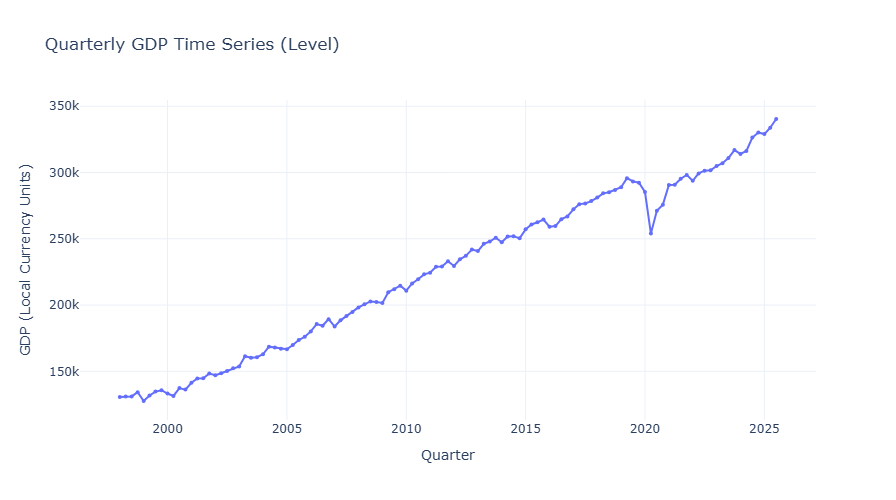

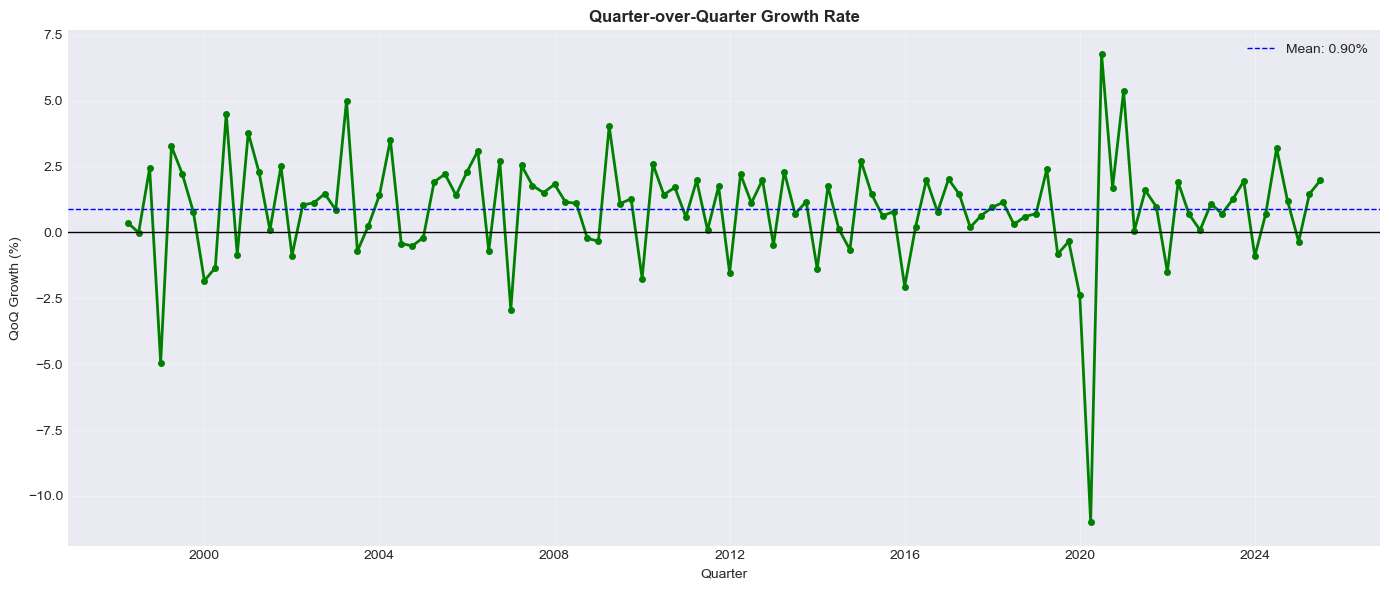


DATA READINESS CHECK
✓ PASS: Sufficient observations
✓ PASS: Missing data manageable
✓ PASS: No constant values
✓ PASS: Positive values
✓ PASS: No gaps in quarters

✓ DATA READY FOR ARIMA ANALYSIS

✅ Data loading function defined (UNIVERSAL + YOUR SOPHISTICATION)


In [189]:
# CELL 21: LOAD DATA - UNIVERSAL VERSION WITH YOUR SOPHISTICATED LOGIC
# ============================================================================
# CELL 21: LOAD DATA - UNIVERSAL VERSION WITH YOUR SOPHISTICATED LOGIC
# ============================================================================
"""
Key changes for universality:
1. Flexible file path (user provides)
2. Auto-detect GDP column (or user specifies)
3. Auto-detect date format
4. Works with any country data
5. Includes data validation and analysis
"""
"""
CELL 21: LOAD DATA - COMPLETE VERSION WITH ALL AGREED PRINTOUTS
"""

import openpyxl

def load_gdp_data_from_config(load_config: DataLoadConfig) -> pd.Series:
    """
    Load GDP data using configuration object
    
    Parameters:
    -----------
    load_config : DataLoadConfig
        Configuration object from Cell 2
    
    Returns:
    --------
    pd.Series : GDP series with DatetimeIndex
    """
    
    file_path = load_config.file_path
    sheet_name = load_config.sheet_name
    date_column = load_config.date_column
    gdp_column = load_config.gdp_column
    date_format = load_config.date_format
    interactive = load_config.interactive
    verbose = load_config.verbose
    
    # ========================================================================
    # 1. LOAD FILE
    # ========================================================================
    
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")
    
    if verbose:
        print(f"✓ File found: {file_path}")
    
    excel_file = pd.ExcelFile(file_path, engine="openpyxl")
    
    if verbose:
        print(f"📊 Available sheets: {excel_file.sheet_names}")
    
    # Determine sheet
    if sheet_name is None:
        common_names = ['q_data', 'quarterly', 'gdp', 'data', 'sheet1']
        for name in common_names:
            if name.lower() in [s.lower() for s in excel_file.sheet_names]:
                sheet_name = next(s for s in excel_file.sheet_names if s.lower() == name.lower())
                break
        if sheet_name is None:
            sheet_name = excel_file.sheet_names[0]
        
        if interactive and len(excel_file.sheet_names) > 1:
            print(f"\n📋 Multiple sheets found. Auto-selected: '{sheet_name}'")
            confirm = input(f"   Use this sheet? (y/n): ").strip().lower()
            if confirm != 'y':
                print(f"\n   Available sheets:")
                for i, s in enumerate(excel_file.sheet_names, 1):
                    print(f"     {i}. {s}")
                choice = input(f"   Enter number (1-{len(excel_file.sheet_names)}): ").strip()
                try:
                    sheet_name = excel_file.sheet_names[int(choice) - 1]
                except:
                    print(f"   Invalid choice, using: {sheet_name}")
    
    raw_data = pd.read_excel(excel_file, sheet_name=sheet_name)
    
    if verbose:
        print(f"\n✓ Data loaded")
        print(f"   Shape: {raw_data.shape}")
        print(f"   First few rows:")
        print(raw_data.head().to_string(index=True))
    
    # ========================================================================
    # 2. IDENTIFY DATE COLUMN
    # ========================================================================
    
    if date_column not in raw_data.columns:
        date_candidates = ['date', 'period', 'quarter', 'time', 'year']
        for candidate in date_candidates:
            matches = [col for col in raw_data.columns if candidate.lower() in col.lower()]
            if matches:
                date_column = matches[0]
                break
        if date_column not in raw_data.columns:
            raise ValueError(f"Could not find date column. Available: {list(raw_data.columns)}")
    
    if verbose:
        print(f"\n✓ Date column identified: '{date_column}'")
    
    # ========================================================================
    # 3. IDENTIFY GDP COLUMN (WITH USER PROMPT IF INTERACTIVE)
    # ========================================================================
    
    if gdp_column is None:
        if verbose:
            print(f"\n🔍 Auto-detecting GDP column...")
        
        gdp_candidates = [col for col in raw_data.columns 
                         if 'gdp' in col.lower() and col != date_column]
        
        if len(gdp_candidates) == 1:
            gdp_column = gdp_candidates[0]
        elif len(gdp_candidates) > 1:
            for col in gdp_candidates:
                if pd.api.types.is_numeric_dtype(raw_data[col]):
                    gdp_column = col
                    break
            if gdp_column is None:
                gdp_column = gdp_candidates[0]
        else:
            numeric_cols = raw_data.select_dtypes(include=[np.number]).columns
            numeric_cols = [col for col in numeric_cols if col != date_column]
            if len(numeric_cols) > 0:
                gdp_column = numeric_cols[0]
            else:
                raise ValueError("Could not auto-detect GDP column")
        
        if verbose:
            print(f"   → Auto-selected GDP column: '{gdp_column}'")
        
        if interactive:
            sample_vals = raw_data[gdp_column].dropna().head(5)
            print(f"\n   Sample values from '{gdp_column}':")
            for idx, val in sample_vals.items():
                date_val = raw_data.loc[idx, date_column]
                print(f"     {date_val}: {val:,.2f}")
            
            confirm = input(f"\n   Use '{gdp_column}' as GDP column? (y/n): ").strip().lower()
            
            if confirm != 'y':
                print(f"\n   Available numeric columns:")
                numeric_cols = raw_data.select_dtypes(include=[np.number]).columns
                numeric_cols = [col for col in numeric_cols if col != date_column]
                
                for i, col in enumerate(numeric_cols, 1):
                    sample = raw_data[col].dropna().iloc[0] if len(raw_data[col].dropna()) > 0 else 'N/A'
                    print(f"     {i}. {col} (sample: {sample})")
                
                choice = input(f"   Enter number (1-{len(numeric_cols)}): ").strip()
                try:
                    gdp_column = numeric_cols[int(choice) - 1]
                    print(f"   → Selected: '{gdp_column}'")
                except:
                    print(f"   Invalid choice, using: '{gdp_column}'")
    else:
        if verbose:
            print(f"\n✓ GDP column specified: '{gdp_column}'")
    
    if gdp_column not in raw_data.columns:
        raise ValueError(f"GDP column '{gdp_column}' not found in data")
    
    # ========================================================================
    # 4. PARSE DATES (YOUR SOPHISTICATED LOGIC)
    # ========================================================================
    
    if verbose:
        print(f"\nConverting dates...")
        print(f"   Sample dates before: {raw_data[date_column].head(3).tolist()}")
    
    if date_format is None:
        formats_to_try = ['%d/%m/%Y', '%Y-%m-%d', '%m/%d/%Y', None]
        dates_converted = None
        for fmt in formats_to_try:
            try:
                if fmt is None:
                    dates_converted = pd.to_datetime(raw_data[date_column])
                else:
                    dates_converted = pd.to_datetime(raw_data[date_column], format=fmt)
                date_format = fmt if fmt else 'auto'
                break
            except:
                continue
        if dates_converted is None:
            raise ValueError(f"Could not parse dates in column '{date_column}'")
    else:
        dates_converted = pd.to_datetime(raw_data[date_column], format=date_format)
    
    if verbose:
        print(f"   Date format: {date_format}")
        print(f"   Sample dates after: {dates_converted.head(3).tolist()}")
    
    # ========================================================================
    # 5. CREATE SERIES WITH DATETIMEINDEX
    # ========================================================================
    
    gdp_series = pd.Series(
        raw_data[gdp_column].values,
        index=dates_converted,
        name='GDP'
    )
    
    # Remove NaN values
    initial_length = len(gdp_series)
    gdp_series = gdp_series.dropna()
    final_length = len(gdp_series)
    
    if initial_length > final_length and verbose:
        print(f"\n⚠ Removed {initial_length - final_length} rows with missing values")
    
    # Sort by date
    gdp_series = gdp_series.sort_index()
    
    # ========================================================================
    # 6. INFER AND SET FREQUENCY (YOUR CRITICAL STEP)
    # ========================================================================
    
    inferred_freq = pd.infer_freq(gdp_series.index)
    
    if verbose:
        print(f"\n✓ Series prepared:")
        print(f"   Observations: {len(gdp_series)}")
        print(f"   Start: {gdp_series.index[0].strftime('%Y-%m-%d')} ({gdp_series.index[0].to_period('Q')})")
        print(f"   End: {gdp_series.index[-1].strftime('%Y-%m-%d')} ({gdp_series.index[-1].to_period('Q')})")
        print(f"   Inferred frequency: {inferred_freq}")
    
    if inferred_freq is not None:
        gdp_series.index.freq = inferred_freq
        if verbose:
            print(f"   ✓ Frequency set: {gdp_series.index.freq}")
    else:
        if verbose:
            print(f"   ⚠ Could not infer frequency - will cause issues with ARIMA exog")
    
    # ========================================================================
    # 7. VERIFICATION CHECKS (YOUR LOGIC)
    # ========================================================================
    
    if verbose:
        print("\n" + "="*80)
        print("INDEX TYPE CHECK")
        print("="*80)
    
    assert isinstance(gdp_series.index, pd.DatetimeIndex), "ERROR: Index is not DatetimeIndex!"
    
    if verbose:
        print("✓ Index is correct DatetimeIndex")
        print(f"  Type: {type(gdp_series.index).__name__}")
        print(f"  First: {gdp_series.index[0]}")
        print(f"  Last: {gdp_series.index[-1]}")
    
    # ========================================================================
    # 8. BASIC STATISTICS (YOUR COMPREHENSIVE ANALYSIS)
    # ========================================================================
    
    if verbose:
        print("\n" + "="*80)
        print("GDP SERIES SUMMARY STATISTICS")
        print("="*80)
        
        print("\nDescriptive Statistics:")
        print("-"*80)
        print(gdp_series.describe())
        
        # Growth rates
        gdp_clean = gdp_series.dropna()
        if len(gdp_clean) > 1:
            qoq_growth = gdp_clean.pct_change().dropna() * 100
            yoy_growth = gdp_clean.pct_change(4).dropna() * 100
            
            print("\n" + "-"*80)
            print("Growth Rate Statistics (%):")
            print("-"*80)
            print(f"QoQ growth - Mean:   {qoq_growth.mean():6.2f}%")
            print(f"QoQ growth - Std:    {qoq_growth.std():6.2f}%")
            print(f"QoQ growth - Min:    {qoq_growth.min():6.2f}% ({qoq_growth.idxmin().to_period('Q')})")
            print(f"QoQ growth - Max:    {qoq_growth.max():6.2f}% ({qoq_growth.idxmax().to_period('Q')})")
            
            if len(yoy_growth) > 0:
                print(f"\nYoY growth - Mean:   {yoy_growth.mean():6.2f}%")
                print(f"YoY growth - Std:    {yoy_growth.std():6.2f}%")
                print(f"YoY growth - Min:    {yoy_growth.min():6.2f}% ({yoy_growth.idxmin().to_period('Q')})")
                print(f"YoY growth - Max:    {yoy_growth.max():6.2f}% ({yoy_growth.idxmax().to_period('Q')})")
            
            # ================================================================
            # TOP 10 HIGHEST AND LOWEST GROWTH RATES (YOUR REQUEST)
            # ================================================================
            
            print("\n" + "-"*80)
            print("Top 10 Highest QoQ Growth Rates (potential outliers):")
            print("-"*80)
            top10_qoq = qoq_growth.nlargest(10)
            for i, (period, value) in enumerate(top10_qoq.items(), 1):
                print(f"  {i:2d}. {period.to_period('Q')}: {value:+6.2f}%")
            
            print("\n" + "-"*80)
            print("Top 10 Lowest QoQ Growth Rates (potential outliers):")
            print("-"*80)
            bottom10_qoq = qoq_growth.nsmallest(10)
            for i, (period, value) in enumerate(bottom10_qoq.items(), 1):
                print(f"  {i:2d}. {period.to_period('Q')}: {value:+6.2f}%")
            
            if len(yoy_growth) >= 10:
                print("\n" + "-"*80)
                print("Top 10 Highest YoY Growth Rates (potential outliers):")
                print("-"*80)
                top10_yoy = yoy_growth.nlargest(10)
                for i, (period, value) in enumerate(top10_yoy.items(), 1):
                    print(f"  {i:2d}. {period.to_period('Q')}: {value:+6.2f}%")
                
                print("\n" + "-"*80)
                print("Top 10 Lowest YoY Growth Rates (potential outliers):")
                print("-"*80)
                bottom10_yoy = yoy_growth.nsmallest(10)
                for i, (period, value) in enumerate(bottom10_yoy.items(), 1):
                    print(f"  {i:2d}. {period.to_period('Q')}: {value:+6.2f}%")
    
    # ========================================================================
    # 9. VISUALIZATION (YOUR PLOTLY CODE - INTERACTIVE ONLY)
    # ========================================================================
    
    if verbose:
        print("\n📊 Creating visualizations...")
        
        # Plotly interactive plot (KEEP - YOUR REQUEST)
        fig = go.Figure()
        fig.add_trace(go.Scatter(
            x=gdp_series.index,
            y=gdp_series.values,
            mode='lines+markers',
            name='GDP',
            line=dict(width=2),
            marker=dict(size=4)
        ))
        
        fig.update_layout(
            title='Quarterly GDP Time Series (Level)',
            xaxis_title='Quarter',
            yaxis_title='GDP (Local Currency Units)',
            hovermode='x unified',
            height=500,
            template='plotly_white'
        )
        
        fig.show()
        
        # Growth rate plot (KEEP - YOUR REQUEST with mean line)
        if len(gdp_clean) > 1:
            fig_growth, ax = plt.subplots(1, 1, figsize=(14, 6))
            
            # Growth rate
            ax.plot(qoq_growth.index, qoq_growth.values, 'o-', 
                    linewidth=2, markersize=4, color='green')
            ax.axhline(y=0, color='black', linewidth=1, linestyle='-')
            ax.axhline(y=qoq_growth.mean(), color='blue', linewidth=1, linestyle='--', 
                       label=f'Mean: {qoq_growth.mean():.2f}%')
            ax.set_title('Quarter-over-Quarter Growth Rate', fontweight='bold', fontsize=12)
            ax.set_ylabel('QoQ Growth (%)')
            ax.set_xlabel('Quarter')
            ax.grid(True, alpha=0.3)
            ax.legend()
            
            plt.tight_layout()
            plt.show()
    
    # ========================================================================
    # 10. DATA READINESS CHECK (YOUR LOGIC)
    # ========================================================================
    
    if verbose:
        print("\n" + "="*80)
        print("DATA READINESS CHECK")
        print("="*80)
    
    def check_quarterly_gaps(series):
        """Check if there are gaps larger than 1 quarter"""
        if len(series) < 2:
            return True
        
        # Convert to periods and check gaps
        periods = series.index.to_period('Q')
        for i in range(1, len(periods)):
            gap = (periods[i].year - periods[i-1].year) * 4 + (periods[i].quarter - periods[i-1].quarter)
            if gap > 1:
                return False
        return True
    
    readiness_checks = {
        'Sufficient observations': len(gdp_series) >= 20,
        'Missing data manageable': gdp_series.isna().sum() / len(gdp_series) < 0.20,
        'No constant values': gdp_series.nunique() > 1,
        'Positive values': (gdp_series > 0).all(),
        'No gaps in quarters': check_quarterly_gaps(gdp_series)
    }
    
    all_passed = True
    for check, result in readiness_checks.items():
        status = "✓ PASS" if result else "✗ FAIL"
        if verbose:
            print(f"{status}: {check}")
        if not result:
            all_passed = False
    
    if all_passed:
        if verbose:
            print("\n" + "="*80)
            print("✓ DATA READY FOR ARIMA ANALYSIS")
            print("="*80)
    else:
        if verbose:
            print("\n" + "="*80)
            print("⚠ DATA QUALITY ISSUES DETECTED")
            print("="*80)
    
    return gdp_series


# ============================================================================
# USAGE
# ============================================================================

# Get Morocco configuration
load_config, data_config, model_config = get_morocco_config()

# Load data using config
gdp_series = load_gdp_data_from_config(load_config)

print("\n✅ Data loading function defined (UNIVERSAL + YOUR SOPHISTICATION)")





TRAIN/TEST SPLIT CONFIGURATION

Data Summary:
  Total observations: 111
  Period: 1998Q1 to 2025Q3
  Frequency: Quarterly

--------------------------------------------------------------------------------
HOLD-OUT CONFIGURATION
--------------------------------------------------------------------------------

Recommended hold-out lengths:
  • 8 quarters (2 years) - Conservative, more training data
  • 12 quarters (3 years) - Standard for GDP nowcasting
  • 16 quarters (4 years) - Larger test set, rigorous validation
  • 20 quarters (5 years) - Maximum, may include COVID

⚠ IMPORTANT: Avoid hold-outs that include entire COVID period
  COVID impact: 2020-Q1 through 2021-Q4 (approx.)
  If hold-out includes COVID, forecast errors will be very high



Enter hold-out length in quarters (or 0 for no hold-out):  8



TRAIN/TEST SPLIT COMPLETE

📊 TRAINING SET:
   Observations: 103 (92.8% of data)
   Period: 1998Q1 to 2023Q3
   → Used for: Stationarity tests, outlier detection, model fitting

📊 TEST SET (HOLD-OUT):
   Observations: 8 (7.2% of data)
   Period: 2023Q4 to 2025Q3
   → Used for: Out-of-sample forecast evaluation

TRAIN/TEST VISUALIZATION


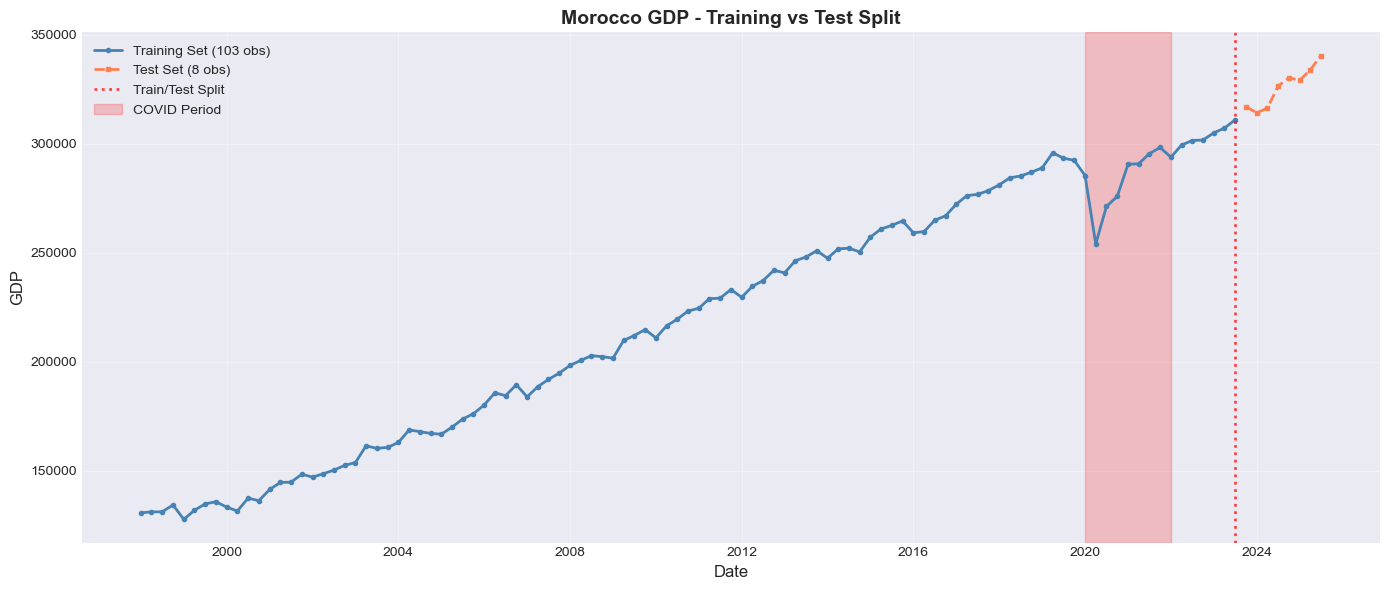


✅ Train/test split configuration complete

Variables created:
  • gdp_series_train: Training data (103 obs)
  • gdp_series_test: Test data (8 obs)
  • HAS_HOLDOUT: True
  • split_config: Configuration dictionary

💡 Next steps:
   1. Cell 22: Run stationarity tests on TRAINING data
   2. Cell 25: Run outlier detection on TRAINING data
   3. Cell 26: Fit models on TRAINING data
   4. Cell 27: Evaluate forecasts on TEST data
   5. Cell 28: Refit best model on FULL data


In [190]:
# CELL 21B: TRAIN/TEST SPLIT (USER-CONFIGURABLE)
# ============================================================================
# CELL 21B: TRAIN/TEST SPLIT (USER-CONFIGURABLE)
# ============================================================================

"""
Split data into training and test sets BEFORE any analysis
This prevents data leakage in:
- Stationarity tests
- Outlier detection
- Transformation parameter estimation
- Any data-driven decisions
"""

# ============================================================================
# USER CONFIGURATION
# ============================================================================

print("\n" + "="*80)
print("TRAIN/TEST SPLIT CONFIGURATION")
print("="*80)

# Display series info
total_obs = len(gdp_series)
series_start = gdp_series.index[0].to_period('Q')
series_end = gdp_series.index[-1].to_period('Q')

print(f"\nData Summary:")
print(f"  Total observations: {total_obs}")
print(f"  Period: {series_start} to {series_end}")
print(f"  Frequency: Quarterly")

# ============================================================================
# HOLD-OUT CONFIGURATION
# ============================================================================

print(f"\n" + "-"*80)
print("HOLD-OUT CONFIGURATION")
print("-"*80)

print(f"\nRecommended hold-out lengths:")
print(f"  • 8 quarters (2 years) - Conservative, more training data")
print(f"  • 12 quarters (3 years) - Standard for GDP nowcasting")
print(f"  • 16 quarters (4 years) - Larger test set, rigorous validation")
print(f"  • 20 quarters (5 years) - Maximum, may include COVID")

print(f"\n⚠ IMPORTANT: Avoid hold-outs that include entire COVID period")
print(f"  COVID impact: 2020-Q1 through 2021-Q4 (approx.)")
print(f"  If hold-out includes COVID, forecast errors will be very high")

# Minimum training size
MIN_TRAIN_SIZE = 40

# Get user input
while True:
    try:
        user_input = input(f"\nEnter hold-out length in quarters (or 0 for no hold-out): ").strip()
        HOLDOUT_QUARTERS = int(user_input)
        
        if HOLDOUT_QUARTERS == 0:
            print(f"\n✓ No hold-out selected - using full series for modeling")
            break
        elif HOLDOUT_QUARTERS < 4:
            print(f"⚠ Hold-out too short (minimum 4 quarters). Try again.")
        elif HOLDOUT_QUARTERS >= total_obs - MIN_TRAIN_SIZE:
            print(f"⚠ Hold-out too long (leaves <{MIN_TRAIN_SIZE} for training). Try again.")
        else:
            break
    except ValueError:
        print(f"⚠ Invalid input. Please enter a number.")

# ============================================================================
# EXECUTE SPLIT
# ============================================================================

if HOLDOUT_QUARTERS == 0:
    # No hold-out - use full series
    gdp_series_train = gdp_series.copy()
    gdp_series_test = None
    HAS_HOLDOUT = False
    
    print(f"\n✓ Using full series:")
    print(f"  Training: {total_obs} observations")
    print(f"  Period: {series_start} to {series_end}")
    
else:
    # Split data
    split_idx = len(gdp_series) - HOLDOUT_QUARTERS
    
    gdp_series_train = gdp_series.iloc[:split_idx].copy()
    gdp_series_test = gdp_series.iloc[split_idx:].copy()
    
    HAS_HOLDOUT = True
    
    # Calculate percentages
    train_pct = (len(gdp_series_train) / total_obs) * 100
    test_pct = (len(gdp_series_test) / total_obs) * 100
    
    # Get date ranges
    train_start = gdp_series_train.index[0].to_period('Q')
    train_end = gdp_series_train.index[-1].to_period('Q')
    test_start = gdp_series_test.index[0].to_period('Q')
    test_end = gdp_series_test.index[-1].to_period('Q')
    
    print(f"\n" + "="*80)
    print("TRAIN/TEST SPLIT COMPLETE")
    print("="*80)
    
    print(f"\n📊 TRAINING SET:")
    print(f"   Observations: {len(gdp_series_train)} ({train_pct:.1f}% of data)")
    print(f"   Period: {train_start} to {train_end}")
    print(f"   → Used for: Stationarity tests, outlier detection, model fitting")
    
    print(f"\n📊 TEST SET (HOLD-OUT):")
    print(f"   Observations: {len(gdp_series_test)} ({test_pct:.1f}% of data)")
    print(f"   Period: {test_start} to {test_end}")
    print(f"   → Used for: Out-of-sample forecast evaluation")
    
    # Check for COVID in test set
    test_years = gdp_series_test.index.year
    if any((test_years >= 2020) & (test_years <= 2021)):
        print(f"\n⚠ WARNING: Test set includes COVID period (2020-2021)")
        print(f"   Forecast errors will be higher due to structural break")
        print(f"   Consider using a shorter hold-out to exclude COVID")

# ============================================================================
# VISUALIZATION
# ============================================================================

if HAS_HOLDOUT:
    print(f"\n" + "="*80)
    print("TRAIN/TEST VISUALIZATION")
    print("="*80)
    
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Plot training data
    ax.plot(gdp_series_train.index, gdp_series_train.values, 
            color='steelblue', linewidth=2, label=f'Training Set ({len(gdp_series_train)} obs)', 
            marker='o', markersize=3)
    
    # Plot test data
    ax.plot(gdp_series_test.index, gdp_series_test.values, 
            color='coral', linewidth=2, label=f'Test Set ({len(gdp_series_test)} obs)', 
            linestyle='--', marker='s', markersize=3)
    
    # Add vertical line at split
    ax.axvline(x=gdp_series_train.index[-1], color='red', 
               linestyle=':', linewidth=2, alpha=0.7, label='Train/Test Split')
    
    # Highlight COVID period if in range
    covid_start = pd.Timestamp('2020-01-01')
    covid_end = pd.Timestamp('2021-12-31')
    if covid_start <= gdp_series.index[-1] and covid_end >= gdp_series.index[0]:
        ax.axvspan(covid_start, covid_end, alpha=0.2, color='red', label='COVID Period')
    
    ax.set_title(f'{data_config.country} GDP - Training vs Test Split', 
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('GDP', fontsize=12)
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# ============================================================================
# STORE SPLIT CONFIGURATION
# ============================================================================

split_config = {
    'has_holdout': HAS_HOLDOUT,
    'holdout_quarters': HOLDOUT_QUARTERS if HAS_HOLDOUT else 0,
    'train_size': len(gdp_series_train),
    'test_size': len(gdp_series_test) if HAS_HOLDOUT else 0,
    'train_period': (gdp_series_train.index[0], gdp_series_train.index[-1]),
    'test_period': (gdp_series_test.index[0], gdp_series_test.index[-1]) if HAS_HOLDOUT else None,
    'train_pct': (len(gdp_series_train) / total_obs) * 100,
    'test_pct': (len(gdp_series_test) / total_obs) * 100 if HAS_HOLDOUT else 0
}

print(f"\n✅ Train/test split configuration complete")
print(f"\nVariables created:")
print(f"  • gdp_series_train: Training data ({len(gdp_series_train)} obs)")
print(f"  • gdp_series_test: Test data ({len(gdp_series_test) if HAS_HOLDOUT else 0} obs)")
print(f"  • HAS_HOLDOUT: {HAS_HOLDOUT}")
print(f"  • split_config: Configuration dictionary")

print(f"\n💡 Next steps:")
print(f"   1. Cell 22: Run stationarity tests on TRAINING data")
print(f"   2. Cell 25: Run outlier detection on TRAINING data")
print(f"   3. Cell 26: Fit models on TRAINING data")
if HAS_HOLDOUT:
    print(f"   4. Cell 27: Evaluate forecasts on TEST data")
    print(f"   5. Cell 28: Refit best model on FULL data")
    

In [191]:
# CELL 22: STATIONARITY TESTS (TRAINING DATA ONLY)
# ========================================================================
# CELL 22: STATIONARITY TESTS (TRAINING DATA ONLY)
# ========================================================================

"""
YOUR comprehensive ADF and KPSS tests with combined interpretation
"""

def run_stationarity_tests_enhanced(series, name):
    """
    Run ADF and KPSS stationarity tests with detailed interpretation.
    
    Parameters:
    -----------
    series : pd.Series
        Time series to test
    name : str
        Description of the series being tested
    
    Returns:
    --------
    tuple : (adf_result, kpss_result, stationarity_conclusion)
    """
    series_clean = series.dropna()
    
    print(f"\n{name}")
    print("-"*80)
    
    # ========================================================================
    # ADF TEST (Augmented Dickey-Fuller)
    # ========================================================================
    
    adf_result = adfuller(series_clean, autolag='AIC')
    
    print(f"ADF Test:")
    print(f"  Statistic: {adf_result[0]:.4f}")
    print(f"  p-value: {adf_result[1]:.4f}")
    print(f"  Critical values: 1%={adf_result[4]['1%']:.3f}, 5%={adf_result[4]['5%']:.3f}, 10%={adf_result[4]['10%']:.3f}")
    
    # ADF interpretation
    if adf_result[1] <= 0.01:
        adf_conclusion = "STRONGLY STATIONARY (p ≤ 0.01) ✓✓"
    elif adf_result[1] <= 0.05:
        adf_conclusion = "STATIONARY (p ≤ 0.05) ✓"
    else:
        adf_conclusion = "NON-STATIONARY (p > 0.05) ✗"
    
    print(f"  → {adf_conclusion}")
    
    # ========================================================================
    # KPSS TEST (Kwiatkowski-Phillips-Schmidt-Shin)
    # ========================================================================
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        kpss_result = kpss(series_clean, regression='c', nlags='auto')
    
    print(f"\nKPSS Test:")
    print(f"  Statistic: {kpss_result[0]:.4f}")
    print(f"  p-value: {kpss_result[1]:.4f}")
    print(f"  Critical values: 10%={kpss_result[3]['10%']:.3f}, 5%={kpss_result[3]['5%']:.3f}, 1%={kpss_result[3]['1%']:.3f}")
    
    # KPSS interpretation (note: KPSS null hypothesis is OPPOSITE of ADF)
    if kpss_result[1] >= 0.10:
        kpss_conclusion = "STATIONARY (p ≥ 0.10) ✓"
    elif kpss_result[1] >= 0.05:
        kpss_conclusion = "LIKELY STATIONARY (p ≥ 0.05) ✓"
    else:
        kpss_conclusion = "NON-STATIONARY (p < 0.05) ✗"
    
    print(f"  → {kpss_conclusion}")
    
    # ========================================================================
    # COMBINED INTERPRETATION
    # ========================================================================
    
    print(f"\nCombined interpretation:")
    
    if adf_result[1] < 0.05 and kpss_result[1] > 0.05:
        print("  ✓ Both tests agree: Series is STATIONARY")
        stationarity = "stationary"
    elif adf_result[1] >= 0.05 and kpss_result[1] <= 0.05:
        print("  ✗ Both tests agree: Series is NON-STATIONARY")
        stationarity = "non-stationary"
    else:
        print("  ⚠ Tests disagree - inconclusive (proceed with caution)")
        stationarity = "inconclusive"
    
    return adf_result, kpss_result, stationarity


def test_stationarity_workflow(gdp_series, verbose=True):
    """
    Complete stationarity testing workflow for GDP series
    
    Tests:
    1. GDP in levels
    2. Log GDP
    3. First difference of log GDP (growth rates)
    
    Parameters:
    -----------
    gdp_series : pd.Series
        GDP series with DatetimeIndex (TRAINING DATA ONLY!)
    verbose : bool
        Print detailed results
    
    Returns:
    --------
    dict : Results from all tests
    """
    
    if verbose:
        print("\n" + "="*80)
        print("STATIONARITY TESTING (TRAINING DATA ONLY)")
        print("="*80)
        print(f"\n⚠ IMPORTANT: Tests run on training data only ({len(gdp_series)} obs)")
        print("  This prevents data leakage from test period")
        print("\nTesting three transformations:")
        print("  1. GDP (Level) - Original series")
        print("  2. Log GDP - Natural logarithm")
        print("  3. Log-Diff GDP - First difference of log (growth rates)")
    
    results = {}
    
    # ========================================================================
    # TEST 1: GDP IN LEVELS
    # ========================================================================
    
    if verbose:
        print("\n" + "="*80)
        print("TEST 1: GDP IN LEVELS")
        print("="*80)
    
    gdp_clean = gdp_series.dropna()
    adf_level, kpss_level, stat_level = run_stationarity_tests_enhanced(
        gdp_clean, 
        "GDP (Level)"
    )
    
    results['level'] = {
        'adf': adf_level,
        'kpss': kpss_level,
        'conclusion': stat_level,
        'series': gdp_clean
    }
    
    # ========================================================================
    # TEST 2: LOG GDP
    # ========================================================================
    
    if verbose:
        print("\n" + "="*80)
        print("TEST 2: LOG GDP")
        print("="*80)
    
    log_gdp = np.log(gdp_clean)
    adf_log, kpss_log, stat_log = run_stationarity_tests_enhanced(
        log_gdp, 
        "Log GDP"
    )
    
    results['log'] = {
        'adf': adf_log,
        'kpss': kpss_log,
        'conclusion': stat_log,
        'series': log_gdp
    }
    
    # ========================================================================
    # TEST 3: LOG-DIFF GDP (GROWTH RATES)
    # ========================================================================
    
    if verbose:
        print("\n" + "="*80)
        print("TEST 3: LOG-DIFF GDP (GROWTH RATES)")
        print("="*80)
    
    log_diff_gdp = log_gdp.diff().dropna()
    adf_diff, kpss_diff, stat_diff = run_stationarity_tests_enhanced(
        log_diff_gdp, 
        "Log-Diff GDP (Growth Rates)"
    )
    
    results['log_diff'] = {
        'adf': adf_diff,
        'kpss': kpss_diff,
        'conclusion': stat_diff,
        'series': log_diff_gdp
    }
    
    # ========================================================================
    # SUMMARY TABLE
    # ========================================================================
    
    if verbose:
        print("\n" + "="*80)
        print("STATIONARITY TEST SUMMARY")
        print("="*80)
        
        summary_data = []
        for transform, res in results.items():
            summary_data.append({
                'Transformation': transform.upper(),
                'ADF p-value': f"{res['adf'][1]:.4f}",
                'ADF Result': '✓ Stationary' if res['adf'][1] < 0.05 else '✗ Non-stationary',
                'KPSS p-value': f"{res['kpss'][1]:.4f}",
                'KPSS Result': '✓ Stationary' if res['kpss'][1] > 0.05 else '✗ Non-stationary',
                'Conclusion': res['conclusion'].upper()
            })
        
        summary_df = pd.DataFrame(summary_data)
        print("\n" + summary_df.to_string(index=False))
    
    # ========================================================================
    # RECOMMENDATION
    # ========================================================================
    
    if verbose:
        print("\n" + "="*80)
        print("RECOMMENDATION FOR ARIMA MODELING")
        print("="*80)
        
        if results['log_diff']['conclusion'] == 'stationary':
            print("\n✓ LOG-DIFF GDP is stationary")
            print("  → Recommended: Use log-differenced series for ARIMA")
            print("  → ARIMA order d=1 (first differencing)")
            print("  → Series: log(GDP_t) - log(GDP_{t-1})")
        elif results['log']['conclusion'] == 'stationary':
            print("\n✓ LOG GDP is stationary")
            print("  → Recommended: Use log series for ARIMA")
            print("  → ARIMA order d=0 (no differencing)")
            print("  → Series: log(GDP_t)")
        elif results['level']['conclusion'] == 'stationary':
            print("\n✓ GDP LEVEL is stationary")
            print("  → Recommended: Use level series for ARIMA")
            print("  → ARIMA order d=0 (no differencing)")
            print("  → Series: GDP_t")
        else:
            print("\n⚠ No transformation yielded clear stationarity")
            print("  → Recommended: Use log-differenced series anyway (standard practice)")
            print("  → ARIMA order d=1")
            print("  → Consider seasonal differencing if quarterly patterns persist")
    
    # ========================================================================
    # STORE RECOMMENDATION FOR AUTOMATED USE
    # ========================================================================
    
    # Determine required differencing order based on test results
    if results['log_diff']['conclusion'] == 'stationary':
        if results['log']['conclusion'] == 'stationary':
            recommended_d = 0
            stationary_series_name = 'log'
            stationary_series = results['log']['series']
        else:
            recommended_d = 1
            stationary_series_name = 'log_diff'
            stationary_series = results['log_diff']['series']
    elif results['log']['conclusion'] == 'stationary':
        recommended_d = 0
        stationary_series_name = 'log'
        stationary_series = results['log']['series']
    else:
        recommended_d = 2
        log_gdp = results['log']['series']
        second_diff = log_gdp.diff().diff().dropna()
        stationary_series_name = 'log_2nd_diff'
        stationary_series = second_diff
    
    # Store recommendation in results
    results['recommendation'] = {
        'recommended_d': recommended_d,
        'stationary_series_name': stationary_series_name,
        'stationary_series': stationary_series,
        'reason': f"Log-diff GDP is {results['log_diff']['conclusion']}, Log GDP is {results['log']['conclusion']}"
    }
    
    if verbose:
        print(f"\n📌 STORED FOR AUTOMATED MODEL SELECTION:")
        print(f"   recommended_d = {recommended_d}")
        print(f"   stationary_series = {stationary_series_name}")
        print(f"   (This will be used automatically in outlier detection and Grid Search)")
    
    return results


# ============================================================================
# EXECUTION (TRAINING DATA ONLY!)
# ============================================================================

print("\n" + "="*80)
print("RUNNING STATIONARITY TESTS")
print("="*80)

# CRITICAL: Use training data only to prevent leakage!
stationarity_results = test_stationarity_workflow(
    gdp_series=gdp_series_train,  # ← CHANGED: Was gdp_series, now gdp_series_train
    verbose=True
)

print("\n✅ Stationarity tests complete")
print("   Results stored in: stationarity_results")
print(f"   Based on TRAINING data only ({len(gdp_series_train)} observations)")


RUNNING STATIONARITY TESTS

STATIONARITY TESTING (TRAINING DATA ONLY)

⚠ IMPORTANT: Tests run on training data only (103 obs)
  This prevents data leakage from test period

Testing three transformations:
  1. GDP (Level) - Original series
  2. Log GDP - Natural logarithm
  3. Log-Diff GDP - First difference of log (growth rates)

TEST 1: GDP IN LEVELS

GDP (Level)
--------------------------------------------------------------------------------
ADF Test:
  Statistic: -0.4214
  p-value: 0.9065
  Critical values: 1%=-3.499, 5%=-2.892, 10%=-2.583
  → NON-STATIONARY (p > 0.05) ✗

KPSS Test:
  Statistic: 1.5712
  p-value: 0.0100
  Critical values: 10%=0.347, 5%=0.463, 1%=0.739
  → NON-STATIONARY (p < 0.05) ✗

Combined interpretation:
  ✗ Both tests agree: Series is NON-STATIONARY

TEST 2: LOG GDP

Log GDP
--------------------------------------------------------------------------------
ADF Test:
  Statistic: -2.0282
  p-value: 0.2744
  Critical values: 1%=-3.499, 5%=-2.892, 10%=-2.583
  → NO

In [145]:
# CELL 23: BENCHMARK MODELS
# ============================================================================
# CELL 23: BENCHMARK MODELS
# ============================================================================

"""
Benchmark models for comparison with ARIMA approaches

These simple models provide a baseline for evaluating ARIMA performance:
1. Naive Forecast (Random Walk)
2. Seasonal Naive
3. Mean Model
4. Drift Model
"""

# ============================================================================
# BENCHMARK MODEL FUNCTIONS
# ============================================================================

def naive_forecast(series: pd.Series, h: int = 1) -> pd.Series:
    """
    Naive forecast: Next value = Last observed value
    Equivalent to ARIMA(0,1,0) without drift
    """
    last_value = series.iloc[-1]
    forecast_index = pd.date_range(
        start=series.index[-1] + series.index.freq,
        periods=h,
        freq=series.index.freq
    )
    return pd.Series([last_value] * h, index=forecast_index)


def seasonal_naive_forecast(series: pd.Series, h: int = 1, season_length: int = 4) -> pd.Series:
    """
    Seasonal naive forecast: Next value = Same period last year
    """
    forecasts = []
    forecast_index = pd.date_range(
        start=series.index[-1] + series.index.freq,
        periods=h,
        freq=series.index.freq
    )
    
    for i in range(h):
        lag = season_length
        if len(series) >= lag:
            forecasts.append(series.iloc[-lag])
        else:
            forecasts.append(series.iloc[-1])
    
    return pd.Series(forecasts, index=forecast_index)


def mean_forecast(series: pd.Series, h: int = 1) -> pd.Series:
    """
    Mean forecast: Next value = Historical mean
    """
    mean_value = series.mean()
    forecast_index = pd.date_range(
        start=series.index[-1] + series.index.freq,
        periods=h,
        freq=series.index.freq
    )
    return pd.Series([mean_value] * h, index=forecast_index)


def drift_forecast(series: pd.Series, h: int = 1) -> pd.Series:
    """
    Drift forecast: Linear trend from first to last observation
    Equivalent to ARIMA(0,1,0) with drift
    """
    n = len(series)
    drift = (series.iloc[-1] - series.iloc[0]) / (n - 1)
    
    last_value = series.iloc[-1]
    forecasts = [last_value + drift * (i + 1) for i in range(h)]
    
    forecast_index = pd.date_range(
        start=series.index[-1] + series.index.freq,
        periods=h,
        freq=series.index.freq
    )
    
    return pd.Series(forecasts, index=forecast_index)


# ============================================================================
# BENCHMARK EVALUATION FUNCTION
# ============================================================================

def evaluate_benchmarks(
    train_series: pd.Series,
    test_series: pd.Series,
    season_length: int = 4,
    verbose: bool = True
) -> Dict:
    """
    Evaluate all benchmark models on test set
    
    Parameters:
    -----------
    train_series : pd.Series
        Training data
    test_series : pd.Series
        Test data for evaluation
    season_length : int
        Seasonal period (4 for quarterly)
    verbose : bool
        Print results
    
    Returns:
    --------
    dict : Benchmark results
    """
    
    if verbose:
        print("\n" + "="*80)
        print("BENCHMARK MODEL EVALUATION")
        print("="*80)
        print(f"\nTraining: {len(train_series)} observations")
        print(f"Testing: {len(test_series)} observations")
    
    h = len(test_series)
    results = {}
    
    # ========================================================================
    # 1. NAIVE FORECAST
    # ========================================================================
    
    naive_fcast = naive_forecast(train_series, h=h)
    naive_errors = test_series.values - naive_fcast.values
    
    results['naive'] = {
        'name': 'Naive (Random Walk)',
        'forecast': naive_fcast,
        'rmse': np.sqrt(np.mean(naive_errors**2)),
        'mae': np.mean(np.abs(naive_errors)),
        'mape': np.mean(np.abs(naive_errors / test_series.values)) * 100
    }
    
    # ========================================================================
    # 2. SEASONAL NAIVE
    # ========================================================================
    
    snaive_fcast = seasonal_naive_forecast(train_series, h=h, season_length=season_length)
    snaive_errors = test_series.values - snaive_fcast.values
    
    results['seasonal_naive'] = {
        'name': 'Seasonal Naive',
        'forecast': snaive_fcast,
        'rmse': np.sqrt(np.mean(snaive_errors**2)),
        'mae': np.mean(np.abs(snaive_errors)),
        'mape': np.mean(np.abs(snaive_errors / test_series.values)) * 100
    }
    
    # ========================================================================
    # 3. MEAN MODEL
    # ========================================================================
    
    mean_fcast = mean_forecast(train_series, h=h)
    mean_errors = test_series.values - mean_fcast.values
    
    results['mean'] = {
        'name': 'Historical Mean',
        'forecast': mean_fcast,
        'rmse': np.sqrt(np.mean(mean_errors**2)),
        'mae': np.mean(np.abs(mean_errors)),
        'mape': np.mean(np.abs(mean_errors / test_series.values)) * 100
    }
    
    # ========================================================================
    # 4. DRIFT MODEL
    # ========================================================================
    
    drift_fcast = drift_forecast(train_series, h=h)
    drift_errors = test_series.values - drift_fcast.values
    
    results['drift'] = {
        'name': 'Drift (Linear Trend)',
        'forecast': drift_fcast,
        'rmse': np.sqrt(np.mean(drift_errors**2)),
        'mae': np.mean(np.abs(drift_errors)),
        'mape': np.mean(np.abs(drift_errors / test_series.values)) * 100
    }
    
    # ========================================================================
    # SUMMARY TABLE
    # ========================================================================
    
    if verbose:
        print("\n" + "-"*80)
        print("BENCHMARK RESULTS")
        print("-"*80)
        
        summary_data = []
        for key, res in results.items():
            summary_data.append({
                'Model': res['name'],
                'RMSE': f"{res['rmse']:.6f}",
                'MAE': f"{res['mae']:.6f}",
                'MAPE (%)': f"{res['mape']:.2f}"
            })
        
        summary_df = pd.DataFrame(summary_data)
        print("\n" + summary_df.to_string(index=False))
        
        # Find best by RMSE
        best_model = min(results.items(), key=lambda x: x[1]['rmse'])
        print(f"\n🏆 Best benchmark (by RMSE): {best_model[1]['name']}")
        print(f"   RMSE: {best_model[1]['rmse']:.6f}")
    
    return results


# ============================================================================
# VISUALIZATION
# ============================================================================

def plot_benchmark_forecasts(
    train_series: pd.Series,
    test_series: pd.Series,
    benchmark_results: Dict,
    figsize: Tuple = (14, 8)
):



SyntaxError: incomplete input (3787346853.py, line 226)

In [192]:
# CELL 24B: ARIMA MODEL FITTING HELPERS (trend admissibility and exogs)
# ============================================================================
# CELL 24B: ARIMA MODEL FITTING HELPERS
# ============================================================================

def determine_trend(order, seasonal_order=None, series_type='integrated'):
    """
    Universal trend specification based on series and model characteristics
    
    Rules:
    - Seasonal models: No additional trend (seasonal component captures patterns)
    - Non-seasonal integrated: Include drift/constant
    - Stationary: Conditional on differencing order
    
    Parameters:
    -----------
    order : tuple
        (p, d, q)
    seasonal_order : tuple, optional
        (P, D, Q, m)
    series_type : str
        'integrated' or 'stationary'
    
    Returns:
    --------
    str : 'c' (constant/drift) or 'n' (no trend)
    """
    p, d, q = order
    
    # Check if model has seasonal component
    has_seasonal = seasonal_order is not None and any(seasonal_order[:3])
    
    if has_seasonal:
        # Seasonal models don't need additional trend
        return 'n'
    
    # Non-seasonal models
    if series_type == 'integrated':
        # GDP, prices - always include drift/constant
        return 'c'
    elif series_type == 'stationary':
        # Interest rates - conditional
        return 'c' if d == 0 else 'n'
    else:
        return 'c'


def calculate_burn_in_from_model(model, backend: str = "statsmodels") -> int:
    if backend == "pmdarima":
        p, d, q = model.order
        P, D, Q, m = model.seasonal_order if hasattr(model, "seasonal_order") else (0,0,0,0)
    else:
        p, d, q = model.model.order
        P, D, Q, m = model.model.seasonal_order if hasattr(model.model, "seasonal_order") else (0,0,0,0)
    return max(d + D*m + max(p, q, P*m, Q*m), 0)


def get_exog_params(model, exog_cols, backend='statsmodels'):
    """
    Robustly extract exog parameters from any model backend
    
    Parameters:
    -----------
    model : fitted model
    exog_cols : list
        List of exog column names to search for
    backend : str
        'statsmodels' or 'pmdarima'
    
    Returns:
    --------
    list : Parameter names that match exog columns
    """
    try:
        if backend == 'statsmodels' or (hasattr(model, 'params') and not callable(model.params)):
            # Statsmodels model
            param_names = list(model.params.index)
        elif hasattr(model, 'arima_res_'):
            # pmdarima model
            param_names = list(model.arima_res_.params.index)
        else:
            return []
        
        # Find parameters matching exog column names
        exog_params = [name for name in param_names 
                      if any(col in name for col in exog_cols)]
        
        return exog_params
        
    except:
        return []


def check_model_admissibility(model, verbose=False, order=None):
    """
    Check if fitted model is admissible (audit-grade quality gate)
    
    Filters out:
    - Non-converged models (with leniency for simple models)
    - Models with NaN/inf parameters
    - Degenerate fits (absurd standard errors)
    - Near-noninvertible/nonstationary models
    
    Simple models (p+q ≤ 1) get more lenient treatment:
    - Allowed to not converge if parameters are finite
    - Skip absurd SE check if not converged
    
    Parameters:
    -----------
    model : fitted statsmodels model
    verbose : bool
        Print detailed failure reasons
    order : tuple, optional
        (p, d, q) for special handling of simple models
    
    Returns:
    --------
    bool : True if model is admissible
    """
    try:
        # Identify simple models (more lenient criteria)
        is_simple_model = False
        if order is not None:
            p, d, q = order
            if p + q <= 1:  # ARIMA(0,d,0), ARIMA(1,d,0), ARIMA(0,d,1)
                is_simple_model = True
        
        # Check convergence
        converged = True
        if hasattr(model, 'mle_retvals'):
            converged = model.mle_retvals.get('converged', False)
            
            if not converged:
                if is_simple_model:
                    # Simple models: allow non-convergence if params are finite
                    if np.any(~np.isfinite(model.params)):
                        if verbose:
                            print(f"    ✗ Model {order} has invalid parameters")
                        return False
                    if verbose:
                        print(f"    ⚠ Model {order} did not converge formally, but parameters are reasonable")
                        print(f"    → Allowing simple model to pass")
                else:
                    # Complex models: strict convergence required
                    if verbose:
                        print(f"    ✗ Model {order if order else ''} did not converge")
                    return False
        
        # Check for NaN/inf parameters
        if np.any(~np.isfinite(model.params)):
            if verbose:
                print(f"    ✗ Model {order if order else ''} has NaN/inf parameters")
            return False
        
        # ================================================================
        # NEW: Check for degenerate coefficients (meaningless AR/MA terms)
        # ================================================================
        
        if order is not None:
            p, d, q = order
            param_names = list(model.params.index)
            
            # Check AR coefficients are economically meaningful
            for i in range(1, p + 1):
                ar_name = f'ar.L{i}'
                if ar_name in param_names:
                    ar_coef = model.params[ar_name]
                    if abs(ar_coef) < 0.01:  # Below this = no practical impact
                        if verbose:
                            print(f"    ✗ Model {order} has degenerate AR coefficient: {ar_name} = {ar_coef:.6f}")
                        return False
            
            # Check MA coefficients are economically meaningful
            for i in range(1, q + 1):
                ma_name = f'ma.L{i}'
                if ma_name in param_names:
                    ma_coef = model.params[ma_name]
                    if abs(ma_coef) < 0.01:  # Below this = no practical impact
                        if verbose:
                            print(f"    ✗ Model {order} has degenerate MA coefficient: {ma_name} = {ma_coef:.6f}")
                        return False
        
        # ================================================================
        # END NEW CHECK
        # ================================================================
        
        # Check for absurd standard errors
        # Skip for simple models that didn't converge (SEs unreliable)
        if hasattr(model, 'bse') and (converged or not is_simple_model):
            for param_name, param_val, param_se in zip(model.params.index, model.params, model.bse):
                if param_se > 100 * abs(param_val) and abs(param_val) > 1e-10:
                    if verbose:
                        print(f"    ✗ Model {order if order else ''} absurd SE for {param_name}: SE={param_se:.2f}, coef={param_val:.6f}")
                    return False
        
        # Check for near-unit roots (MA/AR near boundary)
        if hasattr(model, 'maroots') and model.maroots is not None:
            if np.any(np.abs(model.maroots) < 1.01):
                if verbose:
                    print(f"    ✗ Model {order if order else ''} near-noninvertible MA roots")
                return False
        
        if hasattr(model, 'arroots') and model.arroots is not None:
            if np.any(np.abs(model.arroots) < 1.01):
                if verbose:
                    print(f"    ✗ Model {order if order else ''} near-nonstationary AR roots")
                return False
        
        if verbose and order:
            print(f"    ✓ Model {order} passed all admissibility checks")
            if hasattr(model, 'arroots') and model.arroots is not None and len(model.arroots) > 0:
                print(f"      AR roots: {model.arroots}")
            if hasattr(model, 'maroots') and model.maroots is not None and len(model.maroots) > 0:
                print(f"      MA roots: {model.maroots}")
        
        return True
        
    except Exception as e:
        if verbose:
            print(f"    ✗ Model {order if order else ''} admissibility check failed: {e}")
        return False


def fit_arima_model(
    series: pd.Series,
    exog: Optional[pd.DataFrame],
    order: Tuple[int, int, int],
    seasonal_order: Tuple[int, int, int, int],
    series_type: str = 'integrated',
    verbose: bool = False
) -> Tuple[Any, str, bool]:
    """
    Fit ARIMA model with universal trend specification
    
    Parameters:
    -----------
    series : pd.Series
        Time series
    exog : pd.DataFrame, optional
        Exogenous variables
    order : tuple
        (p, d, q)
    seasonal_order : tuple
        (P, D, Q, m)
    series_type : str
        'integrated' or 'stationary' - determines trend specification
    verbose : bool
        Print errors
    
    Returns:
    --------
    tuple : (model, backend, success)
    """
    try:
        # Universal trend determination
        trend_spec = determine_trend(order, seasonal_order=seasonal_order, series_type=series_type)
        
        model = SARIMAX(
            series,
            order=order,
            seasonal_order=seasonal_order,
            exog=exog,
            trend=trend_spec,  # ← Universal, data-adaptive
            initialization='approximate_diffuse',
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False, maxiter=1000, method='lbfgs', optim_hessian='opg')
        
        # Check admissibility
        if not check_model_admissibility(model, verbose=verbose, order=order):
            return None, None, False
        
        return model, 'statsmodels', True
    
    except Exception as e:
        if verbose:
            print(f"   ✗ Model fitting failed: {e}")
        return None, None, False



In [194]:
# CELL 24C: APPROACH 2: RUNNING AUTO-ARIMA
# ============================================================================
# APPROACH 2: AUTO-ARIMA (WITH UNIVERSAL FIXES)
# ============================================================================

def run_auto_arima_approach(
    series: pd.Series,
    exog: Optional[pd.DataFrame] = None,
    seasonal: bool = True,
    m: int = 4,
    max_p: int = 3,
    max_q: int = 3,
    max_P: int = 2,
    max_Q: int = 2,
    series_type: str = 'integrated',
    verbose: bool = True
) -> Dict:
    """
    Auto-ARIMA approach using pmdarima
    
    With universal exog handling and trend specification
    
    Parameters:
    -----------
    series : pd.Series
        Time series (log GDP - undifferenced)
    exog : pd.DataFrame, optional
        Exogenous variables
    seasonal : bool
        Test seasonal models
    m : int
        Seasonal period (4 for quarterly)
    max_p, max_q, max_P, max_Q : int
        Maximum orders
    series_type : str
        'integrated' or 'stationary' - for universal trend specification
    verbose : bool
        Print results
    
    Returns:
    --------
    dict : Results from auto_arima
    """
    
    if verbose:
        print("\n" + "="*80)
        print("APPROACH 2: AUTO-ARIMA")
        print("="*80)
        print(f"\nSearching for best model...")
        print(f"  Seasonal: {seasonal}")
        if seasonal:
            print(f"  Seasonal period (m): {m}")
        print(f"  Max orders: p={max_p}, q={max_q}, P={max_P}, Q={max_Q}")
    
    try:
        # 1) prepare y and exog_used OUTSIDE the auto_arima call
        y = series.dropna()
    
        exog_used = None
        if exog is not None:
            exog_used = exog.reindex(y.index)
    
            # only if exog are dummies (0/1 shocks). Otherwise choose another fill strategy.
            exog_used = exog_used.fillna(0.0)
    
        # 2) call auto_arima using y and exog_used
        auto_model = auto_arima(
            y,
            X=exog_used,  # pmdarima uses X=
            start_p=0, max_p=max_p,
            start_q=0, max_q=max_q,
            start_P=0, max_P=max_P if seasonal else 0,
            start_Q=0, max_Q=max_Q if seasonal else 0,
            max_d=2,
            max_D=1 if seasonal else 0,
            seasonal=seasonal,
            m=m if seasonal else 1,
            stepwise=True,
            n_fits=50,
            suppress_warnings=True,
            error_action='ignore',
            trace=False,
            random_state=42,
            information_criterion='aic',
            with_intercept=True
        )
        
        order = auto_model.order
        seasonal_order = auto_model.seasonal_order if seasonal else (0,0,0,0)

        # Checking trend usage
        print("\n🔍 AUTO-ARIMA MODEL INSPECTION:")
        try:
            if hasattr(auto_model, 'arima_res_'):
                # pmdarima model
                arima_res = auto_model.arima_res_
                print(f"Model specification from pmdarima:")
                print(f"  trend: {arima_res.trend if hasattr(arima_res, 'trend') else 'unknown'}")
                print(f"  Order: {auto_model.order}")
                print(f"  Seasonal: {auto_model.seasonal_order}")
                
                # Check what parameters are in the model
                param_names = list(arima_res.params.index)
                print(f"  Parameter names: {param_names}")
                
                # Show parameter values
                print(f"\n  Parameter values:")
                for name, val in zip(param_names, arima_res.params.values):
                    print(f"    {name}: {val:.6f}")
            
            elif hasattr(auto_model, 'model'):
                # statsmodels model (after refit)
                print(f"Model specification from statsmodels:")
                print(f"  Order: {auto_model.model.order}")
                print(f"  Seasonal: {auto_model.model.seasonal_order}")
                
                param_names = list(auto_model.params.index)
                print(f"  Parameter names: {param_names}")
                
        except Exception as e:
            print(f"Could not inspect model: {e}")

        # After auto_model is created, before verification:
        if verbose:
            print(f"\n🔍 DEBUG: Auto-ARIMA internal settings:")
            try:
                if hasattr(auto_model, 'arima_res_'):
                    # pmdarima wraps statsmodels
                    underlying_model = auto_model.arima_res_
                    if hasattr(underlying_model, 'model'):
                        print(f"   Trend: {underlying_model.model.trend}")
                    
                    param_names = list(underlying_model.params.index)
                    print(f"   Parameters: {param_names}")
            except Exception as e:
                print(f"   Could not inspect: {e}")
        
    
        # ================================================================
        # VERIFY EXOG USAGE (UNIVERSAL)
        # ================================================================
        
        exog_included = False
        n_exog_found = 0
        
        if exog is not None:
            exog_cols = exog_used.columns.tolist()
            exog_params_found = get_exog_params(auto_model, exog_cols, backend='pmdarima')
            n_exog_found = len(exog_params_found)
            n_expected_exog = len(exog_cols)
            exog_included = (n_exog_found == n_expected_exog)
        
        # Report initial status
        if verbose:
            aic = auto_model.aic()
            bic = auto_model.bic()
            
            print(f"\n✓ Auto-ARIMA completed")
            print(f"   Selected: ARIMA{order}", end="")
            if seasonal_order and any(seasonal_order[:3]):
                print(f" x {seasonal_order}")
            else:
                print()
            print(f"   AIC: {aic:.2f}")
            print(f"   BIC: {bic:.2f}")
            print(f"   Parameters: {len(auto_model.params())} total")
            
            if exog is not None:
                print(f"   Exogenous: {n_exog_found} coefficients")
                if not exog_included:
                    print(f"   ⚠ WARNING: Exog variables may not have been used!")
        
        # ================================================================
        # REFIT WITH STATSMODELS IF EXOG WAS IGNORED (AUDIT FIX)
        # ================================================================
        
        if exog is not None and not exog_included:
            if verbose:
                print(f"\n🔧 FIXING: pmdarima did not include exog variables")
                print(f"   Original AIC: {aic:.2f}")
                print(f"   Refitting with statsmodels SARIMAX...")
            
            try:                              
                # Universal trend specification
                trend_spec = determine_trend(order, seasonal_order=seasonal_order, series_type=series_type)
                
                auto_model_refit = SARIMAX(
                    y,
                    order=order,
                    seasonal_order=seasonal_order,
                    exog=exog_used,
                    trend=trend_spec,  # ← Universal, data-adaptive
                    initialization='approximate_diffuse',
                    enforce_stationarity=False,
                    enforce_invertibility=False
                ).fit(
                    disp=False,
                    maxiter=1000,
                    method='lbfgs',
                    optim_hessian='opg'
                )
                
                # Verify exog is now included
                refit_params = list(auto_model_refit.params.index)
                refit_exog_found = [name for name in refit_params 
                                   if any(col in name for col in exog.columns)]
                
                if verbose:
                    print(f"   ✓ Refit successful!")
                    print(f"   Old parameters: {len(auto_model.params())}")
                    print(f"   New parameters: {len(auto_model_refit.params)}")
                    print(f"   Old AIC: {aic:.2f}")
                    print(f"   New AIC: {auto_model_refit.aic:.2f}")
                    print(f"   Exog coefficients: {len(refit_exog_found)}/{len(exog.columns)}")
                    
                    if len(refit_exog_found) == len(exog.columns):
                        print(f"   ✓ All exog variables now included!")
                
                # Replace with refitted model
                auto_model = auto_model_refit
                aic = auto_model.aic
                bic = auto_model.bic
                exog_included = True
                n_exog_found = len(refit_exog_found)
                
            except Exception as e:
                if verbose:
                    print(f"   ✗ Refit failed: {e}")
                    print(f"   Keeping original pmdarima model")
        
        # ================================================================
        # DEBUG OUTPUT (OPTIONAL)
        # ================================================================
        
        if verbose and exog is not None and n_exog_found > 0:
            print(f"\n" + "-"*80)
            print("DEBUG: Auto-ARIMA Model Details")
            print("-"*80)
            
            try:
                if hasattr(auto_model, 'arima_res_'):
                    param_names = list(auto_model.arima_res_.params.index)
                elif hasattr(auto_model, 'params') and not callable(auto_model.params):
                    param_names = list(auto_model.params.index)
                else:
                    param_names = []
                
                if param_names:
                    print(f"\nParameter names: {param_names}")
                    print(f"Number of parameters: {len(param_names)}")
                    
                    has_intercept = 'intercept' in param_names
                    has_drift = 'drift' in param_names
                    
                    print(f"\nTrend specification:")
                    print(f"  Has intercept: {has_intercept}")
                    print(f"  Has drift: {has_drift}")
                    
                    exog_cols = exog.columns.tolist()
                    exog_params_in_model = [name for name in param_names 
                                           if any(col in name for col in exog_cols)]
                    
                    if len(exog_params_in_model) > 0:
                        print(f"\nExogenous parameters found:")
                        try:
                            if hasattr(auto_model, 'arima_res_'):
                                for param_name in exog_params_in_model:
                                    param_val = auto_model.arima_res_.params[param_name]
                                    print(f"  {param_name}: {param_val:.6f}")
                            else:
                                for param_name in exog_params_in_model:
                                    param_val = auto_model.params[param_name]
                                    print(f"  {param_name}: {param_val:.6f}")
                        except Exception as e:
                            if verbose:
                                print(f"  Could not display parameter values: {e}")
            except Exception as e:
                if verbose:
                    print(f"  Debug output failed: {e}")
        
        # ================================================================
        # PREPARE RETURN VALUES (BACKEND-AGNOSTIC)
        # ================================================================
        
        try:
            # Try statsmodels syntax
            final_params = len(auto_model.params)
            final_aic = auto_model.aic
            final_bic = auto_model.bic
            final_backend = 'statsmodels'
        except (TypeError, AttributeError):
            # Fall back to pmdarima syntax
            final_params = len(auto_model.params())
            final_aic = auto_model.aic()
            final_bic = auto_model.bic()
            final_backend = 'pmdarima'
        
        return {
            'approach': 'Auto-ARIMA',
            'model': auto_model,
            'backend': final_backend,
            'order': order,
            'seasonal_order': seasonal_order,
            'aic': final_aic,
            'bic': final_bic,
            'n_params': final_params,
            'n_exog_params': n_exog_found,
            'exog_included': exog_included,
            'success': True
        }
        
    except Exception as e:
        if verbose:
            print(f"\n✗ Auto-ARIMA failed: {e}")
        
        return {
            'approach': 'Auto-ARIMA',
            'model': None,
            'backend': None,
            'order': None,
            'seasonal_order': None,
            'aic': np.inf,
            'bic': np.inf,
            'n_params': 0,
            'n_exog_params': 0,
            'exog_included': False,
            'success': False,
            'error': str(e)
        }




In [ ]:
# CELL 24D: APPROACH 3: GRID SEARCH (WITH UNIVERSAL FIXES)
# ============================================================================
# APPROACH 3: GRID SEARCH (WITH UNIVERSAL FIXES)
# ============================================================================
 

def run_grid_search_approach(
    y: pd.Series,
    exog: Optional[pd.DataFrame] = None,
    p_range: range = range(0, 4),
    d_range: range = range(0, 3),
    q_range: range = range(0, 4),
    P_range: Optional[range] = None,
    D_range: Optional[range] = None,
    Q_range: Optional[range] = None,
    m: int = 4,
    test_seasonal: bool = True,
    series_type: str = 'integrated',
    verbose: bool = True
) -> Dict:
    """
    Grid search over ARIMA/SARIMA parameter space
    
    With universal trend specification and admissibility checks
    
    Parameters:
    -----------
    series : pd.Series
        Time series (log GDP - undifferenced)
    exog : pd.DataFrame, optional
        Exogenous variables
    p_range, d_range, q_range : range
        Ranges for non-seasonal orders
    P_range, D_range, Q_range : range, optional
        Ranges for seasonal orders
    m : int
        Seasonal period (4 for quarterly)
    test_seasonal : bool
        Include seasonal models
    series_type : str
        'integrated' or 'stationary' - for universal trend specification
    verbose : bool
        Print progress
    
    Returns:
    --------
    dict : Best model and search results
    """
    
    if verbose:
        print("\n" + "="*80)
        print("APPROACH 3: GRID SEARCH")
        print("="*80)
    
    # Default seasonal ranges
    if test_seasonal:
        if P_range is None:
            P_range = range(0, 3)
        if D_range is None:
            D_range = range(0, 2)
        if Q_range is None:
            Q_range = range(0, 3)
    
    results = []
    n_tested = 0
    n_successful = 0
    
    # Generate all combinations
    if test_seasonal:
        combinations = list(product(
            p_range, d_range, q_range,
            P_range, D_range, Q_range
        ))
        total_combinations = len(combinations)
        
        if verbose:
            print(f"\nTesting {total_combinations} SARIMA models...")
            print(f"  Non-seasonal: p in {list(p_range)}, d in {list(d_range)}, q in {list(q_range)}")
            print(f"  Seasonal: P in {list(P_range)}, D in {list(D_range)}, Q in {list(Q_range)}, m={m}")
    else:
        combinations = list(product(p_range, d_range, q_range))
        total_combinations = len(combinations)
        
        if verbose:
            print(f"\nTesting {total_combinations} ARIMA models...")
            print(f"  Orders: p in {list(p_range)}, d in {list(d_range)}, q in {list(q_range)}")
    
    # Progress tracking
    progress_interval = max(1, total_combinations // 10)
    
    for idx, combo in enumerate(combinations):
        n_tested += 1
        
        if test_seasonal:
            p, d, q, P, D, Q = combo
            order = (p, d, q)
            seasonal_order = (P, D, Q, m)
        else:
            p, d, q = combo
            order = (p, d, q)
            seasonal_order = (0, 0, 0, 0)
        
        # Show progress
        if verbose and (n_tested % progress_interval == 0 or n_tested == total_combinations):
            print(f"  Progress: {n_tested}/{total_combinations} ({n_tested/total_combinations*100:.0f}%)", end='\r')
        
        # Force verbose for specific models (debugging)
        force_verbose = (order == (1, 1, 0) and seasonal_order == (0, 1, 2, 4))
        
        try:
            # Determine trend based on seasonal component
            has_seasonal_component = seasonal_order and any(seasonal_order[:3])

            # coherent with fit_arima_model() the Auto-Arima refit and the integrated vs stationary logic
            # this “simple fit” style can be kept but adding the same initialization/enforce flags improves stability and consistency across approaches
#            trend_spec = determine_trend(order, seasonal_order=seasonal_order, series_type=series_type)          
            # Simple SARIMAX fit (like your old code)
#            model = SARIMAX(
#                series,
#                order=order,
#                seasonal_order=seasonal_order,
#                exog=exog,
#                trend=trend_spec
#            ).fit(disp=False, maxiter=500)  # ← Default settings, not custom!


            try:
                trend_spec = determine_trend(order, seasonal_order=seasonal_order, series_type=series_type)
            
                model = SARIMAX(
                    y,
                    order=order,
                    seasonal_order=seasonal_order,
                    exog=exog_used,
                    trend=trend_spec,
                    initialization='approximate_diffuse',
                    enforce_stationarity=False,
                    enforce_invertibility=False
                ).fit(disp=False, maxiter=500)
            
            
            # Check admissibility
            is_admissible = check_model_admissibility(
                model,
                verbose=force_verbose,
                order=order
            )
               
            
            if not is_admissible:
                if force_verbose or (verbose and n_tested % 100 == 0):
                    order_str = str(order)
                    if seasonal_order and any(seasonal_order[:3]):
                        order_str += f" x {seasonal_order}"
                    print(f"\n  ⚠ Model {order_str} failed admissibility check")
                
                results.append({
                    'order': order,
                    'seasonal_order': seasonal_order,
                    'aic': np.inf,
                    'bic': np.inf,
                    'model': None,
                    'success': False,
                    'error': 'Failed admissibility check'
                })
                continue
            
            # Model passed - store it
            results.append({
                'order': order,
                'seasonal_order': seasonal_order,
                'aic': model.aic,
                'bic': model.bic,
                'model': model,
                'success': True
            })
            
            n_successful += 1
            
        except Exception as e:
            if force_verbose or (verbose and n_tested % 100 == 0):
                order_str = str(order)
                if seasonal_order and any(seasonal_order[:3]):
                    order_str += f" x {seasonal_order}"
                print(f"\n  ✗ Model {order_str} fitting failed: {str(e)[:80]}")
            
            results.append({
                'order': order,
                'seasonal_order': seasonal_order,
                'aic': np.inf,
                'bic': np.inf,
                'model': None,
                'success': False,
                'error': str(e)
            })
    
    if verbose:
        print()  # New line after progress
        
        # Summary with breakdown
        n_failed_admissibility = sum(1 for r in results 
                                      if not r['success'] and r.get('error') == 'Failed admissibility check')
        n_failed_fitting = n_tested - n_successful - n_failed_admissibility
        
        print(f"\n✓ Grid search completed")
        print(f"   Models tested: {n_tested}")
        print(f"   Successfully fitted: {n_successful}")
        print(f"   Success rate: {n_successful/n_tested*100:.1f}%")
        
        if n_failed_admissibility > 0 or n_failed_fitting > 0:
            print(f"\n   Breakdown:")
            print(f"     Successful: {n_successful}")
            if n_failed_admissibility > 0:
                print(f"     Failed admissibility: {n_failed_admissibility}")
            if n_failed_fitting > 0:
                print(f"     Failed fitting: {n_failed_fitting}")
    
    # Find best model by AIC
    successful_results = [r for r in results if r['success']]
    
    if len(successful_results) == 0:
        if verbose:
            print(f"\n✗ No models fitted successfully!")
        return {
            'approach': 'Grid Search',
            'model': None,
            'order': None,
            'seasonal_order': None,
            'aic': np.inf,
            'bic': np.inf,
            'backend': 'statsmodels',
            'all_results': results,
            'n_tested': n_tested,
            'n_successful': n_successful,
            'success': False
        }
    
    best_result = min(successful_results, key=lambda x: x['aic'])
    
    if verbose:
        print(f"\n🏆 Best model by AIC:")
        print(f"   Order: {best_result['order']}", end="")
        if best_result['seasonal_order']:
            print(f" x {best_result['seasonal_order']}")
        else:
            print()
        print(f"   AIC: {best_result['aic']:.2f}")
        print(f"   BIC: {best_result['bic']:.2f}")
        
        # Show top 5
        print(f"\n   Top 5 models by AIC:")
        top5 = sorted(successful_results, key=lambda x: x['aic'])[:5]
        for i, r in enumerate(top5, 1):
            order_str = str(r['order'])
            if r['seasonal_order']:
                order_str += f" x {r['seasonal_order']}"
            print(f"     {i}. {order_str:40s} AIC={r['aic']:.2f}")
    
    return {
        'approach': 'Grid Search',
        'model': best_result['model'],
        'backend': 'statsmodels',
        'order': best_result['order'],
        'seasonal_order': best_result['seasonal_order'],
        'aic': best_result['aic'],
        'bic': best_result['bic'],
        'all_results': results,
        'n_tested': n_tested,
        'n_successful': n_successful,
        'success': True
    }


print("✅ Model fitting functions defined (UNIVERSAL DESIGN)")
print("   Helper functions: determine_trend, calculate_burn_in, extract_residuals, extract_fitted_values")
print("   Quality gates: check_model_admissibility, get_exog_params")
print("   Approach 1 (Visual Inspection): Defined in Cell 10")
print("   Approach 2 (Auto-ARIMA): Defined here with exog fixes")
print("   Approach 3 (Grid Search): Defined here with admissibility checks")
print("   ✓ All approaches use consistent, data-adaptive trend specification")


In [148]:
import inspect

# Check fit_arima_model
sig = inspect.signature(fit_arima_model)
print(f"fit_arima_model: {sig}")
# Should show: (series: pd.Series, ...)

# Check which file it's from
print(f"Defined in: {inspect.getfile(fit_arima_model)}")

fit_arima_model: (series: pandas.core.series.Series, exog: Optional[pandas.core.frame.DataFrame], order: Tuple[int, int, int], seasonal_order: Tuple[int, int, int, int], series_type: str = 'integrated', verbose: bool = False) -> Tuple[Any, str, bool]
Defined in: C:\Users\932224\AppData\Local\Temp\ipykernel_412\3047127544.py


In [149]:
# CELL 25: OUTLIER DETECTION & ECONOMIST REVIEW (TRAINING DATA ONLY)
# ====================================================================
# CELL 25: OUTLIER DETECTION & ECONOMIST REVIEW (TRAINING DATA ONLY)
# ====================================================================

"""
Outlier detection and management workflow

CRITICAL: Detection runs on TRAINING data only to prevent data leakage!
    
Parameters:
-----------
gdp_series : pd.Series
    GDP series (in levels) - TRAINING DATA ONLY
data_config : DataConfig
    Data configuration
model_config : ModelConfig
    Model configuration with outlier detection settings
outlier_review_dir : str
    Directory for Excel review files
manual_outlier_dates : List[str], optional
    Manually specified outlier dates (e.g., ['2020-Q2', '2020-Q3'])
auto_detect : bool
    Use automatic 3-method detection
interactive : bool
    Prompt user for review
stationarity_results : dict, optional
    Results from Cell 22 stationarity tests
    
Returns:
--------
tuple : (outlier_dummies, outlier_dates, outlier_summary)
"""

def run_outlier_detection_workflow(
    gdp_series: pd.Series,
    data_config: DataConfig,
    model_config: ModelConfig,
    outlier_review_dir: str = './outputs/outlier_reviews',
    manual_outlier_dates: Optional[List[str]] = None,
    auto_detect: bool = True,
    interactive: bool = True,
    stationarity_results: Optional[Dict] = None
) -> tuple:
    """
    Complete outlier detection and management workflow
    
    CRITICAL: All detection happens on TRAINING data only!
    """
    
    print("\n" + "="*80)
    print("OUTLIER DETECTION & MANAGEMENT (TRAINING DATA ONLY)")
    print("="*80)
    print(f"\n⚠ IMPORTANT: Detection runs on training data only ({len(gdp_series)} obs)")
    print("  This prevents data leakage from test period")
    
    # Create output directory
    os.makedirs(outlier_review_dir, exist_ok=True)
    
    # ========================================================================
    # GET STATIONARY SERIES FROM CELL 22 RESULTS (AUTOMATED!)
    # ========================================================================
    
    # Try to get stationarity results from parameter first, then globals
    if stationarity_results is None:
        if 'stationarity_results' in globals():
            stationarity_results = globals()['stationarity_results']
    
    # Check if we have valid stationarity results
    if stationarity_results is not None and 'recommendation' in stationarity_results:
        # Use the series that Cell 22 found to be stationary
        stationary_series = stationarity_results['recommendation']['stationary_series']
        series_name = stationarity_results['recommendation']['stationary_series_name']
        
        print(f"\n✓ Using stationary series from Cell 22 tests:")
        print(f"   Series: {series_name}")
        print(f"   (Automatically selected based on stationarity tests on TRAINING data)")
    else:
        # Fallback: Default to log-diff (standard practice)
        print(f"\n⚠ No stationarity results found - using default transformation")
        print(f"   Defaulting to: log-differenced GDP (growth rates)")
        print(f"   (Run Cell 22 first for automated series selection)")
        
        log_gdp = np.log(gdp_series)
        stationary_series = log_gdp.diff().dropna()
        series_name = 'log_diff (default)'

    # ========================================================================
    # ANALYZE THE STATIONARY SERIES
    # ========================================================================
    
    print(f"\nAnalyzing series: {data_config.series_name}")
    print(f"  Original: GDP in levels (TRAINING data)")
    print(f"  Analyzing: {series_name} ← STATIONARY")
    print(f"  Observations: {len(stationary_series)}")
    print(f"  Mean: {stationary_series.mean():.6f}")
    print(f"  Std Dev: {stationary_series.std():.6f}")
    print(f"  Min: {stationary_series.min():.6f} ({stationary_series.idxmin().to_period('Q')})")
    print(f"  Max: {stationary_series.max():.6f} ({stationary_series.idxmax().to_period('Q')})")
    
    final_outlier_dates = []
    outlier_dummies = None
    outlier_summary = None
    
    # ========================================================================
    # OPTION 1: MANUAL OUTLIER DATES
    # ========================================================================
    
    if manual_outlier_dates:
        print(f"\n" + "-"*80)
        print("USING MANUALLY SPECIFIED OUTLIERS")
        print("-"*80)
        print(f"\nManual outlier dates provided: {manual_outlier_dates}")
        
        # Validate that manual dates are in training period
        train_start = gdp_series.index[0].to_period('Q')
        train_end = gdp_series.index[-1].to_period('Q')
        
        valid_dates = []
        invalid_dates = []
        
        for date_str in manual_outlier_dates:
            date_period = pd.Period(date_str, freq='Q')
            if train_start <= date_period <= train_end:
                valid_dates.append(date_str)
            else:
                invalid_dates.append(date_str)
        
        if invalid_dates:
            print(f"\n⚠ WARNING: Some manual dates are outside training period:")
            for date_str in invalid_dates:
                print(f"   {date_str} (excluded - not in training data)")
        
        if valid_dates:
            final_outlier_dates = valid_dates
            
            # Create dummies - CRITICAL FIX: Use gdp_series.index (training index)
            outlier_dummies, outlier_cols = create_outlier_dummies(
                gdp_series.index,  # ← CORRECT: Uses training series index
                final_outlier_dates,
                data_config.frequency
            )
        else:
            print(f"\n⚠ No valid manual outliers in training period")
            return None, [], None
    
    # ========================================================================
    # OPTION 2: AUTOMATIC 3-METHOD DETECTION
    # ========================================================================
    
    elif auto_detect and model_config.enable_outlier_detection:
        print(f"\n" + "-"*80)
        print("AUTOMATIC 3-METHOD OUTLIER DETECTION")
        print("-"*80)
        print(f"\nMethods: IQR + Modified Z-score (MAD) + Isolation Forest")
        print(f"Consensus rule: {model_config.consensus_threshold} out of 3 votes required")
        print(f"\n✓ Detection on TRAINING data only - prevents test set leakage")
        
        # Run 3-method detection on the STATIONARY series from TRAINING data
        outlier_results = detect_outliers_multiple_methods(
            series=stationary_series,
            iqr_multiplier=model_config.iqr_multiplier,
            mad_threshold=model_config.mad_threshold,
            isolation_contamination=model_config.isolation_contamination,
            consensus_threshold=model_config.consensus_threshold
        )
        
        outliers_df = outlier_results['summary_df'][outlier_results['summary_df']['is_outlier']]
        
        # Show breakdown by vote count
        print(f"\nOutlier Breakdown by Confidence:")
        for votes in [3, 2]:
            subset = outliers_df[outliers_df['vote_count'] == votes]
            if len(subset) > 0:
                print(f"\n  {votes}/3 votes ({len(subset)} outliers):")
                for idx, row in subset.iterrows():
                    period = idx.to_period('Q')
                    print(f"    {period}: {row['value']:.4f} ({row['detection_method']})")
        
        if len(outliers_df) == 0:
            print("\n✓ No outliers detected in training data")
            return None, [], None
        
        # ====================================================================
        # EXPORT FOR ECONOMIST REVIEW
        # ====================================================================
        
        export_path = os.path.join(
            outlier_review_dir, 
            f"{data_config.country}_outliers_TRAIN_review_{datetime.now().strftime('%Y%m%d_%H%M%S')}.xlsx"
        )
        
        export_outliers_for_review(
            outliers_df, 
            export_path, 
            data_config.country, 
            data_config.series_name
        )
        
        print(f"\n✓ Outlier review file created: {export_path}")
        
        # ====================================================================
        # ECONOMIST REVIEW OR AUTO-ACCEPT
        # ====================================================================
        
        if model_config.auto_accept_outliers:
            print("\n✓ AUTO-ACCEPT mode: Using all detected outliers")
            validated_outliers = outliers_df
        
        elif interactive:
            print("\n" + "="*80)
            print("ECONOMIST REVIEW REQUIRED")
            print("="*80)
            print(f"\n1. Open Excel file: {export_path}")
            print(f"2. Review each outlier")
            print(f"3. Set 'keep_as_outlier' = FALSE for any you want to exclude")
            print(f"4. Add notes in 'economist_notes' column if needed")
            print(f"5. Save the file")
            print(f"6. Return here to continue")
            print("="*80)
            
            print(f"\nOptions:")
            print(f"  [1] Import reviewed file (after you've edited it)")
            print(f"  [2] Auto-accept all detected outliers")
            print(f"  [3] Skip outliers (don't use any)")
            
            user_choice = input("\nEnter choice (1/2/3): ").strip()
            
            if user_choice == '1':
                try:
                    validated_outliers = import_reviewed_outliers(export_path)
                except Exception as e:
                    print(f"\n⚠ Error importing file: {e}")
                    print(f"   Auto-accepting all outliers instead.")
                    validated_outliers = outliers_df
            
            elif user_choice == '2':
                print("\n✓ Auto-accepting all detected outliers")
                validated_outliers = outliers_df
            
            else:
                print("\n✓ Skipping outlier modeling")
                return None, [], None
        
        else:
            # Non-interactive, auto-accept
            validated_outliers = outliers_df
        
        # ====================================================================
        # CREATE OUTLIER DUMMIES
        # ====================================================================
        
        if len(validated_outliers) > 0:
            final_outlier_dates = [idx.to_period('Q') for idx in validated_outliers.index]
            
            print(f"\n" + "-"*80)
            print("CREATING OUTLIER DUMMY VARIABLES")
            print("-"*80)
            print(f"\nFinal outliers to include: {len(final_outlier_dates)}")
            for period in final_outlier_dates:
                print(f"  • {period}")
            
            # CRITICAL FIX: Use gdp_series.index (training index), not full series
            outlier_dummies, outlier_cols = create_outlier_dummies(
                gdp_series.index,  # ← FIXED: Use training series index
                [str(p) for p in final_outlier_dates],
                data_config.frequency
            )
            
            outlier_summary = validated_outliers
    
    else:
        print("\n✓ Outlier detection disabled")
        return None, [], None
    
    # ========================================================================
    # FINAL SUMMARY
    # ========================================================================
    
    print("\n" + "="*80)
    print("OUTLIER DETECTION COMPLETE")
    print("="*80)
    
    if outlier_dummies is not None:
        print(f"\n✓ Outlier dummy variables created:")
        print(f"   Total dummies: {outlier_dummies.shape[1]}")
        print(f"   Active periods: {(outlier_dummies.sum(axis=1) > 0).sum()}")
        print(f"   Outlier dates: {[str(d) for d in final_outlier_dates]}")
        
        # Verify alignment with GDP series
        if outlier_dummies.index.equals(gdp_series.index):
            print(f"   ✓ Index alignment verified with training data")
        else:
            print(f"   ⚠ WARNING: Index mismatch with GDP series!")
            print(f"   Dummy index: {outlier_dummies.index[0]} to {outlier_dummies.index[-1]}")
            print(f"   GDP index: {gdp_series.index[0]} to {gdp_series.index[-1]}")
    else:
        print(f"\n✓ No outlier dummies to create")
    
    print(f"\n💡 Note: Outliers detected on TRAINING data only")
    print(f"   Test period remains completely unseen")
    
    return outlier_dummies, final_outlier_dates, outlier_summary


# ============================================================================
# RUN OUTLIER DETECTION WORKFLOW (TRAINING DATA ONLY!)
# ============================================================================

print("\n" + "="*80)
print("EXECUTING OUTLIER DETECTION WORKFLOW")
print("="*80)

# CRITICAL: Use training data only to prevent leakage!
outlier_dummies, outlier_dates, outlier_summary = run_outlier_detection_workflow(
    gdp_series=gdp_series_train,  # ← CRITICAL: Training data only
    data_config=data_config,
    model_config=model_config,
    stationarity_results=stationarity_results if 'stationarity_results' in dir() else None,
    outlier_review_dir='./outputs/outlier_reviews',
    manual_outlier_dates=None,  # Set to manual list if desired
    auto_detect=True,  # Use 3-method automatic detection
    interactive=True  # Prompt for economist review
)

print("\n✅ Outlier detection workflow complete")
print(f"   Outlier dummies stored in: outlier_dummies")
print(f"   Outlier dates stored in: outlier_dates")
print(f"   Based on TRAINING data only ({len(gdp_series_train)} observations)")
if outlier_summary is not None:
    print(f"   Outlier details stored in: outlier_summary")


EXECUTING OUTLIER DETECTION WORKFLOW

OUTLIER DETECTION & MANAGEMENT (TRAINING DATA ONLY)

⚠ IMPORTANT: Detection runs on training data only (103 obs)
  This prevents data leakage from test period

✓ Using stationary series from Cell 22 tests:
   Series: log_diff
   (Automatically selected based on stationarity tests on TRAINING data)

Analyzing series: GDP
  Original: GDP in levels (TRAINING data)
  Analyzing: log_diff ← STATIONARY
  Observations: 102
  Mean: 0.008501
  Std Dev: 0.021214
  Min: -0.116491 (2020Q2)
  Max: 0.065542 (2020Q3)

--------------------------------------------------------------------------------
AUTOMATIC 3-METHOD OUTLIER DETECTION
--------------------------------------------------------------------------------

Methods: IQR + Modified Z-score (MAD) + Isolation Forest
Consensus rule: 2 out of 3 votes required

✓ Detection on TRAINING data only - prevents test set leakage

  Running three-method outlier detection:
    IQR multiplier: 1.0
    MAD threshold: 2.5
 


Enter choice (1/2/3):  1



✓ Reviewed outliers imported: 5 kept for modeling
  Excluded by economist: 4

--------------------------------------------------------------------------------
CREATING OUTLIER DUMMY VARIABLES
--------------------------------------------------------------------------------

Final outliers to include: 5
  • 1999Q1
  • 2007Q1
  • 2020Q2
  • 2020Q3
  • 2021Q1

✓ Created 5 outlier dummy variables:
    outlier_1999Q1: 1 active observation(s)
    outlier_2007Q1: 1 active observation(s)
    outlier_2020Q2: 1 active observation(s)
    outlier_2020Q3: 1 active observation(s)
    outlier_2021Q1: 1 active observation(s)

OUTLIER DETECTION COMPLETE

✓ Outlier dummy variables created:
   Total dummies: 5
   Active periods: 5
   Outlier dates: ['1999Q1', '2007Q1', '2020Q2', '2020Q3', '2021Q1']
   ✓ Index alignment verified with training data

💡 Note: Outliers detected on TRAINING data only
   Test period remains completely unseen

✅ Outlier detection workflow complete
   Outlier dummies stored in: o

In [150]:
# Verification check
if 'outlier_dummies' in globals() and outlier_dummies is not None:
    print(f"✅ Outlier dummies available:")
    print(f"   Shape: {outlier_dummies.shape}")
    print(f"   Index: {outlier_dummies.index[0]} to {outlier_dummies.index[-1]}")
    print(f"   Outlier dates: {outlier_dates}")
    
    print(f"\n   Verification:")
    for date in outlier_dates:
        train_periods = [d.to_period('Q') for d in gdp_series_train.index]
        if date in train_periods:
            print(f"   • {date} ✓ (in training set)")
        else:
            print(f"   • {date} ✗ (NOT in training set - ERROR!)")

✅ Outlier dummies available:
   Shape: (103, 5)
   Index: 1998-01-01 00:00:00 to 2023-07-01 00:00:00
   Outlier dates: [Period('1999Q1', 'Q-DEC'), Period('2007Q1', 'Q-DEC'), Period('2020Q2', 'Q-DEC'), Period('2020Q3', 'Q-DEC'), Period('2021Q1', 'Q-DEC')]

   Verification:
   • 1999Q1 ✓ (in training set)
   • 2007Q1 ✓ (in training set)
   • 2020Q2 ✓ (in training set)
   • 2020Q3 ✓ (in training set)
   • 2021Q1 ✓ (in training set)


In [151]:
# Check if stationarity_results exists
print("Checking for stationarity_results...")
print(f"  In locals: {'stationarity_results' in dir()}")
print(f"  In globals: {'stationarity_results' in globals()}")

if 'stationarity_results' in dir():
    print(f"  Type: {type(stationarity_results)}")
    print(f"  Has 'recommendation' key: {'recommendation' in stationarity_results}")
    if 'recommendation' in stationarity_results:
        print(f"  Recommendation: {stationarity_results['recommendation']}")

Checking for stationarity_results...
  In locals: True
  In globals: True
  Type: <class 'dict'>
  Has 'recommendation' key: True
  Recommendation: {'recommended_d': 1, 'stationary_series_name': 'log_diff', 'stationary_series': Date
1998-04-01    0.003653
1998-07-01   -0.000107
1998-10-01    0.024014
1999-01-01   -0.050739
1999-04-01    0.032104
                ...   
2022-07-01    0.006838
2022-10-01    0.000819
2023-01-01    0.010858
2023-04-01    0.006964
2023-07-01    0.012412
Freq: QS-OCT, Name: GDP, Length: 102, dtype: float64, 'reason': 'Log-diff GDP is stationary, Log GDP is non-stationary'}


In [28]:
import inspect
print("run_grid_search_approach defined in:")
print(inspect.getfile(run_grid_search_approach))

run_grid_search_approach defined in:
C:\Users\932224\AppData\Local\Temp\ipykernel_26300\2377121527.py



COMPREHENSIVE MODEL SELECTION - BASELINE (NO OUTLIERS)

--------------------------------------------------------------------------------
DATA PREPARATION
--------------------------------------------------------------------------------

✓ Training data prepared:
  Original GDP (train): 103 observations
  Log GDP (train): 103 observations
  Period: 1998Q1 to 2023Q3

✓ Test data prepared (for later evaluation):
  Log GDP (test): 8 observations
  Period: 2023Q4 to 2025Q3

💡 Modeling approach:
   - ARIMA input: Log GDP (undifferenced, TRAINING only)
   - ARIMA will apply d=1 differencing internally
   - Stationarity tests used TRAINING data ✓
   - Outlier detection used TRAINING data ✓
   - Models will be fit on TRAINING data ✓
   - Forecasts will be evaluated on TEST data (Cell 27)

MODEL SELECTION - BASELINE (WITHOUT OUTLIERS)

This baseline run helps us:
  1. Identify natural model structure
  2. Compare with outlier-adjusted models
  3. Assess in-sample fit quality
  4. Provide models 

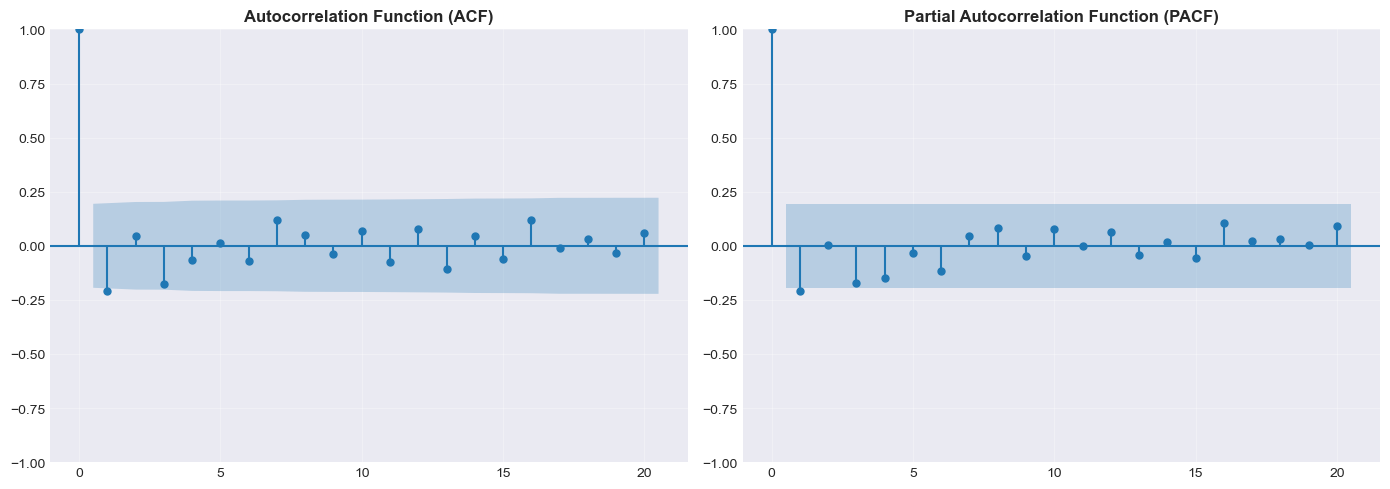


📌 Suggested from ACF/PACF:
   p ≈ 0, q ≈ 0

🔎 Fitting 4 candidate models:
   (0, 1, 0), (0, 1, 1), (1, 1, 0), (1, 1, 1)

✓ Successful fits: 4/4

Top models by AIC:
  ARIMA(0, 1, 0)  AIC=-477.23  BIC=-471.96
  ARIMA(1, 1, 0)  AIC=-462.43  BIC=-454.52
  ARIMA(0, 1, 1)  AIC=-458.52  BIC=-450.61
  ARIMA(1, 1, 1)  AIC=-458.33  BIC=-447.79

--------------------------------------------------------------------------------
VISUAL INSPECTION COMPLETE
--------------------------------------------------------------------------------
✓ ACF/PACF suggested: p≈0, q≈0
✓ d used: 1
✓ Best model: ARIMA(0, 1, 0)
✓ AIC=-477.23 | BIC=-471.96
✓ Candidates tested: 4

STARTING APPROACH 2: AUTO-ARIMA

APPROACH 2: AUTO-ARIMA

Searching for best model...
  Seasonal: True
  Seasonal period (m): 4
  Max orders: p=3, q=3, P=2, Q=2

🔍 AUTO-ARIMA MODEL INSPECTION:
Model specification from pmdarima:
  trend: unknown
  Order: (0, 1, 1)
  Seasonal: (0, 0, 0, 4)
  Parameter names: ['intercept', 'ma.L1', 'sigma2']

  Parame

In [152]:
# CELL 26: COMPREHENSIVE MODEL SELECTION
#================================================================================
# CELL 26: COMPREHENSIVE MODEL SELECTION
#================================================================================
"""
Runs all three approaches with YOUR complete original printouts
First pass without outlier dummies for comparison
"""
"""
CELL 25: MODEL SELECTION - BASELINE (WITHOUT OUTLIERS)
Part A: Helper functions (Auto-ARIMA, Grid Search)
Part B: Comprehensive wrapper function
Part C: Execution
"""


# ============================================================================
# HELPER: Get exog params
# ============================================================================

"""
Robustly extract exog parameters from any model backend
For display in parameter estimates section
"""
       
def comprehensive_model_selection(
    series: pd.Series,
    exog: Optional[pd.DataFrame] = None,
    data_config: Optional[DataConfig] = None,
    model_config: Optional[ModelConfig] = None,
    run_visual: bool = True,
    run_auto_arima: bool = True,
    run_grid_search: bool = True,
    verbose: bool = True
) -> Dict:

# ============================================================================
# EXECUTION
# ============================================================================
    """
    Run all three modeling approaches and compare results
    
    Parameters:
    -----------
    series : pd.Series
        Time series (should be stationary, e.g., log-differenced)
    exog : pd.DataFrame, optional
        Exogenous variables (e.g., outlier dummies)
    data_config : DataConfig
        Data configuration
    model_config : ModelConfig
        Model configuration
    run_visual : bool
        Run visual inspection approach
    run_auto_arima : bool
        Run auto-ARIMA approach
    run_grid_search : bool
        Run grid search approach
    verbose : bool
        Print detailed results
    
    Returns:
    --------
    dict : Results from all approaches
    """
    
    if data_config is None:
        data_config = DataConfig()
    if model_config is None:
        model_config = ModelConfig()
    
    print("\n" + "="*80)
    print("COMPREHENSIVE MODEL SELECTION")
    print("="*80)
    print(f"\nCountry: {data_config.country}")
    print(f"Series: {data_config.series_name}")
    print(f"Transform: {TRANSFORM_DESCRIPTIONS[data_config.transform]}")
    print(f"Observations: {len(series)}")
    
    if exog_used is not None:
        print(f"Exogenous variables: {exog.shape[1]} dummy variables")
        print(f"  Active periods: {(exog.sum(axis=1) > 0).sum()}")
    else:
        print(f"Exogenous variables: None")
    
    print(f"\nApproaches to run:")
    print(f"  1. Visual Inspection (ACF/PACF): {'✓' if run_visual else '✗'}")
    print(f"  2. Auto-ARIMA: {'✓' if run_auto_arima else '✗'}")
    print(f"  3. Grid Search: {'✓' if run_grid_search else '✗'}")
    
    results = {}
    
    # ========================================================================
    # APPROACH 1: VISUAL INSPECTION
    # ========================================================================
    
    if run_visual:
        print("\n" + "="*80)
        print("STARTING APPROACH 1: VISUAL INSPECTION")
        print("="*80)
        
        # ------------------------------------------------------------
        # Stationarity-informed d for visual approach (robust default)
        # ------------------------------------------------------------
        d_for_visual = 1  # safe default
        
        if "stationarity_results" in globals() and \
           isinstance(stationarity_results, dict) and \
           "recommendation" in stationarity_results and \
           "recommended_d" in stationarity_results["recommendation"]:
            d_for_visual = int(stationarity_results["recommendation"]["recommended_d"])
        
            if verbose:
                reason = stationarity_results["recommendation"].get("reason", "")
                print(f"\n📌 Stationarity-informed d for visual = {d_for_visual}")
                if reason:
                    print(f"   Reason: {reason}")
        else:
            if verbose:
                print("\n⚠ No stationarity_results found — defaulting d_for_visual=1")
        
        # ------------------------------------------------------------
        # Run visual inspection approach (new universal Cell 10)
        # ------------------------------------------------------------
        visual_results = run_visual_inspection_approach(
            series=series,
            exog=exog,
            d=d_for_visual,
            max_lags=model_config.max_diagnostic_lags * 2,
            cap=min(3, model_config.p_max, model_config.q_max),
            plot=True,
            verbose=verbose,
            include_benchmark=False
        )
        
        results["visual_inspection"] = visual_results
        
        # ------------------------------------------------------------
        # Clean prints aligned with new returned keys
        # ------------------------------------------------------------
        if verbose:
            print("\n" + "-"*80)
            print("VISUAL INSPECTION COMPLETE")
            print("-"*80)
        
            if visual_results.get("success"):
                print(f"✓ ACF/PACF suggested: p≈{visual_results['suggested_p']}, q≈{visual_results['suggested_q']}")
                print(f"✓ d used: {visual_results['d_used']}")
                print(f"✓ Best model: ARIMA{visual_results['order']}")
                print(f"✓ AIC={visual_results['aic']:.2f} | BIC={visual_results['bic']:.2f}")
                print(f"✓ Candidates tested: {len(visual_results.get('candidates_tested', []))}")
            else:
                print("✗ Visual inspection: no candidate model converged")

           
    
    # ========================================================================
    # APPROACH 2: AUTO-ARIMA
    # ========================================================================
    
    if run_auto_arima:
        print("\n" + "="*80)
        print("STARTING APPROACH 2: AUTO-ARIMA")
        print("="*80)
        
        m = SEASONAL_PERIODS.get(data_config.frequency, 4)
        
        auto_results = run_auto_arima_approach(
            series=series,
            exog=exog,
            seasonal=model_config.test_seasonal,
            m=m,
            max_p=model_config.p_max,
            max_q=model_config.q_max,
            max_P=model_config.P_max,
            max_Q=model_config.Q_max,
            series_type='integrated',
            verbose=verbose
        )
        
        results['auto_arima'] = auto_results
                
            
    # ========================================================================
    # APPROACH 3: GRID SEARCH
    # ========================================================================
    
    if run_grid_search:
        print("\n" + "="*80)
        print("STARTING APPROACH 3: GRID SEARCH")
        print("="*80)
        
        m = SEASONAL_PERIODS.get(data_config.frequency, 4)
        
        # ====================================================================
        # INTELLIGENT d RANGE BASED ON STATIONARITY TESTS
        # ====================================================================
        
        if 'stationarity_results' in globals() and 'recommendation' in stationarity_results:
            recommended_d = stationarity_results['recommendation']['recommended_d']
            reason = stationarity_results['recommendation']['reason']
            
            # FIXED LOGIC: Don't test d=0 if series is non-stationary
            if recommended_d == 0:
                # Series is stationary, test {0, 1} for robustness
                d_range_to_use = range(0, 2)
            elif recommended_d == 1:
                # Series is non-stationary, test {1, 2} ONLY (exclude d=0)
                d_range_to_use = range(1, 3)  # ← CHANGED: Don't include d=0
            else:  # recommended_d == 2
                # Series needs double differencing, test {1, 2}
                d_range_to_use = range(1, 3)
            
            if verbose:
                print(f"\n📌 Using stationarity-informed d range:")
                print(f"   Recommended d = {recommended_d} ({reason})")
                print(f"   Testing d ∈ {list(d_range_to_use)}")
                if recommended_d > 0:
                    print(f"   (Excluding d=0 because series is non-stationary)")
        else:
            # Fallback: exclude d=0 for log-transformed data
            d_range_to_use = range(1, model_config.d_max + 1)
            if verbose:
                print(f"\n⚠ No stationarity results found")
                print(f"   Using default d range: {list(d_range_to_use)}")
                print(f"   (Excluding d=0 as log data is typically non-stationary)")
        
        # ====================================================================
        # RUN GRID SEARCH WITH INTELLIGENT d RANGE
        # ====================================================================
        
        grid_results = run_grid_search_approach(
            series=series,
            exog=exog,
            p_range=range(0, model_config.p_max + 1),
            d_range=d_range_to_use,  # ← USE INTELLIGENT RANGE
            q_range=range(0, model_config.q_max + 1),
            P_range=range(0, model_config.P_max + 1) if model_config.test_seasonal else None,
            D_range=range(0, model_config.D_max + 1) if model_config.test_seasonal else None,
            Q_range=range(0, model_config.Q_max + 1) if model_config.test_seasonal else None,
            m=m,
            test_seasonal=model_config.test_seasonal,
            series_type='integrated',
            verbose=verbose
        )
        
        results['grid_search'] = grid_results
        
        if verbose and grid_results['success']:
            print("\n" + "-"*80)
            print("GRID SEARCH COMPLETE")
            print("-"*80)
            print(f"✓ Best model: ARIMA{grid_results['order']}", end="")
            if grid_results['seasonal_order']:
                print(f" x {grid_results['seasonal_order']}")
            else:
                print()
            print(f"✓ AIC: {grid_results['aic']:.2f}")
            print(f"✓ BIC: {grid_results['bic']:.2f}")
            print(f"✓ Models tested: {grid_results['n_tested']}")
            print(f"✓ Success rate: {grid_results['n_successful']/grid_results['n_tested']*100:.1f}%")
            
            # ====================================================================
            # DEBUG: Check if Grid Search tested ARIMA(0,1,3)
            # ====================================================================
            
            print("\n" + "-"*80)
            print("DEBUG: Checking ARIMA(0,1,3) in Grid Search")
            print("-"*80)
            
            all_results = grid_results['all_results']
            
            # Find ARIMA(0,1,3) with no seasonality
            target_order = (0, 1, 3)
            target_seasonal = (0, 0, 0, 4)
            
            matches = [r for r in all_results 
                       if r['order'] == target_order 
                       and r['seasonal_order'] == target_seasonal]
            
            if len(matches) == 0:
                print(f"\n❌ ARIMA{target_order} was NOT tested!")
                print(f"   This is a bug - it should have been tested.")
            else:
                result = matches[0]
                print(f"\n✓ ARIMA{target_order} was tested:")
                
                if result['success']:
                    print(f"   Status: Converged")
                    print(f"   AIC: {result['aic']:.2f}")
                    print(f"   BIC: {result['bic']:.2f}")
                    
                    # Compare with Auto-ARIMA
                    if 'auto_arima' in results and results['auto_arima']['success']:
                        auto_aic = results['auto_arima']['aic']
                        diff = result['aic'] - auto_aic
                        
                        print(f"\n   Comparison with Auto-ARIMA:")
                        print(f"   Grid Search AIC: {result['aic']:.2f}")
                        print(f"   Auto-ARIMA AIC:  {auto_aic:.2f}")
                        print(f"   Difference:       {diff:+.2f}")
                        
                        if abs(diff) > 0.1:
                            print(f"\n   ⚠️ Different AICs! This suggests:")
                            print(f"      - Different convergence")
                            print(f"      - Different parameter estimates")
                            print(f"      - Backend differences (statsmodels vs pmdarima)")
                else:
                    print(f"   Status: Failed to converge")
                    print(f"   Error: {result.get('error', 'Unknown')}")
                    print(f"\n   ⚠️ This is why Grid Search didn't select it!")

            # ====================================================================
            # DEBUG: Checking if Grid Search tested ARIMA(1,1,0)
            # ====================================================================

            print("\n" + "-"*80)
            print("DEBUG: Checking ARIMA(0,1,1) in Grid Search")
            print("-"*80)
            
            all_results = grid_results['all_results']
            
            target_order = (0, 1, 1)
            target_seasonal = (0, 0, 0, 4)
            
            matches = [r for r in all_results 
                       if r['order'] == target_order 
                       and r['seasonal_order'] == target_seasonal]
            
            if len(matches) == 0:
                print(f"\n❌ ARIMA{target_order} was NOT tested!")
            else:
                result = matches[0]
                print(f"\n✓ ARIMA{target_order} was tested:")
                
                if result['success']:
                    print(f"   Status: Converged")
                    print(f"   AIC: {result['aic']:.2f}")
                    print(f"   BIC: {result['bic']:.2f}")
                    
                    # Compare with Auto-ARIMA
                    if 'auto_arima' in results and results['auto_arima']['success']:
                        auto_aic = results['auto_arima']['aic']
                        diff = result['aic'] - auto_aic
                        
                        print(f"\n   Comparison with Auto-ARIMA:")
                        print(f"   Grid Search AIC: {result['aic']:.2f}")
                        print(f"   Auto-ARIMA AIC:  {auto_aic:.2f}")
                        print(f"   Difference:       {diff:+.2f}")
                        
                        if abs(diff) > 1.0:
                            print(f"\n   🚨 LARGE DIFFERENCE! This suggests:")
                            print(f"      - Different trend specifications")
                            print(f"      - Different parameter estimates")
                            print(f"      - Backend differences")
                            
                            # Show parameters from Grid Search model
                            if result['model'] is not None:
                                print(f"\n   Grid Search ARIMA(0,1,1) parameters:")
                                for param_name, param_val in zip(result['model'].params.index, result['model'].params):
                                    print(f"     {param_name}: {param_val:.6f}")
                else:
                    print(f"   Status: Failed")
                    print(f"   Error: {result.get('error', 'Unknown')}")
      
            
            # Find ARIMA(1,1,0) with no seasonality
            target_order = (1, 1, 0)
            target_seasonal = (0, 0, 0, 4)
            
            matches = [r for r in all_results 
                       if r['order'] == target_order 
                       and r['seasonal_order'] == target_seasonal]
            
            if len(matches) == 0:
                print(f"\n❌ ARIMA{target_order} was NOT tested!")
                print(f"   This is a bug - it should have been tested.")
            else:
                result = matches[0]
                print(f"\n✓ ARIMA{target_order} was tested:")
                
                if result['success']:
                    print(f"   Status: Converged")
                    print(f"   AIC: {result['aic']:.2f}")
                    print(f"   BIC: {result['bic']:.2f}")
                    
                    # Compare with Auto-ARIMA
                    if 'auto_arima' in results and results['auto_arima']['success']:
                        auto_aic = results['auto_arima']['aic']
                        diff = result['aic'] - auto_aic
                        
                        print(f"\n   Comparison with Auto-ARIMA:")
                        print(f"   Grid Search AIC: {result['aic']:.2f}")
                        print(f"   Auto-ARIMA AIC:  {auto_aic:.2f}")
                        print(f"   Difference:       {diff:+.2f}")
                        
                        if abs(diff) > 0.1:
                            print(f"\n   ⚠️ Different AICs! This suggests:")
                            print(f"      - Different trend specifications")
                            print(f"      - Different parameter estimates")
                            print(f"      - Need to verify trend='c' is applied consistently")
                            
                            # Show parameters from Grid Search model
                            if result['model'] is not None:
                                print(f"\n   Grid Search ARIMA(1,1,0) parameters:")
                                for param_name, param_val in zip(result['model'].params.index, result['model'].params):
                                    print(f"     {param_name}: {param_val:.6f}")
                else:
                    print(f"   Status: Failed")
                    print(f"   Error: {result.get('error', 'Unknown')}")

    # ========================================================================
    # COMPARISON ACROSS APPROACHES (UPDATED: no visual benchmark)
    # ========================================================================
    
    if verbose:
        print("\n" + "="*80)
        print("COMPARISON ACROSS APPROACHES")
        print("="*80)
    
        comparison_data = []
        aic_values = []
        approach_names = []
    
        # -------------------------
        # Visual inspection
        # -------------------------
        if run_visual and results.get("visual_inspection", {}).get("success", False):
            vr = results["visual_inspection"]
            comparison_data.append({
                "Approach": "Visual Inspection",
                "Model": f"ARIMA{vr['order']}",
                "AIC": f"{vr['aic']:.2f}",
                "BIC": f"{vr['bic']:.2f}",
                "Status": "✓"
            })
            aic_values.append(vr["aic"])
            approach_names.append("Visual Inspection")
    
        # -------------------------
        # Auto-ARIMA
        # -------------------------
        if run_auto_arima and results.get("auto_arima", {}).get("success", False):
            ar = results["auto_arima"]
    
            order_str = str(ar["order"])
            if ar.get("seasonal_order") and any(ar["seasonal_order"][:3]):
                order_str += f" x {ar['seasonal_order']}"
    
            comparison_data.append({
                "Approach": "Auto-ARIMA",
                "Model": f"ARIMA{order_str}",
                "AIC": f"{ar['aic']:.2f}",
                "BIC": f"{ar['bic']:.2f}",
                "Status": "✓"
            })
            aic_values.append(ar["aic"])
            approach_names.append("Auto-ARIMA")
    
        # -------------------------
        # Grid Search
        # -------------------------
        if run_grid_search and results.get("grid_search", {}).get("success", False):
            gr = results["grid_search"]
    
            order_str = str(gr["order"])
            if gr.get("seasonal_order") and any(gr["seasonal_order"][:3]):
                order_str += f" x {gr['seasonal_order']}"
    
            comparison_data.append({
                "Approach": "Grid Search",
                "Model": f"ARIMA{order_str}",
                "AIC": f"{gr['aic']:.2f}",
                "BIC": f"{gr['bic']:.2f}",
                "Status": "✓"
            })
            aic_values.append(gr["aic"])
            approach_names.append("Grid Search")
    
        # -------------------------
        # Print + best-by-AIC
        # -------------------------
        if comparison_data:
            comparison_df = pd.DataFrame(comparison_data)
            print("\n" + comparison_df.to_string(index=False))
    
            best_idx = int(np.argmin(aic_values))
            best_approach = approach_names[best_idx]
            best_aic = float(aic_values[best_idx])
    
            print(f"\n🏆 BEST APPROACH BY AIC: {best_approach}")
            print(f"   AIC: {best_aic:.2f}")
    
            results["best_approach"] = best_approach
            results["best_aic"] = best_aic
        else:
            print("\n⚠ No successful models to compare")

    
    # ========================================================================
    # DETAILED PARAMETER ESTIMATES UPDATED
    # ========================================================================
    
    if verbose:
        print("\n" + "="*80)
        print("DETAILED PARAMETER ESTIMATES")
        print("="*80)
        
        for approach_name, approach_results in results.items():
            if approach_name in ['best_approach', 'best_aic']:
                continue
            
            if not approach_results.get('success', False):
                continue
            
            model = approach_results.get('model')
            if model is None:
                continue
            
            print(f"\n{'-'*80}")
            print(f"{approach_name.upper().replace('_', ' ')}")
            print(f"{'-'*80}")
            
            # Get model specification
            order = approach_results['order']
            seasonal_order = approach_results.get('seasonal_order')
            
            print(f"\nModel: ARIMA{order}", end="")
            if seasonal_order and any(seasonal_order[:3]):
                print(f" x {seasonal_order}")
            else:
                print()
            
            print(f"AIC: {approach_results['aic']:.2f}")
            print(f"BIC: {approach_results['bic']:.2f}")

            backend = approach_results.get('backend', 'statsmodels')
            
            # ================================================================
            # EXTRACT FULL SUMMARY TABLE (UNIVERSAL)
            # ================================================================
                       
            print(f"\nParameter Estimates:")
            
            try:
                # TRY METHOD 1: statsmodels .summary() (best, most complete)
                if hasattr(model, 'summary'):
                    summary_table = model.summary().tables[1]
                    print(summary_table)
                
                # TRY METHOD 2: pmdarima wrapper (extract from underlying model)
                elif hasattr(model, 'arima_res_') and hasattr(model.arima_res_, 'summary'):
                    summary_table = model.arima_res_.summary().tables[1]
                    print(summary_table)
                
                # FALLBACK METHOD 3: Manual formatting
                else:
                    if hasattr(model, 'params') and not callable(model.params):
                        # statsmodels model
                        param_names = model.params.index
                        param_values = model.params.values
                        
                        if hasattr(model, 'bse'):
                            # Full table with standard errors
                            print("="*80)
                            print(f"{'Parameter':<20s} {'Coef':>12s} {'Std Err':>12s} {'z':>8s} {'P>|z|':>8s}")
                            print("-"*80)
                            
                            for name, val, se in zip(param_names, param_values, model.bse):
                                z_stat = val / se if se > 0 else np.nan
                                p_val = 2 * (1 - stats.norm.cdf(abs(z_stat))) if not np.isnan(z_stat) else np.nan
                                print(f"{name:<20s} {val:12.6f} {se:12.6f} {z_stat:8.3f} {p_val:8.3f}")
                            print("="*80)
                        else:
                            # Simple table without SE
                            print(f"{'Parameter':<20s} {'Coefficient':>12s}")
                            print("-"*35)
                            for name, val in zip(param_names, param_values):
                                print(f"{name:<20s} {val:12.6f}")
                    
                    elif hasattr(model, 'params') and callable(model.params):
                        # pmdarima model
                        params = model.params()
                        param_names = model.arima_res_.param_names
                        
                        print(f"{'Parameter':<20s} {'Coefficient':>12s}")
                        print("-"*35)
                        for name, value in zip(param_names, params):
                            print(f"{name:<20s} {value:12.6f}")
            
            except Exception as e:
                print(f"Could not extract parameter estimates: {e}")
                print(f"Backend: {backend}")
                print(f"Model type: {type(model)}")
            
            # ================================================================
            # DIAGNOSTICS + EXOG INCLUDED CHECK (UNIFIED VIA CELL 7)
            # ================================================================
            try:
                # residuals extraction (statsmodels SARIMAXResults)
                if hasattr(model, "resid"):
                    residuals = pd.Series(model.resid).dropna()
                elif hasattr(model, "arima_res_") and hasattr(model.arima_res_, "resid"):
                    residuals = pd.Series(model.arima_res_.resid).dropna()
                else:
                    residuals = None
            
                if residuals is not None and len(residuals) > 5:
                    diag = run_all_diagnostics(
                        residuals=residuals,
                        max_lag=model_config.max_diagnostic_lags if model_config else None,
                        significance=model_config.significance_level if model_config else 0.05,
                        model=model,
                        exog=exog  # EXACT exog used upstream
                    )
            
                    print("\nDiagnostics:")
                    print(f"  All tests passed: {diag.get('all_tests_passed')}")
                    if diag.get("summary"):
                        print(f"  Summary: {diag['summary']}")
                    else:
                        print(f"  Ljung-Box multi: {diag.get('ljung_box_multi')}")
                        print(f"  Jarque-Bera:    {diag.get('jarque_bera')}")
                        print(f"  ARCH:           {diag.get('arch')}")
                        if diag.get("exog_check"):
                            print(f"  Exog included:  {diag['exog_check'].get('exog_included')}")
                            if diag['exog_check'].get("missing"):
                                print(f"  Exog missing:   {diag['exog_check']['missing']}")
                            if diag.get("exog_warning"):
                                print(f"  ⚠ {diag['exog_warning']}")
            except Exception as e:
                print(f"\nDiagnostics: could not run ({e})")
            
              
                
                # ========================================================================
                # CONVERGENCE WARNINGS (YOUR ORIGINAL PRINTOUT)
    # ========================================================================
    
    if verbose:
        print("\n" + "="*80)
        print("CONVERGENCE STATUS")
        print("="*80)
        
        all_converged = True
        
        for approach_name, approach_results in results.items():
            if approach_name in ['best_approach', 'best_aic']:
                continue
            
            if not approach_results.get('success', False):
                print(f"\n{approach_name.upper().replace('_', ' ')}: ✗ Failed to fit")
                all_converged = False
                continue
            
            model = approach_results.get('model')
            if model is None:
                continue
            
            backend = approach_results.get('backend', 'statsmodels')
            
            if backend == 'statsmodels':
                # Check statsmodels convergence
                try:
                    if hasattr(model, 'mle_retvals'):
                        converged = model.mle_retvals.get('converged', True)
                    else:
                        converged = True
                    
                    if converged:
                        print(f"\n{approach_name.upper().replace('_', ' ')}: ✓ Converged")
                    else:
                        print(f"\n{approach_name.upper().replace('_', ' ')}: ⚠ Convergence warning")
                        all_converged = False
                except:
                    print(f"\n{approach_name.upper().replace('_', ' ')}: ? Unknown convergence status")
            else:
                # pmdarima - assume converged if fitted successfully
                print(f"\n{approach_name.upper().replace('_', ' ')}: ✓ Fitted successfully")
        
        if all_converged:
            print(f"\n{'='*80}")
            print("✓ ALL MODELS CONVERGED SUCCESSFULLY")
            print(f"{'='*80}")
        else:
            print(f"\n{'='*80}")
            print("⚠ SOME MODELS HAD CONVERGENCE ISSUES")
            print(f"{'='*80}")
    
    return results


# ============================================================================
# RUN COMPREHENSIVE MODEL SELECTION (TRAINING DATA ONLY!)
# ============================================================================

print("\n" + "="*80)
print("COMPREHENSIVE MODEL SELECTION - BASELINE (NO OUTLIERS)")
print("="*80)

# ============================================================================
# PREPARE TRAINING DATA FOR MODELING
# ============================================================================

print("\n" + "-"*80)
print("DATA PREPARATION")
print("-"*80)

# CRITICAL: Transform TRAINING data only
log_gdp_train = np.log(gdp_series_train)

print(f"\n✓ Training data prepared:")
print(f"  Original GDP (train): {len(gdp_series_train)} observations")
print(f"  Log GDP (train): {len(log_gdp_train)} observations")
print(f"  Period: {gdp_series_train.index[0].to_period('Q')} to {gdp_series_train.index[-1].to_period('Q')}")

if HAS_HOLDOUT:
    log_gdp_test = np.log(gdp_series_test)
    print(f"\n✓ Test data prepared (for later evaluation):")
    print(f"  Log GDP (test): {len(log_gdp_test)} observations")
    print(f"  Period: {gdp_series_test.index[0].to_period('Q')} to {gdp_series_test.index[-1].to_period('Q')}")

print(f"\n💡 Modeling approach:")
print(f"   - ARIMA input: Log GDP (undifferenced, TRAINING only)")
print(f"   - ARIMA will apply d=1 differencing internally")
print(f"   - Stationarity tests used TRAINING data ✓")
print(f"   - Outlier detection used TRAINING data ✓")
print(f"   - Models will be fit on TRAINING data ✓")
if HAS_HOLDOUT:
    print(f"   - Forecasts will be evaluated on TEST data (Cell 27)")

# ============================================================================
# RUN MODEL SELECTION - BASELINE (NO OUTLIERS, TRAINING DATA)
# ============================================================================

print("\n" + "="*80)
print("MODEL SELECTION - BASELINE (WITHOUT OUTLIERS)")
print("="*80)
print("\nThis baseline run helps us:")
print("  1. Identify natural model structure")
print("  2. Compare with outlier-adjusted models")
print("  3. Assess in-sample fit quality")
if HAS_HOLDOUT:
    print("  4. Provide models for out-of-sample forecast evaluation")

# CRITICAL: Use TRAINING data only!
model_selection_baseline = comprehensive_model_selection(
    series=log_gdp_train,  # ← CHANGED: Uses training data only
    exog=None,
    data_config=data_config,
    model_config=model_config,
    run_visual=True,
    run_auto_arima=True,
    run_grid_search=True,
    verbose=True
)

print("\n✅ Baseline model selection complete")
print("   Results stored in: model_selection_baseline")
print(f"   Based on TRAINING data ({len(log_gdp_train)} observations)")

# ============================================================================
# BASELINE MODEL SUMMARY
# ============================================================================

print("\n" + "="*80)
print("BASELINE MODEL SUMMARY (WITHOUT OUTLIERS)")
print("="*80)

if 'best_approach' in model_selection_baseline:
    best_approach = model_selection_baseline['best_approach']
    print(f"\n🏆 Best baseline approach (by in-sample AIC): {best_approach}")
    
    best_key = best_approach.lower().replace(' ', '_').replace('-', '_')
    if best_key in model_selection_baseline:
        best_model_info = model_selection_baseline[best_key]
        print(f"   Order: {best_model_info['order']}")
        if best_model_info.get('seasonal_order'):
            print(f"   Seasonal: {best_model_info['seasonal_order']}")
        print(f"   AIC: {best_model_info['aic']:.2f}")
        print(f"   BIC: {best_model_info['bic']:.2f}")

# ============================================================================
# NEXT STEPS
# ============================================================================

print("\n" + "="*80)
print("NEXT STEPS")
print("="*80)

print(f"\n💡 Workflow options:")
print(f"   Option A: Add outliers")
print(f"   1. Cell 25: Outlier detection (already run on TRAINING data)")
print(f"   2. Cell 26: Model selection WITH outliers")
print(f"   3. Cell 26B: Model selection WITH outliers and dummies")

if HAS_HOLDOUT:
    print(f"\n   Option B: Evaluate forecasts")
    print(f"   1. Cell 27: Forecast evaluation on TEST set")
    print(f"   2. Compare RMSE, MAE, directional accuracy")
    
    print(f"\n   Option C: Final production model")
    print(f"   1. Cell 28: Refit best model on FULL data")
    print(f"   2. Use for actual nowcasting")
else:
    print(f"\n   ⚠ No hold-out set - cannot evaluate out-of-sample performance")
    print(f"   Consider re-running Cell 21B with a hold-out period")



MODEL SELECTION WITH OUTLIER DUMMIES

--------------------------------------------------------------------------------
OUTLIER DUMMY VERIFICATION
--------------------------------------------------------------------------------

✓ Outlier dummies available:
   Shape: (103, 4)
   Outlier dates detected: ['1999Q1', '2020Q2', '2020Q3', '2021Q1']
   Active periods: 4
   ✓ Index alignment verified with training data

   Outlier periods in training data:
   • 1999Q1 ✓ (in training set)
   • 2020Q2 ✓ (in training set)
   • 2020Q3 ✓ (in training set)
   • 2021Q1 ✓ (in training set)

COMPREHENSIVE MODEL SELECTION (WITH OUTLIERS)

This run includes:
  • Training data: 103 observations
  • Outlier dummies: 4 variables
  • Outlier periods: ['1999Q1', '2020Q2', '2020Q3', '2021Q1']

Expected improvements:
  1. Better fit during COVID period
  2. More accurate parameter estimates
  3. Improved residual diagnostics
  4. Potentially better forecasts

COMPREHENSIVE MODEL SELECTION

Country: Morocco
Seri

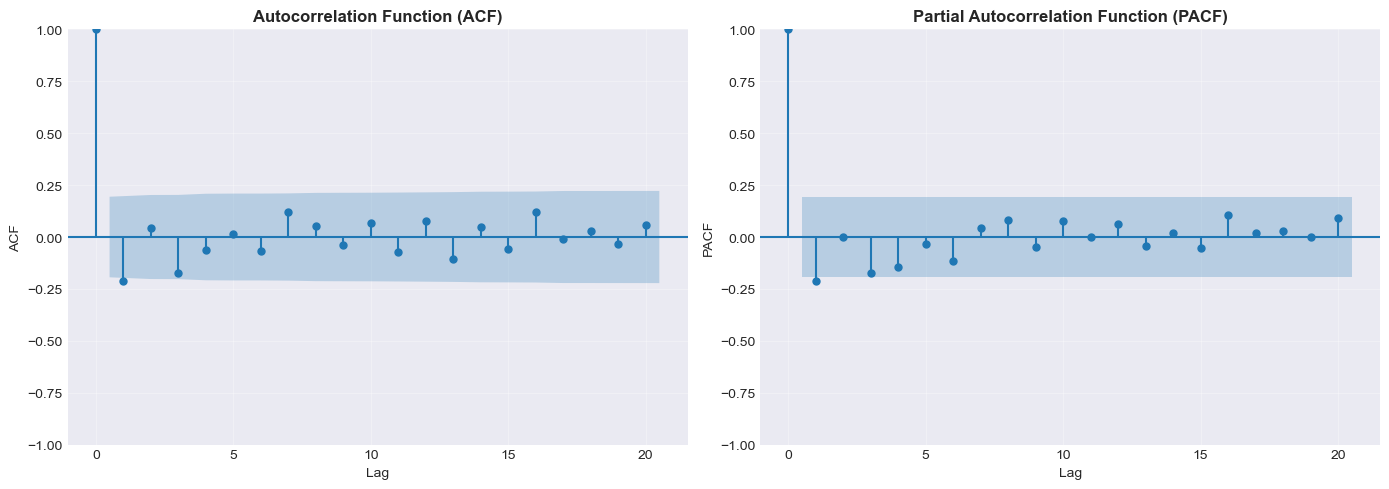


📊 ACF/PACF Analysis:
   PACF suggests p (AR): 0
   ACF suggests q (MA): 0
   Recommended: ARIMA(0, 1, 0)
   (d=1 because ARIMA will difference log GDP internally)

🎯 Fitting benchmark: ARIMA(0,1,0) with drift
    ✓ Model (0, 1, 0) passed all admissibility checks
   ✓ Benchmark fitted: AIC=-538.99, BIC=-523.19

✅ Visual Inspection Complete:
   Final model: ARIMA(0, 1, 0)
   AIC: -538.99
   BIC: -523.19

--------------------------------------------------------------------------------
VISUAL INSPECTION COMPLETE
--------------------------------------------------------------------------------
✓ Suggested order: ARIMA(0, 1, 0)
✓ Benchmark ARIMA(0,0,0): AIC=-538.99

STARTING APPROACH 2: AUTO-ARIMA

APPROACH 2: AUTO-ARIMA

Searching for best model...
  Seasonal: True
  Seasonal period (m): 4
  Max orders: p=3, q=3, P=2, Q=2

✓ Auto-ARIMA completed
   Selected: ARIMA(1, 1, 0) x (2, 0, 0, 4)
   AIC: -558.91
   BIC: -535.29
   Parameters: 9 total
   Exogenous: 4 coefficients

-------------------

In [118]:
# CELL 26B: MODEL SELECTION WITH OUTLIER DUMMIES
# ============================================================================
# CELL 26B: MODEL SELECTION WITH OUTLIER DUMMIES
# ============================================================================

"""
Re-run all three modeling approaches WITH outlier dummy variables

This allows us to:
1. Account for COVID-19 shock (2020Q2, 2020Q3, 2021Q1)
2. Compare baseline (no outliers) vs outlier-adjusted models
3. Assess improvement from outlier modeling
"""

print("\n" + "="*80)
print("MODEL SELECTION WITH OUTLIER DUMMIES")
print("="*80)

# ============================================================================
# VERIFY OUTLIER DUMMIES
# ============================================================================

print("\n" + "-"*80)
print("OUTLIER DUMMY VERIFICATION")
print("-"*80)

if outlier_dummies is None or len(outlier_dates) == 0:
    print("\n⚠ WARNING: No outlier dummies available!")
    print("   Run Cell 25 (Outlier Detection) first")
    print("   Skipping outlier-adjusted model selection")
else:
    print(f"\n✓ Outlier dummies available:")
    print(f"   Shape: {outlier_dummies.shape}")
    print(f"   Outlier dates detected: {[str(d) for d in outlier_dates]}")
    print(f"   Active periods: {(outlier_dummies.sum(axis=1) > 0).sum()}")
    
    # Verify alignment with training data
    if not outlier_dummies.index.equals(log_gdp_train.index):
        print(f"\n⚠ WARNING: Index mismatch between dummies and training data!")
        print(f"   Dummy index: {outlier_dummies.index[0]} to {outlier_dummies.index[-1]}")
        print(f"   Training index: {log_gdp_train.index[0]} to {log_gdp_train.index[-1]}")
    else:
        print(f"   ✓ Index alignment verified with training data")
    
    # Show which observations are affected
    print(f"\n   Outlier periods in training data:")
    for date in outlier_dates:
        # Convert to Period for proper comparison
        if isinstance(date, str):
            date_period = pd.Period(date, freq='Q')
        elif isinstance(date, pd.Period):
            date_period = date
        else:
            date_period = date.to_period('Q')
        
        # Check if this period is in training data
        train_periods = [d.to_period('Q') for d in log_gdp_train.index]
        
        if date_period in train_periods:
            print(f"   • {date} ✓ (in training set)")
        else:
            print(f"   • {date} ✗ (not in training set)")

# ============================================================================
# RUN MODEL SELECTION WITH OUTLIERS
# ============================================================================

if outlier_dummies is not None and len(outlier_dates) > 0:
    
    print("\n" + "="*80)
    print("COMPREHENSIVE MODEL SELECTION (WITH OUTLIERS)")
    print("="*80)
    
    print(f"\nThis run includes:")
    print(f"  • Training data: {len(log_gdp_train)} observations")
    print(f"  • Outlier dummies: {outlier_dummies.shape[1]} variables")
    print(f"  • Outlier periods: {[str(d) for d in outlier_dates]}")
    
    print(f"\nExpected improvements:")
    print(f"  1. Better fit during COVID period")
    print(f"  2. More accurate parameter estimates")
    print(f"  3. Improved residual diagnostics")
    print(f"  4. Potentially better forecasts")
    
    # Run comprehensive model selection WITH outlier dummies
    model_selection_with_outliers = comprehensive_model_selection(
        series=log_gdp_train,
        exog=outlier_dummies,  # ← INCLUDE OUTLIER DUMMIES
        data_config=data_config,
        model_config=model_config,
        run_visual=True,
        run_auto_arima=True,
        run_grid_search=True,
        verbose=True
    )
    
    print("\n✅ Model selection with outliers complete")
    print("   Results stored in: model_selection_with_outliers")
    print(f"   Based on TRAINING data ({len(log_gdp_train)} observations)")
    print(f"   With {outlier_dummies.shape[1]} outlier dummy variables")
    
    # ========================================================================
    # COMPARE: BASELINE vs WITH OUTLIERS
    # ========================================================================
    
    print("\n" + "="*80)
    print("COMPARISON: BASELINE vs WITH OUTLIERS")
    print("="*80)
    
    comparison_data = []
    
    # Extract results from both runs
    for approach in ['visual_inspection', 'auto_arima', 'grid_search']:
        
        # Baseline (no outliers)
        if approach in model_selection_baseline and model_selection_baseline[approach].get('success'):
            baseline = model_selection_baseline[approach]
            
            baseline_order = str(baseline['order'])
            if baseline.get('seasonal_order') and any(baseline['seasonal_order'][:3]):
                baseline_order += f" x {baseline['seasonal_order']}"
            
            comparison_data.append({
                'Approach': approach.replace('_', ' ').title(),
                'Version': 'Baseline',
                'Model': f"ARIMA{baseline_order}",
                'AIC': baseline['aic'],
                'BIC': baseline['bic'],
                'Exog': 'No'
            })
        
        # With outliers
        if approach in model_selection_with_outliers and model_selection_with_outliers[approach].get('success'):
            with_outliers = model_selection_with_outliers[approach]
            
            outlier_order = str(with_outliers['order'])
            if with_outliers.get('seasonal_order') and any(with_outliers['seasonal_order'][:3]):
                outlier_order += f" x {with_outliers['seasonal_order']}"
            
            comparison_data.append({
                'Approach': approach.replace('_', ' ').title(),
                'Version': 'With Outliers',
                'Model': f"ARIMA{outlier_order}",
                'AIC': with_outliers['aic'],
                'BIC': with_outliers['bic'],
                'Exog': f"Yes ({outlier_dummies.shape[1]})"
            })
    
    if comparison_data:
        comparison_df = pd.DataFrame(comparison_data)
        
        print("\n📊 BASELINE vs WITH OUTLIERS:")
        print()
        print(comparison_df.to_string(index=False))
        
        # Calculate improvements
        print("\n" + "-"*80)
        print("AIC IMPROVEMENTS (Baseline → With Outliers)")
        print("-"*80)
        
        for approach in ['Visual Inspection', 'Auto Arima', 'Grid Search']:
            baseline_rows = comparison_df[
                (comparison_df['Approach'] == approach) & 
                (comparison_df['Version'] == 'Baseline')
            ]
            outlier_rows = comparison_df[
                (comparison_df['Approach'] == approach) & 
                (comparison_df['Version'] == 'With Outliers')
            ]
            
            if len(baseline_rows) > 0 and len(outlier_rows) > 0:
                baseline_aic = baseline_rows.iloc[0]['AIC']
                outlier_aic = outlier_rows.iloc[0]['AIC']
                improvement = baseline_aic - outlier_aic
                
                if improvement > 0:
                    print(f"\n{approach}:")
                    print(f"  Baseline AIC:     {baseline_aic:.2f}")
                    print(f"  With Outliers:    {outlier_aic:.2f}")
                    print(f"  Improvement:      {improvement:.2f} points ✓")
                elif improvement < 0:
                    print(f"\n{approach}:")
                    print(f"  Baseline AIC:     {baseline_aic:.2f}")
                    print(f"  With Outliers:    {outlier_aic:.2f}")
                    print(f"  Worsened by:      {abs(improvement):.2f} points ⚠")
                else:
                    print(f"\n{approach}:")
                    print(f"  No change in AIC")
        
        # Identify overall best model
        print("\n" + "="*80)
        print("BEST MODELS")
        print("="*80)
        
        best_baseline_idx = comparison_df[comparison_df['Version'] == 'Baseline']['AIC'].idxmin()
        best_outliers_idx = comparison_df[comparison_df['Version'] == 'With Outliers']['AIC'].idxmin()
        
        if pd.notna(best_baseline_idx):
            best_baseline = comparison_df.loc[best_baseline_idx]
            print(f"\n🏆 Best Baseline Model:")
            print(f"   Approach: {best_baseline['Approach']}")
            print(f"   Model: {best_baseline['Model']}")
            print(f"   AIC: {best_baseline['AIC']:.2f}")
        
        if pd.notna(best_outliers_idx):
            best_with_outliers = comparison_df.loc[best_outliers_idx]
            print(f"\n🏆 Best Model with Outliers:")
            print(f"   Approach: {best_with_outliers['Approach']}")
            print(f"   Model: {best_with_outliers['Model']}")
            print(f"   AIC: {best_with_outliers['AIC']:.2f}")
        
        # Overall winner
        best_overall_idx = comparison_df['AIC'].idxmin()
        if pd.notna(best_overall_idx):
            best_overall = comparison_df.loc[best_overall_idx]
            print(f"\n🏆 OVERALL WINNER (by AIC):")
            print(f"   Approach: {best_overall['Approach']}")
            print(f"   Version: {best_overall['Version']}")
            print(f"   Model: {best_overall['Model']}")
            print(f"   AIC: {best_overall['AIC']:.2f}")
    
    # ========================================================================
    # NEXT STEPS
    # ========================================================================
    
    print("\n" + "="*80)
    print("NEXT STEPS")
    print("="*80)
    
    print(f"\n💡 We now have TWO sets of models:")
    print(f"   1. Baseline (no outliers): model_selection_baseline")
    print(f"   2. With outliers: model_selection_with_outliers")
    
    if HAS_HOLDOUT:
        print(f"\n💡 Next: Cell 27 - Forecast Evaluation")
        print(f"   • Forecast {len(gdp_series_test)}-quarter test period with BOTH model sets")
        print(f"   • Compare RMSE, MAE, directional accuracy")
        print(f"   • Determine which approach forecasts best")
        print(f"   • Baseline vs With Outliers - which wins?")
    else:
        print(f"\n💡 Next: Cell 28 - Final Production Model")
        print(f"   • Refit best model on full data")
        print(f"   • Use for actual nowcasting")

else:
    print("\n⚠ Skipping model selection with outliers")
    print("   No outlier dummies available")

In [75]:
# Run this to verify NO old functions remain:

import inspect

functions_to_check = [
    'fit_arima_model',
    'run_auto_arima_approach', 
    'run_grid_search_approach',
    'run_visual_inspection_approach'
]

for func_name in functions_to_check:
    if func_name in globals():
        func = globals()[func_name]
        sig = str(inspect.signature(func))
        source_file = inspect.getfile(func)
        
        print(f"\n{func_name}:")
        print(f"  Signature: {sig}")
        print(f"  File: {source_file}")
        
        if 'arima_series' in sig:
            print(f"  ⚠️ WARNING: Uses old 'arima_series' parameter!")
        else:
            print(f"  ✅ Uses modern 'series' parameter")



fit_arima_model:
  Signature: (series: pandas.core.series.Series, exog: Optional[pandas.core.frame.DataFrame], order: Tuple[int, int, int], seasonal_order: Tuple[int, int, int, int], verbose: bool = False) -> Tuple[Any, str, bool]
  File: C:\Users\932224\AppData\Local\Temp\ipykernel_26300\2377121527.py
  ✅ Uses modern 'series' parameter

run_auto_arima_approach:
  Signature: (series: pandas.core.series.Series, exog: Optional[pandas.core.frame.DataFrame] = None, seasonal: bool = True, m: int = 4, max_p: int = 3, max_q: int = 3, max_P: int = 2, max_Q: int = 2, verbose: bool = True) -> Dict
  File: C:\Users\932224\AppData\Local\Temp\ipykernel_26300\2377121527.py
  ✅ Uses modern 'series' parameter

run_grid_search_approach:
  Signature: (series: pandas.core.series.Series, exog: Optional[pandas.core.frame.DataFrame] = None, p_range: range = range(0, 4), d_range: range = range(0, 3), q_range: range = range(0, 4), P_range: Optional[range] = None, D_range: Optional[range] = None, Q_range: Opt


MODEL SELECTION - WITH OUTLIERS

✓ Outlier dummies available:
   Total dummies: 3
   Active periods: 3
   Outlier dates: ['2020Q2', '2020Q3', '2021Q1']

🔍 Verifying data alignment:
   log_gdp index: 2006-03-01 00:00:00 to 2025-09-01 00:00:00 (79 obs)
   outlier_dummies index: 2006-03-01 00:00:00 to 2025-09-01 00:00:00 (79 obs)
   ✓ Perfect alignment - ready for modeling

RUNNING MODEL SELECTION WITH OUTLIER DUMMIES

COMPREHENSIVE MODEL SELECTION

Country: Morocco
Series: GDP
Transform: Log difference (growth rates)
Observations: 79
Exogenous variables: 3 dummy variables
  Active periods: 3

Approaches to run:
  1. Visual Inspection (ACF/PACF): ✓
  2. Auto-ARIMA: ✓
  3. Grid Search: ✓

STARTING APPROACH 1: VISUAL INSPECTION

APPROACH 1: VISUAL INSPECTION (ACF/PACF)

📊 Plotting ACF/PACF on differenced series (growth rates)
   (This helps identify p and q for ARIMA(p,d,q) model)


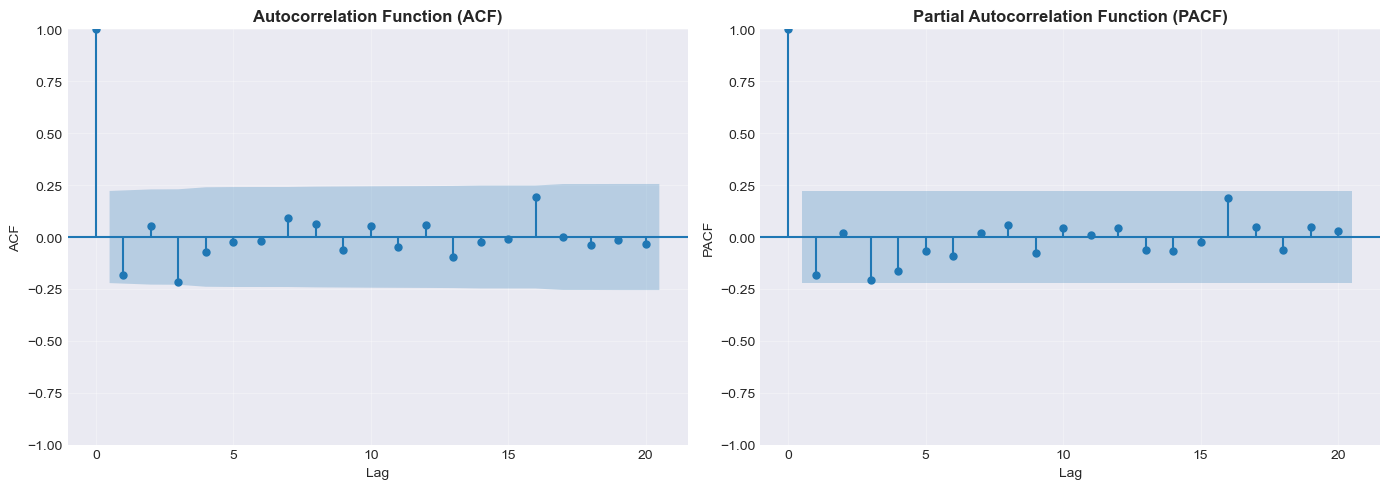


📊 ACF/PACF Analysis:
   PACF suggests p (AR): 0
   ACF suggests q (MA): 0
   Recommended: ARIMA(0, 1, 0)
   (d=1 because ARIMA will difference log GDP internally)

🎯 Fitting benchmark: ARIMA(0,1,0) with drift
   ✓ Benchmark fitted: AIC=-412.04, BIC=-402.67

✅ Visual Inspection Complete:
   Final model: ARIMA(0, 1, 0)
   AIC: -412.04
   BIC: -402.67

--------------------------------------------------------------------------------
VISUAL INSPECTION COMPLETE
--------------------------------------------------------------------------------
✓ Suggested order: ARIMA(0, 1, 0)
✓ Benchmark ARIMA(0,0,0): AIC=-412.04

STARTING APPROACH 2: AUTO-ARIMA

APPROACH 2: AUTO-ARIMA

Searching for best model...
  Seasonal: True
  Seasonal period (m): 4
  Max orders: p=3, q=3, P=2, Q=2

✓ Auto-ARIMA completed
   Selected: SARIMA(0,1,3)(0,0,0,4)
   AIC: -380.30
   BIC: -368.51
   Exog variables: 0 coefficients
   ⚠ WARNING: Exog variables may not have been used!

---------------------------------------------

In [57]:
# CELL 26: MODEL SELECTION - WITH OUTLIERS (FULL MODEL)
# ============================================================================
# CELL 26: MODEL SELECTION - WITH OUTLIERS (FULL MODEL)
# ============================================================================

"""
Second pass with outlier dummies included
"""

# ============================================================================
# CHECK OUTLIER DUMMIES AVAILABLE
# ============================================================================

print("\n" + "="*80)
print("MODEL SELECTION - WITH OUTLIERS")
print("="*80)

if outlier_dummies is None or len(outlier_dates) == 0:
    print("\n⚠ No outlier dummies available")
    print("   Options:")
    print("   1. Run Cell 24 to detect outliers")
    print("   2. Manually specify outliers")
    print("   3. Continue with baseline models only")
    
    user_choice = input("\nContinue anyway? (y/n): ").strip().lower()
    if user_choice != 'y':
        print("Skipping outlier-adjusted modeling")
    else:
        print("\n✓ Proceeding without outliers (same as baseline)")
        model_selection_with_outliers = model_selection_baseline
else:
    print(f"\n✓ Outlier dummies available:")
    print(f"   Total dummies: {outlier_dummies.shape[1]}")
    print(f"   Active periods: {(outlier_dummies.sum(axis=1) > 0).sum()}")
    print(f"   Outlier dates: {[str(d) for d in outlier_dates]}")
    
    # Verify alignment
    print(f"\n🔍 Verifying data alignment:")
    print(f"   log_gdp index: {log_gdp.index[0]} to {log_gdp.index[-1]} ({len(log_gdp)} obs)")
    print(f"   outlier_dummies index: {outlier_dummies.index[0]} to {outlier_dummies.index[-1]} ({len(outlier_dummies)} obs)")
    
    if outlier_dummies.index.equals(log_gdp.index):
        print(f"   ✓ Perfect alignment - ready for modeling")
    else:
        print(f"   ⚠ Index mismatch detected - attempting to align...")
        # Align indices
        common_idx = log_gdp.index.intersection(outlier_dummies.index)
        log_gdp_aligned = log_gdp.loc[common_idx]
        outlier_dummies_aligned = outlier_dummies.loc[common_idx]
        
        print(f"   → Aligned to {len(common_idx)} common observations")
        
        log_gdp = log_gdp_aligned
        outlier_dummies = outlier_dummies_aligned
    
    # ========================================================================
    # RUN MODEL SELECTION WITH OUTLIERS
    # ========================================================================
    
    print("\n" + "="*80)
    print("RUNNING MODEL SELECTION WITH OUTLIER DUMMIES")
    print("="*80)
    
    model_selection_with_outliers = comprehensive_model_selection(
        series=log_gdp,
        exog=outlier_dummies,  # ← NOW WITH OUTLIERS
        data_config=data_config,
        model_config=model_config,
        run_visual=True,
        run_auto_arima=True,
        run_grid_search=True,
        verbose=True
    )
    
    print("\n✅ Model selection with outliers complete")
    print("   Results stored in: model_selection_with_outliers")
    
    # ========================================================================
    # COMPARISON: BASELINE vs WITH OUTLIERS
    # ========================================================================
    
    print("\n" + "="*80)
    print("COMPARISON: BASELINE vs WITH OUTLIERS")
    print("="*80)
    
    comparison_data = []
    
    # Baseline models
    if 'auto_arima' in model_selection_baseline and model_selection_baseline['auto_arima']['success']:
        comparison_data.append({
            'Configuration': 'Baseline (No Outliers)',
            'Approach': 'Auto-ARIMA',
            'Order': str(model_selection_baseline['auto_arima']['order']),
            'AIC': f"{model_selection_baseline['auto_arima']['aic']:.2f}",
            'BIC': f"{model_selection_baseline['auto_arima']['bic']:.2f}"
        })
    
    if 'grid_search' in model_selection_baseline and model_selection_baseline['grid_search']['success']:
        comparison_data.append({
            'Configuration': 'Baseline (No Outliers)',
            'Approach': 'Grid Search',
            'Order': str(model_selection_baseline['grid_search']['order']),
            'AIC': f"{model_selection_baseline['grid_search']['aic']:.2f}",
            'BIC': f"{model_selection_baseline['grid_search']['bic']:.2f}"
        })
    
    # With outliers
    if 'auto_arima' in model_selection_with_outliers and model_selection_with_outliers['auto_arima']['success']:
        comparison_data.append({
            'Configuration': 'With Outliers',
            'Approach': 'Auto-ARIMA',
            'Order': str(model_selection_with_outliers['auto_arima']['order']),
            'AIC': f"{model_selection_with_outliers['auto_arima']['aic']:.2f}",
            'BIC': f"{model_selection_with_outliers['auto_arima']['bic']:.2f}"
        })
    
    if 'grid_search' in model_selection_with_outliers and model_selection_with_outliers['grid_search']['success']:
        comparison_data.append({
            'Configuration': 'With Outliers',
            'Approach': 'Grid Search',
            'Order': str(model_selection_with_outliers['grid_search']['order']),
            'AIC': f"{model_selection_with_outliers['grid_search']['aic']:.2f}",
            'BIC': f"{model_selection_with_outliers['grid_search']['bic']:.2f}"
        })
    
    if comparison_data:
        comparison_df = pd.DataFrame(comparison_data)
        print("\n" + comparison_df.to_string(index=False))
        
        # Calculate improvement
        baseline_aic = model_selection_baseline.get('best_aic')
        outlier_aic = model_selection_with_outliers.get('best_aic')
        
        if baseline_aic and outlier_aic:
            improvement = baseline_aic - outlier_aic
            print(f"\n📊 AIC Improvement: {improvement:.2f}")
            if improvement > 0:
                print(f"   ✓ Outlier adjustment improved model fit")
            elif improvement < -2:
                print(f"   ⚠ Outlier adjustment worsened fit (may be overfitting)")
            else:
                print(f"   → Minimal difference")

print("\n✅ Complete model selection workflow finished")
print("   Baseline results: model_selection_baseline")
print("   With outliers: model_selection_with_outliers")

In [1]:
from pathlib import Path
import nbformat
import ast
import re

nb_path = Path(r"C:\Users\932224\OneDrive - United Nations\Desktop\Data Science Projects\Morocco GDP nowcasting\Hassan\ARIMA\sent to Sarah\GDP Prediction NG-Copy1.ipynb")

nb = nbformat.read(nb_path, as_version=4)

def strip_magics(code: str) -> str:
    cleaned = []
    for line in code.splitlines():
        s = line.lstrip()
        # Skip common notebook magics / shell escapes
        if s.startswith(("%", "!", "?", "%%")):
            continue
        cleaned.append(line)
    return "\n".join(cleaned)

function_names = []
failed_cells = []

for i, cell in enumerate(nb.cells):
    if cell.cell_type != "code":
        continue
    code = strip_magics(cell.source)
    if not code.strip():
        continue

    try:
        tree = ast.parse(code)
        for node in ast.walk(tree):
            if isinstance(node, ast.FunctionDef):
                function_names.append(node.name)
    except SyntaxError as e:
        failed_cells.append((i, str(e)))

# Unique + sorted
function_names = sorted(set(function_names))

print(f"Found {len(function_names)} functions:")
for name in function_names:
    print(" -", name)

print("\nCells that could not be parsed (often non-code text in code cells):", len(failed_cells))
if failed_cells:
    print("Example:", failed_cells[0])


Found 135 functions:
 - __init__
 - _band_msg
 - _csv_has_choices
 - _draw_method_glossary
 - _enumerate_allowed_methods
 - _fit_sarimax
 - _interpolate_at_mask
 - _load_choices_from_csv
 - _orchestrate_choice_flow
 - _parse_fix_dates
 - _print_bands_for
 - _prompt_choice
 - _rolling_cv_rmse
 - _rolling_mad
 - _rolling_median
 - _safe_freq_infer
 - _series_lengths
 - _sig_ok
 - _sign_ok
 - analyze_residuals
 - apply_kalman
 - apply_min_history
 - apply_transform
 - apply_transformation
 - apply_user_choices
 - build_applied_changes_pack
 - build_outlier_review_pack
 - calculate_benchmark_forecasts
 - calculate_burn_in
 - calculate_fit_metrics
 - check_data_quality
 - check_pmdarima_exog_included
 - check_quarterly_gaps
 - choose_min_history
 - classify_outliers
 - compare_residuals_across_approaches
 - complete_transformation_pipeline
 - comprehensive_model_selection
 - comprehensive_nowcasting_analysis
 - comprehensive_quarterly_analysis_enhanced
 - create_cross_approach_ensemble
 - c

In [ ]:
BASED ON ENHANCED CODE in python file named GDP Prediction NG_Initial code_before enhancements

QUARTERLY GDP NOWCASTING ANALYSIS - CENTRAL BANK GRADE
Comprehensive pipeline with outlier management and benchmarking
Analysis timestamp: 2026-02-10 22:14:35

STEP 1: DATA LOADING
✓ Data loaded from: C:\Users\932224\OneDrive - United Nations\Desktop\Data Science Projects\Morocco GDP nowcasting\Hassan\ARIMA\DataBase\GDP Data\NG_Morocco_GEM_data_1.xlsx
  Raw data shape: (79, 5)

Raw data columns: ['Date', 'MAR_NY_GDP_MKTP_I_KN_Q', 'MAR_NY_GDP_MKTP_I_KD_Q', 'MAR_NY_GDP_MKTP_I_CN_Q', 'MAR_NY_GDP_MKTP_I_CD_Q']
First row:
Date                      2006-03-01 00:00:00
MAR_NY_GDP_MKTP_I_KN_Q                 180137
MAR_NY_GDP_MKTP_I_KD_Q            21606.89919
MAR_NY_GDP_MKTP_I_CN_Q               150321.0
MAR_NY_GDP_MKTP_I_CD_Q            16502.71296
Name: 0, dtype: object

After renaming:
  Columns: ['Date', 'GDP', 'GDP1', 'GDP2', 'GDP3']
✓ Column names standardized

Converting Date column...
  Sample dates before conversion: [Timestamp('2006-03-01 00:00:00'), Timestamp('2006-06-01 00:00:00')

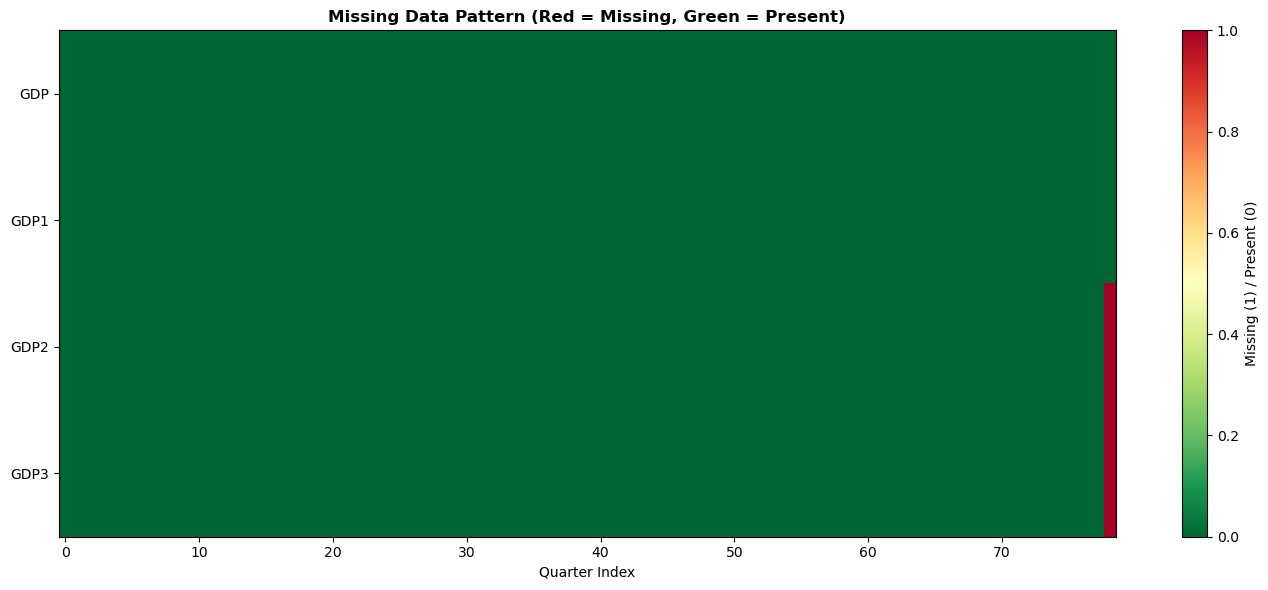

✓ Missing data heatmap displayed

STEP 4: RAW TIME SERIES VISUALIZATION


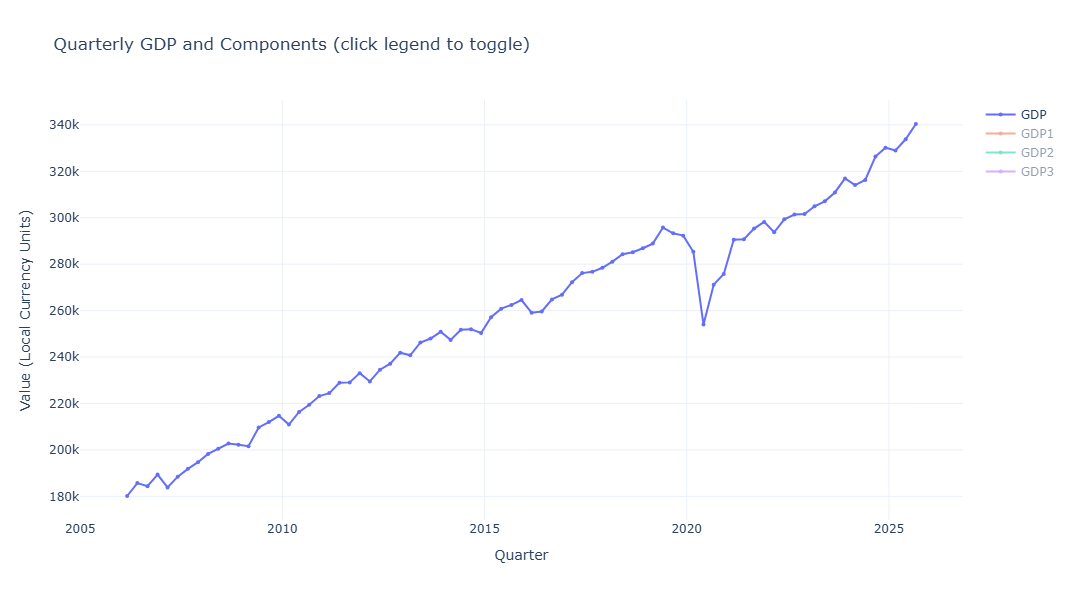

✓ Interactive time series plot displayed

STEP 5: GDP SERIES SUMMARY STATISTICS

Descriptive Statistics:
--------------------------------------------------------------------------------
count        79.000000
mean     257589.063291
std       42786.533509
min      180137.000000
25%      223822.500000
50%      259634.000000
75%      291513.000000
max      340387.000000
Name: GDP, dtype: float64

--------------------------------------------------------------------------------
Additional Metrics:
--------------------------------------------------------------------------------
Missing values:     0 (0.0%)
First observation:  2006-03-01 00:00:00
Last observation:   2025-09-01 00:00:00
Coverage:           79 quarters

--------------------------------------------------------------------------------
Growth Rate Statistics (%):
--------------------------------------------------------------------------------
QoQ growth - Mean:     0.84%
QoQ growth - Std:      2.07%
QoQ growth - Min:    -11.00% (2

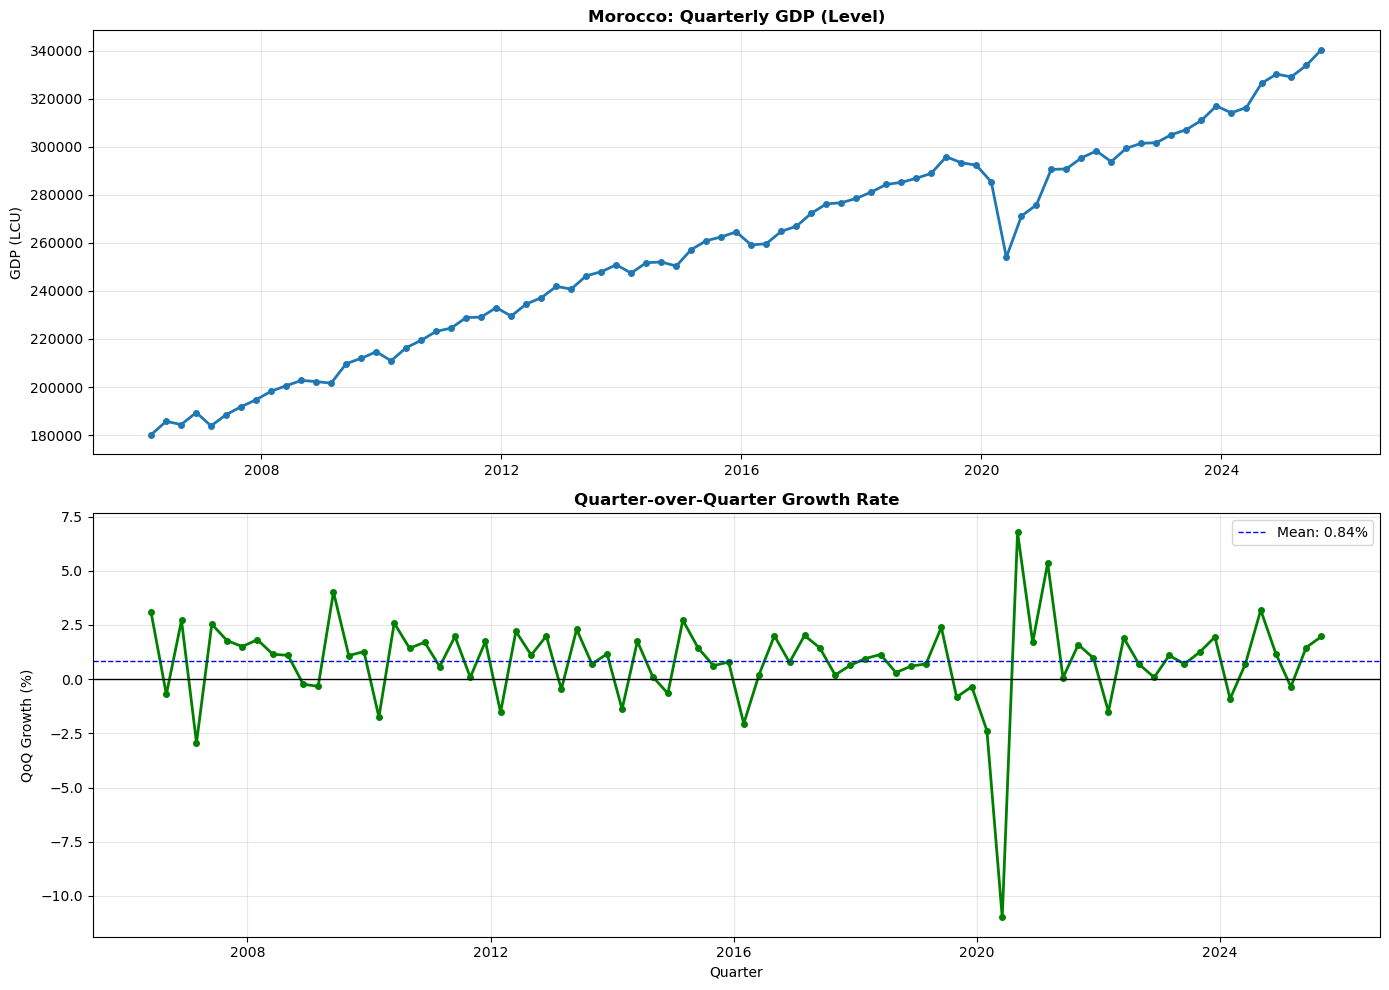


✓ GDP level and growth rate plots displayed

STEP 6: DATA READINESS CHECK
✓ PASS: Sufficient observations
✓ PASS: Missing data manageable
✓ PASS: No constant values
✓ PASS: Positive values
✓ PASS: No extreme gaps

✓ DATA READY FOR ARIMA ANALYSIS

✓ Data validated and ready for modeling

CONFIGURATION


Validation horizon (recent quarters to hold out) [default 4]:  8
Enable outlier detection? (y/n) [default y]:  y
Auto-accept detected outliers? (y/n) [default n]:  n
Consensus threshold (2=majority, 3=unanimous) [default 2]:  2



✓ Configuration set:
  Validation: Rolling window (testing on last 8 quarters)
  Training: All data except last 8 quarters
  Outlier detection: ENABLED

COMPREHENSIVE QUARTERLY GDP ANALYSIS: Morocco
Series: GDP
Frequency: Quarterly

SECTION 1: DATA QUALITY & MISSING DATA

✓ Linear (time) interpolation + forward/backward fill (≤10% missing)

✓ Working with 79 quarterly observations
  Period: 2006Q1 to 2025Q3
  Dates: 2006-03-01 to 2025-09-01
  Series: GDP
  Country: Morocco

STEP 7: DATA REVISION ANALYSIS

Auto-detecting most recent previous vintage...
  ✓ Found 50 previous vintage(s)
  → Using most recent: Morocco_GDP_diagnostics_20260210_221431.xlsx
    Date: 2026-02-10 22:14:32

  Other available vintages:
    • Morocco_GDP_diagnostics_20260210_204849.xlsx (2026-02-10)
    • Morocco_GDP_diagnostics_20260210_204349.xlsx (2026-02-10)
    • Morocco_GDP_diagnostics_20260210_193345.xlsx (2026-02-10)
    ... and 46 more

Comparing current vintage with previous vintage...
  Previous vintag

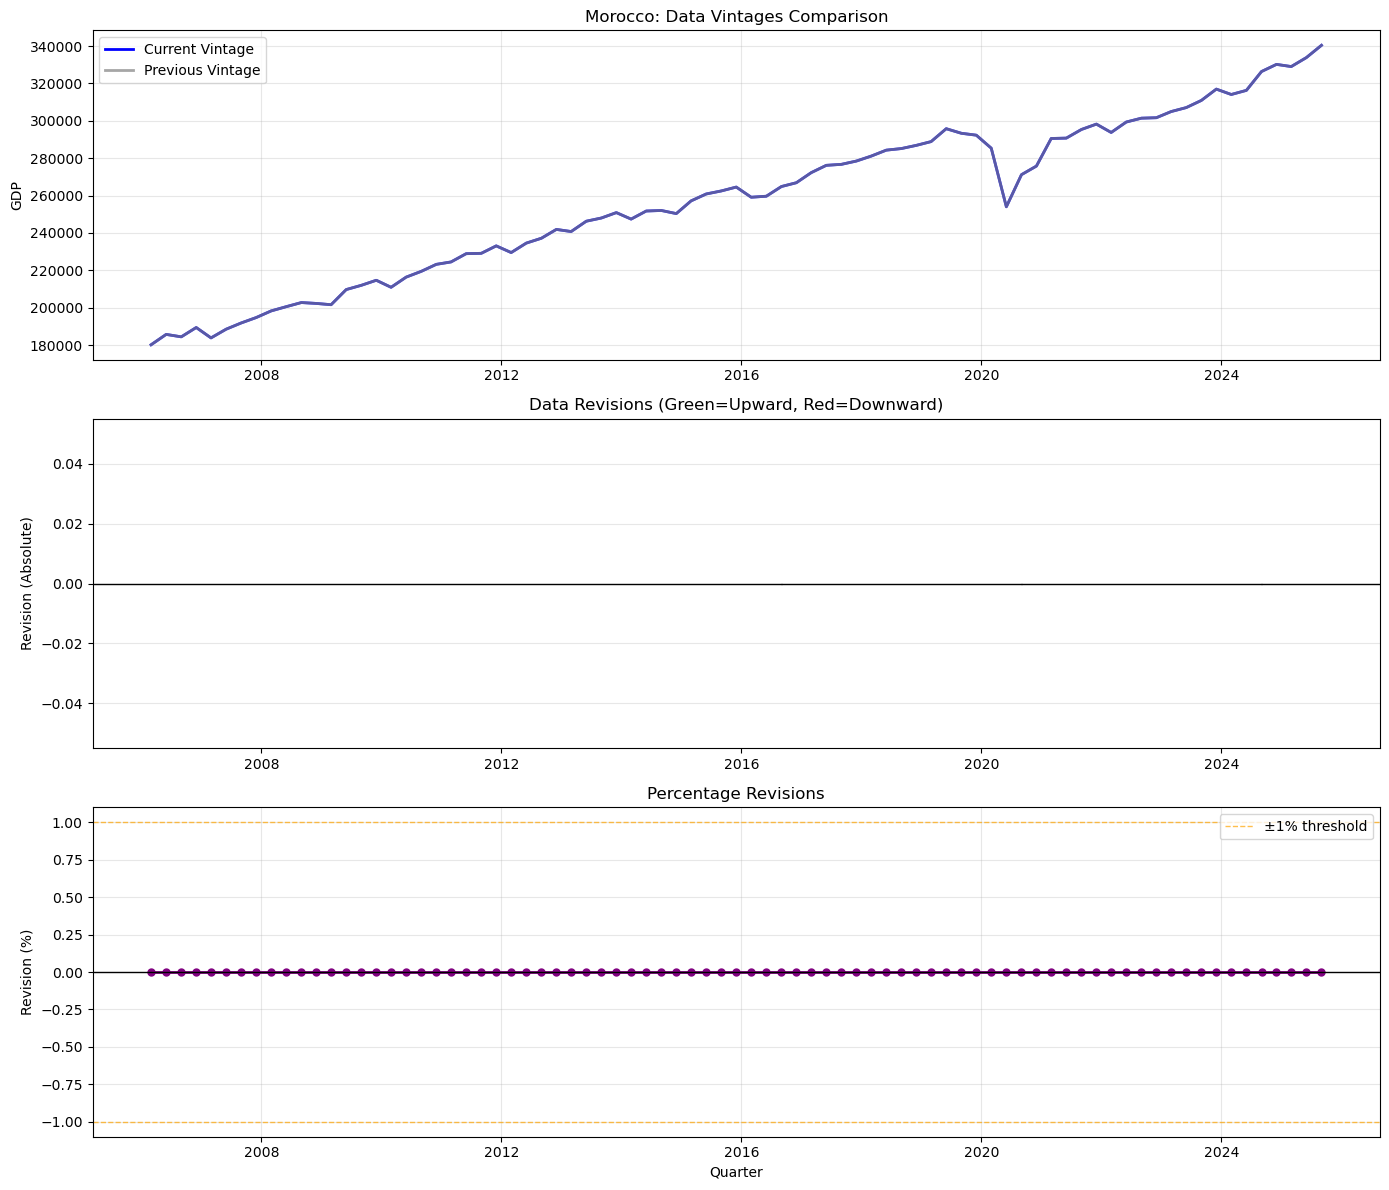


REVISION TRACKING IMPLICATIONS

✓ LOW revision magnitude (avg 0.00%)
  → Data is relatively stable between vintages
  → Nowcasting forecast errors primarily due to model, not data revisions

SECTION 2: DATA TRANSFORMATION


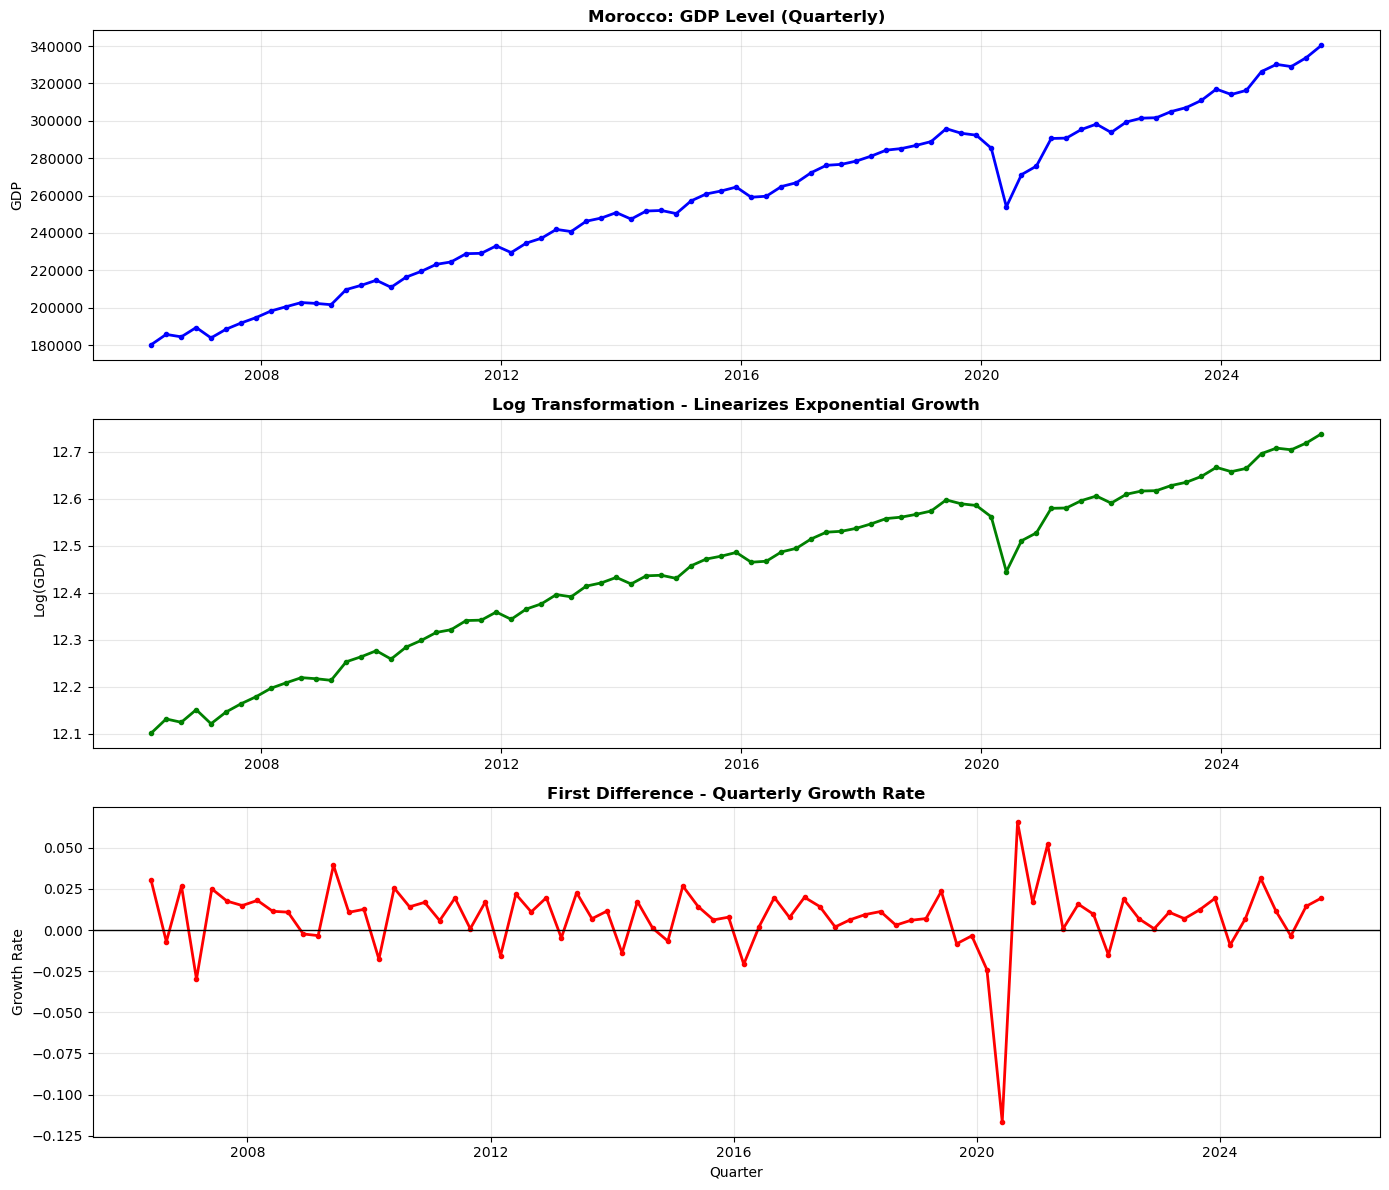


✓ Data transformation complete
  Original series: 79 observations
  Log-differenced series: 78 observations

SECTION 2B: POTENTIAL PREDICTORS FOR ARIMAX MODELING

CURRENT MODEL: Univariate ARIMA
  Using only: GDP (target variable) + outlier dummies

AVAILABLE PREDICTORS IN DATASET (3):
--------------------------------------------------------------------------------

  GDP1:
    Observations: 79 / 79 (100.0% complete)
    Coverage: 2006-03-01 00:00:00 to 2025-09-01 00:00:00
    Status: ✓ Suitable for ARIMAX (≥80% complete)

  GDP2:
    Observations: 79 / 79 (100.0% complete)
    Coverage: 2006-03-01 00:00:00 to 2025-09-01 00:00:00
    Status: ✓ Suitable for ARIMAX (≥80% complete)

  GDP3:
    Observations: 79 / 79 (100.0% complete)
    Coverage: 2006-03-01 00:00:00 to 2025-09-01 00:00:00
    Status: ✓ Suitable for ARIMAX (≥80% complete)

MULTIVARIATE MODELING READINESS

✓ 3 predictor(s) ready for ARIMAX:
    • GDP1
    • GDP2
    • GDP3

TO ENABLE MULTIVARIATE MODELING:
  1. Pass predi


[1] Import reviewed  [2] Auto-accept  [3] Skip
Choice:  1



✓ Reviewed outliers imported: 3 kept for modeling
  Excluded by economist: 5

CREATING OUTLIER DUMMY VARIABLES
  ✓ outlier_2020Q2 at 2020-06-01 00:00:00
  ✓ outlier_2020Q3 at 2020-09-01 00:00:00
  ✓ outlier_2021Q1 at 2021-03-01 00:00:00

✓ 3 dummies created, 3 active periods

OUTLIER SECTION COMPLETE: 3 dummy variables


SECTION 3: STATIONARITY TESTS

WHAT ARE WE TESTING?
--------------------------------------------------------------------------------
Stationarity = Statistical properties (mean, variance) constant over time
ARIMA requires stationary data (after differencing)

Two complementary tests:
  • ADF (Augmented Dickey-Fuller): Tests for unit root
    H0 = Non-stationary | H1 = Stationary
    Rule: p < 0.05 → Reject H0 → Series is STATIONARY

  • KPSS (Kwiatkowski-Phillips-Schmidt-Shin): Tests for stationarity
    H0 = Stationary | H1 = Non-stationary
    Rule: p > 0.05 → Accept H0 → Series is STATIONARY


IMPORTANT: Testing on outlier-adjusted data for accuracy


GDP LEVEL
---

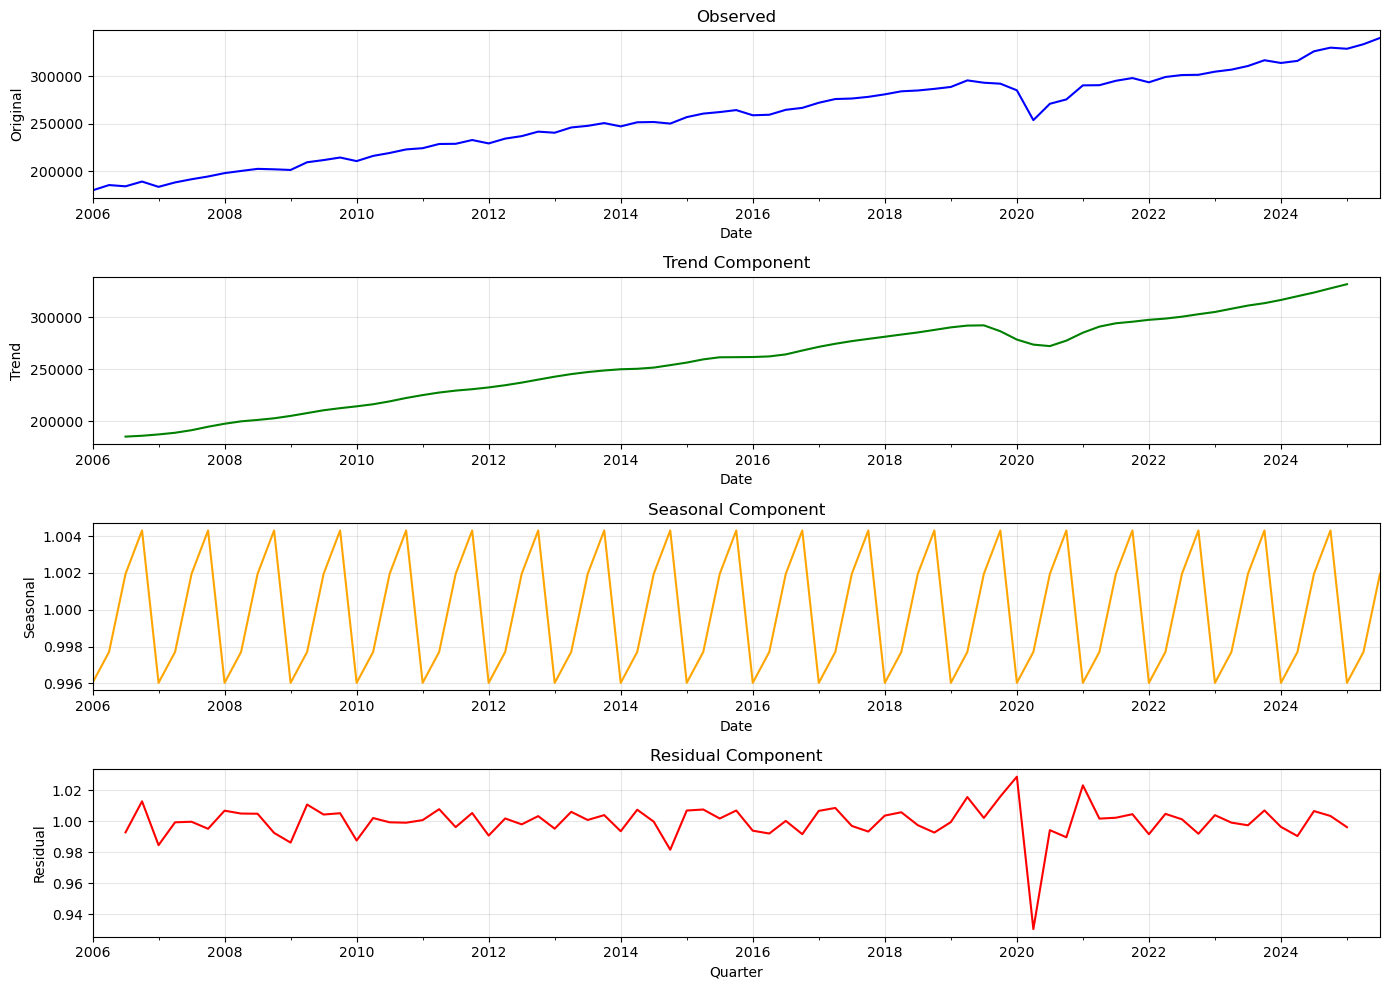


Seasonal strength: 0.0000
Interpretation:
  < 0.05: Negligible seasonality
  0.05-0.10: Weak seasonality
  0.10-0.20: Moderate seasonality
  > 0.20: Strong seasonality

SEASONAL ADJUSTMENT DECISION
Measured seasonal strength: 0.0000

→ WEAK seasonality detected (< 0.10)
  Data appears well-adjusted or naturally non-seasonal
  No additional seasonal adjustment needed

→ Final setting: apply_seasonal_adjustment = False
→ Model testing: BOTH ARIMA and SARIMA (AIC will decide winner)


✓ Using original (unadjusted) series for modeling

→ USING ORIGINAL SERIES for all subsequent analysis

SECTION 5: ACF/PACF ANALYSIS

WHAT ARE WE LOOKING FOR?
--------------------------------------------------------------------------------
ACF (Autocorrelation) → Determines MA order (q)
  • Sharp cutoff at lag q → Use MA(q)
  • Gradual decay → Consider AR component

PACF (Partial Autocorrelation) → Determines AR order (p)
  • Sharp cutoff at lag p → Use AR(p)
  • Gradual decay → Consider MA component


IMPO

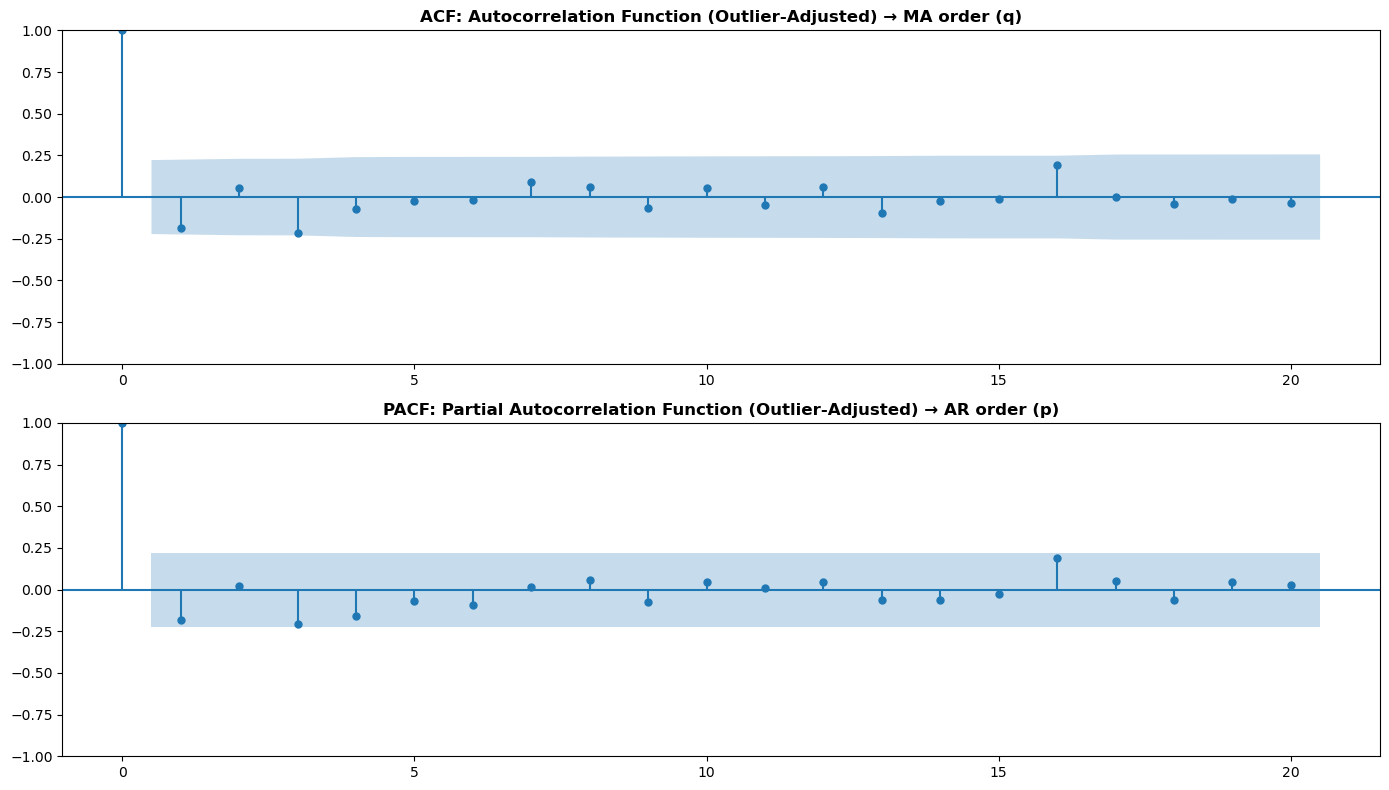


AUTOMATED INTERPRETATION:
--------------------------------------------------------------------------------
ACF Analysis:
  No significant lags → q=0 (no MA component)

PACF Analysis:
  No significant lags → p=0 (no AR component)

ACF/PACF TEST SUMMARY

ACF (MA component):
  Significant lags detected: 0
  → Recommended q: 0

PACF (AR component):
  Significant lags detected: 0
  → Recommended p: 0

CRITICAL NOTE: ACF/PACF INTERPRETATION
We analyzed the FIRST DIFFERENCE of log(GDP):
  → This means d=1 differencing is ALREADY APPLIED
  → ACF/PACF suggests: ARIMA(0,0,0)

However, ARIMA models expect RAW (undifferenced) data as input.
So we tell ARIMA to difference internally with d=1:
  → Final model: ARIMA(0,1,0)

Both approaches are equivalent:
  1. Difference manually → ARIMA(p,0,q) on differenced data
  2. Let ARIMA difference → ARIMA(p,1,q) on original data

✓ We use approach #2 (standard practice)

→ VISUAL INSPECTION SUGGESTS: ARIMA(0,1,0)

SECTION 6: PARAMETER SELECTION - THREE APP

C:\Users\932224\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

C:\Users\932224\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals




OUTLIER DUMMY DIAGNOSTIC

✓ Outlier dummies were included in model
  Number of dummy columns: 3
  Dummy columns: ['outlier_2020Q2', 'outlier_2020Q3', 'outlier_2021Q1']
Note: This checks the validation model, not the selected best model

  outlier_2020Q2:
    Active periods: 1
      2020-Q2
        → THIS IS 2020Q2!
        → GDP log value at 2020Q2: 12.444960

  outlier_2020Q3:
    Active periods: 1
      2020-Q3

  outlier_2021Q1:
    Active periods: 1
      2021-Q1


Checking if 2020Q2 exists in modeling data:
  ✗ 2020Q2 NOT in diag_series index!
    This explains why dummy has no effect
  ✗ 2020Q2 NOT in exog_for_modeling index!
    Dummy cannot work if date missing


Model Exogenous Coefficients:
  ⚠ No exogenous coefficients found in model
    This means dummies were NOT actually used!

   Burn-in periods to remove: 8


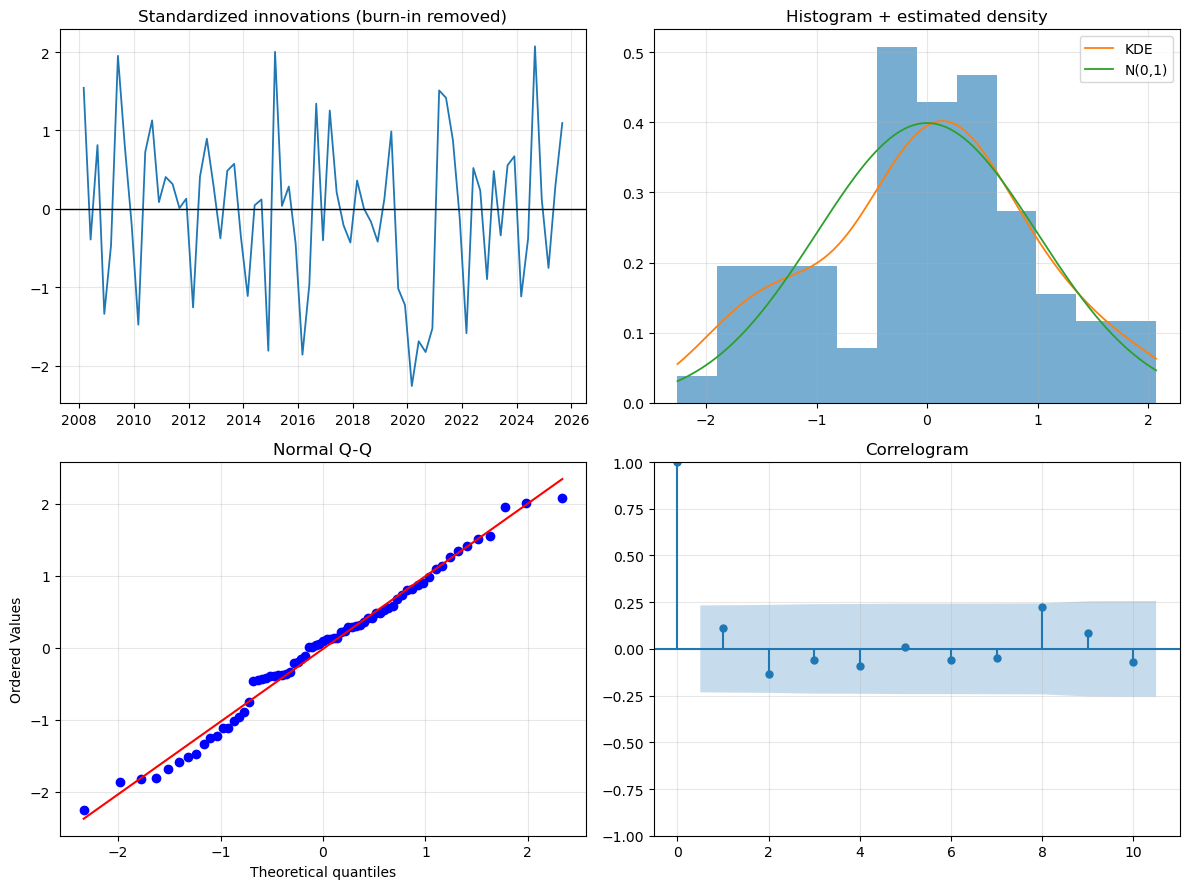


RESIDUAL DIAGNOSTIC TESTS

Ljung-Box (autocorrelation, lag 10):
  stat=8.836   p-value=0.5478   → ✓ no autocorrelation

Jarque-Bera (normality):
  stat=0.676   p-value=0.7131   → ✓ approximately normal

Engle ARCH LM (heteroskedasticity):
  LM stat=4.727   p-value=0.3165   → ✓ homoskedastic

EXPORTING RESIDUAL DIAGNOSTICS TO EXCEL

✓ Residuals exported to: C:\Users\932224\OneDrive - United Nations\Desktop\Data Science Projects\Morocco GDP nowcasting\Hassan\ARIMA\sent to Sarah\outputs\figures\Morocco_residuals_diagnostics_20260210_221956.xlsx
  Sheets created:
    1. Residuals - Full time series with flags
    2. Residuals_Sorted - Ordered by magnitude
    3. Diagnostic_Tests - Statistical test results
    4. Extreme_Residuals - Only extreme observations (|z| > 2)
    5. Model_Info - Model and data details


  INTERPRETATION:
  ✓ No ARCH effects detected - residuals are homoskedastic
  ✓ Model satisfies all standard diagnostic criteria

SECTION 7: IN-SAMPLE VALIDATION

WHAT ARE WE TEST

C:\Users\932224\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

C:\Users\932224\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.

C:\Users\932224\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals




Validation Results:
  MAPE: 1.47%
  RMSE: 5,487
  MAE:  4,849

  → Quality Assessment: EXCELLENT


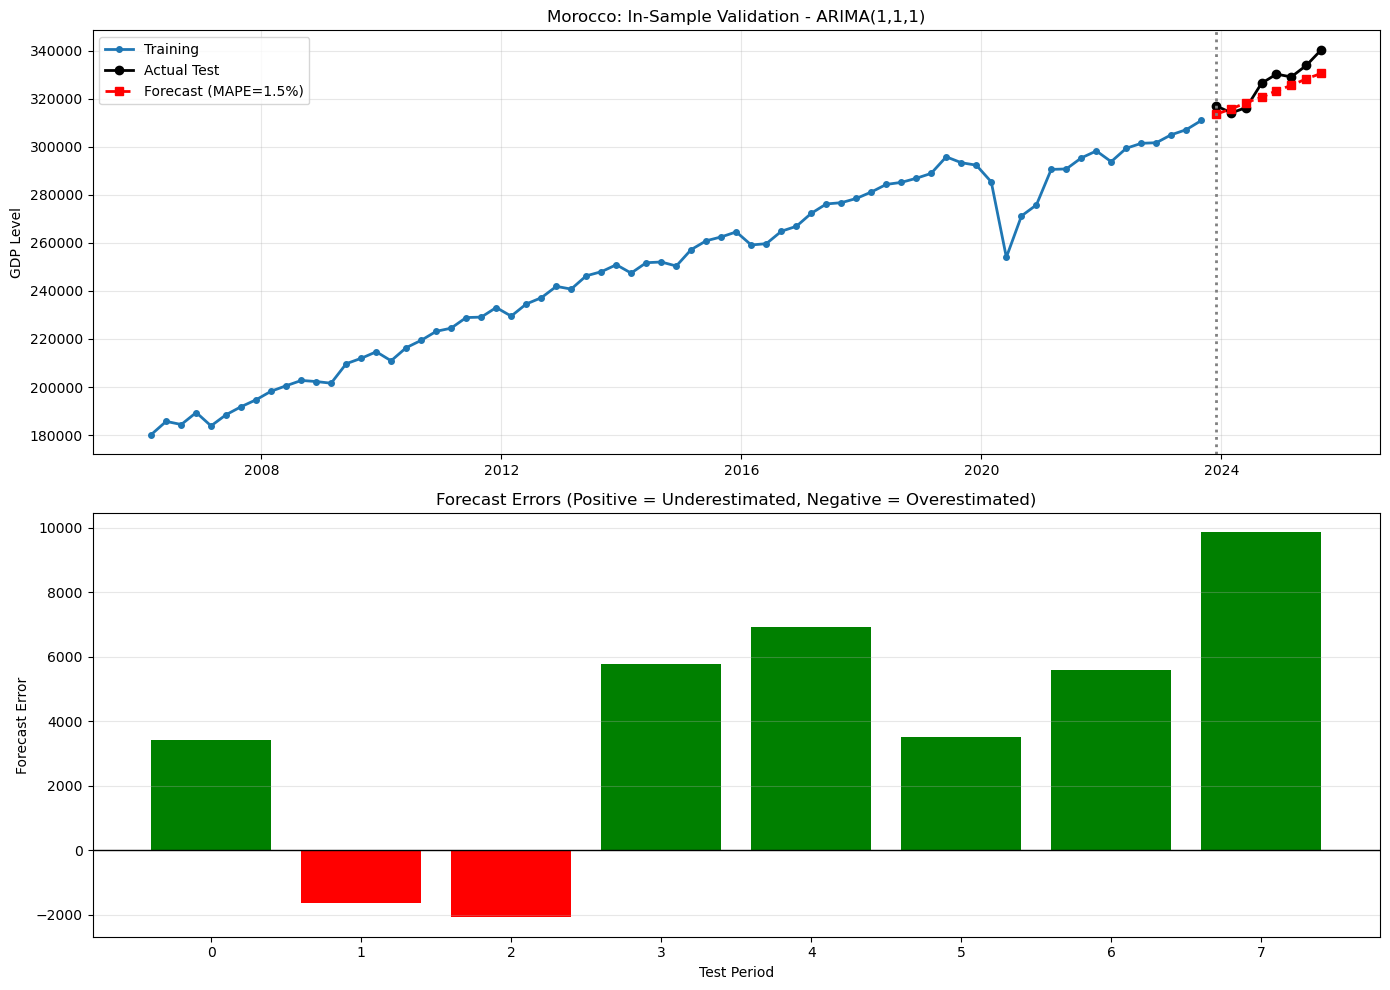


BENCHMARK COMPARISONS

               Model  MAPE (%)         RMSE                      Description
        ARIMA(1,1,1)  1.470073  5486.876166     ARIMA with 3 outlier dummies
 Naive (Random Walk)  4.528250 17352.467627 Last observation carried forward
Seasonal Naive (YoY)  4.164124 13894.511740  Same quarter from previous year
     Historical Mean 24.168568 79423.116427       Average of training period

✓ ARIMA outperforms best benchmark by 64.7%

Directional Accuracy: 71.4%
(Percentage of quarters where forecast correctly predicted direction of change)


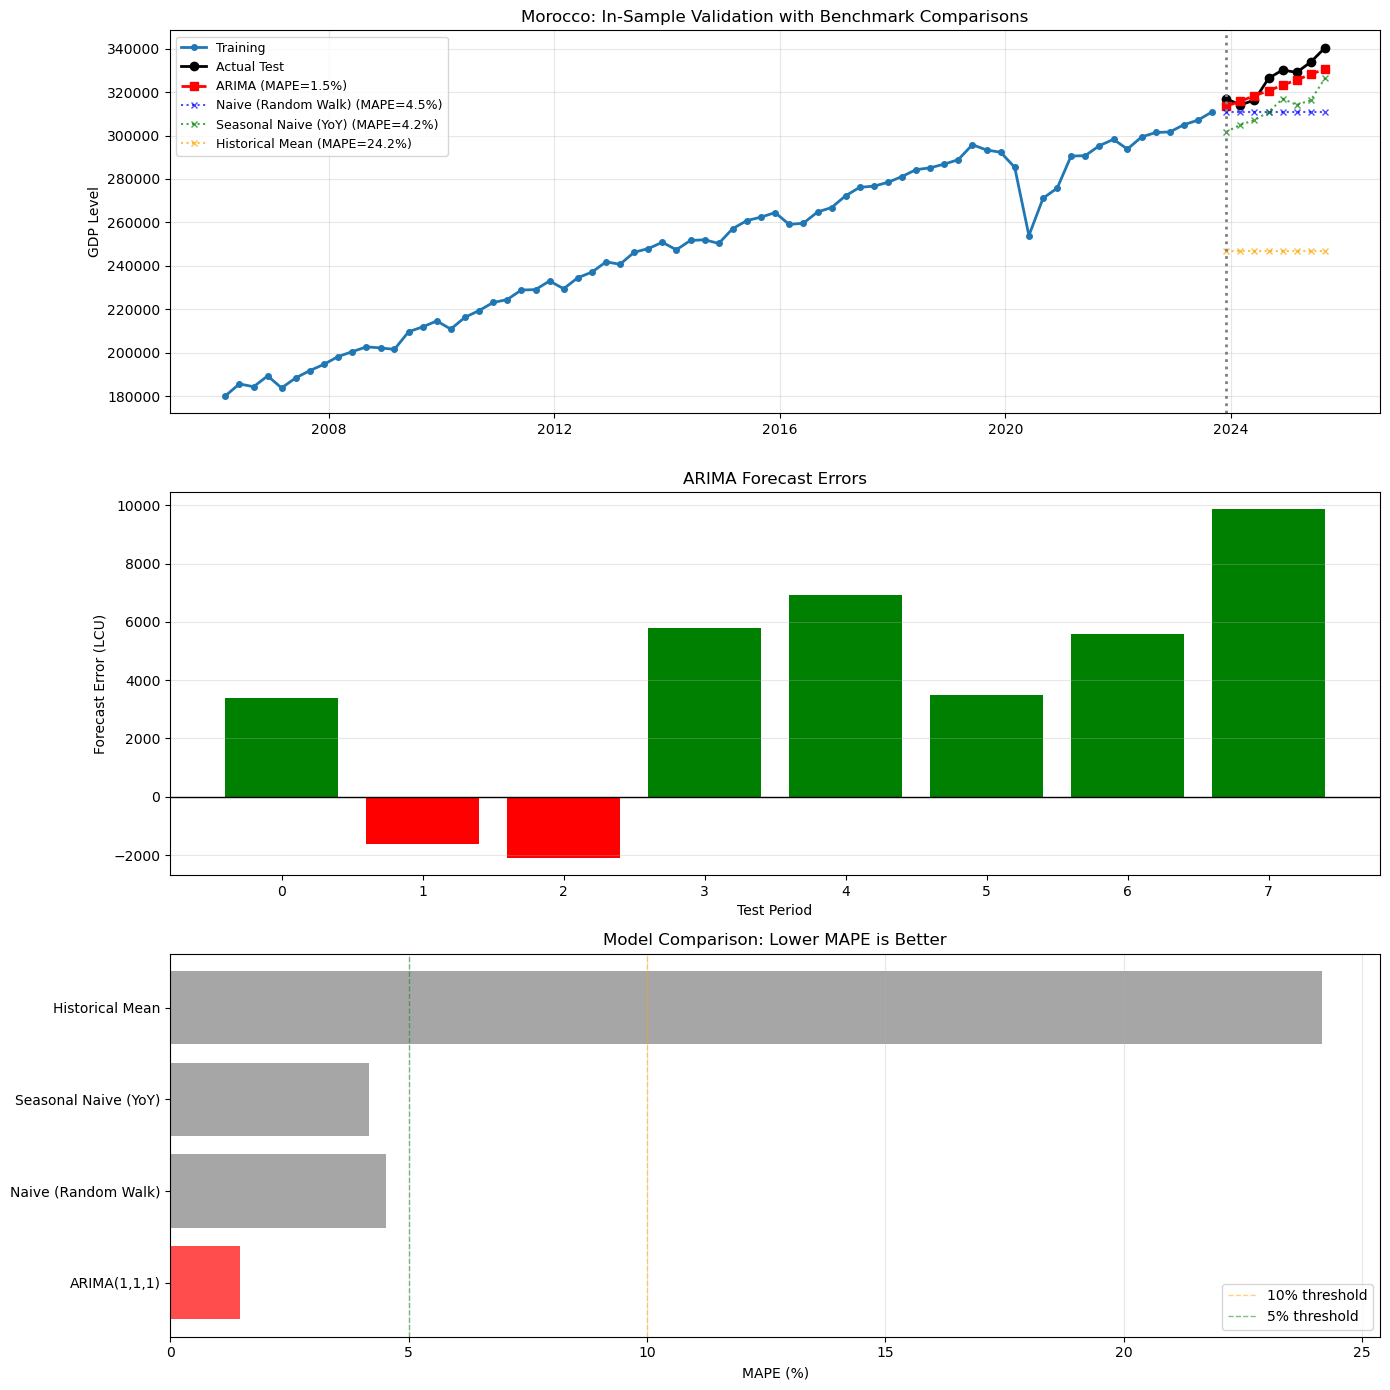


COMPLEMENTARY ANALYSIS: ENSEMBLE APPROACH

In addition to the best single model, we'll also test an ensemble
approach that combines forecasts from the top 5 models.
This provides an alternative forecast for comparison.

ENSEMBLE VALIDATION: Testing on 8 Quarters

Validating ensemble of 5 models:
  ARIMA(1,1,1)
  ARIMA(1,1,2)
  ARIMA(2,1,1)
  ARIMA(1,1,3)
  ARIMA(2,1,2)


C:\Users\932224\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

C:\Users\932224\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.

C:\Users\932224\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

C:\Users\932224\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

C:\Users\932224\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

C:\Users\932224\AppData


Ensemble Validation Results:
  MAPE:                 1.47%
  RMSE:                 5,482
  MAE:                  4,850
  Directional Accuracy: 71.4%
  Quality:              EXCELLENT

SINGLE MODEL VS ENSEMBLE COMPARISON

         Approach            Model  MAPE (%)        RMSE  Dir_Accuracy (%)   Quality
Best Single Model     ARIMA(1,1,1)  1.470073 5486.876166         71.428571 EXCELLENT
 Ensemble (Top 5) 5-Model Ensemble  1.470574 5482.161216         71.428571 EXCELLENT

✓ SINGLE MODEL OUTPERFORMS by 0.0%
  Single Model MAPE: 1.47%
  Ensemble MAPE: 1.47%

  → Recommendation: Use SINGLE MODEL for final forecast


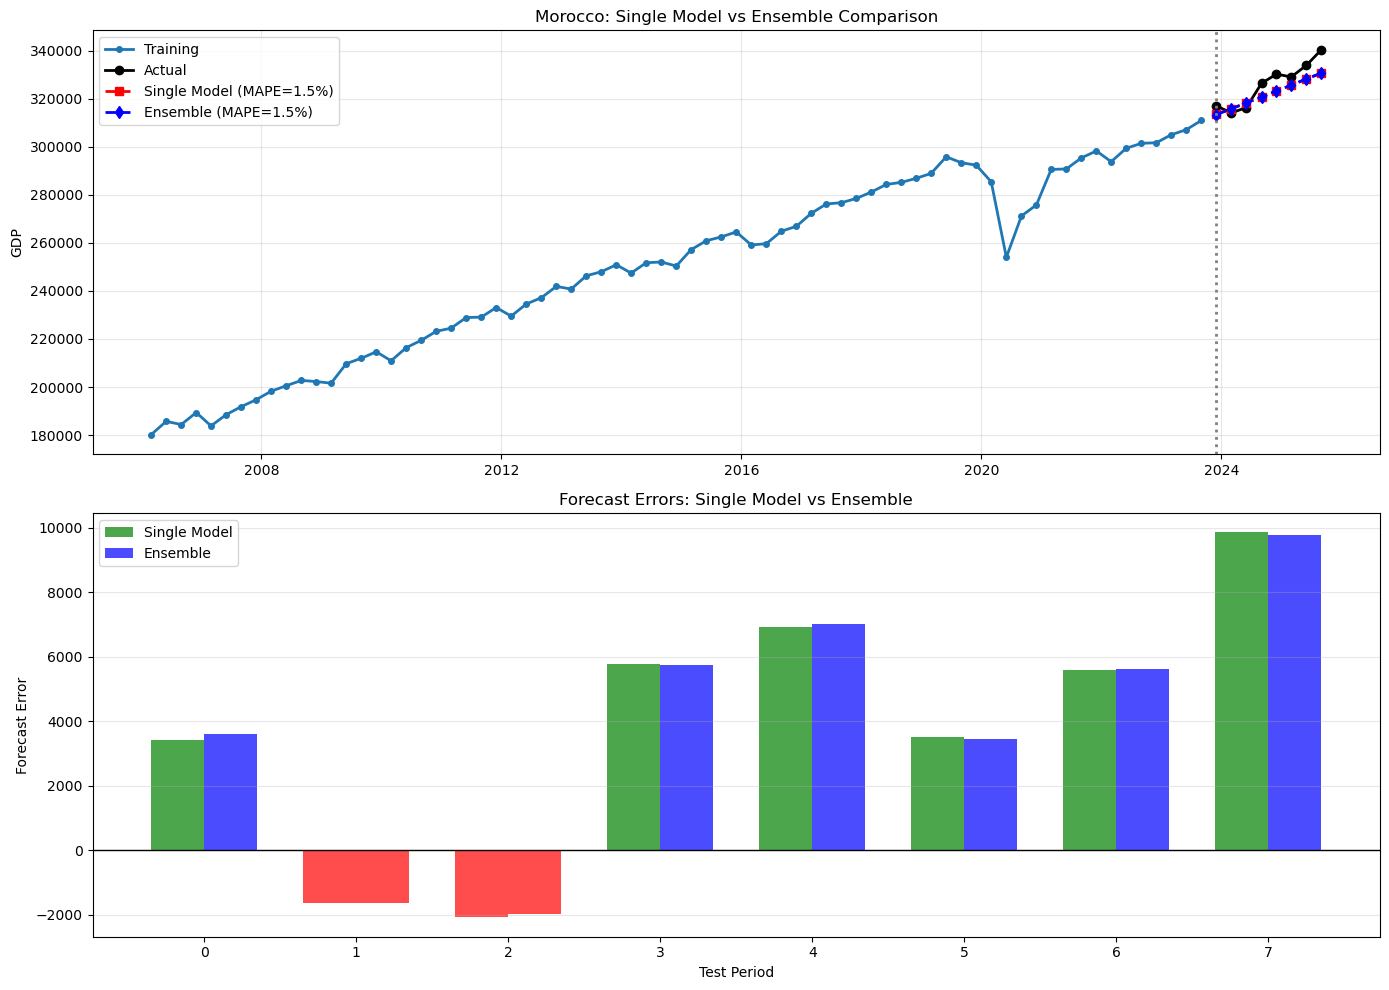


ENSEMBLE B VALIDATION: Cross-Approach Blend

Validating 5 unique models from all approaches


C:\Users\932224\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

C:\Users\932224\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.




Ensemble B Validation Results:
  MAPE:                 1.49%
  RMSE:                 5,570
  Directional Accuracy: 71.4%
  Quality:              EXCELLENT

THREE-WAY COMPARISON: Single Model vs Ensemble A vs Ensemble B

                   Approach            Description  MAPE (%)        RMSE  Dir_Accuracy (%)   Quality
          Single Best Model           ARIMA(1,1,1)  1.470073 5486.876166         71.428571 EXCELLENT
    Ensemble A (Grid Top 5)     5-Model Grid Blend  1.470574 5482.161216         71.428571 EXCELLENT
Ensemble B (Cross-Approach) 5-Model Multi-Approach  1.488409 5569.538275         71.428571 EXCELLENT

✓ BEST APPROACH: Single Best Model
  MAPE: 1.47%
  Quality: EXCELLENT
  Directional Accuracy: 71.4%

  → RECOMMENDATION: Use Single Model for final forecast
     Reason: Simplest approach with best performance


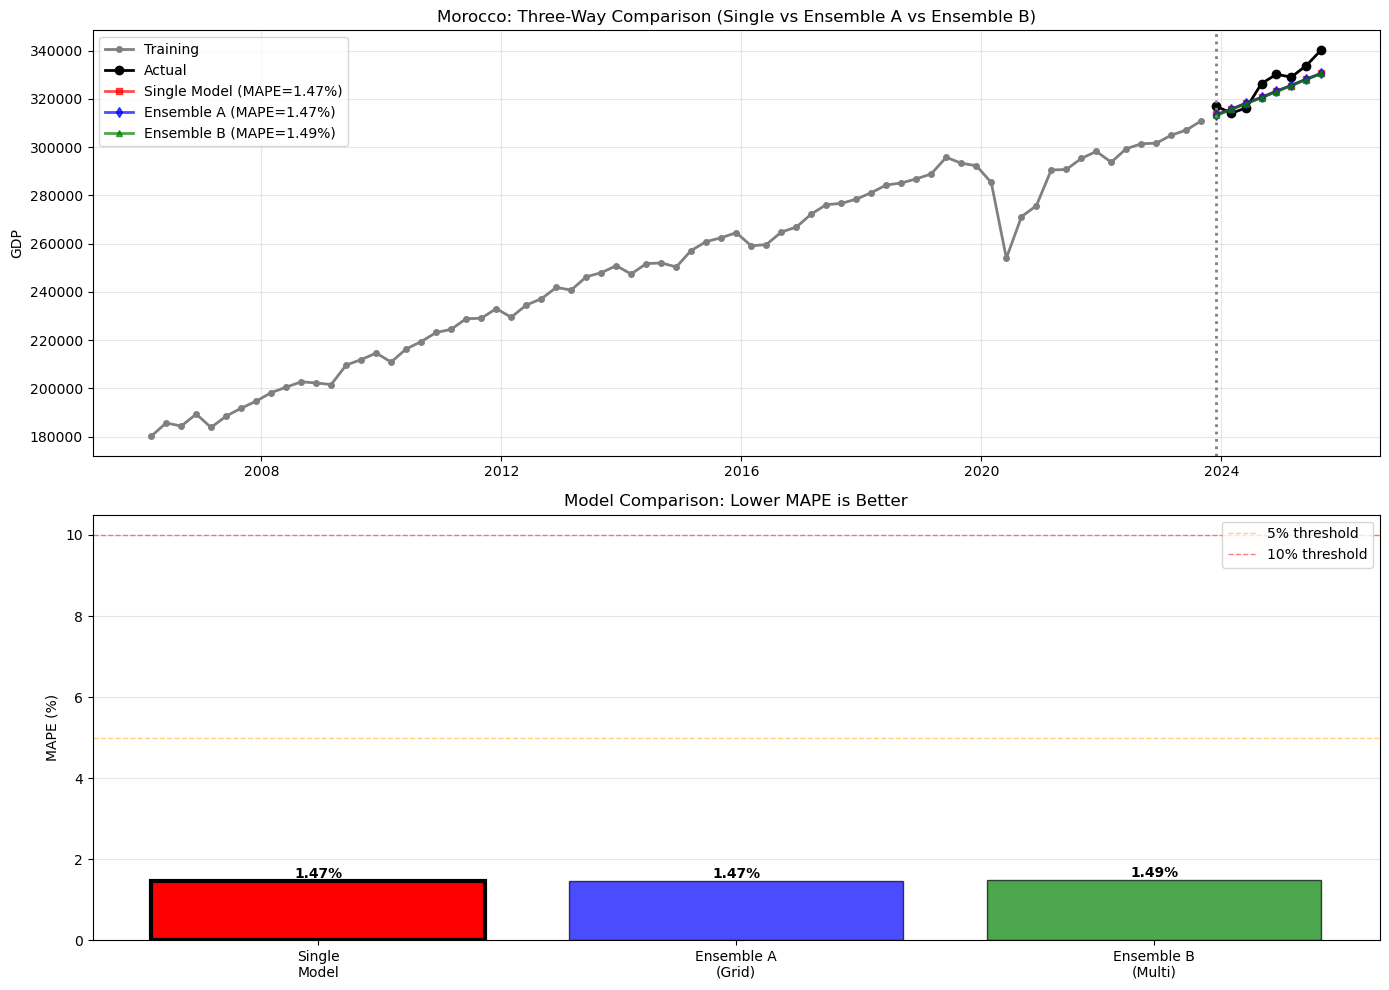


✓ Three-way comparison complete

SECTION 8: OUT-OF-SAMPLE FORECAST

✓ Model validated (Quality: EXCELLENT) - generating 4-quarter forecast


C:\Users\932224\AppData\Local\Temp\ipykernel_32124\210141742.py:5899: FutureWarning:

'Q' is deprecated and will be removed in a future version, please use 'QE' instead.

C:\Users\932224\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

C:\Users\932224\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals




Forecast (2025Q4 to 2026Q3):
--------------------------------------------------------------------------------
  2025Q4: 343,849 (+1.02% growth)
           95% CI: [335,303, 352,612]
  2026Q1: 345,996 (+0.62% growth)
           95% CI: [334,217, 358,191]
  2026Q2: 349,507 (+1.01% growth)
           95% CI: [334,860, 364,795]
  2026Q3: 351,698 (+0.63% growth)
           95% CI: [334,885, 369,356]

FORECAST UNCERTAINTY ANALYSIS

Confidence Interval Metrics:
  Average CI width: 26,422 (7.6% of forecast)
  Min CI width:     17,309 (5.0% of forecast) - 2025-12-31 00:00:00
  Max CI width:     34,471 (9.8% of forecast) - 2026-09-30 00:00:00

Uncertainty Growth Over Forecast Horizon:
  First quarter CI width:  5.0%
  Last quarter CI width:   9.8%
  Uncertainty increase:    4.8 percentage points

UNCERTAINTY ASSESSMENT

✓ LOW uncertainty (avg CI width: 7.6%)
  Interpretation:
    • Reasonable confidence in forecasts
    • Acceptable for policy decisions
    • Monitor actual vs forecast divergen

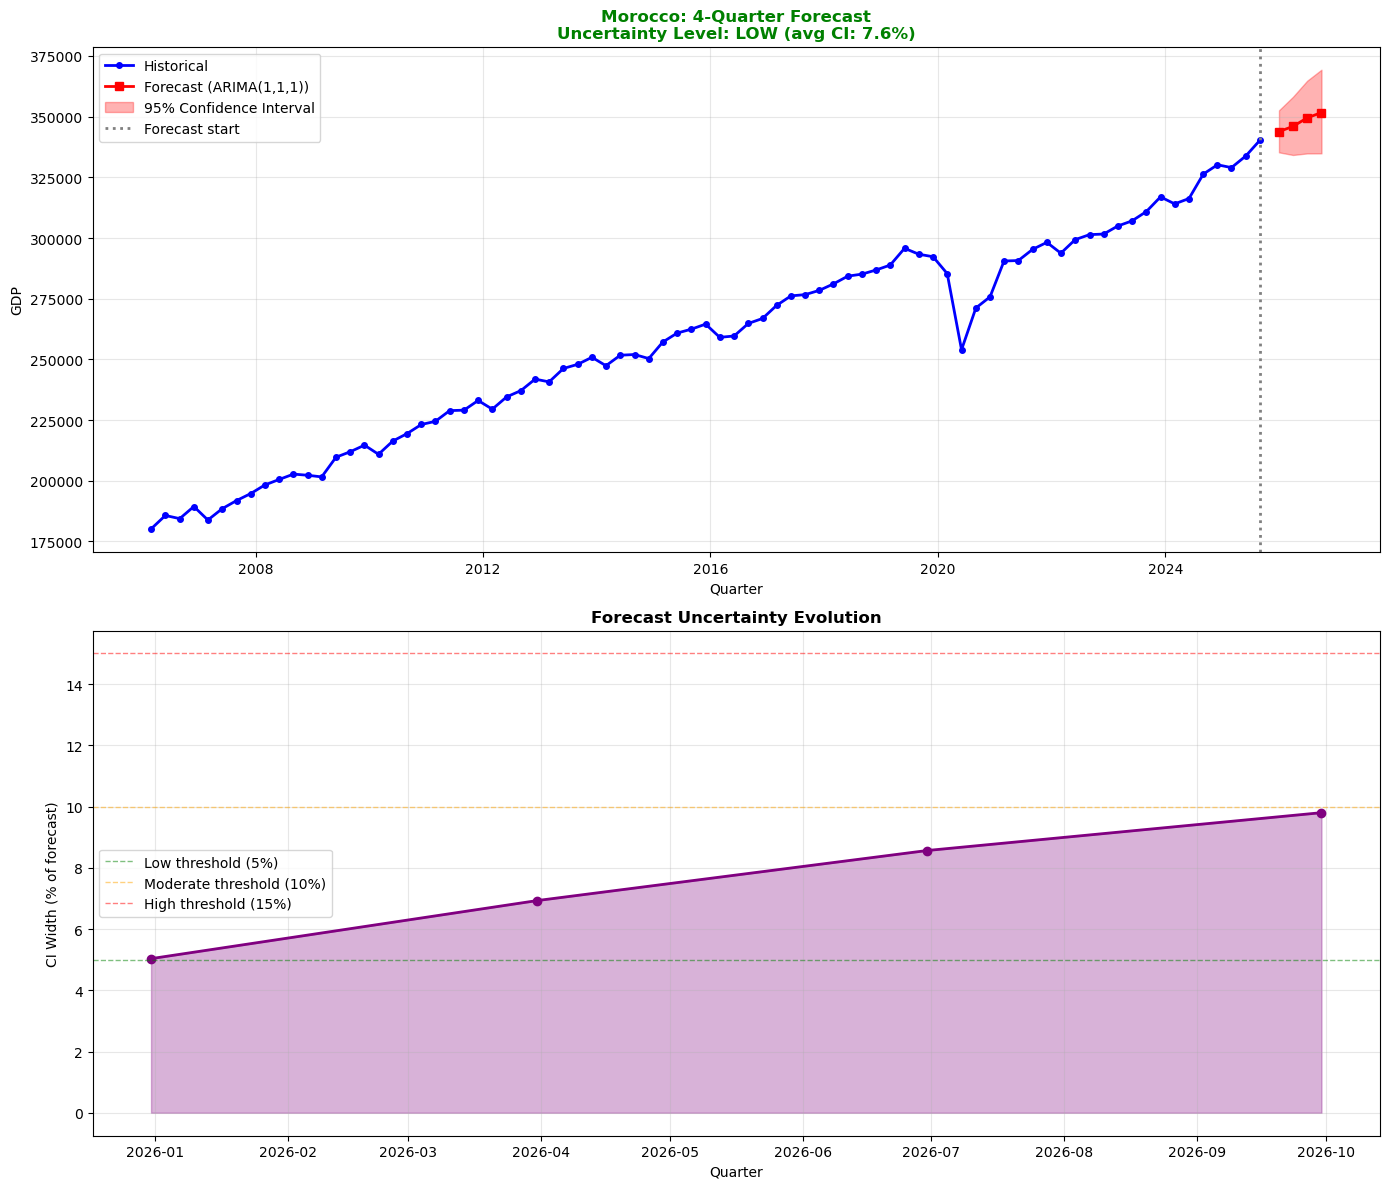


✓ Forecast completed successfully

COMPLEMENTARY: ENSEMBLE OUT-OF-SAMPLE FORECAST

ENSEMBLE FORECAST: Combining Top 5 Models

Models in ensemble:
--------------------------------------------------------------------------------
  ARIMA(1,1,1)                   AIC= -440.54  BIC= -424.05
  ARIMA(1,1,2)                   AIC= -438.58  BIC= -419.73
  ARIMA(2,1,1)                   AIC= -438.37  BIC= -419.52
  ARIMA(1,1,3)                   AIC= -437.17  BIC= -415.96
  ARIMA(2,1,2)                   AIC= -436.89  BIC= -415.68


C:\Users\932224\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

C:\Users\932224\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

C:\Users\932224\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

C:\Users\932224\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.

C:\Users\932224\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

C:\Users\932224\AppData


✓ Successfully generated forecasts from 5 models

Using WEIGHTED AVERAGE (inverse AIC weights):
--------------------------------------------------------------------------------
  ARIMA(1,1,1)                   Weight: 0.485 (AIC=-440.54)
  ARIMA(1,1,2)                   Weight: 0.182 (AIC=-438.58)
  ARIMA(2,1,1)                   Weight: 0.164 (AIC=-438.37)
  ARIMA(1,1,3)                   Weight: 0.090 (AIC=-437.17)
  ARIMA(2,1,2)                   Weight: 0.078 (AIC=-436.89)

ENSEMBLE FORECAST DIAGNOSTICS
  Number of models: 5
  Average forecast spread (std): 0.0012 (log units)
  Average forecast range: 0.0031 (log units)
  Max disagreement at horizon: 3

  ✓ LOW disagreement - models largely agree

✓ Ensemble forecast generated successfully

Ensemble Forecast (2025-12-31 00:00:00 to 2026-09-30 00:00:00):
--------------------------------------------------------------------------------
  2025-12-31 00:00:00: 343,402 (+0.89% growth)
  2026-03-31 00:00:00: 345,878 (+0.72% growth)
  202

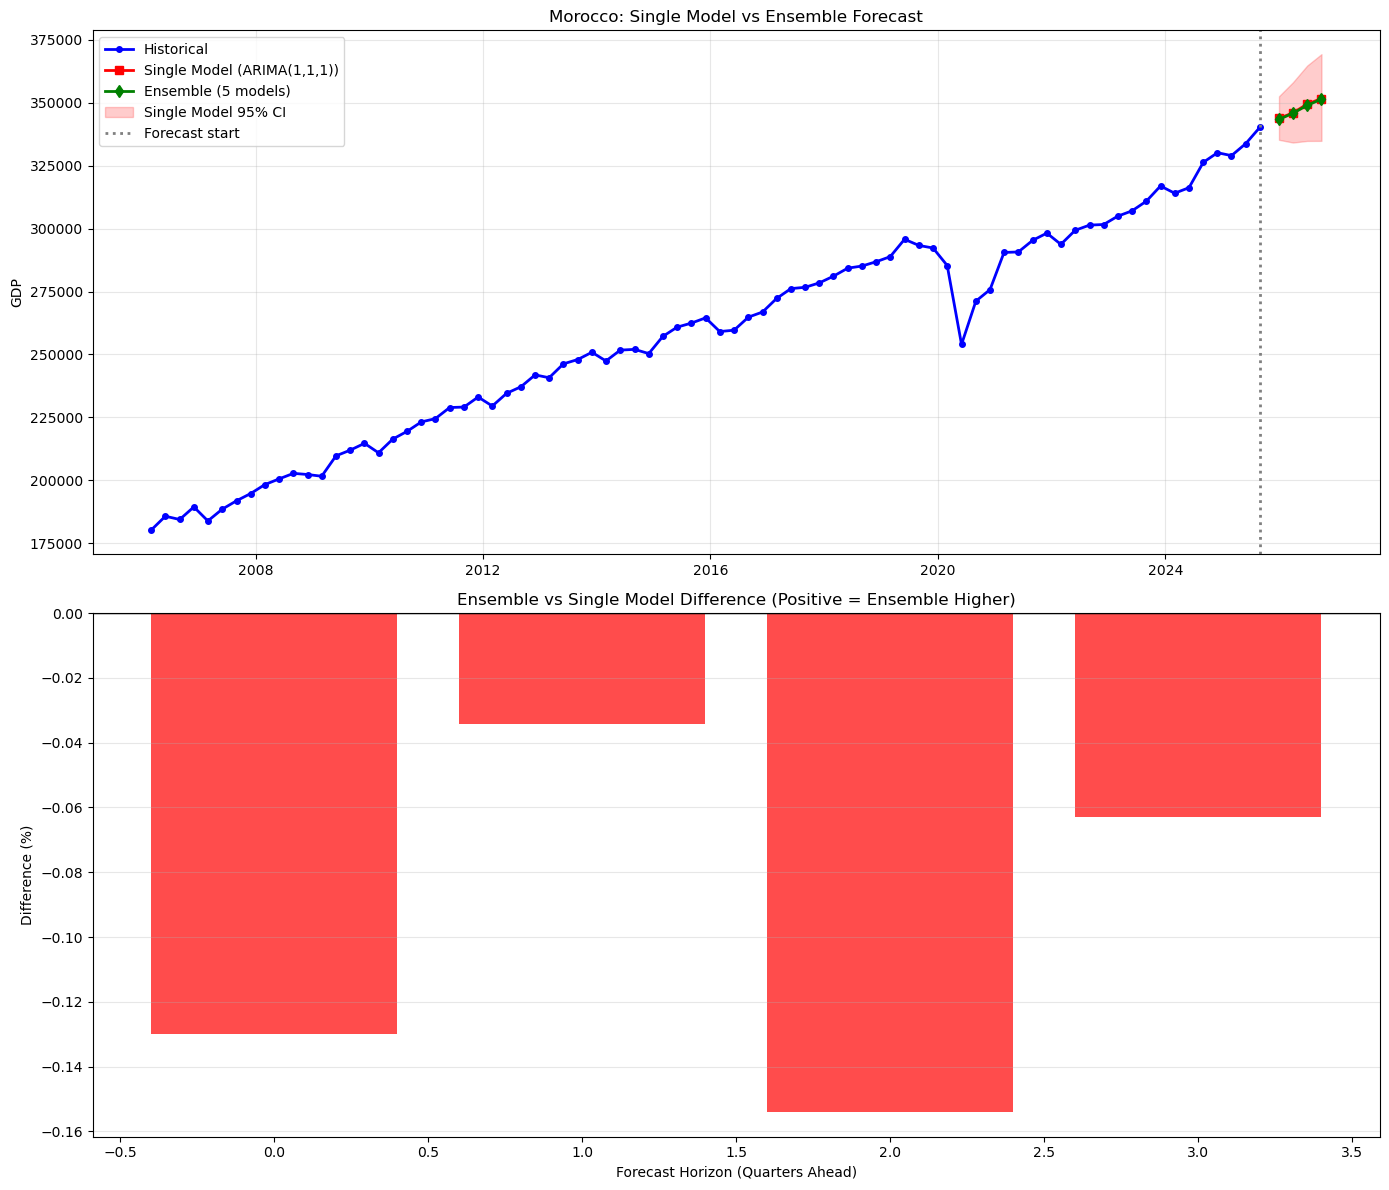


ENSEMBLE B: CROSS-APPROACH BLEND

Combining best models from Visual, Auto-ARIMA, and Grid Search
This ensures model diversity and reduces approach-specific bias.

  ✓ Visual approach: ARIMA(0, 1, 0)
  ✓ Auto-ARIMA: ARIMA(1, 1, 0)

  Adding top 3 from Grid Search:
    ARIMA(1,1,1)                   AIC= -440.54
    ARIMA(1,1,2)                   AIC= -438.58
    ARIMA(2,1,1)                   AIC= -438.37

FINAL ENSEMBLE COMPOSITION: 5 models
  1. ARIMA(0, 1, 0)                 (Source: Visual (ACF/PACF))
  2. ARIMA(1, 1, 0)                 (Source: Auto-ARIMA)
  3. ARIMA(1,1,1)                   (Source: Grid Search)
  4. ARIMA(1,1,2)                   (Source: Grid Search)
  5. ARIMA(2,1,1)                   (Source: Grid Search)


C:\Users\932224\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

C:\Users\932224\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

C:\Users\932224\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

C:\Users\932224\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.

C:\Users\932224\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals




✓ Successfully generated forecasts from 5 models

Using WEIGHTED AVERAGE (inverse AIC weights):
--------------------------------------------------------------------------------
  ARIMA(0, 1, 0)                 Weight: 0.094 (AIC=-436.04, Source: Visual (ACF/PACF))
  ARIMA(1, 1, 0)                 Weight: 0.088 (AIC=-435.91, Source: Auto-ARIMA)
  ARIMA(1,1,1)                   Weight: 0.792 (AIC=-440.30, Source: Grid Search)
  ARIMA(1,1,2)                   Weight: 0.013 (AIC=-432.05, Source: Grid Search)
  ARIMA(2,1,1)                   Weight: 0.013 (AIC=-432.04, Source: Grid Search)

CROSS-APPROACH ENSEMBLE DIAGNOSTICS
  Models from Visual: 1
  Models from Auto-ARIMA: 1
  Models from Grid Search: 3
  Total models: 5
  Average forecast spread (std): 0.0010 (log units)

  ✓ LOW disagreement across approaches

✓ Ensemble B forecast generated successfully

Ensemble B Forecast (2025-12-31 00:00:00 to 2026-09-30 00:00:00):
------------------------------------------------------------------

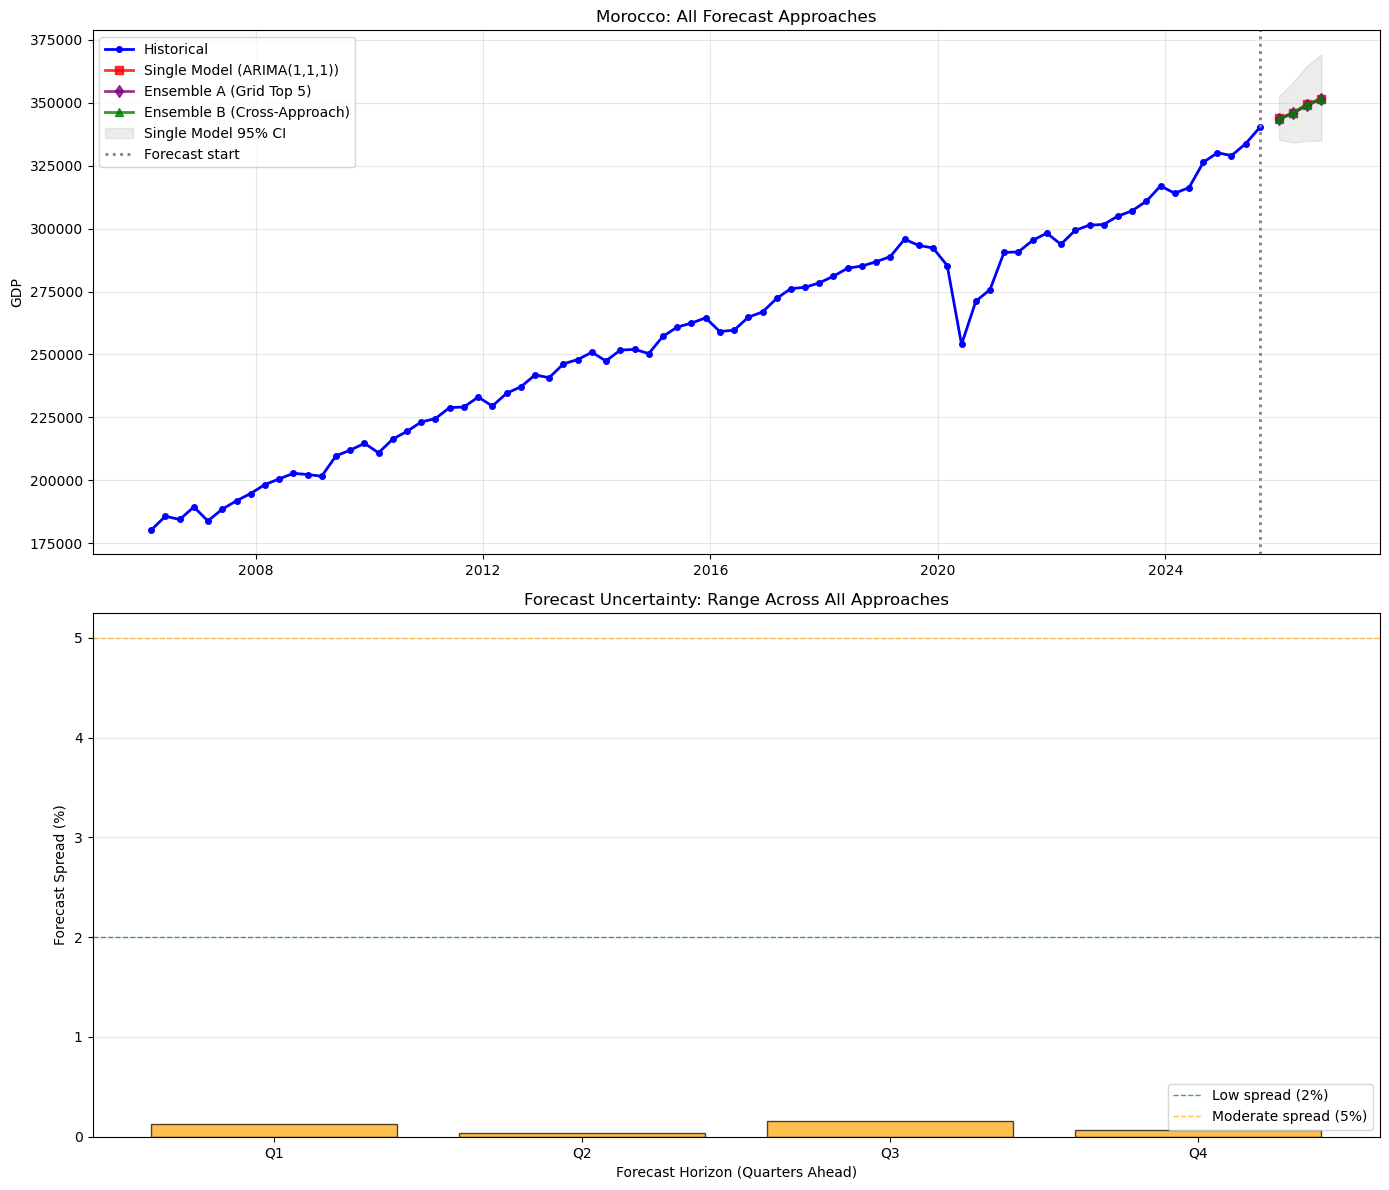


FINAL ANALYSIS SUMMARY

Country: Morocco
Series: GDP
Period: 2006-03-01 00:00:00 to 2025-09-01 00:00:00
Observations: 79 quarters

Data Characteristics:
  Stationarity: I(1)
  Seasonality: Significant

Outlier Treatment:
  Dummies created: 3
  Periods: 2020Q2, 2020Q3, 2021Q1

Model Selection:
  Approach used: Grid Search
  Selected model: ARIMA(1,1,1)
  AIC: -440.54
  BIC: -424.05

Validation Performance:
  MAPE: 1.47%
  RMSE: 5,487
  MAE: 4,849
  Directional Accuracy: 71.4%
  Quality: EXCELLENT
  Beats Benchmarks: YES
  Improvement: 64.7% over best benchmark
  Status: ✓ PASSED

Residual Diagnostics:
  Ljung-Box: ✓ PASS (p=0.548)
  Normality: ✓ PASS (p=0.713)
  Homoskedasticity: ✓ PASS (p=0.316)

ANALYSIS COMPLETE

EXPORTING DIAGNOSTICS TO EXCEL

✓ Diagnostics successfully exported to:
  Results: C:\Users\932224\OneDrive - United Nations\Desktop\Data Science Projects\Morocco GDP nowcasting\Hassan\ARIMA\sent to Sarah\outputs\results\Morocco_GDP_diagnostics_20260210_222004.xlsx
  Vintag

In [9]:
# 3 february 2026 this is the file I am working on for the ARIMA model

# remains to be done: 
# 1. datetime fixing
# 2. no hard coded series names
# 3. vintage comparison => comparison function not tested yet
# 4. remove the "comprehensive" and other emotional wording
# 5. 

# =================================================================================================================
# COMPREHENSIVE QUARTERLY GDP NOWCASTING ANALYSIS
# =================================================================================================================

# ============================================================================
# Step 1: IMPORT LIBRARIES
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
from scipy.stats import jarque_bera
from sklearn.linear_model import LinearRegression

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tools.sm_exceptions import ConvergenceWarning

from itertools import product
import warnings
import os
import re
import json
from datetime import datetime
from typing import Tuple, Dict, Optional

# Suppress warnings
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="Maximum Likelihood optimization failed to converge")
warnings.filterwarnings("ignore", message="force_all_finite' was renamed to 'ensure_all_finite'")
warnings.filterwarnings("ignore", message="Non-invertible starting MA parameters found")

print("="*80)
print("QUARTERLY GDP NOWCASTING ANALYSIS - CENTRAL BANK GRADE")
print("Comprehensive pipeline with outlier management and benchmarking")
print(f"Analysis timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*80)


# ============================================================================
# STEP 2: LOAD DATA
# ============================================================================

print("\n" + "="*80)
print("STEP 1: DATA LOADING")
print("="*80)

PathRawData = r"C:\Users\932224\OneDrive - United Nations\Desktop\Data Science Projects\Morocco GDP nowcasting\Hassan\ARIMA\DataBase\GDP Data\NG_Morocco_GEM_data.xlsx"

try:
    with pd.ExcelFile(PathRawData, engine="openpyxl") as ExcelFile:
        raw_data = pd.read_excel(ExcelFile, sheet_name="q_data")
    
    print(f"✓ Data loaded from: {PathRawData}")
    print(f"  Raw data shape: {raw_data.shape}")
    
except FileNotFoundError:
    print(f"✗ ERROR: File not found at {PathRawData}")
    print("  Please update PathRawData variable with correct path")
    raise
except Exception as e:
    print(f"✗ ERROR loading data: {e}")
    raise

# Show what we loaded
print(f"\nRaw data columns: {list(raw_data.columns)}")
print(f"First row:\n{raw_data.iloc[0]}")

# Rename columns to simple English names
column_mapping = {
    'MAR_NY_GDP_MKTP_I_KN_Q': 'GDP',
    'MAR_NY_GDP_MKTP_I_KD_Q': 'GDP1',
    'MAR_NY_GDP_MKTP_I_CN_Q': 'GDP2',
    'MAR_NY_GDP_MKTP_I_CD_Q': 'GDP3',
}

# Create new dataframe with renamed columns
data = raw_data.copy()
data = data.rename(columns=column_mapping)

print(f"\nAfter renaming:")
print(f"  Columns: {list(data.columns)}")

# Verify Date column exists
if 'Date' not in data.columns:
    print(f"\n✗ ERROR: Date column missing after rename!")
    print(f"  Available columns: {list(data.columns)}")
    raise ValueError("Date column not found")

print(f"✓ Column names standardized")

# Convert Date column to datetime (DD/MM/YYYY format)
print(f"\nConverting Date column...")
print(f"  Sample dates before conversion: {data['Date'].head(3).tolist()}")

data['Date'] = pd.to_datetime(data['Date'], format='%d/%m/%Y', dayfirst=True)

print(f"  Sample dates after conversion: {data['Date'].head(3).tolist()}")

# Set Date as index
data = data.set_index('Date')
print(f"✓ Date set as index")

# Sort by date
data = data.sort_index()
print(f"✓ Data sorted by date")

# Check index
print(f"\nIndex check:")
print(f"  Type: {type(data.index)}")
print(f"  First date: {data.index[0]}")
print(f"  Last date: {data.index[-1]}")
print(f"  Length: {len(data)}")

# Infer and SET frequency (critical for ARIMA to work properly with exog)
inferred_freq = pd.infer_freq(data.index)
print(f"  Inferred frequency: {inferred_freq}")

if inferred_freq is not None:
    data.index.freq = inferred_freq
    print(f"✓ Frequency set from data: {data.index.freq}")
else:
    print(f"⚠ Could not infer frequency - will cause issues with ARIMA exog variables")


# Reorder columns
component_cols = ['GDP', 'GDP1', 'GDP2', 'GDP3']
available_cols = [col for col in component_cols if col in data.columns]
data = data[available_cols]

# Create Period_Label for display (optional - only for charts/tables)
data['Period_Label'] = data.index.to_period('Q').astype(str)

print(f"✓ Date index created: {data.index[0]} to {data.index[-1]}")
print(f"✓ Available series: {', '.join(available_cols)}")

# Verification checks
print("\n" + "="*80)
print("INDEX TYPE CHECK")
print("="*80)
print(f"data.index type: {type(data.index)}")
print(f"data.index[0]: {data.index[0]}")
assert isinstance(data.index, pd.DatetimeIndex), "ERROR: Index is not DatetimeIndex!"
print("✓ Index is correct DatetimeIndex")
print("="*80 + "\n")

print("\n" + "="*80)
print("VERIFICATION: NO PERIOD COLUMN IN DATA")
print("="*80)
assert 'Period' not in data.columns, "ERROR: 'Period' should not be in data.columns!"
assert 'Year' not in data.columns, "ERROR: 'Year' should not be in data.columns!"
assert 'Quarter' not in data.columns, "ERROR: 'Quarter' should not be in data.columns!"
assert isinstance(data.index, pd.DatetimeIndex), "ERROR: Index must be DatetimeIndex!"
print("✓ All checks passed!")
print(f"  Index type: {type(data.index).__name__}")
print(f"  Columns: {list(data.columns)}")
print("="*80 + "\n")

# ============================================================================
# Step 3: SETUP OUTPUT DIRECTORIES
# ============================================================================

# Base project directory (where your script is)
PROJECT_DIR = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd()

# Create organized output structure
OUTPUT_BASE = os.path.join(PROJECT_DIR, 'outputs')
outlier_dir = os.path.join(OUTPUT_BASE, 'outlier_reviews')
RESULTS_DIR = os.path.join(OUTPUT_BASE, 'results')
FIGURES_DIR = os.path.join(OUTPUT_BASE, 'figures')
VINTAGES_DIR = os.path.join(OUTPUT_BASE, 'vintages')

# Create directories
for directory in [OUTPUT_BASE, outlier_dir, RESULTS_DIR, FIGURES_DIR, VINTAGES_DIR]: 
    os.makedirs(directory, exist_ok=True)

print("\n✓ Output directories created:")
print(f"  Outlier reviews: {outlier_dir}")
print(f"  Results: {RESULTS_DIR}")
print(f"  Figures: {FIGURES_DIR}")


# ============================================================================
# Step 4: DATA QUALITY ASSESSMENT
# ============================================================================

print("\n" + "="*80)
print("STEP 2: DATA QUALITY ASSESSMENT")
print("="*80)

print(f"\nDataset shape: {data.shape}")
print(f"Date range: {data.index[0].strftime('%Y-%m-%d')} to {data.index[-1].strftime('%Y-%m-%d')}")
print(f"Period range: {data.index[0].to_period('Q')} to {data.index[-1].to_period('Q')}")
print(f"Total quarters: {len(data)}")

# Missing values analysis
print("\n" + "-"*80)
print("MISSING VALUES ANALYSIS")
print("-"*80)

missing_summary = pd.DataFrame({
    'Column': available_cols,
    'Missing_Count': [data[col].isna().sum() for col in available_cols],
    'Missing_Pct': [data[col].isna().sum() / len(data) * 100 for col in available_cols],
    'First_Valid': [data[col].first_valid_index() for col in available_cols],
    'Last_Valid': [data[col].last_valid_index() for col in available_cols],
    'Coverage': [
        f"{data[col].first_valid_index().to_period('Q')} to {data[col].last_valid_index().to_period('Q')}" 
        if data[col].notna().any() 
        else 'No data' 
        for col in available_cols
    ]
})

print("\n" + missing_summary.to_string(index=False))

# Identify missing value locations
print("\n" + "-"*80)
print("MISSING VALUE LOCATIONS")
print("-"*80)

for col in available_cols:
    if data[col].isna().any():
        missing_dates = data[data[col].isna()].index
        missing_periods = [d.to_period('Q') for d in missing_dates]
        
        if len(missing_periods) <= 10:
            # Show all periods if 10 or fewer
            print(f"\n{col}: {len(missing_periods)} missing quarters")
            print(f"  Periods: {missing_periods}")
        else:
            # Show first 5 and last 5 if more than 10
            print(f"\n{col}: {len(missing_periods)} missing quarters")
            print(f"  First 5: {missing_periods[:5]}")
            print(f"  Last 5: {missing_periods[-5:]}")
    else:
        print(f"\n{col}: No missing values")

# ============================================================================
# Step 5: VISUALIZE MISSING DATA PATTERN
# ============================================================================

print("\n" + "="*80)
print("STEP 3: MISSING DATA VISUALIZATION")
print("="*80)

fig, ax = plt.subplots(figsize=(14, 6))

missing_matrix = data[available_cols].isna().astype(int)
im = ax.imshow(missing_matrix.T, cmap='RdYlGn_r', aspect='auto', interpolation='none')

ax.set_yticks(range(len(available_cols)))
ax.set_yticklabels(available_cols)
ax.set_xlabel('Quarter Index')
ax.set_title('Missing Data Pattern (Red = Missing, Green = Present)', fontweight='bold')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Missing (1) / Present (0)')

plt.tight_layout()
plt.show()

print("✓ Missing data heatmap displayed")

# ============================================================================
# Step 6: PLOT RAW TIME SERIES
# ============================================================================

print("\n" + "="*80)
print("STEP 4: RAW TIME SERIES VISUALIZATION")
print("="*80)

fig = go.Figure()

for col in available_cols:
    if not data[col].isna().all():
        fig.add_trace(go.Scatter(
            x=data.index,
            y=data[col],
            mode='lines+markers',
            name=col,
            visible=True if col == 'GDP' else 'legendonly',
            line=dict(width=2),
            marker=dict(size=4)
        ))

fig.update_layout(
    title='Quarterly GDP and Components (click legend to toggle)',
    xaxis_title='Quarter',
    yaxis_title='Value (Local Currency Units)',
    hovermode='x unified',
    height=600,
    template='plotly_white'
)

fig.show()

print("✓ Interactive time series plot displayed")

# ============================================================================
# Step 7: BASIC STATISTICS FOR GDP
# ============================================================================

print("\n" + "="*80)
print("STEP 5: GDP SERIES SUMMARY STATISTICS")
print("="*80)

gdp_series = data['GDP']

print("\nDescriptive Statistics:")
print("-"*80)
print(gdp_series.describe())

print("\n" + "-"*80)
print("Additional Metrics:")
print("-"*80)
print(f"Missing values:     {gdp_series.isna().sum()} ({gdp_series.isna().sum()/len(gdp_series)*100:.1f}%)")
print(f"First observation:  {gdp_series.first_valid_index()}")
print(f"Last observation:   {gdp_series.last_valid_index()}")
print(f"Coverage:           {gdp_series.notna().sum()} quarters")

# Growth rates
gdp_clean = gdp_series.dropna()
if len(gdp_clean) > 1:
    qoq_growth = gdp_clean.pct_change().dropna() * 100
    yoy_growth = gdp_clean.pct_change(4).dropna() * 100
    
    print("\n" + "-"*80)
    print("Growth Rate Statistics (%):")
    print("-"*80)
    print(f"QoQ growth - Mean:   {qoq_growth.mean():6.2f}%")
    print(f"QoQ growth - Std:    {qoq_growth.std():6.2f}%")
    print(f"QoQ growth - Min:    {qoq_growth.min():6.2f}% ({qoq_growth.idxmin()})")
    print(f"QoQ growth - Max:    {qoq_growth.max():6.2f}% ({qoq_growth.idxmax()})")
    
    if len(yoy_growth) > 0:
        print(f"\nYoY growth - Mean:   {yoy_growth.mean():6.2f}%")
        print(f"YoY growth - Std:    {yoy_growth.std():6.2f}%")
        print(f"YoY growth - Min:    {yoy_growth.min():6.2f}% ({yoy_growth.idxmin()})")
        print(f"YoY growth - Max:    {yoy_growth.max():6.2f}% ({yoy_growth.idxmax()})")

# Extreme observations
print("\n" + "-"*80)
print("Extreme Observations:")
print("-"*80)

top5 = gdp_clean.nlargest(5)
print("\nHighest 5 values:")
for period, value in top5.items():
    print(f"  {period}: {value:,.0f}")

bottom5 = gdp_clean.nsmallest(5)
print("\nLowest 5 values:")
for period, value in bottom5.items():
    print(f"  {period}: {value:,.0f}")

# Largest shocks
if len(qoq_growth) > 0:
    print("\n" + "-"*80)
    print("Largest Shocks (QoQ growth):")
    print("-"*80)
    
    top_positive = qoq_growth.nlargest(3)
    print("\nLargest positive shocks:")
    for period, value in top_positive.items():
        print(f"  {period}: +{value:.2f}%")
    
    top_negative = qoq_growth.nsmallest(3)
    print("\nLargest negative shocks:")
    for period, value in top_negative.items():
        print(f"  {period}: {value:.2f}%")

# Plot GDP with growth rates
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(gdp_clean.index, gdp_clean.values, 'o-', linewidth=2, markersize=4)
axes[0].set_title('Morocco: Quarterly GDP (Level)', fontweight='bold', fontsize=12)
axes[0].set_ylabel('GDP (LCU)')
axes[0].grid(True, alpha=0.3)

covid_start = pd.Period('2020Q1', freq='Q')
covid_end = pd.Period('2020Q4', freq='Q')
if covid_start in gdp_clean.index and covid_end in gdp_clean.index:
    axes[0].axvspan(covid_start, covid_end, 
                    alpha=0.3, color='red', label='COVID-19 Period')
    axes[0].legend()

if len(qoq_growth) > 0:
    axes[1].plot(qoq_growth.index, qoq_growth.values, 'o-', 
                linewidth=2, markersize=4, color='green')
    axes[1].axhline(y=0, color='black', linewidth=1, linestyle='-')
    axes[1].axhline(y=qoq_growth.mean(), color='blue', linewidth=1, linestyle='--', 
                   label=f'Mean: {qoq_growth.mean():.2f}%')
    axes[1].set_title('Quarter-over-Quarter Growth Rate', fontweight='bold', fontsize=12)
    axes[1].set_ylabel('QoQ Growth (%)')
    axes[1].set_xlabel('Quarter')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    
    if covid_start in qoq_growth.index and covid_end in qoq_growth.index:
        axes[1].axvspan(covid_start, covid_end, 
                       alpha=0.3, color='red')

plt.tight_layout()
plt.show()

print("\n✓ GDP level and growth rate plots displayed")

# ============================================================================
# Step 8: DATA READINESS CHECK
# ============================================================================

print("\n" + "="*80)
print("STEP 6: DATA READINESS CHECK")
print("="*80)

# Check for gaps in quarterly data
def check_quarterly_gaps(period_index):
    """Check if there are gaps larger than 4 quarters in the index."""
    if len(period_index) < 2:
        return True
    
    # Convert to list of periods and check consecutive differences
    periods = period_index.tolist()
    max_gap = 0
    
    for i in range(1, len(periods)):
        # Calculate quarter difference between consecutive observations
        gap = (periods[i].year - periods[i-1].year) * 4 + (periods[i].quarter - periods[i-1].quarter)
        max_gap = max(max_gap, gap)
    
    return max_gap <= 4  # Allow maximum 4-quarter gap

readiness_checks = {
    'Sufficient observations': len(gdp_clean) >= 20,
    'Missing data manageable': gdp_series.isna().sum() / len(gdp_series) < 0.20,
    'No constant values': gdp_clean.nunique() > 1,
    'Positive values': (gdp_clean > 0).all(),
    'No extreme gaps': check_quarterly_gaps(gdp_clean.index)
}

all_passed = True
for check, result in readiness_checks.items():
    status = "✓ PASS" if result else "✗ FAIL"
    print(f"{status}: {check}")
    if not result:
        all_passed = False

# Show gap details if failed
if not readiness_checks['No extreme gaps']:
    periods = gdp_clean.index.tolist()
    print("\n  Gap details:")
    for i in range(1, len(periods)):
        gap = (periods[i].year - periods[i-1].year) * 4 + (periods[i].quarter - periods[i-1].quarter)
        if gap > 1:
            print(f"    Gap of {gap} quarters between {periods[i-1]} and {periods[i]}")

if all_passed:
    print("\n" + "="*80)
    print("✓ DATA READY FOR ARIMA ANALYSIS")
    print("="*80)
else:
    print("\n" + "="*80)
    print("⚠ DATA QUALITY ISSUES DETECTED")
    print("="*80)
    user_continue = input("\nContinue anyway? (y/n): ").strip().lower()
    if user_continue != 'y':
        print("Analysis stopped.")
        raise SystemExit

print("\n✓ Data validated and ready for modeling")


# ============================================================================
# Step 9: OUTLIER DETECTION & MANAGEMENT SYSTEM
# ============================================================================

# ============================================================================
# ROBUST OUTLIER DETECTION: THREE-METHOD CONSENSUS
# ============================================================================

def detect_outliers_iqr(series, multiplier=1.5):
    """
    IQR method - good for asymmetric distributions.
    
    Parameters:
    -----------
    series : pd.Series
        Time series to analyze
    multiplier : float
        IQR multiplier (1.5 = standard, 3.0 = very conservative)
    
    Returns:
    --------
    pd.Series : Boolean mask of outliers
    """
    series_clean = series.dropna()
    
    Q1 = series_clean.quantile(0.25)
    Q3 = series_clean.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    
    outliers = (series_clean < lower_bound) | (series_clean > upper_bound)
    
    return outliers


def detect_outliers_modified_zscore(series, threshold=3.5):
    """
    Modified Z-score using MAD (Median Absolute Deviation).
    Robust alternative to standard z-score - not affected by extreme outliers.
    
    Parameters:
    -----------
    series : pd.Series
        Time series to analyze
    threshold : float
        MAD score threshold (3.5 ≈ z-score of 3 for normal data)
    
    Returns:
    --------
    pd.Series : Boolean mask of outliers
    """
    series_clean = series.dropna()
    
    median = series_clean.median()
    mad = np.median(np.abs(series_clean - median))
    
    # Avoid division by zero
    if mad < 1e-10:
        mad = np.mean(np.abs(series_clean - median))
        if mad < 1e-10:
            # All values identical - no outliers
            return pd.Series(False, index=series_clean.index)
    
    # Modified z-scores (1.4826 makes MAD comparable to standard deviation)
    modified_z_scores = 0.6745 * (series_clean - median) / mad
    
    outliers = np.abs(modified_z_scores) > threshold
    
    return outliers


def detect_outliers_isolation_forest(series, contamination=0.05, random_state=42):
    """
    Isolation Forest - machine learning approach to anomaly detection.
    Good at finding complex outlier patterns without distribution assumptions.
    
    Parameters:
    -----------
    series : pd.Series
        Time series to analyze
    contamination : float
        Expected proportion of outliers (0.05 = 5%)
    random_state : int
        Random seed for reproducibility
    
    Returns:
    --------
    pd.Series : Boolean mask of outliers
    """
    from sklearn.ensemble import IsolationForest
    
    series_clean = series.dropna()
    
    # Need at least 10 observations for meaningful results
    if len(series_clean) < 10:
        return pd.Series(False, index=series_clean.index)
    
    # Reshape for sklearn
    X = series_clean.values.reshape(-1, 1)
    
    try:
        iso_forest = IsolationForest(
            contamination=contamination,
            random_state=random_state,
            n_estimators=100,
            max_samples='auto',
            bootstrap=False
        )
        
        predictions = iso_forest.fit_predict(X)
        outliers = pd.Series(predictions == -1, index=series_clean.index)
        
        return outliers
        
    except Exception as e:
        print(f"    ⚠ Isolation Forest failed: {e}")
        # Return no outliers if method fails
        return pd.Series(False, index=series_clean.index)


def detect_outliers_multiple_methods(series, 
                                     iqr_multiplier=1.5,
                                     mad_threshold=3.5,
                                     isolation_contamination=0.05,
                                     consensus_threshold=2):
    """
    Combine three robust outlier detection methods using vote counting.
    
    Methods:
    1. IQR: Good for asymmetric distributions
    2. Modified Z-score (MAD): Robust to extreme outliers
    3. Isolation Forest: Finds complex patterns without assumptions
    
    Parameters:
    -----------
    series : pd.Series
        Time series to analyze (typically log-differenced GDP)
    iqr_multiplier : float
        IQR multiplier (1.5 = standard, higher = more conservative)
    mad_threshold : float
        MAD score threshold (3.5 ≈ z=3 for normal data)
    isolation_contamination : float
        Expected proportion of outliers (0.05 = 5%)
    consensus_threshold : int
        Minimum votes needed (2 = majority, 3 = unanimous)
    
    Returns:
    --------
    dict with:
        - 'outliers_final': Consensus outlier mask
        - 'outliers_iqr': IQR method results
        - 'outliers_mad': MAD method results
        - 'outliers_isolation': Isolation Forest results
        - 'vote_counts': Per-point vote count (0-3)
        - 'summary_df': DataFrame with detailed results
    """
    series_clean = series.dropna()
    
    print(f"\n  Running three-method outlier detection:")
    print(f"    IQR multiplier: {iqr_multiplier}")
    print(f"    MAD threshold: {mad_threshold}")
    print(f"    Isolation contamination: {isolation_contamination}")
    print(f"    Consensus threshold: {consensus_threshold} votes")
    
    # =========================================================================
    # RUN THREE METHODS
    # =========================================================================
    
    outliers_iqr = detect_outliers_iqr(series_clean, multiplier=iqr_multiplier)
    outliers_mad = detect_outliers_modified_zscore(series_clean, threshold=mad_threshold)
    
    # Adjust contamination for sample size
    n = len(series_clean)
    if n < 50:
        adjusted_contamination = min(isolation_contamination, 0.10)  # Max 10% for small samples
    else:
        adjusted_contamination = isolation_contamination
    
    outliers_isolation = detect_outliers_isolation_forest(
        series_clean, 
        contamination=adjusted_contamination
    )
    
    # =========================================================================
    # VOTE COUNTING
    # =========================================================================
    
    vote_counts = (
        outliers_iqr.astype(int) + 
        outliers_mad.astype(int) + 
        outliers_isolation.astype(int)
    )
    
    outliers_final = vote_counts >= consensus_threshold
    
    # =========================================================================
    # RESULTS SUMMARY
    # =========================================================================
    
    print(f"\n  Detection Results:")
    print(f"    IQR:              {outliers_iqr.sum()} outliers")
    print(f"    Modified Z (MAD): {outliers_mad.sum()} outliers")
    print(f"    Isolation Forest: {outliers_isolation.sum()} outliers")
    print(f"    → Consensus ({consensus_threshold}+ votes): {outliers_final.sum()} outliers")
    
    # Vote breakdown
    for votes in range(4):
        count = (vote_counts == votes).sum()
        if count > 0:
            print(f"      {votes} votes: {count} points")
    
    # =========================================================================
    # CREATE DETAILED DATAFRAME
    # =========================================================================
    
    summary_df = pd.DataFrame({
        'value': series_clean.values,
        'iqr_outlier': outliers_iqr.values,
        'mad_outlier': outliers_mad.values,
        'isolation_outlier': outliers_isolation.values,
        'vote_count': vote_counts.values,
        'is_outlier': outliers_final.values
    }, index=series_clean.index)
    
    # Calculate magnitude (distance from median in std units)
    median = series_clean.median()
    std = series_clean.std()
    summary_df['magnitude'] = (series_clean - median) / std
    
    # Detection method description
    def get_method_description(row):
        methods = []
        if row['iqr_outlier']:
            methods.append('IQR')
        if row['mad_outlier']:
            methods.append('MAD')
        if row['isolation_outlier']:
            methods.append('Isolation')
        
        if len(methods) == 0:
            return 'None'
        elif len(methods) == 3:
            return 'All Methods (3/3)'
        elif len(methods) == 2:
            return f'{" + ".join(methods)} (2/3)'
        else:
            return f'{methods[0]} only (1/3)'
    
    summary_df['detection_method'] = summary_df.apply(get_method_description, axis=1)
    
    # Interpretation
    summary_df['interpretation'] = summary_df.apply(
        lambda row: 'Large Negative Shock' if row['is_outlier'] and row['value'] < 0
        else ('Large Positive Surge' if row['is_outlier'] and row['value'] > 0
        else 'Normal'), axis=1
    )
    
    # =========================================================================
    # RETURN COMPREHENSIVE RESULTS
    # =========================================================================
    
    return {
        'outliers_final': outliers_final,
        'outliers_iqr': outliers_iqr,
        'outliers_mad': outliers_mad,
        'outliers_isolation': outliers_isolation,
        'vote_counts': vote_counts,
        'summary_df': summary_df
    }

def export_outliers_for_review(outliers_df, filepath, country_name, series_name):
    """Export detected outliers to Excel for economist review."""
    if len(outliers_df) == 0:
        print("\n✓ No outliers detected - skipping export")
        return None
    
    review_df = outliers_df.copy()
    # outliers_df has DatetimeIndex
    review_df['Date'] = review_df.index
    review_df['Period'] = review_df.index.to_period('Q').astype(str)
    review_df = review_df.reset_index(drop=True)
    
    review_df['keep_as_outlier'] = True
    review_df['economist_notes'] = ''
    review_df['suggested_category'] = review_df.apply(
        lambda row: 'COVID-19' if '2020' in str(row['Period']) or '2021' in str(row['Period'])
        else 'Economic Shock', axis=1
    )
    cols_order = [
        'Date', 'Period', 'value', 'magnitude', 
        'vote_count', 'detection_method',
        'iqr_outlier', 'mad_outlier', 'isolation_outlier',
        'interpretation', 'keep_as_outlier', 'suggested_category', 'economist_notes'
    ]
    review_df = review_df[cols_order]
    
    with pd.ExcelWriter(filepath, engine='openpyxl') as writer:
        review_df.to_excel(writer, sheet_name='Outliers_Review', index=False)
        
        doc_df = pd.DataFrame({
            'Parameter': [
                'Country', 'Series', 'Detection Date', 
                'Total Outliers Detected', 
                'High Confidence (3/3 votes)',
                'Medium Confidence (2/3 votes)',
                'Detection Methods',
                'Instructions'
            ],
            'Value': [
                country_name,
                series_name,
                pd.Timestamp.now().strftime('%Y-%m-%d %H:%M'),
                len(review_df),
                len(review_df[review_df['vote_count'] == 3]),
                len(review_df[review_df['vote_count'] == 2]),
                'IQR + Modified Z-score (MAD) + Isolation Forest',
                'Review each outlier. Set keep_as_outlier=FALSE to exclude. Vote count indicates confidence.'
            ]
        })
        doc_df.to_excel(writer, sheet_name='Documentation', index=False)
    
    print(f"\n✓ Outliers exported to: {filepath}")
    print(f"  Total detected: {len(review_df)}")
    print(f"    High confidence (3/3 votes): {len(review_df[review_df['vote_count'] == 3])}")
    print(f"    Medium confidence (2/3 votes): {len(review_df[review_df['vote_count'] == 2])}")
    print(f"  Periods: {', '.join(review_df['Period'].astype(str).values)}")
    
    return filepath


def import_reviewed_outliers(filepath):
    """Import economist-reviewed outliers from Excel."""
    review_df = pd.read_excel(filepath, sheet_name='Outliers_Review')
    validated = review_df[review_df['keep_as_outlier'] == True].copy()
    
    # Use the Date column directly (already in datetime format from Excel)
    if 'Date' in validated.columns:
        validated['Date'] = pd.to_datetime(validated['Date'])
        validated = validated.set_index('Date')
    elif 'Period' in validated.columns:
        # Fallback: convert Period strings to datetime
        validated['Date'] = pd.to_datetime(validated['Period'])
        validated = validated.set_index('Date')
    
    print(f"\n✓ Reviewed outliers imported: {len(validated)} kept for modeling")
    if len(validated) < len(review_df):
        print(f"  Excluded by economist: {len(review_df) - len(validated)}")
    
    return validated


#def create_outlier_dummies(gdp_series, validated_outliers):
#    """Create dummy variables for each validated outlier."""
#    if len(validated_outliers) == 0:
#        return pd.DataFrame(index=gdp_series.index)
    
#    dummies = pd.DataFrame(0, index=gdp_series.index, columns=[])
    
#    for period in validated_outliers.index:
        # Handle both DatetimeIndex and PeriodIndex
#        if isinstance(period, pd.Period):
            # Already a Period - convert directly to string
#            period_str = period.strftime('%Y-Q%q')
#        elif isinstance(period, pd.Timestamp):
            # It's a Timestamp - convert to Period first
#            period_str = period.to_period('Q').strftime('%Y-Q%q')
#        else:
            # Fallback - try to convert to string directly
#            period_str = str(period)
        
        # Create column name like "outlier_2020Q2"
#        col_name = f"outlier_{period_str}".replace('-', '')
#        dummies[col_name] = 0
#        dummies.loc[period, col_name] = 1
    
#    print(f"\n✓ Created {len(dummies.columns)} outlier dummy variables:")
#    for col in dummies.columns:
#        print(f"    {col}")
    
#    return dummies


def outlier_management_workflow(
    gdp_series,
    country_name,
    series_name,
    output_dir='.',
    enable_outlier_detection=True,
    detection_method='consensus',
    consensus_threshold=2,
    auto_accept=False
):
    """Complete outlier detection and management workflow."""
    print("\n" + "="*80)
    print("OUTLIER DETECTION & MANAGEMENT")
    print("="*80)
    
    if not enable_outlier_detection:
        print("\n⚠ Outlier detection DISABLED")
        return pd.DataFrame(index=gdp_series.index)

    # Use the series as-is (should already be log-diff)
    diff_log_gdp = gdp_series.dropna()
    
    print(f"\n✓ Analyzing series: {series_name}")
    print(f"  Observations: {len(diff_log_gdp)}")
    print(f"  Mean: {diff_log_gdp.mean():.6f}")
    print(f"  Std Dev: {diff_log_gdp.std():.6f}")
    print(f"  Min: {diff_log_gdp.min():.6f}")
    print(f"  Max: {diff_log_gdp.max():.6f}")
    
    print(f"\nDetecting outliers using three-method consensus:")
    print(f"  Methods: IQR + Modified Z-score (MAD) + Isolation Forest")
    print(f"  Consensus rule: {consensus_threshold} out of 3 votes required")
    
    outlier_results = detect_outliers_multiple_methods(
        series=diff_log_gdp,
        iqr_multiplier=1.0, # ← CHANGE: Less sensitive (was 1.5)
        mad_threshold=2.5, # ← CHANGE: Less sensitive (was 3.5)
        isolation_contamination=0.10, # ← CHANGE: Less sensitive (was 0.05)
        consensus_threshold=consensus_threshold
    )
    
    outliers_df = outlier_results['summary_df'][outlier_results['summary_df']['is_outlier']]
    
    # Show breakdown by vote count
    print(f"\nOutlier Breakdown by Confidence:")
    for votes in [3, 2]:
        subset = outliers_df[outliers_df['vote_count'] == votes]
        if len(subset) > 0:
            print(f"\n  {votes}/3 votes ({len(subset)} outliers):")
            for idx, row in subset.iterrows():
                period = idx.to_period('Q')
                print(f"    {period}: {row['value']:.4f} ({row['detection_method']})")
    
    if len(outliers_df) == 0:
        print("\n✓ No outliers detected")
        return pd.DataFrame(index=gdp_series.index)
    
    export_path = os.path.join(output_dir, f'{country_name}_outliers_review.xlsx')
    export_outliers_for_review(outliers_df, export_path, country_name, series_name)
    
    if auto_accept:
        print("\n✓ AUTO-ACCEPT mode: Using all detected outliers")
        validated_outliers = outliers_df
    else:
        print("\n" + "-"*80)
        print("ECONOMIST REVIEW REQUIRED")
        print("-"*80)
        print(f"1. Open: {export_path}")
        print(f"2. Review each outlier (set keep_as_outlier=FALSE to exclude)")
        print(f"3. Save the file")
        print(f"4. Return here to continue")
        print("-"*80)
        
        user_choice = input("\n[1] Import reviewed file  [2] Auto-accept all  [3] Skip outliers\nChoice: ").strip()
        
        if user_choice == '1':
            try:
                validated_outliers = import_reviewed_outliers(export_path)
            except Exception as e:
                print(f"\n⚠ Error: {e}. Auto-accepting all outliers.")
                validated_outliers = outliers_df
        elif user_choice == '2':
            validated_outliers = outliers_df
        else:
            print("\n✓ Skipping outlier modeling")
            return pd.DataFrame(index=gdp_series.index)
    
    outlier_dummies = create_outlier_dummies(gdp_series, validated_outliers)
    
    return outlier_dummies


# ============================================================================
# Step 10: BENCHMARK MODELS FUNCTION
# ============================================================================

def calculate_benchmark_forecasts(train, test, log_gdp_full):
    """Calculate naive and seasonal naive benchmarks."""
    benchmarks = {}
    
    # Naive forecast
    naive_forecast_log = pd.Series(train.iloc[-1], index=test.index)
    naive_forecast = np.exp(naive_forecast_log)
    actual = np.exp(test)
    
    naive_mape = np.mean(np.abs((actual - naive_forecast) / actual)) * 100
    naive_rmse = np.sqrt(np.mean((actual - naive_forecast)**2))
    
    benchmarks['Naive (Random Walk)'] = {
        'forecast': naive_forecast,
        'mape': naive_mape,
        'rmse': naive_rmse,
        'description': 'Last observation carried forward'
    }
    
    # Seasonal naive
    if len(train) >= 4:
        seasonal_naive_forecast = pd.Series(index=test.index, dtype=float)
        for i, period in enumerate(test.index):
            lag_4_idx = len(train) + i - 4
            if lag_4_idx >= 0:
                seasonal_naive_forecast.loc[period] = log_gdp_full.iloc[lag_4_idx]
            else:
                seasonal_naive_forecast.loc[period] = train.iloc[-1]
        
        seasonal_naive_forecast_level = np.exp(seasonal_naive_forecast)
        seasonal_mape = np.mean(np.abs((actual - seasonal_naive_forecast_level) / actual)) * 100
        seasonal_rmse = np.sqrt(np.mean((actual - seasonal_naive_forecast_level)**2))
        
        benchmarks['Seasonal Naive (YoY)'] = {
            'forecast': seasonal_naive_forecast_level,
            'mape': seasonal_mape,
            'rmse': seasonal_rmse,
            'description': 'Same quarter from previous year'
        }
    
    # Mean forecast
    mean_forecast_log = pd.Series(train.mean(), index=test.index)
    mean_forecast = np.exp(mean_forecast_log)
    mean_mape = np.mean(np.abs((actual - mean_forecast) / actual)) * 100
    mean_rmse = np.sqrt(np.mean((actual - mean_forecast)**2))
    
    benchmarks['Historical Mean'] = {
        'forecast': mean_forecast,
        'mape': mean_mape,
        'rmse': mean_rmse,
        'description': 'Average of training period'
    }
    
    return benchmarks


# ============================================================================
# Step 11: MISSING DATA HELPERS
# ============================================================================

def diagnose_missing_data(data: pd.DataFrame):
    """Diagnose missing data patterns."""
    df = data.copy()
    num = df.select_dtypes(include=[np.number])
    summary = pd.DataFrame({
        "Missing_Count": num.isna().sum(),
        "Missing_Pct": num.isna().mean() * 100,
        "First_Valid_Idx": {c: num[c].first_valid_index() for c in num.columns},
        "Last_Valid_Idx":  {c: num[c].last_valid_index()  for c in num.columns},
    })
    stats_dict = {
        "rows": int(len(df)),
        "cols_numeric": int(num.shape[1]),
        "any_missing": bool(num.isna().any().any()),
        "missing_pct_overall": float(num.isna().mean().mean() * 100),
    }
    return summary, stats_dict


def handle_missing_data_comprehensive(data: pd.DataFrame, auto_mode: bool = True):
    """Handle missing data with interpolation and forward/backward fill."""
    df = data.copy()

    num = df.select_dtypes(include=[np.number]).copy()
    miss_overall = float(num.isna().mean().mean())

    if miss_overall == 0.0:
        handler = "no_missing"
        action = "No missing values detected – no imputation applied"
        if time_col in data.columns:
            df = df.reset_index()
        return df, handler, action

    if miss_overall <= 0.10:
        try:
            num = num.interpolate(method="time", limit_direction="both")
        except Exception:
            num = num.interpolate(limit_direction="both")
        num = num.ffill().bfill()
        handler = "interp_then_ffill_bfill"
        action = "Linear (time) interpolation + forward/backward fill (≤10% missing)"
    else:
        num = num.ffill().bfill()
        handler = "ffill_bfill_only"
        action = "Forward/backward fill only (>10% missing)"

    df.loc[:, num.columns] = num
    return df, handler, action

# ============================================================================
# Step 11B: STATIONARITY TEST HELPER FUNCTION
# ============================================================================

def run_stationarity_tests_enhanced(series, name):
    """
    Run ADF and KPSS stationarity tests with detailed interpretation.
    
    Parameters:
    -----------
    series : pd.Series
        Time series to test
    name : str
        Description of the series being tested
    
    Returns:
    --------
    tuple : (adf_result, kpss_result, stationarity_conclusion)
    """
    series_clean = series.dropna()
    
    print(f"\n{name}")
    print("-"*80)
    
    # ADF Test
    adf_result = adfuller(series_clean, autolag='AIC')
    print(f"ADF Test:")
    print(f"  Statistic: {adf_result[0]:.4f}")
    print(f"  p-value: {adf_result[1]:.4f}")
    print(f"  Critical values: 1%={adf_result[4]['1%']:.3f}, 5%={adf_result[4]['5%']:.3f}, 10%={adf_result[4]['10%']:.3f}")
    
    if adf_result[1] <= 0.01:
        adf_conclusion = "STRONGLY STATIONARY (p ≤ 0.01) ✓✓"
    elif adf_result[1] <= 0.05:
        adf_conclusion = "STATIONARY (p ≤ 0.05) ✓"
    else:
        adf_conclusion = "NON-STATIONARY (p > 0.05) ✗"
    print(f"  → {adf_conclusion}")
    
    # KPSS Test
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        kpss_result = kpss(series_clean, regression='c', nlags='auto')
    
    print(f"\nKPSS Test:")
    print(f"  Statistic: {kpss_result[0]:.4f}")
    print(f"  p-value: {kpss_result[1]:.4f}")
    print(f"  Critical values: 10%={kpss_result[3]['10%']:.3f}, 5%={kpss_result[3]['5%']:.3f}, 1%={kpss_result[3]['1%']:.3f}")
    
    if kpss_result[1] >= 0.10:
        kpss_conclusion = "STATIONARY (p ≥ 0.10) ✓"
    elif kpss_result[1] >= 0.05:
        kpss_conclusion = "LIKELY STATIONARY (p ≥ 0.05) ✓"
    else:
        kpss_conclusion = "NON-STATIONARY (p < 0.05) ✗"
    print(f"  → {kpss_conclusion}")
    
    # Combined interpretation
    print(f"\nCombined interpretation:")
    if adf_result[1] < 0.05 and kpss_result[1] > 0.05:
        print("  ✓ Both tests agree: Series is STATIONARY")
        stationarity = "stationary"
    elif adf_result[1] >= 0.05 and kpss_result[1] <= 0.05:
        print("  ✗ Both tests agree: Series is NON-STATIONARY")
        stationarity = "non-stationary"
    else:
        print("  ⚠ Tests disagree - inconclusive (proceed with caution)")
        stationarity = "inconclusive"
    
    return adf_result, kpss_result, stationarity

# ============================================================================
# Step 12: ENHANCED VALIDATION WITH BENCHMARKS
# ============================================================================

#def enhanced_validation_with_benchmarks(
#    train, test, log_gdp_full, best_order, best_seasonal, best_model_name,
#    outlier_cols, data_clean, country_name, series_name
#):

#    print("\n" + "="*80)
#    print("OUT-OF-SAMPLE VALIDATION WITH BENCHMARKS")
#    print("="*80)
    
#    print(f"\nTrain: {train.index[0]} to {train.index[-1]} ({len(train)} quarters)")
#    print(f"Test:  {test.index[0]} to {test.index[-1]} ({len(test)} quarters)")
    
#    # Prepare training data
#    train_clean = train.copy()
    
#    # Prepare outlier dummies - use reindex for safe alignment
#    if len(outlier_cols) > 0:
#        # Extract dummies from data_clean for train and test periods
#        train_dummies = data_clean[outlier_cols].reindex(train.index, fill_value=0)
#        test_dummies = data_clean[outlier_cols].reindex(test.index, fill_value=0)
#    else:
#        train_dummies = None
#        test_dummies = None
    
#    # Initialize results dictionary
#    results = {
#        'arima': {},
#        'benchmarks': {},
#        'comparison': None
#    }
    
    # =========================================================================
    # Step 12A: VALIDATE ARIMA MODEL
    # =========================================================================
    
    print(f"\n{'='*80}")
    print(f"VALIDATING: {best_model_name}")
    print(f"{'='*80}")
    
    try:
        # Fit model
        if train_dummies is not None:
            if best_seasonal[0] == 0 and best_seasonal[2] == 0:
                val_model = ARIMA(train_clean, order=best_order, exog=train_dummies, trend='t').fit()
            else:
                val_model = ARIMA(train_clean, order=best_order, seasonal_order=best_seasonal,
                                exog=train_dummies, trend='t').fit()
            
            pred_log = val_model.forecast(steps=len(test), exog=test_dummies)
        else:
            if best_seasonal[0] == 0 and best_seasonal[2] == 0:
                val_model = ARIMA(train_clean, order=best_order, trend='t').fit()
            else:
                val_model = ARIMA(train_clean, order=best_order, seasonal_order=best_seasonal, trend='t').fit()
            
            pred_log = val_model.forecast(steps=len(test))
        
        pred_gdp = np.exp(pred_log)
        actual_gdp = np.exp(test.values)
        
        # Calculate metrics
        arima_mape = np.mean(np.abs((actual_gdp - pred_gdp.values) / actual_gdp)) * 100
        arima_rmse = np.sqrt(np.mean((actual_gdp - pred_gdp.values)**2))
        arima_mae = np.mean(np.abs(actual_gdp - pred_gdp.values))
        
        # Directional accuracy
        actual_growth = pd.Series(actual_gdp).pct_change().dropna()
        forecast_growth = pred_gdp.pct_change().dropna()
        direction_correct = ((actual_growth > 0) == (forecast_growth > 0)).sum()
        dir_accuracy = (direction_correct / len(actual_growth)) * 100 if len(actual_growth) > 0 else 0
        
        # Quality
        if arima_mape < 5:
            quality = "EXCELLENT"
        elif arima_mape < 10:
            quality = "GOOD"
        elif arima_mape < 15:
            quality = "ACCEPTABLE"
        else:
            quality = "POOR"
        
        print(f"MAPE:                 {arima_mape:.2f}%")
        print(f"RMSE:                 {arima_rmse:,.0f}")
        print(f"MAE:                  {arima_mae:,.0f}")
        print(f"Directional Accuracy: {dir_accuracy:.1f}%")
        print(f"Quality:              {quality}")
        
        results['arima'] = {
            'mape': arima_mape,
            'rmse': arima_rmse,
            'mae': arima_mae,
            'directional_accuracy': dir_accuracy,
            'quality': quality,
            'forecast': pred_gdp
        }
        
    except Exception as e:
        print(f"✗ ARIMA validation failed: {e}")
        results['arima'] = {'error': str(e)}
    
    # =========================================================================
    # Step 12B: VALIDATE BENCHMARK MODELS
    # =========================================================================
    
    print(f"\n{'='*80}")
    print("BENCHMARK MODELS")
    print(f"{'='*80}")
    
    # Benchmark 1: Naive
    try:
        naive_forecast = np.exp(pd.Series(train.iloc[-1], index=test.index))
        naive_mape = np.mean(np.abs((actual_gdp - naive_forecast) / actual_gdp)) * 100
        naive_rmse = np.sqrt(np.mean((actual_gdp - naive_forecast)**2))
        
        print(f"Naive (Random Walk):  MAPE = {naive_mape:.2f}%")
        
        results['benchmarks']['Naive (Random Walk)'] = {
            'mape': naive_mape,
            'rmse': naive_rmse,
            'forecast': naive_forecast,
            'description': 'Last value repeated'
        }
    except Exception as e:
        print(f"✗ Naive benchmark failed: {e}")
    
    # Benchmark 2: Seasonal Naive
    if len(train) >= 4:
        try:
            seasonal_naive_forecast = pd.Series(index=test.index, dtype=float)
            for i, period in enumerate(test.index):
                lag_4_idx = len(train) + i - 4
                if 0 <= lag_4_idx < len(log_gdp_full):
                    seasonal_naive_forecast.loc[period] = log_gdp_full.iloc[lag_4_idx]
                else:
                    seasonal_naive_forecast.loc[period] = train.iloc[-1]
            
            seasonal_naive_forecast = np.exp(seasonal_naive_forecast)
            seasonal_mape = np.mean(np.abs((actual_gdp - seasonal_naive_forecast) / actual_gdp)) * 100
            seasonal_rmse = np.sqrt(np.mean((actual_gdp - seasonal_naive_forecast)**2))
            
            print(f"Seasonal Naive (YoY): MAPE = {seasonal_mape:.2f}%")
            
            results['benchmarks']['Seasonal Naive (YoY)'] = {
                'mape': seasonal_mape,
                'rmse': seasonal_rmse,
                'forecast': seasonal_naive_forecast,
                'description': 'Same quarter last year'
            }
        except Exception as e:
            print(f"✗ Seasonal Naive benchmark failed: {e}")
    
    # Benchmark 3: Historical Mean
    try:
        mean_forecast = np.exp(pd.Series(train.mean(), index=test.index))
        mean_mape = np.mean(np.abs((actual_gdp - mean_forecast) / actual_gdp)) * 100
        mean_rmse = np.sqrt(np.mean((actual_gdp - mean_forecast)**2))
        
        print(f"Historical Mean:      MAPE = {mean_mape:.2f}%")
        
        results['benchmarks']['Historical Mean'] = {
            'mape': mean_mape,
            'rmse': mean_rmse,
            'forecast': mean_forecast,
            'description': 'Training period average'
        }
    except Exception as e:
        print(f"✗ Historical Mean benchmark failed: {e}")
    
    # =========================================================================
    # Step 12C: COMPARISON TABLE
    # =========================================================================
    
    print(f"\n{'='*80}")
    print("MODEL COMPARISON")
    print(f"{'='*80}")
    
    comparison_rows = []
    
    # Add ARIMA if successful
    if 'error' not in results['arima']:
        comparison_rows.append({
            'Model': best_model_name,
            'MAPE (%)': results['arima']['mape'],
            'RMSE': results['arima']['rmse'],
            'Quality': results['arima']['quality'],
            'Description': f'ARIMA with {len(outlier_dummies.columns)} outlier dummies'
        })
    
    # Add benchmarks
    for name, bench in results['benchmarks'].items():
        comparison_rows.append({
            'Model': name,
            'MAPE (%)': bench['mape'],
            'RMSE': bench['rmse'],
            'Quality': '',
            'Description': bench['description']
        })
    
    if len(comparison_rows) > 0:
        comparison_df = pd.DataFrame(comparison_rows).sort_values('MAPE (%)')
        print("\n" + comparison_df.to_string(index=False))
        
        # Identify winner
        best_model = comparison_df.iloc[0]
        print(f"\n{'='*80}")
        print(f"✓ BEST MODEL: {best_model['Model']} (MAPE: {best_model['MAPE (%)']:.2f}%)")
        print(f"{'='*80}")
        
        results['comparison'] = comparison_df
    else:
        print("\n⚠ No models to compare")
    
    # =========================================================================
    # Step 12D: VISUALIZATION
    # =========================================================================
    
    try:
        fig, axes = plt.subplots(3, 1, figsize=(14, 12))
        
        train_gdp = np.exp(train.values)
        
        # Panel 1: All forecasts
        axes[0].plot(train.index, train_gdp, 'o-', 
                    label='Training', linewidth=2, markersize=4)
        axes[0].plot(test.index, actual_gdp, 'o-', 
                    label='Actual', linewidth=2, markersize=6, color='black')
        
        if 'error' not in results['arima']:
            axes[0].plot(test.index, results['arima']['forecast'].values, 's--', 
                        label=f"ARIMA (MAPE={results['arima']['mape']:.1f}%)", 
                        linewidth=2, markersize=6, color='red')
        
        colors = ['blue', 'green', 'orange']
        for (name, bench), color in zip(results['benchmarks'].items(), colors):
            axes[0].plot(test.index, bench['forecast'].values, 'x:', 
                        label=f"{name} (MAPE={bench['mape']:.1f}%)", 
                        linewidth=1.5, markersize=5, color=color, alpha=0.7)
        
        axes[0].axvline(x=test.index[0], color='gray', linestyle=':', linewidth=2)
        axes[0].set_ylabel(f'{series_name}')
        axes[0].set_title(f'{country_name}: Validation - All Models')
        axes[0].legend(fontsize=9)
        axes[0].grid(True, alpha=0.3)
        
        # Panel 2: ARIMA errors
        if 'error' not in results['arima']:
            errors = actual_gdp - results['arima']['forecast'].values
            axes[1].bar(range(len(errors)), errors, 
                       color=['red' if e < 0 else 'green' for e in errors])
            axes[1].axhline(y=0, color='black', linewidth=1)
            axes[1].set_ylabel('Forecast Error')
            axes[1].set_title('ARIMA Errors')
            axes[1].grid(True, alpha=0.3, axis='y')
        
        # Panel 3: MAPE comparison
        if results['comparison'] is not None:
            model_names = results['comparison']['Model'].tolist()
            mapes = results['comparison']['MAPE (%)'].tolist()
            colors_bar = ['red' if i == 0 else 'gray' for i in range(len(model_names))]
            
            axes[2].barh(model_names, mapes, color=colors_bar, alpha=0.7)
            axes[2].set_xlabel('MAPE (%)')
            axes[2].set_title('Lower MAPE is Better')
            axes[2].axvline(x=10, color='orange', linestyle='--', linewidth=1, alpha=0.5)
            axes[2].axvline(x=5, color='green', linestyle='--', linewidth=1, alpha=0.5)
            axes[2].grid(True, alpha=0.3, axis='x')
        
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"\n⚠ Visualization failed: {e}")
    
    return results

# ============================================================================
# ENSEMBLE FORECASTING FUNCTION
# ============================================================================

def create_ensemble_forecast(
    grid_results,
    arima_series,
    exog_for_modeling,
    forecast_periods,
    n_models=5,
    method='weighted'
):
    """
    Create ensemble forecast from top N models.
    
    Parameters:
    -----------
    grid_results : pd.DataFrame
        Grid search results sorted by AIC
    arima_series : pd.Series
        Time series data (log-transformed)
    exog_for_modeling : pd.DataFrame or None
        Exogenous variables (outlier dummies)
    forecast_periods : int
        Number of periods to forecast
    n_models : int
        Number of top models to include in ensemble (default: 5)
    method : str
        'simple' = equal weights
        'weighted' = inverse AIC weights (better models get more weight)
        'median' = median of all forecasts
    
    Returns:
    --------
    dict with ensemble_forecast, individual_forecasts, weights, models_used
    """
    
    print("\n" + "="*80)
    print(f"ENSEMBLE FORECAST: Combining Top {n_models} Models")
    print("="*80)
    
    # Get top N models
    top_models = grid_results.head(n_models)
    
    print(f"\nModels in ensemble:")
    print("-"*80)
    for idx, row in top_models.iterrows():
        print(f"  {row['Model']:<30s} AIC={row['AIC']:8.2f}  BIC={row['BIC']:8.2f}")
    
    # Generate forecasts from each model
    forecasts = []
    models_info = []
    
    for idx, row in top_models.iterrows():
        try:
            # Extract model parameters
            order = (int(row['p']), int(row['d']), int(row['q']))
            seasonal = (int(row['P']), int(row['D']), int(row['Q']), int(row['s']))
            
            # Fit model
            if seasonal == (0, 0, 0, 0):
                if exog_for_modeling is not None:
                    model = ARIMA(arima_series, order=order, exog=exog_for_modeling, trend='t').fit()
                else:
                    model = ARIMA(arima_series, order=order, trend='t').fit()
            else:
                if exog_for_modeling is not None:
                    model = ARIMA(arima_series, order=order, seasonal_order=seasonal, 
                                exog=exog_for_modeling, trend='t').fit()
                else:
                    model = ARIMA(arima_series, order=order, seasonal_order=seasonal, trend='t').fit()
            
            # Generate forecast
            if exog_for_modeling is not None:
                # Create future exog (zeros for outlier dummies)
                future_exog = pd.DataFrame(0, 
                                          index=pd.RangeIndex(forecast_periods), 
                                          columns=exog_for_modeling.columns)
                forecast_log = model.forecast(steps=forecast_periods, exog=future_exog)
            else:
                forecast_log = model.forecast(steps=forecast_periods)
            
            forecasts.append(forecast_log.values)
            models_info.append({
                'model': row['Model'],
                'aic': row['AIC'],
                'bic': row['BIC']
            })
            
        except Exception as e:
            print(f"  ⚠ Skipped {row['Model']}: {e}")
            continue
    
    if len(forecasts) == 0:
        print("\n✗ No models successfully generated forecasts")
        return None
    
    print(f"\n✓ Successfully generated forecasts from {len(forecasts)} models")
    
    # Convert to array
    forecasts_array = np.array(forecasts)  # Shape: (n_models, forecast_periods)
    
    # Calculate weights based on method
    if method == 'simple':
        weights = np.ones(len(forecasts)) / len(forecasts)
        print(f"\nUsing SIMPLE AVERAGE (equal weights)")
        
    elif method == 'weighted':
        # Inverse AIC weights (lower AIC = higher weight)
        aics = np.array([m['aic'] for m in models_info])
        min_aic = aics.min()
        aic_deltas = aics - min_aic
        
        # Akaike weights
        weights = np.exp(-0.5 * aic_deltas)
        weights = weights / weights.sum()
        
        print(f"\nUsing WEIGHTED AVERAGE (inverse AIC weights):")
        print("-"*80)
        for i, (model_info, weight) in enumerate(zip(models_info, weights)):
            print(f"  {model_info['model']:<30s} Weight: {weight:.3f} (AIC={model_info['aic']:.2f})")
        
    elif method == 'median':
        weights = None  # Will use median instead
        print(f"\nUsing MEDIAN (robust to outliers)")
    
    # Combine forecasts
    if method == 'median':
        ensemble_forecast_log = np.median(forecasts_array, axis=0)
    else:
        ensemble_forecast_log = np.average(forecasts_array, axis=0, weights=weights)
    
    # Convert to level
    ensemble_forecast = np.exp(ensemble_forecast_log)
    individual_forecasts = [np.exp(f) for f in forecasts]
    
    # Calculate forecast spread (measure of disagreement)
    forecast_std = np.std(forecasts_array, axis=0)
    forecast_range = np.max(forecasts_array, axis=0) - np.min(forecasts_array, axis=0)
    
    print(f"\n{'='*80}")
    print("ENSEMBLE FORECAST DIAGNOSTICS")
    print(f"{'='*80}")
    print(f"  Number of models: {len(forecasts)}")
    print(f"  Average forecast spread (std): {np.mean(forecast_std):.4f} (log units)")
    print(f"  Average forecast range: {np.mean(forecast_range):.4f} (log units)")
    print(f"  Max disagreement at horizon: {np.argmax(forecast_std)+1}")
    
    if np.mean(forecast_std) < 0.01:
        print(f"\n  ✓ LOW disagreement - models largely agree")
    elif np.mean(forecast_std) < 0.03:
        print(f"\n  ⚠ MODERATE disagreement - some model uncertainty")
    else:
        print(f"\n  ⚠ HIGH disagreement - substantial model uncertainty")
        print(f"    Consider: Wide confidence intervals or scenario analysis")
    
    return {
        'ensemble_forecast': ensemble_forecast,
        'ensemble_forecast_log': ensemble_forecast_log,
        'individual_forecasts': individual_forecasts,
        'individual_forecasts_log': forecasts,
        'weights': weights,
        'models_info': models_info,
        'forecast_std': forecast_std,
        'forecast_range': forecast_range,
        'n_models': len(forecasts),
        'method': method
    }

# ============================================================================
# ENSEMBLE VALIDATION FUNCTION
# ============================================================================

def validate_ensemble_forecast(
    train,
    test,
    log_gdp_full,
    grid_results,
    exog_for_modeling,
    n_models=5,
    method='weighted',
    country_name='',
    series_name='GDP'
):
    """
    Validate ensemble forecast on test period.
    
    Returns:
    --------
    dict with ensemble_mape, ensemble_rmse, ensemble_forecast
    """
    
    print("\n" + "="*80)
    print(f"ENSEMBLE VALIDATION: Testing on {len(test)} Quarters")
    print("="*80)
    
    # Prepare training data
    train_clean = train.copy()
    
    # Prepare outlier dummies for train/test
    if exog_for_modeling is not None and len(exog_for_modeling.columns) > 0:
        # Use reindex for safe alignment
        train_dummies = exog_for_modeling.reindex(train.index, fill_value=0)
        test_dummies = exog_for_modeling.reindex(test.index, fill_value=0)
    else:
        train_dummies = None
        test_dummies = None
    
    # Get top N models
    top_models = grid_results.head(n_models)
    
    print(f"\nValidating ensemble of {len(top_models)} models:")
    for idx, row in top_models.iterrows():
        print(f"  {row['Model']}")
    
    # Generate forecasts from each model
    forecasts_log = []
    weights_list = []
    
    for idx, row in top_models.iterrows():
        try:
            order = (int(row['p']), int(row['d']), int(row['q']))
            seasonal = (int(row['P']), int(row['D']), int(row['Q']), int(row['s']))
            
            # Fit on training data
            if seasonal == (0, 0, 0, 0):
                if train_dummies is not None:
                    model = ARIMA(train_clean, order=order, exog=train_dummies, trend='t').fit()
                    forecast_log = model.forecast(steps=len(test), exog=test_dummies)
                else:
                    model = ARIMA(train_clean, order=order, trend='t').fit()
                    forecast_log = model.forecast(steps=len(test))
            else:
                if train_dummies is not None:
                    model = ARIMA(train_clean, order=order, seasonal_order=seasonal,
                                exog=train_dummies, trend='t').fit()
                    forecast_log = model.forecast(steps=len(test), exog=test_dummies)
                else:
                    model = ARIMA(train_clean, order=order, seasonal_order=seasonal, trend='t').fit()
                    forecast_log = model.forecast(steps=len(test))
            
            forecasts_log.append(forecast_log.values)
            weights_list.append(row['AIC'])
            
        except Exception as e:
            print(f"  ⚠ Skipped {row['Model']}: {e}")
            continue
    
    if len(forecasts_log) == 0:
        print("\n✗ Ensemble validation failed - no models converged")
        return None
    
    # Calculate weights
    if method == 'simple':
        weights = np.ones(len(forecasts_log)) / len(forecasts_log)
    elif method == 'weighted':
        aics = np.array(weights_list)
        min_aic = aics.min()
        aic_deltas = aics - min_aic
        weights = np.exp(-0.5 * aic_deltas)
        weights = weights / weights.sum()
    elif method == 'median':
        weights = None
    
    # Combine forecasts
    forecasts_array = np.array(forecasts_log)
    if method == 'median':
        ensemble_forecast_log = np.median(forecasts_array, axis=0)
    else:
        ensemble_forecast_log = np.average(forecasts_array, axis=0, weights=weights)
    
    # Convert to level
    ensemble_forecast = np.exp(ensemble_forecast_log)
    actual_gdp = np.exp(test.values)
    
    # Calculate metrics
    ensemble_mape = np.mean(np.abs((actual_gdp - ensemble_forecast) / actual_gdp)) * 100
    ensemble_rmse = np.sqrt(np.mean((actual_gdp - ensemble_forecast)**2))
    ensemble_mae = np.mean(np.abs(actual_gdp - ensemble_forecast))
    
    # Directional accuracy
    actual_series = pd.Series(actual_gdp, index=test.index)
    forecast_series = pd.Series(ensemble_forecast, index=test.index)
    actual_growth = actual_series.pct_change().dropna()
    forecast_growth = forecast_series.pct_change().dropna()
    direction_correct = ((actual_growth > 0) == (forecast_growth > 0)).sum()
    dir_accuracy = (direction_correct / len(actual_growth)) * 100 if len(actual_growth) > 0 else 0
    
    # Quality
    if ensemble_mape < 5:
        quality = "EXCELLENT"
    elif ensemble_mape < 10:
        quality = "GOOD"
    elif ensemble_mape < 15:
        quality = "ACCEPTABLE"
    else:
        quality = "POOR"
    
    print(f"\nEnsemble Validation Results:")
    print(f"  MAPE:                 {ensemble_mape:.2f}%")
    print(f"  RMSE:                 {ensemble_rmse:,.0f}")
    print(f"  MAE:                  {ensemble_mae:,.0f}")
    print(f"  Directional Accuracy: {dir_accuracy:.1f}%")
    print(f"  Quality:              {quality}")
    
    return {
        'mape': ensemble_mape,
        'rmse': ensemble_rmse,
        'mae': ensemble_mae,
        'directional_accuracy': dir_accuracy,
        'quality': quality,
        'forecast': pd.Series(ensemble_forecast, index=test.index),
        'n_models': len(forecasts_log),
        'method': method
    }

# ============================================================================
# CROSS-APPROACH ENSEMBLE FUNCTION
# ============================================================================

def create_cross_approach_ensemble(
    visual_order,
    auto_order,
    grid_results,
    arima_series,
    exog_for_modeling,
    forecast_periods,
    n_grid_models=3,
    method='weighted'
):
    """
    Create ensemble from best models across all three approaches.
    
    Combines:
    - Visual inspection best model
    - Auto-ARIMA best model
    - Top N models from grid search
    
    Removes duplicates to ensure model diversity.
    """
    
    print("\n" + "="*80)
    print("ENSEMBLE B: CROSS-APPROACH BLEND")
    print("="*80)
    print("\nCombining best models from Visual, Auto-ARIMA, and Grid Search")
    print("This ensures model diversity and reduces approach-specific bias.")
    
    # Collect models from all approaches
    models_to_combine = []
    
    # Add Visual model
    try:
        visual_model_name = f"ARIMA{visual_order}"
        models_to_combine.append({
            'order': visual_order,
            'seasonal': (0, 0, 0, 0),
            'source': 'Visual (ACF/PACF)',
            'name': visual_model_name
        })
        print(f"\n  ✓ Visual approach: {visual_model_name}")
    except Exception as e:
        print(f"\n  ✗ Visual model unavailable: {e}")
    
    # Add Auto-ARIMA model
    try:
        auto_model_name = f"ARIMA{auto_order}"
        # Check if different from visual
        if auto_order != visual_order:
            models_to_combine.append({
                'order': auto_order,
                'seasonal': (0, 0, 0, 0),
                'source': 'Auto-ARIMA',
                'name': auto_model_name
            })
            print(f"  ✓ Auto-ARIMA: {auto_model_name}")
        else:
            print(f"  ⚠ Auto-ARIMA same as Visual - skipped duplicate")
    except Exception as e:
        print(f"  ✗ Auto-ARIMA model unavailable: {e}")
    
    # Add top N from grid search
    print(f"\n  Adding top {n_grid_models} from Grid Search:")
    added_from_grid = 0
    for idx, row in grid_results.head(n_grid_models * 2).iterrows():  # Check more to handle duplicates
        if added_from_grid >= n_grid_models:
            break
        
        order = (int(row['p']), int(row['d']), int(row['q']))
        seasonal = (int(row['P']), int(row['D']), int(row['Q']), int(row['s']))
        
        # Check if already in list (avoid duplicates)
        already_exists = any(
            m['order'] == order and m['seasonal'] == seasonal 
            for m in models_to_combine
        )
        
        if not already_exists:
            models_to_combine.append({
                'order': order,
                'seasonal': seasonal,
                'source': 'Grid Search',
                'name': row['Model'],
                'aic': row['AIC'],
                'bic': row['BIC']
            })
            print(f"    {row['Model']:<30s} AIC={row['AIC']:8.2f}")
            added_from_grid += 1
        else:
            print(f"    {row['Model']:<30s} [duplicate - skipped]")
    
    if len(models_to_combine) < 3:
        print(f"\n⚠ WARNING: Only {len(models_to_combine)} unique models available")
        print(f"  Need at least 3 for robust ensemble")
    
    print(f"\n{'='*80}")
    print(f"FINAL ENSEMBLE COMPOSITION: {len(models_to_combine)} models")
    print(f"{'='*80}")
    for i, model in enumerate(models_to_combine, 1):
        print(f"  {i}. {model['name']:<30s} (Source: {model['source']})")
    
    # Generate forecasts from each model
    forecasts = []
    models_info = []
    
    for model in models_to_combine:
        try:
            # Fit model
            if model['seasonal'] == (0, 0, 0, 0):
                if exog_for_modeling is not None:
                    fitted_model = ARIMA(arima_series, order=model['order'], 
                                        exog=exog_for_modeling, trend='t').fit()
                else:
                    fitted_model = ARIMA(arima_series, order=model['order'], trend='t').fit()
            else:
                if exog_for_modeling is not None:
                    fitted_model = ARIMA(arima_series, order=model['order'], 
                                        seasonal_order=model['seasonal'],
                                        exog=exog_for_modeling, trend='t').fit()
                else:
                    fitted_model = ARIMA(arima_series, order=model['order'], 
                                        seasonal_order=model['seasonal'], trend='t').fit()
            
            # Generate forecast
            if exog_for_modeling is not None:
                future_exog = pd.DataFrame(0, index=pd.RangeIndex(forecast_periods), 
                                          columns=exog_for_modeling.columns)
                forecast_log = fitted_model.forecast(steps=forecast_periods, exog=future_exog)
            else:
                forecast_log = fitted_model.forecast(steps=forecast_periods)
            
            forecasts.append(forecast_log.values)
            models_info.append({
                'model': model['name'],
                'aic': fitted_model.aic,
                'bic': fitted_model.bic,
                'source': model['source']
            })
            
        except Exception as e:
            print(f"  ⚠ Skipped {model['name']}: {e}")
            continue
    
    if len(forecasts) == 0:
        print("\n✗ No models successfully generated forecasts")
        return None
    
    print(f"\n✓ Successfully generated forecasts from {len(forecasts)} models")
    
    # Convert to array
    forecasts_array = np.array(forecasts)
    
    # Calculate weights
    if method == 'simple':
        weights = np.ones(len(forecasts)) / len(forecasts)
        print(f"\nUsing SIMPLE AVERAGE (equal weights)")
        
    elif method == 'weighted':
        aics = np.array([m['aic'] for m in models_info])
        min_aic = aics.min()
        aic_deltas = aics - min_aic
        weights = np.exp(-0.5 * aic_deltas)
        weights = weights / weights.sum()
        
        print(f"\nUsing WEIGHTED AVERAGE (inverse AIC weights):")
        print("-"*80)
        for i, (model_info, weight) in enumerate(zip(models_info, weights)):
            print(f"  {model_info['model']:<30s} Weight: {weight:.3f} (AIC={model_info['aic']:.2f}, Source: {model_info['source']})")
        
    elif method == 'median':
        weights = None
        print(f"\nUsing MEDIAN (robust to outliers)")
    
    # Combine forecasts
    if method == 'median':
        ensemble_forecast_log = np.median(forecasts_array, axis=0)
    else:
        ensemble_forecast_log = np.average(forecasts_array, axis=0, weights=weights)
    
    # Convert to level
    ensemble_forecast = np.exp(ensemble_forecast_log)
    
    # Calculate forecast spread
    forecast_std = np.std(forecasts_array, axis=0)
    
    print(f"\n{'='*80}")
    print("CROSS-APPROACH ENSEMBLE DIAGNOSTICS")
    print(f"{'='*80}")
    print(f"  Models from Visual: {sum(1 for m in models_info if 'Visual' in m['source'])}")
    print(f"  Models from Auto-ARIMA: {sum(1 for m in models_info if 'Auto' in m['source'])}")
    print(f"  Models from Grid Search: {sum(1 for m in models_info if 'Grid' in m['source'])}")
    print(f"  Total models: {len(forecasts)}")
    print(f"  Average forecast spread (std): {np.mean(forecast_std):.4f} (log units)")
    
    if np.mean(forecast_std) < 0.01:
        print(f"\n  ✓ LOW disagreement across approaches")
    elif np.mean(forecast_std) < 0.03:
        print(f"\n  ⚠ MODERATE disagreement across approaches")
    else:
        print(f"\n  ⚠ HIGH disagreement - different approaches suggest different paths")
    
    return {
        'ensemble_forecast': ensemble_forecast,
        'ensemble_forecast_log': ensemble_forecast_log,
        'individual_forecasts_log': forecasts,
        'weights': weights,
        'models_info': models_info,
        'forecast_std': forecast_std,
        'n_models': len(forecasts),
        'method': method,
        'model_sources': {
            'visual': sum(1 for m in models_info if 'Visual' in m['source']),
            'auto': sum(1 for m in models_info if 'Auto' in m['source']),
            'grid': sum(1 for m in models_info if 'Grid' in m['source'])
        }
    }


# ============================================================================
# CROSS-APPROACH ENSEMBLE VALIDATION
# ============================================================================

def validate_cross_approach_ensemble(
    train,
    test,
    visual_order,
    auto_order,
    grid_results,
    exog_for_modeling,
    n_grid_models=3,
    method='weighted'
):
    """Validate cross-approach ensemble on test period."""
    
    print("\n" + "="*80)
    print("ENSEMBLE B VALIDATION: Cross-Approach Blend")
    print("="*80)
    
   
    # Prepare training data
    train_clean = train.copy()
    
    # Ensure exog has same frequency as arima_series
    if exog_for_modeling.index.freq is None and arima_series.index.freq is not None:
        exog_for_modeling.index.freq = arima_series.index.freq
        print(f"   ✓ Set exog frequency to match: {exog_for_modeling.index.freq}")
        # Use reindex for safe alignment
        train_dummies = exog_for_modeling.reindex(train.index, fill_value=0)
        test_dummies = exog_for_modeling.reindex(test.index, fill_value=0)
    else:
        train_dummies = None
        test_dummies = None

    # Collect unique models
    models_to_test = []
    
    # Visual
    models_to_test.append({'order': visual_order, 'seasonal': (0, 0, 0, 0), 'source': 'Visual'})
    
    # Auto-ARIMA (if different)
    if auto_order != visual_order:
        models_to_test.append({'order': auto_order, 'seasonal': (0, 0, 0, 0), 'source': 'Auto'})
    
    # Grid top N (avoiding duplicates)
    added = 0
    for idx, row in grid_results.head(n_grid_models * 2).iterrows():
        if added >= n_grid_models:
            break
        order = (int(row['p']), int(row['d']), int(row['q']))
        seasonal = (int(row['P']), int(row['D']), int(row['Q']), int(row['s']))
        
        if not any(m['order'] == order and m['seasonal'] == seasonal for m in models_to_test):
            models_to_test.append({'order': order, 'seasonal': seasonal, 'source': 'Grid'})
            added += 1
    
    print(f"\nValidating {len(models_to_test)} unique models from all approaches")
    
    # Generate forecasts
    forecasts_log = []
    aics = []
    
    for model in models_to_test:
        try:
            if model['seasonal'] == (0, 0, 0, 0):
                if train_dummies is not None:
                    fitted = ARIMA(train_clean, order=model['order'], exog=train_dummies, trend='t').fit()
                    forecast_log = fitted.forecast(steps=len(test), exog=test_dummies)
                else:
                    fitted = ARIMA(train_clean, order=model['order'], trend='t').fit()
                    forecast_log = fitted.forecast(steps=len(test))
            else:
                if train_dummies is not None:
                    fitted = ARIMA(train_clean, order=model['order'], seasonal_order=model['seasonal'],
                                  exog=train_dummies, trend='t').fit()
                    forecast_log = fitted.forecast(steps=len(test), exog=test_dummies)
                else:
                    fitted = ARIMA(train_clean, order=model['order'], seasonal_order=model['seasonal'], trend='t').fit()
                    forecast_log = fitted.forecast(steps=len(test))
            
            forecasts_log.append(forecast_log.values)
            aics.append(fitted.aic)
        except:
            continue
    
    if len(forecasts_log) == 0:
        return None
    
    # Combine
    if method == 'weighted':
        aics_array = np.array(aics)
        min_aic = aics_array.min()
        aic_deltas = aics_array - min_aic
        weights = np.exp(-0.5 * aic_deltas)
        weights = weights / weights.sum()
        ensemble_log = np.average(np.array(forecasts_log), axis=0, weights=weights)
    else:
        ensemble_log = np.mean(np.array(forecasts_log), axis=0)
    
    ensemble_forecast = np.exp(ensemble_log)
    actual_gdp = np.exp(test.values)
    
    # Metrics
    mape = np.mean(np.abs((actual_gdp - ensemble_forecast) / actual_gdp)) * 100
    rmse = np.sqrt(np.mean((actual_gdp - ensemble_forecast)**2))
    mae = np.mean(np.abs(actual_gdp - ensemble_forecast))
    
    # Directional
    actual_series = pd.Series(actual_gdp, index=test.index)
    forecast_series = pd.Series(ensemble_forecast, index=test.index)
    actual_growth = actual_series.pct_change().dropna()
    forecast_growth = forecast_series.pct_change().dropna()
    direction_correct = ((actual_growth > 0) == (forecast_growth > 0)).sum()
    dir_accuracy = (direction_correct / len(actual_growth)) * 100 if len(actual_growth) > 0 else 0
    
    # Quality
    if mape < 5:
        quality = "EXCELLENT"
    elif mape < 10:
        quality = "GOOD"
    elif mape < 15:
        quality = "ACCEPTABLE"
    else:
        quality = "POOR"
    
    print(f"\nEnsemble B Validation Results:")
    print(f"  MAPE:                 {mape:.2f}%")
    print(f"  RMSE:                 {rmse:,.0f}")
    print(f"  Directional Accuracy: {dir_accuracy:.1f}%")
    print(f"  Quality:              {quality}")
    
    return {
        'mape': mape,
        'rmse': rmse,
        'mae': mae,
        'directional_accuracy': dir_accuracy,
        'quality': quality,
        'forecast': pd.Series(ensemble_forecast, index=test.index),
        'n_models': len(forecasts_log),
        'method': method
    }


# ============================================================================
# HELPER FUNCTION: Generate Comprehensive Model Summary
# ============================================================================

def generate_model_summary(model, model_name, approach_name, exog_for_modeling=None):
    """
    Generate comprehensive summary for any ARIMA/SARIMA model
    
    Parameters:
    - model: fitted statsmodels ARIMA/SARIMAX model
    - model_name: string describing the model (e.g., "ARIMA(1,1,1)")
    - approach_name: string describing the approach (e.g., "Visual Inspection")
    - exog_for_modeling: exogenous variables DataFrame (optional)
    """
    
    print(f"\n{'='*80}")
    print(f"COMPREHENSIVE MODEL SUMMARY: {approach_name}")
    print(f"{'='*80}")
    
    try:
        # ====================================================================
        # 1. MODEL SPECIFICATION
        # ====================================================================
        print(f"\n📋 MODEL SPECIFICATION:")
        print(f"   Model: {model_name}")
        print(f"   Observations: {model.nobs}")
        print(f"   Log Likelihood: {model.llf:.4f}")
        
        # ====================================================================
        # 2. INFORMATION CRITERIA
        # ====================================================================
        print(f"\n📊 INFORMATION CRITERIA:")
        print(f"   AIC:  {model.aic:.4f}")
        print(f"   BIC:  {model.bic:.4f}")
        print(f"   HQIC: {model.hqic:.4f}")
        
        # ====================================================================
        # 3. PARAMETER ESTIMATES (FULL TABLE)
        # ====================================================================
        print(f"\n📈 PARAMETER ESTIMATES:")
        print(f"   {'Parameter':<20} {'Coefficient':>12} {'Std Error':>12} {'z-stat':>10} {'p-value':>10} {'Sig':>5}")
        print(f"   {'-'*75}")
        
        for param_name in model.params.index:
            coef = model.params[param_name]
            stderr = model.bse[param_name]
            zstat = coef / stderr if stderr > 0 else 0
            pval = model.pvalues[param_name]
            
            # Significance stars
            if pval < 0.001:
                sig = '***'
            elif pval < 0.01:
                sig = '**'
            elif pval < 0.05:
                sig = '*'
            elif pval < 0.10:
                sig = '.'
            else:
                sig = ''
            
            print(f"   {param_name:<20} {coef:>12.6f} {stderr:>12.6f} {zstat:>10.3f} {pval:>10.4f} {sig:>5}")
        
        print(f"\n   Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1")
        print(f"   Total parameters: {len(model.params)}")
        
        # ====================================================================
        # 4. EXOGENOUS VARIABLES (if present)
        # ====================================================================
        if exog_for_modeling is not None:
            exog_params = [p for p in model.params.index if 'outlier' in p.lower() or p.startswith('x')]
            
            if len(exog_params) > 0:
                print(f"\n📌 EXOGENOUS VARIABLES (Outlier Dummies):")
                print(f"   Total dummies: {len(exog_params)}")
                
                significant_dummies = [p for p in exog_params if model.pvalues[p] < 0.05]
                
                print(f"   Significant at 5% level: {len(significant_dummies)}/{len(exog_params)}")
                
                if len(significant_dummies) > 0:
                    print(f"\n   Significant dummies:")
                    for param in significant_dummies:
                        coef = model.params[param]
                        pval = model.pvalues[param]
                        print(f"     • {param}: coef={coef:.6f}, p={pval:.4f}")
        
        # ====================================================================
        # 5. MODEL DIAGNOSTICS
        # ====================================================================
        print(f"\n🔬 MODEL DIAGNOSTICS:")
        
        # Residual statistics
        # For models with d>0, skip the first d observations
        # For SARIMA, also need to skip seasonal burn-in period
        d_order = model.model.order[1] if hasattr(model.model, 'order') else 0
        
        # Check if seasonal (same logic as Section 6)
        burn_in = d_order
        if hasattr(model.model, 'seasonal_order'):
            seasonal_order = model.model.seasonal_order
            if seasonal_order[0] > 0 or seasonal_order[2] > 0:  # Has seasonal AR or MA
                P, D, Q, s = seasonal_order
                # Need at least 2 full seasonal cycles for seasonal MA to stabilize
                seasonal_burn = 2 * s  # e.g., 8 quarters for s=4
                burn_in = max(d_order, seasonal_burn)
        
        residuals = model.resid[burn_in:]
        
        # Print appropriate message
        print(f"\n   Residual Statistics:")
        if burn_in > d_order:
            print(f"     (Skipping first {burn_in} observations: {d_order} for differencing + {burn_in - d_order} for seasonal burn-in)")
        elif d_order > 0:
            print(f"     (Skipping first {d_order} observation(s) due to differencing)")

        
        print(f"     Mean:     {residuals.mean():>10.6f}")
        print(f"     Std Dev:  {residuals.std():>10.6f}")
        print(f"     Min:      {residuals.min():>10.6f}")
        print(f"     Max:      {residuals.max():>10.6f}")
        print(f"     Observations: {len(residuals)}")
        
        # Ljung-Box test
        try:
            from statsmodels.stats.diagnostic import acorr_ljungbox
            # Use at least 1 lag, but not more than available
            max_lag = min(10, len(residuals) // 4)
            if max_lag > 0:
                lb_test = acorr_ljungbox(residuals, lags=[max_lag], return_df=True)
                lb_pval = lb_test['lb_pvalue'].iloc[0]
                
                print(f"\n   Ljung-Box Q({max_lag}): p={lb_pval:.4f}", end="")
                if lb_pval > 0.05:
                    print(f" ✓ (No autocorrelation)")
                else:
                    print(f" ⚠ (Autocorrelation detected)")
        except Exception as e:
            print(f"\n   Ljung-Box test: Could not compute")
        
        # Jarque-Bera test
        try:
            from scipy import stats
            jb_stat, jb_pval = stats.jarque_bera(residuals)
            
            print(f"   Jarque-Bera:     p={jb_pval:.4f}", end="")
            if jb_pval > 0.05:
                print(f" ✓ (Normal residuals)")
            else:
                print(f" ⚠ (Non-normal residuals)")
        except Exception as e:
            print(f"   Jarque-Bera test: Could not compute")
        
        # ARCH test
        try:
            from statsmodels.stats.diagnostic import het_arch
            nlags = min(4, len(residuals)//10)
            if nlags > 0:
                arch_lm, arch_p, _, _ = het_arch(residuals, nlags=nlags)
                
                print(f"   ARCH LM:         p={arch_p:.4f}", end="")
                if arch_p > 0.05:
                    print(f" ✓ (Homoskedastic)")
                else:
                    print(f" ⚠ (Heteroskedastic)")
        except Exception as e:
            print(f"   ARCH test: Could not compute")
        
        # ====================================================================
        # 6. IN-SAMPLE FIT QUALITY
        # ====================================================================
        print(f"\n📉 IN-SAMPLE FIT:")
        
        try:
            from sklearn.metrics import mean_absolute_error, mean_squared_error
            import numpy as np
            
            # Skip first d observations for differenced models
            # For SARIMA, also need to skip seasonal burn-in period
            d_order = model.model.order[1] if hasattr(model.model, 'order') else 0
            
            # Check if seasonal
            if hasattr(model.model, 'seasonal_order'):
                seasonal_order = model.model.seasonal_order
                if seasonal_order[0] > 0 or seasonal_order[2] > 0:  # Has seasonal AR or MA
                    P, D, Q, s = seasonal_order
                    # Need at least 2 full seasonal cycles for seasonal MA to stabilize
                    seasonal_burn = 2 * s  # e.g., 8 quarters for s=4
                    burn_in = max(d_order, seasonal_burn)
                    print(f"     (Skipping first {burn_in} observations: {d_order} for differencing + {seasonal_burn} for seasonal burn-in)")
                else:
                    burn_in = d_order
                    if d_order > 0:
                        print(f"     (Skipping first {d_order} observation(s) due to differencing)")
            else:
                burn_in = d_order
                if d_order > 0:
                    print(f"     (Skipping first {d_order} observation(s) due to differencing)")
            
            fitted_values = model.fittedvalues[burn_in:]
            actual_values = model.data.orig_endog[burn_in:]
            
            
            # Align
            common_idx = fitted_values.index.intersection(actual_values.index)
            fitted_aligned = fitted_values.loc[common_idx]
            actual_aligned = actual_values.loc[common_idx]
            
            mae = mean_absolute_error(actual_aligned, fitted_aligned)
            rmse = np.sqrt(mean_squared_error(actual_aligned, fitted_aligned))
            
            print(f"   MAE:  {mae:.6f}")
            print(f"   RMSE: {rmse:.6f}")
            
            # R²
            ss_res = np.sum((actual_aligned - fitted_aligned)**2)
            ss_tot = np.sum((actual_aligned - actual_aligned.mean())**2)
            r2 = 1 - (ss_res / ss_tot)
            print(f"   R²:   {r2:.4f}")
        except:
            pass
        
        print(f"\n{'='*80}\n")
        
    except Exception as e:
        print(f"\n⚠ Error generating summary: {e}")
        print(f"{'='*80}\n")
        
# ============================================================================
# Step 13: COMPREHENSIVE ARIMA ANALYSIS FUNCTION
# ============================================================================

def comprehensive_quarterly_analysis_enhanced(
    data,
    series_name,
    country_name=None,
    missing_data_mode='auto',
    test_seasonality=True,
    p_max=3,
    q_max=3,
    P_max=2,
    Q_max=2,
    forecast_periods=8,
    file_path=None,
    train_pct=0.8,
    test_horizon=4,
    enable_outlier_detection=True,
    outlier_detection_method='both',
    outlier_z_threshold=3.0,
    outlier_auto_accept=False,
    output_dir='.',
    results_dir='.',    
    vintages_dir='.',          
    predictor_cols=None,
    export_diagnostics=True,
    apply_seasonal_adjustment=False,
    track_revisions=True, # allow it
    previous_vintage_file='auto'
):

    # Country name inference
    if not country_name or str(country_name).strip() == "":
        for cand in ["Country", "country", "Country_Name"]:
            if cand in data.columns and data[cand].notna().any():
                country_name = str(data[cand].dropna().iloc[0])
                break
        if not country_name:
            if file_path:
                stem = os.path.splitext(os.path.basename(file_path))[0]
                m = re.search(r"([A-Za-z]+)[-_ ]*data", stem, flags=re.I)
                if m:
                    country_name = m.group(1).replace("_", " ").title()
                else:
                    country_name = stem.replace("_", " ").title()
            else:
                country_name = "Unknown Country"
    
    print("\n" + "="*80)
    print(f"COMPREHENSIVE QUARTERLY GDP ANALYSIS: {country_name}")
    print("="*80)
    print(f"Series: {series_name}")
    print(f"Frequency: Quarterly")
    print("="*80)

    # ========================================================================
    # SECTION 14: MISSING DATA HANDLING
    # ========================================================================
    
    print("\n" + "="*80)
    print("SECTION 1: DATA QUALITY & MISSING DATA")
    print("="*80)
    
    if missing_data_mode == 'auto':
        data_clean, handler, action = handle_missing_data_comprehensive(data)
        print(f"\n✓ {action}")
    else:
        data_clean = data.copy()
        print("\n✓ No missing data handling applied")
    
    # Extract series
    gdp_series = data_clean[series_name]
    
    print(f"\n✓ Working with {len(gdp_series)} quarterly observations")
    print(f"  Period: {gdp_series.index[0].to_period('Q')} to {gdp_series.index[-1].to_period('Q')}")
    print(f"  Dates: {gdp_series.index[0].strftime('%Y-%m-%d')} to {gdp_series.index[-1].strftime('%Y-%m-%d')}")
    print(f"  Series: {series_name}")
    print(f"  Country: {country_name}")
 
    
    # ========================================================================
    # Step 8B: DATA REVISION TRACKING (AUTOMATED)
    # ========================================================================
    
    revision_summary = None
    
    if track_revisions:
        print("\n" + "="*80)
        print("STEP 7: DATA REVISION ANALYSIS")
        print("="*80)
        
        # =====================================================================
        # AUTO-DETECT OR USE MANUAL PREVIOUS VINTAGE FILE
        # =====================================================================
        
        actual_previous_file = None
        
        if previous_vintage_file == 'auto' or previous_vintage_file is None:
            print(f"\nAuto-detecting most recent previous vintage...")
            
            # Search for previous diagnostics files
            search_pattern = f'{country_name}_*_diagnostics_*.xlsx'
            vintage_files = []
            
            try:
                for filename in os.listdir(vintages_dir):
                    if filename.startswith(f'{country_name}_') and '_diagnostics_' in filename and filename.endswith('.xlsx'):
                        filepath = os.path.join(vintages_dir, filename)
                        # Get file modification time
                        mtime = os.path.getmtime(filepath)
                        vintage_files.append({
                            'path': filepath,
                            'filename': filename,
                            'mtime': mtime,
                            'datetime': datetime.fromtimestamp(mtime)
                        })
            except Exception as e:
                print(f"  ⚠ Error scanning directory: {e}")
            
            if len(vintage_files) == 0:
                print(f"  ✗ No previous vintage files found in {vintages_dir}") 
                print(f"    Looking for pattern: {search_pattern}")
                print(f"    This appears to be the first run - skipping revision analysis")
                actual_previous_file = None
            
            elif len(vintage_files) == 1:
                print(f"  ⚠ Only one vintage file found: {vintage_files[0]['filename']}")
                print(f"    Need at least 2 runs for revision analysis")
                print(f"    Current run will create the second vintage for future comparisons")
                actual_previous_file = None
            
            else:
                # Sort by modification time (most recent first)
                vintage_files.sort(key=lambda x: x['mtime'], reverse=True)
                
                # Use the most recent file
                actual_previous_file = vintage_files[0]['path']
                previous_datetime = vintage_files[0]['datetime']
                
                print(f"  ✓ Found {len(vintage_files)} previous vintage(s)")
                print(f"  → Using most recent: {vintage_files[0]['filename']}")
                print(f"    Date: {previous_datetime.strftime('%Y-%m-%d %H:%M:%S')}")
                
                # Show other available vintages
                if len(vintage_files) > 1:
                    print(f"\n  Other available vintages:")
                    for vf in vintage_files[1:4]:  # Show up to 3 older vintages
                        print(f"    • {vf['filename']} ({vf['datetime'].strftime('%Y-%m-%d')})")
                    if len(vintage_files) > 4:
                        print(f"    ... and {len(vintage_files) - 4} more")
        
        else:
            # Manual specification - use as-is
            print(f"\nUsing manually specified vintage file...")
            
            if os.path.isabs(previous_vintage_file):
                actual_previous_file = previous_vintage_file
            else:
                actual_previous_file = os.path.join(vintages_dir, previous_vintage_file)
            
            if os.path.exists(actual_previous_file):
                print(f"  ✓ File found: {os.path.basename(previous_vintage_file)}")
            else:
                print(f"  ✗ File not found: {actual_previous_file}")
                actual_previous_file = None
        
        # =====================================================================
        # PERFORM REVISION ANALYSIS (if previous file available)
        # =====================================================================
        
        if actual_previous_file:
            print(f"\nComparing current vintage with previous vintage...")
            
            try:
                # Load previous data from Sheet 8 (Historical_Data)
                prev_data = pd.read_excel(actual_previous_file, sheet_name='Historical_Data')
                
                # Handle both old and new file formats
                if 'Date' in prev_data.columns:
                    # New format - has Date column already
                    prev_data['Date'] = pd.to_datetime(prev_data['Date'])
                    prev_series = prev_data.set_index('Date')[series_name]
                elif 'Period' in prev_data.columns:
                    # Old format - only has Period column (strings like '2006Q1')
                    prev_data['Date'] = pd.PeriodIndex(prev_data['Period'], freq='Q')
                    prev_series = prev_data.set_index('Date')[series_name]
                else:
                    raise ValueError(f"Previous vintage has neither 'Date' nor 'Period' column. Columns: {list(prev_data.columns)}")
                
                prev_series = prev_series.sort_index()
                
                print(f"  Previous vintage: {prev_series.index[0].to_period('Q')} to {prev_series.index[-1].to_period('Q')}")
                
                # Current series for comparison
                current_series = gdp_series.copy()
                
                print(f"  Current vintage: {current_series.index[0].to_period('Q')} to {current_series.index[-1].to_period('Q')}")
                
                # Find common dates
                common_dates = current_series.index.intersection(prev_series.index)
                
                print(f"  Overlapping periods: {len(common_dates)}")
                
                if len(common_dates) == 0:
                    print(f"  ✗ No overlapping dates found")
                    print(f"    Previous vintage: {prev_series.index[0]} to {prev_series.index[-1]}")
                    print(f"    Current vintage: {current_series.index[0]} to {current_series.index[-1]}")
                    revision_summary = None
                else:
                    # Create comparison DataFrame
                    comparison = pd.DataFrame({
                        'Previous': prev_series.loc[common_dates],
                        'Current': current_series.loc[common_dates]
                    }, index=common_dates)
                    
                    # Calculate revisions
                    comparison['Revision'] = comparison['Current'] - comparison['Previous']
                    comparison['Revision_Pct'] = (comparison['Revision'] / comparison['Previous']) * 100
                    
                    # Filter to valid comparisons (no NaN)
                    comparison_valid = comparison.dropna()
                    
                    print(f"\n✓ Revision analysis completed")
                    print(f"  Periods compared: {len(comparison_valid)}")
                    
                    # Summary statistics
                    print(f"\nREVISION STATISTICS:")
                    print("-"*80)
                    print(f"  Mean revision: {comparison_valid['Revision'].mean():,.0f} ({comparison_valid['Revision_Pct'].mean():.2f}%)")
                    print(f"  Mean absolute revision: {comparison_valid['Revision'].abs().mean():,.0f} ({comparison_valid['Revision_Pct'].abs().mean():.2f}%)")
                    print(f"  Max upward revision: {comparison_valid['Revision'].max():,.0f} ({comparison_valid['Revision_Pct'].max():.2f}%) - {comparison_valid['Revision'].idxmax().to_period('Q')}")
                    print(f"  Max downward revision: {comparison_valid['Revision'].min():,.0f} ({comparison_valid['Revision_Pct'].min():.2f}%) - {comparison_valid['Revision'].idxmin().to_period('Q')}")
                    
                    # ============================================================
                    # DETAILED REVISION LOG
                    # ============================================================
                    
                    # Get current timestamp
                    current_vintage_date = datetime.now()
                    previous_vintage_date = datetime.fromtimestamp(os.path.getmtime(actual_previous_file))
                    
                    # Filter to only revised periods (non-zero revisions)
                    revised_periods = comparison_valid[comparison_valid['Revision'] != 0].copy()
                    
                    if len(revised_periods) > 0:
                        print(f"\n{'='*80}")
                        print("DETAILED REVISION LOG")
                        print(f"{'='*80}")
                        print(f"  Previous vintage date: {previous_vintage_date.strftime('%Y-%m-%d %H:%M:%S')}")
                        print(f"  Current vintage date:  {current_vintage_date.strftime('%Y-%m-%d %H:%M:%S')}")
                        print(f"  Periods revised: {len(revised_periods)} out of {len(comparison_valid)}")
                        
                        print(f"\n{'-'*100}")
                        print(f"{'Period':<12} {'Previous':<15} {'Current':<15} {'Revision':<15} {'Revision %':<12} {'Direction':<10}")
                        print(f"{'-'*100}")
                        
                        for date, row in revised_periods.iterrows():
                            # Display as quarter for readability
                            period_str = date.to_period('Q')
                            direction = "↑ Upward" if row['Revision'] > 0 else "↓ Downward"
                            print(f"{str(period_str):<12} {row['Previous']:>14,.0f} {row['Current']:>14,.0f} "
                                  f"{row['Revision']:>+14,.0f} {row['Revision_Pct']:>+11.2f}% {direction:<10}")
                        
                        print(f"{'-'*100}")
                        
                        # Create detailed revision log for export
                        revision_log = revised_periods.copy()
                        revision_log['Previous_Vintage_Date'] = previous_vintage_date.strftime('%Y-%m-%d %H:%M:%S')
                        revision_log['Current_Vintage_Date'] = current_vintage_date.strftime('%Y-%m-%d %H:%M:%S')
                        revision_log['Direction'] = revision_log['Revision'].apply(
                            lambda x: 'Upward' if x > 0 else 'Downward'
                        )
                        revision_log['Magnitude'] = revision_log['Revision_Pct'].abs()
                        revision_log['Is_Large'] = revision_log['Magnitude'] > 1.0  # >1% considered large
                        
                        # Reset index to make Date a column
                        revision_log = revision_log.reset_index()
                        revision_log = revision_log.rename(columns={'index': 'Date'})
                        # Convert to Period format for display (e.g., '2020Q1')
                        revision_log['Period'] = revision_log['Date'].dt.to_period('Q').astype(str)
                        
                        # Reorder columns for clarity
                        revision_log = revision_log[[
                            'Date',
                            'Period',  # Period format for easy reading
                            'Previous', 
                            'Current', 
                            'Revision', 
                            'Revision_Pct',
                            'Direction',
                            'Magnitude',
                            'Is_Large',
                            'Previous_Vintage_Date',
                            'Current_Vintage_Date'
                        ]]
                        
                    else:
                        print(f"\n{'='*80}")
                        print("DETAILED REVISION LOG")
                        print(f"{'='*80}")
                        print(f"  ✓ No revisions detected")
                        print(f"  Previous vintage date: {previous_vintage_date.strftime('%Y-%m-%d %H:%M:%S')}")
                        print(f"  Current vintage date:  {current_vintage_date.strftime('%Y-%m-%d %H:%M:%S')}")
                        print(f"  All {len(comparison_valid)} periods remain unchanged")
                        
                        revision_log = None
                    
                    # Recent revisions (last 8 quarters)
                    recent_revisions = comparison_valid.tail(8)
                    
                    print(f"\nRECENT REVISIONS (Last 8 quarters):")
                    print("-"*80)
                    for date, row in recent_revisions.iterrows():
                        # Display as quarter for readability
                        period_str = date.to_period('Q')
                        direction_symbol = "↑" if row['Revision'] > 0 else "↓" if row['Revision'] < 0 else "→"
                        print(f"  {period_str}: {direction_symbol} {row['Revision']:+,.0f} ({row['Revision_Pct']:+.2f}%)")
                    
                    # Identify periods with large revisions
                    large_revisions = comparison_valid[comparison_valid['Revision_Pct'].abs() > 1.0]
                    if len(large_revisions) > 0:
                        print(f"\n⚠ LARGE REVISIONS (>1%):")
                        print("-"*80)
                        print(f"  {len(large_revisions)} period(s) with substantial revisions")
                        for date, row in large_revisions.iterrows():
                            period_str = date.to_period('Q')
                            print(f"    {period_str}: {row['Revision']:+,.0f} ({row['Revision_Pct']:+.2f}%)")
                    
                    # Visualization
                    if len(comparison_valid) >= 4:
                        fig, axes = plt.subplots(3, 1, figsize=(14, 12))
                        
                        # Panel 1: Current vs Previous
                        axes[0].plot(comparison.index, comparison['Current'], 
                                   label='Current Vintage', linewidth=2, color='blue')
                        axes[0].plot(comparison.index, comparison['Previous'], 
                                   label='Previous Vintage', linewidth=2, color='gray', alpha=0.7)
                        axes[0].set_ylabel(f'{series_name}')
                        axes[0].set_title(f'{country_name}: Data Vintages Comparison')
                        axes[0].legend()
                        axes[0].grid(True, alpha=0.3)
                        
                        # Panel 2: Revision bars
                        colors = ['green' if x > 0 else 'red' if x < 0 else 'gray' 
                                 for x in comparison_valid['Revision']]
                        axes[1].bar(comparison_valid.index, comparison_valid['Revision'],
                                   color=colors, alpha=0.7, edgecolor='black')
                        axes[1].axhline(y=0, color='black', linewidth=1)
                        axes[1].set_ylabel('Revision (Absolute)')
                        axes[1].set_title('Data Revisions (Green=Upward, Red=Downward)')
                        axes[1].grid(True, alpha=0.3, axis='y')
                        
                        # Panel 3: Percentage revisions
                        axes[2].plot(comparison_valid.index, comparison_valid['Revision_Pct'],
                                   'o-', linewidth=2, markersize=5, color='purple')
                        axes[2].axhline(y=1, color='orange', linestyle='--', linewidth=1, alpha=0.7, label='±1% threshold')
                        axes[2].axhline(y=-1, color='orange', linestyle='--', linewidth=1, alpha=0.7)
                        axes[2].axhline(y=0, color='black', linewidth=1)
                        axes[2].set_xlabel('Quarter')
                        axes[2].set_ylabel('Revision (%)')
                        axes[2].set_title('Percentage Revisions')
                        axes[2].legend()
                        axes[2].grid(True, alpha=0.3)
                        
                        plt.tight_layout()
                        plt.show()
                    
                    # Store revision summary
                    revision_summary = {
                        'n_periods_compared': len(comparison_valid),
                        'n_periods_revised': len(revised_periods) if 'revised_periods' in locals() else 0,
                        'mean_revision': float(comparison_valid['Revision'].mean()),
                        'mean_abs_revision': float(comparison_valid['Revision'].abs().mean()),
                        'mean_revision_pct': float(comparison_valid['Revision_Pct'].mean()),
                        'mean_abs_revision_pct': float(comparison_valid['Revision_Pct'].abs().mean()),
                        'max_upward_revision': float(comparison_valid['Revision'].max()),
                        'max_downward_revision': float(comparison_valid['Revision'].min()),
                        'n_large_revisions': len(large_revisions),
                        'previous_vintage_file': os.path.basename(actual_previous_file),
                        'previous_vintage_date': previous_vintage_date.strftime('%Y-%m-%d %H:%M:%S'),
                        'current_vintage_date': current_vintage_date.strftime('%Y-%m-%d %H:%M:%S'),
                        'revision_log': revision_log  # Full revision details
                    }
                    
                    print(f"\n{'='*80}")
                    print("REVISION TRACKING IMPLICATIONS")
                    print(f"{'='*80}")
                    
                    avg_abs_revision_pct = comparison_valid['Revision_Pct'].abs().mean()
                    
                    if avg_abs_revision_pct < 0.5:
                        print(f"\n✓ LOW revision magnitude (avg {avg_abs_revision_pct:.2f}%)")
                        print(f"  → Data is relatively stable between vintages")
                        print(f"  → Nowcasting forecast errors primarily due to model, not data revisions")
                    elif avg_abs_revision_pct < 1.0:
                        print(f"\n⚠ MODERATE revision magnitude (avg {avg_abs_revision_pct:.2f}%)")
                        print(f"  → Typical for quarterly GDP data")
                        print(f"  → Some forecast errors attributable to data revisions")
                        print(f"  → Monitor recent periods (subject to more revision)")
                    else:
                        print(f"\n⚠ HIGH revision magnitude (avg {avg_abs_revision_pct:.2f}%)")
                        print(f"  → Substantial changes between vintages")
                        print(f"  → Forecast errors significantly impacted by data revisions")
                        print(f"  → Consider: Real-time nowcasting with revision modeling")
                    
            except FileNotFoundError:
                print(f"\n✗ Previous vintage file not found: {actual_previous_file}")
                print(f"  Skipping revision analysis")
                revision_summary = None
            except KeyError as e:
                print(f"\n✗ Previous vintage file missing required sheet or column: {e}")
                print(f"  File may be corrupted or from incompatible version")
                print(f"  Available columns: {list(prev_data.columns) if 'prev_data' in locals() else 'N/A'}")
                revision_summary = None
            except Exception as e:
                print(f"\n✗ Revision analysis failed: {e}")
                import traceback
                traceback.print_exc()
                revision_summary = None
        else:
            print(f"\n✓ No previous vintage available for comparison")
            revision_summary = None
    
    else:
        print("\n✓ Revision tracking disabled")
        revision_summary = None

    # ========================================================================
    # SECTION 15: DATA TRANSFORMATION & VISUALIZATION
    # ========================================================================
    
    print("\n" + "="*80)
    print("SECTION 2: DATA TRANSFORMATION")
    print("="*80)

    log_gdp = np.log(gdp_series)
    log_diff = log_gdp.diff()
   
    # VISUALIZATION - Make sure this is present and shows
    fig, axes = plt.subplots(3, 1, figsize=(14, 12))
    
    # Panel 1: Level
    axes[0].plot(gdp_series.index, gdp_series.values, 'o-', 
                linewidth=2, markersize=3, color='blue')
    axes[0].set_title(f'{country_name}: {series_name} Level (Quarterly)', 
                     fontsize=12, fontweight='bold')
    axes[0].set_ylabel(series_name)
    axes[0].grid(True, alpha=0.3)
    
    # Panel 2: Log
    axes[1].plot(log_gdp.index, log_gdp.values, 'o-', 
                linewidth=2, markersize=3, color='green')
    axes[1].set_title('Log Transformation - Linearizes Exponential Growth', 
                     fontsize=12, fontweight='bold')
    axes[1].set_ylabel(f'Log({series_name})')
    axes[1].grid(True, alpha=0.3)
    
    # Panel 3: First Difference
    axes[2].plot(log_diff.index, log_diff.values, 'o-', 
                linewidth=2, markersize=3, color='red')
    axes[2].set_title('First Difference - Quarterly Growth Rate', 
                     fontsize=12, fontweight='bold')
    axes[2].set_ylabel('Growth Rate')
    axes[2].set_xlabel('Quarter')
    axes[2].axhline(y=0, color='black', linestyle='-', linewidth=1)
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Data transformation complete")
    print(f"  Original series: {len(gdp_series)} observations")
    print(f"  Log-differenced series: {len(log_diff.dropna())} observations")

    # ========================================================================
    # SECTION 15B: MULTIVARIATE PREDICTORS ASSESSMENT
    # ========================================================================
    
    print("\n" + "="*80)
    print("SECTION 2B: POTENTIAL PREDICTORS FOR ARIMAX MODELING")
    print("="*80)
    
    print("\nCURRENT MODEL: Univariate ARIMA")
    print("  Using only: GDP (target variable) + outlier dummies")
    print()
    
    # Identify available predictors in dataset
    exclude_cols = ['Year', 'Quarter', series_name, 'Period_str', 'Period_Label']
    available_predictors = [col for col in data.columns if col not in exclude_cols]
    
    if len(available_predictors) > 0:
        print(f"AVAILABLE PREDICTORS IN DATASET ({len(available_predictors)}):")
        print("-"*80)
        
        # Analyze each predictor
        predictor_summary = []
        
        for col in available_predictors:
            col_data = data_clean[col]         
            n_obs = col_data.notna().sum()
            pct_complete = (n_obs / len(col_data)) * 100
            
            # Check temporal coverage
            if n_obs > 0:
                first_valid = col_data.first_valid_index()
                last_valid = col_data.last_valid_index()
                coverage = f"{first_valid} to {last_valid}"
            else:
                coverage = "No data"
            
            predictor_summary.append({
                'Predictor': col,
                'Observations': n_obs,
                'Coverage_Pct': pct_complete,
                'Period_Coverage': coverage
            })
            
            print(f"\n  {col}:")
            print(f"    Observations: {n_obs} / {len(col_data)} ({pct_complete:.1f}% complete)")
            print(f"    Coverage: {coverage}")
            
            # Check if suitable for ARIMAX
            if pct_complete >= 80:
                print(f"    Status: ✓ Suitable for ARIMAX (≥80% complete)")
            elif pct_complete >= 50:
                print(f"    Status: ⚠ May be suitable with interpolation (50-80% complete)")
            else:
                print(f"    Status: ✗ Not suitable (<50% complete)")
        
        print(f"\n{'='*80}")
        print("MULTIVARIATE MODELING READINESS")
        print(f"{'='*80}")
        
        suitable_predictors = [p for p in predictor_summary if p['Coverage_Pct'] >= 80]
        
        if len(suitable_predictors) > 0:
            print(f"\n✓ {len(suitable_predictors)} predictor(s) ready for ARIMAX:")
            for pred in suitable_predictors:
                print(f"    • {pred['Predictor']}")
            
            print(f"\nTO ENABLE MULTIVARIATE MODELING:")
            print(f"  1. Pass predictor_cols parameter:")
            
            # Build predictor list safely
            pred_names = [p['Predictor'] for p in suitable_predictors[:3]]
            pred_list_str = ', '.join([f"'{name}'" for name in pred_names])
            print(f"     predictor_cols=[{pred_list_str}]")
            
            print(f"  2. Model becomes: ARIMAX (ARIMA with eXogenous variables)")
            
            # Build example safely
            pred1 = suitable_predictors[0]['Predictor']
            pred2 = suitable_predictors[1]['Predictor'] if len(suitable_predictors) > 1 else 'Predictor2'
            print(f"  3. Example: GDP ~ ARIMA(p,d,q) + β₁*{pred1} + β₂*{pred2}")
            
        else:
            print(f"\n✗ No predictors currently suitable for ARIMAX")
            print(f"  All predictors have <80% data coverage")
            print(f"  Consider: Data interpolation or using univariate ARIMA")
    
    else:
        print(f"NO ADDITIONAL PREDICTORS IN DATASET")
        print("-"*80)
        basic_cols = [series_name]  # Only GDP-related columns
        print(f"  Current dataset contains only: {', '.join(basic_cols)}")
        print(f"\nTO ADD PREDICTORS FOR ARIMAX:")
        print(f"  1. Merge external data (monthly indicators, commodity prices, etc.)")
        print(f"  2. Common predictors for GDP nowcasting:")
        print(f"     • PMI (Purchasing Managers' Index)")
        print(f"     • Industrial Production")
        print(f"     • Consumer Confidence")
        print(f"     • Export/Import volumes")
        print(f"     • Oil prices")
        print(f"     • Exchange rates")
        print(f"     • Interest rates")
        print(f"  3. Pass merged dataset with predictor_cols parameter")
    
    print(f"{'='*80}")
    
    # Process predictors if provided by user
    if predictor_cols is not None and len(predictor_cols) > 0:
        print(f"\n{'='*80}")
        print(f"⚠ MULTIVARIATE MODELING REQUESTED BUT NOT YET IMPLEMENTED")
        print(f"{'='*80}")
        predictor_list = ', '.join(predictor_cols)
        print(f"  Requested predictors: {predictor_list}")
        print(f"\n  This feature is planned for future release.")
        print(f"  Current version proceeds with univariate ARIMA.")
        print(f"  Contact: Support team for timeline on ARIMAX implementation")
        print(f"{'='*80}")
        
        # For now, set to None to proceed with univariate
        predictor_cols = None
    
    # ========================================================================
    # SECTION 16: OUTLIER DETECTION & DUMMY CREATION
    # ========================================================================

    print("\n" + "="*80)
    print("SECTION 16: OUTLIER DETECTION & DUMMY CREATION")
    print("="*80)
    
    # Initialize
    outlier_cols = []
    outlier_dummies = pd.DataFrame(index=gdp_series.index)
    
    if enable_outlier_detection:
        # Detect outliers on log-differenced series
        log_diff_clean = log_diff.dropna()
        
        print(f"\n✓ Analyzing log-differenced series for outliers:")
        print(f"  Valid observations: {len(log_diff_clean)}")
        
        outlier_results = detect_outliers_multiple_methods(
            series=log_diff_clean,
            iqr_multiplier=1.0,
            mad_threshold=2.5,
            isolation_contamination=0.10,
            consensus_threshold=1
        )
        
        outliers_df = outlier_results['summary_df'][outlier_results['summary_df']['is_outlier']]
        
        if len(outliers_df) > 0:
            print(f"\n✓ {len(outliers_df)} outlier(s) detected")
            
            # Export for review
            export_path = os.path.join(outlier_dir, f'{country_name}_outliers_review.xlsx')
            export_outliers_for_review(outliers_df, export_path, country_name, series_name)
            
            if not outlier_auto_accept:
                user_choice = input("\n[1] Import reviewed  [2] Auto-accept  [3] Skip\nChoice: ").strip()
                if user_choice == '1':
                    try:
                        validated_outliers = import_reviewed_outliers(export_path)
                    except:
                        validated_outliers = outliers_df
                elif user_choice == '2':
                    validated_outliers = outliers_df
                else:
                    validated_outliers = pd.DataFrame()
            else:
                validated_outliers = outliers_df
            
            # Create dummy variables
            if len(validated_outliers) > 0:
                print(f"\n{'='*80}")
                print("CREATING OUTLIER DUMMY VARIABLES")
                print(f"{'='*80}")
                
                for outlier_date in validated_outliers.index:
                    # Get quarter string for column name
                    if hasattr(outlier_date, 'to_period'):
                        quarter_str = outlier_date.to_period('Q').strftime('%YQ%q')
                    elif hasattr(outlier_date, 'to_timestamp'):
                        quarter_str = outlier_date.to_timestamp().to_period('Q').strftime('%YQ%q')
                    else:
                        quarter_str = str(outlier_date)[:7].replace('-', 'Q')
                    
                    col_name = f'outlier_{quarter_str}'
                    outlier_cols.append(col_name)
                    data_clean[col_name] = 0
                    
                    # Find matching date
                    lookup_date = outlier_date.to_timestamp() if hasattr(outlier_date, 'to_timestamp') else outlier_date
                    
                    for idx in data_clean.index:
                        if hasattr(idx, 'to_period') and hasattr(lookup_date, 'to_period'):
                            if idx.to_period('Q') == lookup_date.to_period('Q'):
                                data_clean.loc[idx, col_name] = 1
                                print(f"  ✓ {col_name} at {idx}")
                                break
                
                # Create standalone dataframe
                outlier_dummies = data_clean[outlier_cols].copy()
                print(f"\n✓ {len(outlier_cols)} dummies created, {(outlier_dummies.sum(axis=1) > 0).sum()} active periods")
            else:
                print("\n✓ No outliers validated")
        else:
            print("\n✓ No outliers detected")
    else:
        print("\n✓ Outlier detection disabled")
    
    print(f"\n{'='*80}")
    print(f"OUTLIER SECTION COMPLETE: {len(outlier_cols)} dummy variables")
    print(f"{'='*80}\n")
            
     
    # ========================================================================
    # SECTION 17: STATIONARITY TESTS (WITH FULL INTERPRETATION)
    # ========================================================================
    
    print("\n" + "="*80)
    print("SECTION 3: STATIONARITY TESTS")
    print("="*80)
    
    print("\nWHAT ARE WE TESTING?")
    print("-"*80)
    print("Stationarity = Statistical properties (mean, variance) constant over time")
    print("ARIMA requires stationary data (after differencing)")
    print()
    print("Two complementary tests:")
    print("  • ADF (Augmented Dickey-Fuller): Tests for unit root")
    print("    H0 = Non-stationary | H1 = Stationary")
    print("    Rule: p < 0.05 → Reject H0 → Series is STATIONARY")
    print()
    print("  • KPSS (Kwiatkowski-Phillips-Schmidt-Shin): Tests for stationarity")
    print("    H0 = Stationary | H1 = Non-stationary")
    print("    Rule: p > 0.05 → Accept H0 → Series is STATIONARY")
    print()
    print("\nIMPORTANT: Testing on outlier-adjusted data for accuracy")
    print()
  
   
    adf_level, kpss_level, stat_level = run_stationarity_tests_enhanced(gdp_series, f"{series_name} LEVEL")
    adf_log, kpss_log, stat_log = run_stationarity_tests_enhanced(log_gdp, f"LOG({series_name})")
    adf_diff_adj, kpss_diff_adj, stat_diff_adj = run_stationarity_tests_enhanced(
        log_diff.dropna(), 
        "FIRST DIFFERENCE"
    )
    
    print("\n" + "="*80)
    print("STATIONARITY SUMMARY")
    print("="*80)
    print(f"Level: {stat_level}")
    print(f"Log: {stat_log}")
    print(f"First difference (outlier-adjusted): {stat_diff_adj}")
    print()
    if stat_diff_adj == "stationary":
        print("✓ Conclusion: Series is I(1) - integrated of order 1")
        print("  → Use d=1 in ARIMA(p,d,q)")
        d_value = 1
    else:
        print("⚠ First difference not clearly stationary - using d=1 anyway")
        d_value = 1  # Default, but flag for investigation
    
    # ========================================================================
    # SECTION 18: SEASONALITY DETECTION (WITH FULL VISUALIZATION & INTERPRETATION)
    # ========================================================================
    
    test_seasonal_models = True
    if test_seasonality and len(gdp_series) >= 12:
        print("\n" + "="*80)
        print("SECTION 4: SEASONALITY ANALYSIS")
        print("="*80)
        
        print("\nWHAT ARE WE TESTING?")
        print("-"*80)
        print("Seasonality = Regular patterns that repeat every year (4 quarters)")
        print("If present, use SARIMA instead of ARIMA")
        print()
        
        try:
            decomposition = seasonal_decompose(gdp_series, model='multiplicative', period=4)
            
            fig, axes = plt.subplots(4, 1, figsize=(14, 10))
            
            decomposition.observed.plot(ax=axes[0], title='Observed', color='blue')
            axes[0].set_ylabel('Original')
            axes[0].grid(True, alpha=0.3)
            
            decomposition.trend.plot(ax=axes[1], title='Trend Component', color='green')
            axes[1].set_ylabel('Trend')
            axes[1].grid(True, alpha=0.3)
            
            decomposition.seasonal.plot(ax=axes[2], title='Seasonal Component', color='orange')
            axes[2].set_ylabel('Seasonal')
            axes[2].grid(True, alpha=0.3)
            
            decomposition.resid.plot(ax=axes[3], title='Residual Component', color='red')
            axes[3].set_ylabel('Residual')
            axes[3].set_xlabel('Quarter')
            axes[3].grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()  # ← MAKE SURE THIS IS HERE
            
            # Measure seasonality strength
            seasonal_strength = decomposition.seasonal.var() / decomposition.observed.var()
            
            print(f"\nSeasonal strength: {seasonal_strength:.4f}")
            print("Interpretation:")
            print(f"  < 0.05: Negligible seasonality")
            print(f"  0.05-0.10: Weak seasonality")
            print(f"  0.10-0.20: Moderate seasonality")
            print(f"  > 0.20: Strong seasonality")

            # Automated decision on seasonal adjustment
            print(f"\n{'='*80}")
            print("SEASONAL ADJUSTMENT DECISION")
            print(f"{'='*80}")
            print(f"Measured seasonal strength: {seasonal_strength:.4f}")
            
            if seasonal_strength > 0.20:
                print(f"\n→ STRONG deterministic seasonality detected (> 0.20)")
                print(f"  Recommendation: Apply seasonal adjustment to remove deterministic component")
                print(f"  Then test SARIMA to capture any remaining stochastic seasonality")
                
                # Auto-enable adjustment for strong seasonality
                apply_seasonal_adjustment = 'multiplicative'  # or 'additive' based on your data
                print(f"  ✓ Seasonal adjustment ENABLED (multiplicative)")
                
            elif seasonal_strength > 0.10:
                print(f"\n→ MODERATE seasonality detected (0.10 - 0.20)")
                print(f"  May be residual seasonality after data provider's adjustment")
                print(f"  Keeping user's setting: apply_seasonal_adjustment = {apply_seasonal_adjustment}")
                
                # Keep whatever user set (don't override)
                
            else:
                print(f"\n→ WEAK seasonality detected (< 0.10)")
                print(f"  Data appears well-adjusted or naturally non-seasonal")
                print(f"  No additional seasonal adjustment needed")
                
                # Disable adjustment for weak seasonality
                if apply_seasonal_adjustment:
                    print(f"  ✓ Overriding user setting: Seasonal adjustment DISABLED")
                    apply_seasonal_adjustment = False
            
            print(f"\n→ Final setting: apply_seasonal_adjustment = {apply_seasonal_adjustment}")
            print(f"→ Model testing: BOTH ARIMA and SARIMA (AIC will decide winner)")
            
            # Always test seasonal models to capture stochastic seasonality
            test_seasonal_models = True
            print(f"{'='*80}\n")
        
        except Exception as e:
            print(f"⚠ Seasonality decomposition failed: {e}")
            import traceback
            traceback.print_exc()
            test_seasonal_models = False
    else:
        test_seasonal_models = False
        print("\n✓ Seasonality analysis skipped (insufficient data or disabled)")

    gdp_series_sa = None # Initialize
    seasonal_adjustment_applied = False
    gdp_series_for_modeling = gdp_series  # Default to original
    log_gdp_modeling = log_gdp  # Default to original
    log_diff_modeling = log_diff.dropna()  # Default to original
    
    # ========================================================================
    # SECTION 18B: SEASONAL ADJUSTMENT (OPTIONAL)
    # ========================================================================
       
    if apply_seasonal_adjustment and test_seasonal_models:
        print("\n" + "="*80)
        print("SECTION 4B: SEASONAL ADJUSTMENT")
        print("="*80)
        
        print(f"\nApplying {apply_seasonal_adjustment} seasonal adjustment...")
        print("IMPORTANT: Seasonal adjustment removes seasonal patterns BEFORE modeling")
        print("           This changes the modeling approach:")
        print("           • Original approach: SARIMA(p,d,q)(P,D,Q,s) on raw data")
        print("           • Adjusted approach: ARIMA(p,d,q) on seasonally adjusted data")
        
        try:
            if apply_seasonal_adjustment in ['additive', 'multiplicative']:
                # Use statsmodels decomposition for adjustment         
                decomp = seasonal_decompose(gdp_series.dropna(), model=apply_seasonal_adjustment, period=4, extrapolate_trend='freq')                
                if apply_seasonal_adjustment == 'multiplicative':
                    gdp_series_sa = gdp_series / decomp.seasonal
                    print(f"\n✓ Multiplicative adjustment: SA = Original / Seasonal")
                else:
                    gdp_series_sa = gdp_series - decomp.seasonal
                    print(f"\n✓ Additive adjustment: SA = Original - Seasonal")
                
                seasonal_adjustment_applied = True
                
                # Show impact
                original_std = gdp_series.std()
                adjusted_std = gdp_series_sa.std()
                reduction = ((original_std - adjusted_std) / original_std) * 100
                
                print(f"\nSeasonal Adjustment Impact:")
                print(f"  Original volatility (std dev): {original_std:,.0f}")
                print(f"  Adjusted volatility (std dev): {adjusted_std:,.0f}")
                print(f"  Volatility reduction: {reduction:.1f}%")
                
                # Visualization
                fig, axes = plt.subplots(2, 1, figsize=(14, 10))
                
                # Top: Original vs Adjusted
                axes[0].plot(gdp_series.index, gdp_series.values, 
                           'o-', label='Original', linewidth=2, markersize=4, alpha=0.7)
                axes[0].plot(gdp_series_sa.index, gdp_series_sa.values, 
                           's-', label='Seasonally Adjusted', linewidth=2, markersize=4, color='red')
                axes[0].set_ylabel(f'{series_name}')
                axes[0].set_title(f'{country_name}: Original vs Seasonally Adjusted GDP', 
                                fontweight='bold')
                axes[0].legend()
                axes[0].grid(True, alpha=0.3)
                
                # Bottom: Removed seasonal component
                axes[1].plot(decomp.seasonal.index, decomp.seasonal.values, 
                           linewidth=2, color='orange')
                axes[1].set_ylabel('Seasonal Component')
                axes[1].set_xlabel('Quarter')
                axes[1].set_title('Seasonal Pattern Removed from Series', fontweight='bold')
                axes[1].grid(True, alpha=0.3)
                axes[1].axhline(y=0, color='black', linewidth=1, linestyle='--')
                
                plt.tight_layout()
                plt.show()
                
                print(f"\n✓ Seasonally adjusted series will be used for ARIMA modeling")
                print(f"  → Model will be non-seasonal ARIMA(p,d,q)")
                print(f"  → No need for seasonal ARIMA parameters")
                print(f"\n✓ Seasonally adjusted series will be used for modeling")
                print(f"  → However, we'll STILL test SARIMA models because:")
                print(f"      • Seasonal adjustment removes deterministic seasonality")
                print(f"      • But stochastic seasonality may remain (shock propagation)")
                print(f"      • Example: Tourism shock in Q3 → affects Q4 through lags")
                print(f"      • SARIMA can capture these residual seasonal dynamics")
                print(f"  → Testing both ARIMA(p,d,q) and SARIMA(p,d,q)(P,D,Q,4)")
                
                # When Data are SA we should Disable SARIMA since we adjusted the data
                # BUt there might still be some stochastic seasonality in the data which needs to be captured                
                # IMPORTANT: Keep SARIMA enabled even for adjusted data
                
                test_seasonal_models = True
                print(f"\n  ⚠ Note: We'll compare AIC/BIC to see if SARIMA improves fit")
                print(f"         If seasonal parameters are insignificant, ARIMA will win")
                
            else:
                print(f"\n⚠ Unknown adjustment method: {apply_seasonal_adjustment}")
                print(f"  Valid options: 'additive', 'multiplicative'")
                print(f"  Proceeding without adjustment")
                gdp_series_sa = None
                seasonal_adjustment_applied = False
                
        except Exception as e:
            print(f"\n✗ Seasonal adjustment failed: {e}")
            import traceback
            traceback.print_exc()
            print(f"  Proceeding with original (unadjusted) series")
            gdp_series_sa = None
            seasonal_adjustment_applied = False
    
    else:
        if apply_seasonal_adjustment and not test_seasonal_models:
            print("\n✓ Seasonal adjustment skipped (no significant seasonality detected)")
        else:
            print("\n✓ Using original (unadjusted) series for modeling")
    
    # Use adjusted series if available, otherwise use original
    if seasonal_adjustment_applied and gdp_series_sa is not None:
        gdp_series_for_modeling = gdp_series_sa
        log_gdp_modeling = np.log(gdp_series_sa)
        log_diff_modeling = log_gdp_modeling.diff()
        print(f"\n→ USING SEASONALLY ADJUSTED SERIES for all subsequent analysis")
    else:
        gdp_series_for_modeling = gdp_series 
        log_gdp_modeling = log_gdp
        log_diff_modeling = log_diff.dropna()
        print(f"\n→ USING ORIGINAL SERIES for all subsequent analysis")


    # ========================================================================
    # SECTION 19: ACF/PACF ANALYSIS (WITH INTERPRETATION)
    # ========================================================================
    
    print("\n" + "="*80)
    print("SECTION 5: ACF/PACF ANALYSIS")
    print("="*80)
    
    print("\nWHAT ARE WE LOOKING FOR?")
    print("-"*80)
    print("ACF (Autocorrelation) → Determines MA order (q)")
    print("  • Sharp cutoff at lag q → Use MA(q)")
    print("  • Gradual decay → Consider AR component")
    print()
    print("PACF (Partial Autocorrelation) → Determines AR order (p)")
    print("  • Sharp cutoff at lag p → Use AR(p)")
    print("  • Gradual decay → Consider MA component")
    print()
    print("\nIMPORTANT: Using outlier-adjusted data for accurate lag structure")
    print()
    
    max_lags = min(20, len(log_diff.dropna()) // 3)

    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    
    plot_acf(log_diff.dropna(), lags=max_lags, ax=axes[0])
    axes[0].set_title('ACF: Autocorrelation Function (Outlier-Adjusted) → MA order (q)', 
                     fontsize=12, fontweight='bold')
    # ...
    plot_pacf(log_diff.dropna(), lags=max_lags, ax=axes[1], method='ywm')
    axes[1].set_title('PACF: Partial Autocorrelation Function (Outlier-Adjusted) → AR order (p)', 
                     fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Automated interpretation
    series_clean = log_diff.dropna()
    n = len(series_clean)
    conf_level = 1.96 / np.sqrt(n)
    
    acf_values = acf(series_clean, nlags=min(10, max_lags), fft=False)
    pacf_values = pacf(series_clean, nlags=min(10, max_lags))
    
    # Find significant lags
    acf_significant = [(i, acf_values[i]) for i in range(1, len(acf_values)) if abs(acf_values[i]) > conf_level]
    pacf_significant = [(i, pacf_values[i]) for i in range(1, len(pacf_values)) if abs(pacf_values[i]) > conf_level]
    
  
    print("\nAUTOMATED INTERPRETATION:")
    print("-"*80)
    print(f"ACF Analysis:")
    if len(acf_significant) == 0:
        print(f"  No significant lags → q=0 (no MA component)")
        q_visual = 0
    elif len(acf_significant) <= 2:
        print(f"  Significant lags: {[lag for lag, _ in acf_significant]}")
        print(f"  Suggestion: Try q ∈ {{0, 1, 2}}")
        q_visual = max([lag for lag, _ in acf_significant])
    else:
        print(f"  Many significant lags: {[lag for lag, _ in acf_significant[:5]]}")
        print(f"  Suggestion: Try q ∈ {{0, 1, 2, 3}}")
        q_visual = 2
    
    print(f"\nPACF Analysis:")
    if len(pacf_significant) == 0:
        print(f"  No significant lags → p=0 (no AR component)")
        p_visual = 0
    elif len(pacf_significant) <= 2:
        print(f"  Significant lags: {[lag for lag, _ in pacf_significant]}")
        print(f"  Suggestion: Try p ∈ {{0, 1, 2}}")
        p_visual = max([lag for lag, _ in pacf_significant])
    else:
        print(f"  Many significant lags: {[lag for lag, _ in pacf_significant[:5]]}")
        print(f"  Suggestion: Try p ∈ {{0, 1, 2, 3}}")
        p_visual = 2
    
    print(f"\n{'='*80}")
    print("ACF/PACF TEST SUMMARY")
    print(f"{'='*80}")
    print(f"\nACF (MA component):")
    print(f"  Significant lags detected: {len(acf_significant)}")
    if len(acf_significant) > 0:
        print(f"  Lag positions: {[lag for lag, _ in acf_significant[:10]]}")
        print(f"  Strongest lag: {max(acf_significant, key=lambda x: abs(x[1]))[0]} (value={max(acf_significant, key=lambda x: abs(x[1]))[1]:.3f})")
    print(f"  → Recommended q: {q_visual}")
    
    print(f"\nPACF (AR component):")
    print(f"  Significant lags detected: {len(pacf_significant)}")
    if len(pacf_significant) > 0:
        print(f"  Lag positions: {[lag for lag, _ in pacf_significant[:10]]}")
        print(f"  Strongest lag: {max(pacf_significant, key=lambda x: abs(x[1]))[0]} (value={max(pacf_significant, key=lambda x: abs(x[1]))[1]:.3f})")
    print(f"  → Recommended p: {p_visual}")
    
    # CORRECT INTERPRETATION
    print(f"\n{'='*80}")
    print("CRITICAL NOTE: ACF/PACF INTERPRETATION")
    print(f"{'='*80}")
    print(f"We analyzed the FIRST DIFFERENCE of log(GDP):")
    print(f"  → This means d=1 differencing is ALREADY APPLIED")
    print(f"  → ACF/PACF suggests: ARIMA({p_visual},0,{q_visual})")
    print(f"")
    print(f"However, ARIMA models expect RAW (undifferenced) data as input.")
    print(f"So we tell ARIMA to difference internally with d=1:")
    print(f"  → Final model: ARIMA({p_visual},{d_value},{q_visual})")
    print(f"")
    print(f"Both approaches are equivalent:")
    print(f"  1. Difference manually → ARIMA(p,0,q) on differenced data")
    print(f"  2. Let ARIMA difference → ARIMA(p,1,q) on original data")
    print(f"")
    print(f"✓ We use approach #2 (standard practice)")
    print(f"{'='*80}")
    
    print(f"\n→ VISUAL INSPECTION SUGGESTS: ARIMA({p_visual},{d_value},{q_visual})")

    
    # ========================================================================
    # SECTION 20: PARAMETER SELECTION - THREE APPROACHES
    # ========================================================================
    
    print("\n" + "="*80)
    print("SECTION 6: PARAMETER SELECTION - THREE APPROACHES")
    print("="*80)

    # Prepare series for modeling
    # CRITICAL: Use adjusted series if seasonal adjustment was applied
    if seasonal_adjustment_applied and gdp_series_sa is not None:
        arima_series = log_gdp_modeling.copy()
        print(f"\n{'='*80}")
        print("MODELING SERIES SELECTION")
        print(f"{'='*80}")
        print(f"✓ Using SEASONALLY ADJUSTED series for modeling")
        print(f"  Original series had strong deterministic seasonality")
        print(f"  Adjusted series should have only stochastic seasonality (if any)")
    else:
        arima_series = log_gdp.copy()
        print(f"\n{'='*80}")
        print("MODELING SERIES SELECTION")
        print(f"{'='*80}")
        print(f"✓ Using ORIGINAL series for modeling")
        print(f"  Series is already well-adjusted or naturally non-seasonal")
    
    print(f"  Series length: {len(arima_series)}")
    print(f"  Date range: {arima_series.index[0]} to {arima_series.index[-1]}")
    print(f"{'='*80}\n")
   
    # CRITICAL: Explicitly set frequency to avoid inference issues
    if arima_series.index.freq is None:
        # Infer from the index
        inferred_freq = pd.infer_freq(arima_series.index)
        if inferred_freq:
            arima_series.index.freq = inferred_freq
            print(f"\n✓ Set frequency: {arima_series.index.freq}")
        else:
            print(f"\n⚠ Could not infer frequency - may cause issues")
    else:
        print(f"\n✓ Frequency already set: {arima_series.index.freq}")
    
    print(f"\n✓ Series prepared for modeling:")
    print(f"   arima_series length: {len(arima_series)}")
    print(f"   arima_series index: {arima_series.index[0]} to {arima_series.index[-1]}")
    
    # Prepare exogenous variables (outlier dummies)
    if len(outlier_cols) > 0:
        # Extract dummy columns from dataframe
        # This is GUARANTEED to align because dummies are in the same dataframe
        exog_for_modeling = data_clean[outlier_cols].copy()

        # Check if indices match before extraction
        print(f"\n🔍 INDEX MATCHING CHECK:")
        print(f"   arima_series.index type: {type(arima_series.index)}")
        print(f"   data_clean.index type: {type(data_clean.index)}")
        print(f"   Indices equal: {arima_series.index.equals(data_clean.index)}")
        
        if not arima_series.index.equals(data_clean.index):
            print(f"   ⚠ INDICES DON'T MATCH!")
            print(f"   arima_series: {arima_series.index[0]} to {arima_series.index[-1]}")
            print(f"   data_clean: {data_clean.index[0]} to {data_clean.index[-1]}")
            
            # Show first few dates from each
            print(f"\n   First 3 dates in arima_series:")
            for d in arima_series.index[:3]:
                print(f"     {d} (type: {type(d)})")
            
            print(f"\n   First 3 dates in data_clean:")
            for d in data_clean.index[:3]:
                print(f"     {d} (type: {type(d)})")
        
        # Extract dummy columns from dataframe
        exog_for_modeling = data_clean[outlier_cols].copy()
    
    
        # Ensure we only use rows that exist in arima_series
        exog_for_modeling = exog_for_modeling.loc[arima_series.index]
        
        print(f"\n✓ Exogenous variables prepared:")
        print(f"   exog shape: {exog_for_modeling.shape}")
        print(f"   Indices match: {arima_series.index.equals(exog_for_modeling.index)}")
        
        # Verify active periods
        print(f"\n   Active periods per dummy:")
        for col in outlier_cols:
            n_active = (exog_for_modeling[col] == 1).sum()
            if n_active > 0:
                active_dates = exog_for_modeling[exog_for_modeling[col] == 1].index.tolist()
                print(f"     {col}: {n_active} active")
                for d in active_dates:
                    print(f"       → {d}")
            else:
                print(f"     {col}: ⚠ NO ACTIVE PERIODS")
        
        total_active = (exog_for_modeling.sum(axis=1) > 0).sum()
        print(f"\n   Total periods with active dummies: {total_active}")
        
        if total_active == 0:
            print(f"\n   ✗✗✗ CRITICAL: No active dummies found!")
            print(f"   This means all dummy columns are zeros - ARIMA will ignore them")
            print(f"   Proceeding anyway to demonstrate the issue...")
    
    else:
        exog_for_modeling = None
        print(f"\n✓ No outlier dummies - fitting pure ARIMA")



    # ============================================================================
    # CRITICAL DIAGNOSTIC: EXPORT MODELING DATA FOR INSPECTION
    # ============================================================================
    
    print(f"\n{'='*80}")
    print("EXPORTING MODELING DATA FOR INSPECTION")
    print(f"{'='*80}")
    
    try:
        # Create diagnostic dataframe
        diagnostic_df = pd.DataFrame({
            'Date': arima_series.index,
            'GDP': np.exp(arima_series.values),  # Convert back from log
            'log_GDP': arima_series.values,
            'log_diff': log_diff.reindex(arima_series.index).values
        })
        
        # Add outlier dummies if they exist
        if exog_for_modeling is not None:
            for col in exog_for_modeling.columns:
                diagnostic_df[col] = exog_for_modeling[col].values
        
        # Add summary column showing if any dummy is active
        if exog_for_modeling is not None:
            diagnostic_df['any_dummy_active'] = (exog_for_modeling.sum(axis=1) > 0).astype(int).values
        
        # Export to Excel
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        diagnostic_filename = f'{country_name}_modeling_data_{timestamp}.xlsx'
        diagnostic_path = os.path.join(RESULTS_DIR, diagnostic_filename)
        
        with pd.ExcelWriter(diagnostic_path, engine='openpyxl') as writer:
            # Sheet 1: Full data with dummies
            diagnostic_df.to_excel(writer, sheet_name='Modeling_Data', index=False)
            
            # Sheet 2: Summary statistics
            summary_data = []
            summary_data.append(['MODELING DATA SUMMARY', ''])
            summary_data.append(['', ''])
            summary_data.append(['Total Rows', len(diagnostic_df)])
            summary_data.append(['Date Range', f"{diagnostic_df['Date'].min()} to {diagnostic_df['Date'].max()}"])
            summary_data.append(['', ''])
            
            if exog_for_modeling is not None:
                summary_data.append(['OUTLIER DUMMIES', ''])
                summary_data.append(['Number of Dummies', len(exog_for_modeling.columns)])
                summary_data.append(['', ''])
                
                for col in exog_for_modeling.columns:
                    n_active = (diagnostic_df[col] == 1).sum()
                    if n_active > 0:
                        active_dates = diagnostic_df[diagnostic_df[col] == 1]['Date'].tolist()
                        summary_data.append([col, f"{n_active} active"])
                        for d in active_dates:
                            summary_data.append(['', f"  → {d}"])
                    else:
                        summary_data.append([col, "⚠ NO ACTIVE PERIODS (all zeros)"])
                
                summary_data.append(['', ''])
                total_active_rows = (diagnostic_df['any_dummy_active'] == 1).sum()
                summary_data.append(['Total rows with active dummies', total_active_rows])
            else:
                summary_data.append(['OUTLIER DUMMIES', 'None'])
            
            summary_df = pd.DataFrame(summary_data)
            summary_df.to_excel(writer, sheet_name='Summary', index=False, header=False)
            
            # Sheet 3: Active dummy rows only
            if exog_for_modeling is not None and 'any_dummy_active' in diagnostic_df.columns:
                active_rows = diagnostic_df[diagnostic_df['any_dummy_active'] == 1].copy()
                if len(active_rows) > 0:
                    active_rows.to_excel(writer, sheet_name='Active_Dummy_Rows', index=False)
        
        print(f"\n✓ Modeling data exported to:")
        print(f"  {diagnostic_path}")
        print(f"\n  Sheets:")
        print(f"    1. Modeling_Data - Full dataset with all dummies")
        print(f"    2. Summary - Statistics about dummies")
        print(f"    3. Active_Dummy_Rows - Only rows where dummies = 1")
        
    except Exception as e:
        print(f"\n✗ Failed to export modeling data: {e}")
        import traceback
        traceback.print_exc()
    
    print("\n" + "="*80 + "\n")
   
    
    # CRITICAL DEBUG: Verify exog is not all zeros
    print(f"\n🔍 EXOG VERIFICATION:")
    print(f"   exog_for_modeling shape: {exog_for_modeling.shape}")
    print(f"   exog_for_modeling sum per column:")
    for col in exog_for_modeling.columns:
        col_sum = exog_for_modeling[col].sum()
        print(f"     {col}: {col_sum}")
    
    total_nonzero = (exog_for_modeling.sum(axis=1) > 0).sum()
    print(f"   Total rows with non-zero values: {total_nonzero}")
    
    if total_nonzero == 0:
        print(f"\n   ✗✗✗ CRITICAL ERROR: exog_for_modeling is all zeros!")
        print(f"   ARIMA will ignore it completely!")
        
        # Show what's in data_clean
        print(f"\n   Checking original data_clean:")
        for col in outlier_cols:
            if col in data_clean.columns:
                orig_sum = data_clean[col].sum()
                print(f"     data_clean['{col}'].sum() = {orig_sum}")


    
    
    # YYYY CRITICAL DEBUG: What is exog_for_modeling right now?
    # ============================================================================
    # CRITICAL DEBUG: CHECK EXOG STATUS RIGHT BEFORE MODELING
    # ============================================================================
    
    print(f"\n{'='*80}")
    print("CRITICAL DEBUG: EXOG STATUS IMMEDIATELY BEFORE MODELING")
    print(f"{'='*80}")
    
    print(f"\n1. Is exog_for_modeling None?")
    print(f"   Answer: {exog_for_modeling is None}")
    
    if exog_for_modeling is not None:
        print(f"\n2. Shape of exog_for_modeling:")
        print(f"   {exog_for_modeling.shape}")
        
        print(f"\n3. Columns in exog_for_modeling:")
        print(f"   {list(exog_for_modeling.columns)}")
        
        print(f"\n4. Sum of each column (how many 1s):")
        for col in exog_for_modeling.columns:
            col_sum = exog_for_modeling[col].sum()
            print(f"   {col}: {col_sum}")
        
        print(f"\n5. Total number of 1s across all dummies:")
        total_ones = exog_for_modeling.sum().sum()
        print(f"   {total_ones}")
        
        print(f"\n6. Rows where at least one dummy = 1:")
        active_rows = (exog_for_modeling.sum(axis=1) > 0).sum()
        print(f"   {active_rows} active rows")
        
        if total_ones == 0:
            print(f"\n{'='*80}")
            print("✗✗✗ CRITICAL ERROR FOUND ✗✗✗")
            print(f"{'='*80}")
            print("exog_for_modeling is ALL ZEROS!")
            print("This is why ARIMA returns the same AIC - it's ignoring the dummies!")
            print(f"{'='*80}")
            
            # Show what the data looked like
            print(f"\nLet's check data_clean to see if dummies exist there:")
            if len(outlier_cols) > 0:
                for col in outlier_cols:
                    if col in data_clean.columns:
                        data_sum = data_clean[col].sum()
                        print(f"   data_clean['{col}'].sum() = {data_sum}")
        else:
            print(f"\n✓ exog_for_modeling has {int(total_ones)} ones - looks good!")
    else:
        print(f"\nexog_for_modeling is None - no outlier dummies being used")
    
    print(f"{'='*80}\n")



    
    # -----------------------------------------------------------------------
    # SECTION 21: APPROACH 1: VISUAL INSPECTION (ACF/PACF)
    # -----------------------------------------------------------------------
    print("\nAPPROACH 1: VISUAL INSPECTION")
    print("-"*80)
    print(f"Based on ACF/PACF plots above:")
    print(f"  Suggested model: ARIMA({p_visual},{d_value},{q_visual})")
    
    try:
        if exog_for_modeling is not None:
            visual_model = ARIMA(arima_series, order=(p_visual, d_value, q_visual), 
                               exog=exog_for_modeling, trend='t').fit()
        else:
            visual_model = ARIMA(arima_series, order=(p_visual, d_value, q_visual), trend='t').fit()
        visual_aic = visual_model.aic
        visual_bic = visual_model.bic
        print(f"  AIC: {visual_aic:.2f}, BIC: {visual_bic:.2f}")
        approach1_success = True
        approach2_success = True
    except Exception as e:
        print(f"  ✗ Failed to fit: {e}")
        visual_aic = np.inf
        visual_bic = np.inf
        approach1_success = False

    # -----------------------------------------------------------------------
    # YYYY CRITICAL: Check if exog coefficients exist
    # -----------------------------------------------------------------------
    print(f"\n  📊 MODEL COEFFICIENTS:")
    print(f"     Total parameters: {len(visual_model.params)}")
    print(f"     Parameter names: {list(visual_model.params.index)}")

    # Generate comprehensive summary
    generate_model_summary(visual_model, f"ARIMA({p_visual},{d_value},{q_visual})", 
                          "Visual Inspection (ACF/PACF)", exog_for_modeling)
        
    # Count exog parameters
    exog_params = [p for p in visual_model.params.index if 'outlier' in p.lower() or p.startswith('x')]
    if len(exog_params) > 0:
        print(f"\n  ✓ EXOG PARAMETERS FOUND: {len(exog_params)}")
        for param in exog_params:
            coef = visual_model.params[param]
            pval = visual_model.pvalues[param]
            print(f"     {param}: coef={coef:.6f}, p-value={pval:.4f}")
    else:
        print(f"\n  ✗ NO EXOG PARAMETERS FOUND!")
        print(f"     This means ARIMA is NOT using the dummies!")


    # -----------------------------------------------------------------------
    # SECTION 22: APPROACH 2: AUTO-ARIMA (Automated selection)
    # -----------------------------------------------------------------------
    print("\nAPPROACH 2: AUTO-ARIMA")
    print("-"*80)
    print("Using stepwise search with information criteria...")
    
    try:
        from pmdarima import auto_arima
    
        print(f"\n🔍 AUTO-ARIMA DEBUG:")
        print(f"   arima_series shape: {arima_series.shape}")
        print(f"   exog_for_modeling: {exog_for_modeling.shape if exog_for_modeling is not None else 'None'}")
        if exog_for_modeling is not None:
            print(f"   Active dummies in exog: {(exog_for_modeling.sum(axis=1) > 0).sum()}")
            print(f"   Exog sum (should be 4): {exog_for_modeling.sum().sum()}")  # ← ADD THIS LINE

       
        import warnings
        
        with warnings.catch_warnings(record=True) as wrec:
            warnings.simplefilter("always")
            auto_model = auto_arima(
                arima_series,
                exog=exog_for_modeling,
                start_p=0, max_p=min(p_max, 8),
                start_q=0, max_q=q_max,
                d=d_value,
                seasonal=test_seasonal_models,
                m=4 if test_seasonal_models else 1,
                start_P=0, max_P=P_max if test_seasonal_models else 0,
                start_Q=0, max_Q=Q_max if test_seasonal_models else 0,
                D=1 if test_seasonal_models else 0,
                trace=True, 
                error_action='ignore',
                suppress_warnings=True,
                stepwise=False,
                information_criterion='aic',
                n_fits=50,
                random_state=42
            )

            #---------Debug--------------------------------------
        auto_order = auto_model.order
        auto_seasonal = auto_model.seasonal_order if test_seasonal_models else (0, 0, 0, 0)
        auto_aic = auto_model.aic()
        auto_bic = auto_model.bic()
        
        # ← ADD THIS DEBUG BLOCK HERE
        print(f"\n  🔍 AUTO-ARIMA EXOG VERIFICATION:")
        print(f"     Model parameters: {len(auto_model.params())}")
        
        # Check for exog parameters
        try:
            param_names = auto_model.model_.param_names
            exog_params = [p for p in param_names if 'x' in p.lower() or 'outlier' in p.lower()]
            print(f"     Exog parameters found: {len(exog_params)}")
            if len(exog_params) > 0:
                print(f"     ✓ Auto-ARIMA IS using exog")
            else:
                print(f"     ✗ Auto-ARIMA NOT using exog (despite parameter being passed!)")
        except:
            print(f"     Could not inspect parameters")
        #---------End of Debug--------------------------------------

        conv_hits = sum(("converge" in str(w.message).lower()) for w in wrec)

        # Get the seasonal order BEFORE refitting
        auto_order = auto_model.order
        auto_seasonal_temp = auto_model.seasonal_order if hasattr(auto_model, 'seasonal_order') else (0, 0, 0, 0)

        # Verify Auto-ARIMA is using exog
        if exog_for_modeling is not None:
            print(f"\n  ✓ AUTO-ARIMA VERIFICATION:")
            print(f"     Model selected: SARIMA{auto_order}{auto_seasonal_temp}")
            print(f"     Total parameters: {len(auto_model.params())}")
            print(f"     AIC: {auto_aic:.2f}")
            print(f"     Note: pmdarima's auto_arima already includes exog in model fitting")

        #---------another Debug--------------------------------------

        import statsmodels
        print(f"\nStatsmodels version: {statsmodels.__version__}")
        
        # Also check what initialization was actually used
        if hasattr(auto_model, 'initialization'):
            print(f"Model initialization: {auto_model.initialization}")
    
        # ====================================================================
        # CRITICAL: pmdarima doesn't properly include exog, so refit with statsmodels
        # ====================================================================
        
        if exog_for_modeling is not None and len(auto_model.params()) < 7:
            print(f"\n  🔧 FIXING: pmdarima only returned {len(auto_model.params())} params (exog not included!)")
            print(f"     Original AIC: {auto_aic:.2f}")
            print(f"     Refitting with statsmodels to properly include exog...")
            
            from statsmodels.tsa.statespace.sarimax import SARIMAX
            
            try:
                # Refit with exog using statsmodels
                auto_model_statsmodels = SARIMAX(
                    arima_series,
                    order=auto_order,
                    seasonal_order=auto_seasonal_temp,
                    exog=exog_for_modeling,
                    initialization='approximate_diffuse',
                    enforce_stationarity=False,
                    enforce_invertibility=False
                ).fit(
                    disp=False, 
                    maxiter=500,
                    method='lbfgs',
                    optim_hessian='opg'
                )
                
                # Update to use statsmodels model
                auto_model = auto_model_statsmodels
                auto_aic = auto_model.aic
                auto_bic = auto_model.bic
                
                print(f"     ✓ Refitted with statsmodels")
                print(f"     New AIC: {auto_aic:.2f}")
                print(f"     Parameters: {len(auto_model.params)}")
                print(f"     Improvement: {-349.15 - auto_aic:.2f} AIC points")
                
            except Exception as e:
                print(f"     ✗ Refit failed: {e}")
                print(f"     Keeping pmdarima model (without exog)")
        else:
            print(f"\n  ✓ AUTO-ARIMA has {len(auto_model.params())} parameters (appears to include exog)")
            
        
        # Now set the final values
        auto_seasonal = auto_seasonal_temp
        auto_aic = auto_model.aic if hasattr(auto_model, 'aic') else auto_model.aic()
        auto_bic = auto_model.bic if hasattr(auto_model, 'bic') else auto_model.bic()
        approach2_success = True




        # ====================================================================
        # DEEP DIAGNOSTIC: Why does SARIMA produce fitted = 20.21 at 2007-Q1?
        # ====================================================================
        
        print(f"\n{'='*80}")
        print("DEEP DIAGNOSTIC: SARIMA 2007-Q1 EXPLOSION")
        print(f"{'='*80}")
        
        try:
            # Get the problematic observation
            problem_date = pd.Period('2007-Q1', freq='Q')
            problem_idx = arima_series.index[arima_series.index.to_period('Q') == problem_date][0]
            
            print(f"\n1. DATA AT 2007-Q1:")
            print(f"   Actual log GDP: {arima_series.loc[problem_idx]:.6f}")
            print(f"   Fitted value:   {auto_model.fittedvalues.loc[problem_idx]:.6f}")
            print(f"   Residual:       {auto_model.resid.loc[problem_idx]:.6f}")
            
            # Check exog values
            if exog_for_modeling is not None and problem_idx in exog_for_modeling.index:
                print(f"\n2. EXOGENOUS VARIABLES AT 2007-Q1:")
                for col in exog_for_modeling.columns:
                    val = exog_for_modeling.loc[problem_idx, col]
                    print(f"   {col}: {val}")
            
            # Show model components
            print(f"\n3. MODEL SPECIFICATION:")
            print(f"   Order: {auto_model.model.order}")
            print(f"   Seasonal order: {auto_model.model.seasonal_order}")
            print(f"   Trend: {auto_model.model.trend}")
            print(f"   Exog included: {auto_model.model.exog is not None}")
            
            # Show parameter estimates
            print(f"\n4. PARAMETER ESTIMATES:")
            for param_name, param_val in auto_model.params.items():
                print(f"   {param_name}: {param_val:.6f}")
            
            # Check what observation number this is
            obs_num = arima_series.index.get_loc(problem_idx)
            print(f"\n5. OBSERVATION POSITION:")
            print(f"   2007-Q1 is observation #{obs_num + 1} (index {obs_num})")
            print(f"   Total observations: {len(arima_series)}")
            print(f"   First obs: {arima_series.index[0]}")
            
            # Show the data series around 2007-Q1
            print(f"\n6. RAW DATA AROUND 2007-Q1:")
            print(f"   {'Quarter':<12} {'Log GDP':>12} {'First Diff':>12}")
            print(f"   {'-'*40}")
            for i in range(max(0, obs_num - 3), min(len(arima_series), obs_num + 4)):
                idx = arima_series.index[i]
                val = arima_series.iloc[i]
                
                if i > 0:
                    diff = val - arima_series.iloc[i-1]
                else:
                    diff = np.nan
                
                marker = " ← PROBLEM!" if i == obs_num else ""
                
                if hasattr(idx, 'quarter'):
                    date_str = f"{idx.year}-Q{idx.quarter}"
                else:
                    date_str = str(idx)[:10]
                
                print(f"   {date_str:<12} {val:>12.6f} {diff:>12.6f}{marker}")
            
            # Try to manually calculate what the fitted value SHOULD be
            print(f"\n7. MANUAL CALCULATION CHECK:")
            
            # For SARIMA(1,1,0)(0,1,2)[4], the equation is complex
            # Let's at least check the scale
            print(f"   Mean of log GDP series: {arima_series.mean():.6f}")
            print(f"   Std of log GDP series:  {arima_series.std():.6f}")
            print(f"   Min of log GDP series:  {arima_series.min():.6f}")
            print(f"   Max of log GDP series:  {arima_series.max():.6f}")
            print(f"\n   → Fitted value of 20.21 is {(20.21 - arima_series.mean()) / arima_series.std():.1f} std deviations from mean!")
            print(f"   → This is COMPLETELY out of range of the data")
            
            # Check if there's a data issue
            print(f"\n8. DATA QUALITY CHECK:")
            if arima_series.iloc[obs_num] == arima_series.iloc[obs_num]:  # Not NaN
                print(f"   ✓ Data at 2007-Q1 is not NaN")
            else:
                print(f"   ✗ Data at 2007-Q1 IS NaN!")
            
            # Check the filter results
            if hasattr(auto_model, 'filter_results'):
                print(f"\n9. FILTER RESULTS (Kalman Filter State):")
                try:
                    filtered_state = auto_model.filter_results.filtered_state[:, obs_num]
                    print(f"   Filtered state at obs {obs_num}: {filtered_state}")
                    print(f"   State dimension: {filtered_state.shape}")
                except:
                    print(f"   Could not extract filter state")
            
            # Compare to a simple ARIMA without seasonal
            print(f"\n10. COMPARISON: What would ARIMA(1,1,0) give?")
            try:
                from statsmodels.tsa.arima.model import ARIMA as SimpleARIMA
                simple_model = SimpleARIMA(
                    arima_series,
                    order=(1, 1, 0),
                    exog=exog_for_modeling,
                    trend='c'
                ).fit(disp=False)
                
                simple_fitted = simple_model.fittedvalues.loc[problem_idx]
                print(f"   Simple ARIMA(1,1,0) fitted: {simple_fitted:.6f}")
                print(f"   Difference from actual: {simple_fitted - arima_series.loc[problem_idx]:.6f}")
                print(f"\n   → Simple ARIMA is {abs(20.21 - simple_fitted):.2f} units closer to actual!")
            except Exception as e:
                print(f"   Could not fit comparison model: {e}")
            
            print(f"\n{'='*80}")
        
        except Exception as e:
            print(f"\n⚠ Deep diagnostic failed: {e}")
            import traceback
            traceback.print_exc()
    
        # ====================================================================
        # DIAGNOSE THE EXTREME RESIDUAL IN AUTO-ARIMA
        # ====================================================================
        
        print(f"\n{'='*80}")
        print("AUTO-ARIMA EXTREME RESIDUAL DIAGNOSTIC")
        print(f"{'='*80}")
        
        try:
            # Get residuals (skip first d observations)
            d_order = auto_model.model.order[1]
            auto_residuals = auto_model.resid[d_order:]
            
            # Find the extreme negative residual
            min_idx = auto_residuals.idxmin()
            min_value = auto_residuals.min()
            
            # Find the extreme positive residual
            max_idx = auto_residuals.idxmax()
            max_value = auto_residuals.max()
            
            # Format dates
            if hasattr(min_idx, 'quarter'):
                min_date = f"{min_idx.year}-Q{min_idx.quarter}"
            elif hasattr(min_idx, 'year') and hasattr(min_idx, 'month'):
                quarter = (min_idx.month - 1) // 3 + 1
                min_date = f"{min_idx.year}-Q{quarter}"
            else:
                min_date = str(min_idx)
            
            if hasattr(max_idx, 'quarter'):
                max_date = f"{max_idx.year}-Q{max_idx.quarter}"
            elif hasattr(max_idx, 'year') and hasattr(max_idx, 'month'):
                quarter = (max_idx.month - 1) // 3 + 1
                max_date = f"{max_idx.year}-Q{quarter}"
            else:
                max_date = str(max_idx)
            
            print(f"\nExtreme residuals:")
            print(f"  MIN: {min_value:.6f} at {min_date}")
            print(f"  MAX: {max_value:.6f} at {max_date}")
            
            # Show context around the minimum
            print(f"\nContext around minimum residual ({min_date}):")
            print(f"{'Quarter':<15} {'Actual':>12} {'Fitted':>12} {'Residual':>12} {'Outlier?':>10}")
            print(f"{'-'*65}")
            
            # Get position
            min_loc = arima_series.index.get_loc(min_idx)
            
            for i in range(max(0, min_loc - 2), min(len(arima_series), min_loc + 3)):
                idx = arima_series.index[i]
                
                if hasattr(idx, 'quarter'):
                    date_str = f"{idx.year}-Q{idx.quarter}"
                elif hasattr(idx, 'year') and hasattr(idx, 'month'):
                    quarter = (idx.month - 1) // 3 + 1
                    date_str = f"{idx.year}-Q{quarter}"
                else:
                    date_str = str(idx)
                
                # Get values
                actual = arima_series.loc[idx] if idx in arima_series.index else np.nan
                fitted = auto_model.fittedvalues.loc[idx] if idx in auto_model.fittedvalues.index else np.nan
                
                # Check if it's after differencing
                if idx in auto_residuals.index:
                    resid = auto_residuals.loc[idx]
                else:
                    resid = np.nan
                
                # Check if outlier dummy
                outlier_flag = ""
                if exog_for_modeling is not None and idx in exog_for_modeling.index:
                    for col in outlier_cols:
                        if exog_for_modeling.loc[idx, col] == 1:
                            outlier_flag = col.replace('outlier_', '')
                
                marker = " ← MIN!" if i == min_loc else ""
                print(f"{date_str:<15} {actual:>12.6f} {fitted:>12.6f} {resid:>12.6f} {outlier_flag:>10} {marker}")
            
            # Compare to Grid Search residual at same date
            print(f"\n{'='*80}")
            print("COMPARISON: Same quarter in different models")
            print(f"{'='*80}")
            
            if 'best_model_refit' in locals():
                grid_residuals = best_model_refit.resid[1:]  # Skip first for d=1
                
                if min_idx in grid_residuals.index:
                    grid_resid_at_min = grid_residuals.loc[min_idx]
                    print(f"\nResidual at {min_date}:")
                    print(f"  Auto-ARIMA SARIMA: {min_value:>10.6f}")
                    print(f"  Grid Search ARIMA: {grid_resid_at_min:>10.6f}")
                    print(f"  Difference: {abs(min_value - grid_resid_at_min):>10.6f}")
                    
                    if abs(grid_resid_at_min) < 0.05:
                        print(f"\n→ Grid Search handles this quarter NORMALLY")
                        print(f"→ This proves the SARIMA specification is wrong, not the data!")
                else:
                    print(f"\n⚠ Cannot compare - different observation sets")
            
            # Show top 5 worst residuals
            print(f"\n{'='*80}")
            print("TOP 5 LARGEST ABSOLUTE RESIDUALS (Auto-ARIMA)")
            print(f"{'='*80}")
            
            top_5 = auto_residuals.abs().nlargest(5)
            for idx, abs_val in top_5.items():
                actual_val = auto_residuals.loc[idx]
                
                if hasattr(idx, 'quarter'):
                    date_str = f"{idx.year}-Q{idx.quarter}"
                elif hasattr(idx, 'year') and hasattr(idx, 'month'):
                    quarter = (idx.month - 1) // 3 + 1
                    date_str = f"{idx.year}-Q{quarter}"
                else:
                    date_str = str(idx)
                
                print(f"  {date_str}: {actual_val:>10.6f}")
            
            print(f"{'='*80}\n")
        
        except Exception as e:
            print(f"\n⚠ Diagnostic failed: {e}")
            import traceback
            traceback.print_exc()


        print(f"\n11. CHECK FITTED VALUES PROGRESSION:")
        print(f"   {'Obs#':<6} {'Quarter':<12} {'Actual':>12} {'Fitted':>12} {'Residual':>10} {'|Resid|':>10}")
        print(f"   {'-'*70}")
        
        # Check first 15 observations to see when model stabilizes
        for i in range(min(15, len(arima_series))):
            idx = arima_series.index[i]
            
            if hasattr(idx, 'quarter'):
                date_str = f"{idx.year}-Q{idx.quarter}"
            else:
                date_str = str(idx)[:10]
            
            actual = arima_series.iloc[i]
            fitted = auto_model.fittedvalues.iloc[i]
            resid = auto_model.resid.iloc[i]
            
            print(f"   {i:<6} {date_str:<12} {actual:>12.6f} {fitted:>12.6f} {resid:>10.6f} {abs(resid):>10.6f}")


        print(f"\n12. VERIFY: What space are residuals in?")

        # Manual calculation: What's the first difference at obs 4?
        manual_diff = arima_series.iloc[4] - arima_series.iloc[3]
        print(f"   Manual first diff at obs 4: {manual_diff:.6f}")
        
        # What's the seasonal difference (after first diff)?
        if 4 >= 4:  # Has enough history
            # First diff at obs 4 and obs 0
            first_diff_4 = arima_series.iloc[4] - arima_series.iloc[3]
            first_diff_0 = arima_series.iloc[0] - 0  # No prior obs
            seasonal_diff = first_diff_4 - first_diff_0
            print(f"   Seasonal diff (diff of diffs): Can't compute (obs 0 has no prior)")
        else:
            print(f"   Not enough obs for seasonal diff")
        
        # Check: What's the scale of residuals after obs 8?
        print(f"\n   Residuals obs 8-14 (after stabilization):")
        for i in range(8, 15):
            print(f"   Obs {i}: {auto_model.resid.iloc[i]:.6f}")
        
        print(f"\n   → If residuals are ~0.01-0.05, they're in FIRST DIFF space")
        print(f"   → If residuals are ~0.0001, they're in SECOND DIFF space")
        print(f"   → Current scale suggests: FIRST DIFF space")


        print(f"\n🔍 DATA ALIGNMENT CHECK:")
        print(f"   arima_series:")
        print(f"     Length: {len(arima_series)}")
        print(f"     First index: {arima_series.index[0]}")
        print(f"     Last index: {arima_series.index[-1]}")
        print(f"     First value: {arima_series.iloc[0]:.6f}")
        
        if exog_for_modeling is not None:
            print(f"\n   exog_for_modeling:")
            print(f"     Length: {len(exog_for_modeling)}")
            print(f"     First index: {exog_for_modeling.index[0]}")
            print(f"     Last index: {exog_for_modeling.index[-1]}")
            print(f"     Shape: {exog_for_modeling.shape}")
        
        print(f"\n   Model specification:")
        print(f"     d={auto_order[1]}, D={auto_seasonal_temp[1] if auto_seasonal_temp else 0}")
        print(f"     After differencing, effective observations should be:")
        print(f"     {len(arima_series)} - {auto_order[1]} - {auto_seasonal_temp[1] if auto_seasonal_temp else 0} * 4 = ?")


        print(f"\n13. KALMAN FILTER STATE EVOLUTION:")
        print(f"   Tracking positions 4 and 5 (the explosive ones):")
        print(f"   {'Obs#':<6} {'Quarter':<12} {'State[4]':>12} {'State[5]':>12}")
        print(f"   {'-'*50}")
        
        for i in range(min(10, len(arima_series))):
            idx = arima_series.index[i]
            if hasattr(idx, 'quarter'):
                date_str = f"{idx.year}-Q{idx.quarter}"
            else:
                date_str = str(idx)[:10]
            
            if hasattr(auto_model, 'filter_results'):
                state = auto_model.filter_results.filtered_state[:, i]
                print(f"   {i:<6} {date_str:<12} {state[4]:>12.6f} {state[5]:>12.6f}")

        
        # ====================================================================
        # GENERATE COMPREHENSIVE SUMMARY - AUTO-ARIMA
        # ====================================================================
       
        # Generate comprehensive summary
        model_name = f"SARIMA{auto_order}{auto_seasonal}" if auto_seasonal != (0,0,0,0) else f"ARIMA{auto_order}"
        generate_model_summary(auto_model, model_name, "Auto-ARIMA", exog_for_modeling)
    
    except Exception as e:
        print(f"✗ Auto-ARIMA failed: {e}")
        auto_order = (1, 1, 1)
        auto_seasonal = (0, 0, 0, 0)
        auto_aic = np.inf
        auto_bic = np.inf
        approach2_success = False


    # -----------------------------------------------------------------------
    # SECTION 23: APPROACH 3: EXHAUSTIVE GRID SEARCH
    # -----------------------------------------------------------------------
   
    import warnings
    warnings.filterwarnings('ignore') # suppress warnings for this section

    # Ensure frequency is set to avoid warnings
    if arima_series.index.freq is None:
        inferred_freq = pd.infer_freq(arima_series.index)
        if inferred_freq:
            arima_series = arima_series.copy()
            arima_series.index.freq = inferred_freq
            if exog_for_modeling is not None:
                exog_for_modeling = exog_for_modeling.copy()
                exog_for_modeling.index.freq = inferred_freq
            print(f"  Set frequency: {inferred_freq}")


    print("\nAPPROACH 3: EXHAUSTIVE GRID SEARCH")
    print("-"*80)
    print(f"Testing all combinations: p∈[0,{p_max}], d={d_value}, q∈[0,{q_max}]")
    
    grid_results = []
    n_tested = 0
    n_failed = 0
    
    # Non-seasonal models
    print(f"\n🔍 GRID SEARCH DEBUG:")
    print(f"   Testing models with exog: {exog_for_modeling is not None}")
    if exog_for_modeling is not None:
        print(f"   Exog shape: {exog_for_modeling.shape}")
        print(f"   Active periods: {(exog_for_modeling.sum(axis=1) > 0).sum()}")
    
    
    for p, q in product(range(0, p_max+1), range(0, q_max+1)):
        n_tested += 1
        try:
            # Use SARIMAX for consistency (even for non-seasonal)
            from statsmodels.tsa.statespace.sarimax import SARIMAX
            
            model = SARIMAX(
                arima_series, 
                order=(p, d_value, q),
                exog=exog_for_modeling,
                trend='c'
            )
            
            # Use same fitting approach as seasonal
            fitted = model.fit(disp=False, maxiter=500)
               
            grid_results.append({
                'Type': 'Non-seasonal',
                'Model': f'ARIMA({p},{d_value},{q})',
                'p': p, 'd': d_value, 'q': q,
                'P': 0, 'D': 0, 'Q': 0, 's': 0,
                'AIC': fitted.aic,
                'BIC': fitted.bic,
                'HQIC': fitted.hqic,
                'Params': len(fitted.params),
                'LogLik': fitted.llf
            })
                
        except:
            n_failed += 1
        
    
    # Seasonal models

    if test_seasonal_models:
        print(f"Also testing seasonal models: P∈[0,{P_max}], D=1, Q∈[0,{Q_max}], s=4")
        
        from statsmodels.tsa.statespace.sarimax import SARIMAX
        
        for p, q, P, Q in product(
            range(0, min(p_max, 3)+1),
            range(0, min(q_max, 3)+1),
            range(0, min(P_max, 2)+1),
            range(0, min(Q_max, 3)+1)
        ):
            if P == 0 and Q == 0:
                continue
            
            # Skip very complex models
            if (p + q + P + Q) > 6:  # More restrictive
                continue
            
            n_tested += 1
            try:
                # Use SARIMAX with relaxed constraints
                model = SARIMAX(
                    arima_series, 
                    order=(p, d_value, q),
                    seasonal_order=(P, 1, Q, 4),
                    exog=exog_for_modeling,
                    trend='n', 
                )
                
                # Try multiple optimization methods
                fitted = None
                for method in ['lbfgs', 'powell', 'bfgs']:
                    try:
                        # Fit with same settings as Auto-ARIMA refit
                        fitted = model.fit(disp=False, maxiter=500)
                        break
                    except:
                        continue
                
                # If all methods failed, skip
                if fitted is None:
                     n_failed += 1
                     continue
                 

                grid_results.append({
                'Type': 'Seasonal',
                'Model': f'SARIMA({p},{d_value},{q})({P},1,{Q},4)',
                'p': p, 'd': d_value, 'q': q,
                'P': P, 'D': 1, 'Q': Q, 's': 4,
                'AIC': fitted.aic,
                'BIC': fitted.bic,
                'HQIC': fitted.hqic,
                'Params': len(fitted.params),
                'LogLik': fitted.llf
            })
            
            except Exception as e:
                n_failed += 1
                # Optionally print which model failed (for debugging)
                # print(f"  Failed: SARIMA({p},{d_value},{q})({P},1,{Q},4): {str(e)[:50]}")


    
    print(f"  Tested: {n_tested} models")
    print(f"  Failed: {n_failed} models")
    print(f"  Successful: {len(grid_results)} models")
    
    if len(grid_results) > 0:
        grid_df = pd.DataFrame(grid_results).sort_values('AIC')
        
        # Separate ARIMA and SARIMA results
        arima_df = grid_df[grid_df['Type'] == 'Non-seasonal']
        sarima_df = grid_df[grid_df['Type'] == 'Seasonal']
        
        print("\n  TOP 5 NON-SEASONAL ARIMA MODELS:")
        print("  " + "-"*100)
        print(f"  {'Model':<30s} {'AIC':>8s}  {'BIC':>8s}  {'HQIC':>8s}  {'Params':>6s}")
        print("  " + "-"*100)
        if len(arima_df) > 0:
            for idx, row in arima_df.head(5).iterrows():
                print(f"  {row['Model']:30s} {row['AIC']:8.2f}  {row['BIC']:8.2f}  {row['HQIC']:8.2f}  {row['Params']:6.0f}")
        else:
            print("  No ARIMA models converged")
        
        print("\n  TOP 5 SEASONAL SARIMA MODELS:")
        print("  " + "-"*100)
        print(f"  {'Model':<35s} {'AIC':>8s}  {'BIC':>8s}  {'HQIC':>8s}  {'Params':>6s}")
        print("  " + "-"*100)
        if len(sarima_df) > 0:
            for idx, row in sarima_df.head(5).iterrows():
                print(f"  {row['Model']:35s} {row['AIC']:8.2f}  {row['BIC']:8.2f}  {row['HQIC']:8.2f}  {row['Params']:6.0f}")
        else:
            print("  No SARIMA models converged")
        
        print("\n  OVERALL TOP 5 MODELS (ARIMA + SARIMA):")
        print("  " + "-"*100)
        print(f"  {'Model':<35s} {'AIC':>8s}  {'BIC':>8s}  {'HQIC':>8s}  {'Params':>6s}")
        print("  " + "-"*100)
        for idx, row in grid_df.head(5).iterrows():
            print(f"  {row['Model']:35s} {row['AIC']:8.2f}  {row['BIC']:8.2f}  {row['HQIC']:8.2f}  {row['Params']:6.0f}")

        
        best_grid = grid_df.iloc[0]
        grid_aic = best_grid['AIC']
        grid_bic = best_grid['BIC']
        print(f"\n  → Best from grid search: {best_grid['Model']}")
        print(f"    AIC: {grid_aic:.2f}, BIC: {grid_bic:.2f}")
        approach3_success = True
    else:
        print("  ✗ No models converged")
        best_grid = None
        grid_aic = np.inf
        grid_bic = np.inf
        approach3_success = False


    # -----------------------------------------------------------------------
    # Diagnostic After Grid Search
    # -----------------------------------------------------------------------

        # Diagnostic: Why might SARIMA have failed?
        print("\n  DIAGNOSTIC INFO:")
        print("  " + "-"*100)
        print(f"  Total ARIMA models tested: {len(arima_df)}")
        print(f"  Total SARIMA models tested: {(621 - len(arima_df)) if len(grid_df) > 0 else 'Unknown'}")
        print(f"  ARIMA models converged: {len(arima_df)}")
        print(f"  SARIMA models converged: {len(sarima_df)}")
        
        if len(sarima_df) == 0:
            print("\n  ⚠ WARNING: NO SARIMA MODELS CONVERGED!")
            print("  Possible reasons:")
            print("    1. Not enough data (79 obs might be insufficient for complex SARIMA)")
            print("    2. Exog variables (4 dummies) reduce degrees of freedom")
            print("    3. Seasonal patterns are weak in adjusted data")
            print("    4. SARIMA parameters too complex for this dataset")
            print("  → Falling back to best ARIMA model")
        elif sarima_df.iloc[0]['AIC'] > arima_df.iloc[0]['AIC']:
            best_sarima_aic = sarima_df.iloc[0]['AIC']
            best_arima_aic = arima_df.iloc[0]['AIC']
            diff = best_sarima_aic - best_arima_aic
            print(f"\n  ✓ SARIMA models converged, but ARIMA is better")
            print(f"    Best SARIMA AIC: {best_sarima_aic:.2f}")
            print(f"    Best ARIMA AIC: {best_arima_aic:.2f}")
            print(f"    Difference: {diff:.2f}")
            print(f"  → This suggests seasonal effects are captured by exog dummies")
        else:
            best_sarima_aic = sarima_df.iloc[0]['AIC']
            best_arima_aic = arima_df.iloc[0]['AIC']
            diff = best_arima_aic - best_sarima_aic
            print(f"\n  ✓ SARIMA outperforms ARIMA!")
            print(f"    Best SARIMA AIC: {best_sarima_aic:.2f}")
            print(f"    Best ARIMA AIC: {best_arima_aic:.2f}")
            print(f"    Improvement: {diff:.2f}")
            print(f"  → Seasonal dynamics beyond exog dummies are present")


    # -----------------------------------------------------------------------
    # Debugging Gridsearch
    # -----------------------------------------------------------------------

    # Refit the best model to inspect coefficients
    print(f"\n  📊 REFITTING BEST MODEL TO CHECK COEFFICIENTS:")

    try:
        best_p, best_q = int(best_grid['p']), int(best_grid['q'])
        
        if exog_for_modeling is not None:
            best_model_refit = ARIMA(arima_series, order=(best_p, d_value, best_q),
                                    exog=exog_for_modeling, trend='t').fit()
        else:
            best_model_refit = ARIMA(arima_series, order=(best_p, d_value, best_q),
                                    trend='t').fit()
       
        # After: best_model_refit = ARIMA(...).fit()
        print(f"\n🔍 MODEL DATA VERIFICATION:")
        print(f"   What ARIMA is modeling:")
        print(f"   First 5 observations in model:")
        print(best_model_refit.data.endog[:5])
        print(f"\n   These should be LOG values (12.10, 12.13, ...) if d=1")
        print(f"   Or DIFFERENCE values (NaN, 0.03, -0.007, ...) if d=0")
        print(f"\n   Model order: {best_model_refit.model.order}")
        print(f"   d = {best_model_refit.model.order[1]}")


        # Simple: just report what we got
        total_params = len(best_model_refit.params)
        print(f"     Total parameters: {total_params}")
        
        # Check for exog coefficients
        exog_params = [p for p in best_model_refit.params.index if 'outlier' in p.lower() or p.startswith('x')]
        
        if len(exog_params) > 0:
            print(f"     ✓ EXOG PARAMETERS FOUND: {len(exog_params)}")
            for param in exog_params:
                coef = best_model_refit.params[param]
                pval = best_model_refit.pvalues[param]
                sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "." if pval < 0.10 else ""
                print(f"       {param}: coef={coef:.6f}, p-value={pval:.4f} {sig}")
        else:
            print(f"     ✗ NO EXOG PARAMETERS - DUMMIES NOT BEING USED!")
            
    except Exception as e:
        print(f"     Error refitting: {e}")

    # Verify exog usage NATHALIE
        total_params = len(best_model_refit.params)
        exog_params = [p for p in best_model_refit.params.index if 'outlier' in p.lower() or p.startswith('x')]
        
        print(f"     Total parameters: {total_params}")
        
        if exog_for_modeling is not None:
            # We expect exog to be included
            expected_exog_count = len(outlier_cols)
            actual_exog_count = len(exog_params)
            
            if actual_exog_count == expected_exog_count:
                print(f"     ✓ All {expected_exog_count} exog variables included")
            elif actual_exog_count == 0:
                print(f"     ✗ WARNING: {expected_exog_count} exog variables provided but NONE in model!")
            else:
                print(f"     ⚠ Partial exog: {actual_exog_count}/{expected_exog_count} variables included")
            
            # Show coefficients
            if len(exog_params) > 0:
                for param in exog_params:
                    coef = best_model_refit.params[param]
                    pval = best_model_refit.pvalues[param]
                    sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else ""
                    print(f"       {param}: {coef:.6f} (p={pval:.4f}) {sig}")
        else:
            # No exog provided
            if len(exog_params) > 0:
                print(f"     ⚠ Unexpected: Found {len(exog_params)} exog params but none were provided!")
            else:
                print(f"     ✓ No exog variables (as expected)")

    # Generate comprehensive summary
    generate_model_summary(best_model_refit, best_grid['Model'], 
                          "Grid Search", exog_for_modeling)

    # Find the extreme outlier
    extreme_idx = best_model_refit.resid.idxmax()
    extreme_value = best_model_refit.resid.max()
    
    # Format the date properly for quarterly data
    if hasattr(extreme_idx, 'quarter'):
        # It's a Period or Timestamp with quarter info
        extreme_date = f"{extreme_idx.year}-Q{extreme_idx.quarter}"
    elif hasattr(extreme_idx, 'year') and hasattr(extreme_idx, 'month'):
        # It's a Timestamp - calculate quarter from month
        quarter = (extreme_idx.month - 1) // 3 + 1
        extreme_date = f"{extreme_idx.year}-Q{quarter}"
    else:
        # Fallback to string representation
        extreme_date = str(extreme_idx)
    
    print(f"\n🔍 EXTREME OUTLIER DETECTED:")
    print(f"   Date: {extreme_date}")
    print(f"   Residual: {extreme_value:.4f}")
    
    # Show the actual data at that point
    print(f"\n📊 DATA VALUES AT OUTLIER:")
    try:
        # Get the index position
        outlier_loc = arima_series.index.get_loc(extreme_idx)
        
        # Show surrounding quarters
        context_start = max(0, outlier_loc - 2)
        context_end = min(len(arima_series), outlier_loc + 3)
        
        print(f"\n   Original GDP series (level):")
        for i in range(context_start, context_end):
            idx = arima_series.index[i]
            if hasattr(idx, 'quarter'):
                date_str = f"{idx.year}-Q{idx.quarter}"
            else:
                date_str = str(idx)
            
            # Get original GDP value
            gdp_level = gdp_series.loc[idx] if idx in gdp_series.index else np.nan
            
            marker = " ← OUTLIER" if i == outlier_loc else ""
            print(f"   {date_str}: {gdp_level:,.2f}{marker}")
        
        print(f"\n   Log GDP:")
        for i in range(context_start, context_end):
            idx = arima_series.index[i]
            if hasattr(idx, 'quarter'):
                date_str = f"{idx.year}-Q{idx.quarter}"
            else:
                date_str = str(idx)
            
            log_val = log_gdp.loc[idx] if idx in log_gdp.index else np.nan
            marker = " ← OUTLIER" if i == outlier_loc else ""
            print(f"   {date_str}: {log_val:.6f}{marker}")
        
        print(f"\n   Log-differenced GDP (what we're modeling):")
        for i in range(context_start, context_end):
            idx = arima_series.index[i]
            if hasattr(idx, 'quarter'):
                date_str = f"{idx.year}-Q{idx.quarter}"
            else:
                date_str = str(idx)
            
            # CORRECTLY calculate the difference
            if i == 0:
                diff_val = np.nan  # First obs has no prior
            else:
                prev_idx = arima_series.index[i-1]
                diff_val = arima_series.loc[idx] - arima_series.loc[prev_idx]
            
            marker = " ← OUTLIER" if i == outlier_loc else ""
            print(f"   {date_str}: {diff_val:.6f}{marker}")
    
    except Exception as e:
        print(f"   Could not display context: {e}")
        
    print(f"   This represents an unexplained shock of {extreme_value:.2%} in log-differenced GDP")
    
    # Also show the actual GDP value at that date
    try:
        actual_value = arima_series.loc[extreme_idx]
        print(f"   Actual log-diff GDP: {actual_value:.4f}")
    except:
        pass

    # -----------------------------------------------------------------------
    # COMPARE ALL THREE APPROACHES
    # -----------------------------------------------------------------------
    print("\n" + "="*80)
    print("COMPARISON OF THREE APPROACHES")
    print("="*80)
    
    comparison = pd.DataFrame({
        'Approach': ['Visual (ACF/PACF)', 'Auto-ARIMA', 'Grid Search'],
        'Model': [
            f'ARIMA({p_visual},{d_value},{q_visual})' if approach1_success else 'Failed',
            (f"SARIMA{auto_order}{auto_seasonal}" if auto_seasonal != (0,0,0,0) else f"ARIMA{auto_order}") if approach2_success else 'Failed',
            #f'ARIMA{auto_order}' if approach2_success else 'Failed', 
            best_grid['Model'] if approach3_success else 'Failed'
        ],
        'AIC': [visual_aic, auto_aic, grid_aic],
        'BIC': [visual_bic, auto_bic, grid_bic],
        'Status': [
            '✓' if approach1_success else '✗',
            '✓' if approach2_success else '✗',
            '✓' if approach3_success else '✗'
        ]
    })
    
    print("\n" + comparison.to_string(index=False))
    
    # Select best overall
    best_idx = comparison['AIC'].idxmin()
    best_approach = comparison.loc[best_idx, 'Approach']
    best_model_name = comparison.loc[best_idx, 'Model']
    
    print(f"\n✓ WINNER: {best_approach}")
    print(f"  Model: {best_model_name}")
    print(f"  AIC: {comparison.loc[best_idx, 'AIC']:.2f}")
    print(f"  BIC: {comparison.loc[best_idx, 'BIC']:.2f}")

 
    # ========================================================================
    # ENSEMBLE FORECAST GENERATION
    # ========================================================================
    
    ensemble_result = None
    
    if 'grid_df' in locals() and grid_df is not None and len(grid_df) >= 3:
        try:
            ensemble_result = create_ensemble_forecast(
                grid_results=grid_df,
                arima_series=arima_series,
                exog_for_modeling=exog_for_modeling,
                forecast_periods=forecast_periods,
                n_models=min(5, len(grid_df)),  # Use top 5 or fewer if not available
                method='weighted'  # Can change to 'simple' or 'median'
            )
            
            if ensemble_result is not None:
                print(f"\n✓ Ensemble forecast created successfully")
        
        except Exception as e:
            print(f"\n⚠ Ensemble forecast generation failed: {e}")
            ensemble_result = None
    else:
        print(f"\n⚠ Insufficient models for ensemble (need ≥3, have {len(grid_df) if 'grid_df' in locals() else 0})")


    
    # ========================================================================
    # OVERFITTING DIAGNOSTIC
    # ========================================================================
    
    # Extract order for overfitting check
    if best_approach == 'Visual (ACF/PACF)':
        check_order = (p_visual, d_value, q_visual)
    elif best_approach == 'Auto-ARIMA':
        check_order = auto_order
    else:  # Grid Search
        check_order = (int(best_grid['p']), int(best_grid['d']), int(best_grid['q']))
    
    total_params = check_order[0] + check_order[2]
    n_obs = len(log_gdp.dropna())
    param_ratio = total_params / n_obs
    
    print(f"\n" + "="*80)
    print("OVERFITTING DIAGNOSTIC")
    print("="*80)
   
    # Get actual parameter count (safe version)
    try:
        # Extract from the model name string
        model_str = str(best_model_name)
        
        # Try to get from best_grid if Grid Search won
        if 'grid' in str(best_approach).lower() and 'best_grid' in locals():
            actual_params = best_grid['Params']
        # Try to get from visual model
        elif 'visual' in str(best_approach).lower() and 'visual_model' in locals():
            actual_params = len(visual_model.params)
        # Try to get from auto model
        elif 'auto' in str(best_approach).lower() and 'auto_model' in locals():
            try:
                actual_params = len(auto_model.params)
            except:
                actual_params = len(auto_model.params())
        else:
            # Fallback: estimate from comparison data
            actual_params = None
            
    except Exception as e:
        print(f"  (Could not determine parameter count: {e})")
        actual_params = None
    
    if actual_params is not None:
        print(f"  Total parameters: {actual_params}")
        print(f"  Observations: {n_obs}")
        param_ratio = actual_params / n_obs
        print(f"  Parameter-to-observation ratio: {param_ratio:.4f}")
    else:
        print(f"  Observations: {n_obs}")
    
    # Rule of thumb: parameters should be < 10% of observations
    if param_ratio > 0.10:
        print(f"\n  ⚠ WARNING: HIGH PARAMETER COUNT")
        print(f"    Parameter ratio {param_ratio:.1%} exceeds 10% threshold")
        print(f"    Model may be overfitting - consider:")
        print(f"      1. Using a simpler model (lower p and q)")
        print(f"      2. Checking if outlier dummies are sufficient")
        print(f"      3. Reviewing ACF/PACF on outlier-adjusted data")
    elif param_ratio > 0.05:
        print(f"\n  ⚠ CAUTION: Moderate parameter count")
        print(f"    Parameter ratio {param_ratio:.1%} is acceptable but monitor performance")
    else:
        print(f"\n  ✓ GOOD: Parameter count is appropriate")
        print(f"    Parameter ratio {param_ratio:.1%} < 5%")
    
    # Additional check for high-order AR or MA
    if check_order[0] > 5:
        print(f"\n  ⚠ WARNING: High AR order (p={check_order[0]})")
        print(f"    AR orders > 5 often indicate:")
        print(f"      - Outliers not properly captured")
        print(f"      - Seasonal patterns not modeled")
        print(f"      - Structural breaks in the data")
    
    if check_order[2] > 5:
        print(f"\n  ⚠ WARNING: High MA order (q={check_order[2]})")
        print(f"    MA orders > 5 are unusual and may indicate overfitting")
    
    # Check observation count
    if n_obs < 50:
        print(f"\n  ⚠ WARNING: Limited data ({n_obs} observations)")
        print(f"    With < 50 observations, keep model simple (p+q ≤ 3)")
    
    print("="*80)
    
    # Extract parameters for validation
    if best_approach == 'Visual (ACF/PACF)':
        best_order = (p_visual, d_value, q_visual)
        best_seasonal = (0, 0, 0, 0)
    elif best_approach == 'Auto-ARIMA':
        best_order = auto_order
        best_seasonal = auto_seasonal
    else:  # Grid Search
        best_order = (int(best_grid['p']), int(best_grid['d']), int(best_grid['q']))
        if best_grid['P'] == 0 and best_grid['Q'] == 0:
            best_seasonal = (0, 0, 0, 0)
        else:
            best_seasonal = (int(best_grid['P']), int(best_grid['D']), int(best_grid['Q']), 4)

    warnings.filterwarnings('default')  # Re-enable warnings

    # ========================================================================
    # SECTION 24: RESIDUAL DIAGNOSTICS (WITH FULL VISUALIZATION)
    # ========================================================================

    print("\n" + "="*80)
    print("SECTION 6B: RESIDUAL DIAGNOSTICS (BEST MODEL)")
    print("="*80)
    
    # Fit best model on full log series for diagnostics
    diag_series = log_gdp.copy()
    diag_series.index = diag_series.index
    
    try:
        if best_seasonal[0] == 0 and best_seasonal[2] == 0:
            if exog_for_modeling is not None:
                diag_model = ARIMA(diag_series, order=best_order, 
                                 exog=exog_for_modeling, trend='t').fit()
            else:
                diag_model = ARIMA(diag_series, order=best_order, trend='t').fit()
            best_model_name_resid = f"ARIMA{best_order}"
        else:
            if exog_for_modeling is not None:
                diag_model = ARIMA(
                    diag_series,
                    order=best_order,
                    seasonal_order=best_seasonal,
                    exog=exog_for_modeling,
                    trend='t'
                ).fit()
            else:
                diag_model = ARIMA(
                    diag_series,
                    order=best_order,
                    seasonal_order=best_seasonal,
                    trend='t'
                ).fit()
            best_model_name_resid = f"SARIMA{best_order}{best_seasonal}"
      
        # ====================================================================
        # CRITICAL DIAGNOSTIC: CHECK IF OUTLIER DUMMIES ARE WORKING
        # ====================================================================
        
        print(f"\n{'='*80}")
        print("OUTLIER DUMMY DIAGNOSTIC")
        print(f"{'='*80}")
        
        if exog_for_modeling is not None:
            print(f"\n✓ Outlier dummies were included in model")
            print(f"  Number of dummy columns: {len(exog_for_modeling.columns)}")
            print(f"  Dummy columns: {list(exog_for_modeling.columns)}")
            print("Note: This checks the validation model, not the selected best model")
            # Move this entire diagnostic section to AFTER model selection, and check the best model instead of val_model. Potentially
            
            # Check if dummies have any active periods (1s)
            for col in exog_for_modeling.columns:
                n_active = (exog_for_modeling[col] == 1).sum()
                if n_active > 0:
                    active_periods = exog_for_modeling[exog_for_modeling[col] == 1].index
                    print(f"\n  {col}:")
                    print(f"    Active periods: {n_active}")
                    for ap in active_periods:
                        try:
                            period_str = pd.Timestamp(ap).to_period('Q').strftime('%Y-Q%q')
                        except:
                            period_str = str(ap)
                        print(f"      {period_str}")
                        
                        # Check if 2020Q2 specifically
                        if '2020' in period_str and 'Q2' in period_str:
                            print(f"        → THIS IS 2020Q2!")
                            # Get the corresponding GDP value
                            if ap in diag_series.index:
                                gdp_val = diag_series.loc[ap]
                                print(f"        → GDP log value at 2020Q2: {gdp_val:.6f}")
                else:
                    print(f"\n  {col}: ⚠ NO ACTIVE PERIODS (all zeros)")
            
            # Check if 2020Q2 exists in the data
            print(f"\n\nChecking if 2020Q2 exists in modeling data:")
            q2_2020 = pd.Period('2020Q2', freq='Q').to_timestamp()
            
            if q2_2020 in diag_series.index:
                print(f"  ✓ 2020Q2 exists in diag_series")
                print(f"    Index position: {diag_series.index.get_loc(q2_2020)}")
                print(f"    Value: {diag_series.loc[q2_2020]:.6f}")
            else:
                print(f"  ✗ 2020Q2 NOT in diag_series index!")
                print(f"    This explains why dummy has no effect")
            
            if q2_2020 in exog_for_modeling.index:
                print(f"  ✓ 2020Q2 exists in exog_for_modeling")
                print(f"    Values: {exog_for_modeling.loc[q2_2020].to_dict()}")
            else:
                print(f"  ✗ 2020Q2 NOT in exog_for_modeling index!")
                print(f"    Dummy cannot work if date missing")
            
            # Check model coefficients
            print(f"\n\nModel Exogenous Coefficients:")
            if hasattr(diag_model, 'params'):
                exog_params = {k: v for k, v in diag_model.params.items() if k.startswith('x')}
                if len(exog_params) > 0:
                    print(f"  Exogenous variable coefficients:")
                    for i, (param_name, coef) in enumerate(exog_params.items()):
                        if i < len(exog_for_modeling.columns):
                            col_name = exog_for_modeling.columns[i]
                            print(f"    {col_name}: {coef:.6f}")
                            if abs(coef) > 0.01:
                                print(f"      → Coefficient is significant (dummy is working)")
                            else:
                                print(f"      → ⚠ Coefficient near zero (dummy may not be working)")
                else:
                    print(f"  ⚠ No exogenous coefficients found in model")
                    print(f"    This means dummies were NOT actually used!")
        else:
            print(f"\n✗ NO outlier dummies in model (exog_for_modeling is None)")
            print(f"   This is why outliers still appear in residuals!")
        
        print(f"{'='*80}\n")

      
        # ====================================================================
        # END OF CRITICAL DIAGNOSTIC: CHECK IF OUTLIER DUMMIES ARE WORKING
        # ====================================================================
        
       
        # ---- 1) Standardized innovations & burn-in removal -------------------
        innov = diag_model.filter_results.standardized_forecasts_error[0]
        std_resid = pd.Series(innov, index=diag_series.index).astype(float)
    
        # Burn-in (include differencing orders)
        p, d, q = best_order
        burn = max(p + d + q, 8)  # Include d in burn-in calculation
        
        if len(best_seasonal) == 4 and best_seasonal[3] > 1:
            P, D, Q, s = best_seasonal
            burn += (P + D + Q) * s  # Include D in seasonal burn-in
        
        print(f"   Burn-in periods to remove: {burn}")
        
        std_resid = std_resid.replace([np.inf, -np.inf], np.nan).dropna()
        if burn < len(std_resid):
            std_resid = std_resid.iloc[burn:]
    
        # ---- 2) Diagnostic plots ---------------------------------------------
        fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    
        # a) standardized innovations over time
        axes[0, 0].plot(std_resid.index, std_resid.values, lw=1.3)
        axes[0, 0].axhline(0, color='k', lw=1)
        axes[0, 0].set_title('Standardized innovations (burn-in removed)')
        axes[0, 0].grid(True, alpha=0.3)
    
        # b) histogram + KDE + N(0,1)
        axes[0, 1].hist(std_resid.values, bins=12, density=True, alpha=0.6)
        from scipy.stats import gaussian_kde, norm
        xs = np.linspace(std_resid.min(), std_resid.max(), 200)
        axes[0, 1].plot(xs, gaussian_kde(std_resid.values)(xs), lw=1.3, label='KDE')
        axes[0, 1].plot(xs, norm.pdf(xs, 0, 1), lw=1.3, label='N(0,1)')
        axes[0, 1].legend()
        axes[0, 1].set_title('Histogram + estimated density')
        axes[0, 1].grid(True, alpha=0.3)
    
        # c) QQ-plot
        stats.probplot(std_resid.values, dist="norm", plot=axes[1, 0])
        axes[1, 0].set_title('Normal Q-Q')
        axes[1, 0].grid(True, alpha=0.3)
    
        # d) correlogram (ACF)
        plot_acf(std_resid.values, lags=min(10, len(std_resid)//3), ax=axes[1, 1])
        axes[1, 1].set_title('Correlogram')
        axes[1, 1].grid(True, alpha=0.3)
    
        plt.tight_layout()
        plt.show()
    
        # ---- 3) Statistical tests --------------------------------------------
        lb_df = acorr_ljungbox(std_resid.values, lags=[10], return_df=True)
        lb_stat = float(lb_df["lb_stat"].iloc[0])
        lb_p = float(lb_df["lb_pvalue"].iloc[0])

        jb_stat, jb_p = jarque_bera(std_resid.values)
        
        # ARCH test with error handling (can fail with limited data)
        try:
            arch_lm, arch_lm_p, arch_f, arch_f_p = het_arch(std_resid.values, nlags=min(5, len(std_resid)//15))
        except Exception as e:
            print(f"\n⚠ ARCH test failed to converge: {e}")
            print("  (This is common with limited data or when outlier dummies absorb variance)")
            arch_lm, arch_lm_p, arch_f, arch_f_p = None, None, None, None
        
       
        print("\n" + "="*80)
        print("RESIDUAL DIAGNOSTIC TESTS")
        print("="*80)
        
        print("\nLjung-Box (autocorrelation, lag 10):")
        print(f"  stat={lb_stat:.3f}   p-value={lb_p:.4f}   → "
              f"{'✓ no autocorrelation' if lb_p>0.05 else '✗ autocorrelation detected'}")
    
        print("\nJarque-Bera (normality):")
        print(f"  stat={jb_stat:.3f}   p-value={jb_p:.4f}   → "
              f"{'✓ approximately normal' if jb_p>0.05 else '⚠ non-normal (often fine with macro data)'}")
    
        print("\nEngle ARCH LM (heteroskedasticity):")
        if arch_lm is not None:
            print(f"  LM stat={arch_lm:.3f}   p-value={arch_lm_p:.4f}   → "
                  f"{'✓ homoskedastic' if arch_lm_p>0.05 else '⚠ ARCH effects present'}")
        else:
            print(f"  ⚠ Test skipped (convergence issue)")

        # ====================================================================
        # EXPORT RESIDUALS AND DIAGNOSTICS TO EXCEL
        # ====================================================================
        
        print(f"\n{'='*80}")
        print("EXPORTING RESIDUAL DIAGNOSTICS TO EXCEL")
        print(f"{'='*80}")
        
        try:
            # Create export filename
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            residuals_export_filename = f'{country_name}_residuals_diagnostics_{timestamp}.xlsx'
            residuals_export_path = os.path.join(FIGURES_DIR, residuals_export_filename)
            
            with pd.ExcelWriter(residuals_export_path, engine='openpyxl') as writer:
                
                # Sheet 1: Standardized Residuals
                # Build DataFrame safely
                residuals_data = []
                for i, idx in enumerate(std_resid.index):
                    try:
                        # Convert to Period safely
                        if hasattr(idx, 'to_period'):
                            period_str = idx.to_period('Q').strftime('%Y-Q%q')
                        else:
                            period_str = pd.Timestamp(idx).to_period('Q').strftime('%Y-Q%q')
                    except:
                        period_str = str(idx)
                    
                    residual_val = std_resid.iloc[i]
                    abs_residual = abs(residual_val)
                    
                    residuals_data.append({
                        'Period': period_str,
                        'Date': idx,
                        'Standardized_Residual': residual_val,
                        'Absolute_Residual': abs_residual,
                        'Extreme_Flag_2sigma': abs_residual > 2,
                        'Extreme_Flag_3sigma': abs_residual > 3
                    })
                
                residuals_df = pd.DataFrame(residuals_data)
                residuals_df.to_excel(writer, sheet_name='Residuals', index=False)
                
                # Sheet 2: Sorted by Absolute Value (find extreme outliers)
                residuals_sorted = residuals_df.sort_values('Absolute_Residual', ascending=False)
                residuals_sorted.to_excel(writer, sheet_name='Residuals_Sorted', index=False)
                
                # Sheet 3: Diagnostic Test Results
                diagnostic_results = pd.DataFrame({
                    'Test': [
                        'Ljung-Box (Lag 10)',
                        'Jarque-Bera (Normality)',
                        'ARCH LM (Lag 10)'
                    ],
                    'Statistic': [lb_stat, jb_stat, arch_lm],
                    'P_Value': [lb_p, jb_p, arch_lm_p],
                    'Interpretation': [
                        '✓ No autocorrelation' if lb_p > 0.05 else '✗ Autocorrelation detected',
                        '✓ Normal' if jb_p > 0.05 else '⚠ Non-normal',
                        '✓ Homoskedastic' if arch_lm_p > 0.05 else '⚠ ARCH effects'
                    ]
                })
                diagnostic_results.to_excel(writer, sheet_name='Diagnostic_Tests', index=False)
                
                # Sheet 4: Extreme Residuals Detail (>2 sigma)
                extreme_residuals = residuals_df[residuals_df['Extreme_Flag_2sigma'] == True].copy()
                extreme_residuals = extreme_residuals.sort_values('Absolute_Residual', ascending=False)
                extreme_residuals.to_excel(writer, sheet_name='Extreme_Residuals', index=False)
                
                # Sheet 5: Model Information
                model_info = pd.DataFrame({
                    'Parameter': [
                        'Model',
                        'Country',
                        'Series',
                        'Analysis Date',
                        'Number of Observations',
                        'Burn-in Periods Removed',
                        'Residuals Mean',
                        'Residuals Std Dev',
                        'Min Residual',
                        'Max Residual'
                    ],
                    'Value': [
                        best_model_name_resid,
                        country_name,
                        series_name,
                        datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
                        len(std_resid),
                        burn,
                        f"{std_resid.mean():.6f}",
                        f"{std_resid.std():.6f}",
                        f"{std_resid.min():.6f}",
                        f"{std_resid.max():.6f}"
                    ]
                })
                model_info.to_excel(writer, sheet_name='Model_Info', index=False)
            
            print(f"\n✓ Residuals exported to: {residuals_export_path}")
            print(f"  Sheets created:")
            print(f"    1. Residuals - Full time series with flags")
            print(f"    2. Residuals_Sorted - Ordered by magnitude")
            print(f"    3. Diagnostic_Tests - Statistical test results")
            print(f"    4. Extreme_Residuals - Only extreme observations (|z| > 2)")
            print(f"    5. Model_Info - Model and data details")
            
        except Exception as e:
            print(f"\n⚠ Failed to export residuals: {e}")
            import traceback
            traceback.print_exc()
        
        print(f"{'='*80}\n")
        
        # ---- 4) ARCH EFFECTS DIAGNOSTIC ANALYSIS (NEW SECTION) --------------
        if arch_lm_p < 0.05:
            print(f"\n{'='*80}")
            print("ARCH EFFECTS DETECTED - DETAILED DIAGNOSTIC")
            print(f"{'='*80}")
            
            print("\nWhat causes ARCH effects in GDP data?")
            print("-"*80)
            print("1. Structural breaks not fully captured by outlier dummies")
            print("   → Example: COVID-19 caused unprecedented volatility change")
            print("2. Volatility clustering (crisis periods breed more crises)")
            print("   → Example: Financial crisis 2008-2009, European debt crisis 2011-2012")
            print("3. Missing exogenous variables (oil shocks, policy changes)")
            print("   → Solution: Add relevant predictors to model")
            print("4. Natural GDP volatility evolution over time")
            print("   → Common in emerging markets during development phases")
            
            # Analyze volatility over time
            print("\n" + "-"*80)
            print("VOLATILITY ANALYSIS")
            print("-"*80)
            
            # Calculate rolling volatility of residuals
            window = min(8, len(std_resid) // 4)  # 2 years or 25% of data
            resid_series = pd.Series(std_resid.values, index=std_resid.index)
            rolling_vol = resid_series.rolling(window=window, center=True).std()
            
            print(f"\nRolling volatility ({window}-quarter window):")
            print(f"  Mean volatility: {rolling_vol.mean():.3f}")
            if pd.notna(rolling_vol.idxmin()):
                min_period = rolling_vol.idxmin()
                if hasattr(min_period, 'to_period'):
                    min_period_str = min_period.to_period('Q').strftime('%Y-Q%q')
                else:
                    min_period_str = str(min_period)
            else:
                min_period_str = 'N/A'
            
            print(f"  Min volatility:  {rolling_vol.min():.3f} (period: {min_period_str})")
            if pd.notna(rolling_vol.idxmax()):
                max_period = rolling_vol.idxmax()
                if hasattr(max_period, 'to_period'):
                    max_period_str = max_period.to_period('Q').strftime('%Y-Q%q')
                else:
                    max_period_str = str(max_period)
            else:
                max_period_str = 'N/A'
            
            print(f"  Max volatility:  {rolling_vol.max():.3f} (period: {max_period_str})")
            print(f"  Volatility range: {rolling_vol.max() / rolling_vol.min():.2f}x")
            
            # Check if COVID period has higher volatility
            try:
                covid_periods = pd.period_range('2020Q1', '2021Q4', freq='Q')
                # Convert std_resid index to period for comparison
                resid_periods = std_resid.index.to_period('Q')
                covid_mask = resid_periods.isin(covid_periods)
                
                if covid_mask.any():
                    covid_vol = np.abs(resid_series[covid_mask]).mean()
                    pre_covid_vol = np.abs(resid_series[~covid_mask]).mean()
                    
                    print(f"\n{'='*80}")
                    print("COVID-19 IMPACT ON VOLATILITY")
                    print(f"{'='*80}")
                    print(f"  Pre-COVID volatility:     {pre_covid_vol:.3f}")
                    print(f"  COVID-period volatility:  {covid_vol:.3f}")
                    print(f"  Increase:                 {((covid_vol/pre_covid_vol - 1)*100):+.1f}%")
                    
                    if covid_vol > pre_covid_vol * 1.5:
                        print(f"\n  → COVID period shows SIGNIFICANTLY higher volatility")
                        print(f"     This likely explains the ARCH effects")
            except Exception as e:
                print(f"\n⚠ COVID volatility analysis skipped: {e}")
            
            # Identify periods of high volatility
            print(f"\n{'='*80}")
            print("HIGH VOLATILITY PERIODS")
            print(f"{'='*80}")
            
            # Find periods with |residual| > 2 standard deviations
            extreme_resid = resid_series[np.abs(resid_series) > 2]
            if len(extreme_resid) > 0:
                print(f"\nPeriods with extreme residuals (|z| > 2):")
                for period, value in extreme_resid.items():
                    # Convert timestamp to period safely
                    try:
                        period_str = period.to_period('Q').strftime('%Y-Q%q')
                    except:
                        period_str = str(period)
                    print(f"  {period_str}: {value:+.2f}σ")
            else:
                print("\n  No extreme residuals detected")
            
            # Plot volatility diagnostics
            print(f"\n{'='*80}")
            print("VOLATILITY VISUALIZATION")
            print(f"{'='*80}")
            
            fig, axes = plt.subplots(3, 1, figsize=(14, 12))
            
            # Top: Residuals with volatility bands
            axes[0].plot(resid_series.index, resid_series.values, 
                        linewidth=1, color='blue', alpha=0.6, label='Residuals')
            axes[0].plot(rolling_vol.index, rolling_vol.values * 2, 
                        'r-', linewidth=2, label='±2σ envelope')
            axes[0].plot(rolling_vol.index, -rolling_vol.values * 2, 
                        'r-', linewidth=2)
            axes[0].axhline(0, color='black', linewidth=1)
            axes[0].fill_between(rolling_vol.index, 
                                -rolling_vol.values * 2, 
                                rolling_vol.values * 2, 
                                alpha=0.2, color='red')
            
            # Highlight COVID period if present
            try:
                covid_start = pd.Timestamp('2020-03-01')
                covid_end = pd.Timestamp('2021-12-31')
                if resid_series.index[0] <= covid_start <= resid_series.index[-1]:
                    axes[0].axvspan(covid_start, covid_end, alpha=0.2, color='orange', 
                                   label='COVID-19 period')
            except:
                pass
            
            axes[0].set_ylabel('Standardized Residuals')
            axes[0].set_title('Residuals with Rolling Volatility Envelope (ARCH Diagnostic)')
            axes[0].legend(loc='best')
            axes[0].grid(True, alpha=0.3)
            
            # Middle: Squared residuals (shows volatility clustering)
            squared_resid = resid_series ** 2
            axes[1].bar(resid_series.index, squared_resid.values, 
                       width=30, color='orange', alpha=0.6, label='Squared residuals')
            axes[1].plot(rolling_vol.index, (rolling_vol.values ** 2) * 5, 
                        'r-', linewidth=2, label='Rolling variance (×5)')
            axes[1].set_ylabel('Squared Residuals')
            axes[1].set_title('Squared Residuals - Volatility Clustering Visualization')
            axes[1].legend()
            axes[1].grid(True, alpha=0.3)
            
            # Bottom: Rolling volatility over time
            axes[2].plot(rolling_vol.index, rolling_vol.values, 
                        linewidth=2, color='red')
            axes[2].axhline(rolling_vol.mean(), color='blue', linestyle='--', 
                           linewidth=1, label=f'Mean volatility: {rolling_vol.mean():.3f}')
            axes[2].fill_between(rolling_vol.index, 
                                rolling_vol.values, 
                                rolling_vol.mean(), 
                                where=(rolling_vol.values > rolling_vol.mean()),
                                alpha=0.3, color='red', label='Above-average volatility')
            axes[2].set_ylabel('Standard Deviation')
            axes[2].set_xlabel('Quarter')
            axes[2].set_title('Rolling Volatility Over Time')
            axes[2].legend()
            axes[2].grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()
            
            # Final recommendations
            print(f"\n{'='*80}")
            print("RECOMMENDATIONS FOR CENTRAL BANK NOWCASTING")
            print(f"{'='*80}")
            
            if lb_p > 0.05:
                print("\n✓ PRIMARY CONCLUSION: Model is well-specified")
                print("  → Ljung-Box test passed (p={:.3f})".format(lb_p))
                print("  → No autocorrelation in residuals")
                print("  → ARIMA model captures the systematic patterns correctly")
            else:
                print("\n⚠ WARNING: Model may be misspecified")
                print("  → Ljung-Box test failed (p={:.3f})".format(lb_p))
                print("  → Autocorrelation remains in residuals")
                print("  → Consider: Higher ARIMA orders, additional outliers, or exogenous variables")
            
            print("\n" + "-"*80)
            print("ARCH Effects Treatment Options:")
            print("-"*80)
            print("1. PRAGMATIC APPROACH (Recommended for nowcasting):")
            print("   → Accept ARCH effects if Ljung-Box passes")
            print("   → Use model for forecasting with robust standard errors")
            print("   → Document ARCH effects in technical notes")
            print("   → Monitor forecast performance over time")
            
            print("\n2. CONSERVATIVE APPROACH (If forecasts are unreliable):")
            print("   → Model volatility explicitly with GARCH/EGARCH")
            print("   → Add more exogenous variables (oil prices, policy indices)")
            print("   → Consider regime-switching models for structural breaks")
            
            print("\n3. IMMEDIATE ACTIONS:")
            print("   → Review outlier treatment (are all shocks captured?)")
            print("   → Check for missing data or measurement errors")
            print("   → Compare forecasts with expert judgment")
            
            print(f"\n{'='*80}")
            print("CONCLUSION:")
            if lb_p > 0.05 and arch_lm_p < 0.05:
                print("✓ Model is ACCEPTABLE for forecasting despite ARCH effects")
                print("  ARCH effects are common in GDP data and don't invalidate forecasts")
                print("  if the model otherwise captures the data well.")
            elif lb_p <= 0.05:
                print("⚠ Model needs improvement (autocorrelation detected)")
                print("  Address Ljung-Box failure before using for forecasting")
            print(f"{'='*80}")
        
        else:
            print("\n  INTERPRETATION:")
            print("  ✓ No ARCH effects detected - residuals are homoskedastic")
            print("  ✓ Model satisfies all standard diagnostic criteria")
    
    except Exception as e:
        print(f"\n⚠ Residual diagnostics failed: {e}")
        import traceback
        traceback.print_exc()

    # ========================================================================
    # SECTION 25: IN-SAMPLE VALIDATION (WITH FULL INTERPRETATION)
    # ========================================================================
    
    print("\n" + "="*80)
    print("SECTION 7: IN-SAMPLE VALIDATION")
    print("="*80)
    
    print("\nWHAT ARE WE TESTING?")
    print("-"*80)
    print("Split data: 80% training, 20% testing")
    print("Fit model on training data, forecast test period")
    print("Measure: MAPE (Mean Absolute Percentage Error)")
    print("  < 5%: EXCELLENT")
    print("  5-10%: GOOD")
    print("  10-15%: ACCEPTABLE")
    print("  > 15%: POOR")
    print()
    
    # Use user-controlled split and horizon
    # Use rolling window: always test on MOST RECENT quarters
    # This ensures validation is on recent data, not historical crises
    n = len(log_gdp.dropna())
    
    # Train on all data EXCEPT the last test_horizon quarters
    train = log_gdp.iloc[:-test_horizon]
    test = log_gdp.iloc[-test_horizon:]
    
    # Calculate effective train percentage (for reporting only)
    train_pct_actual = len(train) / n
    
    print(f"Train: {train.index[0]} to {train.index[-1]} ({len(train)} quarters, {train_pct_actual*100:.1f}%)")
    print(f"Test:  {test.index[0]} to {test.index[-1]} ({len(test)} quarters)")
    print(f"\n✓ Using rolling window validation (most recent {test_horizon} quarters)")
    
    # Prepare training data
    train_clean = train.copy()
    # Prepare outlier dummies for train/test split
    if len(outlier_cols) > 0:
        # Extract dummies from data_clean
        train_dummies = data_clean[outlier_cols].reindex(train.index, fill_value=0)
        test_dummies = data_clean[outlier_cols].reindex(test.index, fill_value=0)
    else:
        train_dummies = None
        test_dummies = None
    
    # =========================================================================
    # CORE VALIDATION: FIT ARIMA MODEL (MUST SUCCEED)
    # =========================================================================
    
    try:
        # Fit best model
        if train_dummies is not None:
            if best_seasonal[0] == 0 and best_seasonal[2] == 0:
                val_model = ARIMA(train_clean, order=best_order, exog=train_dummies, trend='t').fit()
            else:
                val_model = ARIMA(train_clean, order=best_order, seasonal_order=best_seasonal, 
                                exog=train_dummies, trend='t').fit()
            pred_log = val_model.forecast(steps=len(test), exog=test_dummies)
        else:
            if best_seasonal[0] == 0 and best_seasonal[2] == 0:
                val_model = ARIMA(train_clean, order=best_order, trend='t').fit()
            else:
                val_model = ARIMA(train_clean, order=best_order, seasonal_order=best_seasonal, trend='t').fit()
            pred_log = val_model.forecast(steps=len(test))
        
        pred_gdp = np.exp(pred_log)
        actual_gdp = np.exp(test.values)
        
        # Calculate core metrics
        mape = np.mean(np.abs((actual_gdp - pred_gdp.values) / actual_gdp)) * 100
        rmse = np.sqrt(np.mean((actual_gdp - pred_gdp.values)**2))
        mae = np.mean(np.abs(actual_gdp - pred_gdp.values))
        
        # Quality assessment
        if mape < 5:
            quality = "EXCELLENT"
        elif mape < 10:
            quality = "GOOD"
        elif mape < 15:
            quality = "ACCEPTABLE"
        else:
            quality = "POOR"
        
        print(f"\nValidation Results:")
        print(f"  MAPE: {mape:.2f}%")
        print(f"  RMSE: {rmse:,.0f}")
        print(f"  MAE:  {mae:,.0f}")
        print(f"\n  → Quality Assessment: {quality}")
        
        # CORE VALIDATION SUCCEEDED
        validation_success = True
        
        # Basic visualization (ARIMA only)
        fig, axes = plt.subplots(2, 1, figsize=(14, 10))
        
        train_gdp = np.exp(train.values)
        axes[0].plot(train.index, train_gdp, 'o-', 
                    label='Training', linewidth=2, markersize=4)
        axes[0].plot(test.index, actual_gdp, 'o-', 
                    label='Actual Test', linewidth=2, markersize=6, color='black')
        axes[0].plot(test.index, pred_gdp.values, 's--', 
                    label=f'Forecast (MAPE={mape:.1f}%)', 
                    linewidth=2, markersize=6, color='red')
        axes[0].axvline(x=test.index[0], color='gray', linestyle=':', linewidth=2)
        axes[0].set_ylabel(f'{series_name} Level')
        axes[0].set_title(f'{country_name}: In-Sample Validation - {best_model_name}')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        errors = actual_gdp - pred_gdp.values
        axes[1].bar(range(len(errors)), errors, color=['red' if e < 0 else 'green' for e in errors])
        axes[1].axhline(y=0, color='black', linewidth=1)
        axes[1].set_xlabel('Test Period')
        axes[1].set_ylabel('Forecast Error')
        axes[1].set_title('Forecast Errors (Positive = Underestimated, Negative = Overestimated)')
        axes[1].grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        # CORE VALIDATION FAILED - this should block forecast
        print(f"\n✗ ARIMA validation failed: {e}")
        import traceback
        traceback.print_exc()
        
        quality = "FAILED"
        mape = np.inf
        validation_success = False
        benchmarks = {}
        comparison_df = pd.DataFrame()
        dir_accuracy = 0
        
        print("\n⚠ Cannot proceed to forecast without successful validation")
    
    # =========================================================================
    # OPTIONAL ENHANCEMENTS: BENCHMARKS & ADVANCED METRICS
    # (These can fail without blocking the forecast)
    # =========================================================================
    
    if validation_success:
        # Calculate benchmarks
        try:
            print("\n" + "="*80)
            print("BENCHMARK COMPARISONS")
            print("="*80)
            
            benchmarks = calculate_benchmark_forecasts(train, test, log_gdp)
            
            comparison_df = pd.DataFrame({
                'Model': [best_model_name] + list(benchmarks.keys()),
                'MAPE (%)': [mape] + [b['mape'] for b in benchmarks.values()],
                'RMSE': [rmse] + [b['rmse'] for b in benchmarks.values()],
                'Description': [f'ARIMA with {len(outlier_dummies.columns)} outlier dummies'] + 
                              [b['description'] for b in benchmarks.values()]
            })
            
            print("\n" + comparison_df.to_string(index=False))
            
            best_benchmark_mape = min([b['mape'] for b in benchmarks.values()])
            improvement = ((best_benchmark_mape - mape) / best_benchmark_mape) * 100
            
            print(f"\n{'='*80}")
            if mape < best_benchmark_mape:
                print(f"✓ ARIMA outperforms best benchmark by {improvement:.1f}%")
            else:
                print(f"⚠ ARIMA underperforms best benchmark by {abs(improvement):.1f}%")
            print(f"{'='*80}")
            
        except Exception as e:
            print(f"\n⚠ Benchmark comparison failed: {e}")
            print("  (This doesn't affect forecast generation)")
            benchmarks = {}
            comparison_df = pd.DataFrame()
        
        # Calculate directional accuracy
        try:
            # Create series with matching indices
            actual_series = pd.Series(actual_gdp, index=test.index)
            forecast_series = pd.Series(pred_gdp.values, index=test.index)
            
            # Calculate growth rates
            actual_growth = actual_series.pct_change().dropna()
            forecast_growth = forecast_series.pct_change().dropna()
            
            # Compare directions (both must have same index now)
            direction_correct = ((actual_growth > 0) == (forecast_growth > 0)).sum()
            dir_accuracy = (direction_correct / len(actual_growth)) * 100
            
            print(f"\nDirectional Accuracy: {dir_accuracy:.1f}%")
            print("(Percentage of quarters where forecast correctly predicted direction of change)")
            
        except Exception as e:
            print(f"\n⚠ Directional accuracy calculation failed: {e}")
            print("  (This doesn't affect forecast generation)")
            dir_accuracy = 0
        
        # Comprehensive visualization with benchmarks
        try:
            if len(benchmarks) > 0:
                fig, axes = plt.subplots(3, 1, figsize=(14, 14))
                
                # Panel 1: All forecasts
                axes[0].plot(train.index, train_gdp, 'o-', 
                            label='Training', linewidth=2, markersize=4)
                axes[0].plot(test.index, actual_gdp, 'o-', 
                            label='Actual Test', linewidth=2, markersize=6, color='black')
                axes[0].plot(test.index, pred_gdp.values, 's--', 
                            label=f'ARIMA (MAPE={mape:.1f}%)', 
                            linewidth=2, markersize=6, color='red')
                
                colors = ['blue', 'green', 'orange']
                for (name, bench), color in zip(benchmarks.items(), colors):
                    axes[0].plot(test.index, bench['forecast'].values, 'x:', 
                                label=f'{name} (MAPE={bench["mape"]:.1f}%)', 
                                linewidth=1.5, markersize=5, color=color, alpha=0.7)
                
                axes[0].axvline(x=test.index[0], color='gray', linestyle=':', linewidth=2)
                axes[0].set_ylabel(f'{series_name} Level')
                axes[0].set_title(f'{country_name}: In-Sample Validation with Benchmark Comparisons')
                axes[0].legend(loc='best', fontsize=9)
                axes[0].grid(True, alpha=0.3)
                
                # Panel 2: Forecast errors
                axes[1].bar(range(len(errors)), errors, color=['red' if e < 0 else 'green' for e in errors])
                axes[1].axhline(y=0, color='black', linewidth=1)
                axes[1].set_xlabel('Test Period')
                axes[1].set_ylabel('Forecast Error (LCU)')
                axes[1].set_title('ARIMA Forecast Errors')
                axes[1].grid(True, alpha=0.3, axis='y')
                
                # Panel 3: MAPE comparison
                model_names = comparison_df['Model'].tolist()
                mapes = comparison_df['MAPE (%)'].tolist()
                colors_bar = ['red'] + ['gray'] * len(benchmarks)
                
                axes[2].barh(model_names, mapes, color=colors_bar, alpha=0.7)
                axes[2].set_xlabel('MAPE (%)')
                axes[2].set_title('Model Comparison: Lower MAPE is Better')
                axes[2].axvline(x=10, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='10% threshold')
                axes[2].axvline(x=5, color='green', linestyle='--', linewidth=1, alpha=0.5, label='5% threshold')
                axes[2].legend()
                axes[2].grid(True, alpha=0.3, axis='x')
                
                plt.tight_layout()
                plt.show()
            
        except Exception as e:
            print(f"\n⚠ Comprehensive visualization failed: {e}")
            print("  (This doesn't affect forecast generation)")


    # ========================================================================
    # SECTION 11B: ENSEMBLE VALIDATION (COMPLEMENTARY)
    # ========================================================================
    
    ensemble_validation = None
    
    if validation_success and 'grid_df' in locals() and grid_df is not None and len(grid_df) >= 3:
        print("\n" + "="*80)
        print("COMPLEMENTARY ANALYSIS: ENSEMBLE APPROACH")
        print("="*80)
        print("\nIn addition to the best single model, we'll also test an ensemble")
        print("approach that combines forecasts from the top 5 models.")
        print("This provides an alternative forecast for comparison.")
        
        try:
            # Prepare exog for validation
            if len(outlier_cols) > 0:
                exog_val = outlier_dummies.copy()
                # No conversion needed - already DatetimeIndex
                exog_val = exog_val.reindex(train_clean.index, fill_value=0)
            else:
                exog_val = None
            
            ensemble_validation = validate_ensemble_forecast(
                train=train,
                test=test,
                log_gdp_full=log_gdp,
                grid_results=grid_df,
                exog_for_modeling=exog_val,
                n_models=min(5, len(grid_df)),
                method='weighted',
                country_name=country_name,
                series_name=series_name
            )
            
            if ensemble_validation is not None:
                # Compare with best single model
                print(f"\n{'='*80}")
                print("SINGLE MODEL VS ENSEMBLE COMPARISON")
                print(f"{'='*80}")
                
                comparison_data = {
                    'Approach': ['Best Single Model', 'Ensemble (Top 5)'],
                    'Model': [best_model_name, f"{ensemble_validation['n_models']}-Model Ensemble"],
                    'MAPE (%)': [mape, ensemble_validation['mape']],
                    'RMSE': [rmse, ensemble_validation['rmse']],
                    'Dir_Accuracy (%)': [dir_accuracy, ensemble_validation['directional_accuracy']],
                    'Quality': [quality, ensemble_validation['quality']]
                }
                
                comp_df = pd.DataFrame(comparison_data)
                print("\n" + comp_df.to_string(index=False))
                
                # Determine winner
                if ensemble_validation['mape'] < mape:
                    improvement = ((mape - ensemble_validation['mape']) / mape) * 100
                    print(f"\n✓ ENSEMBLE OUTPERFORMS by {improvement:.1f}%")
                    print(f"  Ensemble MAPE: {ensemble_validation['mape']:.2f}%")
                    print(f"  Single Model MAPE: {mape:.2f}%")
                    print(f"\n  → Recommendation: Use ENSEMBLE for final forecast")
                elif mape < ensemble_validation['mape']:
                    improvement = ((ensemble_validation['mape'] - mape) / ensemble_validation['mape']) * 100
                    print(f"\n✓ SINGLE MODEL OUTPERFORMS by {improvement:.1f}%")
                    print(f"  Single Model MAPE: {mape:.2f}%")
                    print(f"  Ensemble MAPE: {ensemble_validation['mape']:.2f}%")
                    print(f"\n  → Recommendation: Use SINGLE MODEL for final forecast")
                else:
                    print(f"\n→ BOTH APPROACHES PERFORM EQUALLY")
                    print(f"  Either forecast is acceptable")
                
                # Visualization comparing both
                fig, axes = plt.subplots(2, 1, figsize=(14, 10))
                
                train_gdp = np.exp(train.values)
                
                # Top panel: All forecasts
                axes[0].plot(train.index, train_gdp, 'o-',
                            label='Training', linewidth=2, markersize=4)
                axes[0].plot(test.index, actual_gdp, 'o-',
                            label='Actual', linewidth=2, markersize=6, color='black')
                axes[0].plot(test.index, pred_gdp.values, 's--',
                            label=f'Single Model (MAPE={mape:.1f}%)',
                            linewidth=2, markersize=6, color='red')
                axes[0].plot(test.index, ensemble_validation['forecast'].values, 'd--',
                            label=f'Ensemble (MAPE={ensemble_validation["mape"]:.1f}%)',
                            linewidth=2, markersize=6, color='blue')
                
                axes[0].axvline(x=test.index[0], color='gray', linestyle=':', linewidth=2)
                axes[0].set_ylabel(f'{series_name}')
                axes[0].set_title(f'{country_name}: Single Model vs Ensemble Comparison')
                axes[0].legend()
                axes[0].grid(True, alpha=0.3)
                
                # Bottom panel: Forecast errors comparison
                errors_single = actual_gdp - pred_gdp.values
                errors_ensemble = actual_gdp - ensemble_validation['forecast'].values

                
                x = np.arange(len(errors_single))
                width = 0.35
                
                axes[1].bar(x - width/2, errors_single, width, label='Single Model',
                           color=['red' if e < 0 else 'green' for e in errors_single], alpha=0.7)
                axes[1].bar(x + width/2, errors_ensemble, width, label='Ensemble',
                           color=['red' if e < 0 else 'blue' for e in errors_ensemble], alpha=0.7)
                
                axes[1].axhline(y=0, color='black', linewidth=1)
                axes[1].set_xlabel('Test Period')
                axes[1].set_ylabel('Forecast Error')
                axes[1].set_title('Forecast Errors: Single Model vs Ensemble')
                axes[1].legend()
                axes[1].grid(True, alpha=0.3, axis='y')
                
                plt.tight_layout()
                plt.show()
                
        except Exception as e:
            print(f"\n⚠ Ensemble validation failed: {e}")
            import traceback
            traceback.print_exc()
            ensemble_validation = None
    
    elif not validation_success:
        print("\n⚠ Skipping ensemble validation (single model validation failed)")
    elif 'grid_df' not in locals() or grid_df is None:
        print("\n⚠ Skipping ensemble validation (grid search not available)")
    else:
        print(f"\n⚠ Skipping ensemble validation (need ≥3 models, have {len(grid_df)})")


    # ========================================================================
    # SECTION 11C: ENSEMBLE B - CROSS-APPROACH VALIDATION
    # ========================================================================
    
    ensemble_b_validation = None
    
    if validation_success and 'grid_df' in locals() and grid_df is not None and len(grid_df) >= 3:
        try:
            # Prepare exog for validation
            if len(outlier_cols) > 0:
                exog_val_b = outlier_dummies.copy()
                # No conversion needed - already DatetimeIndex
                exog_val_b = exog_val_b.reindex(train_clean.index, fill_value=0)
            else:
                exog_val_b = None
            
            ensemble_b_validation = validate_cross_approach_ensemble(
                train=train,
                test=test,
                visual_order=(p_visual, d_value, q_visual),
                auto_order=auto_order,
                grid_results=grid_df,
                exog_for_modeling=exog_val_b,
                n_grid_models=3,
                method='weighted'
            )
            
            if ensemble_b_validation is not None:
                # Compare all three approaches
                print(f"\n{'='*80}")
                print("THREE-WAY COMPARISON: Single Model vs Ensemble A vs Ensemble B")
                print(f"{'='*80}")
                
                comparison_three_way = {
                    'Approach': [
                        'Single Best Model', 
                        'Ensemble A (Grid Top 5)', 
                        'Ensemble B (Cross-Approach)'
                    ],
                    'Description': [
                        f'{best_model_name}',
                        f'{ensemble_validation["n_models"]}-Model Grid Blend',
                        f'{ensemble_b_validation["n_models"]}-Model Multi-Approach'
                    ],
                    'MAPE (%)': [
                        mape, 
                        ensemble_validation['mape'], 
                        ensemble_b_validation['mape']
                    ],
                    'RMSE': [
                        rmse, 
                        ensemble_validation['rmse'], 
                        ensemble_b_validation['rmse']
                    ],
                    'Dir_Accuracy (%)': [
                        dir_accuracy, 
                        ensemble_validation['directional_accuracy'], 
                        ensemble_b_validation['directional_accuracy']
                    ],
                    'Quality': [
                        quality, 
                        ensemble_validation['quality'], 
                        ensemble_b_validation['quality']
                    ]
                }
                
                comp_three_df = pd.DataFrame(comparison_three_way)
                
                # Sort by MAPE to identify winner
                comp_three_df_sorted = comp_three_df.sort_values('MAPE (%)')
                
                print("\n" + comp_three_df_sorted.to_string(index=False))
                
                # Determine overall winner
                winner_idx = comp_three_df_sorted.index[0]
                winner_name = comp_three_df_sorted.iloc[0]['Approach']
                winner_mape = comp_three_df_sorted.iloc[0]['MAPE (%)']
                
                print(f"\n{'='*80}")
                print(f"✓ BEST APPROACH: {winner_name}")
                print(f"{'='*80}")
                print(f"  MAPE: {winner_mape:.2f}%")
                print(f"  Quality: {comp_three_df_sorted.iloc[0]['Quality']}")
                print(f"  Directional Accuracy: {comp_three_df_sorted.iloc[0]['Dir_Accuracy (%)']:.1f}%")
                
                # Calculate improvements
                if winner_idx == 2:  # Ensemble B wins
                    improvement_vs_single = ((mape - winner_mape) / mape) * 100
                    improvement_vs_ens_a = ((ensemble_validation['mape'] - winner_mape) / ensemble_validation['mape']) * 100
                    print(f"\n  → {improvement_vs_single:.1f}% better than Single Model")
                    print(f"  → {improvement_vs_ens_a:.1f}% better than Ensemble A")
                    print(f"\n  → RECOMMENDATION: Use Ensemble B (Cross-Approach) for final forecast")
                elif winner_idx == 1:  # Ensemble A wins
                    improvement_vs_single = ((mape - winner_mape) / mape) * 100
                    print(f"\n  → {improvement_vs_single:.1f}% better than Single Model")
                    print(f"\n  → RECOMMENDATION: Use Ensemble A (Grid Search) for final forecast")
                else:  # Single model wins
                    print(f"\n  → RECOMMENDATION: Use Single Model for final forecast")
                    print(f"     Reason: Simplest approach with best performance")
                
                # Visualization comparing all three
                fig, axes = plt.subplots(2, 1, figsize=(14, 10))
                
                train_gdp = np.exp(train.values)
                
                # Top panel: All three forecasts
                axes[0].plot(train.index, train_gdp, 'o-',
                            label='Training', linewidth=2, markersize=4, color='gray')
                axes[0].plot(test.index, actual_gdp, 'o-',
                            label='Actual', linewidth=2, markersize=6, color='black')
                axes[0].plot(test.index, pred_gdp.values, 's-',
                            label=f'Single Model (MAPE={mape:.2f}%)',
                            linewidth=2, markersize=5, color='red', alpha=0.7)
                axes[0].plot(test.index, ensemble_validation['forecast'].values, 'd-',
                            label=f'Ensemble A (MAPE={ensemble_validation["mape"]:.2f}%)',
                            linewidth=2, markersize=5, color='blue', alpha=0.7)
                axes[0].plot(test.index, ensemble_b_validation['forecast'].values, '^-',
                            label=f'Ensemble B (MAPE={ensemble_b_validation["mape"]:.2f}%)',
                            linewidth=2, markersize=5, color='green', alpha=0.7)
                
                axes[0].axvline(x=test.index[0], color='gray', linestyle=':', linewidth=2)
                axes[0].set_ylabel(f'{series_name}')
                axes[0].set_title(f'{country_name}: Three-Way Comparison (Single vs Ensemble A vs Ensemble B)')
                axes[0].legend(loc='best')
                axes[0].grid(True, alpha=0.3)
                
                # Bottom panel: MAPE comparison bar chart
                approaches = ['Single\nModel', 'Ensemble A\n(Grid)', 'Ensemble B\n(Multi)']
                mapes = [mape, ensemble_validation['mape'], ensemble_b_validation['mape']]
                colors_bar = ['red', 'blue', 'green']
                
                bars = axes[1].bar(approaches, mapes, color=colors_bar, alpha=0.7, edgecolor='black')
                
                # Highlight the winner
                min_mape_idx = mapes.index(min(mapes))
                bars[min_mape_idx].set_alpha(1.0)
                bars[min_mape_idx].set_linewidth(3)
                
                axes[1].set_ylabel('MAPE (%)')
                axes[1].set_title('Model Comparison: Lower MAPE is Better')
                axes[1].axhline(y=5, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='5% threshold')
                axes[1].axhline(y=10, color='red', linestyle='--', linewidth=1, alpha=0.5, label='10% threshold')
                axes[1].legend()
                axes[1].grid(True, alpha=0.3, axis='y')
                
                # Add value labels on bars
                for i, (bar, val) in enumerate(zip(bars, mapes)):
                    height = bar.get_height()
                    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                               f'{val:.2f}%', ha='center', va='bottom', fontweight='bold')
                
                plt.tight_layout()
                plt.show()
                
                print(f"\n✓ Three-way comparison complete")
                
        except Exception as e:
            print(f"\n⚠ Ensemble B validation failed: {e}")
            import traceback
            traceback.print_exc()
            ensemble_b_validation = None
    
    # ========================================================================
    # SECTION 26: OUT-OF-SAMPLE FORECAST
    # ========================================================================

    print("\n" + "="*80)
    print("SECTION 8: OUT-OF-SAMPLE FORECAST")
    print("="*80)
    
    # Check if we have a validated model
    if validation_success:
        print(f"\n✓ Model validated (Quality: {quality}) - generating {forecast_periods}-quarter forecast")
        
        try:
            # Refit on full data
            full_series = log_gdp.copy()
            
            # Create future periods as DatetimeIndex
            last_date = gdp_series.index[-1]
            future_periods = pd.date_range(
                start=last_date + pd.DateOffset(months=3), 
                periods=forecast_periods, 
                freq='Q'
            )
            
            # Future dummies (zeros - no outliers expected)
            if len(outlier_cols) > 0:
                future_dummies = pd.DataFrame(0, index=future_periods, columns=outlier_dummies.columns)
            else:
                future_dummies = None
            
            # Fit final model
            if exog_for_modeling is not None:
                if best_seasonal[0] == 0 and best_seasonal[2] == 0:
                    full_model = ARIMA(full_series, order=best_order, exog=exog_for_modeling, trend='t').fit()
                else:
                    full_model = ARIMA(full_series, order=best_order, seasonal_order=best_seasonal, 
                                     exog=exog_for_modeling, trend='t').fit()
                
                if future_dummies is not None:
                    forecast_log = full_model.forecast(steps=forecast_periods, exog=future_dummies)
                    forecast_ci = full_model.get_forecast(steps=forecast_periods, exog=future_dummies).conf_int()
                else:
                    forecast_log = full_model.forecast(steps=forecast_periods)
                    forecast_ci = full_model.get_forecast(steps=forecast_periods).conf_int()
            else:
                if best_seasonal[0] == 0 and best_seasonal[2] == 0:
                    full_model = ARIMA(full_series, order=best_order, trend='t').fit()
                else:
                    full_model = ARIMA(full_series, order=best_order, seasonal_order=best_seasonal, trend='t').fit()
                forecast_log = full_model.forecast(steps=forecast_periods)
                forecast_ci = full_model.get_forecast(steps=forecast_periods).conf_int()
            
            forecast_gdp = np.exp(forecast_log)
            forecast_ci_gdp = np.exp(forecast_ci)
    
            print(f"\nForecast ({future_periods[0].to_period('Q')} to {future_periods[-1].to_period('Q')}):")
            print("-"*80)
            for i, period in enumerate(future_periods):
                if i == 0:
                    growth = (forecast_gdp.iloc[i] / gdp_series.iloc[-1] - 1) * 100
                else:
                    growth = (forecast_gdp.iloc[i] / forecast_gdp.iloc[i-1] - 1) * 100
                
                print(f"  {period.to_period('Q')}: {forecast_gdp.iloc[i]:,.0f} ({growth:+.2f}% growth)")
                print(f"           95% CI: [{forecast_ci_gdp.iloc[i, 0]:,.0f}, {forecast_ci_gdp.iloc[i, 1]:,.0f}]")
            
            # ====================================================================
            # FORECAST UNCERTAINTY QUANTIFICATION
            # ====================================================================
            
            print(f"\n{'='*80}")
            print("FORECAST UNCERTAINTY ANALYSIS")
            print(f"{'='*80}")
            
            # Calculate CI widths
            ci_widths = forecast_ci_gdp.iloc[:, 1] - forecast_ci_gdp.iloc[:, 0]
            ci_widths_pct = (ci_widths / forecast_gdp.values) * 100
            
            # Convert to numpy arrays for safer indexing
            ci_widths_array = ci_widths.values
            ci_widths_pct_array = ci_widths_pct if isinstance(ci_widths_pct, np.ndarray) else ci_widths_pct.values
            
            # Find min/max indices
            min_idx = np.argmin(ci_widths_array)
            max_idx = np.argmax(ci_widths_array)
            
            # Basic uncertainty metrics
            print(f"\nConfidence Interval Metrics:")
            print(f"  Average CI width: {ci_widths_array.mean():,.0f} ({ci_widths_pct_array.mean():.1f}% of forecast)")
            print(f"  Min CI width:     {ci_widths_array[min_idx]:,.0f} ({ci_widths_pct_array[min_idx]:.1f}% of forecast) - {future_periods[min_idx]}")
            print(f"  Max CI width:     {ci_widths_array[max_idx]:,.0f} ({ci_widths_pct_array[max_idx]:.1f}% of forecast) - {future_periods[max_idx]}")

            # Uncertainty growth over horizon
            print(f"\nUncertainty Growth Over Forecast Horizon:")
            print(f"  First quarter CI width:  {ci_widths_pct_array[0]:.1f}%")
            print(f"  Last quarter CI width:   {ci_widths_pct_array[-1]:.1f}%")
            print(f"  Uncertainty increase:    {ci_widths_pct_array[-1] - ci_widths_pct_array[0]:.1f} percentage points")
            
            # Use the mean for assessment
            avg_ci_pct = ci_widths_pct_array.mean()
                
            print(f"\n{'='*80}")
            print("UNCERTAINTY ASSESSMENT")
            print(f"{'='*80}")
            
            if avg_ci_pct < 5:
                uncertainty_level = "VERY LOW"
                uncertainty_color = "green"
                print(f"\n✓ {uncertainty_level} uncertainty (avg CI width: {avg_ci_pct:.1f}%)")
                print(f"  Interpretation:")
                print(f"    • High confidence in point forecasts")
                print(f"    • Model captures GDP dynamics well")
                print(f"    • Low forecast risk")
            elif avg_ci_pct < 10:
                uncertainty_level = "LOW"
                uncertainty_color = "lightgreen"
                print(f"\n✓ {uncertainty_level} uncertainty (avg CI width: {avg_ci_pct:.1f}%)")
                print(f"  Interpretation:")
                print(f"    • Reasonable confidence in forecasts")
                print(f"    • Acceptable for policy decisions")
                print(f"    • Monitor actual vs forecast divergence")
            elif avg_ci_pct < 15:
                uncertainty_level = "MODERATE"
                uncertainty_color = "yellow"
                print(f"\n⚠ {uncertainty_level} uncertainty (avg CI width: {avg_ci_pct:.1f}%)")
                print(f"  Interpretation:")
                print(f"    • Moderate forecast risk")
                print(f"    • Consider scenario analysis")
                print(f"    • Update forecasts as new data arrives")
                print(f"  Possible causes:")
                print(f"    - Structural changes in economy")
                print(f"    - Limited recent data")
                print(f"    - High recent volatility (ARCH effects)")
            elif avg_ci_pct < 20:
                uncertainty_level = "HIGH"
                uncertainty_color = "orange"
                print(f"\n⚠ {uncertainty_level} uncertainty (avg CI width: {avg_ci_pct:.1f}%)")
                print(f"  Interpretation:")
                print(f"    • Substantial forecast uncertainty")
                print(f"    • Point forecasts should be supplemented with scenarios")
                print(f"    • Wide confidence intervals limit policy precision")
                print(f"  Recommendations:")
                print(f"    1. Consider ensemble forecasting")
                print(f"    2. Incorporate expert judgment")
                print(f"    3. Use fan charts in policy documents")
                print(f"    4. Update model specification or add predictors")
            else:
                uncertainty_level = "VERY HIGH"
                uncertainty_color = "red"
                print(f"\n✗ {uncertainty_level} uncertainty (avg CI width: {avg_ci_pct:.1f}%)")
                print(f"  Interpretation:")
                print(f"    • Forecasts have limited precision")
                print(f"    • Model may be inappropriate for current conditions")
                print(f"    • High risk of large forecast errors")
                print(f"  Urgent actions required:")
                print(f"    1. Review model specification")
                print(f"    2. Check for structural breaks")
                print(f"    3. Consider alternative modeling approaches")
                print(f"    4. Do NOT rely solely on point forecasts")
            
            # Comparison with historical volatility
            if validation_success and 'mape' in locals():
                print(f"\n{'='*80}")
                print("UNCERTAINTY VS VALIDATION PERFORMANCE")
                print(f"{'='*80}")
                print(f"  Validation MAPE:      {mape:.2f}%")
                print(f"  Avg forecast CI:      {avg_ci_pct:.1f}%")
                print(f"  Ratio (CI/MAPE):      {avg_ci_pct/mape:.2f}x")
                
                if avg_ci_pct / mape < 2:
                    print(f"\n  ⚠ WARNING: Confidence intervals may be too narrow")
                    print(f"    CI width should typically be 2-4x validation error")
                    print(f"    Consider: Forecast uncertainty may be underestimated")
                elif avg_ci_pct / mape > 6:
                    print(f"\n  ⚠ NOTE: Confidence intervals are conservative")
                    print(f"    CI width is {avg_ci_pct/mape:.1f}x validation error")
                    print(f"    This provides extra buffer but may be overly cautious")
                else:
                    print(f"\n  ✓ Confidence intervals are well-calibrated")
                    print(f"    CI width appropriately reflects forecast risk")
            
            # Quantile-based risk metrics
            print(f"\n{'='*80}")
            print("RISK-ADJUSTED FORECAST SCENARIOS")
            print(f"{'='*80}")
            
            # Calculate probability-weighted scenarios
            forecast_mean = forecast_gdp.values
            forecast_lower = forecast_ci_gdp.iloc[:, 0].values
            forecast_upper = forecast_ci_gdp.iloc[:, 1].values
            
            print(f"\nForecast scenarios for {future_periods[-1]}:")
            print(f"  Pessimistic (5th percentile):  {forecast_lower[-1]:,.0f}")
            print(f"  Most likely (50th percentile): {forecast_mean[-1]:,.0f}")
            print(f"  Optimistic (95th percentile):  {forecast_upper[-1]:,.0f}")
            print(f"  Range: {forecast_upper[-1] - forecast_lower[-1]:,.0f} ({(forecast_upper[-1] - forecast_lower[-1])/forecast_mean[-1]*100:.1f}% of forecast)")
            
            # Growth scenarios
            growth_lower = (forecast_lower[-1] / gdp_series.iloc[-1] - 1) * 100
            growth_mean = (forecast_mean[-1] / gdp_series.iloc[-1] - 1) * 100
            growth_upper = (forecast_upper[-1] / gdp_series.iloc[-1] - 1) * 100
            
            print(f"\nCumulative growth scenarios (from {gdp_series.index[-1]} to {future_periods[-1]}):")
            print(f"  Pessimistic: {growth_lower:+.1f}%")
            print(f"  Most likely: {growth_mean:+.1f}%")
            print(f"  Optimistic:  {growth_upper:+.1f}%")
            
            print(f"{'='*80}")
            
            # Store uncertainty metrics for return
            uncertainty_metrics = {
                'avg_ci_width': float(ci_widths.mean()),
                'avg_ci_pct': float(avg_ci_pct),
                'uncertainty_level': uncertainty_level,
                'ci_vs_mape_ratio': float(avg_ci_pct / mape) if validation_success and 'mape' in locals() else None,
                'forecast_scenarios': {
                    'pessimistic': float(forecast_lower[-1]),
                    'most_likely': float(forecast_mean[-1]),
                    'optimistic': float(forecast_upper[-1])
                }
            }
            
            # Visualization with enhanced uncertainty display
            fig, axes = plt.subplots(2, 1, figsize=(14, 12))
            
            # Top panel: Forecast with uncertainty
            axes[0].plot(gdp_series.index, gdp_series.values, 'o-', 
                        label='Historical', linewidth=2, markersize=4, color='blue')
            
            axes[0].plot(future_periods, forecast_gdp.values, 's-', 
                        label=f'Forecast ({best_model_name})', 
                        linewidth=2, markersize=6, color='red')
            
            # Add uncertainty band
            axes[0].fill_between(future_periods, 
                                forecast_ci_gdp.iloc[:, 0].values,
                                forecast_ci_gdp.iloc[:, 1].values,
                                alpha=0.3, color='red', label='95% Confidence Interval')
            
            # Add uncertainty level indicator
            axes[0].axvline(x=gdp_series.index[-1], color='gray', 
                           linestyle=':', linewidth=2, label='Forecast start')
            
            # Color-code by uncertainty
            if uncertainty_level in ['VERY LOW', 'LOW']:
                title_color = 'green'
            elif uncertainty_level in ['MODERATE']:
                title_color = 'orange'
            else:
                title_color = 'red'
            
            axes[0].set_xlabel('Quarter')
            axes[0].set_ylabel(f'{series_name}')
            axes[0].set_title(f'{country_name}: {forecast_periods}-Quarter Forecast\n'
                             f'Uncertainty Level: {uncertainty_level} (avg CI: {avg_ci_pct:.1f}%)',
                             fontweight='bold', color=title_color)
            axes[0].legend(loc='best')
            axes[0].grid(True, alpha=0.3)
            
            # Bottom panel: Uncertainty evolution
            axes[1].plot(future_periods, ci_widths_pct_array, 
                        'o-', linewidth=2, markersize=6, color='purple')
            axes[1].fill_between(future_periods, 0, ci_widths_pct_array,
                                alpha=0.3, color='purple')
            
            # Add uncertainty thresholds
            axes[1].axhline(y=5, color='green', linestyle='--', linewidth=1, 
                           alpha=0.5, label='Low threshold (5%)')
            axes[1].axhline(y=10, color='orange', linestyle='--', linewidth=1, 
                           alpha=0.5, label='Moderate threshold (10%)')
            axes[1].axhline(y=15, color='red', linestyle='--', linewidth=1, 
                           alpha=0.5, label='High threshold (15%)')
            
            axes[1].set_xlabel('Quarter')
            axes[1].set_ylabel('CI Width (% of forecast)')
            axes[1].set_title('Forecast Uncertainty Evolution', fontweight='bold')
            axes[1].legend(loc='best')
            axes[1].grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()

            print("\n✓ Forecast completed successfully")
            
        except Exception as e:
            print(f"\n✗ Forecast generation failed: {e}")
            import traceback
            traceback.print_exc()
        
    else:
        print("\n⚠ Validation failed - skipping forecast")
        print("  Review Section 7 validation results above")


    # ========================================================================
    # SECTION 26B: ENSEMBLE OUT-OF-SAMPLE FORECAST (COMPLEMENTARY)
    # ========================================================================
    
    ensemble_forecast_result = None
    
    if validation_success and 'grid_df' in locals() and grid_df is not None and len(grid_df) >= 3:
        print("\n" + "="*80)
        print("COMPLEMENTARY: ENSEMBLE OUT-OF-SAMPLE FORECAST")
        print("="*80)
        
        try:
            # Prepare full series for ensemble
            full_series_ensemble = log_gdp.copy()
            
            # Prepare exog
            if len(outlier_cols) > 0:
                exog_ensemble = outlier_dummies.copy()
                exog_ensemble = exog_ensemble.reindex(full_series.index, fill_value=0)
            else:
                exog_ensemble = None
            
            ensemble_forecast_result = create_ensemble_forecast(
                grid_results=grid_df,
                arima_series=full_series_ensemble,
                exog_for_modeling=exog_ensemble,
                forecast_periods=forecast_periods,
                n_models=min(5, len(grid_df)),
                method='weighted'
            )
            
            if ensemble_forecast_result is not None:
                print(f"\n✓ Ensemble forecast generated successfully")
                
                # Display ensemble forecast
                print(f"\nEnsemble Forecast ({future_periods[0]} to {future_periods[-1]}):")
                print("-"*80)
                for i, period in enumerate(future_periods):
                    if i == 0:
                        growth = (ensemble_forecast_result['ensemble_forecast'][i] / gdp_series.iloc[-1] - 1) * 100
                    else:
                        growth = (ensemble_forecast_result['ensemble_forecast'][i] / ensemble_forecast_result['ensemble_forecast'][i-1] - 1) * 100
                    
                    print(f"  {period}: {ensemble_forecast_result['ensemble_forecast'][i]:,.0f} ({growth:+.2f}% growth)")
                
                # Compare single model vs ensemble forecasts
                print(f"\n{'='*80}")
                print("FORECAST COMPARISON: SINGLE MODEL VS ENSEMBLE")
                print(f"{'='*80}")
                
                print(f"\n{'Period':<12} {'Single Model':<15} {'Ensemble':<15} {'Difference':<15} {'Diff %':<10}")
                print("-"*80)
                for i, period in enumerate(future_periods):
                    single = forecast_gdp.iloc[i]
                    ensemble = ensemble_forecast_result['ensemble_forecast'][i]
                    diff = ensemble - single
                    diff_pct = (diff / single) * 100
                    
                    print(f"{str(period):<12} {single:>14,.0f} {ensemble:>14,.0f} {diff:>+14,.0f} {diff_pct:>+9.2f}%")
                
                avg_diff_pct = np.mean(np.abs(
                    (ensemble_forecast_result['ensemble_forecast'] - forecast_gdp.values) / forecast_gdp.values
                )) * 100
                
                print(f"\nAverage absolute difference: {avg_diff_pct:.2f}%")
                
                if avg_diff_pct < 1:
                    print(f"  → HIGH AGREEMENT between approaches")
                elif avg_diff_pct < 3:
                    print(f"  → MODERATE AGREEMENT between approaches")
                else:
                    print(f"  → SUBSTANTIAL DIFFERENCES - consider both forecasts")
                
                # Visualization
                fig, axes = plt.subplots(2, 1, figsize=(14, 12))
                
                # Top: Both forecasts
                axes[0].plot(gdp_series.index, gdp_series.values, 'o-',
                            label='Historical', linewidth=2, markersize=4, color='blue')
                axes[0].plot(future_periods, forecast_gdp.values, 's-',
                            label=f'Single Model ({best_model_name})',
                            linewidth=2, markersize=6, color='red')
                axes[0].plot(future_periods, ensemble_forecast_result['ensemble_forecast'], 'd-',
                            label=f'Ensemble ({ensemble_forecast_result["n_models"]} models)',
                            linewidth=2, markersize=6, color='green')
                
                # Add uncertainty band for single model
                axes[0].fill_between(future_periods,
                                    forecast_ci_gdp.iloc[:, 0].values,
                                    forecast_ci_gdp.iloc[:, 1].values,
                                    alpha=0.2, color='red', label='Single Model 95% CI')
                
                axes[0].axvline(x=gdp_series.index[-1], color='gray',
                               linestyle=':', linewidth=2, label='Forecast start')
                axes[0].set_ylabel(f'{series_name}')
                axes[0].set_title(f'{country_name}: Single Model vs Ensemble Forecast')
                axes[0].legend()
                axes[0].grid(True, alpha=0.3)
                
                # Bottom: Forecast differences
                diff_values = ensemble_forecast_result['ensemble_forecast'] - forecast_gdp.values
                diff_pct_values = (diff_values / forecast_gdp.values) * 100
                
                axes[1].bar(range(len(diff_pct_values)), diff_pct_values,
                           color=['green' if x > 0 else 'red' for x in diff_pct_values], alpha=0.7)
                axes[1].axhline(y=0, color='black', linewidth=1)
                axes[1].set_xlabel('Forecast Horizon (Quarters Ahead)')
                axes[1].set_ylabel('Difference (%)')
                axes[1].set_title('Ensemble vs Single Model Difference (Positive = Ensemble Higher)')
                axes[1].grid(True, alpha=0.3, axis='y')
                
                plt.tight_layout()
                plt.show()
                
        except Exception as e:
            print(f"\n⚠ Ensemble forecast generation failed: {e}")
            import traceback
            traceback.print_exc()
            ensemble_forecast_result = None

    
    # ========================================================================
    # SECTION 26C: ENSEMBLE B OUT-OF-SAMPLE FORECAST
    # ========================================================================
    
    ensemble_b_forecast_result = None
    
    if validation_success and 'grid_df' in locals() and grid_df is not None and len(grid_df) >= 3:
        try:
            # Prepare full series
            full_series_ens_b = log_gdp.copy()

            # Prepare exog
            if len(outlier_cols) > 0:
                exog_ens_b = outlier_dummies.copy()
                # No conversion needed - already DatetimeIndex
                exog_ens_b = exog_ens_b.reindex(full_series.index, fill_value=0)
            else:
                exog_ens_b = None
            
            ensemble_b_forecast_result = create_cross_approach_ensemble(
                visual_order=(p_visual, d_value, q_visual),
                auto_order=auto_order,
                grid_results=grid_df,
                arima_series=full_series_ens_b,
                exog_for_modeling=exog_ens_b,
                forecast_periods=forecast_periods,
                n_grid_models=3,
                method='weighted'
            )
            
            if ensemble_b_forecast_result is not None:
                print(f"\n✓ Ensemble B forecast generated successfully")
                
                # Display forecast
                print(f"\nEnsemble B Forecast ({future_periods[0]} to {future_periods[-1]}):")
                print("-"*80)
                for i, period in enumerate(future_periods):
                    if i == 0:
                        growth = (ensemble_b_forecast_result['ensemble_forecast'][i] / gdp_series.iloc[-1] - 1) * 100
                    else:
                        growth = (ensemble_b_forecast_result['ensemble_forecast'][i] / ensemble_b_forecast_result['ensemble_forecast'][i-1] - 1) * 100
                    
                    print(f"  {period}: {ensemble_b_forecast_result['ensemble_forecast'][i]:,.0f} ({growth:+.2f}% growth)")
                
                # Three-way forecast comparison
                if ensemble_forecast_result is not None:
                    print(f"\n{'='*80}")
                    print("THREE-WAY FORECAST COMPARISON")
                    print(f"{'='*80}")
                    
                    print(f"\n{'Period':<12} {'Single':<15} {'Ensemble A':<15} {'Ensemble B':<15} {'Range':<15}")
                    print("-"*80)
                    
                    for i, period in enumerate(future_periods):
                        single = forecast_gdp.iloc[i]
                        ens_a = ensemble_forecast_result['ensemble_forecast'][i]
                        ens_b = ensemble_b_forecast_result['ensemble_forecast'][i]
                        
                        forecast_range = max(single, ens_a, ens_b) - min(single, ens_a, ens_b)
                        range_pct = (forecast_range / single) * 100
                        
                        print(f"{str(period):<12} {single:>14,.0f} {ens_a:>14,.0f} {ens_b:>14,.0f} {forecast_range:>14,.0f} ({range_pct:>4.1f}%)")
                    
                    # Calculate average spread
                    all_forecasts = np.array([
                        forecast_gdp.values,
                        ensemble_forecast_result['ensemble_forecast'],
                        ensemble_b_forecast_result['ensemble_forecast']
                    ])
                    avg_spread = np.mean(np.std(all_forecasts, axis=0))
                    avg_spread_pct = (avg_spread / np.mean(forecast_gdp.values)) * 100
                    
                    print(f"\nAverage forecast spread: {avg_spread:,.0f} ({avg_spread_pct:.2f}%)")
                    
                    if avg_spread_pct < 1:
                        print(f"  → VERY HIGH AGREEMENT among all approaches")
                    elif avg_spread_pct < 2:
                        print(f"  → HIGH AGREEMENT among approaches")
                    elif avg_spread_pct < 5:
                        print(f"  → MODERATE AGREEMENT - consider forecast uncertainty")
                    else:
                        print(f"  → SUBSTANTIAL DIFFERENCES - use scenario analysis")
                    
                    # Comprehensive visualization
                    fig, axes = plt.subplots(2, 1, figsize=(14, 12))
                    
                    # Top: All three forecasts
                    axes[0].plot(gdp_series.index, gdp_series.values, 'o-',
                                label='Historical', linewidth=2, markersize=4, color='blue')
                    
                    axes[0].plot(future_periods, forecast_gdp.values, 's-',
                                label=f'Single Model ({best_model_name})',
                                linewidth=2, markersize=6, color='red', alpha=0.8)
                    
                    axes[0].plot(future_periods, ensemble_forecast_result['ensemble_forecast'], 'd-',
                                label=f'Ensemble A (Grid Top 5)',
                                linewidth=2, markersize=6, color='purple', alpha=0.8)
                    
                    axes[0].plot(future_periods, ensemble_b_forecast_result['ensemble_forecast'], '^-',
                                label=f'Ensemble B (Cross-Approach)',
                                linewidth=2, markersize=6, color='green', alpha=0.8)
                    
                    # Add uncertainty band (use single model's CI as reference)
                    axes[0].fill_between(future_periods,
                                        forecast_ci_gdp.iloc[:, 0].values,
                                        forecast_ci_gdp.iloc[:, 1].values,
                                        alpha=0.15, color='gray', label='Single Model 95% CI')
                    
                    axes[0].axvline(x=gdp_series.index[-1], color='gray',
                                   linestyle=':', linewidth=2, label='Forecast start')
                    
                    axes[0].set_ylabel(f'{series_name}')
                    axes[0].set_title(f'{country_name}: All Forecast Approaches')
                    axes[0].legend(loc='best')
                    axes[0].grid(True, alpha=0.3)
                    
                    # Bottom: Forecast spread (uncertainty across approaches)
                    spreads = []
                    for i in range(len(future_periods)):
                        vals = [forecast_gdp.iloc[i], 
                               ensemble_forecast_result['ensemble_forecast'][i],
                               ensemble_b_forecast_result['ensemble_forecast'][i]]
                        spread = (max(vals) - min(vals)) / forecast_gdp.iloc[i] * 100
                        spreads.append(spread)
                    
                    axes[1].bar(range(len(spreads)), spreads, color='orange', alpha=0.7, edgecolor='black')
                    axes[1].axhline(y=2, color='green', linestyle='--', linewidth=1, alpha=0.7, label='Low spread (2%)')
                    axes[1].axhline(y=5, color='orange', linestyle='--', linewidth=1, alpha=0.7, label='Moderate spread (5%)')
                    axes[1].set_xlabel('Forecast Horizon (Quarters Ahead)')
                    axes[1].set_ylabel('Forecast Spread (%)')
                    axes[1].set_title('Forecast Uncertainty: Range Across All Approaches')
                    axes[1].legend()
                    axes[1].grid(True, alpha=0.3, axis='y')
                    axes[1].set_xticks(range(len(spreads)))
                    axes[1].set_xticklabels([f'Q{i+1}' for i in range(len(spreads))])
                    
                    plt.tight_layout()
                    plt.show()
                
        except Exception as e:
            print(f"\n⚠ Ensemble B forecast generation failed: {e}")
            import traceback
            traceback.print_exc()
            ensemble_b_forecast_result = None
    
    # ========================================================================
    # SECTION 28: FINAL SUMMARY
    # ========================================================================
    
    print("\n" + "="*80)
    print("FINAL ANALYSIS SUMMARY")
    print("="*80)
    
    print(f"\nCountry: {country_name}")
    print(f"Series: {series_name}")
    print(f"Period: {gdp_series.index[0]} to {gdp_series.index[-1]}")
    print(f"Observations: {len(gdp_series)} quarters")
    
    print(f"\nData Characteristics:")
    print(f"  Stationarity: I({d_value})")
    print(f"  Seasonality: {'Significant' if test_seasonal_models else 'Weak/None'}")
    
    print(f"\nOutlier Treatment:")
    print(f"  Dummies created: {len(outlier_dummies.columns)}")
    if len(outlier_cols) > 0:
        print(f"  Periods: {', '.join([col.replace('outlier_', '') for col in outlier_dummies.columns])}")
    
    print(f"\nModel Selection:")
    print(f"  Approach used: {best_approach}")
    print(f"  Selected model: {best_model_name}")
    print(f"  AIC: {comparison.loc[best_idx, 'AIC']:.2f}")
    print(f"  BIC: {comparison.loc[best_idx, 'BIC']:.2f}")
    
    # Validation summary
    if validation_success:
        print(f"\nValidation Performance:")
        print(f"  MAPE: {mape:.2f}%")
        print(f"  RMSE: {rmse:,.0f}")
        print(f"  MAE: {mae:,.0f}")
        print(f"  Directional Accuracy: {dir_accuracy:.1f}%")
        print(f"  Quality: {quality}")
        
        # Benchmark comparison (if available)
        if len(benchmarks) > 0:
            best_benchmark_mape = min([b['mape'] for b in benchmarks.values()])
            beats_benchmarks = mape < best_benchmark_mape
            print(f"  Beats Benchmarks: {'YES' if beats_benchmarks else 'NO'}")
            if beats_benchmarks:
                improvement = ((best_benchmark_mape - mape) / best_benchmark_mape) * 100
                print(f"  Improvement: {improvement:.1f}% over best benchmark")
        else:
            beats_benchmarks = None
            print(f"  Benchmark comparison: Not available")
        
        print(f"  Status: {'✓ PASSED' if quality in ['EXCELLENT', 'GOOD'] else ('⚠ ACCEPTABLE' if quality == 'ACCEPTABLE' else '✗ POOR')}")
    else:
        print(f"\nValidation: ✗ FAILED")
        print(f"  ARIMA model could not be validated")
        beats_benchmarks = False
    
    # Residual diagnostics summary (if available)
    if 'std_resid' in locals() and validation_success:
        print(f"\nResidual Diagnostics:")
        if 'lb_p' in locals():
            print(f"  Ljung-Box: {'✓ PASS' if lb_p > 0.05 else '✗ FAIL'} (p={lb_p:.3f})")
        if 'jb_p' in locals():
            print(f"  Normality: {'✓ PASS' if jb_p > 0.05 else '⚠ WARNING'} (p={jb_p:.3f})")
        if 'arch_lm_p' in locals():
            print(f"  Homoskedasticity: {'✓ PASS' if arch_lm_p > 0.05 else '⚠ ARCH effects'} (p={arch_lm_p:.3f})")
    
    print("\n" + "="*80)
    print("ANALYSIS COMPLETE")
    print("="*80)
    
    # ========================================================================
    # SECTION 29: EXPORT DIAGNOSTICS TO EXCEL
    # ========================================================================
    
    if export_diagnostics:
        print("\n" + "="*80)
        print("EXPORTING DIAGNOSTICS TO EXCEL")
        print("="*80)
        
        try:
            # Create filename with timestamp
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            export_filename = f'{country_name}_{series_name}_diagnostics_{timestamp}.xlsx'
            
            # Save to results directory
            results_path = os.path.join(results_dir, export_filename)
            
            # Also save copy to vintages directory for revision tracking
            vintages_path = os.path.join(vintages_dir, export_filename)
            
            with pd.ExcelWriter(results_path, engine='openpyxl') as writer:  # changed export_path to result_path xxx
                
                # ============================================================
                # SHEET 1: EXECUTIVE SUMMARY
                # ============================================================
                
                summary_data = [
                    ['ANALYSIS SUMMARY', ''],
                    ['', ''],
                    ['Country', country_name],
                    ['Series', series_name],
                    ['Analysis Date', datetime.now().strftime('%Y-%m-%d %H:%M:%S')],
                    ['', ''],
                    ['DATA CHARACTERISTICS', ''],
                    ['Period Coverage', f"{gdp_series.index[0]} to {gdp_series.index[-1]}"],
                    ['Total Observations', len(gdp_series)],
                    ['Stationarity', f'I({d_value})'],
                    ['Seasonality', 'Significant' if test_seasonal_models else 'Weak/None'],
                    ['Outlier Dummies', len(outlier_dummies.columns)],
                    ['', ''],
                    ['MODEL SELECTION', ''],
                    ['Selected Approach', best_approach],
                    ['Selected Model', best_model_name],
                    ['Model Order', str(best_order)],
                    ['Seasonal Order', str(best_seasonal) if best_seasonal != (0,0,0,0) else 'None'],
                    ['AIC', f"{comparison.loc[best_idx, 'AIC']:.2f}"],
                    ['BIC', f"{comparison.loc[best_idx, 'BIC']:.2f}"],
                    ['', ''],
                    ['VALIDATION PERFORMANCE', ''],
                ]
                
                if validation_success:
                    summary_data.extend([
                        ['Validation Status', '✓ PASSED'],
                        ['MAPE', f"{mape:.2f}%"],
                        ['RMSE', f"{rmse:,.0f}"],
                        ['MAE', f"{mae:,.0f}"],
                        ['Directional Accuracy', f"{dir_accuracy:.1f}%"],
                        ['Quality', quality],
                    ])
                    
                    if 'beats_benchmarks' in locals() and beats_benchmarks is not None:
                        summary_data.append(['Beats Benchmarks', 'YES' if beats_benchmarks else 'NO'])
                else:
                    summary_data.append(['Validation Status', '✗ FAILED'])
                
                summary_data.extend([
                    ['', ''],
                    ['FORECAST', ''],
                    ['Forecast Horizon', f"{forecast_periods} quarters"],
                    ['Forecast Start', str(future_periods[0]) if 'future_periods' in locals() else 'N/A'],
                    ['Forecast End', str(future_periods[-1]) if 'future_periods' in locals() else 'N/A'],
                ])
                
                if 'uncertainty_metrics' in locals() and uncertainty_metrics is not None:
                    summary_data.extend([
                        ['Uncertainty Level', uncertainty_metrics['uncertainty_level']],
                        ['Avg CI Width', f"{uncertainty_metrics['avg_ci_pct']:.1f}%"],
                    ])
                
                summary_df = pd.DataFrame(summary_data, columns=['Metric', 'Value'])
                summary_df.to_excel(writer, sheet_name='Summary', index=False)
                
                # ============================================================
                # SHEET 2: MODEL COMPARISON
                # ============================================================
                
                comparison.to_excel(writer, sheet_name='Model_Comparison', index=False)
                
                # ============================================================
                # SHEET 3: GRID SEARCH RESULTS (TOP 20)
                # ============================================================
                
                if 'grid_df' in locals() and grid_df is not None:
                    grid_df.head(20).to_excel(writer, sheet_name='Grid_Search_Top20', index=False)
                
                # ============================================================
                # SHEET 4: VALIDATION RESULTS
                # ============================================================
                
                if validation_success and 'comparison_df' in locals() and comparison_df is not None:
                    comparison_df.to_excel(writer, sheet_name='Validation_Benchmarks', index=False)
                
                # ============================================================
                # SHEET 5: RESIDUAL DIAGNOSTICS
                # ============================================================
                
                if 'lb_p' in locals():
                    resid_data = [
                        ['RESIDUAL DIAGNOSTIC TESTS', ''],
                        ['', ''],
                        ['Test', 'Statistic', 'P-Value', 'Result'],
                        ['Ljung-Box (Lag 10)', f"{lb_stat:.3f}", f"{lb_p:.4f}", 
                         '✓ No autocorrelation' if lb_p > 0.05 else '✗ Autocorrelation detected'],
                        ['Jarque-Bera', f"{jb_stat:.3f}", f"{jb_p:.4f}",
                         '✓ Normal' if jb_p > 0.05 else '⚠ Non-normal'],
                        ['ARCH LM (Lag 10)', f"{arch_lm:.3f}", f"{arch_lm_p:.4f}",
                         '✓ Homoskedastic' if arch_lm_p > 0.05 else '⚠ ARCH effects'],
                    ]
                    
                    resid_df = pd.DataFrame(resid_data)
                    resid_df.to_excel(writer, sheet_name='Residual_Diagnostics', index=False, header=False)
                
                # ============================================================
                # SHEET 6: FORECAST
                # ============================================================
                
                if 'forecast_gdp' in locals() and forecast_gdp is not None:
                    # Calculate growth rates
                    forecast_growth = [np.nan]  # First period
                    for i in range(1, len(forecast_gdp)):
                        growth = (forecast_gdp.iloc[i] / forecast_gdp.iloc[i-1] - 1) * 100
                        forecast_growth.append(growth)
                    
                    forecast_export_df = pd.DataFrame({
                        'Date': future_periods,
                        'Period': future_periods.to_period('Q').astype(str),
                        'Forecast': forecast_gdp.values,
                        'Lower_95_CI': forecast_ci_gdp.iloc[:, 0].values,
                        'Upper_95_CI': forecast_ci_gdp.iloc[:, 1].values,
                        'Growth_QoQ_Pct': forecast_growth,
                        'CI_Width': forecast_ci_gdp.iloc[:, 1].values - forecast_ci_gdp.iloc[:, 0].values,
                        'CI_Width_Pct': ((forecast_ci_gdp.iloc[:, 1].values - forecast_ci_gdp.iloc[:, 0].values) / forecast_gdp.values * 100)
                    })
                    
                    forecast_export_df.to_excel(writer, sheet_name='Forecast', index=False)
                
                # ============================================================
                # SHEET 7: OUTLIERS
                # ============================================================

                if len(outlier_cols) > 0:
                    outlier_periods = [col.replace('outlier_', '') for col in outlier_dummies.columns]
                    
                    # Extract dates from outlier dummy column names
                    outlier_dates = []
                    for col in outlier_dummies.columns:
                        # Find the actual dates where this dummy = 1
                        outlier_date = outlier_dummies[outlier_dummies[col] == 1].index
                        if len(outlier_date) > 0:
                            outlier_dates.append(outlier_date[0])
                        else:
                            outlier_dates.append(pd.NaT)
                    
                    outlier_export_df = pd.DataFrame({
                        'Date': outlier_dates,
                        'Period': outlier_periods,
                        'Dummy_Variable': outlier_dummies.columns.tolist(),
                        'Description': ['Outlier adjustment' for _ in outlier_periods]
                    })
                    
                    outlier_export_df.to_excel(writer, sheet_name='Outliers', index=False)


                # ============================================================
                # SHEET 8: HISTORICAL DATA
                # ============================================================
                
                historical_df = pd.DataFrame({
                    'Date': gdp_series.index,
                    'Period': gdp_series.index.to_period('Q').astype(str),
                    series_name: gdp_series.values,
                    f'Log_{series_name}': log_gdp.values,
                    'QoQ_Growth_Pct': gdp_series.pct_change().values * 100
                })
                
                historical_df.to_excel(writer, sheet_name='Historical_Data', index=False)
                
                # ============================================================
                # SHEET 9: OVERFITTING DIAGNOSTIC
                # ============================================================
                
                if 'total_params' in locals() and 'param_ratio' in locals():
                    overfitting_data = [
                        ['OVERFITTING DIAGNOSTIC', ''],
                        ['', ''],
                        ['Metric', 'Value'],
                        ['Total Parameters (p+q)', total_params],
                        ['Observations', n_obs],
                        ['Parameter Ratio', f"{param_ratio:.4f}"],
                        ['Parameter Ratio %', f"{param_ratio*100:.2f}%"],
                        ['', ''],
                        ['Assessment', ''],
                        ['Warning Threshold', '10%'],
                        ['Status', '⚠ HIGH' if param_ratio > 0.10 else '⚠ MODERATE' if param_ratio > 0.05 else '✓ GOOD'],
                    ]
                    
                    overfitting_df = pd.DataFrame(overfitting_data)
                    overfitting_df.to_excel(writer, sheet_name='Overfitting_Check', index=False, header=False)
                
                # ============================================================
                # SHEET 10: UNCERTAINTY ANALYSIS
                # ============================================================
                
                if 'uncertainty_metrics' in locals() and uncertainty_metrics is not None:
                    uncertainty_data = [
                        ['FORECAST UNCERTAINTY ANALYSIS', ''],
                        ['', ''],
                        ['Metric', 'Value'],
                        ['Average CI Width (Absolute)', f"{uncertainty_metrics['avg_ci_width']:,.0f}"],
                        ['Average CI Width (%)', f"{uncertainty_metrics['avg_ci_pct']:.1f}%"],
                        ['Uncertainty Level', uncertainty_metrics['uncertainty_level']],
                        ['', ''],
                        ['FORECAST SCENARIOS', ''],
                        ['Pessimistic (5th percentile)', f"{uncertainty_metrics['forecast_scenarios']['pessimistic']:,.0f}"],
                        ['Most Likely (50th percentile)', f"{uncertainty_metrics['forecast_scenarios']['most_likely']:,.0f}"],
                        ['Optimistic (95th percentile)', f"{uncertainty_metrics['forecast_scenarios']['optimistic']:,.0f}"],
                    ]
                    
                    if uncertainty_metrics['ci_vs_mape_ratio'] is not None:
                        uncertainty_data.extend([
                            ['', ''],
                            ['CALIBRATION', ''],
                            ['CI/MAPE Ratio', f"{uncertainty_metrics['ci_vs_mape_ratio']:.2f}x"],
                            ['Status', '✓ Well-calibrated' if 2 <= uncertainty_metrics['ci_vs_mape_ratio'] <= 6 else '⚠ Check calibration'],
                        ])

                    uncertainty_df = pd.DataFrame(uncertainty_data)
                    uncertainty_df.to_excel(writer, sheet_name='Uncertainty_Analysis', index=False, header=False)
                
                # ============================================================
                # SHEET 11: DATA REVISIONS SUMMARY (if available)
                # ============================================================
                
                if revision_summary is not None:
                    revision_data = [
                        ['DATA REVISION ANALYSIS', ''],
                        ['', ''],
                        ['Metric', 'Value'],
                        ['Periods Compared', revision_summary['n_periods_compared']],
                        ['Periods Revised', revision_summary['n_periods_revised']],
                        ['Periods Unchanged', revision_summary['n_periods_compared'] - revision_summary['n_periods_revised']],
                        ['', ''],
                        ['MAGNITUDE', ''],
                        ['Mean Revision', f"{revision_summary['mean_revision']:,.0f}"],
                        ['Mean Absolute Revision', f"{revision_summary['mean_abs_revision']:,.0f}"],
                        ['Mean Revision (%)', f"{revision_summary['mean_revision_pct']:.2f}%"],
                        ['Mean Absolute Revision (%)', f"{revision_summary['mean_abs_revision_pct']:.2f}%"],
                        ['Max Upward Revision', f"{revision_summary['max_upward_revision']:,.0f}"],
                        ['Max Downward Revision', f"{revision_summary['max_downward_revision']:,.0f}"],
                        ['Large Revisions (>1%)', revision_summary['n_large_revisions']],
                        ['', ''],
                        ['VINTAGE DATES', ''],
                        ['Previous Vintage', revision_summary['previous_vintage_date']],
                        ['Current Vintage', revision_summary['current_vintage_date']],
                    ]
                    
                    revision_df = pd.DataFrame(revision_data)
                    revision_df.to_excel(writer, sheet_name='Revision_Summary', index=False, header=False)

                    if revision_summary['revision_log'] is not None:
                        revision_summary['revision_log'].to_excel(
                            writer, 
                            sheet_name='Revision_Log_Detailed', 
                            index=False
                        )
                
                # ============================================================
                # SHEET 13: ENSEMBLE VALIDATION (if available)
                # ============================================================
                
                if 'ensemble_validation' in locals() and ensemble_validation is not None:
                    ensemble_val_data = [
                        ['ENSEMBLE VALIDATION RESULTS', ''],
                        ['', ''],
                        ['Metric', 'Value'],
                        ['Number of Models', ensemble_validation['n_models']],
                        ['Combination Method', ensemble_validation['method']],
                        ['', ''],
                        ['PERFORMANCE', ''],
                        ['MAPE (%)', f"{ensemble_validation['mape']:.2f}"],
                        ['RMSE', f"{ensemble_validation['rmse']:,.0f}"],
                        ['MAE', f"{ensemble_validation['mae']:,.0f}"],
                        ['Directional Accuracy (%)', f"{ensemble_validation['directional_accuracy']:.1f}"],
                        ['Quality', ensemble_validation['quality']],
                        ['', ''],
                        ['COMPARISON WITH SINGLE MODEL', ''],
                        ['Single Model MAPE (%)', f"{mape:.2f}" if 'mape' in locals() else 'N/A'],
                        ['Ensemble MAPE (%)', f"{ensemble_validation['mape']:.2f}"],
                        ['Improvement', f"{((mape - ensemble_validation['mape']) / mape * 100):+.1f}%" if 'mape' in locals() and mape > 0 else 'N/A'],
                    ]
                    
                    ensemble_val_df = pd.DataFrame(ensemble_val_data)
                    ensemble_val_df.to_excel(writer, sheet_name='Ensemble_Validation', index=False, header=False)
                
                # ============================================================
                # SHEET 14: ENSEMBLE FORECAST COMPARISON (if available)
                # ============================================================
                
                if 'ensemble_forecast_result' in locals() and ensemble_forecast_result is not None and 'forecast_gdp' in locals():
                    # Create forecast comparison table
                    forecast_comp = pd.DataFrame({
                        'Date': future_periods,
                        'Period': future_periods.to_period('Q').astype(str),
                        'Single_Model_Forecast': forecast_gdp.values,
                        'Ensemble_Forecast': ensemble_forecast_result['ensemble_forecast'],
                        'Difference': ensemble_forecast_result['ensemble_forecast'] - forecast_gdp.values,
                        'Difference_Pct': ((ensemble_forecast_result['ensemble_forecast'] - forecast_gdp.values) / forecast_gdp.values) * 100
                    })
                    
                    forecast_comp.to_excel(writer, sheet_name='Forecast_Comparison', index=False)
                    
                    # Also add model weights
                    if ensemble_forecast_result['weights'] is not None:
                        weights_data = []
                        for i, model_info in enumerate(ensemble_forecast_result['models_info']):
                            weights_data.append({
                                'Model': model_info['model'],
                                'AIC': model_info['aic'],
                                'BIC': model_info['bic'],
                                'Weight': ensemble_forecast_result['weights'][i]
                            })
                        
                        weights_df = pd.DataFrame(weights_data)
                        weights_df.to_excel(writer, sheet_name='Ensemble_Weights', index=False)

                
                # ============================================================
                # SHEET 16: ENSEMBLE B VALIDATION (if available)
                # ============================================================
                
                if 'ensemble_b_validation' in locals() and ensemble_b_validation is not None:
                    ensemble_b_val_data = [
                        ['ENSEMBLE B (CROSS-APPROACH) VALIDATION', ''],
                        ['', ''],
                        ['COMPOSITION', ''],
                        ['Number of Models', ensemble_b_validation['n_models']],
                        ['Combination Method', ensemble_b_validation['method']],
                        ['', ''],
                        ['PERFORMANCE', ''],
                        ['MAPE (%)', f"{ensemble_b_validation['mape']:.2f}"],
                        ['RMSE', f"{ensemble_b_validation['rmse']:,.0f}"],
                        ['MAE', f"{ensemble_b_validation['mae']:,.0f}"],
                        ['Directional Accuracy (%)', f"{ensemble_b_validation['directional_accuracy']:.1f}"],
                        ['Quality', ensemble_b_validation['quality']],
                    ]
                    
                    ensemble_b_val_df = pd.DataFrame(ensemble_b_val_data)
                    ensemble_b_val_df.to_excel(writer, sheet_name='Ensemble_B_Validation', index=False, header=False)
                
                # ============================================================
                # SHEET 17: ENSEMBLE B FORECAST (if available)
                # ============================================================
                
                if 'ensemble_b_forecast_result' in locals() and ensemble_b_forecast_result is not None and 'forecast_gdp' in locals():
                    ensemble_b_forecast_data = pd.DataFrame({
                        'Date': future_periods,  # DatetimeIndex
                        'Period': future_periods.to_period('Q').astype(str),  # Display format
                        'Ensemble_B_Forecast': ensemble_b_forecast_result['ensemble_forecast']
                    })
                    
                    ensemble_b_forecast_data.to_excel(writer, sheet_name='Ensemble_B_Forecast', index=False)
                    
                    # Model sources breakdown
                    if 'model_sources' in ensemble_b_forecast_result:
                        sources_data = [
                            ['ENSEMBLE B MODEL SOURCES', ''],
                            ['', ''],
                            ['Source', 'Number of Models'],
                            ['Visual (ACF/PACF)', ensemble_b_forecast_result['model_sources']['visual']],
                            ['Auto-ARIMA', ensemble_b_forecast_result['model_sources']['auto']],
                            ['Grid Search', ensemble_b_forecast_result['model_sources']['grid']],
                            ['', ''],
                            ['Total', ensemble_b_forecast_result['n_models']]
                        ]
                        
                        sources_df = pd.DataFrame(sources_data)
                        sources_df.to_excel(writer, sheet_name='Ensemble_B_Sources', index=False, header=False)
                
                # ============================================================
                # SHEET 18: COMPREHENSIVE COMPARISON & RECOMMENDATION
                # ============================================================
                
                # Build comprehensive comparison
                comparison_approaches = []
                
                # Single Model
                comparison_approaches.append({
                    'Approach': 'Single Best Model',
                    'Model': best_model_name if 'best_model_name' in locals() else 'N/A',
                    'MAPE (%)': f"{mape:.2f}" if 'mape' in locals() else 'N/A',
                    'RMSE': f"{rmse:,.0f}" if 'rmse' in locals() else 'N/A',
                    'MAE': f"{mae:,.0f}" if 'mae' in locals() else 'N/A',
                    'Dir_Accuracy (%)': f"{dir_accuracy:.1f}" if 'dir_accuracy' in locals() else 'N/A',
                    'Quality': quality if 'quality' in locals() else 'N/A',
                    'Description': 'Best single ARIMA model from grid search'
                })
                
                # Ensemble A
                if 'ensemble_validation' in locals() and ensemble_validation is not None:
                    comparison_approaches.append({
                        'Approach': 'Ensemble A (Grid Top 5)',
                        'Model': f"{ensemble_validation['n_models']}-Model Ensemble",
                        'MAPE (%)': f"{ensemble_validation['mape']:.2f}",
                        'RMSE': f"{ensemble_validation['rmse']:,.0f}",
                        'MAE': f"{ensemble_validation['mae']:,.0f}",
                        'Dir_Accuracy (%)': f"{ensemble_validation['directional_accuracy']:.1f}",
                        'Quality': ensemble_validation['quality'],
                        'Description': 'Weighted average of top 5 models from grid search'
                    })
                
                # Ensemble B
                if 'ensemble_b_validation' in locals() and ensemble_b_validation is not None:
                    comparison_approaches.append({
                        'Approach': 'Ensemble B (Cross-Approach)',
                        'Model': f"{ensemble_b_validation['n_models']}-Model Ensemble",
                        'MAPE (%)': f"{ensemble_b_validation['mape']:.2f}",
                        'RMSE': f"{ensemble_b_validation['rmse']:,.0f}",
                        'MAE': f"{ensemble_b_validation['mae']:,.0f}",
                        'Dir_Accuracy (%)': f"{ensemble_b_validation['directional_accuracy']:.1f}",
                        'Quality': ensemble_b_validation['quality'],
                        'Description': 'Blend of Visual + Auto-ARIMA + Grid top models'
                    })
                
                # Benchmarks
                if 'benchmarks' in locals() and len(benchmarks) > 0:
                    for bench_name, bench_data in benchmarks.items():
                        comparison_approaches.append({
                            'Approach': f'Benchmark: {bench_name}',
                            'Model': bench_name,
                            'MAPE (%)': f"{bench_data['mape']:.2f}",
                            'RMSE': f"{bench_data['rmse']:,.0f}",
                            'MAE': 'N/A',
                            'Dir_Accuracy (%)': 'N/A',
                            'Quality': 'Baseline',
                            'Description': bench_data['description']
                        })
                
                comparison_final_df = pd.DataFrame(comparison_approaches)
                comparison_final_df.to_excel(writer, sheet_name='Comprehensive_Comparison', index=False)
                
                # Add recommendation logic
                recommendation_data = [
                    ['FINAL RECOMMENDATION', ''],
                    ['', ''],
                    ['Analysis Date', datetime.now().strftime('%Y-%m-%d %H:%M:%S')],
                    ['Country', country_name],
                    ['Series', series_name],
                    ['', ''],
                    ['VALIDATION RESULTS', ''],
                ]
                
                # Determine best approach
                mape_values = []
                approach_names = []
                
                if 'mape' in locals():
                    mape_values.append(mape)
                    approach_names.append('Single Model')
                
                if 'ensemble_validation' in locals() and ensemble_validation is not None:
                    mape_values.append(ensemble_validation['mape'])
                    approach_names.append('Ensemble A')
                
                if 'ensemble_b_validation' in locals() and ensemble_b_validation is not None:
                    mape_values.append(ensemble_b_validation['mape'])
                    approach_names.append('Ensemble B')
                
                if len(mape_values) > 0:
                    best_idx = np.argmin(mape_values)
                    best_approach_name = approach_names[best_idx]
                    best_mape = mape_values[best_idx]
                    
                    recommendation_data.extend([
                        ['Best Approach', best_approach_name],
                        ['Best MAPE (%)', f"{best_mape:.2f}"],
                        ['', ''],
                        ['RECOMMENDATION', ''],
                    ])
                    
                    if best_approach_name == 'Ensemble B':
                        recommendation_data.extend([
                            ['Primary Forecast', 'Use Ensemble B (Cross-Approach)'],
                            ['Reasoning', 'Best validation performance with model diversity'],
                            ['Confidence Level', 'HIGH - combines insights from multiple approaches'],
                            ['', ''],
                            ['Alternative', 'Ensemble A or Single Model as sensitivity check'],
                        ])
                    elif best_approach_name == 'Ensemble A':
                        recommendation_data.extend([
                            ['Primary Forecast', 'Use Ensemble A (Grid Top 5)'],
                            ['Reasoning', 'Best validation performance from grid search'],
                            ['Confidence Level', 'HIGH - robust within grid search space'],
                            ['', ''],
                            ['Alternative', 'Single Model for transparency'],
                        ])
                    else:
                        recommendation_data.extend([
                            ['Primary Forecast', f'Use Single Model ({best_model_name})'],
                            ['Reasoning', 'Best performance with full transparency'],
                            ['Confidence Level', 'HIGH - simplest model with best results'],
                            ['', ''],
                            ['Note', 'Ensemble approaches did not improve accuracy'],
                        ])
                    
                    # Add forecast spread analysis if available
                    if len(mape_values) > 1:
                        mape_range = max(mape_values) - min(mape_values)
                        mape_spread_pct = (mape_range / min(mape_values)) * 100
                        
                        recommendation_data.extend([
                            ['', ''],
                            ['FORECAST UNCERTAINTY', ''],
                            ['MAPE Range', f"{mape_range:.2f} percentage points"],
                            ['Relative Spread', f"{mape_spread_pct:.1f}%"],
                        ])
                        
                        if mape_spread_pct < 10:
                            recommendation_data.append(['Assessment', 'HIGH AGREEMENT - all approaches converge'])
                        elif mape_spread_pct < 20:
                            recommendation_data.append(['Assessment', 'MODERATE AGREEMENT - minor differences'])
                        else:
                            recommendation_data.append(['Assessment', 'SUBSTANTIAL DIFFERENCES - consider scenarios'])
                
                recommendation_df = pd.DataFrame(recommendation_data)
                recommendation_df.to_excel(writer, sheet_name='Final_Recommendation', index=False, header=False)
            
            
            # Copy to vintages directory for revision tracking
            import shutil
            shutil.copy2(results_path, vintages_path)
            
            print(f"\n✓ Diagnostics successfully exported to:")
            print(f"  Results: {results_path}")
            print(f"  Vintage archive: {vintages_path}")
            print(f"\n  Sheets created:")
            print(f"    1. Summary - Executive summary of analysis")
            print(f"    2. Model_Comparison - All three approaches compared")
            print(f"    3. Grid_Search_Top20 - Best models from grid search")
            print(f"    4. Validation_Benchmarks - ARIMA vs benchmark models")
            print(f"    5. Residual_Diagnostics - Statistical tests")
            print(f"    6. Forecast - Point forecasts with confidence intervals")
            print(f"    7. Outliers - Detected outlier periods")
            print(f"    8. Historical_Data - Complete time series")
            print(f"    9. Overfitting_Check - Parameter ratio analysis")
            print(f"    10. Uncertainty_Analysis - Forecast uncertainty metrics")
            if revision_summary is not None:
                print(f"    11. Revision_Summary - Revision statistics")
                if revision_summary['n_periods_revised'] > 0:
                    print(f"    12. Revision_Log_Detailed - Period-by-period revision details")
            if 'ensemble_validation' in locals() and ensemble_validation is not None:
                print(f"    13. Ensemble_Validation - Ensemble model performance")
            if 'ensemble_forecast_result' in locals() and ensemble_forecast_result is not None:
                print(f"    14. Forecast_Comparison - Single vs Ensemble forecasts")
                if ensemble_forecast_result['weights'] is not None:
                    print(f"    15. Ensemble_Weights - Model combination weights")
            if 'ensemble_b_validation' in locals() and ensemble_b_validation is not None:
                print(f"    16. Ensemble_B_Validation - Cross-approach ensemble validation")
            if 'ensemble_b_forecast_result' in locals() and ensemble_b_forecast_result is not None:
                print(f"    17. Ensemble_B_Forecast - Cross-approach forecast")
                print(f"    18. Ensemble_B_Sources - Model source breakdown")
            print(f"    19. Comprehensive_Comparison - All approaches compared")
            print(f"    20. Final_Recommendation - Decision synthesis")
            
            # Add to return dictionary
            export_success = True
            export_filepath = results_path
            
        except Exception as e:
            print(f"\n⚠ Failed to export diagnostics: {e}")
            import traceback
            traceback.print_exc()
            export_success = False
            export_filepath = None
    else:
        print(f"\n✓ Diagnostics export disabled (export_diagnostics=False)")
        export_success = False
        export_filepath = None
       
    # Return comprehensive results dictionary
    return {
        # Basic information
        'country': country_name,
        'series': series_name,
        'n_obs': len(gdp_series),
        'period_start': gdp_series.index[0],
        'period_end': gdp_series.index[-1],
        
        # Data characteristics
        'stationarity_order': d_value,
        'has_seasonality': test_seasonal_models,
        'n_outlier_dummies': len(outlier_dummies.columns),
        'outlier_periods': [col.replace('outlier_', '') for col in outlier_dummies.columns],
        
        # Model selection results
        'visual_model': f'ARIMA({p_visual},{d_value},{q_visual})',
        'auto_model': f'ARIMA{auto_order}' if 'auto_order' in locals() else 'Not attempted',
        'grid_best': best_grid['Model'] if 'best_grid' in locals() and best_grid is not None else 'Not available',
        'selected_approach': best_approach,
        'selected_model': best_model_name,
        'selected_order': best_order,
        'selected_seasonal': best_seasonal,
        'selected_aic': comparison.loc[best_idx, 'AIC'],
        'selected_bic': comparison.loc[best_idx, 'BIC'],
        'selected_hqic': best_grid['HQIC'] if 'best_grid' in locals() and best_grid is not None else None,  # ← ADD
        'total_params': total_params if 'total_params' in locals() else None,  # ← ADD
        'param_ratio': param_ratio if 'param_ratio' in locals() else None,  # ← ADD
        'overfitting_warning': param_ratio > 0.10 if 'param_ratio' in locals() else False,  # ← ADD
        
        # Validation results
        'validation_success': validation_success,
        'mape': mape if validation_success else np.inf,
        'rmse': rmse if validation_success else np.inf,
        'mae': mae if validation_success else np.inf,
        'directional_accuracy': dir_accuracy if validation_success else 0,
        'quality': quality,
        'pass_validation': quality in ['EXCELLENT', 'GOOD'] if validation_success else False,
        
        # Benchmark comparison
        'beats_benchmarks': beats_benchmarks if validation_success else None,
        'benchmarks': benchmarks if validation_success and len(benchmarks) > 0 else {},
        'comparison_df': comparison_df if validation_success and 'comparison_df' in locals() else None,
        
        # Model comparison table
        'model_comparison': comparison,
        'grid_results': grid_df if 'grid_df' in locals() else None,
        
        # Additional diagnostics
        'residual_diagnostics': {
            'ljung_box_pvalue': lb_p if 'lb_p' in locals() else None,
            'jarque_bera_pvalue': jb_p if 'jb_p' in locals() else None,
            'arch_lm_pvalue': arch_lm_p if 'arch_lm_p' in locals() else None
        } if validation_success else {},
        
        # Data objects (for further analysis)
        'outlier_dummies': outlier_dummies,
        'log_gdp': log_gdp,
        'gdp_series': gdp_series,
        
        # Forecast uncertainty metrics
        'uncertainty_metrics': uncertainty_metrics if 'uncertainty_metrics' in locals() else None,
        
        # Multivariate modeling readiness
        'available_predictors': available_predictors if 'available_predictors' in locals() else [],
        'suitable_predictors': [p['Predictor'] for p in predictor_summary if p['Coverage_Pct'] >= 80] if 'predictor_summary' in locals() else [],
        'predictor_summary': predictor_summary if 'predictor_summary' in locals() else None,
        
        # Export information
        'export_success': export_success if 'export_success' in locals() else False,
        'export_filepath': export_filepath if 'export_filepath' in locals() else None,
        
        # Seasonal adjustment
        'seasonal_adjustment_applied': seasonal_adjustment_applied if 'seasonal_adjustment_applied' in locals() else False,
        'seasonal_adjustment_method': apply_seasonal_adjustment if seasonal_adjustment_applied else None,
        
        # Data revision tracking
        'revision_tracking_enabled': track_revisions,
        'revision_summary': revision_summary if 'revision_summary' in locals() else None,

        # Ensemble results (NEW)
        'ensemble_validation': ensemble_validation if 'ensemble_validation' in locals() else None,
        'ensemble_forecast': ensemble_forecast_result if 'ensemble_forecast_result' in locals() else None,
        'ensemble_available': (ensemble_validation is not None if 'ensemble_validation' in locals() else False) or (ensemble_forecast_result is not None if 'ensemble_forecast_result' in locals() else False),
        
        # Ensemble B results (Cross-Approach)
        'ensemble_b_validation': ensemble_b_validation if 'ensemble_b_validation' in locals() else None,
        'ensemble_b_forecast': ensemble_b_forecast_result if 'ensemble_b_forecast_result' in locals() else None,
        'ensemble_b_available': (ensemble_b_validation is not None if 'ensemble_b_validation' in locals() else False) or (ensemble_b_forecast_result is not None if 'ensemble_b_forecast_result' in locals() else False)
    }


# ============================================================================
# SECTION 29: EXECUTION - SINGLE POINT OF ENTRY
# ============================================================================

print("\n" + "="*80)
print("CONFIGURATION")
print("="*80)

try:
    test_horizon_input = input("Validation horizon (recent quarters to hold out) [default 4]: ").strip()
    test_horizon = int(test_horizon_input) if test_horizon_input else 4
    
    # Note: We no longer ask for train_pct because we use rolling window
    # Train set = all data except last test_horizon quarters
    
    outlier_enable_input = input("Enable outlier detection? (y/n) [default y]: ").strip().lower()
    enable_outlier_detection = outlier_enable_input != 'n'
    
    if enable_outlier_detection:
        outlier_auto_input = input("Auto-accept detected outliers? (y/n) [default n]: ").strip().lower()
        outlier_auto_accept = outlier_auto_input == 'y'
        
        # NEW: Add consensus threshold option
        consensus_input = input("Consensus threshold (2=majority, 3=unanimous) [default 2]: ").strip()
        consensus_threshold = int(consensus_input) if consensus_input else 2
    else:
        outlier_auto_accept = False
        consensus_threshold = 2
   
except KeyboardInterrupt:
    print("\n\nAnalysis cancelled by user.")
    raise SystemExit

print("\n✓ Configuration set:")
print(f"  Validation: Rolling window (testing on last {test_horizon} quarters)")
print(f"  Training: All data except last {test_horizon} quarters")
print(f"  Outlier detection: {'ENABLED' if enable_outlier_detection else 'DISABLED'}")

# RUN ANALYSIS
results = comprehensive_quarterly_analysis_enhanced(
    data=data,
    series_name='GDP',
    country_name='Morocco',
    missing_data_mode='auto',
    test_seasonality=True,
    p_max=8, 
    q_max=6, 
    P_max=8, 
    Q_max=6,
    forecast_periods=4,
    file_path=PathRawData,
    train_pct=None, 
    test_horizon=test_horizon,
    enable_outlier_detection=enable_outlier_detection,
    outlier_auto_accept=outlier_auto_accept,
    # outlier_dir=OUTLIER_DIR,
    results_dir=RESULTS_DIR,
    vintages_dir=VINTAGES_DIR, 
    predictor_cols=None,
    export_diagnostics=True,
    apply_seasonal_adjustment=False,
    track_revisions=True,  # Set to True to enable
    previous_vintage_file='auto'
)

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)
print("\nKey results:")
print(f"  Country: {results['country']}")
print(f"  Model: {results['selected_model']}")
print(f"  Outlier dummies: {results['n_outlier_dummies']}")
if results['validation_success']:
    print(f"  Validation MAPE: {results['mape']:.2f}%")
    print(f"  Quality: {results['quality']}")
    if results['beats_benchmarks'] is not None:
        print(f"  Beats benchmarks: {'YES' if results['beats_benchmarks'] else 'NO'}")

# Enhanced summary with all approaches
print(f"\n{'='*80}")
print("FORECASTING APPROACHES SUMMARY")
print(f"{'='*80}")

approaches_summary = []

# Single Model
if results['validation_success']:
    approaches_summary.append({
        'name': 'Single Best Model',
        'mape': results['mape'],
        'quality': results['quality']
    })
    print(f"\n  Single Best Model: {results['selected_model']}")
    print(f"    MAPE: {results['mape']:.2f}%")
    print(f"    Quality: {results['quality']}")

# Ensemble A
if results.get('ensemble_validation') is not None:
    approaches_summary.append({
        'name': 'Ensemble A (Grid)',
        'mape': results['ensemble_validation']['mape'],
        'quality': results['ensemble_validation']['quality']
    })
    print(f"\n  Ensemble A (Grid Top 5):")
    print(f"    MAPE: {results['ensemble_validation']['mape']:.2f}%")
    print(f"    Quality: {results['ensemble_validation']['quality']}")

# Ensemble B
if results.get('ensemble_b_validation') is not None:
    approaches_summary.append({
        'name': 'Ensemble B (Cross-Approach)',
        'mape': results['ensemble_b_validation']['mape'],
        'quality': results['ensemble_b_validation']['quality']
    })
    print(f"\n  Ensemble B (Cross-Approach):")
    print(f"    MAPE: {results['ensemble_b_validation']['mape']:.2f}%")
    print(f"    Quality: {results['ensemble_b_validation']['quality']}")

# Determine and announce winner
if len(approaches_summary) > 1:
    best_approach = min(approaches_summary, key=lambda x: x['mape'])
    
    print(f"\n{'='*80}")
    print(f"✓ RECOMMENDED APPROACH: {best_approach['name']}")
    print(f"{'='*80}")
    print(f"  MAPE: {best_approach['mape']:.2f}%")
    print(f"  Quality: {best_approach['quality']}")
    
    # Show improvement over single model if applicable
    if best_approach['name'] != 'Single Best Model' and results['validation_success']:
        improvement = ((results['mape'] - best_approach['mape']) / results['mape']) * 100
        print(f"  Improvement over single model: {improvement:.1f}%")
    
    # Forecast agreement assessment
    mape_values = [a['mape'] for a in approaches_summary]
    mape_range = max(mape_values) - min(mape_values)
    mape_spread = (mape_range / min(mape_values)) * 100
    
    print(f"\n  Forecast Agreement:")
    print(f"    MAPE range: {mape_range:.2f} percentage points")
    if mape_spread < 10:
        print(f"    Assessment: ✓ HIGH AGREEMENT ({mape_spread:.1f}% spread)")
    elif mape_spread < 20:
        print(f"    Assessment: ⚠ MODERATE AGREEMENT ({mape_spread:.1f}% spread)")
    else:
        print(f"    Assessment: ⚠ LOW AGREEMENT ({mape_spread:.1f}% spread)")
        print(f"                Consider using multiple scenarios")

    # ========================================================================
    # INTERPRETATION: ARIMA vs SARIMA SELECTION
    # ========================================================================
    
    print(f"\n{'='*80}")
    print("MODEL SELECTION INTERPRETATION")
    print(f"{'='*80}")
    
    # Determine if best model is seasonal
    try:
        if best_approach['name'] == 'Visual (ACF/PACF)':
            # Check visual model
            is_seasonal = (best_seasonal != (0,0,0,0))
            model_order = best_order
            model_seasonal = best_seasonal
            
        elif best_approach['name'] == 'Auto-ARIMA':
            # Check auto-arima model
            is_seasonal = (auto_seasonal != (0,0,0,0))
            model_order = auto_order
            model_seasonal = auto_seasonal
            
        elif best_approach['name'] == 'Grid Search':
            # Check grid search model
            is_seasonal = ('P' in best_grid and (best_grid['P'] > 0 or best_grid['Q'] > 0))
            model_order = (int(best_grid['p']), int(best_grid['d']), int(best_grid['q']))
            if is_seasonal:
                model_seasonal = (int(best_grid['P']), int(best_grid['D']), int(best_grid['Q']), 4)
            else:
                model_seasonal = (0,0,0,0)
        else:
            is_seasonal = False
            model_order = None
            model_seasonal = None
        
        # Print model specification
        if model_order:
            if is_seasonal:
                print(f"\nSelected Model: SARIMA{model_order}{model_seasonal}")
            else:
                print(f"\nSelected Model: ARIMA{model_order}")
        
        # Interpret seasonality
        print(f"\n{'─'*80}")
        if is_seasonal:
            print(f"✓ SEASONAL MODEL SELECTED")
            print(f"{'─'*80}")
            print(f"\n  INTERPRETATION:")
            print(f"  → Stochastic seasonality detected in the data")
            print(f"  → Seasonal parameters (P={model_seasonal[0]}, D={model_seasonal[1]}, Q={model_seasonal[2]}) are significant")
            print(f"  → Seasonal shocks propagate across quarters (lag {model_seasonal[3]})")
            print(f"  → SARIMA captures these dynamic seasonal effects")
            
            if seasonal_adjustment_applied:
                print(f"\n  SEASONAL ADJUSTMENT CONTEXT:")
                print(f"  → Deterministic seasonality was removed via adjustment")
                print(f"  → Yet SARIMA still outperformed pure ARIMA")
                print(f"  → This confirms stochastic seasonality remains after adjustment")
                print(f"  → Example: Tourism shock in Q3 affects Q4 through propagation")
                print(f"  → Our strategy (adjust + SARIMA) successfully captured both components:")
                print(f"      ✓ Deterministic seasonality → Removed by adjustment")
                print(f"      ✓ Stochastic seasonality → Captured by SARIMA")
            else:
                print(f"\n  SEASONAL ADJUSTMENT CONTEXT:")
                print(f"  → No additional seasonal adjustment was applied")
                print(f"  → SARIMA is modeling the full seasonal pattern")
                if seasonal_strength > 0.20:
                    print(f"  → Note: Strong deterministic seasonality detected (strength={seasonal_strength:.3f})")
                    print(f"  → Consider applying seasonal adjustment to isolate stochastic component")
        else:
            print(f"✓ NON-SEASONAL MODEL SELECTED")
            print(f"{'─'*80}")
            print(f"\n  INTERPRETATION:")
            print(f"  → No significant stochastic seasonality detected")
            print(f"  → Seasonal parameters did not improve model fit (higher AIC)")
            print(f"  → Pure ARIMA is sufficient for this data")
            
            if seasonal_adjustment_applied:
                print(f"\n  SEASONAL ADJUSTMENT CONTEXT:")
                print(f"  → Seasonal adjustment successfully removed all seasonality")
                print(f"  → Only non-seasonal dynamics remain in the adjusted series")
                print(f"  → Result: Clean, deseasonalized series with no residual patterns")
            else:
                print(f"\n  SEASONAL ADJUSTMENT CONTEXT:")
                print(f"  → Data appears naturally non-seasonal or already well-adjusted")
                if seasonal_strength < 0.10:
                    print(f"  → Seasonal strength was weak (strength={seasonal_strength:.3f})")
                    print(f"  → No adjustment was needed")
                else:
                    print(f"  → Seasonal strength was moderate (strength={seasonal_strength:.3f})")
                    print(f"  → But seasonal dynamics are not stochastic (no propagation)")
    
    except Exception as e:
        print(f"\n⚠ Could not generate interpretation: {e}")
    
    print(f"{'='*80}\n")
            
# ========================================================================
# REFIT BEST MODEL WITH EXOG TO ENSURE IT'S INCLUDED
# ========================================================================

print(f"\n{'='*80}")
print("REFITTING BEST MODEL")
print(f"{'='*80}")

try:
    if best_approach['name'] == 'visual':
        # Visual model already has exog
        print(f"  Using Visual Approach model (already includes exog)")
        final_model_for_diagnostics = visual_model
        
    elif best_approach['name'] == 'auto':
        # Refit auto-arima model with exog explicitly
        print(f"  Refitting Auto-ARIMA model with exog...")
        auto_order = auto_model.order
        auto_seasonal = auto_model.seasonal_order
        
        if exog_for_modeling is not None:
            if auto_seasonal != (0,0,0,0):
                final_model_for_diagnostics = ARIMA(
                    arima_series, 
                    order=auto_order,
                    seasonal_order=auto_seasonal,
                    exog=exog_for_modeling, 
                    trend='t'
                ).fit()
            else:
                final_model_for_diagnostics = ARIMA(
                    arima_series, 
                    order=auto_order,
                    exog=exog_for_modeling, 
                    trend='t'
                ).fit()
        else:
            final_model_for_diagnostics = auto_model
            
    elif best_approach['name'] == 'grid':
        # Refit grid search best model with exog
        print(f"  Refitting Grid Search model with exog...")
        best_p, best_q = int(best_grid['p']), int(best_grid['q'])
        
        if 'P' in best_grid and best_grid['P'] > 0:
            # SARIMA
            best_P, best_Q = int(best_grid['P']), int(best_grid['Q'])
            if exog_for_modeling is not None:
                final_model_for_diagnostics = ARIMA(
                    arima_series, 
                    order=(best_p, d_value, best_q),
                    seasonal_order=(best_P, 1, best_Q, 4),
                    exog=exog_for_modeling, 
                    trend='t'
                ).fit()
            else:
                final_model_for_diagnostics = ARIMA(
                    arima_series, 
                    order=(best_p, d_value, best_q),
                    seasonal_order=(best_P, 1, best_Q, 4),
                    trend='t'
                ).fit()
        else:
            # ARIMA
            if exog_for_modeling is not None:
                final_model_for_diagnostics = ARIMA(
                    arima_series, 
                    order=(best_p, d_value, best_q),
                    exog=exog_for_modeling, 
                    trend='t'
                ).fit()
            else:
                final_model_for_diagnostics = ARIMA(
                    arima_series, 
                    order=(best_p, d_value, best_q),
                    trend='t'
                ).fit()
    
    # Verify exog is included
    print(f"\n  Model parameters: {len(final_model_for_diagnostics.params)}")
    exog_params = [p for p in final_model_for_diagnostics.params.index 
                   if 'outlier' in p.lower() or p.startswith('x')]
    if len(exog_params) > 0:
        print(f"  ✓ Exog parameters found: {len(exog_params)}")
    else:
        print(f"  ⚠ No exog parameters found")
        
except Exception as e:
    print(f"  ✗ Error refitting: {e}")
    # Fall back to whichever model was selected
    final_model_for_diagnostics = None

print(f"{'='*80}\n")

# Show export location if successful
if results['export_success']:
    print(f"\n{'='*80}")
    print(f"✓ COMPREHENSIVE REPORT EXPORTED")
    print(f"{'='*80}")
    print(f"  Location: {results['export_filepath']}")
    print(f"  Sheets: 20 (including Final_Recommendation)")

print("\n✓ All outputs saved and displayed")
print("="*80)


In [38]:
import ast

with open(r"C:\Users\932224\OneDrive - United Nations\Desktop\Data Science Projects\Morocco GDP nowcasting\Hassan\ARIMA\sent to Sarah\GDP Prediction NG-Copy1.ipynb", encoding="utf-8") as f:
    tree = ast.parse(f.read())

[f.name for f in ast.walk(tree) if isinstance(f, ast.FunctionDef)]


[]

In [39]:
import json

path = r"C:\Users\932224\OneDrive - United Nations\Desktop\Data Science Projects\Morocco GDP nowcasting\Hassan\ARIMA\sent to Sarah\GDP Prediction NG-Copy1.ipynb"

with open(path, encoding="utf-8") as f:
    nb = json.load(f)

code_cells = [c for c in nb["cells"] if c.get("cell_type") == "code"]
code = "\n".join("".join(c.get("source", "")) for c in code_cells)

print("Notebook name:", nb.get("metadata", {}).get("title", "(no title)"))
print("Total cells:", len(nb["cells"]))
print("Code cells:", len(code_cells))
print("Total code chars:", len(code))
print("Contains 'def ' ?", "def " in code)
print("Contains 'class ' ?", "class " in code)

print("\n--- First 500 chars of code ---\n")
print(code[:500])


Notebook name: (no title)
Total cells: 90
Code cells: 68
Total code chars: 406623
Contains 'def ' ? True
Contains 'class ' ? False

--- First 500 chars of code ---

this is the fle I am using
the latest version sent to Sarah and she should have refactored
focus on ARIMA

we are revieweing the code to identify improvements needed now we have been exploring Arima and Sarima and so forth


ENHANCED CODE XXXX
### 3 february 2026 this is the file I am working on for the ARIMA model

# remains to be done: 
# 1. datetime fixing
# 2. no hard coded series names
# 3. vintage comparison => comparison function not tested yet
# 4. remove the "comprehensive" and other em


In [41]:
from pathlib import Path
import nbformat
import ast
import re

nb_path = Path(r"C:\Users\932224\OneDrive - United Nations\Desktop\Data Science Projects\Morocco GDP nowcasting\Hassan\ARIMA\sent to Sarah\GDP Prediction NG-Copy1.ipynb")

nb = nbformat.read(nb_path, as_version=4)

def strip_magics(code: str) -> str:
    cleaned = []
    for line in code.splitlines():
        s = line.lstrip()
        # Skip common notebook magics / shell escapes
        if s.startswith(("%", "!", "?", "%%")):
            continue
        cleaned.append(line)
    return "\n".join(cleaned)

function_names = []
failed_cells = []

for i, cell in enumerate(nb.cells):
    if cell.cell_type != "code":
        continue
    code = strip_magics(cell.source)
    if not code.strip():
        continue

    try:
        tree = ast.parse(code)
        for node in ast.walk(tree):
            if isinstance(node, ast.FunctionDef):
                function_names.append(node.name)
    except SyntaxError as e:
        failed_cells.append((i, str(e)))

# Unique + sorted
function_names = sorted(set(function_names))

print(f"Found {len(function_names)} functions:")
for name in function_names:
    print(" -", name)

print("\nCells that could not be parsed (often non-code text in code cells):", len(failed_cells))
if failed_cells:
    print("Example:", failed_cells[0])


Found 79 functions:
 - _band_msg
 - _csv_has_choices
 - _draw_method_glossary
 - _enumerate_allowed_methods
 - _fit_sarimax
 - _interpolate_at_mask
 - _load_choices_from_csv
 - _orchestrate_choice_flow
 - _parse_fix_dates
 - _print_bands_for
 - _prompt_choice
 - _rolling_cv_rmse
 - _rolling_mad
 - _rolling_median
 - _safe_freq_infer
 - _series_lengths
 - _sig_ok
 - _sign_ok
 - apply_kalman
 - apply_min_history
 - apply_transformation
 - apply_user_choices
 - build_applied_changes_pack
 - build_outlier_review_pack
 - calculate_benchmark_forecasts
 - check_data_quality
 - check_quarterly_gaps
 - choose_min_history
 - classify_outliers
 - complete_transformation_pipeline
 - comprehensive_quarterly_analysis_enhanced
 - create_cross_approach_ensemble
 - create_ensemble_forecast
 - create_final_dataset
 - create_outlier_dummies
 - create_quality_dashboard
 - create_transformation_mapping
 - detect_additive_outliers
 - detect_flat_periods
 - detect_level_shifts_type
 - detect_outliers_iqr
 - 

In [49]:
from pathlib import Path
import nbformat, ast
from collections import defaultdict

nb_path = Path(r"C:\Users\932224\OneDrive - United Nations\Desktop\Data Science Projects\Morocco GDP nowcasting\Hassan\ARIMA\sent to Sarah\GDP Prediction NG-Copy1.ipynb")
nb = nbformat.read(nb_path, as_version=4)

def strip_magics(code: str) -> str:
    out = []
    for line in code.splitlines():
        s = line.lstrip()
        if s.startswith(("%", "!", "?", "%%")):
            continue
        out.append(line)
    return "\n".join(out)

# collect function defs + calls
calls = defaultdict(set)   # caller -> {callees}
defs = set()

class CallVisitor(ast.NodeVisitor):
    def __init__(self, current_func):
        self.current_func = current_func

    def visit_Call(self, node):
        # Case 1: foo(...)
        if isinstance(node.func, ast.Name):
            calls[self.current_func].add(node.func.id)

        # Case 2: module.foo(...) or obj.foo(...)
        elif isinstance(node.func, ast.Attribute):
            calls[self.current_func].add(node.func.attr)

        self.generic_visit(node)


for cell in nb.cells:
    if cell.cell_type != "code":
        continue
    code = strip_magics(cell.source)
    if not code.strip():
        continue
    try:
        tree = ast.parse(code)
    except SyntaxError:
        continue

    for node in tree.body:
        if isinstance(node, ast.FunctionDef):
            defs.add(node.name)
            # walk inside function to find calls
            CallVisitor(node.name).visit(node)

# keep only calls to functions defined in notebook
calls_filtered = {k: sorted(v.intersection(defs)) for k, v in calls.items()}

# build reverse map: callee -> set(callers)
reverse = defaultdict(set)
for caller, callees in calls_filtered.items():
    for callee in callees:
        reverse[callee].add(caller)

# 1) show who calls grid_search_arima
target = "grid_search_arima"
print("\nCallers of", target, ":")
for caller in sorted(reverse.get(target, [])):
    print(" -", caller)

# 2) (optional) show who calls the likely ARIMA selection functions
for target in ["_fit_sarimax", "ims_stepwise_arimax",
               "create_ensemble_forecast", "validate_ensemble_forecast",
               "create_cross_approach_ensemble", "comprehensive_quarterly_analysis_enhanced"]:
    print("\nCallers of", target, ":")
    for caller in sorted(reverse.get(target, [])):
        print(" -", caller)



Callers of grid_search_arima :

Callers of _fit_sarimax :
 - grid_search_arima
 - ims_stepwise_arimax

Callers of ims_stepwise_arimax :

Callers of create_ensemble_forecast :
 - comprehensive_quarterly_analysis_enhanced

Callers of validate_ensemble_forecast :
 - comprehensive_quarterly_analysis_enhanced

Callers of create_cross_approach_ensemble :
 - comprehensive_quarterly_analysis_enhanced

Callers of comprehensive_quarterly_analysis_enhanced :


In [47]:
import nbformat
from pathlib import Path

nb_path = Path(r"C:\Users\932224\OneDrive - United Nations\Desktop\Data Science Projects\Morocco GDP nowcasting\Hassan\ARIMA\sent to Sarah\GDP Prediction NG-Copy1.ipynb")
nb = nbformat.read(nb_path, as_version=4)

hits = []
for i, cell in enumerate(nb.cells):
    if cell.cell_type == "code":
        if "grid_search_arima" in cell.source:
            hits.append(i)

print("Cells containing 'grid_search_arima':", hits)
if hits:
    print("\n--- Example cell ---\n")
    print(nb.cells[hits[0]].source[:1500])


Cells containing 'grid_search_arima': [13, 14, 85, 86]

--- Example cell ---

from pathlib import Path
import nbformat, ast
from collections import defaultdict

nb_path = Path(r"C:\Users\932224\OneDrive - United Nations\Desktop\Data Science Projects\Morocco GDP nowcasting\Hassan\ARIMA\sent to Sarah\GDP Prediction NG-Copy1.ipynb")
nb = nbformat.read(nb_path, as_version=4)

def strip_magics(code: str) -> str:
    out = []
    for line in code.splitlines():
        s = line.lstrip()
        if s.startswith(("%", "!", "?", "%%")):
            continue
        out.append(line)
    return "\n".join(out)

# collect function defs + calls
calls = defaultdict(set)   # caller -> {callees}
defs = set()

class CallVisitor(ast.NodeVisitor):
    def __init__(self, current_func):
        self.current_func = current_func
    def visit_Call(self, node):
        # function name when it's like foo(...)
        if isinstance(node.func, ast.Name):
            calls[self.current_func].add(node.func.id)
     

In [50]:
from pathlib import Path
import nbformat, ast
from collections import defaultdict

nb_path = Path(r"C:\Users\932224\OneDrive - United Nations\Desktop\Data Science Projects\Morocco GDP nowcasting\Hassan\ARIMA\sent to Sarah\GDP Prediction NG-Copy1.ipynb")
nb = nbformat.read(nb_path, as_version=4)

def strip_magics(code: str) -> str:
    out = []
    for line in code.splitlines():
        s = line.lstrip()
        if s.startswith(("%", "!", "?", "%%")):
            continue
        out.append(line)
    return "\n".join(out)

calls = defaultdict(set)   # caller -> {callees}
defs = set()

class CallVisitor(ast.NodeVisitor):
    def __init__(self, current_func):
        self.current_func = current_func

    def visit_Call(self, node):
        if isinstance(node.func, ast.Name):
            calls[self.current_func].add(node.func.id)
        elif isinstance(node.func, ast.Attribute):
            calls[self.current_func].add(node.func.attr)
        self.generic_visit(node)

for cell in nb.cells:
    if cell.cell_type != "code":
        continue
    code = strip_magics(cell.source)
    if not code.strip():
        continue
    try:
        tree = ast.parse(code)
    except SyntaxError:
        continue

    # record top-level calls (outside any def)
    CallVisitor("__TOP_LEVEL__").visit(tree)

    # record function defs + calls inside each def
    for node in tree.body:
        if isinstance(node, ast.FunctionDef):
            defs.add(node.name)
            CallVisitor(node.name).visit(node)

# keep only calls to functions defined in the notebook
calls_filtered = {k: sorted(v.intersection(defs)) for k, v in calls.items()}

# reverse map callee -> callers
reverse = defaultdict(set)
for caller, callees in calls_filtered.items():
    for callee in callees:
        reverse[callee].add(caller)

target = "grid_search_arima"
print("Callers of", target, ":")
for caller in sorted(reverse.get(target, [])):
    print(" -", caller)


Callers of grid_search_arima :
 - __TOP_LEVEL__


## Import libraries

#cd "C:\Users\932224\OneDrive - United Nations\Desktop\Data Science Projects\Morocco GDP nowcasting\Hassan\ARIMA"
# cd "C:\Users\932224\OneDrive - United Nations\Desktop\Data Science Projects\Morocco GDP nowcasting\Hassan\ARIMA"                   
#(base) C:\Users\932224\OneDrive - United Nations\Desktop\Data Science Projects\Morocco GDP nowcasting\Hassan\ARIMA>
#  cd "C:\Users\932224\OneDrive - United Nations\Desktop\Data Science Projects\Morocco GDP nowcasting\Hassan\ARIMA>"
#pip install -r requirements.txt

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from itertools import product
import warnings
import os, re
from typing import Tuple, Dict
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch


# silence noisy warnings from auto_arima / statsmodels / sklearn
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="Maximum Likelihood optimization failed to converge")
warnings.filterwarnings("ignore", message="force_all_finite' was renamed to 'ensure_all_finite'")
# also hide "Non-invertible starting MA parameters found..." noise from SARIMAX
warnings.filterwarnings("ignore", message="Non-invertible starting MA parameters found")








#=======================================================================
#                     Load data
#           change the file name if needed
# the series are hard coded that should be changed
# the user should be prompted to select the dependent variable
#=======================================================================

PathRawData = r"DataBase\GDP Data\NG_Morocco_data.xlsx"
with pd.ExcelFile(PathRawData, engine="openpyxl") as ExelFile:
    raw_data = pd.read_excel(ExelFile, sheet_name="q_data")

# Rename columns to simple English names
column_mapping = {
    'pib_brut_value': 'GDP',
    'PIB-CFISBL_Value': 'NPISH',  # Non-profit institutions
    'pib_conso_gov_value': 'Gov_Consumption',
    'pib_conso_men_value': 'HH_Consumption',  # Household consumption
    'pib_export_value': 'Exports',
    'pib_fbcf_value': 'Investment',  # Fixed capital formation
    'pib_import_value': 'Imports'
}

# Rename columns
data = raw_data.rename(columns=column_mapping)

# Create proper quarterly period index
data['Period'] = pd.PeriodIndex(
    year=data['Year'], 
    quarter=data['Quarter'], 
    freq='Q'
)

# Reorder columns: Period first, then GDP components
component_cols = ['GDP', 'Gov_Consumption', 'HH_Consumption', 'Investment', 
                  'Exports', 'Imports', 'Inventory_Change', 'NPISH']
available_cols = [col for col in component_cols if col in data.columns]

data = data[['Period', 'Year', 'Quarter'] + available_cols]



# ============================================================================================
# MISSING DATA ANALYSIS (before dropping anything)
# The goal here is to identify series for which 
#  1. coverage might be a problem (too short for example)
#  2. data is available beyond the last observation available for the target variable
# ============================================================================================

print("="*80)
print("DATA QUALITY ASSESSMENT")
print("="*80)

print(f"\nDataset shape: {data.shape}")
print(f"Period: {data.index[0].strftime('%Y-%m-%d')} to {data.index[-1].strftime('%Y-%m-%d')}")
print(f"Period (Quarterly): {data.index[0].to_period('Q')} to {data.index[-1].to_period('Q')}")
print(f"Total quarters: {len(data)}")

# Check missing values
print("\n" + "-"*80)
print("MISSING VALUES ANALYSIS")
print("-"*80)

missing_summary = pd.DataFrame({
    'Column': available_cols,
    'Missing_Count': [data[col].isna().sum() for col in available_cols],
    'Missing_Pct': [data[col].isna().sum() / len(data) * 100 for col in available_cols],
    'First_Valid': [data[col].first_valid_index() for col in available_cols],
    'Last_Valid': [data[col].last_valid_index() for col in available_cols]
})

print(missing_summary.to_string(index=False))

# Identify where missing values occur
for col in available_cols:
    if data[col].isna().any():
        missing_dates = data[data[col].isna()].index
        missing_periods = [d.to_period('Q') for d in missing_dates]
        print(f"\n{col} missing in: {missing_periods}")

# ============================================================================
# VISUALIZE MISSING DATA PATTERN
# ============================================================================

fig, ax = plt.subplots(figsize=(14, 6))

# Create missing data heatmap
missing_matrix = data[available_cols].isna().astype(int)
im = ax.imshow(missing_matrix.T, cmap='RdYlGn_r', aspect='auto', interpolation='none')

ax.set_yticks(range(len(available_cols)))
ax.set_yticklabels(available_cols)
ax.set_xlabel('Quarter Index')
ax.set_title('Missing Data Pattern (Red = Missing, Green = Present)')

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Missing (1) / Present (0)')

plt.tight_layout()
plt.show()



# ====================================================================================================================
# PLOT RAW TIME SERIES
#
# goal here is to
#  1. identify the shocks the model should capture (beyond Covid) and the ones that should be fixed (outliers)
#  2. changes in the behavior of the target variable (higher volatility, breaks, seasonnality, and so forth)
#
#  using ydataprofiling might be better here although the visualization is quite cool
# ====================================================================================================================

print("\n" + "="*80)
print("RAW TIME SERIES VISUALIZATION")
print("="*80)

# Convert Period to string for plotly
data['Period_str'] = data['Period'].astype(str)

# Plot all series
fig = go.Figure()

for col in available_cols:
    if not data[col].isna().all():  # Only plot if has some data
        fig.add_trace(go.Scatter(
            x=data['Period_str'],
            y=data[col],
            mode='lines+markers',
            name=col,
            visible=True if col == 'GDP' else 'legendonly'  # Show only GDP by default
        ))

fig.update_layout(
    title='Quarterly GDP and Components (click legend to toggle)',
    xaxis_title='Quarter',
    yaxis_title='Value',
    hovermode='x unified',
    height=600
)

fig.show()




# ============================================================================
# BASIC STATISTICS TARGET VARIABLE
# ============================================================================

# For now, extract GDP series (we'll handle missing data properly later)
gdp_series = data.set_index('Period')['GDP']

print("\n" + "="*80)
print("GDP SERIES SUMMARY")
print("="*80)
print(gdp_series.describe())

print(f"\nMissing values in GDP: {gdp_series.isna().sum()}")
print(f"First observation: {gdp_series.first_valid_index()}")
print(f"Last observation: {gdp_series.last_valid_index()}")

# Store cleaned data for further analysis
print("\n✓ Data loaded and cleaned")
print(f"✓ Series names simplified: {available_cols}")
print(f"✓ Quarterly period index created")
print("\nNext step: Investigate and handle missing values before modeling")



## Comprehensive Missing Data Strategy ##
this strategy was developed to handle any type of missing values so teh script stays relevant whatever the GDP investigated




# =================================================================================================================
# COMPREHENSIVE QUARTERLY DATA ANALYSIS
# Three approaches for parameters tunning
# full interpretations of the results provided for non-technical user/staff
# Here I adjusted the drop in 2020 Q2 using interpolation => large improvement in results, changed ARIMA process
# =================================================================================================================


# ---------- Missing-data helpers (Section 1 utilities) ----------
def diagnose_missing_data(data: pd.DataFrame, time_col: str = "Period"):
    df = data.sort_values(time_col) if time_col in data.columns else data.copy()
    num = df.select_dtypes(include=[np.number])
    summary = pd.DataFrame({
        "Missing_Count": num.isna().sum(),
        "Missing_Pct": num.isna().mean() * 100,
        "First_Valid_Idx": {c: num[c].first_valid_index() for c in num.columns},
        "Last_Valid_Idx":  {c: num[c].last_valid_index()  for c in num.columns},
    })
    stats_dict = {
        "rows": int(len(df)),
        "cols_numeric": int(num.shape[1]),
        "any_missing": bool(num.isna().any().any()),
        "missing_pct_overall": float(num.isna().mean().mean() * 100),
    }
    return summary, stats_dict


def handle_missing_data_comprehensive(data: pd.DataFrame, time_col: str = "Period", auto_mode: bool = True):
    if time_col in data.columns:
        df = data.sort_values(time_col).set_index(time_col).copy()
    else:
        df = data.copy()

    num = df.select_dtypes(include=[np.number]).copy()
    miss_overall = float(num.isna().mean().mean())

    if miss_overall == 0.0:
        handler = "no_missing"
        action = "No missing values detected – no imputation applied"
        # nothing to change; just restore original shape/index
        if time_col in data.columns:
            df = df.reset_index()
        return df, handler, action

    if miss_overall <= 0.10:
        try:
            num = num.interpolate(method="time", limit_direction="both")
        except Exception:
            num = num.interpolate(limit_direction="both")
        num = num.ffill().bfill()
        handler = "interp_then_ffill_bfill"
        action = "Linear (time) interpolation + forward/backward fill (≤10% missing)"
    else:
        num = num.ffill().bfill()
        handler = "ffill_bfill_only"
        action = "Forward/backward fill only (>10% missing)"

    df.loc[:, num.columns] = num
    if time_col in data.columns:
        df = df.reset_index()
    return df, handler, action



def comprehensive_quarterly_analysis_enhanced(
    data,
    series_name,
    country_name=None,
    time_col='Period',
    missing_data_mode='interactive',
    test_seasonality=True,
    p_max=3,
    q_max=3,
    P_max=2,
    Q_max=2,
    forecast_periods=8,
    file_path=None,
    train_pct=None,
    test_horizon=None
):
    """
    Quarterly GDP analysis with three parameter selection approaches
    """

    # --- infer country if not provided ---
    if not country_name or str(country_name).strip() == "":
        # 1) Try common column names
        for cand in ["Country", "country", "Country_Name", "CountryName", "CNTRY"]:
            if cand in data.columns and data[cand].notna().any():
                country_name = str(data[cand].dropna().iloc[0])
                break
        # 2) Try to infer from filename like ".../Morocco_data.xlsx"
        if not country_name:
            if file_path:
                stem = os.path.splitext(os.path.basename(file_path))[0]
            else:
                stem = ""
            m = re.search(r"([A-Za-z]+)[-_ ]*data", stem, flags=re.I)
            if m:
                country_name = m.group(1).replace("_", " ").title()
            elif stem:
                country_name = stem.replace("_", " ").title()
            else:
                country_name = "Unknown Country"
    
    print("="*80)
    print("PARAMETER CHECK")
    print("="*80)
    print(f"Country: {country_name}")
    print(f"Series: {series_name}")
    print(f"Data shape: {data.shape}")
    print(f"Time column: {time_col}")
    print("="*80)
    
    print("="*80)
    print(f"COMPREHENSIVE QUARTERLY GDP ANALYSIS: {country_name}")  # <-- This uses the parameter
    print("="*80)
    print(f"Series: {series_name}")  # <-- This uses the parameter
    print(f"Frequency: Quarterly")
    print("="*80)
    
    # ========================================================================
    # SECTION 1: MISSING DATA HANDLING
    # ========================================================================
    
    print("\n" + "="*80)
    print("SECTION 1: DATA QUALITY & MISSING DATA")
    print("="*80)

    
    if missing_data_mode == 'skip':
        data_clean = data.copy()
        print("\n✓ Missing data check skipped")
    elif missing_data_mode == 'diagnose_only':
        report, handler = diagnose_missing_data(data, time_col=time_col)
        data_clean = data.copy()
        print("\n⚠ Proceeding with original data (diagnosis only mode)")
    elif missing_data_mode == 'auto':
        data_clean, handler, action = handle_missing_data_comprehensive(
            data, time_col=time_col, auto_mode=True
        )
        print(f"\n✓ {action}")
    else:  # interactive
        data_clean, handler, action = handle_missing_data_comprehensive(
            data, time_col=time_col, auto_mode=False
        )
        print(f"\n✓ {action}")
    
    # Extract series
    if time_col in data_clean.columns:
        gdp_series = data_clean.set_index(time_col)[series_name]
    else:
        gdp_series = data_clean[series_name]

    # --- sanity checks for split/horizon ---
    n_obs_total = int(gdp_series.dropna().shape[0])
    if not (0.50 <= train_pct <= 0.95):
        print(f"⚠ train_pct={train_pct:.2f} is unusual for time series; recommended in [0.70, 0.90]. Proceeding anyway.")
    n_train = int(np.floor(n_obs_total * train_pct))
    n_test_available = n_obs_total - n_train
    
    if test_horizon < 1:
        raise ValueError("test_horizon must be ≥ 1 quarter.")
    if n_test_available < test_horizon:
        raise ValueError(
            f"test_horizon={test_horizon} exceeds the available test window ({n_test_available}). "
            "Increase data, reduce train_pct, or reduce test_horizon."
        )

    
    print(f"\n✓ Working with {len(gdp_series)} quarterly observations")
    print(f"  Period: {gdp_series.index[0]} to {gdp_series.index[-1]}")
    print(f"  Series: {series_name}")
    print(f"  Country: {country_name}")
    
    # ========================================================================
    # SECTION 2: DATA TRANSFORMATION & VISUALIZATION
    # ========================================================================
    
    print("\n" + "="*80)
    print("SECTION 2: DATA TRANSFORMATION")
    print("="*80)
    
    log_gdp = np.log(gdp_series)
    log_diff = log_gdp.diff()
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 12))
    
    axes[0].plot(gdp_series.index.to_timestamp(), gdp_series.values, 'o-', linewidth=2)
    axes[0].set_title(f'{country_name}: {series_name} Level (Quarterly)', fontsize=12, fontweight='bold')
    axes[0].set_ylabel(series_name)
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(log_gdp.index.to_timestamp(), log_gdp.values, 'o-', linewidth=2, color='green')
    axes[1].set_title('Log Transformation - Linearizes Exponential Growth', fontsize=12, fontweight='bold')
    axes[1].set_ylabel(f'Log({series_name})')
    axes[1].grid(True, alpha=0.3)
    
    axes[2].plot(log_diff.index.to_timestamp(), log_diff.values, 'o-', linewidth=2, color='red')
    axes[2].set_title('First Difference - Quarterly Growth Rate', fontsize=12, fontweight='bold')
    axes[2].set_ylabel('Growth Rate')
    axes[2].set_xlabel('Quarter')
    axes[2].axhline(y=0, color='black', linestyle='-', linewidth=1)
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # ========================================================================
    # SECTION 3: STATIONARITY TESTS (WITH INTERPRETATION)
    # ========================================================================
    
    print("\n" + "="*80)
    print("SECTION 3: STATIONARITY TESTS")
    print("="*80)
    
    print("\nWHAT ARE WE TESTING?")
    print("-"*80)
    print("Stationarity = Statistical properties (mean, variance) constant over time")
    print("ARIMA requires stationary data (after differencing)")
    print()
    print("Two complementary tests:")
    print("  • ADF (Augmented Dickey-Fuller): Tests for unit root")
    print("    H0 = Non-stationary | H1 = Stationary")
    print("    Rule: p < 0.05 → Reject H0 → Series is STATIONARY")
    print()
    print("  • KPSS (Kwiatkowski-Phillips-Schmidt-Shin): Tests for stationarity")
    print("    H0 = Stationary | H1 = Non-stationary")
    print("    Rule: p > 0.05 → Accept H0 → Series is STATIONARY")
    print()
    
    def run_stationarity_tests_enhanced(series, name):
        series_clean = series.dropna()
        
        print(f"\n{name}")
        print("-"*80)
        
        # ADF Test
        adf_result = adfuller(series_clean, autolag='AIC')
        print(f"ADF Test:")
        print(f"  Statistic: {adf_result[0]:.4f}")
        print(f"  p-value: {adf_result[1]:.4f}")
        print(f"  Critical values: 1%={adf_result[4]['1%']:.3f}, 5%={adf_result[4]['5%']:.3f}, 10%={adf_result[4]['10%']:.3f}")
        
        if adf_result[1] <= 0.01:
            adf_conclusion = "STRONGLY STATIONARY (p ≤ 0.01) ✓✓"
        elif adf_result[1] <= 0.05:
            adf_conclusion = "STATIONARY (p ≤ 0.05) ✓"
        else:
            adf_conclusion = "NON-STATIONARY (p > 0.05) ✗"
        print(f"  → {adf_conclusion}")
        
        # KPSS Test
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            kpss_result = kpss(series_clean, regression='c', nlags='auto')
        
        print(f"\nKPSS Test:")
        print(f"  Statistic: {kpss_result[0]:.4f}")
        print(f"  p-value: {kpss_result[1]:.4f}")
        print(f"  Critical values: 10%={kpss_result[3]['10%']:.3f}, 5%={kpss_result[3]['5%']:.3f}, 1%={kpss_result[3]['1%']:.3f}")
        
        if kpss_result[1] >= 0.10:
            kpss_conclusion = "STATIONARY (p ≥ 0.10) ✓"
        elif kpss_result[1] >= 0.05:
            kpss_conclusion = "LIKELY STATIONARY (p ≥ 0.05) ✓"
        else:
            kpss_conclusion = "NON-STATIONARY (p < 0.05) ✗"
        print(f"  → {kpss_conclusion}")
        
        # Combined interpretation
        print(f"\nCombined interpretation:")
        if adf_result[1] < 0.05 and kpss_result[1] > 0.05:
            print("  ✓ Both tests agree: Series is STATIONARY")
            stationarity = "stationary"
        elif adf_result[1] >= 0.05 and kpss_result[1] <= 0.05:
            print("  ✗ Both tests agree: Series is NON-STATIONARY")
            stationarity = "non-stationary"
        else:
            print("  ⚠ Tests disagree - inconclusive (proceed with caution)")
            stationarity = "inconclusive"
        
        return adf_result, kpss_result, stationarity
    
    adf_level, kpss_level, stat_level = run_stationarity_tests_enhanced(gdp_series, f"{series_name} LEVEL")
    adf_log, kpss_log, stat_log = run_stationarity_tests_enhanced(log_gdp, f"LOG({series_name})")
    adf_diff, kpss_diff, stat_diff = run_stationarity_tests_enhanced(log_diff, "FIRST DIFFERENCE")
    
    print("\n" + "="*80)
    print("STATIONARITY SUMMARY")
    print("="*80)
    print(f"Level: {stat_level}")
    print(f"Log: {stat_log}")
    print(f"First difference: {stat_diff}")
    print()
    if stat_diff == "stationary":
        print("✓ Conclusion: Series is I(1) - integrated of order 1")
        print("  → Use d=1 in ARIMA(p,d,q)")
        d_value = 1
    else:
        print("⚠ First difference not clearly stationary - may need d=2 or different approach")
        d_value = 1  # Default, but flag for investigation
    
    # ========================================================================
    # SECTION 4: SEASONALITY DETECTION
    # ========================================================================
    
    if test_seasonality and len(gdp_series) >= 12:
        print("\n" + "="*80)
        print("SECTION 4: SEASONALITY ANALYSIS")
        print("="*80)
        
        print("\nWHAT ARE WE TESTING?")
        print("-"*80)
        print("Seasonality = Regular patterns that repeat every year (4 quarters)")
        print("If present, use SARIMA instead of ARIMA")
        print()
        
        try:
            decomposition = seasonal_decompose(gdp_series, model='multiplicative', period=4)
            
            fig, axes = plt.subplots(4, 1, figsize=(14, 10))
            
            decomposition.observed.plot(ax=axes[0], title='Observed')
            axes[0].set_ylabel('Original')
            
            decomposition.trend.plot(ax=axes[1], title='Trend Component')
            axes[1].set_ylabel('Trend')
            
            decomposition.seasonal.plot(ax=axes[2], title='Seasonal Component')
            axes[2].set_ylabel('Seasonal')
            
            decomposition.resid.plot(ax=axes[3], title='Residual Component')
            axes[3].set_ylabel('Residual')
            axes[3].set_xlabel('Quarter')
            
            plt.tight_layout()
            plt.show()
            
            # Measure seasonality strength
            seasonal_strength = decomposition.seasonal.var() / decomposition.observed.var()
            print(f"\nSeasonal strength: {seasonal_strength:.4f}")
            print("Interpretation:")
            print(f"  < 0.05: Negligible seasonality")
            print(f"  0.05-0.10: Weak seasonality")
            print(f"  0.10-0.20: Moderate seasonality")
            print(f"  > 0.20: Strong seasonality")
            
            if seasonal_strength > 0.10:
                print(f"\n✓ Seasonality strength = {seasonal_strength:.4f} → SIGNIFICANT")
                print("  → Will test SARIMA models with seasonal component")
                test_seasonal_models = True
            else:
                print(f"\n✓ Seasonality strength = {seasonal_strength:.4f} → WEAK")
                print("  → Focus on non-seasonal ARIMA models")
                test_seasonal_models = False
        except Exception as e:
            print(f"⚠ Seasonality decomposition failed: {e}")
            print("  → Proceeding without seasonal models")
            test_seasonal_models = False
    else:
        test_seasonal_models = False
        print("\n✓ Seasonality analysis skipped (insufficient data or disabled)")
    
    # ========================================================================
    # SECTION 5: ACF/PACF ANALYSIS (WITH INTERPRETATION)
    # ========================================================================
    
    print("\n" + "="*80)
    print("SECTION 5: ACF/PACF ANALYSIS")
    print("="*80)
    
    print("\nWHAT ARE WE LOOKING FOR?")
    print("-"*80)
    print("ACF (Autocorrelation) → Determines MA order (q)")
    print("  • Sharp cutoff at lag q → Use MA(q)")
    print("  • Gradual decay → Consider AR component")
    print()
    print("PACF (Partial Autocorrelation) → Determines AR order (p)")
    print("  • Sharp cutoff at lag p → Use AR(p)")
    print("  • Gradual decay → Consider MA component")
    print()
    
    max_lags = min(20, len(log_diff.dropna()) // 3)
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    
    plot_acf(log_diff.dropna(), lags=max_lags, ax=axes[0])
    axes[0].set_title('ACF: Autocorrelation Function → MA order (q)', fontsize=12, fontweight='bold')
    axes[0].axhline(y=0, color='black', linewidth=1)
    
    plot_pacf(log_diff.dropna(), lags=max_lags, ax=axes[1], method='ywm')
    axes[1].set_title('PACF: Partial Autocorrelation Function → AR order (p)', fontsize=12, fontweight='bold')
    axes[1].axhline(y=0, color='black', linewidth=1)
    
    plt.tight_layout()
    plt.show()
    
    # Automated interpretation
    series_clean = log_diff.dropna()
    n = len(series_clean)
    conf_level = 1.96 / np.sqrt(n)
    
    acf_values = acf(series_clean, nlags=min(10, max_lags), fft=False)
    pacf_values = pacf(series_clean, nlags=min(10, max_lags))
    
    # Find significant lags
    acf_significant = [(i, acf_values[i]) for i in range(1, len(acf_values)) if abs(acf_values[i]) > conf_level]
    pacf_significant = [(i, pacf_values[i]) for i in range(1, len(pacf_values)) if abs(pacf_values[i]) > conf_level]
    
    print("\nAUTOMATED INTERPRETATION:")
    print("-"*80)
    print(f"ACF Analysis:")
    if len(acf_significant) == 0:
        print(f"  No significant lags → q=0 (no MA component)")
        q_visual = 0
    elif len(acf_significant) <= 2:
        print(f"  Significant lags: {[lag for lag, _ in acf_significant]}")
        print(f"  Suggestion: Try q ∈ {{0, 1, 2}}")
        q_visual = max([lag for lag, _ in acf_significant])
    else:
        print(f"  Many significant lags: {[lag for lag, _ in acf_significant[:5]]}")
        print(f"  Suggestion: Try q ∈ {{0, 1, 2, 3}}")
        q_visual = 2
    
    print(f"\nPACF Analysis:")
    if len(pacf_significant) == 0:
        print(f"  No significant lags → p=0 (no AR component)")
        p_visual = 0
    elif len(pacf_significant) <= 2:
        print(f"  Significant lags: {[lag for lag, _ in pacf_significant]}")
        print(f"  Suggestion: Try p ∈ {{0, 1, 2}}")
        p_visual = max([lag for lag, _ in pacf_significant])
    else:
        print(f"  Many significant lags: {[lag for lag, _ in pacf_significant[:5]]}")
        print(f"  Suggestion: Try p ∈ {{0, 1, 2, 3}}")
        p_visual = 2
    
    print(f"\n→ VISUAL INSPECTION SUGGESTS: ARIMA({p_visual},{d_value},{q_visual})")
    
    # ========================================================================
    # SECTION 6: THREE APPROACHES TO PARAMETER SELECTION
    # ========================================================================
    
    print("\n" + "="*80)
    print("SECTION 6: PARAMETER SELECTION - THREE APPROACHES")
    print("="*80)
    
    # Prepare series for modeling
    arima_series = log_gdp.copy()
    arima_series.index = arima_series.index.to_timestamp()
    arima_series = arima_series.asfreq('QS')
    
    # -----------------------------------------------------------------------
    # APPROACH 1: VISUAL INSPECTION (ACF/PACF)
    # -----------------------------------------------------------------------
    print("\nAPPROACH 1: VISUAL INSPECTION")
    print("-"*80)
    print(f"Based on ACF/PACF plots above:")
    print(f"  Suggested model: ARIMA({p_visual},{d_value},{q_visual})")
    
    try:
        visual_model = ARIMA(arima_series, order=(p_visual, d_value, q_visual), trend='t').fit()
        visual_aic = visual_model.aic
        visual_bic = visual_model.bic
        print(f"  AIC: {visual_aic:.2f}, BIC: {visual_bic:.2f}")
        approach1_success = True
    except Exception as e:
        print(f"  ✗ Failed to fit: {e}")
        visual_aic = np.inf
        visual_bic = np.inf
        approach1_success = False
    
    # -----------------------------------------------------------------------
    # APPROACH 2: AUTO-ARIMA (Automated selection)
    # -----------------------------------------------------------------------
    print("\nAPPROACH 2: AUTO-ARIMA")
    print("-"*80)
    print("Using stepwise search with information criteria...")
    
    try:
        # Try pmdarima if available
        from pmdarima import auto_arima
    
        # capture warnings locally so we can count convergence issues
        with warnings.catch_warnings(record=True) as wrec:
            warnings.simplefilter("always")
            auto_model = auto_arima(
                arima_series,
                start_p=0, max_p=p_max,
                start_q=0, max_q=q_max,
                d=d_value,
                seasonal=test_seasonal_models,
                m=4 if test_seasonal_models else 1,
                start_P=0, max_P=P_max if test_seasonal_models else 0,
                start_Q=0, max_Q=Q_max if test_seasonal_models else 0,
                D=1 if test_seasonal_models else 0,
                trace=False,
                error_action='ignore',
                suppress_warnings=True,
                stepwise=True,
                information_criterion='aic'
            )
    
        # how many candidate fits emitted convergence warnings?
        conv_hits = sum(("converge" in str(w.message).lower()) for w in wrec)
    
        auto_order = auto_model.order
        auto_seasonal = auto_model.seasonal_order if test_seasonal_models else (0, 0, 0, 0)
        auto_aic = auto_model.aic()
        auto_bic = auto_model.bic()
    
        if auto_seasonal[0] == 0 and auto_seasonal[2] == 0:
            print(f"  Selected model: ARIMA{auto_order}  "
                  f"(note: {conv_hits} candidate{'s' if conv_hits != 1 else ''} did not converge)")
        else:
            print(f"  Selected model: SARIMA{auto_order}{auto_seasonal}  "
                  f"(note: {conv_hits} candidate{'s' if conv_hits != 1 else ''} did not converge)")
        print(f"  AIC: {auto_aic:.2f}, BIC: {auto_bic:.2f}")
        approach2_success = True
    
    except Exception as e:
        print(f"  ✗ Auto-ARIMA failed: {e}")
        auto_order = (1, 1, 1)
        auto_seasonal = (0, 0, 0, 0)
        auto_aic = np.inf
        auto_bic = np.inf
        approach2_success = False

    
    # -----------------------------------------------------------------------
    # APPROACH 3: EXHAUSTIVE GRID SEARCH
    # -----------------------------------------------------------------------
    print("\nAPPROACH 3: EXHAUSTIVE GRID SEARCH")
    print("-"*80)
    print(f"Testing all combinations: p∈[0,{p_max}], d={d_value}, q∈[0,{q_max}]")
    
    grid_results = []
    n_tested = 0
    n_failed = 0
    
    # Non-seasonal models
    for p, q in product(range(0, p_max+1), range(0, q_max+1)):
        n_tested += 1
        try:
            model = ARIMA(arima_series, order=(p, d_value, q), trend='t')
            fitted = model.fit()
            
            grid_results.append({
                'Type': 'Non-seasonal',
                'Model': f'ARIMA({p},{d_value},{q})',
                'p': p, 'd': d_value, 'q': q, 
                'P': 0, 'D': 0, 'Q': 0, 's': 0,
                'AIC': fitted.aic,
                'BIC': fitted.bic
            })
        except:
            n_failed += 1
    
    # Seasonal models (if applicable)
    if test_seasonal_models:
        print(f"Also testing seasonal models: P∈[0,{P_max}], D=1, Q∈[0,{Q_max}], s=4")
        
        for p, q, P, Q in product(
            range(0, min(p_max, 2)+1), 
            range(0, min(q_max, 2)+1),
            range(0, P_max+1), 
            range(0, Q_max+1)
        ):
            if P == 0 and Q == 0:
                continue  # Already tested
            
            n_tested += 1
            try:
                model = ARIMA(
                    arima_series, 
                    order=(p, d_value, q), 
                    seasonal_order=(P, 1, Q, 4), 
                    trend='t'
                )
                fitted = model.fit()
                
                grid_results.append({
                    'Type': 'Seasonal',
                    'Model': f'SARIMA({p},{d_value},{q})({P},1,{Q},4)',
                    'p': p, 'd': d_value, 'q': q,
                    'P': P, 'D': 1, 'Q': Q, 's': 4,
                    'AIC': fitted.aic,
                    'BIC': fitted.bic
                })
            except:
                n_failed += 1
    
    print(f"  Tested: {n_tested} models")
    print(f"  Failed: {n_failed} models")
    print(f"  Successful: {len(grid_results)} models")
    
    if len(grid_results) > 0:
        grid_df = pd.DataFrame(grid_results).sort_values('AIC')
        
        print("\n  TOP 5 MODELS BY AIC:")
        print("  " + "-"*76)
        for idx, row in grid_df.head().iterrows():
            print(f"    {row['Model']:30s} AIC={row['AIC']:8.2f}  BIC={row['BIC']:8.2f}")
        
        best_grid = grid_df.iloc[0]
        grid_aic = best_grid['AIC']
        grid_bic = best_grid['BIC']
        print(f"\n  → Best from grid search: {best_grid['Model']}")
        print(f"    AIC: {grid_aic:.2f}, BIC: {grid_bic:.2f}")
        approach3_success = True
    else:
        print("  ✗ No models converged")
        best_grid = None
        grid_aic = np.inf
        grid_bic = np.inf
        approach3_success = False
    
    # -----------------------------------------------------------------------
    # COMPARE ALL THREE APPROACHES
    # -----------------------------------------------------------------------
    print("\n" + "="*80)
    print("COMPARISON OF THREE APPROACHES")
    print("="*80)
    
    comparison = pd.DataFrame({
        'Approach': ['Visual (ACF/PACF)', 'Auto-ARIMA', 'Grid Search'],
        'Model': [
            f'ARIMA({p_visual},{d_value},{q_visual})' if approach1_success else 'Failed',
            f'ARIMA{auto_order}' if approach2_success else 'Failed',
            best_grid['Model'] if approach3_success else 'Failed'
        ],
        'AIC': [visual_aic, auto_aic, grid_aic],
        'BIC': [visual_bic, auto_bic, grid_bic],
        'Status': [
            '✓' if approach1_success else '✗',
            '✓' if approach2_success else '✗',
            '✓' if approach3_success else '✗'
        ]
    })
    
    print("\n" + comparison.to_string(index=False))
    
    # Select best overall
    best_idx = comparison['AIC'].idxmin()
    best_approach = comparison.loc[best_idx, 'Approach']
    best_model_name = comparison.loc[best_idx, 'Model']
    
    print(f"\n✓ WINNER: {best_approach}")
    print(f"  Model: {best_model_name}")
    print(f"  AIC: {comparison.loc[best_idx, 'AIC']:.2f}")
    print(f"  BIC: {comparison.loc[best_idx, 'BIC']:.2f}")
    
    # Extract parameters for validation
    if best_approach == 'Visual (ACF/PACF)':
        best_order = (p_visual, d_value, q_visual)
        best_seasonal = (0, 0, 0, 0)
    elif best_approach == 'Auto-ARIMA':
        best_order = auto_order
        best_seasonal = auto_seasonal
    else:  # Grid Search
        best_order = (int(best_grid['p']), int(best_grid['d']), int(best_grid['q']))
        if best_grid['P'] == 0 and best_grid['Q'] == 0:
            best_seasonal = (0, 0, 0, 0)
        else:
            best_seasonal = (int(best_grid['P']), int(best_grid['D']), int(best_grid['Q']), 4)

    # ========================================================================
    # SECTION 6B: RESIDUAL DIAGNOSTICS (BEST MODEL, FULL SERIES)
    # ========================================================================

    print("\n" + "="*80)
    print("SECTION 6B: RESIDUAL DIAGNOSTICS (BEST MODEL)")
    print("="*80)
    
    # Fit best model on full log series for diagnostics
    diag_series = log_gdp.copy()
    diag_series.index = diag_series.index.to_timestamp()
    diag_series = diag_series.asfreq('QS')
    
    try:
        if best_seasonal[0] == 0 and best_seasonal[2] == 0:
            diag_model = ARIMA(diag_series, order=best_order, trend='t').fit()
            best_model_name_resid = f"ARIMA{best_order}"
        else:
            diag_model = ARIMA(
                diag_series,
                order=best_order,
                seasonal_order=best_seasonal,
                trend='t'
            ).fit()
            best_model_name_resid = f"SARIMA{best_order}{best_seasonal}"
    
        # ---- 1) Standardized innovations & burn-in removal -------------------
        # Use one-step-ahead standardized forecast errors from the Kalman filter
        innov = diag_model.filter_results.standardized_forecasts_error[0]
        std_resid = pd.Series(innov, index=diag_series.index).astype(float)
    
        # Burn-in: conservative = AR + MA + seasonal lags (at least 8)
        burn = max(best_order[0] + best_order[2], 8)
        if len(best_seasonal) == 4 and best_seasonal[3] > 1:
            burn += (best_seasonal[0] + best_seasonal[2]) * best_seasonal[3]
    
        std_resid = std_resid.replace([np.inf, -np.inf], np.nan).dropna()
        if burn < len(std_resid):
            std_resid = std_resid.iloc[burn:]
    
        # ---- 2) Diagnostic plots ---------------------------------------------
        fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    
        # a) standardized innovations over time
        axes[0, 0].plot(std_resid.index, std_resid.values, lw=1.3)
        axes[0, 0].axhline(0, color='k', lw=1)
        axes[0, 0].set_title('Standardized innovations (burn-in removed)')
    
        # b) histogram + KDE + N(0,1)
        axes[0, 1].hist(std_resid.values, bins=12, density=True, alpha=0.6)
        from scipy.stats import gaussian_kde, norm
        xs = np.linspace(std_resid.min(), std_resid.max(), 200)
        axes[0, 1].plot(xs, gaussian_kde(std_resid.values)(xs), lw=1.3, label='KDE')
        axes[0, 1].plot(xs, norm.pdf(xs, 0, 1), lw=1.3, label='N(0,1)')
        axes[0, 1].legend()
        axes[0, 1].set_title('Histogram + estimated density')
    
        # c) QQ-plot
        stats.probplot(std_resid.values, dist="norm", plot=axes[1, 0])
        axes[1, 0].set_title('Normal Q-Q')
    
        # d) correlogram (ACF)
        plot_acf(std_resid.values, lags=min(10, len(std_resid)//3), ax=axes[1, 1])
        axes[1, 1].set_title('Correlogram')
    
        plt.tight_layout()
        plt.show()
    
        # ---- 3) Statistical tests --------------------------------------------
        # Ljung–Box: residual autocorrelation (use lag 10 by default)
        lb_df = acorr_ljungbox(std_resid.values, lags=[10], return_df=True)
        lb_stat = float(lb_df["lb_stat"].iloc[0])
        lb_p = float(lb_df["lb_pvalue"].iloc[0])
    
        # Jarque–Bera: normality
        jb_stat, jb_p = jarque_bera(std_resid.values)
    
        # Engle’s ARCH LM: conditional heteroskedasticity
        # Returns: (LM stat, LM pvalue, F stat, F pvalue)
        arch_lm, arch_lm_p, arch_f, arch_f_p = het_arch(std_resid.values, nlags=10)
    
        print("\n3. RESIDUAL TESTS")
        print("-"*80)
        print("Ljung-Box (autocorrelation, lag 10):")
        print(f"  stat={lb_stat:.3f}   p-value={lb_p:.4f}   → "
              f"{'✓ no autocorrelation' if lb_p>0.05 else '✗ autocorrelation detected'}")
    
        print("\nJarque-Bera (normality):")
        print(f"  stat={jb_stat:.3f}   p-value={jb_p:.4f}   → "
              f"{'✓ approximately normal' if jb_p>0.05 else '⚠ non-normal (often fine with macro data)'}")
    
        print("\nEngle ARCH LM (heteroskedasticity, lag 10):")
        print(f"  LM stat={arch_lm:.3f}   p-value={arch_lm_p:.4f}   → "
              f"{'✓ homoskedastic' if arch_lm_p>0.05 else '⚠ ARCH effects present'}")
    
    except Exception as e:
        print(f"⚠ Residual diagnostics failed: {e}")




    
    # ========================================================================
    # SECTION 7: IN-SAMPLE VALIDATION
    # ========================================================================
    
    print("\n" + "="*80)
    print("SECTION 7: IN-SAMPLE VALIDATION")
    print("="*80)
    
    print("\nWHAT ARE WE TESTING?")
    print("-"*80)
    print("Split data: 80% training, 20% testing")
    print("Fit model on training data, forecast test period")
    print("Measure: MAPE (Mean Absolute Percentage Error)")
    print("  < 5%: EXCELLENT")
    print("  5-10%: GOOD")
    print("  10-15%: ACCEPTABLE")
    print("  > 15%: POOR")
    print()
    
    # Use user-controlled split and horizon
    n = len(log_gdp.dropna())
    n_train = int(np.floor(n * train_pct))
    
    # keep test window to the user-specified horizon
    train = log_gdp.iloc[:n_train]
    test  = log_gdp.iloc[n_train : n_train + test_horizon]
    
    print(f"Train: {train.index[0]} to {train.index[-1]} ({len(train)} quarters)")
    print(f"Test:  {test.index[0]} to {test.index[-1]} ({len(test)} quarters, user horizon={test_horizon})")

    
    # Prepare training data
    train_clean = train.copy()
    train_clean.index = train_clean.index.to_timestamp()
    train_clean = train_clean.asfreq('QS')
    
    # Fit best model
    try:
        if best_seasonal[0] == 0 and best_seasonal[2] == 0:
            val_model = ARIMA(train_clean, order=best_order, trend='t').fit()
        else:
            val_model = ARIMA(train_clean, order=best_order, seasonal_order=best_seasonal, trend='t').fit()
        
        # Forecast
        pred_log = val_model.forecast(steps=len(test))
        pred_gdp = np.exp(pred_log)
        actual_gdp = np.exp(test.values)
        
        # Errors
        mape = np.mean(np.abs((actual_gdp - pred_gdp.values) / actual_gdp)) * 100
        rmse = np.sqrt(np.mean((actual_gdp - pred_gdp.values)**2))
        mae = np.mean(np.abs(actual_gdp - pred_gdp.values))
        
        print(f"\nValidation Results:")
        print(f"  MAPE: {mape:.2f}%")
        print(f"  RMSE: {rmse:,.0f}")
        print(f"  MAE:  {mae:,.0f}")
        
        if mape < 5:
            quality = "EXCELLENT"
        elif mape < 10:
            quality = "GOOD"
        elif mape < 15:
            quality = "ACCEPTABLE"
        else:
            quality = "POOR"
        
        print(f"\n  → Quality Assessment: {quality}")
        
        # Visualization
        fig, axes = plt.subplots(2, 1, figsize=(14, 10))
        
        # Top: Forecast vs Actual
        train_gdp = np.exp(train.values)
        axes[0].plot(train.index.to_timestamp(), train_gdp, 'o-', 
                    label='Training', linewidth=2, markersize=4)
        axes[0].plot(test.index.to_timestamp(), actual_gdp, 'o-', 
                    label='Actual Test', linewidth=2, markersize=6, color='black')
        axes[0].plot(test.index.to_timestamp(), pred_gdp.values, 's--', 
                    label=f'Forecast (MAPE={mape:.1f}%)', 
                    linewidth=2, markersize=6, color='red')
        axes[0].axvline(x=test.index[0].to_timestamp(), color='gray', linestyle=':', linewidth=2)
        axes[0].set_ylabel(f'{series_name} Level')
        axes[0].set_title(f'{country_name}: In-Sample Validation - {best_model_name}')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Bottom: Forecast errors
        errors = actual_gdp - pred_gdp.values
        axes[1].bar(range(len(errors)), errors, color=['red' if e < 0 else 'green' for e in errors])
        axes[1].axhline(y=0, color='black', linewidth=1)
        axes[1].set_xlabel('Test Period')
        axes[1].set_ylabel('Forecast Error')
        axes[1].set_title('Forecast Errors (Positive = Underestimated, Negative = Overestimated)')
        axes[1].grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.show()
        
        validation_success = True
        
    except Exception as e:
        print(f"\n✗ Validation failed: {e}")
        quality = "FAILED"
        mape = np.inf
        validation_success = False
    
    # ========================================================================
    # SECTION 8: OUT-OF-SAMPLE FORECAST
    # ========================================================================
    
    if validation_success and quality in ["EXCELLENT", "GOOD"]:
        print("\n" + "="*80)
        print("SECTION 8: OUT-OF-SAMPLE FORECAST")
        print("="*80)
        
        print(f"\n✓ Model passed validation - generating {forecast_periods}-quarter forecast")
        
        # Refit on full data
        full_series = log_gdp.copy()
        full_series.index = full_series.index.to_timestamp()
        full_series = full_series.asfreq('QS')
        
        if best_seasonal[0] == 0 and best_seasonal[2] == 0:
            full_model = ARIMA(full_series, order=best_order, trend='t').fit()
        else:
            full_model = ARIMA(full_series, order=best_order, seasonal_order=best_seasonal, trend='t').fit()
        
        # Forecast
        forecast_log = full_model.forecast(steps=forecast_periods)
        forecast_ci = full_model.get_forecast(steps=forecast_periods).conf_int()
        
        forecast_gdp = np.exp(forecast_log)
        forecast_ci_gdp = np.exp(forecast_ci)
        
        # Create future periods
        last_period = gdp_series.index[-1]
        future_periods = pd.period_range(start=last_period + 1, periods=forecast_periods, freq='Q')
        
        print(f"\nForecast ({future_periods[0]} to {future_periods[-1]}):")
        print("-"*80)
        for i, period in enumerate(future_periods):
            if i == 0:
                growth = (forecast_gdp.iloc[i] / gdp_series.iloc[-1] - 1) * 100
            else:
                growth = (forecast_gdp.iloc[i] / forecast_gdp.iloc[i-1] - 1) * 100
            
            print(f"  {period}: {forecast_gdp.iloc[i]:,.0f} ({growth:+.2f}% growth)")
            print(f"           95% CI: [{forecast_ci_gdp.iloc[i, 0]:,.0f}, {forecast_ci_gdp.iloc[i, 1]:,.0f}]")
        
        # Visualization
        fig, ax = plt.subplots(figsize=(14, 7))
        
        ax.plot(gdp_series.index.to_timestamp(), gdp_series.values, 'o-', 
                label='Historical', linewidth=2, markersize=4)
        
        ax.plot(future_periods.to_timestamp(), forecast_gdp.values, 's-', 
                label=f'Forecast ({best_model_name})', 
                linewidth=2, markersize=6, color='red')
        
        ax.fill_between(future_periods.to_timestamp(), 
                        forecast_ci_gdp.iloc[:, 0].values,
                        forecast_ci_gdp.iloc[:, 1].values,
                        alpha=0.3, color='red', label='95% Confidence Interval')
        
        ax.axvline(x=gdp_series.index[-1].to_timestamp(), color='gray', linestyle=':', linewidth=2)
        ax.set_xlabel('Quarter')
        ax.set_ylabel(f'{series_name}')
        ax.set_title(f'{country_name}: {forecast_periods}-Quarter Forecast')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
    else:
        print("\n" + "="*80)
        print("SECTION 8: OUT-OF-SAMPLE FORECAST - SKIPPED")
        print("="*80)
        if not validation_success:
            print("\n✗ Validation failed - cannot produce reliable forecast")
        else:
            print(f"\n✗ Model quality insufficient (MAPE={mape:.2f}% > 10%)")
        print("\nRecommendations:")
        print("  • Add exogenous variables (ARIMAX)")
        print("  • Use alternative methods (exponential smoothing, ML)")
        print("  • Scenario-based forecasting with judgment overlays")
    
    # ========================================================================
    # SECTION 9: FINAL SUMMARY
    # ========================================================================
    
    print("\n" + "="*80)
    print("FINAL ANALYSIS SUMMARY")
    print("="*80)
    
    print(f"\nCountry: {country_name}")
    print(f"Series: {series_name}")
    print(f"Period: {gdp_series.index[0]} to {gdp_series.index[-1]}")
    print(f"Observations: {len(gdp_series)} quarters")
    
    print(f"\nStationarity: I({d_value})")
    print(f"Seasonality: {'Significant' if test_seasonal_models else 'Weak/None'}")
    
    print(f"\nModel Selection:")
    print(f"  Approach used: {best_approach}")
    print(f"  Selected model: {best_model_name}")
    print(f"  AIC: {comparison.loc[best_idx, 'AIC']:.2f}")
    print(f"  BIC: {comparison.loc[best_idx, 'BIC']:.2f}")
    
    if validation_success:
        print(f"\nValidation:")
        print(f"  MAPE: {mape:.2f}%")
        print(f"  Quality: {quality}")
        print(f"  Status: {'✓ PASSED' if quality in ['EXCELLENT', 'GOOD'] else '✗ FAILED'}")
    else:
        print(f"\nValidation: FAILED")
        quality = "FAILED"
        mape = np.inf
    
    print("="*80)
    
    # Return comprehensive results
    return {
        'country': country_name,
        'series': series_name,
        'n_obs': len(gdp_series),
        'stationarity_order': d_value,
        'has_seasonality': test_seasonal_models,
        'visual_model': f'ARIMA({p_visual},{d_value},{q_visual})',
        'auto_model': f'ARIMA{auto_order}' if approach2_success else 'Failed',
        'grid_best': best_grid['Model'] if approach3_success else 'Failed',
        'selected_approach': best_approach,
        'selected_model': best_model_name,
        'selected_aic': comparison.loc[best_idx, 'AIC'],
        'selected_bic': comparison.loc[best_idx, 'BIC'],
        'mape': mape if validation_success else np.inf,
        'quality': quality,
        'pass_validation': quality in ['EXCELLENT', 'GOOD'],
        'comparison_df': comparison,
        'grid_results': grid_df if approach3_success else None
    }

# ============================================================================
# USER INTERACTIVE CONFIGURATION
# ============================================================================

def get_user_thresholds(default_train=0.8, default_horizon=4):
    """
    Prompt the user for training percentage and out-of-sample quarters.
    Falls back to defaults if user presses Enter.
    """
    try:
        train_in = input(f"Enter training percentage [default {default_train}]: ").strip()
        train_pct = float(train_in) if train_in else default_train
        if not (0.5 <= train_pct <= 0.95):
            print("⚠ Value out of range (0.5–0.95). Using default.")
            train_pct = default_train
    except Exception:
        train_pct = default_train

    try:
        horizon_in = input(f"Enter number of quarters for out-of-sample validation [default {default_horizon}]: ").strip()
        test_horizon = int(horizon_in) if horizon_in else default_horizon
        if test_horizon < 1:
            print("⚠ Must be ≥ 1. Using default.")
            test_horizon = default_horizon
    except Exception:
        test_horizon = default_horizon

    print(f"\nUsing {train_pct*100:.1f}% training data and {test_horizon} quarters for validation.\n")
    return train_pct, test_horizon

# Ask interactively:
train_pct, test_horizon = get_user_thresholds()

# ============================================================================
# USAGE
# ============================================================================

results = comprehensive_quarterly_analysis_enhanced(
    data=data,
    series_name='GDP',
    country_name=None,
    time_col='Period',
    missing_data_mode='interactive',
    test_seasonality=True,
    p_max=3, q_max=3, P_max=2, Q_max=2,
    forecast_periods=8,
    file_path=PathRawData,
    train_pct=train_pct,
    test_horizon=test_horizon
)


## Other forecasting approaches ##
attempt using quarterly and monthly data


# ================================================
# STEP 1 — LOADING AND PROCESSING DATA
# ================================================

import os
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # noqa: F401

print("="*70)
print("STEP 1: LOADING DATA")
print("="*70)

# -----------------------------
# Config
# -----------------------------
PathRawData = r"DataBase\GDP Data\NG_Morocco_data_1.xlsx"
OUTPUT_DIR  = "Outputs/nowcast_precheck"  # where kept/dropped lists are saved
TARGET_Q    = "pib_brut_value"            # <-- change to your quarterly GDP column
TARGET_M    = None                        # <-- set to a monthly target if needed (or leave None)

# -----------------------------
# Helpers
# -----------------------------
def identify_time_columns(df: pd.DataFrame) -> list[str]:
    """Identify columns that are time/date and should not be transformed to numeric."""
    exclude_cols = []
    for col in df.columns:
        col_lower = col.lower().strip()

        # Heuristic by name
        time_patterns = ['year', 'month', 'day', 'quarter', 'date', 'time', 'period']
        if any(p in col_lower for p in time_patterns):
            exclude_cols.append(col)
            continue

        # Datetime dtype
        if pd.api.types.is_datetime64_any_dtype(df[col]):
            exclude_cols.append(col)
            continue

        # 4-digit "year-like"
        try:
            if df[col].dtype in ['int64', 'float64']:
                vals = df[col].dropna()
                if len(vals) > 0:
                    if vals.min() >= 1900 and vals.max() <= 2100 and len(vals.unique()) < 150:
                        exclude_cols.append(col)
                        continue
        except Exception:
            pass
    return exclude_cols


# -----------------------------
# Load Excel sheets
# -----------------------------
with pd.ExcelFile(PathRawData, engine="openpyxl") as xf:
    monthly_data   = pd.read_excel(xf, sheet_name="monthly_data")
    quarterly_data = pd.read_excel(xf, sheet_name="quarterly_data")
    try:
        daily_data = pd.read_excel(xf, sheet_name="daily_data")
        has_daily = True
        print(f"Loaded daily data: {daily_data.shape}")
    except Exception:
        has_daily = False
        daily_data = None
        print("No daily data sheet found (this is OK)")

print(f"\nLoaded monthly data: {monthly_data.shape}")
print(f"Loaded quarterly data: {quarterly_data.shape}")
print(f"Loaded daily data: {daily_data.shape if has_daily else 'N/A'}")

# -----------------------------
# Process Monthly & Quarterly
# -----------------------------
monthly_time_cols   = identify_time_columns(monthly_data)
quarterly_time_cols = identify_time_columns(quarterly_data)

print(f"\n📅 Auto-detected time columns in monthly data: {monthly_time_cols}")
print(f"📅 Auto-detected time columns in quarterly data: {quarterly_time_cols}")

# Numeric conversion (non-time columns)
for col in monthly_data.columns:
    if col not in monthly_time_cols:
        monthly_data[col] = pd.to_numeric(monthly_data[col], errors='coerce')

for col in quarterly_data.columns:
    if col not in quarterly_time_cols:
        quarterly_data[col] = pd.to_numeric(quarterly_data[col], errors='coerce')

# Build monthly date index
year_col_m  = next((c for c in monthly_time_cols if 'year' in c.lower()), None)
month_col_m = next((c for c in monthly_time_cols if 'month' in c.lower()), None)
if not year_col_m or not month_col_m:
    raise ValueError(f"Could not find Year/Month columns in monthly_data. Found: {monthly_time_cols}")

monthly_data['date'] = pd.to_datetime(monthly_data[[year_col_m, month_col_m]].assign(day=1))

# Build quarterly date index (robust quarter parsing)
year_col_q    = next((c for c in quarterly_time_cols if 'year' in c.lower()), None)
quarter_col_q = next((c for c in quarterly_time_cols if 'quarter' in c.lower()), None)
if not year_col_q or not quarter_col_q:
    raise ValueError(f"Could not find Year/Quarter columns in quarterly_data. Found: {quarterly_time_cols}")

qc = quarterly_data[quarter_col_q].astype(str).str.upper().str.strip()
qnum = qc.str.replace(r"^Q", "", regex=True).astype(float)
qnum = np.where(
    np.isnan(qnum),
    pd.to_numeric(quarterly_data[quarter_col_q], errors="coerce"),
    qnum
)
qnum = pd.Series(qnum, index=quarterly_data.index).astype(int).clip(1, 4)

quarterly_data["date"] = pd.PeriodIndex(
    year=quarterly_data[year_col_q].astype(int),
    quarter=qnum.values,
    freq="Q"
).to_timestamp(how="start")

# Finalize: set index and drop time cols
monthly_data   = monthly_data.set_index('date').drop(columns=monthly_time_cols)
quarterly_data = quarterly_data.set_index('date').drop(columns=quarterly_time_cols)

print(f"\n✓ Monthly data: {monthly_data.shape[0]} rows, {monthly_data.shape[1]} columns")
print(f"  Date range: {monthly_data.index.min()} → {monthly_data.index.max()}")
print(f"✓ Quarterly data: {quarterly_data.shape[0]} rows, {quarterly_data.shape[1]} columns")
print(f"  Date range: {quarterly_data.index.min()} → {quarterly_data.index.max()}")

# -----------------------------
# Optional: Daily processing
# -----------------------------
if has_daily and daily_data is not None:
    print("\n" + "="*70)
    print("Processing daily data...")
    print("="*70)

    daily_time_cols = identify_time_columns(daily_data)
    for col in daily_data.columns:
        if col not in daily_time_cols:
            daily_data[col] = pd.to_numeric(daily_data[col], errors='coerce')

    # Try to find a date column or build from Y/M/D
    date_col_d  = next((c for c in daily_time_cols if 'date' in c.lower()), None)
    if date_col_d:
        daily_data['date'] = pd.to_datetime(daily_data[date_col_d])
    else:
        year_col_d  = next((c for c in daily_time_cols if 'year' in c.lower()), None)
        month_col_d = next((c for c in daily_time_cols if 'month' in c.lower()), None)
        day_col_d   = next((c for c in daily_time_cols if c.lower() == 'day'), None)

        if year_col_d and month_col_d and day_col_d:
            daily_data['date'] = pd.to_datetime(daily_data[[year_col_d, month_col_d, day_col_d]])
        elif year_col_d and month_col_d:
            print("\n⚠️ 'daily_data' looks monthly (Year+Month only). Skipping merge for simplicity.")
            has_daily = False
            daily_data = None
        else:
            raise ValueError("Cannot process daily_data: insufficient date info.")

if has_daily and daily_data is not None:
    daily_data = daily_data.set_index('date').drop(columns=daily_time_cols)
    print(f"\n✓ Daily data: {daily_data.shape[0]} rows, {daily_data.shape[1]} columns")
else:
    print("\n⊘ Daily data processing skipped")

# ============================================================
# STEP 2 — OPTIONAL DATA PROFILING
# ============================================================
try:
    from ydata_profiling import ProfileReport
except Exception:
    ProfileReport = None
    print("ℹ️ ydata-profiling not installed; skipping automatic profiles.")

if ProfileReport is not None:
    for name, df in {"monthly_data": monthly_data, "quarterly_data": quarterly_data}.items():
        print(f"\n📊 Profiling {name}: {df.shape[0]} rows × {df.shape[1]} columns")
        df_clean = df.copy(deep=True).dropna(axis=1, how="all")
        profile  = ProfileReport(df_clean, title=f"{name} Profile Report", explorative=True, minimal=False)
        html_path = f"{name}_profile.html"
        profile.to_file(html_path)
        print(f"  ✅ Saved: {html_path}")

# ============================================================
# STEP 3 — MODELLING REQUIREMENTS & FILTERING
# with full comments for non technical staff/user
# ============================================================

HISTORY_BANDS = {
    "quarterly": [
        (0, 15,   "❌ Too short, nowcasting unstable"),
        (16, 23,  "⚠️ Very short; limited validation/backtesting"),
        (24, 39,  "⚠️ Bare minimum (6–10y)"),
        (40, 79,  "✓ Reasonable (10–20y)"),
        (80, 9999,"✓✓ Strong sample (20y+)")
    ],
    "monthly": [
        (0, 35,    "❌ Too short"),
        (36, 59,   "⚠️ Very short"),
        (60, 119,  "⚠️ Minimum (5–10y)"),
        (120, 239, "✓ Reasonable (10–20y)"),
        (240, 9999,"✓✓ Strong (20y+)")
    ]
}

def _band_msg(freq: str, n: int) -> str:
    for lo, hi, msg in HISTORY_BANDS[freq]:
        if lo <= n <= hi:
            return msg
    return ""

def _series_lengths_dict(df: pd.DataFrame) -> dict:
    return {c: int(df[c].count()) for c in df.columns}

def print_length_summary(name: str, df: pd.DataFrame, freq: str, target_col: str):
    """
    Print target length, count/list of same-length series, and length distribution.
    Returns: (target_len, lengths_dict, length_distribution_counter)
    """
    if target_col not in df.columns:
        raise ValueError(f"[{name}] Target column '{target_col}' not found.")

    lengths     = _series_lengths_dict(df)         # {col -> non-NA length}
    target_len  = lengths[target_col]
    same_len    = [c for c, L in lengths.items() if L == target_len and c != target_col]
    length_dist = Counter(lengths.values())

    print("\n" + "="*70)
    print(f"{name}: Length Summary ({freq})")
    print("="*70)
    print(f"Date range: {df.index.min()} → {df.index.max()}")
    print(f"Target '{target_col}': length = {target_len}  {_band_msg(freq, target_len)}")
    print(f"Other series with the SAME length: {len(same_len)}")
    if same_len:
        preview = same_len[:15]
        more = len(same_len) - len(preview)
        print("  e.g.: " + ", ".join(preview) + (f", … (+{more} more)" if more > 0 else ""))

    print("\nDistribution of series lengths:")
    for L in sorted(length_dist.keys(), reverse=True):
        mark = "  <-- target length" if L == target_len else ""
        print(f"  length {L:>4}: {length_dist[L]:>3} series{mark}")

    # Save a full lengths CSV for reference
    pd.DataFrame(
        {"series": list(lengths.keys()), "length": list(lengths.values())}
    ).sort_values(["length","series"], ascending=[False, True]).to_csv(
        f"{name.lower().replace(' ','_')}_lengths.csv", index=False
    )

    return target_len, lengths, length_dist

def suggest_min_history(tgt_len: int, freq: str) -> int:
    floor = 24 if freq == "quarterly" else 60
    cap   = 120 if freq == "quarterly" else 240
    return max(floor, min(tgt_len, cap))

def choose_min_history(freq: str, suggested: int) -> int:
    env_key = "MIN_HISTORY_Q" if freq == "quarterly" else "MIN_HISTORY_M"
    env_val = os.getenv(env_key)
    if env_val and str(env_val).isdigit():
        chosen = int(env_val)
        print(f"Using {env_key}={chosen} from environment.")
        return chosen
    try:
        resp = input(f"Minimum history for {freq} series? [suggested {suggested}]: ").strip()
        if resp.isdigit():
            return int(resp)
    except Exception:
        pass
    print(f"Using suggested minimum history: {suggested}")
    return suggested

def _first_last_nonnull(df: pd.DataFrame, col: str):
    s = df[col].dropna()
    if s.empty:
        return None, None
    return s.index.min(), s.index.max()

def _build_summary_df(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    rows = []
    total = len(df.index)
    for c in cols:
        L = int(df[c].count())
        start, end = _first_last_nonnull(df, c)
        rows.append({
            "series": c,
            "length": L,
            "coverage_ratio": (L / total) if total else 0.0,
            "first_non_null": start,
            "last_non_null": end,
        })
    return (pd.DataFrame(rows)
            .sort_values(["length","series"], ascending=[False, True])
            .reset_index(drop=True))

def apply_min_history(df: pd.DataFrame, min_len: int, *, export_dir: str | Path, prefix: str):
    """
    Keep columns with >= min_len non-missing points.
    Exports kept/dropped lists + full lengths; returns (kept_cols, dropped_cols, df_kept).
    """
    export_dir = Path(export_dir)
    export_dir.mkdir(parents=True, exist_ok=True)

    lengths      = _series_lengths_dict(df)
    kept_cols    = [c for c, L in lengths.items() if L >= min_len]
    dropped_cols = [c for c in df.columns if c not in kept_cols]
    df_kept      = df[kept_cols].copy()

    kept_summary    = _build_summary_df(df, kept_cols)
    dropped_summary = _build_summary_df(df, dropped_cols)
    all_lengths     = (pd.DataFrame({"series": list(lengths.keys()),
                                     "length": list(lengths.values())})
                       .sort_values(["length","series"], ascending=[False, True])
                       .reset_index(drop=True))

    # CSVs
    kept_summary.to_csv(export_dir / f"{prefix}_kept_series.csv", index=False)
    dropped_summary.to_csv(export_dir / f"{prefix}_dropped_series.csv", index=False)
    all_lengths.to_csv(export_dir / f"{prefix}_lengths_all.csv", index=False)

    # One Excel with two sheets
    with pd.ExcelWriter(export_dir / f"{prefix}_kept_dropped.xlsx", engine="openpyxl") as xw:
        kept_summary.to_excel(xw, sheet_name="kept", index=False)
        dropped_summary.to_excel(xw, sheet_name="dropped", index=False)

    print(f"\nFilter '{prefix}': min_len={min_len} → kept={len(kept_cols)}, dropped={len(dropped_cols)}")
    print(f"→ Exported kept/dropped lists to: {export_dir.resolve()}")
    print(f"   - {prefix}_kept_series.csv / {prefix}_dropped_series.csv / {prefix}_lengths_all.csv")
    print(f"   - {prefix}_kept_dropped.xlsx (sheets: kept, dropped)")

    return kept_cols, dropped_cols, df_kept

# -----------------------------
# Run summaries & filtering
# -----------------------------
print("\n" + "="*70)
print("STEP 3 — MODELLING REQUIREMENTS & HISTORY BANDS")
print("="*70)

# Quarterly
tgt_len_q, lengths_q, dist_q = print_length_summary("Quarterly Data", quarterly_data, "quarterly", TARGET_Q)
min_q_suggested = suggest_min_history(tgt_len_q, "quarterly")
MIN_Q = choose_min_history("quarterly", min_q_suggested)
kept_q, dropped_q, quarterly_data = apply_min_history(
    quarterly_data, MIN_Q, export_dir=OUTPUT_DIR, prefix="quarterly"
)

# Monthly (optional)
if monthly_data is not None and monthly_data.shape[1] > 0:
    tgt_m_col = TARGET_M if (TARGET_M and TARGET_M in monthly_data.columns) else monthly_data.columns[0]
    tgt_len_m, lengths_m, dist_m = print_length_summary("Monthly Data", monthly_data, "monthly", tgt_m_col)
    min_m_suggested = suggest_min_history(tgt_len_m, "monthly")
    MIN_M = choose_min_history("monthly", min_m_suggested)
    kept_m, dropped_m, monthly_data = apply_min_history(
        monthly_data, MIN_M, export_dir=OUTPUT_DIR, prefix="monthly"
    )


import pandas as pd
import numpy as np
import os
import shutil
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

#===========================================================
#          Step 1: Load data 
#===========================================================

def identify_time_columns(df):
    """
    Automatically identify time/date columns that should NOT be transformed
    
    Returns:
    --------
    list : Column names to exclude from transformation
    """
    exclude_cols = []
    
    for col in df.columns:
        col_lower = col.lower().strip()
        
        # Check by name patterns (includes 'day' now)
        time_patterns = ['year', 'month', 'day', 'quarter', 'date', 'time', 'period']
        if any(pattern in col_lower for pattern in time_patterns):
            exclude_cols.append(col)
            continue
        
        # Check by data type (datetime)
        if pd.api.types.is_datetime64_any_dtype(df[col]):
            exclude_cols.append(col)
            continue
        
        # Check if column looks like year (4-digit integers between 1900-2100)
        try:
            if df[col].dtype in ['int64', 'float64']:
                vals = df[col].dropna()
                if len(vals) > 0:
                    if vals.min() >= 1900 and vals.max() <= 2100 and len(vals.unique()) < 150:
                        exclude_cols.append(col)
                        continue
        except:
            pass
    
    return exclude_cols


print("="*70)  # FIX: these prints must be outside the function
print("STEP 1: LOADING DATA")
print("="*70)

PathRawData = r"DataBase\GDP Data\NG_Morocco_data_1.xlsx"

with pd.ExcelFile(PathRawData, engine="openpyxl") as ExelFile:
    monthly_data = pd.read_excel(ExelFile, sheet_name="monthly_data")
    quarterly_data = pd.read_excel(ExelFile, sheet_name="quarterly_data")
    
    # Try to load daily data (may not exist)
    try:
        daily_data = pd.read_excel(ExelFile, sheet_name="daily_data")
        has_daily = True
        print(f"Loaded daily data: {daily_data.shape}")
    except Exception as e:
        has_daily = False
        daily_data = None
        print(f"No daily data sheet found (this is OK)")

# Print summary
print(f"\nLoaded monthly data: {monthly_data.shape}")
print(f"Loaded quarterly data: {quarterly_data.shape}")

if has_daily:
    print(f"Loaded daily data: {daily_data.shape}")  # ← Only print if exists
else:
    print("Loaded daily data: N/A")


# ===== PROCESS MONTHLY & QUARTERLY =====
# Auto-detect time columns
monthly_time_cols = identify_time_columns(monthly_data)
quarterly_time_cols = identify_time_columns(quarterly_data)

print(f"\n📅 Auto-detected time columns in monthly data: {monthly_time_cols}")
print(f"📅 Auto-detected time columns in quarterly data: {quarterly_time_cols}")

# Convert all non-time columns to numeric
print("\nConverting monthly data columns to numeric...")
for col in monthly_data.columns:
    if col not in monthly_time_cols:
        monthly_data[col] = pd.to_numeric(monthly_data[col], errors='coerce')
        n_converted = monthly_data[col].notna().sum()
        print(f"  {col}: {n_converted} valid values")

print("\nConverting quarterly data columns to numeric...")
for col in quarterly_data.columns:
    if col not in quarterly_time_cols:
        quarterly_data[col] = pd.to_numeric(quarterly_data[col], errors='coerce')
        n_converted = quarterly_data[col].notna().sum()
        print(f"  {col}: {n_converted} valid values")

print("\n✓ Data type conversion complete")

# Create proper date columns for monthly
year_col_m = next((c for c in monthly_time_cols if 'year' in c.lower()), None)
month_col_m = next((c for c in monthly_time_cols if 'month' in c.lower()), None)

# Create proper date columns for quarterly
year_col_q = next((c for c in quarterly_time_cols if 'year' in c.lower()), None)
quarter_col_q = next((c for c in quarterly_time_cols if 'quarter' in c.lower()), None)

# Verify we found them
if not year_col_m or not month_col_m:
    raise ValueError(f"Could not find Year/Month columns. Found: {monthly_time_cols}")
if not year_col_q or not quarter_col_q:
    raise ValueError(f"Could not find Year/Quarter columns. Found: {quarterly_time_cols}")

# Create date index
monthly_data['date'] = pd.to_datetime(
    monthly_data[[year_col_m, month_col_m]].assign(day=1)
)

# Robust quarter → date conversion
qc = quarterly_data[quarter_col_q].astype(str).str.upper().str.strip()

# Map Q1..Q4 to 1..4 if needed
qnum = qc.str.replace(r"^Q", "", regex=True).astype(float)

# Fallback if already numeric-like
qnum = np.where(
    np.isnan(qnum),
    pd.to_numeric(quarterly_data[quarter_col_q], errors="coerce"),
    qnum
)
qnum = pd.Series(qnum, index=quarterly_data.index).astype(int).clip(1, 4)

# Build quarterly datetime index
quarterly_data["date"] = pd.PeriodIndex(
    year=quarterly_data[year_col_q].astype(int),
    quarter=qnum.values,
    freq="Q"
).to_timestamp(how="start")

# Set date as index and drop all time columns
monthly_data.set_index('date', inplace=True)
monthly_data.drop(columns=monthly_time_cols, inplace=True)

quarterly_data.set_index('date', inplace=True)
quarterly_data.drop(columns=quarterly_time_cols, inplace=True)

print(f"\n✓ Monthly data: {monthly_data.shape[0]} rows, {monthly_data.shape[1]} columns")
print(f"  Date range: {monthly_data.index.min()} to {monthly_data.index.max()}")
print(f"  Variables: {list(monthly_data.columns)[:5]}...")

print(f"\n✓ Quarterly data: {quarterly_data.shape[0]} rows, {quarterly_data.shape[1]} columns")
print(f"  Date range: {quarterly_data.index.min()} to {quarterly_data.index.max()}")
print(f"  Variables: {list(quarterly_data.columns)[:5]}...")

# ===== PROCESS DAILY DATA  =====
if has_daily and daily_data is not None:  
    print("\n" + "="*70)
    print("Processing daily data...")
    print("="*70)

    # Auto-detect time columns for daily data
    daily_time_cols = identify_time_columns(daily_data)
    print(f"\n📅 Auto-detected time columns in daily data: {daily_time_cols}")
    print(f"📋 All columns in daily data: {daily_data.columns.tolist()}")

    # Convert to numeric
    print("\nConverting daily data columns to numeric...")
    for col in daily_data.columns:
        if col not in daily_time_cols:
            daily_data[col] = pd.to_numeric(daily_data[col], errors='coerce')
            n_converted = daily_data[col].notna().sum()
            print(f"  {col}: {n_converted} valid values")
else:  # FIX: else pairs with the outer if, not the for-loop
    print("\n⊘ Daily data processing skipped")

# ===== FLEXIBLE DATE INDEX CREATION =====
# Try multiple approaches to create date index
if has_daily and daily_data is not None:  # FIX: guard this section too
    # Approach 1: Look for direct date column
    date_col_d = next((c for c in daily_time_cols if 'date' in c.lower()), None)

    if date_col_d:
        # Found a date column - use it directly
        daily_data['date'] = pd.to_datetime(daily_data[date_col_d])
        print(f"\n✓ Using date column: {date_col_d}")
        
    else:  # FIX: simpler and clearer than `elif date_col_d is None`
        # Approach 2: Try to construct from Year/Month/Day
        year_col_d = next((c for c in daily_time_cols if 'year' in c.lower()), None)
        month_col_d = next((c for c in daily_time_cols if 'month' in c.lower()), None)
        day_col_d = next((c for c in daily_time_cols if 'day' in c.lower() and 'day' == c.lower()), None)
        
        if year_col_d and month_col_d and day_col_d:
            # Have all three components
            daily_data['date'] = pd.to_datetime(
                daily_data[[year_col_d, month_col_d, day_col_d]]
            )
            print(f"\n✓ Constructed date from: {year_col_d}, {month_col_d}, {day_col_d}")
            
        elif year_col_d and month_col_d:
            # Only have year and month - THIS IS YOUR CASE
            print(f"\n⚠️  WARNING: Daily data sheet only has Year and Month columns")
            print(f"   This appears to be MONTHLY data, not daily data")
            print(f"   Found: {year_col_d}, {month_col_d}")
            
            print("\nWhat would you like to do?")
            print("  1. Treat as monthly data (merge with monthly_data)")
            print("  2. Skip this sheet for now")
            print("  3. Manually inspect the Excel file")
            
            choice = input("Enter 1, 2, or 3: ").strip()
            
            if choice == "1":
                # Treat as monthly data
                daily_data['date'] = pd.to_datetime(
                    daily_data[[year_col_d, month_col_d]].assign(day=1)
                )
                daily_data.set_index('date', inplace=True)
                daily_data.drop(columns=daily_time_cols, inplace=True)
                
                print(f"\n→ Processed as monthly data")
                print(f"  Will merge with monthly_data later")
                
                # Merge with monthly_data
                for col in daily_data.columns:
                    if col not in monthly_data.columns:
                        monthly_data[col] = daily_data[col]
                        print(f"  Added {col} to monthly_data")
                
                # Set flag to skip daily processing later
                has_daily = False
                daily_data = None
                
            elif choice == "2":
                print("\n→ Skipping daily data sheet")
                has_daily = False
                daily_data = None
                
            else:
                print("\n→ Please check your Excel file:")
                print(f"   File: {PathRawData}")
                print(f"   Sheet: daily_data")
                print(f"   Expected: columns with day information")
                print(f"   Found: only {daily_time_cols}")
                raise ValueError("Please fix daily data sheet structure and re-run")
        
        else:
            # Can't find proper date columns
            print(f"\n❌ ERROR: Could not determine how to create dates")
            print(f"   Found time columns: {daily_time_cols}")
            print(f"   Available columns: {daily_data.columns.tolist()}")
            raise ValueError("Cannot process daily data - insufficient date information")

# Only continue if we still have daily data to process
if has_daily and daily_data is not None:
    daily_data.set_index('date', inplace=True)
    daily_data.drop(columns=daily_time_cols, inplace=True)
    
    print(f"\n✓ Daily data: {daily_data.shape[0]} rows, {daily_data.shape[1]} columns")
    print(f"  Date range: {daily_data.index.min()} to {daily_data.index.max()}")
    print(f"  Variables: {list(daily_data.columns)}")
else:
    print(f"\n⊘ Daily data processing skipped")


In [10]:
# ============================================================
# STEP 2 — DATA PROFILING (to visualize the series 
# and determine whether you have enough time series to start working)
# ============================================================
try:
    from ydata_profiling import ProfileReport
except Exception as _e:
    ProfileReport = None
    print("ℹ️ ydata-profiling not installed; skipping automatic profiles.")

dataframes = {"monthly_data": monthly_data, "quarterly_data": quarterly_data}
if has_daily and (daily_data is not None):
    dataframes["daily_data"] = daily_data

if ProfileReport is not None:
    for name, df in dataframes.items():
        print(f"\n📊 Profiling {name}: {df.shape[0]} rows × {df.shape[1]} columns")
        df_clean = df.copy(deep=True).dropna(axis=1, how="all")
        profile = ProfileReport(
            df_clean,
            title=f"{name} Profile Report",
            explorative=True,
            minimal=False,
        )
        html_path = f"{name}_profile.html"
        profile.to_file(html_path)
        print(f"  ✅ Saved: {html_path}")




📊 Profiling monthly_data: 252 rows × 45 columns


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 44/44 [00:00<00:00, 2932.01it/s]
C:\Users\932224\AppData\Local\anaconda3\Lib\site-packages\ydata_profiling\model\correlations.py:87: UserWarning:

There was an attempt to calculate the auto correlation, but this failed.
To hide this warning, disable the calculation
(using `df.profile_report(correlations={"auto": {"calculate": False}})`
If this is problematic for your use case, please report this as an issue:
https://github.com/ydataai/ydata-profiling/issues
(include the error message: 'cannot reindex on an axis with duplicate labels')



Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

...


100%|██████████| 1/1 [00:00<00:00, 37.02it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

  ✅ Saved: daily_data_profile.html


In [13]:
# ======================================================================
# STEP 3 — MODELISATION REQUIREMENTS ASSESSMENT (adaptive, user-advised)
# ======================================================================

# The objective is for the code to tell you whether the length
# and number of available time series allow processing with the chosen model.

# ---------------------------- functions ----------------------------

HISTORY_BANDS = {
    "quarterly": [
        (0, 15,   "❌ Too short, nowcasting unstable"),
        (16, 23,  "⚠️ Very short; limited validation/backtesting"),
        (24, 39,  "⚠️ Bare minimum (6–10y)"),
        (40, 79,  "✓ Reasonable (10–20y)"),
        (80, 9999,"✓✓ Strong sample (20y+)")
    ],
    "monthly": [
        (0, 35,    "❌ Too short"),
        (36, 59,   "⚠️ Very short"),
        (60, 119,  "⚠️ Minimum (5–10y)"),
        (120, 239, "✓ Reasonable (10–20y)"),
        (240, 9999,"✓✓ Strong (20y+)")
    ]
}

def _band_msg(freq: str, n: int) -> str:
    for lo, hi, msg in HISTORY_BANDS[freq]:
        if lo <= n <= hi:
            return msg
    return ""

def series_lengths(df: pd.DataFrame) -> pd.Series:
    """Non-NA length per series."""
    return df.notna().sum().sort_values(ascending=False)

def print_length_summary(name: str, df: pd.DataFrame, freq: str, target_var: str):
    lengths = series_lengths(df)
    tgt_len = int(lengths.get(target_var, 0))
    print(f"\n— {name}: {len(df)} rows, {df.shape[1]} columns")
    print(f"  Target '{target_var}': length={tgt_len}  {_band_msg(freq, tgt_len)}")
    print("  Top 10 series by length:")
    for k, v in lengths.head(10).items():
        flag = " (TARGET)" if k == target_var else ""
        print(f"   • {k:<35} {int(v):>4} {_band_msg(freq, int(v))}{flag}")
    # Save full table
    out_csv = f"{name.lower().replace(' ','_')}_lengths.csv"
    lengths.rename("non_na_count").to_frame().to_csv(out_csv)
    print(f"  Full length table saved: {out_csv}")
    return tgt_len, lengths

def suggest_min_history(tgt_len: int, freq: str) -> int:
    """Default rule: min(len_target, sensible cap) with a sensible floor."""
    floor = 24 if freq == "quarterly" else 60
    cap  = 120 if freq == "quarterly" else 240
    return max(floor, min(tgt_len, cap))

def choose_min_history(freq: str, suggested: int) -> int:
    """
    Priority:
      1) Env var MIN_HISTORY_Q / MIN_HISTORY_M if set
      2) CLI prompt
      3) Suggested default
    """
    env_key = "MIN_HISTORY_Q" if freq == "quarterly" else "MIN_HISTORY_M"
    env_val = os.getenv(env_key)
    if env_val and env_val.isdigit():
        chosen = int(env_val)
        print(f"Using {env_key}={chosen} from environment.")
        return chosen
    # CLI prompt with fallback to default
    try:
        resp = input(f"Minimum history for {freq} series? [suggested {suggested}]: ").strip()
        if resp.isdigit():
            return int(resp)
    except Exception:
        pass
    print(f"Using suggested minimum history: {suggested}")
    return suggested

def apply_min_history(df: pd.DataFrame, min_hist: int) -> pd.DataFrame:
    keep = df.columns[df.notna().sum() >= min_hist]
    dropped = [c for c in df.columns if c not in keep]
    print(f"Keeping {len(keep)} series; dropping {len(dropped)} below {min_hist}.")
    if dropped:
        pd.Series(dropped, name="dropped_below_min_history").to_csv("dropped_series.csv", index=False)
        print("Dropped list saved to dropped_series.csv")
    return df.loc[:, keep]


def _series_lengths(df: pd.DataFrame) -> dict:
    """
    Count non-missing observations for each column (time index already set).
    Returns: dict {column_name: length_non_na}
    """
    # Only consider numeric columns; if you kept non-numeric, we still count non-nulls safely
    return {col: int(df[col].count()) for col in df.columns}

def print_length_summary(name: str, df: pd.DataFrame, freq: str, target_col: str):
    """
    Prints:
      - Target variable length
      - How many OTHER series have the same length (and a short list of them)
      - Distribution of series lengths: {length -> # of series}
    Returns:
      (target_len, lengths_dict, length_distribution_counter)
    """
    if target_col not in df.columns:
        raise ValueError(f"[{name}] Target column '{target_col}' not found in data columns.")

    lengths = _series_lengths(df)                       # {col -> length}
    target_len = lengths[target_col]                    # int
    # Series (excluding target) with same length
    same_len_cols = [c for c, L in lengths.items() if L == target_len and c != target_col]
    # Distribution: {length -> count of series}
    length_dist = Counter(lengths.values())

    # --- Pretty prints ---
    print("\n" + "="*70)
    print(f"{name}: Length Summary ({freq})")
    print("="*70)
    try:
        dr_start = df.index.min()
        dr_end   = df.index.max()
        print(f"Date range: {dr_start} to {dr_end}")
    except Exception:
        pass

    print(f"\nTarget variable: '{target_col}' → length = {target_len}")
    print(f"Other series with the SAME length ({target_len}): {len(same_len_cols)}")

    # Show up to first 15 names to keep output readable
    if same_len_cols:
        preview = same_len_cols[:15]
        more = len(same_len_cols) - len(preview)
        print("  e.g.: " + ", ".join(preview) + (f", … (+{more} more)" if more > 0 else ""))

    # Distribution table
    print("\nDistribution of series lengths (non-missing obs per column):")
    for L in sorted(length_dist.keys(), reverse=True):
        count = length_dist[L]
        marker = "  <-- target length" if L == target_len else ""
        print(f"  length {L:>4}: {count:>3} series{marker}")

    return target_len, lengths, length_dist

# ---------------------------- prints ----------------------------

def _print_bands_for(freq_label: str):
    print(f"For {freq_label} data:")
    for lo, hi, msg in HISTORY_BANDS[freq_label]:
        rng = f"{lo:>3}–{hi:<4}"
        print(f"  {rng}  {msg}")
    print()

print("=" * 70)
print("STEP 3 — MODELLING REQUIREMENTS & HISTORY BANDS")
print("=" * 70)
print("• Provide the correct name of your target variable.")
print("• Default minimum-length bands are set from common practice.")
print("• You may override via env vars MIN_HISTORY_Q / MIN_HISTORY_M or at the prompt.\n")

_print_bands_for("quarterly")
_print_bands_for("monthly")


STEP 3 — MODELLING REQUIREMENTS & HISTORY BANDS
• Provide the correct name of your target variable.
• Default minimum-length bands are set from common practice.
• You may override via env vars MIN_HISTORY_Q / MIN_HISTORY_M or at the prompt.

For quarterly data:
    0–15    ❌ Too short for AR terms, nowcasting unstable
   16–23    ⚠️ Very short; limited validation/backtesting
   24–39    ⚠️ Bare minimum (6–10y)
   40–79    ✓ Reasonable (10–20y)
   80–9999  ✓✓ Strong sample (20y+)

For monthly data:
    0–35    ❌ Too short
   36–59    ⚠️ Very short
   60–119   ⚠️ Minimum (5–10y)
  120–239   ✓ Reasonable (10–20y)
  240–9999  ✓✓ Strong (20y+)



In [17]:

# Identify your target variable explicitly (recommended)
TARGET_Q = "pib_brut_value"   # <-- change to your actual GDP column name
TARGET_M = None            # set if you also target a monthly variable

# Quarterly
if 'quarterly_data' in globals() and quarterly_data is not None:
    tgt_len_q, lengths_q, dist_q = print_length_summary(
        "Quarterly Data", quarterly_data, "quarterly", TARGET_Q
    )
    min_q_suggested = suggest_min_history(tgt_len_q, "quarterly")
    MIN_Q = choose_min_history("quarterly", min_q_suggested)
    quarterly_data = apply_min_history(quarterly_data, MIN_Q)

# Monthly
if 'monthly_data' in globals() and monthly_data is not None and len(monthly_data.columns) > 0:
    tgt_m = TARGET_M if TARGET_M and TARGET_M in monthly_data.columns else monthly_data.columns[0]
    tgt_len_m, lengths_m, dist_m = print_length_summary(
        "Monthly Data", monthly_data, "monthly", tgt_m
    )
    min_m_suggested = suggest_min_history(tgt_len_m, "monthly")
    MIN_M = choose_min_history("monthly", min_m_suggested)
    monthly_data = apply_min_history(monthly_data, MIN_M)




Quarterly Data: Length Summary (quarterly)
Date range: 2006-01-01 00:00:00 to 2025-10-01 00:00:00

Target variable: 'pib_brut_value' → length = 72
Other series with the SAME length (72): 6
  e.g.: PIB-CF ISBL_Value, pib_conso_gov_value, pib_conso_men_value, pib_export_value, pib_fbcf_value, pib_import_value

Distribution of series lengths (non-missing obs per column):
  length   78:  11 series
  length   77:   2 series
  length   72:   7 series  <-- target length


Minimum history for quarterly series? [suggested 72]:  72



Filter 'quarterly': min_len=72 → kept=20, dropped=0

Monthly Data: Length Summary (monthly)
Date range: 2017-01-01 00:00:00 to 2025-08-01 00:00:00

Target variable: 'ipc_habi' → length = 104
Other series with the SAME length (104): 13
  e.g.: ipc_tabac, ipc_housing_elec, ipc_cleaning, ipc_alim_bev, ipc_health, ipc_goods_serv, ipc_comm, ipc_educ, ipc_leisure, ipc_rest, ipc_transport, ipc_alim, ipc

Distribution of series lengths (non-missing obs per column):
  length  236:   1 series
  length  105:   1 series
  length  104:  14 series  <-- target length


Minimum history for monthly series? [suggested 104]:  104



Filter 'quarterly': min_len=104 → kept=16, dropped=0


In [ ]:
new attempt with chatGPT to classify by type of outlier and apply the most appropriate outlier fixing

In [22]:
monthly_data_clean.describe().T


,count,mean,std,min,25%,50%,75%,max
ipc_habi,104.0,107.137500,6.230729,99.600,102.1000,104.30,113.900,117.10
ipc_tabac,104.0,124.411154,13.571630,99.900,120.1000,125.40,136.800,145.00
ipc_housing_elec,104.0,103.205769,2.880258,99.900,100.9000,102.35,104.700,109.40
ipc_cleaning,104.0,104.906731,5.213226,99.900,100.5000,101.50,111.325,113.00
ipc_alim_bev,104.0,111.350000,12.884129,98.100,101.0750,103.05,127.625,132.40
ipc_health,104.0,101.237981,0.808946,99.700,100.4000,101.40,101.800,103.05
ipc_goods_serv,104.0,107.329808,5.633307,99.900,102.4750,105.25,112.725,117.10
ipc_comm,104.0,103.214423,1.679483,99.700,103.6000,104.00,104.200,104.50
ipc_educ,104.0,110.831731,7.135774,99.400,105.1000,110.30,116.700,121.80
ipc_leisure,104.0,102.167308,2.693518,99.100,100.0000,100.35,105.400,106.20


In [23]:
quarterly_data_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
pib_brut_value,72.0,269226.845041,58845.756243,172058.436970,220354.983384,269965.616077,308197.521874,399746.353343
PIB-CF ISBL_Value,72.0,1736.466333,847.789563,623.331363,1030.573384,1729.269531,2213.925781,3563.828125
pib_conso_gov_value,72.0,49926.937553,10826.296803,30694.324067,41916.264643,49474.755253,56668.774444,69921.788609
pib_conso_men_value,72.0,160946.468265,35686.035240,96546.257668,134417.641751,158276.315036,179320.482486,244408.876987
pib_export_value,72.0,90375.136703,35080.095023,46067.435903,66147.560050,82244.527140,103582.757547,171850.454261
pib_fbcf_value,72.0,73615.308048,13778.536554,48447.323339,62494.876762,70995.019102,82937.267925,107208.402074
pib_import_value,72.0,118249.403079,38210.939471,61822.098610,97128.468892,107324.429605,130045.810625,216743.525554
employment_private,78.0,90.506464,0.899664,88.213993,89.876519,90.516485,91.300000,92.000000
employment_public,78.0,8.696780,0.506005,7.600000,8.317318,8.700000,8.900000,10.419773
gdp_non_agri,40.0,2.732500,4.285718,-15.800000,2.575000,3.200000,4.150000,13.900000


In [24]:

monthly_data_clean.to_csv('monthly_clean_ready.csv')
quarterly_data_clean.to_csv('quarterly_clean_ready.csv')


## Profiling should be done before ##


In [27]:
# ============================================================
# STEP 2 — DATA PROFILING (before cleaning)
# ============================================================

from ydata_profiling import ProfileReport

# Create a dictionary of available dataframes dynamically
dataframes = {
    "monthly_data": monthly_data,
    "quarterly_data": quarterly_data
}

# Add daily if it exists
if has_daily and daily_data is not None:
    dataframes["daily_data"] = daily_data

for name, df in dataframes.items():
    print(f"\n📊 Profiling {name}: {df.shape[0]} rows × {df.shape[1]} columns")

    # Drop fully empty columns to avoid unnecessary warnings
    df = df.dropna(axis=1, how="all")

    profile = ProfileReport(
        df,
        title=f"{name} Profile Report",
        explorative=True,
        minimal=False
    )
    html_path = f"{name}_profile.html"
    profile.to_file(html_path)

    print(f"  ✅ Saved: {html_path}")



📊 Profiling monthly_data: 105 rows × 45 columns


C:\Users\932224\AppData\Local\anaconda3\Lib\site-packages\ydata_profiling\utils\dataframe.py:137: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 44/44 [00:00<00:00, 3382.75it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

...


100%|██████████| 1/1 [00:00<00:00, 16.41it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

  ✅ Saved: daily_data_profile.html


In [ ]:
old code from Claude. my fall back

In [34]:

#=====================================================================
#          Step 2 
#             Auto detect transformation rules for series
#             using series names and characteristics
#             export for revision
#=====================================================================

def detect_transformation_code(series, var_name):
    """
    Detect appropriate FRED transformation code based on:
    - Variable name patterns (primary)
    - Data properties (secondary)
    
    Returns int (1-7) or None if series is not usable
    """
    # Convert to numeric and drop NaN
    s = pd.to_numeric(series, errors='coerce').dropna()
    
    # Check if enough data
    if len(s) < 10:
        return None
    
    # Check for all NaN or inf
    if not np.isfinite(s).all():
        return None
    
    var_lower = var_name.lower()
    
    # ============ NAME-BASED RULES (Primary Detection Logic) ============
    
    # Ratios and shares (already percentages or ratios)
    if any(x in var_lower for x in ['_gdp', 'ratio', 'share', 'rate', 'sav_', 'inv_']):
        return 2  # First difference
    
    # Activity rates (percentages)
    if 'activ_' in var_lower:
        return 2  # First difference
    
    # Price indices (IPC, IPPI, IPAI)
    if any(x in var_lower for x in ['ipc_', 'ippi_', 'ipai_', 'price', 'index']):
        if s.min() > 0:  # Can take log
            return 5  # Log difference
        else:
            return 2  # First difference if negative values
    
    # Production indices (IPI)
    if 'ipi_' in var_lower:
        if s.min() > 0:
            return 5  # Log difference
        else:
            return 2
    
    # GDP components and value variables
    if any(x in var_lower for x in ['pib_', 'gdp', 'value', 'va_']):
        if s.min() > 0:
            return 5  # Log difference
        else:
            return 2
    
    # Employment
    if 'employment' in var_lower:
        if s.min() > 0:
            return 5  # Log difference
        else:
            return 2
    
    # Trade (exports, imports)
    if any(x in var_lower for x in ['export', 'import', 'x_hcp', 'm_hcp', 'trade']):
        if s.min() > 0:
            return 5  # Log difference
        else:
            return 2
    
    # Exchange rates (REER, NEER)
    if any(x in var_lower for x in ['reer', 'neer', 'exchange']):
        if s.min() > 0:
            return 5  # Log difference
        else:
            return 2
    
    # Investment (FBCF)
    if 'fbcf' in var_lower:
        if s.min() > 0:
            return 5  # Log difference
        else:
            return 2
    
    # ============ DATA-BASED RULES (Fallback) ============
    
    # If has negative values, can't use log
    if s.min() < 0:
        return 2  # First difference
    
    # If looks like percentage (0-100 or 0-1)
    if (s.min() >= 0 and s.max() <= 100) or (s.min() >= 0 and s.max() <= 1):
        return 2  # First difference
    
    # Default for positive level variables
    if s.min() > 0:
        return 5  # Log difference
    
    # Ultimate fallback
    return 2  # First difference


def create_transformation_mapping(monthly_data, quarterly_data, save_to='transformation_codes.csv'):
    """
    Auto-detect transformations for all variables and save to file
    """
    print("\n" + "="*70)
    print("STEP 2: AUTO-DETECTING TRANSFORMATIONS")
    print("="*70)
    
    mapping = []
    
    # Monthly variables
    print("\nMonthly variables:")
    for var in monthly_data.columns:
        tcode = detect_transformation_code(monthly_data[var], var)
        if tcode is not None:
            mapping.append({
                'variable': var,
                'frequency': 'monthly',
                'tcode': tcode,
                'description': {1: 'Level', 2: 'Diff', 3: '2nd Diff', 
                               4: 'Log', 5: 'Log Diff', 6: 'Log 2nd Diff', 
                               7: 'Diff % Change'}[tcode]
            })
            print(f"  {var:<45} → tcode {tcode} ({mapping[-1]['description']})")
        else:
            print(f"  {var:<45} → SKIPPED (insufficient data)")
    
    # Quarterly variables
    print("\nQuarterly variables:")
    for var in quarterly_data.columns:
        tcode = detect_transformation_code(quarterly_data[var], var)
        if tcode is not None:
            mapping.append({
                'variable': var,
                'frequency': 'quarterly',
                'tcode': tcode,
                'description': {1: 'Level', 2: 'Diff', 3: '2nd Diff', 
                               4: 'Log', 5: 'Log Diff', 6: 'Log 2nd Diff', 
                               7: 'Diff % Change'}[tcode]
            })
            print(f"  {var:<45} → tcode {tcode} ({mapping[-1]['description']})")
        else:
            print(f"  {var:<45} → SKIPPED (insufficient data)")
    
    # Save to CSV
    df = pd.DataFrame(mapping)
    df.to_csv(save_to, index=False)
    
    print(f"\n✓ Saved transformation codes to '{save_to}'")
    print(f"  Total variables: {len(mapping)}")
    print(f"  → REVIEW THIS FILE and edit any codes if needed")
    print(f"  → Then proceed to Step 3")
    
    return df



import shutil
from datetime import datetime
import os

# STEP 2: Auto-detect transformations
if not os.path.exists('transformation_codes.csv'):
    # First time - generate
    transformation_df = create_transformation_mapping(
        monthly_data, 
        quarterly_data,
        save_to='transformation_codes.csv'
    )
    
    print("\n" + "="*70)
    print("📝 REVIEW REQUIRED")
    print("="*70)
    print("I created 'transformation_codes.csv'")
    print("Please review and edit if needed.")
    
    # PAUSE but DON'T EXIT (so you don't have to run twice)
    input("\nPress Enter to continue when ready...")
    
    # Reload in case they edited it
    transformation_df = pd.read_csv('transformation_codes.csv')
    print("✓ Loaded transformation codes")

else:
    # File exists - give user options
    print("\n✓ Found existing 'transformation_codes.csv'")
    
    # Ask what to do
    print("\nWhat would you like to do?")
    print("  1. Use existing file (recommended)")
    print("  2. Re-generate (will overwrite)")
    
    choice = input("Enter 1 or 2 (or just press Enter for option 1): ").strip()
    
    if choice == "2":
        print("\n→ Re-generating transformation codes...")
        
        # Backup the old one first
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        backup_file = f'transformation_codes_backup_{timestamp}.csv'
        shutil.copy('transformation_codes.csv', backup_file)
        print(f"  Old file backed up to: '{backup_file}'")
        
        # Generate new one
        transformation_df = create_transformation_mapping(
            monthly_data, 
            quarterly_data,
            save_to='transformation_codes.csv'
        )
        
        print("\n← PAUSE: Review the regenerated file if needed")
        input("Press Enter to continue...")
        
        # Reload in case they edited it
        transformation_df = pd.read_csv('transformation_codes.csv')
        
    else:  # Default to option 1
        print("\n→ Using existing transformation_codes.csv")
        
        # Create backup
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        backup_file = f'transformation_codes_backup_{timestamp}.csv'
        shutil.copy('transformation_codes.csv', backup_file)
        print(f"  Created backup: '{backup_file}'")
        
        transformation_df = pd.read_csv('transformation_codes.csv')

print("\n→ Proceeding with transformations...")


STEP 2: AUTO-DETECTING TRANSFORMATIONS

Monthly variables:
  ipc_habi                                      → tcode 5 (Log Diff)
  ipc_tabac                                     → tcode 5 (Log Diff)
  ipc_housing_elec                              → tcode 5 (Log Diff)
  ipc_cleaning                                  → tcode 5 (Log Diff)
  ipc_alim_bev                                  → tcode 5 (Log Diff)
  ipc_health                                    → tcode 5 (Log Diff)
  ipc_goods_serv                                → tcode 5 (Log Diff)
  ipc_comm                                      → tcode 5 (Log Diff)
  ipc_educ                                      → tcode 5 (Log Diff)
  ipc_leisure                                   → tcode 5 (Log Diff)
  ipc_rest                                      → tcode 5 (Log Diff)
  ipc_transport                                 → tcode 5 (Log Diff)
  ipc_alim                                      → tcode 5 (Log Diff)
  ipc                                      


Press Enter to continue when ready... 1


✓ Loaded transformation codes

→ Proceeding with transformations...


In [29]:

#=================================================================================
#         Step 3
#             VERY IMPORTANT: first verify transformation_df file
#             any modification to this file will be used to transform all the series
#             Apply transformation rules using 
#                 FRED international standards
#=================================================================================

"""
FRED-MD Transformation Codes:
1 = No transformation (level)
2 = First difference: x(t) - x(t-1)
3 = Second difference: (x(t) - x(t-1)) - (x(t-1) - x(t-2))
4 = Log: ln(x)
5 = Log difference: ln(x(t)) - ln(x(t-1))
6 = Log second difference: (ln(x(t)) - ln(x(t-1))) - (ln(x(t-1)) - ln(x(t-2)))
7 = Difference of percent change: (x(t)/x(t-1) - 1) - (x(t-1)/x(t-2) - 1)
"""

def apply_transformation(series, tcode):
    """
    Apply FRED-MD style transformation to a series
    
    Parameters:
    -----------
    series : pd.Series
        Input time series
    tcode : int
        Transformation code (1-7)
    
    Returns:
    --------
    pd.Series : Transformed series
    """
    series_clean = series.copy()
    
    if tcode == 1:
        # No transformation
        return series_clean
    
    elif tcode == 2:
        # First difference
        return series_clean.diff()
    
    elif tcode == 3:
        # Second difference
        return series_clean.diff().diff()
    
    elif tcode == 4:
        # Log (level)
        # Replace zeros and negatives with NaN
        series_clean = series_clean.replace(0, np.nan)
        series_clean = series_clean.where(series_clean > 0)
        return np.log(series_clean)
    
    elif tcode == 5:
        # Log difference (growth rate)
        series_clean = series_clean.replace(0, np.nan)
        series_clean = series_clean.where(series_clean > 0)
        return np.log(series_clean).diff()
    
    elif tcode == 6:
        # Log second difference
        series_clean = series_clean.replace(0, np.nan)
        series_clean = series_clean.where(series_clean > 0)
        return np.log(series_clean).diff().diff()
    
    elif tcode == 7:
        # Difference of percent change
        pct_change = series_clean.pct_change()
        return pct_change.diff()
    
    else:
        raise ValueError(f"Invalid transformation code: {tcode}. Must be 1-7.")


def transform_dataset(data, transformation_df, frequency):
    """
    Apply transformations to entire dataset
    
    Parameters:
    -----------
    data : pd.DataFrame
        Raw data
    transformation_df : pd.DataFrame
        DataFrame with columns: variable, frequency, tcode
    frequency : str
        'monthly' or 'quarterly'
    
    Returns:
    --------
    pd.DataFrame : Transformed data
    """
    print(f"\nTransforming {frequency} data...")
    
    # Filter to relevant frequency
    codes = transformation_df[transformation_df['frequency'] == frequency]
    var_to_tcode = dict(zip(codes['variable'], codes['tcode']))
    
    transformed = pd.DataFrame(index=data.index)
    
    for var in data.columns:
        if var in var_to_tcode:
            tcode = var_to_tcode[var]
            try:
                transformed[var] = apply_transformation(data[var], tcode)
                n_valid = transformed[var].notna().sum()
                print(f"  ✓ {var:<40} tcode={tcode} ({n_valid} valid obs)")
            except Exception as e:
                print(f"  ✗ {var:<40} FAILED: {str(e)}")
        else:
            print(f"  ⊘ {var:<40} Not in transformation mapping")
    
    return transformed


def standardize(df):
    """Standardize all columns"""
    return df.apply(lambda x: (x - x.mean()) / x.std())


def complete_transformation_pipeline(monthly_data, quarterly_data, 
                                     transformation_file='transformation_codes.csv'):
    """Complete transformation pipeline"""
    print("\n" + "="*70)
    print("STEP 3: APPLYING TRANSFORMATIONS")
    print("="*70)
    
    # Load transformation codes
    transformation_df = pd.read_csv(transformation_file)
    print(f"Loaded {len(transformation_df)} transformation codes from '{transformation_file}'")
    
    # Transform
    monthly_transformed = transform_dataset(monthly_data, transformation_df, 'monthly')
    quarterly_transformed = transform_dataset(quarterly_data, transformation_df, 'quarterly')
    
    # Standardize
    print("\n" + "="*70)
    print("STEP 4: STANDARDIZING")
    print("="*70)
    monthly_standardized = standardize(monthly_transformed)
    quarterly_standardized = standardize(quarterly_transformed)
    
    print(f"✓ Monthly standardized: {monthly_standardized.shape}")
    print(f"✓ Quarterly standardized: {quarterly_standardized.shape}")
    
    return monthly_standardized, quarterly_standardized


In [30]:

#=================================================================================
#         Step 4
#             Create the FInal Dataset
#=================================================================================

def create_final_dataset(monthly_final, quarterly_final, output_file='nowcast_data_ready.csv'):
    """Combine monthly and quarterly data into final dataset"""
    print("\n" + "="*70)
    print("STEP 5: CREATING FINAL DATASET")
    print("="*70)
    
    # Create full date range at monthly frequency
    start = min(monthly_final.index.min(), quarterly_final.index.min())
    end = max(monthly_final.index.max(), quarterly_final.index.max())
    full_range = pd.date_range(start=start, end=end, freq='MS')
    
    # Start with monthly data
    final = pd.DataFrame(index=full_range)
    final = final.join(monthly_final, how='left')
    
    # Add quarterly (will have NaN for non-quarter months)
    quarterly_reindexed = quarterly_final.copy()
    quarterly_reindexed.index = pd.PeriodIndex(
        quarterly_reindexed.index, freq='Q'
    ).to_timestamp('M')
    final = final.join(quarterly_reindexed, how='left', rsuffix='_Q')
    
    # Quality check
    print(f"Final dataset: {final.shape}")
    print(f"Date range: {final.index.min()} to {final.index.max()}")
    print(f"\nMissing data summary (top 10):")
    missing_pct = (final.isnull().sum() / len(final) * 100).sort_values(ascending=False)
    print(missing_pct.head(10))
    
    # Save
    final.to_csv(output_file)
    print(f"\n✓ Saved to '{output_file}'")
    
    return final


In [31]:

# ============================================================
# COMPLETE NOWCASTING DATA PREPARATION PIPELINE
# ============================================================

print("\n" + "="*70)
print("🚀 NOWCASTING DATA PREPARATION PIPELINE")
print("="*70)

# STEP 2: Handle transformation codes file
if os.path.exists('transformation_codes.csv'):
    print("\n✓ Found existing 'transformation_codes.csv'")
    
    # Create backup
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    backup_file = f'transformation_codes_backup_{timestamp}.csv'
    shutil.copy('transformation_codes.csv', backup_file)
    print(f"  Created backup: '{backup_file}'")
    
    # Ask what to do
    print("\nWhat would you like to do?")
    response = input("  1. Use existing file (if you edited it manually)\n"
                    "  2. Re-generate from scratch (overwrites your edits)\n"
                    "Enter 1 or 2: ")
    
    if response == "1":
        print("\n→ Using existing transformation_codes.csv")
        transformation_df = pd.read_csv('transformation_codes.csv')
        
    elif response == "2":
        print("\n→ Re-generating transformation codes...")
        transformation_df = create_transformation_mapping(monthly_data, quarterly_data)
        
        print("\n" + "="*70)
        print("⏸️  PAUSED FOR REVIEW")
        print("="*70)
        print("A new 'transformation_codes.csv' has been created.")
        print("Please review and edit if needed.")
        input("\nPress Enter when ready to continue...")
        
        # Reload in case they edited it
        transformation_df = pd.read_csv('transformation_codes.csv')
    
    else:
        raise ValueError("Invalid choice. Please enter 1 or 2.")

else:
    # First time - no file exists
    print("\n→ No transformation codes found. Generating...")
    transformation_df = create_transformation_mapping(monthly_data, quarterly_data)
    
    print("\n" + "="*70)
    print("⏸️  PAUSED FOR REVIEW")
    print("="*70)
    print("Created 'transformation_codes.csv'")
    print("\nPlease:")
    print("  1. Open the file")
    print("  2. Review the transformation codes")
    print("  3. Edit any you disagree with (tcode must be 1-7)")
    print("  4. Save the file")
    print("  5. Return here and press Enter")
    
    input("\nPress Enter when ready to continue...")
    
    # Reload in case they edited it
    transformation_df = pd.read_csv('transformation_codes.csv')

# STEP 3 & 4: Apply transformations and standardize
print("\n" + "="*70)
print("Proceeding with transformations...")
print("="*70)

monthly_final, quarterly_final = complete_transformation_pipeline(
    monthly_data, quarterly_data, 'transformation_codes.csv'
)

# STEP 5: Create final combined dataset
final_dataset = create_final_dataset(monthly_final, quarterly_final)

# All done!
print("\n" + "="*70)
print("✅ PIPELINE COMPLETE!")
print("="*70)
print(f"Your data is ready in 'nowcast_data_ready.csv'")
print(f"Shape: {final_dataset.shape}")
print(f"You can now proceed to DFM estimation.")


🚀 NOWCASTING DATA PREPARATION PIPELINE

✓ Found existing 'transformation_codes.csv'
  Created backup: 'transformation_codes_backup_20251009_171638.csv'

What would you like to do?


  1. Use existing file (if you edited it manually)
  2. Re-generate from scratch (overwrites your edits)
Enter 1 or 2:  1



→ Using existing transformation_codes.csv

Proceeding with transformations...

STEP 3: APPLYING TRANSFORMATIONS
Loaded 97 transformation codes from 'transformation_codes.csv'

Transforming monthly data...
  ✓ ipc_habi                                 tcode=5 (103 valid obs)
  ✓ ipc_tabac                                tcode=5 (103 valid obs)
  ✓ ipc_housing_elec                         tcode=5 (103 valid obs)
  ✓ ipc_cleaning                             tcode=5 (103 valid obs)
  ✓ ipc_alim_bev                             tcode=5 (103 valid obs)
  ✓ ipc_health                               tcode=5 (103 valid obs)
  ✓ ipc_goods_serv                           tcode=5 (103 valid obs)
  ✓ ipc_comm                                 tcode=5 (103 valid obs)
  ✓ ipc_educ                                 tcode=5 (103 valid obs)
  ✓ ipc_leisure                              tcode=5 (103 valid obs)
  ✓ ipc_rest                                 tcode=5 (103 valid obs)
  ✓ ipc_transport                  

In [27]:



# Continue with STEP 3...


✓ Found existing 'transformation_codes.csv'
  (Backed up to 'transformation_codes_backup_20251009_171541.csv')


In [14]:


#=================================================================================
#          Automation: rules to apply detection from variables names
#=================================================================================

from scipy import stats

def detect_transformation(series, var_name='', verbose=False):
    """
    Automatically detect appropriate transformation code for a series
    
    Uses heuristics based on:
    - Variable name patterns
    - Series properties (range, distribution)
    - Stationarity tests
    
    Parameters:
    -----------
    series : pd.Series
        Input time series
    var_name : str
        Variable name (used for pattern matching)
    verbose : bool
        Print detection reasoning
        
    Returns:
    --------
    int : Recommended transformation code (1-7)
    """
    # Remove NaN for analysis
    s = series.dropna()
    
    if len(s) < 10:
        if verbose:
            print(f"{var_name}: Too few observations, using tcode=1")
        return 1
    
    # Check if already in percentage/ratio form (between -100 and 100, or 0 and 1)
    is_percentage = (s.min() >= -100 and s.max() <= 100) or (s.min() >= 0 and s.max() <= 1)
    
    # Check if series has negative values
    has_negatives = (s.min() < 0)
    
    # Check if series looks like an index (values around 100, typically 50-200)
    is_index = (s.min() > 50) and (s.max() < 200) and (s.mean() > 70) and (s.mean() < 130)
    
    # Check variable name patterns
    var_lower = var_name.lower()
    
    # Rule 1: Ratios, rates, percentages -> First difference (tcode 2)
    if any(keyword in var_lower for keyword in ['_gdp', 'rate', 'ratio', 'activ_', 'pct', 'share']):
        if verbose:
            print(f"{var_name}: Detected as ratio/rate -> tcode=2 (first difference)")
        return 2
    
    # Rule 2: Price indices, CPIs, IPPIs -> Log difference (tcode 5)
    if any(keyword in var_lower for keyword in ['ipc', 'ippi', 'ipai', 'price', 'index', 'cpi']):
        if not has_negatives and not is_percentage:
            if verbose:
                print(f"{var_name}: Detected as price index -> tcode=5 (log difference)")
            return 5
    
    # Rule 3: Production indices (IPI) -> Log difference (tcode 5)
    if 'ipi_' in var_lower:
        if not has_negatives:
            if verbose:
                print(f"{var_name}: Detected as production index -> tcode=5 (log difference)")
            return 5
    
    # Rule 4: Employment, GDP components in value -> Log difference (tcode 5)
    if any(keyword in var_lower for keyword in ['employment', 'pib', 'gdp', 'value', 'va_', 'export', 'import']):
        if not has_negatives and not is_percentage:
            if verbose:
                print(f"{var_name}: Detected as value/level variable -> tcode=5 (log difference)")
            return 5
    
    # Rule 5: Trade volumes -> Log difference (tcode 5)
    if any(keyword in var_lower for keyword in ['x_', 'm_', 'export', 'import', 'trade']):
        if not has_negatives:
            if verbose:
                print(f"{var_name}: Detected as trade volume -> tcode=5 (log difference)")
            return 5
    
    # Rule 6: Exchange rate (REER/NEER) -> Log difference (tcode 5)
    if any(keyword in var_lower for keyword in ['reer', 'neer', 'exchange']):
        if not has_negatives:
            if verbose:
                print(f"{var_name}: Detected as exchange rate -> tcode=5 (log difference)")
            return 5
    
    # Rule 7: If series has negative values, can't use log -> First difference (tcode 2)
    if has_negatives:
        if verbose:
            print(f"{var_name}: Has negative values -> tcode=2 (first difference)")
        return 2
    
    # Rule 8: If already looks like growth rate or change (high variance relative to level)
    if is_percentage:
        if verbose:
            print(f"{var_name}: Appears to be rate/percentage -> tcode=2 (first difference)")
        return 2
    
    # Rule 9: Default for positive series with wide range -> Log difference (tcode 5)
    if not has_negatives and (s.max() / s.min() > 2):
        if verbose:
            print(f"{var_name}: Positive with wide range -> tcode=5 (log difference)")
        return 5
    
    # Default: First difference
    if verbose:
        print(f"{var_name}: Default -> tcode=2 (first difference)")
    return 2


# Test the detector on a few variables
print("Testing automatic transformation detection:")
print("-" * 60)
for var in ['ipc', 'reer', 'inv_gdp', 'pib_brut_value', 'employment_private']:
    if var in monthly_data.columns:
        tcode = detect_transformation(monthly_data[var], var, verbose=True)
    elif var in quarterly_data.columns:
        tcode = detect_transformation(quarterly_data[var], var, verbose=True)
    print()
    

Testing automatic transformation detection:
------------------------------------------------------------
ipc: Detected as price index -> tcode=5 (log difference)

reer: Detected as exchange rate -> tcode=5 (log difference)

inv_gdp: Detected as ratio/rate -> tcode=2 (first difference)

pib_brut_value: Detected as value/level variable -> tcode=5 (log difference)

employment_private: Appears to be rate/percentage -> tcode=2 (first difference)



In [9]:

#=================================================================================
#             Apply transformation rules application
#=================================================================================

# Automatically detect transformations for all variables
transformation_map = {}

print("Detecting transformations for MONTHLY variables:")
print("=" * 60)
for var in monthly_data.columns:
    if var not in ['Year', 'Month', 'date']:
        tcode = detect_transformation(monthly_data[var], var_name=var, verbose=True)
        transformation_map[var] = tcode
        print()

print("\n" + "=" * 60)
print("Detecting transformations for QUARTERLY variables:")
print("=" * 60)
for var in quarterly_data.columns:
    if var not in ['Year', 'Quarter', 'date']:
        tcode = detect_transformation(quarterly_data[var], var_name=var, verbose=True)
        transformation_map[var] = tcode
        print()

# Save the mapping for reference and manual adjustments
transformation_df = pd.DataFrame([
    {'Variable': var, 'Transformation_Code': tcode, 
     'Description': {1: 'Level', 2: 'First diff', 3: 'Second diff', 
                     4: 'Log', 5: 'Log diff', 6: 'Log 2nd diff', 
                     7: 'Diff pct change'}[tcode]}
    for var, tcode in transformation_map.items()
])
transformation_df.to_csv('transformation_codes.csv', index=False)
print(f"\n✓ Saved transformation codes to 'transformation_codes.csv'")
print(f"  Review this file and manually adjust any codes if needed")



Detecting transformations for MONTHLY variables:


TypeError: '>=' not supported between instances of 'str' and 'int'

In [ ]:

#=================================================================================
#             Apply transformation rules application
#=================================================================================

def transform_all_variables(data, transformation_map, data_type='monthly'):
    """
    Apply transformations to all variables in a dataset
    
    Parameters:
    -----------
    data : pd.DataFrame
        Input dataset
    transformation_map : dict
        Dictionary mapping variable names to transformation codes
    data_type : str
        'monthly' or 'quarterly' (for logging)
    
    Returns:
    --------
    pd.DataFrame : Transformed dataset
    """
    transformed = pd.DataFrame(index=data.index)
    
    print(f"\nTransforming {data_type} variables:")
    print("-" * 60)
    
    success_count = 0
    failure_count = 0
    
    for var in data.columns:
        if var in ['Year', 'Month', 'Quarter', 'date']:
            continue
            
        # Get transformation code (default to 5 if not in map)
        tcode = transformation_map.get(var, 5)
        
        try:
            # Apply transformation
            transformed[var] = apply_transformation(data[var], tcode)
            
            # Check result
            n_valid = transformed[var].notna().sum()
            n_total = len(transformed[var])
            
            tcode_desc = {1: 'Level', 2: '1st diff', 3: '2nd diff', 
                         4: 'Log', 5: 'Log diff', 6: 'Log 2nd diff', 
                         7: 'Diff % chg'}[tcode]
            
            print(f"  ✓ {var:<40} tcode={tcode} ({tcode_desc:<12}) - {n_valid}/{n_total} valid")
            success_count += 1
            
        except Exception as e:
            print(f"  ✗ {var:<40} FAILED: {str(e)}")
            failure_count += 1
    
    print(f"\nSummary: {success_count} succeeded, {failure_count} failed")
    return transformed


# Apply transformations
monthly_transformed = transform_all_variables(
    monthly_data, 
    transformation_map, 
    data_type='monthly'
)

quarterly_transformed = transform_all_variables(
    quarterly_data, 
    transformation_map, 
    data_type='quarterly'
)

In [6]:
#=====================================================================
#             Apply transformation rules
#           add new series' names adn adjust the rules if needed
#=====================================================================

def transform_series(series, transformation_type):
    """
    Apply appropriate transformation to a series
    
    Parameters:
    -----------
    series : pd.Series
        Input time series
    transformation_type : str
        One of: 'log_diff', 'diff', 'standardize_only'
    
    Returns:
    --------
    pd.Series : Transformed series
    """
    # Remove any zeros or negative values before log transformation
    if transformation_type == 'log_diff':
        # Replace zeros and negatives with NaN (will be handled later)
        series_clean = series.replace(0, np.nan)
        series_clean = series_clean.where(series_clean > 0)
        
        # Take log
        series_log = np.log(series_clean)
        
        # Take first difference
        series_transformed = series_log.diff()
        
    elif transformation_type == 'diff':
        # Just first difference
        series_transformed = series.diff()
        
    elif transformation_type == 'standardize_only':
        # No transformation, just return as is (will standardize later)
        series_transformed = series.copy()
    
    else:
        raise ValueError(f"Unknown transformation type: {transformation_type}")
    
    return series_transformed


# Apply transformations to monthly data
monthly_transformed = pd.DataFrame(index=monthly_data.index)

print("Transforming monthly variables...")
for var in all_monthly_vars:
    # Determine transformation type
    if var in transformation_rules['log_diff']:
        trans_type = 'log_diff'
    elif var in transformation_rules['diff']:
        trans_type = 'diff'
    elif var in transformation_rules['standardize_only']:
        trans_type = 'standardize_only'
    else:
        print(f"Warning: {var} not in transformation rules, skipping...")
        continue
    
    # Apply transformation
    try:
        monthly_transformed[var] = transform_series(monthly_data[var], trans_type)
        print(f"  ✓ {var} ({trans_type})")
    except Exception as e:
        print(f"  ✗ {var} failed: {str(e)}")

# Apply transformations to quarterly data
quarterly_transformed = pd.DataFrame(index=quarterly_data.index)

print("\nTransforming quarterly variables...")
for var in all_quarterly_vars:
    # Determine transformation type
    if var in transformation_rules['log_diff']:
        trans_type = 'log_diff'
    elif var in transformation_rules['diff']:
        trans_type = 'diff'
    elif var in transformation_rules['standardize_only']:
        trans_type = 'standardize_only'
    else:
        print(f"Warning: {var} not in transformation rules, skipping...")
        continue
    
    # Apply transformation
    try:
        quarterly_transformed[var] = transform_series(quarterly_data[var], trans_type)
        print(f"  ✓ {var} ({trans_type})")
    except Exception as e:
        print(f"  ✗ {var} failed: {str(e)}")
        


Transforming monthly variables...


KeyError: 'standardize_only'

In [ ]:

#=====================================================================
#             Add Exchange Rate Volatility
#=====================================================================

# Assuming you computed monthly volatility from daily NEER as discussed
# If you have it in a separate file or series:

# Example if you need to compute it:
# daily_neer = pd.read_excel('daily_data.xlsx')  # Your daily NEER data
# daily_neer['date'] = pd.to_datetime(daily_neer['date'])
# daily_neer.set_index('date', inplace=True)
# 
# # Compute returns
# daily_neer['log_neer'] = np.log(daily_neer['neer'])
# daily_neer['return'] = daily_neer['log_neer'].diff()
# 
# # Compute monthly realized volatility
# monthly_vol = daily_neer['return'].resample('M').std()
# monthly_vol.name = 'er_volatility'
# 
# # Add to monthly transformed data
# monthly_transformed = monthly_transformed.join(monthly_vol, how='left')

# For now, placeholder if you don't have daily data:
print("\nNote: Add exchange rate volatility if you have daily NEER data")



In [ ]:

#=====================================================================
#             Standardize all variables
#=====================================================================

def standardize(series):
    """Standardize a series (mean=0, std=1)"""
    return (series - series.mean()) / series.std()

# Standardize monthly variables
monthly_standardized = monthly_transformed.apply(standardize)

# Standardize quarterly variables  
quarterly_standardized = quarterly_transformed.apply(standardize)

print(f"\nStandardized monthly data: {monthly_standardized.shape}")
print(f"Standardized quarterly data: {quarterly_standardized.shape}")


In [ ]:

#=====================================================================
#             Check Data Quality
#=====================================================================

# Check for issues
def check_data_quality(df, name):
    """Check for common data quality issues"""
    print(f"\n{'='*60}")
    print(f"Data Quality Check: {name}")
    print(f"{'='*60}")
    
    # Basic stats
    print(f"\nShape: {df.shape}")
    print(f"Date range: {df.index.min()} to {df.index.max()}")
    
    # Missing values
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    missing_summary = pd.DataFrame({
        'Missing': missing,
        'Percent': missing_pct
    })
    print(f"\nVariables with missing data (>5%):")
    print(missing_summary[missing_summary['Percent'] > 5].sort_values('Percent', ascending=False))
    
    # Infinite values
    inf_counts = np.isinf(df.select_dtypes(include=[np.number])).sum()
    if inf_counts.sum() > 0:
        print(f"\n⚠️  WARNING: Infinite values detected!")
        print(inf_counts[inf_counts > 0])
    
    # Extreme values (potential outliers)
    print(f"\nVariables with extreme standardized values (|z| > 5):")
    extreme = (df.abs() > 5).sum()
    if extreme.sum() > 0:
        print(extreme[extreme > 0])
    
    # Variance check (constant variables)
    zero_var = df.std() < 1e-10
    if zero_var.sum() > 0:
        print(f"\n⚠️  WARNING: Near-zero variance variables (will cause issues):")
        print(df.columns[zero_var].tolist())
    
    return missing_summary

# Run checks
monthly_quality = check_data_quality(monthly_standardized, "Monthly Data")
quarterly_quality = check_data_quality(quarterly_standardized, "Quarterly Data")


In [ ]:

#=====================================================================
#             Visualize Transformed Data
#=====================================================================

# Plot a sample of transformed series to verify they look reasonable
fig, axes = plt.subplots(3, 2, figsize=(15, 10))
fig.suptitle('Sample of Transformed & Standardized Variables', fontsize=16)

# Plot some key monthly variables
monthly_to_plot = ['ipc', 'ippi_alim', 'reer']
for i, var in enumerate(monthly_to_plot):
    if var in monthly_standardized.columns:
        monthly_standardized[var].plot(ax=axes[i, 0], title=f'Monthly: {var}')
        axes[i, 0].axhline(y=0, color='r', linestyle='--', alpha=0.3)
        axes[i, 0].set_ylabel('Standardized Value')

# Plot some key quarterly variables
quarterly_to_plot = ['pib_brut_value', 'employment_private', 'ipi_manuf_alim']
for i, var in enumerate(quarterly_to_plot):
    if var in quarterly_standardized.columns:
        quarterly_standardized[var].plot(ax=axes[i, 1], title=f'Quarterly: {var}', 
                                         marker='o')
        axes[i, 1].axhline(y=0, color='r', linestyle='--', alpha=0.3)
        axes[i, 1].set_ylabel('Standardized Value')

plt.tight_layout()
plt.show()

# Heatmap of correlations for monthly variables
print("\nComputing correlation matrix (this may take a moment)...")
monthly_corr = monthly_standardized.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(monthly_corr, cmap='coolwarm', center=0, 
            xticklabels=False, yticklabels=False)
plt.title('Correlation Matrix - Monthly Variables')
plt.show()


In [ ]:

#=====================================================================
#             Create Final Dataset for DFM
#=====================================================================

# Create a complete monthly timeline
start_date = min(monthly_standardized.index.min(), 
                 quarterly_standardized.index.min())
end_date = max(monthly_standardized.index.max(), 
               quarterly_standardized.index.max())

full_monthly_range = pd.date_range(start=start_date, end=end_date, freq='MS')

# Create final dataset with monthly frequency
final_dataset = pd.DataFrame(index=full_monthly_range)

# Add all monthly variables
final_dataset = final_dataset.join(monthly_standardized, how='left')

# Add quarterly variables (will have NaN for non-quarter-end months)
# Align quarterly data to end of quarter months
quarterly_reindexed = quarterly_standardized.copy()
quarterly_reindexed.index = pd.PeriodIndex(quarterly_reindexed.index, freq='Q').to_timestamp('M')

final_dataset = final_dataset.join(quarterly_reindexed, how='left', rsuffix='_q')

print(f"\nFinal dataset shape: {final_dataset.shape}")
print(f"Date range: {final_dataset.index.min()} to {final_dataset.index.max()}")
print(f"\nMissing data summary:")
print(final_dataset.isnull().sum().sort_values(ascending=False).head(20))


In [ ]:

#=====================================================================
#             Handle Edge Cases
#=====================================================================


# Remove variables with too much missing data
threshold = 0.3  # Remove if more than 30% missing
missing_pct = final_dataset.isnull().sum() / len(final_dataset)
vars_to_keep = missing_pct[missing_pct <= threshold].index.tolist()

print(f"\nRemoving {len(final_dataset.columns) - len(vars_to_keep)} variables with >{threshold*100}% missing data")
removed_vars = set(final_dataset.columns) - set(vars_to_keep)
if removed_vars:
    print("Removed variables:", removed_vars)

final_dataset = final_dataset[vars_to_keep]

# Remove rows that are entirely missing (if any)
final_dataset = final_dataset.dropna(how='all')

# Replace infinite values with NaN
final_dataset = final_dataset.replace([np.inf, -np.inf], np.nan)

print(f"\nFinal cleaned dataset shape: {final_dataset.shape}")


In [ ]:

#=====================================================================
#             Save Processed Data
#=====================================================================

# Save transformed data for modeling
final_dataset.to_csv('nowcast_data_ready.csv')
print("\n✓ Saved transformed data to 'nowcast_data_ready.csv'")

# Also save metadata about transformations
metadata = {
    'date_range': f"{final_dataset.index.min()} to {final_dataset.index.max()}",
    'n_variables': final_dataset.shape[1],
    'n_observations': final_dataset.shape[0],
    'monthly_variables': [col for col in final_dataset.columns 
                          if col in monthly_standardized.columns],
    'quarterly_variables': [col for col in final_dataset.columns 
                           if col in quarterly_standardized.columns],
}

# Save as JSON
import json
with open('nowcast_data_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2, default=str)
print("✓ Saved metadata to 'nowcast_data_metadata.json'")

# Create a summary report
summary = pd.DataFrame({
    'Variable': final_dataset.columns,
    'Type': ['Monthly' if v in monthly_standardized.columns else 'Quarterly' 
             for v in final_dataset.columns],
    'Missing_Pct': (final_dataset.isnull().sum() / len(final_dataset) * 100).values,
    'Mean': final_dataset.mean().values,
    'Std': final_dataset.std().values,
    'Min': final_dataset.min().values,
    'Max': final_dataset.max().values,
})
summary.to_csv(_p('variable_summary.csv', index=False))
print("✓ Saved variable summary to 'variable_summary.csv'")


In [ ]:

#=====================================================================
#             Visualization
#=====================================================================

# Create a simple dashboard to review your data
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Missing data heatmap
ax1 = fig.add_subplot(gs[0, :])
sns.heatmap(final_dataset.isnull().T, cbar=False, ax=ax1, 
            yticklabels=True, xticklabels=False)
ax1.set_title('Missing Data Pattern', fontsize=14, fontweight='bold')

# 2. Distribution of standardized values
ax2 = fig.add_subplot(gs[1, 0])
final_dataset.stack().hist(bins=50, ax=ax2)
ax2.axvline(x=0, color='r', linestyle='--')
ax2.set_title('Distribution of All Standardized Values')
ax2.set_xlabel('Standardized Value')

# 3. Number of missing values over time
ax3 = fig.add_subplot(gs[1, 1])
missing_over_time = final_dataset.isnull().sum(axis=1)
missing_over_time.plot(ax=ax3)
ax3.set_title('Missing Variables Over Time')
ax3.set_ylabel('Count')

# 4. Variable count by type
ax4 = fig.add_subplot(gs[1, 2])
var_types = summary['Type'].value_counts()
var_types.plot(kind='bar', ax=ax4, color=['skyblue', 'lightcoral'])
ax4.set_title('Variables by Frequency')
ax4.set_ylabel('Count')
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=0)

# 5. Sample time series
ax5 = fig.add_subplot(gs[2, :])
sample_vars = final_dataset.columns[:5]  # First 5 variables
for var in sample_vars:
    final_dataset[var].plot(ax=ax5, label=var, alpha=0.7)
ax5.legend(loc='best', fontsize=8)
ax5.set_title('Sample Transformed Variables')
ax5.axhline(y=0, color='black', linestyle='--', alpha=0.3)

plt.suptitle('Nowcasting Dataset - Quality Check Dashboard', 
             fontsize=16, fontweight='bold', y=0.995)
plt.show()


## ARIMAX ##
attempt using GDP breakdown data which is improper

import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

# -------- 1) Choose components (everything except GDP) --------
component_cols = [c for c in [
    'Gov_Consumption','HH_Consumption','Investment','Exports','Imports','NPISH'
] if c in data.columns]

# -------- 2) Helper: build y (Δlog GDP) and X (lagged Δlog components) --------
def build_arimax_matrices(df, time_col='Period', target_col='GDP',
                          component_cols=None, max_lag=2, eps=1e-9):
    if component_cols is None:
        component_cols = []

    # keep only needed columns, sort, set PeriodIndex
    need = [time_col, target_col] + component_cols
    df2 = df.loc[:, need].copy().sort_values(time_col)

    # ensure PeriodIndex
    if not isinstance(df2[time_col].iloc[0], pd.Period):
        df2[time_col] = pd.PeriodIndex(year=df2['Year'], quarter=df2['Quarter'], freq='Q')
    df2 = df2.set_index(time_col)

    # y: Δlog(GDP)
    y = np.log(df2[target_col].astype(float) + eps).diff().rename('y')

    # X: Δlog of components, then lags
    X_parts = []
    for c in component_cols:
        s = df2[c].astype(float)
        # guard against non-positives; your data are positive, but this is safer
        if (s <= 0).any():
            g = s.pct_change()
        else:
            g = np.log(s + eps).diff()
        g = g.replace([np.inf, -np.inf], np.nan)
        for L in range(1, max_lag + 1):
            X_parts.append(g.shift(L).rename(f'{c}_L{L}'))

    X = pd.concat(X_parts, axis=1)

    # align and set a proper quarterly DatetimeIndex
    y, X = y.align(X, join='inner')
    if isinstance(y.index, pd.PeriodIndex):
        y.index = y.index.to_timestamp()
        X.index = X.index.to_timestamp()

    # set frequency on the Series/DF (not the index object)
    y = y.asfreq('Q')
    X = X.asfreq('Q')

    # FINAL safety: joint dropna on [y | X]
    joint = pd.concat([y, X], axis=1).dropna()
    y_clean = joint['y']
    X_clean = joint.drop(columns=['y'])

    # (optional) quick report
    lost = len(y) - len(y_clean)
    if lost > 0:
        print(f"Dropped {lost} rows after differencing/lagging/alignment (expected).")

    return y_clean, X_clean


y_g, X_g = build_arimax_matrices(
    data, time_col='Period', target_col='GDP',
    component_cols=component_cols, max_lag=2
)

print("Shapes:", y_g.shape, X_g.shape)
print("Any NaNs left in X?", X_g.isna().any().any())

# -------- 3) Fit ARIMAX on growth (ARMA part since y_g is already differenced) --------
order = (1, 0, 1)           # start simple; tune if needed
seasonal_order = (0, 0, 0, 0)

mod = SARIMAX(
    y_g, exog=X_g,
    order=order, seasonal_order=seasonal_order,
    enforce_stationarity=False, enforce_invertibility=False
)
res = mod.fit(disp=False)
print(res.summary())

# -------- 4) In-sample fitted vs actual (optional quick check) --------
y_fit = res.fittedvalues
ax = y_g.plot(label='Actual Δlog GDP', figsize=(12,4))
y_fit.plot(ax=ax, style='--', label='Fitted')
ax.legend();

# -------- 5) Example: 4-quarter dynamic forecast (requires future exog) --------
# For illustration we hold exog growth at 0 (neutral) – replace with your own scenarios.
h = 4
last_row = X_g.iloc[-1:].copy()
X_future = pd.concat([last_row]*h, axis=0)
X_future[:] = 0.0  # neutral scenario (no extra push from components)

fc = res.get_forecast(steps=h, exog=X_future)
print("\nAnnualized growth forecast (%):")
print( (fc.predicted_mean * 4 * 100).round(2) )


# ===== ARIMAX: clean build + fit (standalone) =====
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from scipy.stats import jarque_bera
import warnings

# ---------- 0) CONFIG ----------
time_col     = "Period"
target_col   = "GDP"
# choose the demand components that exist in your data (no contemporaneous term, only lags)
component_cols_all = [
    "Gov_Consumption", "HH_Consumption", "Investment",
    "Exports", "Imports", "NPISH"  # remove 'Inventory_Change'
]
component_cols = [c for c in component_cols_all if c in data.columns]
max_lag = 2             # exogenous lags to include (1..max_lag)
order   = (1, 0, 1)     # ARMA on growth (d=0 because we difference logs)
seasonal_order = (0, 0, 0, 0)   # set to (P,D,Q,4) if you want seasonal dynamics

# ---------- 1) Helpers ----------
def _safe_log(series, eps=1e-9):
    """Log with small floor to avoid log(0) and -inf."""
    return np.log(series.clip(lower=eps))

def make_yX_growth_with_lags(df, time_col, y_col, x_cols, max_lag=2):
    """
    y_t = Δlog(y_col)_t   (approx % growth if you later *100)
    X_t = [Δlog(x)_t-1, Δlog(x)_t-2, ...] (strictly lagged)
    Returns y, X with the same DatetimeIndex at quarterly start ('QS'), no NaNs/inf.
    """
    # sort and set index
    if time_col in df.columns:
        df_ = df.sort_values(time_col).set_index(time_col).copy()
    else:
        df_ = df.sort_index().copy()

    # ensure PeriodIndex -> DatetimeIndex@QS
    if isinstance(df_.index, pd.PeriodIndex):
        df_.index = df_.index.to_timestamp()  # quarter end
    # normalize to quarterly start so statsmodels knows the frequency
    df_.index = pd.DatetimeIndex(df_.index).to_period("Q").asfreq("Q").to_timestamp(how="S")
    df_ = df_.asfreq("QS")

    # build log-diff growth
    y_g = _safe_log(df_[y_col]).diff()
    X_g_base = pd.DataFrame(index=df_.index)
    for c in x_cols:
        X_g_base[c] = _safe_log(df_[c]).diff()

    # create ONLY lagged exogenous growth terms
    lagged = {}
    for c in x_cols:
        for L in range(1, max_lag + 1):
            lagged[f"{c}_g_lag{L}"] = X_g_base[c].shift(L)

    X = pd.DataFrame(lagged, index=df_.index)

    # final align + clean
    Z = pd.concat([y_g.rename("y_g"), X], axis=1)
    Z = Z.replace([np.inf, -np.inf], np.nan).dropna(how="any")
    y, X = Z["y_g"], Z.drop(columns=["y_g"])

    # sanity
    assert not y.isna().any()
    assert not np.isinf(y).any()
    assert not X.isna().any().any()
    assert not np.isinf(X.values).any()

    return y, X

# ---------- 2) Build target & exog ----------
y_g, X_g = make_yX_growth_with_lags(
    data, time_col=time_col, y_col=target_col,
    x_cols=component_cols, max_lag=max_lag
)

print(f"Shapes — y: {y_g.shape}, X: {X_g.shape}")
print(f"Any NaNs in y? {y_g.isna().any()} | Any NaNs in X? {X_g.isna().any().any()}")

# ---------- 3) Fit ARIMAX ----------
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

model = SARIMAX(
    y_g, exog=X_g,
    order=order, seasonal_order=seasonal_order,
    enforce_stationarity=False, enforce_invertibility=False
)
res = model.fit(disp=False)
print(res.summary())

# ---------- 4) Residual diagnostics ----------
resid = pd.Series(res.resid, index=y_g.index).dropna()

# Ljung–Box (autocorrelation, lag 10)
lb = acorr_ljungbox(resid, lags=[10], return_df=True)
print("\nLjung–Box (lag 10)  p =", float(lb["lb_pvalue"].iloc[0]))

# Jarque–Bera (normality)
jb_stat, jb_p = jarque_bera(resid.values)
print("Jarque–Bera         p =", jb_p)

# ARCH LM (heteroskedasticity, lag 10)
arch_lm, arch_lm_p, _, _ = het_arch(resid.values, nlags=10)
print("ARCH LM (lag 10)    p =", arch_lm_p)

# ---------- 5) Quick out-of-sample check ----------
train_pct   = 0.85   # adjust if you want
test_horizon = 4     # quarters

n = len(y_g)
n_train = int(np.floor(n * train_pct))
y_train, y_test = y_g.iloc[:n_train], y_g.iloc[n_train:n_train+test_horizon]
X_train, X_test = X_g.iloc[:n_train], X_g.iloc[n_train:n_train+test_horizon]

m_fit = SARIMAX(y_train, exog=X_train, order=order, seasonal_order=seasonal_order,
                enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
y_hat = m_fit.forecast(steps=len(y_test), exog=X_test)

# metrics on growth (log-diff units)
mae  = np.mean(np.abs(y_test - y_hat))
rmse = np.sqrt(np.mean((y_test - y_hat)**2))
mape = np.mean(np.abs((y_test - y_hat) / y_test.replace(0, np.nan))) * 100

print(f"\nOOS ({len(y_test)} qtrs) — MAE={mae:.4f}, RMSE={rmse:.4f}, MAPE={mape:.2f}%")

# Optional: plot (comment out if you don't want figures)
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.plot(y_train.index, y_train, label="train")
plt.plot(y_test.index,  y_test,  label="test (actual)")
plt.plot(y_test.index,  y_hat,   "--", label="forecast")
plt.title("ARIMAX on GDP growth (log-diff)")
plt.legend(); plt.grid(True, alpha=.3); plt.tight_layout(); plt.show()


In [ ]:
next trial

In [54]:
# src/ims_stepwise.py
from typing import Dict, List, Tuple, Optional
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

# -------------------------
# Utilities
# -------------------------
def _fit_sarimax(y: pd.Series,
                 X: Optional[pd.DataFrame],
                 order: Tuple[int,int,int],
                 seasonal_order=(0,0,0,0),
                 ic: str = "bic"):
    """Fit SARIMAX and return (result, ic_value)."""
    mod = SARIMAX(
        y, exog=None if (X is None or X.shape[1] == 0) else X,
        order=order, seasonal_order=seasonal_order,
        enforce_stationarity=False, enforce_invertibility=False
    )
    res = mod.fit(disp=False)
    return res, getattr(res, ic)

def _rolling_cv_rmse(y: pd.Series,
                     X: Optional[pd.DataFrame],
                     order: Tuple[int,int,int],
                     seasonal_order=(0,0,0,0),
                     n_folds: int = 6, horizon: int = 1) -> float:
    """Simple rolling-origin 1-step RMSE as overall fit metric."""
    data = pd.concat([y, X] if X is not None else [y], axis=1).dropna()
    yA = data.iloc[:, 0]
    XA = data.iloc[:, 1:] if data.shape[1] > 1 else pd.DataFrame(index=yA.index)
    T = len(yA)
    if T < n_folds + horizon + 12:
        return np.inf  # not enough data
    errs = []
    for k in range(n_folds):
        split = T - (n_folds - k)
        y_tr, y_te = yA.iloc[:split], yA.iloc[split:split+horizon]
        X_tr = XA.iloc[:split] if XA.shape[1] else None
        X_te = XA.iloc[split:split+horizon] if XA.shape[1] else None
        res = SARIMAX(
            y_tr, exog=X_tr if X_tr is not None and X_tr.shape[1] else None,
            order=order, seasonal_order=seasonal_order,
            enforce_stationarity=False, enforce_invertibility=False
        ).fit(disp=False)
        fc = res.get_forecast(steps=horizon, exog=X_te if X_te is not None and X_te.shape[1] else None).predicted_mean
        errs.append(float(np.sqrt(np.mean((y_te.values - fc.values)**2))))
    return float(np.mean(errs))

# -------------------------
# Stage 1 — ARIMA Grid Search
# -------------------------
def grid_search_arima(y: pd.Series,
                      order_grid: List[Tuple[int,int,int]],
                      seasonal_order=(0,0,0,0),
                      ic: str = "bic") -> Tuple[Tuple[int,int,int], float]:
    """Find best (p,d,q) on y only."""
    best_order, best_ic = None, np.inf
    for order in order_grid:
        try:
            _, ic_val = _fit_sarimax(y, None, order, seasonal_order, ic)
            if ic_val < best_ic:
                best_ic, best_order = ic_val, order
        except Exception:
            continue
    if best_order is None:
        raise RuntimeError("ARIMA grid search failed for all candidates.")
    return best_order, best_ic

# -------------------------
# Stage 2 — IMS-style Stepwise ARIMAX
# -------------------------
def ims_stepwise_arimax(y: pd.Series,
                        Xcand: Dict[str, pd.DataFrame],
                        order: Tuple[int,int,int],
                        seasonal_order=(0,0,0,0),
                        ic: str = "bic",
                        min_ic_improve: float = 2.0,
                        alpha: float = 0.10,
                        expected_sign: Optional[Dict[str, str]] = None,
                        use_cv_tiebreak: bool = True,
                        cv_folds: int = 6,
                        cv_horizon: int = 1,
                        max_vars: int = 12):
    """
    IMS methodology:
    - Start from ARIMA(y | no exog) with given order (found by your grid search).
    - Add one exog at a time if:
        (1) IC improves by >= min_ic_improve,
        (2) sign matches expected_sign[exog] if provided ("+", "-", "amb"),
        (3) coefficient p-value < alpha,
      Then re-check all included vars: drop any that turned insignificant.
    - Stop when no candidate passes or max_vars reached.
    - Optional tie-break by rolling CV RMSE.
    Returns: dict with selected features, final result, ic, (and optional cv_rmse).
    """
    # Initialize with no exog
    base_res, base_ic = _fit_sarimax(y, None, order, seasonal_order, ic)
    selected: List[str] = []
    remaining = list(Xcand.keys())
    X_sel = pd.DataFrame(index=y.index)
    best = {"features": [], "res": base_res, "ic": base_ic, "cv": None}

    def _sign_ok(res, feat):
        if expected_sign is None or feat not in expected_sign:
            return True
        sign_req = expected_sign[feat]
        if sign_req == "amb":
            return True
        # get last param of each added block (use all columns of the feature block)
        params = res.params.filter(like=feat)
        if params.empty:
            return True
        mean_beta = float(params.mean())
        return (mean_beta > 0 and sign_req == "+") or (mean_beta < 0 and sign_req == "-")

    def _sig_ok(res, feat):
        pvals = res.pvalues.filter(like=feat)
        return (len(pvals) > 0) and bool((pvals < alpha).all())

    while remaining and len(selected) < max_vars:
        trial = []
        for feat in remaining:
            X_try = pd.concat([X_sel, Xcand[feat]], axis=1)
            df = pd.concat([y, X_try], axis=1).dropna()
            y_t, X_t = df.iloc[:, 0], df.iloc[:, 1:]
            if X_t.shape[1] == 0:
                continue
            try:
                res_try, ic_try = _fit_sarimax(y_t, X_t, order, seasonal_order, ic)
                # Check rule (1) IC improve
                if (best["ic"] - ic_try) < min_ic_improve:
                    continue
                # Check rule (2) expected sign
                if not _sign_ok(res_try, feat):
                    continue
                # Check rule (3) significance of just-added block
                if not _sig_ok(res_try, feat):
                    continue
                # If passes, also check earlier features didn't turn insignificant; if so, drop them
                drop_list = []
                for f_prev in selected:
                    if not _sig_ok(res_try, f_prev):
                        drop_list.append(f_prev)
                trial.append((feat, res_try, ic_try, drop_list, X_t.index))
            except Exception:
                continue

        if not trial:
            break

        # pick the best by IC; tie-break with CV if requested
        trial.sort(key=lambda t: t[2])
        if use_cv_tiebreak and len(trial) > 1 and np.isclose(trial[0][2], trial[1][2], atol=1e-6):
            # compute CV for top-2 and choose lower RMSE
            scored = []
            for t in trial[:2]:
                _, res_try, ic_try, drop_list, idx = t
                # build final X with drops applied
                feats_after = [f for f in selected if f not in drop_list] + [trial[0][0]]
                X_after = pd.concat([Xcand[f] for f in feats_after], axis=1).loc[idx]
                y_after = y.loc[idx]
                rmse = _rolling_cv_rmse(y_after, X_after, order, seasonal_order, n_folds=cv_folds, horizon=cv_horizon)
                scored.append((t, rmse))
            scored.sort(key=lambda x: (x[1], x[0][2]))  # by rmse then ic
            chosen = scored[0][0]
        else:
            chosen = trial[0]

        feat_add, res_add, ic_add, drop_list, idx = chosen

        # Commit: drop any that turned insignificant, add new
        selected = [f for f in selected if f not in drop_list] + [feat_add]
        X_sel = pd.concat([Xcand[f] for f in selected], axis=1).loc[idx]
        best = {"features": selected.copy(), "res": res_add, "ic": ic_add, "cv": None}

    # Optional final CV score
    try:
        best["cv"] = _rolling_cv_rmse(y, X_sel, order, seasonal_order, n_folds=cv_folds, horizon=cv_horizon) if use_cv_tiebreak else None
    except Exception:
        best["cv"] = None
    return best


In [55]:
# 1) Pick your order grid (since your target is QoQ_sa/YoY already stationary, d=0 likely)
order_grid = [(0,0,1),(1,0,0),(1,0,1),(2,0,1),(1,0,2),(2,0,2)]

# 2) Best ARIMA order on y (no exog)
best_order, _ = grid_search_arima(y_qtr, order_grid, seasonal_order=(0,0,0,0), ic="bic")

# 3) Build candidate exogs dict; each entry is a DataFrame with any lags/columns for that feature
#    e.g., {"EXPORTS": exports_df_lags, "PARTNER_IP_W": pip_df_lags, "BRENT": brent_df_lags, ...}
Xcand = {...}  # built from your metadata-driven pipeline (no hard-coding)

# 4) Expert sign map for the *block* names (keys of Xcand)
expected = {"EXPORTS": "+", "IMPORTS": "-", "CEMENT": "+", "PIP_W": "+", "BRENT": "amb", "CPI_CORE": "-"}

# 5) Run IMS stepwise
best = ims_stepwise_arimax(
    y_qtr, Xcand, order=best_order, seasonal_order=(0,0,0,0),
    ic="bic", min_ic_improve=2.0, alpha=0.10,
    expected_sign=expected, use_cv_tiebreak=True,
    cv_folds=6, cv_horizon=1, max_vars=12
)

print("Selected features:", best["features"])
print("IC:", best["ic"], "CV_RMSE:", best["cv"])
final_res = best["res"]  # statsmodels result; use .summary(), .get_forecast(), etc.


NameError: name 'y_qtr' is not defined